---
execute:
  skip: true
authors:
- name: Steffen Bollmann
doi: 10.5281/zenodo.18740155
github: https://github.com/neurodesk/neurodeskedu/blob/main/books/examples/functional_imaging/fmriprep.ipynb
edit_url: https://github.com/neurodesk/neurodeskedu/edit/main/books/examples/functional_imaging/fmriprep.ipynb
downloads:
- url: /edu/_sources/examples/functional_imaging/fmriprep.ipynb
  title: Download source notebook
  filename: fmriprep.ipynb
  static: false
---
# fMRIprep

:::{admonition} Reviewed
:class: nd-review-badge nd-review-badge--reviewed

[review issue](<https://github.com/neurodesk/neurodeskedu-reviews/issues/12>) · [@MoniDoerig](<https://github.com/MoniDoerig>)
:::

:::{dropdown} Run this notebook
:class: nd-launch

- [Run in Australia](<https://play.neurodesk.cloud.edu.au/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/functional_imaging/fmriprep.ipynb&branch=main>)
- [Run in Europe](<https://play-europe.neurodesk.org/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/functional_imaging/fmriprep.ipynb&branch=main>)
- [Run in America](<https://play-america.neurodesk.org/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/functional_imaging/fmriprep.ipynb&branch=main>)
- [Run in Global Server 1](<https://play-europe.neurodesk.org/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/functional_imaging/fmriprep.ipynb&branch=main>)
- [Run in Global Server 2](<https://edu.neurodesk.org/hub/user-redirect/git-pull?repo=https%3A//github.com/neurodesk/neurodeskedu&urlpath=lab/tree/neurodeskedu/books/examples/functional_imaging/fmriprep.ipynb&branch=main>)
:::



**Author:** Steffen Bollmann

**Date:** 17 Oct 2024

**License:** 
<div style="margin-top: 10px;">
    <a href="https://opensource.org/licenses/MIT" target="_blank" style="color: #0066cc;">
        <i class="fas fa-balance-scale"></i> MIT License
    </a>
</div>


**Note:** If this notebook uses neuroimaging tools from Neurocontainers, those tools retain their original licenses. Please see <a href="https://neurodesk.org/overview/how-to-cite-us/" target="_blank" style="color: #0066cc;">Neurodesk citation guidelines</a> for details.

### Citation and Resources

#### Tools included in this workflow

__fMRIPrep__:
- Esteban, O., Markiewicz, C.J., Blair, R.W. et al. fMRIPrep: a robust preprocessing pipeline for functional MRI. Nat Methods 16, 111–116 (2019). [https://doi.org/10.1038/s41592-018-0235-4](https://doi.org/10.1038/s41592-018-0235-4)
  
#### Dataset
__Flanker Dataset from OpenNeuro:__
- Kelly AMC and Uddin LQ and Biswal BB and Castellanos FX and Milham MP (2018). Flanker task (event-related). [OpenNeuro Dataset ds000102](https://openneuro.org/datasets/ds000102/versions/00001)
- Kelly, A. M., Uddin, L. Q., Biswal, B. B., Castellanos, F. X., & Milham, M. P. (2008). Competition between functional brain networks mediates behavioral variability. NeuroImage, 39(1), 527–537. [https://doi.org/10.1016/j.neuroimage.2007.08.008](https://doi.org/10.1016/j.neuroimage.2007.08.008)

#### Educational resources
- [fMRIPrep documentation](https://fmriprep.org/en/stable/)

## Demonstrationg fMRIprep on Neurodesk
Preprocessing is a critical step in fMRI analysis, converting raw fMRI data into a form ready for statistical analysis. fMRIPrep is a robust, automated preprocessing pipeline that performs basic processing steps (coregistration, normalization, unwarping, noise component extraction, segmentation, skull-stripping, etc.), providing outputs that can be easily submitted to a variety of group level analyses, including task-based or resting-state fMRI, graph theory measures, and surface or volume-based statistics. It combines tools from well-known software packages including FSL, ANTs, FreeSurfer and AFNI, and generates quality reports that allow users to easily identify outliers

In this notebook, we demonstrate how to run fMRIPrep on a BIDS-formatted dataset and explore examples of the outputs it generates.

![fMRIPrep workflow](https://github.com/oesteban/fmriprep/raw/f4c7a9804be26c912b24ef4dccba54bdd72fa1fd/docs/_static/fmriprep-21.0.0.svg)

### Load fMRIPrep and request FreeSurfer license

In [1]:
# load fmriprep
import module
import os
await module.load('fmriprep/24.1.0')
await module.list()

['fmriprep/24.1.0']

In [2]:
# Request a freesurfer license and store it in your homedirectory. This is just an exampe - please replace with your license id:
!echo "Steffen.Bollmann@cai.uq.edu.au" > ~/.license
!echo "21029" >> ~/.license
!echo "*Cqyn12sqTCxo" >> ~/.license
!echo "FSxgcvGkNR59Y" >> ~/.license

### Download Data

In [3]:
!datalad install https://github.com/OpenNeuroDatasets/ds000102.git
!cd ds000102 && datalad get sub-08

Cloning:   0%|                             | 0.00/2.00 [00:00<?, ? candidates/s]


Enumerating: 0.00 Objects [00:00, ? Objects/s]
                                              
Counting:   0%|                               | 0.00/27.0 [00:00<?, ? Objects/s]
                                                                                
Compressing:   0%|                            | 0.00/23.0 [00:00<?, ? Objects/s]
                                                                                
Receiving:   0%|                             | 0.00/2.15k [00:00<?, ? Objects/s]


                                                                                
Resolving:   0%|                                | 0.00/537 [00:00<?, ? Deltas/s]
                                                                                

[INFO   ] Remote origin not usable by git-annex; setting annex-ignore 
[INFO   ] https://github.com/OpenNeuroDatasets/ds000102.git/config download failed: Not Found 


[INFO   ] access to 1 dataset sibling s3-PRIVATE not auto-enabled, enable with:
| 		datalad siblings -d "/home/jovyan/workspace/books/examples/functional_imaging/ds000102" enable -s s3-PRIVATE 
install(ok): /home/jovyan/workspace/books/examples/functional_imaging/ds000102 (dataset)


Total:   0%|                                   | 0.00/67.8M [00:00<?, ? Bytes/s]


Get sub-08/a .. 8_T1w.nii.gz:   0%|            | 0.00/10.6M [00:00<?, ? Bytes/s]


Get sub-08/a .. 8_T1w.nii.gz:   0%|    | 33.4k/10.6M [00:00<01:06, 157k Bytes/s]


Get sub-08/a .. 8_T1w.nii.gz:   1%|    | 68.2k/10.6M [00:00<01:05, 161k Bytes/s]


Get sub-08/a .. 8_T1w.nii.gz:   1%|     | 138k/10.6M [00:00<00:43, 237k Bytes/s]


Get sub-08/a .. 8_T1w.nii.gz:   3%|▏    | 277k/10.6M [00:00<00:25, 402k Bytes/s]


Get sub-08/a .. 8_T1w.nii.gz:   5%|▎    | 538k/10.6M [00:01<00:14, 701k Bytes/s]


Get sub-08/a .. 8_T1w.nii.gz:  10%|▎  | 1.06M/10.6M [00:01<00:07, 1.30M Bytes/s]

Get sub-08/a .. 8_T1w.nii.gz:  20%|▌  | 2.09M/10.6M [00:01<00:03, 2.46M Bytes/s]


Get sub-08/a .. 8_T1w.nii.gz:  35%|█  | 3.66M/10.6M [00:01<00:01, 4.84M Bytes/s]


Get sub-08/a .. 8_T1w.nii.gz:  54%|█▋ | 5.74M/10.6M [00:01<00:00, 6.60M Bytes/s]


Get sub-08/a .. 8_T1w.nii.gz:  73%|██▏| 7.72M/10.6M [00:02<00:00, 7.52M Bytes/s]


Get sub-08/a .. 8_T1w.nii.gz:  93%|██▊| 9.80M/10.6M [00:02<00:00, 8.25M Bytes/s]


                                                                                
Get sub-08/a .. 8_T1w.nii.gz:   0%|            | 0.00/10.6M [00:00<?, ? Bytes/s]


Total:  16%|████                      | 10.6M/67.8M [00:03<00:19, 2.91M Bytes/s]


Get sub-08/f .. _bold.nii.gz:   0%|            | 0.00/28.6M [00:00<?, ? Bytes/s]


Get sub-08/f .. _bold.nii.gz:  10%|▎  | 2.96M/28.6M [00:00<00:01, 14.8M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  16%|▍  | 4.55M/28.6M [00:00<00:02, 10.9M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  21%|▋  | 6.07M/28.6M [00:00<00:01, 12.2M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  30%|▉  | 8.48M/28.6M [00:00<00:01, 11.8M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  37%|█  | 10.5M/28.6M [00:01<00:02, 7.76M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  42%|█▎ | 12.0M/28.6M [00:01<00:02, 7.53M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  45%|█▎ | 13.0M/28.6M [00:01<00:02, 7.78M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  51%|█▌ | 14.5M/28.6M [00:01<00:01, 9.04M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  57%|█▋ | 16.3M/28.6M [00:01<00:01, 8.81M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  64%|█▉ | 18.4M/28.6M [00:01<00:01, 9.27M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  72%|██▏| 20.7M/28.6M [00:02<00:00, 9.69M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  79%|██▎| 22.6M/28.6M [00:02<00:00, 9.45M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  87%|██▌| 24.8M/28.6M [00:02<00:00, 9.75M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  93%|██▊| 26.7M/28.6M [00:02<00:00, 9.59M Bytes/s]


                                                                                
Get sub-08/f .. _bold.nii.gz:   0%|            | 0.00/28.6M [00:00<?, ? Bytes/s]


Total:  58%|███████████████           | 39.2M/67.8M [00:07<00:05, 5.51M Bytes/s]


Get sub-08/f .. _bold.nii.gz:   0%|            | 0.00/28.6M [00:00<?, ? Bytes/s]


Get sub-08/f .. _bold.nii.gz:   5%|▏  | 1.40M/28.6M [00:00<00:01, 14.0M Bytes/s]

Get sub-08/f .. _bold.nii.gz:  10%|▎  | 2.86M/28.6M [00:00<00:01, 14.3M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  16%|▍  | 4.56M/28.6M [00:00<00:02, 10.7M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  23%|▋  | 6.52M/28.6M [00:00<00:01, 13.5M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  31%|▉  | 9.00M/28.6M [00:00<00:01, 10.0M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  39%|█▏ | 11.1M/28.6M [00:00<00:01, 12.3M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  45%|█▎ | 12.8M/28.6M [00:01<00:01, 10.6M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  54%|█▋ | 15.6M/28.6M [00:01<00:01, 9.68M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  62%|█▊ | 17.6M/28.6M [00:01<00:00, 11.5M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  70%|██ | 19.9M/28.6M [00:01<00:00, 11.3M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  76%|██▎| 21.6M/28.6M [00:01<00:00, 10.2M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  83%|██▌| 23.9M/28.6M [00:02<00:00, 10.4M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  91%|██▋| 26.0M/28.6M [00:02<00:00, 10.2M Bytes/s]


Get sub-08/f .. _bold.nii.gz:  99%|██▉| 28.3M/28.6M [00:02<00:00, 10.4M Bytes/s]
                                                                                
Get sub-08/f .. _bold.nii.gz:   0%|            | 0.00/28.6M [00:00<?, ? Bytes/s]

get(ok): sub-08/anat/sub-08_T1w.nii.gz (file) [from s3-PUBLIC...]
get(ok): sub-08/func/sub-08_task-flanker_run-1_bold.nii.gz (file) [from s3-PUBLIC...]
get(ok): sub-08/func/sub-08_task-flanker_run-2_bold.nii.gz (file) [from s3-PUBLIC...]
get(ok): sub-08 (directory)
action summary:
  get (ok: 4)


### Run fMRIPrep

In [4]:
%%bash
# set up environment variables
export SUBJECTS_DIR=$PWD/fmriprep-freesurfer-dir
export APPTAINERENV_SUBJECTS_DIR=$SUBJECTS_DIR
export ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS=2 
export MPLCONFIGDIR=~/matplotlib-mpldir 

# create subjects directory
mkdir -p $SUBJECTS_DIR

# run fmriprep
fmriprep ds000102/ fmriprep-output participant \
--fs-license-file ~/.license \
--output-spaces T1w MNI152NLin2009cAsym fsaverage fsnative \
--participant-label 08 \
--nprocs $ITK_GLOBAL_DEFAULT_NUMBER_OF_THREADS \
--mem 10000 \
--skip_bids_validation \
--fs-subjects-dir $SUBJECTS_DIR \
-v


2026-04-10 00:00:43,374 [ WARNING] WARNING: SOCKS support in urllib3 requires the installation of op

tional dependencies: specifically, PySocks.  For more information, see https://urllib3.readthedocs.i

o/en/latest/advanced-usage.html#socks-proxies


You are using fMRIPrep-24.1.0, and a newer version of fMRIPrep is available: 25.2.5.
Please check ou

t our documentation about how and when to upgrade:
https://fmriprep.readthedocs.io/en/latest/faq.htm

l#upgrading


2026-04-10 00:00:47,334 [    INFO] Telemetry system to collect crashes and errors is enabled - thank

s for your feedback!. Use option ``--notrack`` to opt out.


2026-04-10 00:00:48,180 [ WARNING] WARNING: `sentry_sdk.Hub` is deprecated and will be removed in a 

future major release. Please consult our 1.x to 2.x migration guide for details on how to migrate `H

ub` usage to the new API: https://docs.sentry.io/platforms/python/migration/1.x-to-2.x


2026-04-10 00:00:50,141 [ WARNING] WARNING: sentry_sdk.configure_scope is deprecated and will be rem

oved in the next major version. Please consult our migration guide to learn how to migrate to the ne

w API: https://docs.sentry.io/platforms/python/migration/1.x-to-2.x#scope-configuring


2026-04-10 00:01:20,211 [ WARNING] WARNING: SOCKS support in urllib3 requires the installation of op

tional dependencies: specifically, PySocks.  For more information, see https://urllib3.readthedocs.i

o/en/latest/advanced-usage.html#socks-proxies


2026-04-10 00:01:21,759 [ WARNING] WARNING: Niworkflows will be deprecating reporting in favor of a 

standalone library "nireports".


2026-04-10 00:01:22,252 [ WARNING] WARNING: Niworkflows will be deprecating visualizations in favor 

of a standalone library "nireports".


260410-00:01:24,206 nipype.workflow IMPORTANT:
	 Running fMRIPrep version 24.1.0

         License N

OTICE ##################################################
         fMRIPrep 24.1.0
         Copyright

 The NiPreps Developers.
         
         This product includes software developed by
         the

 NiPreps Community (https://nipreps.org/).
         
         Portions of this software were develop

ed at the Department of
         Psychology at Stanford University, Stanford, CA, US.
         
    

     This software is also distributed as a Docker container image.
         The bootstrapping file 

for the image ("Dockerfile") is licensed
         under the MIT License.
         
         This sof

tware may be distributed through an add-on package called
         "Docker Wrapper" that is under th

e BSD 3-clause License.
         #################################################################


2026-04-10 00:01:24,206 [IMPORTANT] Running fMRIPrep version 24.1.0

         License NOTICE #######

###########################################
         fMRIPrep 24.1.0
         Copyright The NiPreps 

Developers.
         
         This product includes software developed by
         the NiPreps Comm

unity (https://nipreps.org/).
         
         Portions of this software were developed at the Dep

artment of
         Psychology at Stanford University, Stanford, CA, US.
         
         This sof

tware is also distributed as a Docker container image.
         The bootstrapping file for the image

 ("Dockerfile") is licensed
         under the MIT License.
         
         This software may be 

distributed through an add-on package called
         "Docker Wrapper" that is under the BSD 3-claus

e License.
         #################################################################


260410-00:01:24,239 nipype.workflow IMPORTANT:
	 Building fMRIPrep's workflow:
           * BIDS dat

aset path: /home/jovyan/workspace/books/examples/functional_imaging/ds000102.
           * Participa

nt list: ['08'].
           * Run identifier: 20260410-000043_9d7aabe7-ccc9-4103-9a14-a7de64c9ff72.


           * Output spaces: T1w MNI152NLin2009cAsym:res-native fsaverage:den-164k fsnative.
        

   * Pre-run FreeSurfer's SUBJECTS_DIR: /home/jovyan/workspace/books/examples/functional_imaging/fmr

iprep-freesurfer-dir.


2026-04-10 00:01:24,239 [IMPORTANT] Building fMRIPrep's workflow:
           * BIDS dataset path: /h

ome/jovyan/workspace/books/examples/functional_imaging/ds000102.
           * Participant list: ['08

'].
           * Run identifier: 20260410-000043_9d7aabe7-ccc9-4103-9a14-a7de64c9ff72.
           * 

Output spaces: T1w MNI152NLin2009cAsym:res-native fsaverage:den-164k fsnative.
           * Pre-run 

FreeSurfer's SUBJECTS_DIR: /home/jovyan/workspace/books/examples/functional_imaging/fmriprep-freesur

fer-dir.


s-01_T1w.nii.gz


  0%|          | 0.00/13.7M [00:00<?, ?B/s]

  0%|          | 17.4k/13.7M [00:00<02:45, 82.7kB/s]

  1%|          | 69.6k/13.7M [00:00<01:16, 178kB/s] 

  1%|          | 157k/13.7M [00:00<00:47, 284kB/s] 

  2%|▏         | 331k/13.7M [00:00<00:26, 496kB/s]

  5%|▌         | 713k/13.7M [00:01<00:13, 965kB/s]

 11%|█         | 1.44M/13.7M [00:01<00:06, 1.81MB/s]

 21%|██        | 2.85M/13.7M [00:01<00:03, 3.38MB/s]

 41%|████▏     | 5.65M/13.7M [00:01<00:01, 6.50MB/s]

 60%|██████    | 8.24M/13.7M [00:01<00:00, 8.28MB/s]

 78%|███████▊  | 10.7M/13.7M [00:02<00:00, 9.33MB/s]

 97%|█████████▋| 13.2M/13.7M [00:02<00:00, 10.1MB/s]

100%|██████████| 13.7M/13.7M [00:02<00:00, 5.83MB/s]

s-01_desc-brain_mask.nii.gz


  0%|          | 0.00/160k [00:00<?, ?B/s]

 11%|█         | 17.4k/160k [00:00<00:01, 81.8kB/s]

 45%|████▍     | 71.7k/160k [00:00<00:00, 184kB/s] 

 78%|███████▊  | 124k/160k [00:00<00:00, 212kB/s] 

100%|██████████| 160k/160k [00:00<00:00, 250kB/s]

260410-00:01:32,560 nipype.workflow INFO:
	 ANAT Stage 1: Adding template workflow


2026-04-10 00:01:32,560 [    INFO] ANAT Stage 1: Adding template workflow


2026-04-10 00:01:34,213 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 00:01:34,2

13 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-00:01:34,528 nipype.workflow INFO:
	 ANAT Stage 2: Preparing brain extraction workflow


2026-04-10 00:01:34,528 [    INFO] ANAT Stage 2: Preparing brain extraction workflow


  0%|          | 0.00/32.4M [00:00<?, ?B/s]

  0%|          | 17.4k/32.4M [00:00<06:30, 82.8kB/s]

  0%|          | 63.5k/32.4M [00:00<03:19, 162kB/s] 

  0%|          | 133k/32.4M [00:00<02:15, 238kB/s] 

  1%|          | 255k/32.4M [00:00<01:27, 367kB/s]

  2%|▏         | 515k/32.4M [00:01<00:47, 675kB/s]

  3%|▎         | 934k/32.4M [00:01<00:28, 1.11MB/s]

  5%|▍         | 1.58M/32.4M [00:01<00:17, 1.74MB/s]

  9%|▉         | 2.96M/32.4M [00:01<00:09, 3.25MB/s]

 15%|█▍        | 4.79M/32.4M [00:01<00:05, 4.93MB/s]

 21%|██        | 6.87M/32.4M [00:02<00:03, 6.44MB/s]

 28%|██▊       | 8.99M/32.4M [00:02<00:03, 7.49MB/s]

 34%|███▍      | 11.1M/32.4M [00:02<00:02, 8.26MB/s]

 41%|████      | 13.1M/32.4M [00:02<00:02, 8.60MB/s]

 47%|████▋     | 15.1M/32.4M [00:02<00:01, 8.88MB/s]

 53%|█████▎    | 17.2M/32.4M [00:03<00:01, 9.15MB/s]

 59%|█████▉    | 19.2M/32.4M [00:03<00:01, 9.22MB/s]

 66%|██████▌   | 21.3M/32.4M [00:03<00:01, 9.34MB/s]

 72%|███████▏  | 23.3M/32.4M [00:03<00:00, 9.42MB/s]

 78%|███████▊  | 25.4M/32.4M [00:04<00:00, 9.47MB/s]

 85%|████████▍ | 27.4M/32.4M [00:04<00:00, 9.52MB/s]

 91%|█████████ | 29.4M/32.4M [00:04<00:00, 9.54MB/s]

 98%|█████████▊| 31.6M/32.4M [00:04<00:00, 9.69MB/s]

100%|██████████| 32.4M/32.4M [00:04<00:00, 6.89MB/s]

_probseg.nii.gz


  0%|          | 0.00/2.59M [00:00<?, ?B/s]

  1%|          | 17.4k/2.59M [00:00<00:31, 82.7kB/s]

  3%|▎         | 69.6k/2.59M [00:00<00:14, 179kB/s] 

  5%|▍         | 122k/2.59M [00:00<00:11, 210kB/s] 

 11%|█▏        | 296k/2.59M [00:00<00:05, 451kB/s]

 24%|██▎       | 609k/2.59M [00:01<00:02, 821kB/s]

 48%|████▊     | 1.25M/2.59M [00:01<00:00, 1.57MB/s]

 98%|█████████▊| 2.54M/2.59M [00:01<00:00, 3.04MB/s]

100%|██████████| 2.59M/2.59M [00:01<00:00, 1.74MB/s]

erebellumExtraction_mask.nii.gz


  0%|          | 0.00/265k [00:00<?, ?B/s]

  7%|▋         | 17.4k/265k [00:00<00:03, 81.8kB/s]

 26%|██▋       | 69.6k/265k [00:00<00:01, 178kB/s] 

 46%|████▌     | 122k/265k [00:00<00:00, 209kB/s] 

100%|██████████| 265k/265k [00:00<00:00, 412kB/s]

obseg.nii.gz


  0%|          | 0.00/4.06M [00:00<?, ?B/s]

  0%|          | 17.4k/4.06M [00:00<00:48, 82.8kB/s]

  2%|▏         | 69.6k/4.06M [00:00<00:22, 179kB/s] 

  3%|▎         | 122k/4.06M [00:00<00:18, 210kB/s] 

  7%|▋         | 279k/4.06M [00:00<00:09, 419kB/s]

 15%|█▌        | 609k/4.06M [00:01<00:04, 830kB/s]

 31%|███       | 1.25M/4.06M [00:01<00:01, 1.58MB/s]

 62%|██████▏   | 2.52M/4.06M [00:01<00:00, 3.02MB/s]

100%|██████████| 4.06M/4.06M [00:01<00:00, 2.67MB/s]

obseg.nii.gz


  0%|          | 0.00/447k [00:00<?, ?B/s]

  4%|▍         | 17.4k/447k [00:00<00:05, 82.7kB/s]

 12%|█▏        | 52.2k/447k [00:00<00:03, 131kB/s] 

 27%|██▋       | 122k/447k [00:00<00:01, 221kB/s] 

 58%|█████▊    | 261k/447k [00:00<00:00, 393kB/s]

100%|██████████| 447k/447k [00:00<00:00, 523kB/s]

260410-00:01:48,107 nipype.workflow INFO:
	 ANAT Stage 3: Preparing segmentation workflow


2026-04-10 00:01:48,107 [    INFO] ANAT Stage 3: Preparing segmentation workflow


260410-00:01:48,123 nipype.workflow INFO:
	 ANAT Stage 4: Preparing normalization workflow for ['MNI

152NLin2009cAsym']


2026-04-10 00:01:48,123 [    INFO] ANAT Stage 4: Preparing normalization workflow for ['MNI152NLin20

09cAsym']


260410-00:01:48,148 nipype.workflow INFO:
	 ANAT Stage 5: Preparing surface reconstruction workflow


2026-04-10 00:01:48,148 [    INFO] ANAT Stage 5: Preparing surface reconstruction workflow


260410-00:01:48,193 nipype.workflow INFO:
	 ANAT Stage 6: Preparing mask refinement workflow


2026-04-10 00:01:48,193 [    INFO] ANAT Stage 6: Preparing mask refinement workflow


260410-00:01:48,199 nipype.workflow INFO:
	 ANAT No T2w images provided - skipping Stage 7


2026-04-10 00:01:48,199 [    INFO] ANAT No T2w images provided - skipping Stage 7
2026-04-10 00:01:4

8,199 [    INFO] ANAT Stage 8: Creating GIFTI surfaces for ['white', 'pial', 'midthickness', 'sphere

_reg', 'sphere']


260410-00:01:48,199 nipype.workflow INFO:
	 ANAT Stage 8: Creating GIFTI surfaces for ['white', 'pia

l', 'midthickness', 'sphere_reg', 'sphere']


260410-00:01:48,237 nipype.workflow INFO:
	 ANAT Stage 8: Creating GIFTI metrics for ['thickness', '

sulc']


2026-04-10 00:01:48,237 [    INFO] ANAT Stage 8: Creating GIFTI metrics for ['thickness', 'sulc']


260410-00:01:48,252 nipype.workflow INFO:
	 ANAT Stage 8a: Creating cortical ribbon mask


2026-04-10 00:01:48,252 [    INFO] ANAT Stage 8a: Creating cortical ribbon mask


260410-00:01:48,259 nipype.workflow INFO:
	 ANAT Stage 9: Creating fsLR registration sphere


2026-04-10 00:01:48,259 [    INFO] ANAT Stage 9: Creating fsLR registration sphere


260410-00:01:48,270 nipype.workflow INFO:
	 ANAT Stage 10: Creating MSM-Sulc registration sphere


2026-04-10 00:01:48,270 [    INFO] ANAT Stage 10: Creating MSM-Sulc registration sphere


260410-00:01:48,712 nipype.workflow INFO:
	 No single-band-reference found for sub-08_task-flanker_r

un-1_bold.nii.gz.


2026-04-10 00:01:48,712 [    INFO] No single-band-reference found for sub-08_task-flanker_run-1_bold

.nii.gz.


260410-00:01:48,993 nipype.workflow INFO:
	 Stage 1: Adding HMC boldref workflow


2026-04-10 00:01:48,993 [    INFO] Stage 1: Adding HMC boldref workflow


260410-00:01:49,17 nipype.workflow INFO:
	 Stage 2: Adding motion correction workflow


2026-04-10 00:01:49,017 [    INFO] Stage 2: Adding motion correction workflow


260410-00:01:49,47 nipype.workflow INFO:
	 Stage 3: Adding coregistration boldref workflow


2026-04-10 00:01:49,047 [    INFO] Stage 3: Adding coregistration boldref workflow


2026-04-10 00:01:49,050 [ WARNING] WARNING: niworkflows.interfaces.nibabel.BinaryDilation is depreca

ted in favor of
niworkflows.interfaces.morphology.BinaryDilation. Please validate that
interface for

 your use case and switch.



s-02_desc-fMRIPrep_boldref.nii.gz


  0%|          | 0.00/1.75M [00:00<?, ?B/s]

  1%|          | 17.4k/1.75M [00:00<00:20, 83.0kB/s]

  4%|▍         | 69.6k/1.75M [00:00<00:09, 179kB/s] 

  8%|▊         | 138k/1.75M [00:00<00:06, 245kB/s] 

 17%|█▋        | 296k/1.75M [00:00<00:03, 442kB/s]

 36%|███▌      | 627k/1.75M [00:01<00:01, 846kB/s]

 66%|██████▌   | 1.15M/1.75M [00:01<00:00, 1.31MB/s]

100%|██████████| 1.75M/1.75M [00:01<00:00, 1.32MB/s]

s-02_desc-brain_mask.nii.gz


  0%|          | 0.00/29.6k [00:00<?, ?B/s]

 62%|██████▏   | 18.4k/29.6k [00:00<00:00, 88.1kB/s]

100%|██████████| 29.6k/29.6k [00:00<00:00, 139kB/s] 

s-01_label-brain_probseg.nii.gz


  0%|          | 0.00/3.93M [00:00<?, ?B/s]

  0%|          | 17.4k/3.93M [00:00<00:47, 82.6kB/s]

  2%|▏         | 63.5k/3.93M [00:00<00:23, 162kB/s] 

  3%|▎         | 124k/3.93M [00:00<00:17, 218kB/s] 

  7%|▋         | 281k/3.93M [00:00<00:08, 424kB/s]

 15%|█▌        | 594k/3.93M [00:01<00:04, 804kB/s]

 32%|███▏      | 1.24M/3.93M [00:01<00:01, 1.56MB/s]

 64%|██████▎   | 2.50M/3.93M [00:01<00:00, 2.99MB/s]

100%|██████████| 3.93M/3.93M [00:01<00:00, 2.59MB/s]

s-01_desc-carpet_dseg.nii.gz


  0%|          | 0.00/451k [00:00<?, ?B/s]

  4%|▍         | 17.4k/451k [00:00<00:05, 82.0kB/s]

 12%|█▏        | 52.2k/451k [00:00<00:03, 130kB/s] 

 27%|██▋       | 122k/451k [00:00<00:01, 219kB/s] 

 58%|█████▊    | 261k/451k [00:00<00:00, 391kB/s]

100%|██████████| 451k/451k [00:00<00:00, 526kB/s]

260410-00:01:56,331 nipype.workflow INFO:
	 No single-band-reference found for sub-08_task-flanker_r

un-2_bold.nii.gz.


2026-04-10 00:01:56,331 [    INFO] No single-band-reference found for sub-08_task-flanker_run-2_bold

.nii.gz.


260410-00:01:56,439 nipype.workflow INFO:
	 Stage 1: Adding HMC boldref workflow


2026-04-10 00:01:56,439 [    INFO] Stage 1: Adding HMC boldref workflow


260410-00:01:56,452 nipype.workflow INFO:
	 Stage 2: Adding motion correction workflow


2026-04-10 00:01:56,452 [    INFO] Stage 2: Adding motion correction workflow


260410-00:01:56,462 nipype.workflow INFO:
	 Stage 3: Adding coregistration boldref workflow


2026-04-10 00:01:56,462 [    INFO] Stage 3: Adding coregistration boldref workflow


2026-04-10 00:01:56,464 [ WARNING] WARNING: niworkflows.interfaces.nibabel.BinaryDilation is depreca

ted in favor of
niworkflows.interfaces.morphology.BinaryDilation. Please validate that
interface for

 your use case and switch.



2026-04-10 00:02:00,955 [ WARNING] WARNING: SOCKS support in urllib3 requires the installation of op

tional dependencies: specifically, PySocks.  For more information, see https://urllib3.readthedocs.i

o/en/latest/advanced-usage.html#socks-proxies


2026-04-10 00:02:01,306 [ WARNING] WARNING: Niworkflows will be deprecating reporting in favor of a 

standalone library "nireports".


2026-04-10 00:02:01,455 [ WARNING] WARNING: Niworkflows will be deprecating visualizations in favor 

of a standalone library "nireports".


260410-00:02:02,536 nipype.workflow INFO:
	 fMRIPrep workflow graph with 580 nodes built successfull

y.


2026-04-10 00:02:02,536 [    INFO] fMRIPrep workflow graph with 580 nodes built successfully.


2026-04-10 00:02:07,510 [ WARNING] WARNING: Niworkflows will be deprecating reporting in favor of a 

standalone library "nireports".


2026-04-10 00:02:07,649 [ WARNING] WARNING: Niworkflows will be deprecating visualizations in favor 

of a standalone library "nireports".


2026-04-10 00:02:22,083 [ WARNING] WARNING: SOCKS support in urllib3 requires the installation of op

tional dependencies: specifically, PySocks.  For more information, see https://urllib3.readthedocs.i

o/en/latest/advanced-usage.html#socks-proxies


2026-04-10 00:02:22,478 [ WARNING] WARNING: Niworkflows will be deprecating reporting in favor of a 

standalone library "nireports".


2026-04-10 00:02:22,595 [ WARNING] WARNING: Niworkflows will be deprecating visualizations in favor 

of a standalone library "nireports".


2026-04-10 00:02:27,857 [ WARNING] WARNING: sentry_sdk.configure_scope is deprecated and will be rem

oved in the next major version. Please consult our migration guide to learn how to migrate to the ne

w API: https://docs.sentry.io/platforms/python/migration/1.x-to-2.x#scope-configuring


260410-00:02:29,325 nipype.workflow IMPORTANT:
	 fMRIPrep started!


2026-04-10 00:02:29,325 [IMPORTANT] fMRIPrep started!


260410-00:02:32,432 nipype.workflow INFO:
	 Workflow fmriprep_24_1_wf settings: ['check', 'execution

', 'logging', 'monitoring']


2026-04-10 00:02:32,432 [    INFO] Workflow fmriprep_24_1_wf settings: ['check', 'execution', 'loggi

ng', 'monitoring']


260410-00:02:32,919 nipype.workflow INFO:
	 Running in parallel.


2026-04-10 00:02:32,919 [    INFO] Running in parallel.


260410-00:02:32,923 nipype.workflow WARNING:
	 Some nodes exceed the total amount of memory availabl

e (10.00GB).


2026-04-10 00:02:32,923 [ WARNING] Some nodes exceed the total amount of memory available (10.00GB).

260410-00:02:32,934 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 21 jobs ready. Free mem

ory (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 00:02:32,934 [    INFO] [MultiProc] Running 0 tasks, and 21 jobs ready. Free memory (GB):

 10.00/10.00, Free processors: 2/2.


260410-00:02:33,174 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.fsdir_run_20260410_0

00043_9d7aabe7_ccc9_4103_9a14_a7de64c9ff72" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/fsdir_run_20260410_000043_9d7aabe7_ccc9_4103_9a14_a7de64c9ff72".


2026-04-10 00:02:33,174 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.fsdir_run_20260410_000043_9d7

aabe7_ccc9_4103_9a14_a7de64c9ff72" in "/home/jovyan/workspace/books/examples/functional_imaging/work

/fmriprep_24_1_wf/fsdir_run_20260410_000043_9d7aabe7_ccc9_4103_9a14_a7de64c9ff72".
2026-04-10 00:02:

33,176 [    INFO] [Node] Executing "fsdir_run_20260410_000043_9d7aabe7_ccc9_4103_9a14_a7de64c9ff72" 

<niworkflows.interfaces.bids.BIDSFreeSurferDir>


260410-00:02:33,176 nipype.workflow INFO:
	 [Node] Executing "fsdir_run_20260410_000043_9d7aabe7_ccc

9_4103_9a14_a7de64c9ff72" <niworkflows.interfaces.bids.BIDSFreeSurferDir>


260410-00:02:44,693 nipype.workflow INFO:
	 [Node] Finished "fsdir_run_20260410_000043_9d7aabe7_ccc9

_4103_9a14_a7de64c9ff72", elapsed time 11.508275s.


2026-04-10 00:02:44,693 [    INFO] [Node] Finished "fsdir_run_20260410_000043_9d7aabe7_ccc9_4103_9a1

4_a7de64c9ff72", elapsed time 11.508275s.


260410-00:02:44,697 nipype.workflow INFO:
	 [Job 0] Completed (fmriprep_24_1_wf.fsdir_run_20260410_0

00043_9d7aabe7_ccc9_4103_9a14_a7de64c9ff72).


2026-04-10 00:02:44,697 [    INFO] [Job 0] Completed (fmriprep_24_1_wf.fsdir_run_20260410_000043_9d7

aabe7_ccc9_4103_9a14_a7de64c9ff72).


260410-00:02:44,946 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.about" in 

"/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/about".


2026-04-10 00:02:44,946 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.about" in "/home/jo

vyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/about".


260410-00:02:44,950 nipype.workflow INFO:
	 [Node] Executing "about" <fmriprep.interfaces.reports.Ab

outSummary>


2026-04-10 00:02:44,950 [    INFO] [Node] Executing "about" <fmriprep.interfaces.reports.AboutSummar

y>


260410-00:02:44,951 nipype.workflow INFO:
	 [Node] Finished "about", elapsed time 0.000466s.


2026-04-10 00:02:44,951 [    INFO] [Node] Finished "about", elapsed time 0.000466s.


260410-00:02:44,953 nipype.workflow INFO:
	 [Job 2] Completed (fmriprep_24_1_wf.sub_08_wf.about).


2026-04-10 00:02:44,953 [    INFO] [Job 2] Completed (fmriprep_24_1_wf.sub_08_wf.about).


260410-00:02:45,206 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 17 jobs ready. Free mem

ory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.res_tmpl
                       

* fmriprep_24_1_wf.sub_08_wf.bidssrc


2026-04-10 00:02:45,206 [    INFO] [MultiProc] Running 2 tasks, and 17 jobs ready. Free memory (GB):

 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.res_tmpl
                       * fmripre

p_24_1_wf.sub_08_wf.bidssrc


260410-00:02:50,322 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.res_tmpl" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fm

riprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/res_tmpl".


2026-04-10 00:02:50,322 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.res_tmpl" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24

_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/res_tmpl".
2026-04-10 00:02:50,325 [    INFO] [Node]

 Executing "res_tmpl" <niworkflows.interfaces.nibabel.RegridToZooms>


260410-00:02:50,325 nipype.workflow INFO:
	 [Node] Executing "res_tmpl" <niworkflows.interfaces.niba

bel.RegridToZooms>


260410-00:02:52,30 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bidssrc" in

 "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bidssrc".

2026-04-10 00:02:52,030 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bidssrc" in "/home/

jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bidssrc".
2026-04

-10 00:02:52,034 [    INFO] [Node] Executing "bidssrc" <niworkflows.interfaces.bids.BIDSDataGrabber>

260410-00:02:52,34 nipype.workflow INFO:
	 [Node] Executing "bidssrc" <niworkflows.interfaces.bids.B

IDSDataGrabber>


260410-00:02:52,39 nipype.interface INFO:
	 No "t2w" images found for sub-08


2026-04-10 00:02:52,039 [    INFO] No "t2w" images found for sub-08
2026-04-10 00:02:52,039 [    INF

O] No "flair" images found for sub-08
2026-04-10 00:02:52,039 [    INFO] No "fmap" images found for 

sub-08
2026-04-10 00:02:52,039 [    INFO] No "sbref" images found for sub-08
2026-04-10 00:02:52,039

 [    INFO] No "roi" images found for sub-08
2026-04-10 00:02:52,039 [    INFO] No "pet" images foun

d for sub-08
2026-04-10 00:02:52,039 [    INFO] No "asl" images found for sub-08


260410-00:02:52,39 nipype.interface INFO:
	 No "flair" images found for sub-08
260410-00:02:52,39 ni

pype.interface INFO:
	 No "fmap" images found for sub-08
260410-00:02:52,39 nipype.interface INFO:
	

 No "sbref" images found for sub-08
260410-00:02:52,39 nipype.interface INFO:
	 No "roi" images foun

d for sub-08
260410-00:02:52,39 nipype.interface INFO:
	 No "pet" images found for sub-08
260410-00:

02:52,39 nipype.interface INFO:
	 No "asl" images found for sub-08


260410-00:02:52,40 nipype.workflow INFO:
	 [Node] Finished "bidssrc", elapsed time 0.000914s.


2026-04-10 00:02:52,040 [    INFO] [Node] Finished "bidssrc", elapsed time 0.000914s.


260410-00:02:52,203 nipype.workflow INFO:
	 [Node] Finished "res_tmpl", elapsed time 1.873498s.


2026-04-10 00:02:52,203 [    INFO] [Node] Finished "res_tmpl", elapsed time 1.873498s.


260410-00:02:53,206 nipype.workflow INFO:
	 [Job 1] Completed (fmriprep_24_1_wf.sub_08_wf.bidssrc).


2026-04-10 00:02:53,206 [    INFO] [Job 1] Completed (fmriprep_24_1_wf.sub_08_wf.bidssrc).


260410-00:02:53,208 nipype.workflow INFO:
	 [Job 3] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.res_tmpl).


2026-04-10 00:02:53,208 [    INFO] [Job 3] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.res_tmpl).


260410-00:02:53,212 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 20 jobs ready. Free mem

ory (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 00:02:53,212 [    INFO] [MultiProc] Running 0 tasks, and 20 jobs ready. Free memory (GB):

 10.00/10.00, Free processors: 2/2.


260410-00:02:53,469 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.full_wm" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmr

iprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/full_wm".


2026-04-10 00:02:53,469 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.full_wm" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_

1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/full_wm".


260410-00:02:53,472 nipype.workflow INFO:
	 [Node] Executing "full_wm" <nipype.interfaces.utility.wr

appers.Function>


2026-04-10 00:02:53,472 [    INFO] [Node] Executing "full_wm" <nipype.interfaces.utility.wrappers.Fu

nction>


260410-00:02:53,515 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.lap_tmpl" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fm

riprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/lap_tmpl".


2026-04-10 00:02:53,515 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.lap_tmpl" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24

_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/lap_tmpl".


260410-00:02:53,519 nipype.workflow INFO:
	 [Node] Executing "lap_tmpl" <nipype.interfaces.ants.util

s.ImageMath>


2026-04-10 00:02:53,519 [    INFO] [Node] Executing "lap_tmpl" <nipype.interfaces.ants.utils.ImageMa

th>


2026-04-10 00:02:53,808 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 00:02:53,809 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-00:02:54,310 nipype.workflow INFO:
	 [Node] Finished "full_wm", elapsed time 0.836481s.


2026-04-10 00:02:54,310 [    INFO] [Node] Finished "full_wm", elapsed time 0.836481s.


260410-00:02:55,206 nipype.workflow INFO:
	 [Job 4] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.full_wm).


2026-04-10 00:02:55,206 [    INFO] [Job 4] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.full_wm).


260410-00:02:55,210 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 18 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl


2026-04-10 00:02:55,210 [    INFO] [MultiProc] Running 1 tasks, and 18 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl


260410-00:02:55,471 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.val_bold" in "/home/jovyan/workspace/books/examples/func

tional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/hmc_boldref_wf

/val_bold".


2026-04-10 00:02:55,471 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.hmc_boldref_wf.val_bold" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/hmc_boldref_wf/val_bold

".
2026-04-10 00:02:55,474 [    INFO] [Node] Executing "val_bold" <niworkflows.interfaces.header.Val

idateImage>


260410-00:02:55,474 nipype.workflow INFO:
	 [Node] Executing "val_bold" <niworkflows.interfaces.head

er.ValidateImage>


260410-00:02:55,570 nipype.workflow INFO:
	 [Node] Finished "val_bold", elapsed time 0.095068s.


2026-04-10 00:02:55,570 [    INFO] [Node] Finished "val_bold", elapsed time 0.095068s.


260410-00:02:57,207 nipype.workflow INFO:
	 [Job 6] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.val_bold).


2026-04-10 00:02:57,207 [    INFO] [Job 6] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.hmc_boldref_wf.val_bold).


260410-00:02:57,213 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 18 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl


2026-04-10 00:02:57,213 [    INFO] [MultiProc] Running 1 tasks, and 18 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl


260410-00:02:57,459 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.get_dummy" in "/home/jovyan/workspace/books/examples/fun

ctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/hmc_boldref_w

f/get_dummy".


2026-04-10 00:02:57,459 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.hmc_boldref_wf.get_dummy" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/hmc_boldref_wf/get_dum

my".


260410-00:02:57,462 nipype.workflow INFO:
	 [Node] Executing "get_dummy" <niworkflows.interfaces.bol

d.NonsteadyStatesDetector>


2026-04-10 00:02:57,462 [    INFO] [Node] Executing "get_dummy" <niworkflows.interfaces.bold.Nonstea

dyStatesDetector>


260410-00:02:58,649 nipype.workflow INFO:
	 [Node] Finished "get_dummy", elapsed time 1.185637s.


2026-04-10 00:02:58,649 [    INFO] [Node] Finished "get_dummy", elapsed time 1.185637s.


260410-00:02:59,207 nipype.workflow INFO:
	 [Job 7] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.get_dummy).


2026-04-10 00:02:59,207 [    INFO] [Job 7] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.hmc_boldref_wf.get_dummy).


260410-00:02:59,211 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 19 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl


2026-04-10 00:02:59,211 [    INFO] [MultiProc] Running 1 tasks, and 19 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl


260410-00:02:59,462 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.ds_hmc_boldref_wf.sources" in "/home/jovyan/workspace/books/examples/fu

nctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_hmc_boldr

ef_wf/sources".


2026-04-10 00:02:59,462 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.ds_hmc_boldref_wf.sources" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_hmc_boldref_wf/sou

rces".


260410-00:02:59,519 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BID

SURI>


2026-04-10 00:02:59,519 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>
202

6-04-10 00:02:59,521 [    INFO] [Node] Finished "sources", elapsed time 0.000401s.


260410-00:02:59,521 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000401s.


260410-00:03:01,208 nipype.workflow INFO:
	 [Job 8] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.ds_hmc_boldref_wf.sources).


2026-04-10 00:03:01,208 [    INFO] [Job 8] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.ds_hmc_boldref_wf.sources).


260410-00:03:01,214 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 18 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl


2026-04-10 00:03:01,214 [    INFO] [MultiProc] Running 1 tasks, and 18 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl


260410-00:03:01,466 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.ds_hmc_wf.sources" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_hmc_wf/sources".


2026-04-10 00:03:01,466 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.ds_hmc_wf.sources" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_hmc_wf/sources".


260410-00:03:01,470 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BID

SURI>


2026-04-10 00:03:01,470 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


260410-00:03:01,472 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000497s.


2026-04-10 00:03:01,472 [    INFO] [Node] Finished "sources", elapsed time 0.000497s.


2026-04-10 00:03:02,342 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 00:03:02,3

43 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-00:03:03,208 nipype.workflow INFO:
	 [Job 9] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.ds_hmc_wf.sources).


2026-04-10 00:03:03,208 [    INFO] [Job 9] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.ds_hmc_wf.sources).


260410-00:03:03,214 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 17 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl


2026-04-10 00:03:03,214 [    INFO] [MultiProc] Running 1 tasks, and 17 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_tmpl


260410-00:03:03,456 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.ds_boldmask_wf.sources" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_boldmask_wf/

sources".


2026-04-10 00:03:03,456 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.ds_boldmask_wf.sources" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_boldmask_wf/sources".

260410-00:03:03,461 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BID

SURI>


2026-04-10 00:03:03,461 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


260410-00:03:03,462 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000424s.


2026-04-10 00:03:03,462 [    INFO] [Node] Finished "sources", elapsed time 0.000424s.


260410-00:03:04,532 nipype.workflow INFO:
	 [Node] Finished "lap_tmpl", elapsed time 10.624106s.


2026-04-10 00:03:04,532 [    INFO] [Node] Finished "lap_tmpl", elapsed time 10.624106s.


260410-00:03:05,208 nipype.workflow INFO:
	 [Job 5] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.lap_tmpl).


2026-04-10 00:03:05,208 [    INFO] [Job 5] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.lap_tmpl).


260410-00:03:05,211 nipype.workflow INFO:
	 [Job 10] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_fit_wf.ds_boldmask_wf.sources).


2026-04-10 00:03:05,211 [    INFO] [Job 10] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_fit_wf.ds_boldmask_wf.sources).


260410-00:03:05,215 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 17 jobs ready. Free mem

ory (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 00:03:05,215 [    INFO] [MultiProc] Running 0 tasks, and 17 jobs ready. Free memory (GB):

 10.00/10.00, Free processors: 2/2.


260410-00:03:05,460 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_native_wf.bold_source" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_native_wf/bold_source".


2026-04-10 00:03:05,460 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_native_wf.bold_source" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_native_wf/bold_source".


260410-00:03:05,464 nipype.workflow INFO:
	 [Node] Executing "bold_source" <nipype.interfaces.utilit

y.base.Select>


2026-04-10 00:03:05,464 [    INFO] [Node] Executing "bold_source" <nipype.interfaces.utility.base.Se

lect>


260410-00:03:05,465 nipype.workflow INFO:
	 [Node] Finished "bold_source", elapsed time 0.000406s.


2026-04-10 00:03:05,465 [    INFO] [Node] Finished "bold_source", elapsed time 0.000406s.


260410-00:03:05,471 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.val_bold" in "/home/jovyan/workspace/books/examples/func

tional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/hmc_boldref_wf

/val_bold".


2026-04-10 00:03:05,471 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.hmc_boldref_wf.val_bold" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/hmc_boldref_wf/val_bold

".


260410-00:03:05,475 nipype.workflow INFO:
	 [Node] Executing "val_bold" <niworkflows.interfaces.head

er.ValidateImage>


2026-04-10 00:03:05,475 [    INFO] [Node] Executing "val_bold" <niworkflows.interfaces.header.Valida

teImage>


260410-00:03:05,571 nipype.workflow INFO:
	 [Node] Finished "val_bold", elapsed time 0.094024s.


2026-04-10 00:03:05,571 [    INFO] [Node] Finished "val_bold", elapsed time 0.094024s.


260410-00:03:07,209 nipype.workflow INFO:
	 [Job 11] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_native_wf.bold_source).


2026-04-10 00:03:07,209 [    INFO] [Job 11] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_native_wf.bold_source).


260410-00:03:07,212 nipype.workflow INFO:
	 [Job 12] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.val_bold).


2026-04-10 00:03:07,212 [    INFO] [Job 12] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.hmc_boldref_wf.val_bold).


260410-00:03:07,216 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 17 jobs ready. Free mem

ory (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 00:03:07,216 [    INFO] [MultiProc] Running 0 tasks, and 17 jobs ready. Free memory (GB):

 10.00/10.00, Free processors: 2/2.


260410-00:03:07,459 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.get_dummy" in "/home/jovyan/workspace/books/examples/fun

ctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/hmc_boldref_w

f/get_dummy".


2026-04-10 00:03:07,459 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.hmc_boldref_wf.get_dummy" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/hmc_boldref_wf/get_dum

my".
2026-04-10 00:03:07,462 [    INFO] [Node] Executing "get_dummy" <niworkflows.interfaces.bold.No

nsteadyStatesDetector>


260410-00:03:07,462 nipype.workflow INFO:
	 [Node] Executing "get_dummy" <niworkflows.interfaces.bol

d.NonsteadyStatesDetector>


260410-00:03:08,515 nipype.workflow INFO:
	 [Node] Finished "get_dummy", elapsed time 1.052417s.


2026-04-10 00:03:08,515 [    INFO] [Node] Finished "get_dummy", elapsed time 1.052417s.


260410-00:03:09,209 nipype.workflow INFO:
	 [Job 13] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.get_dummy).


2026-04-10 00:03:09,209 [    INFO] [Job 13] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.hmc_boldref_wf.get_dummy).


260410-00:03:09,214 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 17 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_hmc_boldref_wf.sources

2026-04-10 00:03:09,214 [    INFO] [MultiProc] Running 1 tasks, and 17 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.ds_hmc_boldref_wf.sources


260410-00:03:09,316 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.ds_hmc_boldref_wf.sources" in "/home/jovyan/workspace/books/examples/fu

nctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_hmc_boldr

ef_wf/sources".


2026-04-10 00:03:09,316 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.ds_hmc_boldref_wf.sources" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_hmc_boldref_wf/sou

rces".
2026-04-10 00:03:09,318 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSU

RI>
2026-04-10 00:03:09,319 [    INFO] [Node] Finished "sources", elapsed time 0.000235s.


260410-00:03:09,318 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BID

SURI>
260410-00:03:09,319 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000235s.

260410-00:03:09,459 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.ds_hmc_wf.sources" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_hmc_wf/sources".


2026-04-10 00:03:09,459 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.ds_hmc_wf.sources" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_hmc_wf/sources".


260410-00:03:09,463 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BID

SURI>


2026-04-10 00:03:09,463 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


260410-00:03:09,465 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000372s.


2026-04-10 00:03:09,465 [    INFO] [Node] Finished "sources", elapsed time 0.000372s.


260410-00:03:11,210 nipype.workflow INFO:
	 [Job 14] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.ds_hmc_boldref_wf.sources).


2026-04-10 00:03:11,210 [    INFO] [Job 14] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.ds_hmc_boldref_wf.sources).


260410-00:03:11,215 nipype.workflow INFO:
	 [Job 15] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.ds_hmc_wf.sources).


2026-04-10 00:03:11,215 [    INFO] [Job 15] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.ds_hmc_wf.sources).


260410-00:03:11,218 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 16 jobs ready. Free mem

ory (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 00:03:11,218 [    INFO] [MultiProc] Running 0 tasks, and 16 jobs ready. Free memory (GB):

 10.00/10.00, Free processors: 2/2.


260410-00:03:11,451 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.ds_boldmask_wf.sources" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_boldmask_wf/

sources".
260410-00:03:11,451 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.

bold_task_flanker_run_2_wf.bold_native_wf.bold_source" in "/home/jovyan/workspace/books/examples/fun

ctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_native_wf/bold_sourc

e".


2026-04-10 00:03:11,451 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_native_wf.bold_source" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_native_wf/bold_source".


2026-04-10 00:03:11,451 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.ds_boldmask_wf.sources" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_boldmask_wf/sources".


2026-04-10 00:03:11,454 [    INFO] [Node] Executing "bold_source" <nipype.interfaces.utility.base.S

elect>
2026-04-10 00:03:11,456 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSU

RI>
2026-04-10 00:03:11,456 [    INFO] [Node] Finished "bold_source", elapsed time 0.000472s.
2026-0

4-10 00:03:11,457 [    INFO] [Node] Finished "sources", elapsed time 0.000416s.


260410-00:03:11,454 nipype.workflow INFO:
	 [Node] Executing "bold_source" <nipype.interfaces.utilit

y.base.Select>
260410-00:03:11,456 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.inte

rfaces.bids.BIDSURI>
260410-00:03:11,456 nipype.workflow INFO:
	 [Node] Finished "bold_source", elap

sed time 0.000472s.
260410-00:03:11,457 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed t

ime 0.000416s.


260410-00:03:13,210 nipype.workflow INFO:
	 [Job 16] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.ds_boldmask_wf.sources).


2026-04-10 00:03:13,210 [    INFO] [Job 16] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.ds_boldmask_wf.sources).
2026-04-10 00:03:13,213 [    INFO] [Job 17] Completed 

(fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_native_wf.bold_source).


260410-00:03:13,213 nipype.workflow INFO:
	 [Job 17] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_native_wf.bold_source).


260410-00:03:13,217 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 15 jobs ready. Free mem

ory (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 00:03:13,217 [    INFO] [MultiProc] Running 0 tasks, and 15 jobs ready. Free memory (GB):

 10.00/10.00, Free processors: 2/2.


260410-00:03:13,456 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.register_template_wf.split_desc" in "/home/jovyan/workspace/books/examples/functional_imaging/work

/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/split_des

c".


2026-04-10 00:03:13,456 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.registe

r_template_wf.split_desc" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep

_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/split_desc".
2026-

04-10 00:03:13,459 [    INFO] [Node] Executing "split_desc" <smriprep.interfaces.templateflow.Templa

teDesc>


260410-00:03:13,459 nipype.workflow INFO:
	 [Node] Executing "split_desc" <smriprep.interfaces.templ

ateflow.TemplateDesc>


260410-00:03:13,460 nipype.workflow INFO:
	 [Node] Finished "split_desc", elapsed time 0.000247s.
26

0410-00:03:13,462 nipype.workflow INFO:
	 [Job 18] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf

.register_template_wf.split_desc).


2026-04-10 00:03:13,460 [    INFO] [Node] Finished "split_desc", elapsed time 0.000247s.
2026-04-10 

00:03:13,462 [    INFO] [Job 18] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template

_wf.split_desc).


260410-00:03:13,701 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.template_i

terator_wf.spacesource" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_2

4_1_wf/sub_08_wf/template_iterator_wf/_in_tuple_MNI152NLin2009cAsym.resnative/spacesource".


2026-04-10 00:03:13,701 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.template_iterator_w

f.spacesource" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/su

b_08_wf/template_iterator_wf/_in_tuple_MNI152NLin2009cAsym.resnative/spacesource".
2026-04-10 00:03:

13,704 [    INFO] [Node] Executing "spacesource" <niworkflows.interfaces.space.SpaceDataSource>


260410-00:03:13,704 nipype.workflow INFO:
	 [Node] Executing "spacesource" <niworkflows.interfaces.s

pace.SpaceDataSource>


260410-00:03:13,705 nipype.workflow INFO:
	 [Node] Finished "spacesource", elapsed time 0.000231s.
2

60410-00:03:13,707 nipype.workflow INFO:
	 [Job 19] Completed (fmriprep_24_1_wf.sub_08_wf.template_i

terator_wf.spacesource).


2026-04-10 00:03:13,705 [    INFO] [Node] Finished "spacesource", elapsed time 0.000231s.
2026-04-10

 00:03:13,707 [    INFO] [Job 19] Completed (fmriprep_24_1_wf.sub_08_wf.template_iterator_wf.spaceso

urce).


260410-00:03:13,938 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.anat_reports_wf.template_iterator_wf.spacesource" in "/home/jovyan/workspace/books/examples/functi

onal_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/template_iterator_wf/_in_tu

ple_MNI152NLin2009cAsym.resnative/spacesource".


2026-04-10 00:03:13,938 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_re

ports_wf.template_iterator_wf.spacesource" in "/home/jovyan/workspace/books/examples/functional_imag

ing/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/template_iterator_wf/_in_tuple_MNI15

2NLin2009cAsym.resnative/spacesource".
2026-04-10 00:03:13,941 [    INFO] [Node] Executing "spacesou

rce" <niworkflows.interfaces.space.SpaceDataSource>


260410-00:03:13,941 nipype.workflow INFO:
	 [Node] Executing "spacesource" <niworkflows.interfaces.s

pace.SpaceDataSource>


260410-00:03:13,942 nipype.workflow INFO:
	 [Node] Finished "spacesource", elapsed time 0.000232s.
2

60410-00:03:13,944 nipype.workflow INFO:
	 [Job 20] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.anat_reports_wf.template_iterator_wf.spacesource).


2026-04-10 00:03:13,942 [    INFO] [Node] Finished "spacesource", elapsed time 0.000232s.
2026-04-10

 00:03:13,944 [    INFO] [Job 20] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.

template_iterator_wf.spacesource).


260410-00:03:14,160 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bids_info"

 in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bids_i

nfo".


2026-04-10 00:03:14,160 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bids_info" in "/hom

e/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bids_info".


260410-00:03:14,165 nipype.workflow INFO:
	 [Node] Executing "bids_info" <niworkflows.interfaces.bid

s.BIDSInfo>


2026-04-10 00:03:14,165 [    INFO] [Node] Executing "bids_info" <niworkflows.interfaces.bids.BIDSInf

o>


260410-00:03:14,170 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.anat_template_wf.anat_ref_dimensions" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_template_wf/anat_ref_dimensions".


2026-04-10 00:03:14,170 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_te

mplate_wf.anat_ref_dimensions" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmr

iprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_template_wf/anat_ref_dimensions".


260410-00:03:14,174 nipype.workflow INFO:
	 [Node] Executing "anat_ref_dimensions" <niworkflows.inte

rfaces.images.TemplateDimensions>


2026-04-10 00:03:14,174 [    INFO] [Node] Executing "anat_ref_dimensions" <niworkflows.interfaces.im

ages.TemplateDimensions>


260410-00:03:14,182 nipype.workflow INFO:
	 [Node] Finished "bids_info", elapsed time 0.015636s.


2026-04-10 00:03:14,182 [    INFO] [Node] Finished "bids_info", elapsed time 0.015636s.


260410-00:03:14,754 nipype.workflow INFO:
	 [Node] Finished "anat_ref_dimensions", elapsed time 0.57

9183s.


2026-04-10 00:03:14,754 [    INFO] [Node] Finished "anat_ref_dimensions", elapsed time 0.579183s.


260410-00:03:15,210 nipype.workflow INFO:
	 [Job 21] Completed (fmriprep_24_1_wf.sub_08_wf.bids_info

).


2026-04-10 00:03:15,210 [    INFO] [Job 21] Completed (fmriprep_24_1_wf.sub_08_wf.bids_info).
2026-0

4-10 00:03:15,213 [    INFO] [Job 22] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_templat

e_wf.anat_ref_dimensions).


260410-00:03:15,213 nipype.workflow INFO:
	 [Job 22] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.anat_template_wf.anat_ref_dimensions).


260410-00:03:15,216 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 22 jobs ready. Free mem

ory (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 00:03:15,216 [    INFO] [MultiProc] Running 0 tasks, and 22 jobs ready. Free memory (GB):

 10.00/10.00, Free processors: 2/2.


260410-00:03:15,456 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_report_

about" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/

ds_report_about".


2026-04-10 00:03:15,456 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_report_about" in

 "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/ds_report

_about".


260410-00:03:15,465 nipype.workflow INFO:
	 [Node] Executing "ds_report_about" <fmriprep.interfaces.

DerivativesDataSink>


2026-04-10 00:03:15,465 [    INFO] [Node] Executing "ds_report_about" <fmriprep.interfaces.Derivativ

esDataSink>


260410-00:03:15,485 nipype.workflow INFO:
	 [Node] Finished "ds_report_about", elapsed time 0.018636

s.


2026-04-10 00:03:15,485 [    INFO] [Node] Finished "ds_report_about", elapsed time 0.018636s.


260410-00:03:15,488 nipype.workflow INFO:
	 [Job 23] Completed (fmriprep_24_1_wf.sub_08_wf.ds_report

_about).


2026-04-10 00:03:15,488 [    INFO] [Job 23] Completed (fmriprep_24_1_wf.sub_08_wf.ds_report_about).


260410-00:03:15,731 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.func_fit_reports_wf.ds_report_validation" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_

wf/func_fit_reports_wf/ds_report_validation".


2026-04-10 00:03:15,731 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.func_fit_reports_wf.ds_report_validation" in "/home/jovyan/workspace/books/examp

les/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/func_f

it_reports_wf/ds_report_validation".
2026-04-10 00:03:15,733 [    INFO] [Node] Setting-up "fmriprep_

24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.mrg_tmpl" in "/home/jovyan/workspace/books/example

s/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/mrg_tmpl".


260410-00:03:15,733 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.mrg_tmpl" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fm

riprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/mrg_tmpl".


260410-00:03:15,738 nipype.workflow INFO:
	 [Node] Executing "ds_report_validation" <fmriprep.interf

aces.DerivativesDataSink>


2026-04-10 00:03:15,738 [    INFO] [Node] Executing "ds_report_validation" <fmriprep.interfaces.Deri

vativesDataSink>


260410-00:03:15,750 nipype.workflow INFO:
	 [Node] Finished "ds_report_validation", elapsed time 0.0

1092s.


2026-04-10 00:03:15,750 [    INFO] [Node] Finished "ds_report_validation", elapsed time 0.01092s.


260410-00:03:15,753 nipype.workflow INFO:
	 [Job 25] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_fit_wf.func_fit_reports_wf.ds_report_validation).


2026-04-10 00:03:15,753 [    INFO] [Job 25] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_fit_wf.func_fit_reports_wf.ds_report_validation).


260410-00:03:15,779 nipype.workflow INFO:
	 [Node] Executing "mrg_tmpl" <nipype.interfaces.utility.b

ase.Merge>


2026-04-10 00:03:15,779 [    INFO] [Node] Executing "mrg_tmpl" <nipype.interfaces.utility.base.Merge

>
2026-04-10 00:03:15,781 [    INFO] [Node] Finished "mrg_tmpl", elapsed time 0.000302s.


260410-00:03:15,781 nipype.workflow INFO:
	 [Node] Finished "mrg_tmpl", elapsed time 0.000302s.


260410-00:03:15,989 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.gen_avg" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/hmc_boldref_wf/

gen_avg".


2026-04-10 00:03:15,989 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.hmc_boldref_wf.gen_avg" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/hmc_boldref_wf/gen_avg".

260410-00:03:15,999 nipype.workflow INFO:
	 [Node] Executing "gen_avg" <niworkflows.interfaces.image

s.RobustAverage>


2026-04-10 00:03:15,999 [    INFO] [Node] Executing "gen_avg" <niworkflows.interfaces.images.RobustA

verage>


260410-00:03:17,211 nipype.workflow INFO:
	 [Job 24] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.brain_extraction_wf.mrg_tmpl).


2026-04-10 00:03:17,211 [    INFO] [Job 24] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_

extraction_wf.mrg_tmpl).


260410-00:03:17,216 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 18 jobs ready. Free mem

ory (GB): 9.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.gen_avg


2026-04-10 00:03:17,216 [    INFO] [MultiProc] Running 1 tasks, and 18 jobs ready. Free memory (GB):

 9.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.gen_avg


260410-00:03:17,448 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.calc_dummy_scans" in "/home/jovyan/workspace/books/examp

les/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/hmc_bo

ldref_wf/calc_dummy_scans".


2026-04-10 00:03:17,448 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.hmc_boldref_wf.calc_dummy_scans" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/hmc_boldref_wf/

calc_dummy_scans".


260410-00:03:17,452 nipype.workflow INFO:
	 [Node] Executing "calc_dummy_scans" <nipype.interfaces.u

tility.wrappers.Function>
260410-00:03:17,454 nipype.workflow INFO:
	 [Node] Finished "calc_dummy_sc

ans", elapsed time 0.000498s.


2026-04-10 00:03:17,452 [    INFO] [Node] Executing "calc_dummy_scans" <nipype.interfaces.utility.wr

appers.Function>
2026-04-10 00:03:17,454 [    INFO] [Node] Finished "calc_dummy_scans", elapsed time

 0.000498s.


260410-00:03:17,455 nipype.workflow INFO:
	 [Job 27] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.calc_dummy_scans).


2026-04-10 00:03:17,455 [    INFO] [Job 27] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_fit_wf.hmc_boldref_wf.calc_dummy_scans).


2026-04-10 00:03:17,543 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 00:03:17,544 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-00:03:17,561 nipype.interface INFO:
	 stderr 2026-04-10T00:03:17.561579:++ 3dvolreg: AFNI ver

sion=AFNI_24.2.06 (Sep 11 2024) [64-bit]


2026-04-10 00:03:17,561 [    INFO] stderr 2026-04-10T00:03:17.561579:++ 3dvolreg: AFNI version=AFNI_

24.2.06 (Sep 11 2024) [64-bit]
2026-04-10 00:03:17,562 [    INFO] stderr 2026-04-10T00:03:17.561579:

++ Authored by: RW Cox


260410-00:03:17,562 nipype.interface INFO:
	 stderr 2026-04-10T00:03:17.561579:++ Authored by: RW Co

x


260410-00:03:17,565 nipype.interface INFO:
	 stderr 2026-04-10T00:03:17.565087:** AFNI converts NIFT

I_datatype=4 (INT16) in file /home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_

24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/hmc_boldref_wf/gen_avg/sub-08_task-flanker_

run-1_bold_sliced.nii.gz to FLOAT32
260410-00:03:17,565 nipype.interface INFO:
	 stderr 2026-04-10T0

0:03:17.565087:     Warnings of this type will be muted for this session.
260410-00:03:17,565 nipype

.interface INFO:
	 stderr 2026-04-10T00:03:17.565087:     Set AFNI_NIFTI_TYPE_WARN to YES to see the

m all, NO to see none.
260410-00:03:17,568 nipype.interface INFO:
	 stderr 2026-04-10T00:03:17.56855

2:++ Coarse del was 10, replaced with 4


2026-04-10 00:03:17,565 [    INFO] stderr 2026-04-10T00:03:17.565087:** AFNI converts NIFTI_datatype

=4 (INT16) in file /home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/su

b_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/hmc_boldref_wf/gen_avg/sub-08_task-flanker_run-1_bold

_sliced.nii.gz to FLOAT32
2026-04-10 00:03:17,565 [    INFO] stderr 2026-04-10T00:03:17.565087:     

Warnings of this type will be muted for this session.
2026-04-10 00:03:17,565 [    INFO] stderr 2026

-04-10T00:03:17.565087:     Set AFNI_NIFTI_TYPE_WARN to YES to see them all, NO to see none.
2026-04

-10 00:03:17,568 [    INFO] stderr 2026-04-10T00:03:17.568552:++ Coarse del was 10, replaced with 4


260410-00:03:17,762 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_native_wf.validate_bold" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_native_wf/validate_bold".
26

0410-00:03:17,766 nipype.workflow INFO:
	 [Node] Executing "validate_bold" <niworkflows.interfaces.h

eader.ValidateImage>


2026-04-10 00:03:17,762 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_native_wf.validate_bold" in "/home/jovyan/workspace/books/examples/functional_imaging/w

ork/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_native_wf/validate_bold".
2026-04-10 

00:03:17,766 [    INFO] [Node] Executing "validate_bold" <niworkflows.interfaces.header.ValidateImag

e>


260410-00:03:17,829 nipype.workflow INFO:
	 [Node] Finished "validate_bold", elapsed time 0.062553s.

2026-04-10 00:03:17,829 [    INFO] [Node] Finished "validate_bold", elapsed time 0.062553s.


260410-00:03:19,210 nipype.workflow INFO:
	 [Job 28] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_native_wf.validate_bold).


2026-04-10 00:03:19,210 [    INFO] [Job 28] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_native_wf.validate_bold).


260410-00:03:19,213 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 16 jobs ready. Free mem

ory (GB): 9.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.gen_avg


2026-04-10 00:03:19,213 [    INFO] [MultiProc] Running 1 tasks, and 16 jobs ready. Free memory (GB):

 9.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.gen_avg


260410-00:03:19,459 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.func_fit_reports_wf.ds_report_validation" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_

wf/func_fit_reports_wf/ds_report_validation".


2026-04-10 00:03:19,459 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.func_fit_reports_wf.ds_report_validation" in "/home/jovyan/workspace/books/examp

les/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/func_f

it_reports_wf/ds_report_validation".


260410-00:03:19,465 nipype.workflow INFO:
	 [Node] Executing "ds_report_validation" <fmriprep.interf

aces.DerivativesDataSink>


2026-04-10 00:03:19,465 [    INFO] [Node] Executing "ds_report_validation" <fmriprep.interfaces.Deri

vativesDataSink>


260410-00:03:19,477 nipype.workflow INFO:
	 [Node] Finished "ds_report_validation", elapsed time 0.0

1088s.


2026-04-10 00:03:19,477 [    INFO] [Node] Finished "ds_report_validation", elapsed time 0.01088s.


260410-00:03:19,480 nipype.workflow INFO:
	 [Job 29] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.func_fit_reports_wf.ds_report_validation).


2026-04-10 00:03:19,480 [    INFO] [Job 29] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.func_fit_reports_wf.ds_report_validation).


260410-00:03:19,726 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.gen_avg" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/hmc_boldref_wf/

gen_avg".


2026-04-10 00:03:19,726 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.hmc_boldref_wf.gen_avg" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/hmc_boldref_wf/gen_avg".

260410-00:03:19,738 nipype.workflow INFO:
	 [Node] Executing "gen_avg" <niworkflows.interfaces.image

s.RobustAverage>


2026-04-10 00:03:19,738 [    INFO] [Node] Executing "gen_avg" <niworkflows.interfaces.images.RobustA

verage>


2026-04-10 00:03:20,810 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 00:03:20,810 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-00:03:20,821 nipype.interface INFO:
	 stderr 2026-04-10T00:03:20.821869:++ 3dvolreg: AFNI ver

sion=AFNI_24.2.06 (Sep 11 2024) [64-bit]


2026-04-10 00:03:20,821 [    INFO] stderr 2026-04-10T00:03:20.821869:++ 3dvolreg: AFNI version=AFNI_

24.2.06 (Sep 11 2024) [64-bit]
2026-04-10 00:03:20,822 [    INFO] stderr 2026-04-10T00:03:20.821869:

++ Authored by: RW Cox
2026-04-10 00:03:20,822 [    INFO] stderr 2026-04-10T00:03:20.822720:** AFNI 

converts NIFTI_datatype=4 (INT16) in file /home/jovyan/workspace/books/examples/functional_imaging/w

ork/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/hmc_boldref_wf/gen_avg/sub-08_

task-flanker_run-2_bold_sliced.nii.gz to FLOAT32
2026-04-10 00:03:20,822 [    INFO] stderr 2026-04-1

0T00:03:20.822720:     Warnings of this type will be muted for this session.
2026-04-10 00:03:20,822

 [    INFO] stderr 2026-04-10T00:03:20.822720:     Set AFNI_NIFTI_TYPE_WARN to YES to see them all, 

NO to see none.
2026-04-10 00:03:20,823 [    INFO] stderr 2026-04-10T00:03:20.823302:++ Coarse del w

as 10, replaced with 4


260410-00:03:20,822 nipype.interface INFO:
	 stderr 2026-04-10T00:03:20.821869:++ Authored by: RW Co

x
260410-00:03:20,822 nipype.interface INFO:
	 stderr 2026-04-10T00:03:20.822720:** AFNI converts NI

FTI_datatype=4 (INT16) in file /home/jovyan/workspace/books/examples/functional_imaging/work/fmripre

p_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/hmc_boldref_wf/gen_avg/sub-08_task-flanke

r_run-2_bold_sliced.nii.gz to FLOAT32
260410-00:03:20,822 nipype.interface INFO:
	 stderr 2026-04-10

T00:03:20.822720:     Warnings of this type will be muted for this session.
260410-00:03:20,822 nipy

pe.interface INFO:
	 stderr 2026-04-10T00:03:20.822720:     Set AFNI_NIFTI_TYPE_WARN to YES to see t

hem all, NO to see none.
260410-00:03:20,823 nipype.interface INFO:
	 stderr 2026-04-10T00:03:20.823

302:++ Coarse del was 10, replaced with 4


260410-00:03:21,213 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 14 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.gen_avg
  

                     * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref

_wf.gen_avg


2026-04-10 00:03:21,213 [    INFO] [MultiProc] Running 2 tasks, and 14 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.gen_avg
           

            * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.gen_a

vg


260410-00:03:36,648 nipype.interface INFO:
	 stderr 2026-04-10T00:03:36.648680:++ Max displacement i

n automask = 0.12 (mm) at sub-brick 18


2026-04-10 00:03:36,648 [    INFO] stderr 2026-04-10T00:03:36.648680:++ Max displacement in automask

 = 0.12 (mm) at sub-brick 18
2026-04-10 00:03:36,650 [    INFO] stderr 2026-04-10T00:03:36.648680:++

 Max delta displ  in automask = 0.10 (mm) at sub-brick 5


260410-00:03:36,650 nipype.interface INFO:
	 stderr 2026-04-10T00:03:36.648680:++ Max delta displ  i

n automask = 0.10 (mm) at sub-brick 5


260410-00:03:38,154 nipype.workflow INFO:
	 [Node] Finished "gen_avg", elapsed time 22.153298s.


2026-04-10 00:03:38,154 [    INFO] [Node] Finished "gen_avg", elapsed time 22.153298s.


260410-00:03:39,86 nipype.interface INFO:
	 stderr 2026-04-10T00:03:39.086162:++ Max displacement in

 automask = 1.01 (mm) at sub-brick 17
260410-00:03:39,86 nipype.interface INFO:
	 stderr 2026-04-10T

00:03:39.086162:++ Max delta displ  in automask = 0.39 (mm) at sub-brick 17


2026-04-10 00:03:39,086 [    INFO] stderr 2026-04-10T00:03:39.086162:++ Max displacement in automask

 = 1.01 (mm) at sub-brick 17
2026-04-10 00:03:39,086 [    INFO] stderr 2026-04-10T00:03:39.086162:++

 Max delta displ  in automask = 0.39 (mm) at sub-brick 17


260410-00:03:39,214 nipype.workflow INFO:
	 [Job 26] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_fit_wf.hmc_boldref_wf.gen_avg).


2026-04-10 00:03:39,214 [    INFO] [Job 26] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_fit_wf.hmc_boldref_wf.gen_avg).


260410-00:03:39,221 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 17 jobs ready. Free mem

ory (GB): 9.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.gen_avg


2026-04-10 00:03:39,221 [    INFO] [MultiProc] Running 1 tasks, and 17 jobs ready. Free memory (GB):

 9.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.gen_avg


260410-00:03:39,467 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.calc_dummy_scans" in "/home/jovyan/workspace/books/examp

les/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/hmc_bo

ldref_wf/calc_dummy_scans".


2026-04-10 00:03:39,467 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.hmc_boldref_wf.calc_dummy_scans" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/hmc_boldref_wf/

calc_dummy_scans".


260410-00:03:39,471 nipype.workflow INFO:
	 [Node] Executing "calc_dummy_scans" <nipype.interfaces.u

tility.wrappers.Function>
260410-00:03:39,473 nipype.workflow INFO:
	 [Node] Finished "calc_dummy_sc

ans", elapsed time 0.00045s.


2026-04-10 00:03:39,471 [    INFO] [Node] Executing "calc_dummy_scans" <nipype.interfaces.utility.wr

appers.Function>
2026-04-10 00:03:39,473 [    INFO] [Node] Finished "calc_dummy_scans", elapsed time

 0.00045s.


260410-00:03:39,475 nipype.workflow INFO:
	 [Job 31] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.calc_dummy_scans).


2026-04-10 00:03:39,475 [    INFO] [Job 31] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.hmc_boldref_wf.calc_dummy_scans).


260410-00:03:39,726 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_native_wf.validate_bold" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_native_wf/validate_bold".


2026-04-10 00:03:39,726 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_native_wf.validate_bold" in "/home/jovyan/workspace/books/examples/functional_imaging/w

ork/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_native_wf/validate_bold".


260410-00:03:39,730 nipype.workflow INFO:
	 [Node] Executing "validate_bold" <niworkflows.interfaces

.header.ValidateImage>


2026-04-10 00:03:39,730 [    INFO] [Node] Executing "validate_bold" <niworkflows.interfaces.header.V

alidateImage>


260410-00:03:39,827 nipype.workflow INFO:
	 [Node] Finished "validate_bold", elapsed time 0.09549s.


2026-04-10 00:03:39,827 [    INFO] [Node] Finished "validate_bold", elapsed time 0.09549s.


260410-00:03:40,552 nipype.workflow INFO:
	 [Node] Finished "gen_avg", elapsed time 20.812582s.


2026-04-10 00:03:40,552 [    INFO] [Node] Finished "gen_avg", elapsed time 20.812582s.


260410-00:03:41,214 nipype.workflow INFO:
	 [Job 30] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.hmc_boldref_wf.gen_avg).


2026-04-10 00:03:41,214 [    INFO] [Job 30] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.hmc_boldref_wf.gen_avg).


260410-00:03:41,217 nipype.workflow INFO:
	 [Job 32] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_native_wf.validate_bold).


2026-04-10 00:03:41,217 [    INFO] [Job 32] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_native_wf.validate_bold).


260410-00:03:41,221 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 18 jobs ready. Free mem

ory (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 00:03:41,221 [    INFO] [MultiProc] Running 0 tasks, and 18 jobs ready. Free memory (GB):

 10.00/10.00, Free processors: 2/2.


260410-00:03:41,463 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.register_template_wf.tf_select" in "/home/jovyan/workspace/books/examples/functional_imaging/work/

fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/tf_select"

.


2026-04-10 00:03:41,463 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.registe

r_template_wf.tf_select" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_

24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/tf_select".


260410-00:03:41,466 nipype.workflow INFO:
	 [Node] Executing "tf_select" <smriprep.interfaces.templa

teflow.TemplateFlowSelect>


2026-04-10 00:03:41,466 [    INFO] [Node] Executing "tf_select" <smriprep.interfaces.templateflow.Te

mplateFlowSelect>


260410-00:03:41,633 nipype.workflow INFO:
	 [Node] Finished "tf_select", elapsed time 0.165851s.


2026-04-10 00:03:41,633 [    INFO] [Node] Finished "tf_select", elapsed time 0.165851s.


260410-00:03:41,636 nipype.workflow INFO:
	 [Job 33] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.register_template_wf.tf_select).


2026-04-10 00:03:41,636 [    INFO] [Job 33] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.regist

er_template_wf.tf_select).


260410-00:03:41,890 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.register_template_wf.fmt_cohort" in "/home/jovyan/workspace/books/examples/functional_imaging/work

/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/fmt_cohor

t".


2026-04-10 00:03:41,890 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.registe

r_template_wf.fmt_cohort" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep

_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/fmt_cohort".


260410-00:03:41,894 nipype.workflow INFO:
	 [Node] Executing "fmt_cohort" <nipype.interfaces.utility

.wrappers.Function>
260410-00:03:41,896 nipype.workflow INFO:
	 [Node] Finished "fmt_cohort", elapse

d time 0.000564s.


2026-04-10 00:03:41,894 [    INFO] [Node] Executing "fmt_cohort" <nipype.interfaces.utility.wrappers

.Function>
2026-04-10 00:03:41,896 [    INFO] [Node] Finished "fmt_cohort", elapsed time 0.000564s.


260410-00:03:41,897 nipype.workflow INFO:
	 [Job 34] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.register_template_wf.fmt_cohort).


2026-04-10 00:03:41,897 [    INFO] [Job 34] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.regist

er_template_wf.fmt_cohort).


260410-00:03:42,130 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.template_i

terator_wf.gen_tplid" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_

1_wf/sub_08_wf/template_iterator_wf/_in_tuple_MNI152NLin2009cAsym.resnative/gen_tplid".


2026-04-10 00:03:42,130 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.template_iterator_w

f.gen_tplid" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_

08_wf/template_iterator_wf/_in_tuple_MNI152NLin2009cAsym.resnative/gen_tplid".


260410-00:03:42,134 nipype.workflow INFO:
	 [Node] Executing "gen_tplid" <nipype.interfaces.utility.

wrappers.Function>


2026-04-10 00:03:42,134 [    INFO] [Node] Executing "gen_tplid" <nipype.interfaces.utility.wrappers.

Function>


260410-00:03:42,135 nipype.workflow INFO:
	 [Node] Finished "gen_tplid", elapsed time 0.000527s.


2026-04-10 00:03:42,135 [    INFO] [Node] Finished "gen_tplid", elapsed time 0.000527s.


260410-00:03:42,137 nipype.workflow INFO:
	 [Job 35] Completed (fmriprep_24_1_wf.sub_08_wf.template_

iterator_wf.gen_tplid).


2026-04-10 00:03:42,137 [    INFO] [Job 35] Completed (fmriprep_24_1_wf.sub_08_wf.template_iterator_

wf.gen_tplid).


260410-00:03:42,350 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.template_i

terator_wf.select_tpl" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24

_1_wf/sub_08_wf/template_iterator_wf/_in_tuple_MNI152NLin2009cAsym.resnative/select_tpl".


2026-04-10 00:03:42,350 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.template_iterator_w

f.select_tpl" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub

_08_wf/template_iterator_wf/_in_tuple_MNI152NLin2009cAsym.resnative/select_tpl".


260410-00:03:42,353 nipype.workflow INFO:
	 [Node] Executing "select_tpl" <smriprep.interfaces.templ

ateflow.TemplateFlowSelect>


2026-04-10 00:03:42,353 [    INFO] [Node] Executing "select_tpl" <smriprep.interfaces.templateflow.T

emplateFlowSelect>


260410-00:03:42,468 nipype.workflow INFO:
	 [Node] Finished "select_tpl", elapsed time 0.114484s.


2026-04-10 00:03:42,468 [    INFO] [Node] Finished "select_tpl", elapsed time 0.114484s.


260410-00:03:42,470 nipype.workflow INFO:
	 [Job 36] Completed (fmriprep_24_1_wf.sub_08_wf.template_

iterator_wf.select_tpl).


2026-04-10 00:03:42,470 [    INFO] [Job 36] Completed (fmriprep_24_1_wf.sub_08_wf.template_iterator_

wf.select_tpl).


260410-00:03:42,680 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.anat_reports_wf.template_iterator_wf.gen_tplid" in "/home/jovyan/workspace/books/examples/function

al_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/template_iterator_wf/_in_tupl

e_MNI152NLin2009cAsym.resnative/gen_tplid".


2026-04-10 00:03:42,680 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_re

ports_wf.template_iterator_wf.gen_tplid" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/template_iterator_wf/_in_tuple_MNI152N

Lin2009cAsym.resnative/gen_tplid".
2026-04-10 00:03:42,682 [    INFO] [Node] Executing "gen_tplid" <

nipype.interfaces.utility.wrappers.Function>
2026-04-10 00:03:42,683 [    INFO] [Node] Finished "gen

_tplid", elapsed time 0.000314s.


260410-00:03:42,682 nipype.workflow INFO:
	 [Node] Executing "gen_tplid" <nipype.interfaces.utility.

wrappers.Function>
260410-00:03:42,683 nipype.workflow INFO:
	 [Node] Finished "gen_tplid", elapsed 

time 0.000314s.


260410-00:03:42,684 nipype.workflow INFO:
	 [Job 37] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.anat_reports_wf.template_iterator_wf.gen_tplid).


2026-04-10 00:03:42,684 [    INFO] [Job 37] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_r

eports_wf.template_iterator_wf.gen_tplid).


260410-00:03:42,876 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.anat_reports_wf.template_iterator_wf.select_tpl" in "/home/jovyan/workspace/books/examples/functio

nal_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/template_iterator_wf/_in_tup

le_MNI152NLin2009cAsym.resnative/select_tpl".


2026-04-10 00:03:42,876 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_re

ports_wf.template_iterator_wf.select_tpl" in "/home/jovyan/workspace/books/examples/functional_imagi

ng/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/template_iterator_wf/_in_tuple_MNI152

NLin2009cAsym.resnative/select_tpl".
2026-04-10 00:03:42,879 [    INFO] [Node] Executing "select_tpl

" <smriprep.interfaces.templateflow.TemplateFlowSelect>


260410-00:03:42,879 nipype.workflow INFO:
	 [Node] Executing "select_tpl" <smriprep.interfaces.templ

ateflow.TemplateFlowSelect>


260410-00:03:42,971 nipype.workflow INFO:
	 [Node] Finished "select_tpl", elapsed time 0.091723s.


2026-04-10 00:03:42,971 [    INFO] [Node] Finished "select_tpl", elapsed time 0.091723s.


260410-00:03:42,973 nipype.workflow INFO:
	 [Job 38] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.anat_reports_wf.template_iterator_wf.select_tpl).


2026-04-10 00:03:42,973 [    INFO] [Job 38] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_r

eports_wf.template_iterator_wf.select_tpl).


260410-00:03:43,176 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.summary" i

n "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/summary"

.


2026-04-10 00:03:43,176 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.summary" in "/home/

jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/summary".


260410-00:03:43,180 nipype.workflow INFO:
	 [Node] Executing "summary" <fmriprep.interfaces.reports.

SubjectSummary>


2026-04-10 00:03:43,180 [    INFO] [Node] Executing "summary" <fmriprep.interfaces.reports.SubjectSu

mmary>


260410-00:03:43,183 nipype.workflow INFO:
	 [Node] Finished "summary", elapsed time 0.002283s.


2026-04-10 00:03:43,183 [    INFO] [Node] Finished "summary", elapsed time 0.002283s.


260410-00:03:43,184 nipype.workflow INFO:
	 [Job 39] Completed (fmriprep_24_1_wf.sub_08_wf.summary).

2026-04-10 00:03:43,184 [    INFO] [Job 39] Completed (fmriprep_24_1_wf.sub_08_wf.summary).


260410-00:03:43,389 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.fs_isrunning" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/s

ub_08_wf/anat_fit_wf/fs_isrunning".


2026-04-10 00:03:43,389 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.fs_isru

nning" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/

anat_fit_wf/fs_isrunning".


260410-00:03:43,392 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 10 jobs ready. Free mem

ory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise
                       * fm

riprep_24_1_wf.sub_08_wf.anat_fit_wf.fs_isrunning


2026-04-10 00:03:43,392 [    INFO] [MultiProc] Running 2 tasks, and 10 jobs ready. Free memory (GB):

 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise
                       * fmriprep_24

_1_wf.sub_08_wf.anat_fit_wf.fs_isrunning


260410-00:03:43,396 nipype.workflow INFO:
	 [Node] Executing "fs_isrunning" <nipype.interfaces.utili

ty.wrappers.Function>
260410-00:03:43,397 nipype.workflow INFO:
	 [Node] Setting-up "_denoise0" in "

/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf

/anat_template_wf/denoise/mapflow/_denoise0".
260410-00:03:43,398 nipype.workflow INFO:
	 [Node] Fin

ished "fs_isrunning", elapsed time 0.001219s.
260410-00:03:43,399 nipype.workflow INFO:
	 [Node] Exe

cuting "_denoise0" <nipype.interfaces.ants.segmentation.DenoiseImage>


2026-04-10 00:03:43,396 [    INFO] [Node] Executing "fs_isrunning" <nipype.interfaces.utility.wrappe

rs.Function>
2026-04-10 00:03:43,397 [    INFO] [Node] Setting-up "_denoise0" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_template_wf/

denoise/mapflow/_denoise0".
2026-04-10 00:03:43,398 [    INFO] [Node] Finished "fs_isrunning", elaps

ed time 0.001219s.
2026-04-10 00:03:43,399 [    INFO] [Node] Executing "_denoise0" <nipype.interface

s.ants.segmentation.DenoiseImage>


2026-04-10 00:03:43,544 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 00:03:43,545 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-00:03:45,393 nipype.workflow INFO:
	 [Job 40] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.fs_isrunning).


2026-04-10 00:03:45,393 [    INFO] [Job 40] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.fs_isr

unning).


260410-00:03:45,399 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 10 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:03:45,399 [    INFO] [MultiProc] Running 1 tasks, and 10 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:03:45,726 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.ds_t1w_mask_wf.raw_sources" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmri

prep_24_1_wf/sub_08_wf/anat_fit_wf/ds_t1w_mask_wf/raw_sources".


2026-04-10 00:03:45,726 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_t1w_

mask_wf.raw_sources" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1

_wf/sub_08_wf/anat_fit_wf/ds_t1w_mask_wf/raw_sources".


260410-00:03:45,731 nipype.workflow INFO:
	 [Node] Executing "raw_sources" <nipype.interfaces.utilit

y.wrappers.Function>


2026-04-10 00:03:45,731 [    INFO] [Node] Executing "raw_sources" <nipype.interfaces.utility.wrapper

s.Function>


260410-00:03:45,733 nipype.workflow INFO:
	 [Node] Finished "raw_sources", elapsed time 0.000781s.


2026-04-10 00:03:45,733 [    INFO] [Node] Finished "raw_sources", elapsed time 0.000781s.


260410-00:03:47,393 nipype.workflow INFO:
	 [Job 42] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.ds_t1w_mask_wf.raw_sources).


2026-04-10 00:03:47,393 [    INFO] [Job 42] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_t1w

_mask_wf.raw_sources).


260410-00:03:47,399 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 9 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:03:47,399 [    INFO] [MultiProc] Running 1 tasks, and 9 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:03:47,655 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.ds_ribbon_mask_wf.raw_sources" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_ribbon_mask_wf/raw_sources".


2026-04-10 00:03:47,655 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_ribb

on_mask_wf.raw_sources" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_2

4_1_wf/sub_08_wf/anat_fit_wf/ds_ribbon_mask_wf/raw_sources".


260410-00:03:47,660 nipype.workflow INFO:
	 [Node] Executing "raw_sources" <nipype.interfaces.utilit

y.wrappers.Function>


2026-04-10 00:03:47,660 [    INFO] [Node] Executing "raw_sources" <nipype.interfaces.utility.wrapper

s.Function>


260410-00:03:47,661 nipype.workflow INFO:
	 [Node] Finished "raw_sources", elapsed time 0.000751s.


2026-04-10 00:03:47,661 [    INFO] [Node] Finished "raw_sources", elapsed time 0.000751s.


260410-00:03:49,394 nipype.workflow INFO:
	 [Job 43] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.ds_ribbon_mask_wf.raw_sources).


2026-04-10 00:03:49,394 [    INFO] [Job 43] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_rib

bon_mask_wf.raw_sources).


260410-00:03:49,398 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 8 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:03:49,398 [    INFO] [MultiProc] Running 1 tasks, and 8 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:03:49,630 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.anat_reports_wf.t1w_conform_check" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/t1w_conform_check".


2026-04-10 00:03:49,630 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_re

ports_wf.t1w_conform_check" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmripr

ep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/t1w_conform_check".


260410-00:03:49,634 nipype.workflow INFO:
	 [Node] Executing "t1w_conform_check" <nipype.interfaces.

utility.wrappers.Function>


2026-04-10 00:03:49,634 [    INFO] [Node] Executing "t1w_conform_check" <nipype.interfaces.utility.w

rappers.Function>


260410-00:03:49,635 nipype.workflow INFO:
	 [Node] Finished "t1w_conform_check", elapsed time 0.0005

06s.
260410-00:03:49,637 nipype.workflow INFO:
	 [Job 44] Completed (fmriprep_24_1_wf.sub_08_wf.anat

_fit_wf.anat_reports_wf.t1w_conform_check).


2026-04-10 00:03:49,635 [    INFO] [Node] Finished "t1w_conform_check", elapsed time 0.000506s.
2026

-04-10 00:03:49,637 [    INFO] [Job 44] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_repor

ts_wf.t1w_conform_check).


260410-00:03:49,873 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.fmapref_buffer" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/fmapref_buffer".


2026-04-10 00:03:49,873 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.fmapref_buffer" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/fmapref_buffer".


260410-00:03:49,877 nipype.workflow INFO:
	 [Node] Executing "fmapref_buffer" <nipype.interfaces.uti

lity.wrappers.Function>


2026-04-10 00:03:49,877 [    INFO] [Node] Executing "fmapref_buffer" <nipype.interfaces.utility.wrap

pers.Function>


260410-00:03:49,881 nipype.workflow INFO:
	 [Node] Finished "fmapref_buffer", elapsed time 0.002141s

.


2026-04-10 00:03:49,881 [    INFO] [Node] Finished "fmapref_buffer", elapsed time 0.002141s.


260410-00:03:51,394 nipype.workflow INFO:
	 [Job 45] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_fit_wf.fmapref_buffer).


2026-04-10 00:03:51,394 [    INFO] [Job 45] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_fit_wf.fmapref_buffer).


260410-00:03:51,399 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 8 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:03:51,399 [    INFO] [MultiProc] Running 1 tasks, and 8 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:03:51,654 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.ds_hmc_boldref_wf.ds_boldref" in "/home/jovyan/workspace/books/examples

/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_hmc_bo

ldref_wf/ds_boldref".


2026-04-10 00:03:51,654 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.ds_hmc_boldref_wf.ds_boldref" in "/home/jovyan/workspace/books/examples/function

al_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_hmc_boldref_wf/

ds_boldref".


260410-00:03:51,661 nipype.workflow INFO:
	 [Node] Executing "ds_boldref" <fmriprep.interfaces.Deriv

ativesDataSink>


2026-04-10 00:03:51,661 [    INFO] [Node] Executing "ds_boldref" <fmriprep.interfaces.DerivativesDat

aSink>


260410-00:03:51,690 nipype.interface WARNING:
	 Changing /home/jovyan/workspace/books/examples/funct

ional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-1_desc-hmc_boldref.nii.gz dtype fr

om int16 to float32


2026-04-10 00:03:51,690 [ WARNING] Changing /home/jovyan/workspace/books/examples/functional_imaging

/fmriprep-output/sub-08/func/sub-08_task-flanker_run-1_desc-hmc_boldref.nii.gz dtype from int16 to f

loat32


260410-00:03:51,780 nipype.workflow INFO:
	 [Node] Finished "ds_boldref", elapsed time 0.117314s.


2026-04-10 00:03:51,780 [    INFO] [Node] Finished "ds_boldref", elapsed time 0.117314s.


260410-00:03:51,783 nipype.workflow INFO:
	 [Job 46] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_fit_wf.ds_hmc_boldref_wf.ds_boldref).


2026-04-10 00:03:51,783 [    INFO] [Job 46] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_fit_wf.ds_hmc_boldref_wf.ds_boldref).


260410-00:03:52,142 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.bold_hmc_wf.mcflirt" in "/home/jovyan/workspace/books/examples/function

al_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_hmc_wf/mcflir

t".


2026-04-10 00:03:52,142 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.bold_hmc_wf.mcflirt" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_hmc_wf/mcflirt".


260410-00:03:52,146 nipype.workflow INFO:
	 [Node] Executing "mcflirt" <nipype.interfaces.fsl.prepro

cess.MCFLIRT>


2026-04-10 00:03:52,146 [    INFO] [Node] Executing "mcflirt" <nipype.interfaces.fsl.preprocess.MCFL

IRT>


260410-00:03:53,394 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 7 jobs ready. Free memo

ry (GB): 9.27/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_hmc_wf.mcflirt
      

                 * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:03:53,394 [    INFO] [MultiProc] Running 2 tasks, and 7 jobs ready. Free memory (GB): 

9.27/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_hmc_wf.mcflirt
               

        * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:04:22,112 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 00:04:22,112 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-00:04:22,345 nipype.workflow INFO:
	 [Node] Finished "mcflirt", elapsed time 30.197112s.


2026-04-10 00:04:22,345 [    INFO] [Node] Finished "mcflirt", elapsed time 30.197112s.


260410-00:04:23,400 nipype.workflow INFO:
	 [Job 47] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_fit_wf.bold_hmc_wf.mcflirt).


2026-04-10 00:04:23,400 [    INFO] [Job 47] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_fit_wf.bold_hmc_wf.mcflirt).


260410-00:04:23,405 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 10 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:04:23,405 [    INFO] [MultiProc] Running 1 tasks, and 10 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:04:23,648 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.fmapref_buffer" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/fmapref_buffer".


2026-04-10 00:04:23,648 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.fmapref_buffer" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/fmapref_buffer".


260410-00:04:23,652 nipype.workflow INFO:
	 [Node] Executing "fmapref_buffer" <nipype.interfaces.uti

lity.wrappers.Function>
260410-00:04:23,653 nipype.workflow INFO:
	 [Node] Finished "fmapref_buffer"

, elapsed time 0.000538s.


2026-04-10 00:04:23,652 [    INFO] [Node] Executing "fmapref_buffer" <nipype.interfaces.utility.wrap

pers.Function>
2026-04-10 00:04:23,653 [    INFO] [Node] Finished "fmapref_buffer", elapsed time 0.0

00538s.


260410-00:04:25,400 nipype.workflow INFO:
	 [Job 48] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.fmapref_buffer).


2026-04-10 00:04:25,400 [    INFO] [Job 48] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.fmapref_buffer).


260410-00:04:25,404 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 10 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:04:25,404 [    INFO] [MultiProc] Running 1 tasks, and 10 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:04:25,641 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.ds_hmc_boldref_wf.ds_boldref" in "/home/jovyan/workspace/books/examples

/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_hmc_bo

ldref_wf/ds_boldref".


2026-04-10 00:04:25,641 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.ds_hmc_boldref_wf.ds_boldref" in "/home/jovyan/workspace/books/examples/function

al_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_hmc_boldref_wf/

ds_boldref".


260410-00:04:25,648 nipype.workflow INFO:
	 [Node] Executing "ds_boldref" <fmriprep.interfaces.Deriv

ativesDataSink>


2026-04-10 00:04:25,648 [    INFO] [Node] Executing "ds_boldref" <fmriprep.interfaces.DerivativesDat

aSink>


260410-00:04:25,674 nipype.interface WARNING:
	 Changing /home/jovyan/workspace/books/examples/funct

ional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-2_desc-hmc_boldref.nii.gz dtype fr

om int16 to float32


2026-04-10 00:04:25,674 [ WARNING] Changing /home/jovyan/workspace/books/examples/functional_imaging

/fmriprep-output/sub-08/func/sub-08_task-flanker_run-2_desc-hmc_boldref.nii.gz dtype from int16 to f

loat32


260410-00:04:25,761 nipype.workflow INFO:
	 [Node] Finished "ds_boldref", elapsed time 0.111795s.


2026-04-10 00:04:25,761 [    INFO] [Node] Finished "ds_boldref", elapsed time 0.111795s.


260410-00:04:25,765 nipype.workflow INFO:
	 [Job 49] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.ds_hmc_boldref_wf.ds_boldref).


2026-04-10 00:04:25,765 [    INFO] [Job 49] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.ds_hmc_boldref_wf.ds_boldref).


260410-00:04:26,19 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_f

lanker_run_2_wf.bold_fit_wf.bold_hmc_wf.mcflirt" in "/home/jovyan/workspace/books/examples/functiona

l_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_hmc_wf/mcflirt

".


2026-04-10 00:04:26,019 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.bold_hmc_wf.mcflirt" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_hmc_wf/mcflirt".


260410-00:04:26,23 nipype.workflow INFO:
	 [Node] Executing "mcflirt" <nipype.interfaces.fsl.preproc

ess.MCFLIRT>


2026-04-10 00:04:26,023 [    INFO] [Node] Executing "mcflirt" <nipype.interfaces.fsl.preprocess.MCFL

IRT>


260410-00:04:27,403 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 9 jobs ready. Free memo

ry (GB): 9.27/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_hmc_wf.mcflirt
      

                 * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:04:27,403 [    INFO] [MultiProc] Running 2 tasks, and 9 jobs ready. Free memory (GB): 

9.27/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_hmc_wf.mcflirt
               

        * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:04:54,121 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 00:04:54,1

21 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-00:04:54,335 nipype.workflow INFO:
	 [Node] Finished "mcflirt", elapsed time 28.311414s.


2026-04-10 00:04:54,335 [    INFO] [Node] Finished "mcflirt", elapsed time 28.311414s.


260410-00:04:55,407 nipype.workflow INFO:
	 [Job 50] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.bold_hmc_wf.mcflirt).
260410-00:04:55,410 nipype.workflow INFO:
	 [Mul

tiProc] Running 1 tasks, and 12 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
    

                 Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.

anat_template_wf.denoise


2026-04-10 00:04:55,407 [    INFO] [Job 50] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.bold_hmc_wf.mcflirt).
2026-04-10 00:04:55,410 [    INFO] [MultiProc] Running 1 

tasks, and 12 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     C

urrently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.d

enoise


260410-00:04:55,669 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_report_

summary" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_w

f/ds_report_summary".


2026-04-10 00:04:55,669 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_report_summary" 

in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/ds_repo

rt_summary".


260410-00:04:55,676 nipype.workflow INFO:
	 [Node] Executing "ds_report_summary" <fmriprep.interface

s.DerivativesDataSink>


2026-04-10 00:04:55,676 [    INFO] [Node] Executing "ds_report_summary" <fmriprep.interfaces.Derivat

ivesDataSink>


260410-00:04:55,689 nipype.workflow INFO:
	 [Node] Finished "ds_report_summary", elapsed time 0.0117

39s.


2026-04-10 00:04:55,689 [    INFO] [Node] Finished "ds_report_summary", elapsed time 0.011739s.


260410-00:04:55,692 nipype.workflow INFO:
	 [Job 51] Completed (fmriprep_24_1_wf.sub_08_wf.ds_report

_summary).


2026-04-10 00:04:55,692 [    INFO] [Job 51] Completed (fmriprep_24_1_wf.sub_08_wf.ds_report_summary)

.


260410-00:04:55,931 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.anat_reports_wf.ds_t1w_conform_report" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/ds_t1w_conform_report".


2026-04-10 00:04:55,931 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_re

ports_wf.ds_t1w_conform_report" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fm

riprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/ds_t1w_conform_report".


260410-00:04:55,938 nipype.workflow INFO:
	 [Node] Executing "ds_t1w_conform_report" <smriprep.inter

faces.DerivativesDataSink>


2026-04-10 00:04:55,938 [    INFO] [Node] Executing "ds_t1w_conform_report" <smriprep.interfaces.Der

ivativesDataSink>


260410-00:04:55,951 nipype.workflow INFO:
	 [Node] Finished "ds_t1w_conform_report", elapsed time 0.

01128s.


2026-04-10 00:04:55,951 [    INFO] [Node] Finished "ds_t1w_conform_report", elapsed time 0.01128s.


260410-00:04:55,954 nipype.workflow INFO:
	 [Job 53] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.anat_reports_wf.ds_t1w_conform_report).


2026-04-10 00:04:55,954 [    INFO] [Job 53] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_r

eports_wf.ds_t1w_conform_report).


260410-00:04:56,203 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.init_aff" in "/home/jovyan/workspace/boo

ks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_w

f/enhance_and_skullstrip_bold_wf/init_aff".


2026-04-10 00:04:56,203 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.init_aff" in "/home/jovyan/workspace/books/exampl

es/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance

_and_skullstrip_bold_wf/init_aff".


260410-00:04:56,208 nipype.workflow INFO:
	 [Node] Executing "init_aff" <nipype.interfaces.ants.util

s.AI>


2026-04-10 00:04:56,208 [    INFO] [Node] Executing "init_aff" <nipype.interfaces.ants.utils.AI>


260410-00:04:57,408 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 9 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bol

d_wf.init_aff
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoi

se


2026-04-10 00:04:57,408 [    INFO] [MultiProc] Running 2 tasks, and 9 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.init

_aff
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:07:28,183 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 00:07:28,1

84 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-00:07:28,308 nipype.workflow INFO:
	 [Node] Finished "init_aff", elapsed time 152.098493s.


2026-04-10 00:07:28,308 [    INFO] [Node] Finished "init_aff", elapsed time 152.098493s.


260410-00:07:29,432 nipype.workflow INFO:
	 [Job 54] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.init_aff).


2026-04-10 00:07:29,432 [    INFO] [Job 54] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.init_aff).


260410-00:07:29,437 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 10 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:07:29,437 [    INFO] [MultiProc] Running 1 tasks, and 10 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:07:29,709 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.ds_coreg_boldref_wf.sources" in "/home/jovyan/workspace/books/examples/

functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_coreg_b

oldref_wf/sources".


2026-04-10 00:07:29,709 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.ds_coreg_boldref_wf.sources" in "/home/jovyan/workspace/books/examples/functiona

l_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_coreg_boldref_wf

/sources".


260410-00:07:29,713 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BID

SURI>


2026-04-10 00:07:29,713 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


260410-00:07:29,714 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000259s.


2026-04-10 00:07:29,714 [    INFO] [Node] Finished "sources", elapsed time 0.000259s.


260410-00:07:31,434 nipype.workflow INFO:
	 [Job 55] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_fit_wf.ds_coreg_boldref_wf.sources).


2026-04-10 00:07:31,434 [    INFO] [Job 55] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_fit_wf.ds_coreg_boldref_wf.sources).


260410-00:07:31,439 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 9 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:07:31,439 [    INFO] [MultiProc] Running 1 tasks, and 9 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:07:31,874 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.bold_hmc_wf.fsl2itk" in "/home/jovyan/workspace/books/examples/function

al_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_hmc_wf/fsl2it

k".


2026-04-10 00:07:31,874 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.bold_hmc_wf.fsl2itk" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_hmc_wf/fsl2itk".


260410-00:07:31,912 nipype.workflow INFO:
	 [Node] Executing "fsl2itk" <niworkflows.interfaces.itk.M

CFLIRT2ITK>


2026-04-10 00:07:31,912 [    INFO] [Node] Executing "fsl2itk" <niworkflows.interfaces.itk.MCFLIRT2IT

K>
2026-04-10 00:07:31,914 [ WARNING] Multithreading is deprecated. Remove the num_threads input.


260410-00:07:31,914 nipype.interface WARNING:
	 Multithreading is deprecated. Remove the num_threads

 input.


260410-00:07:32,95 nipype.workflow INFO:
	 [Node] Finished "fsl2itk", elapsed time 0.181444s.


2026-04-10 00:07:32,095 [    INFO] [Node] Finished "fsl2itk", elapsed time 0.181444s.


260410-00:07:33,433 nipype.workflow INFO:
	 [Job 56] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_fit_wf.bold_hmc_wf.fsl2itk).


2026-04-10 00:07:33,433 [    INFO] [Job 56] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_fit_wf.bold_hmc_wf.fsl2itk).


260410-00:07:33,438 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 9 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:07:33,438 [    INFO] [MultiProc] Running 1 tasks, and 9 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:07:34,297 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.bold_hmc_wf.normalize_motion" in "/home/jovyan/workspace/books/examples

/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_hmc_

wf/normalize_motion".


2026-04-10 00:07:34,297 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.bold_hmc_wf.normalize_motion" in "/home/jovyan/workspace/books/examples/function

al_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_hmc_wf/normal

ize_motion".


260410-00:07:34,315 nipype.workflow INFO:
	 [Node] Executing "normalize_motion" <niworkflows.interfa

ces.confounds.NormalizeMotionParams>


2026-04-10 00:07:34,315 [    INFO] [Node] Executing "normalize_motion" <niworkflows.interfaces.confo

unds.NormalizeMotionParams>


260410-00:07:34,322 nipype.workflow INFO:
	 [Node] Finished "normalize_motion", elapsed time 0.00487

4s.


2026-04-10 00:07:34,322 [    INFO] [Node] Finished "normalize_motion", elapsed time 0.004874s.


260410-00:07:35,433 nipype.workflow INFO:
	 [Job 57] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_fit_wf.bold_hmc_wf.normalize_motion).


2026-04-10 00:07:35,433 [    INFO] [Job 57] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_fit_wf.bold_hmc_wf.normalize_motion).


260410-00:07:35,438 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 10 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:07:35,438 [    INFO] [MultiProc] Running 1 tasks, and 10 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:07:35,691 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.add_rmsd_header" in "/home/jovyan/workspace/books/examples/functi

onal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/add_rmsd_h

eader".


2026-04-10 00:07:35,691 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.add_rmsd_header" in "/home/jovyan/workspace/books/examples/functional_imag

ing/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/add_rmsd_header".


260410-00:07:35,706 nipype.workflow INFO:
	 [Node] Executing "add_rmsd_header" <niworkflows.interfac

es.utility.AddTSVHeader>


2026-04-10 00:07:35,706 [    INFO] [Node] Executing "add_rmsd_header" <niworkflows.interfaces.utilit

y.AddTSVHeader>


260410-00:07:35,709 nipype.workflow INFO:
	 [Node] Finished "add_rmsd_header", elapsed time 0.001735

s.


2026-04-10 00:07:35,709 [    INFO] [Node] Finished "add_rmsd_header", elapsed time 0.001735s.


260410-00:07:35,711 nipype.workflow INFO:
	 [Job 58] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_confounds_wf.add_rmsd_header).


2026-04-10 00:07:35,711 [    INFO] [Job 58] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_confounds_wf.add_rmsd_header).


260410-00:07:35,938 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.init_aff" in "/home/jovyan/workspace/boo

ks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_w

f/enhance_and_skullstrip_bold_wf/init_aff".


2026-04-10 00:07:35,938 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.init_aff" in "/home/jovyan/workspace/books/exampl

es/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance

_and_skullstrip_bold_wf/init_aff".
2026-04-10 00:07:35,944 [    INFO] [Node] Executing "init_aff" <n

ipype.interfaces.ants.utils.AI>


260410-00:07:35,944 nipype.workflow INFO:
	 [Node] Executing "init_aff" <nipype.interfaces.ants.util

s.AI>


260410-00:07:37,436 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 8 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bol

d_wf.init_aff
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoi

se


2026-04-10 00:07:37,436 [    INFO] [MultiProc] Running 2 tasks, and 8 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.init

_aff
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:10:09,509 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 00:10:09,5

10 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-00:10:09,649 nipype.workflow INFO:
	 [Node] Finished "init_aff", elapsed time 153.703086s.


2026-04-10 00:10:09,649 [    INFO] [Node] Finished "init_aff", elapsed time 153.703086s.


260410-00:10:11,466 nipype.workflow INFO:
	 [Job 59] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.init_aff).


2026-04-10 00:10:11,466 [    INFO] [Job 59] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.init_aff).


260410-00:10:11,473 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 9 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:10:11,473 [    INFO] [MultiProc] Running 1 tasks, and 9 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:10:11,756 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.ds_coreg_boldref_wf.sources" in "/home/jovyan/workspace/books/examples/

functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_coreg_b

oldref_wf/sources".


2026-04-10 00:10:11,756 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.ds_coreg_boldref_wf.sources" in "/home/jovyan/workspace/books/examples/functiona

l_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_coreg_boldref_wf

/sources".


260410-00:10:11,762 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BID

SURI>


2026-04-10 00:10:11,762 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


260410-00:10:11,765 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000722s.


2026-04-10 00:10:11,765 [    INFO] [Node] Finished "sources", elapsed time 0.000722s.


260410-00:10:13,465 nipype.workflow INFO:
	 [Job 60] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.ds_coreg_boldref_wf.sources).


2026-04-10 00:10:13,465 [    INFO] [Job 60] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.ds_coreg_boldref_wf.sources).


260410-00:10:13,470 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 8 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:10:13,470 [    INFO] [MultiProc] Running 1 tasks, and 8 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:10:13,732 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.bold_hmc_wf.fsl2itk" in "/home/jovyan/workspace/books/examples/function

al_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_hmc_wf/fsl2it

k".


2026-04-10 00:10:13,732 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.bold_hmc_wf.fsl2itk" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_hmc_wf/fsl2itk".


260410-00:10:13,778 nipype.workflow INFO:
	 [Node] Executing "fsl2itk" <niworkflows.interfaces.itk.M

CFLIRT2ITK>


2026-04-10 00:10:13,778 [    INFO] [Node] Executing "fsl2itk" <niworkflows.interfaces.itk.MCFLIRT2IT

K>


260410-00:10:13,782 nipype.interface WARNING:
	 Multithreading is deprecated. Remove the num_threads

 input.


2026-04-10 00:10:13,782 [ WARNING] Multithreading is deprecated. Remove the num_threads input.


260410-00:10:13,975 nipype.workflow INFO:
	 [Node] Finished "fsl2itk", elapsed time 0.19248s.


2026-04-10 00:10:13,975 [    INFO] [Node] Finished "fsl2itk", elapsed time 0.19248s.


260410-00:10:15,465 nipype.workflow INFO:
	 [Job 61] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.bold_hmc_wf.fsl2itk).


2026-04-10 00:10:15,465 [    INFO] [Job 61] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.bold_hmc_wf.fsl2itk).


260410-00:10:15,469 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 8 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:10:15,469 [    INFO] [MultiProc] Running 1 tasks, and 8 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:10:15,726 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.bold_hmc_wf.normalize_motion" in "/home/jovyan/workspace/books/examples

/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_hmc_

wf/normalize_motion".


2026-04-10 00:10:15,726 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.bold_hmc_wf.normalize_motion" in "/home/jovyan/workspace/books/examples/function

al_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_hmc_wf/normal

ize_motion".


260410-00:10:15,745 nipype.workflow INFO:
	 [Node] Executing "normalize_motion" <niworkflows.interfa

ces.confounds.NormalizeMotionParams>


2026-04-10 00:10:15,745 [    INFO] [Node] Executing "normalize_motion" <niworkflows.interfaces.confo

unds.NormalizeMotionParams>


260410-00:10:15,750 nipype.workflow INFO:
	 [Node] Finished "normalize_motion", elapsed time 0.00439

4s.


2026-04-10 00:10:15,750 [    INFO] [Node] Finished "normalize_motion", elapsed time 0.004394s.


260410-00:10:17,466 nipype.workflow INFO:
	 [Job 62] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.bold_hmc_wf.normalize_motion).


2026-04-10 00:10:17,466 [    INFO] [Job 62] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.bold_hmc_wf.normalize_motion).


260410-00:10:17,470 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 9 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:10:17,470 [    INFO] [MultiProc] Running 1 tasks, and 9 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:10:17,712 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.add_rmsd_header" in "/home/jovyan/workspace/books/examples/functi

onal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/add_rmsd_h

eader".


2026-04-10 00:10:17,712 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.add_rmsd_header" in "/home/jovyan/workspace/books/examples/functional_imag

ing/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/add_rmsd_header".


260410-00:10:17,726 nipype.workflow INFO:
	 [Node] Executing "add_rmsd_header" <niworkflows.interfac

es.utility.AddTSVHeader>


2026-04-10 00:10:17,726 [    INFO] [Node] Executing "add_rmsd_header" <niworkflows.interfaces.utilit

y.AddTSVHeader>


260410-00:10:17,729 nipype.workflow INFO:
	 [Node] Finished "add_rmsd_header", elapsed time 0.001845

s.


2026-04-10 00:10:17,729 [    INFO] [Node] Finished "add_rmsd_header", elapsed time 0.001845s.


260410-00:10:17,731 nipype.workflow INFO:
	 [Job 63] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_confounds_wf.add_rmsd_header).


2026-04-10 00:10:17,731 [    INFO] [Job 63] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_confounds_wf.add_rmsd_header).


260410-00:10:17,972 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.norm" in "/home/jovyan/workspace/books/e

xamples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/en

hance_and_skullstrip_bold_wf/norm".


2026-04-10 00:10:17,972 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.norm" in "/home/jovyan/workspace/books/examples/f

unctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_and

_skullstrip_bold_wf/norm".
2026-04-10 00:10:17,984 [    INFO] [Node] Executing "norm" <niworkflows.i

nterfaces.fixes.FixHeaderRegistration>


260410-00:10:17,984 nipype.workflow INFO:
	 [Node] Executing "norm" <niworkflows.interfaces.fixes.Fi

xHeaderRegistration>


260410-00:10:19,468 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 7 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bol

d_wf.norm
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:10:19,468 [    INFO] [MultiProc] Running 2 tasks, and 7 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.norm


                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:10:20,328 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 00:10:20,329 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-00:10:20,474 nipype.workflow INFO:
	 [Node] Finished "norm", elapsed time 2.487583s.


2026-04-10 00:10:20,474 [    INFO] [Node] Finished "norm", elapsed time 2.487583s.


260410-00:10:21,467 nipype.workflow INFO:
	 [Job 65] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.norm).


2026-04-10 00:10:21,467 [    INFO] [Job 65] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.norm).


260410-00:10:21,472 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 8 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:10:21,472 [    INFO] [MultiProc] Running 1 tasks, and 8 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:10:21,726 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.ds_hmc_wf.ds_xforms" in "/home/jovyan/workspace/books/examples/function

al_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_hmc_wf/ds_xform

s".


2026-04-10 00:10:21,726 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.ds_hmc_wf.ds_xforms" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_hmc_wf/ds_xforms".


260410-00:10:21,733 nipype.workflow INFO:
	 [Node] Executing "ds_xforms" <fmriprep.interfaces.Deriva

tivesDataSink>


2026-04-10 00:10:21,733 [    INFO] [Node] Executing "ds_xforms" <fmriprep.interfaces.DerivativesData

Sink>


260410-00:10:21,745 nipype.workflow INFO:
	 [Node] Finished "ds_xforms", elapsed time 0.010529s.


2026-04-10 00:10:21,745 [    INFO] [Node] Finished "ds_xforms", elapsed time 0.010529s.


260410-00:10:21,748 nipype.workflow INFO:
	 [Job 66] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_fit_wf.ds_hmc_wf.ds_xforms).


2026-04-10 00:10:21,748 [    INFO] [Job 66] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_fit_wf.ds_hmc_wf.ds_xforms).


260410-00:10:22,12 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_f

lanker_run_1_wf.bold_confounds_wf.fdisp" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/fdisp".


2026-04-10 00:10:22,012 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.fdisp" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/fdisp".


260410-00:10:22,22 nipype.workflow INFO:
	 [Node] Executing "fdisp" <nipype.algorithms.confounds.Fra

mewiseDisplacement>


2026-04-10 00:10:22,022 [    INFO] [Node] Executing "fdisp" <nipype.algorithms.confounds.FramewiseDi

splacement>


260410-00:10:22,31 nipype.workflow INFO:
	 [Node] Finished "fdisp", elapsed time 0.00391s.


2026-04-10 00:10:22,031 [    INFO] [Node] Finished "fdisp", elapsed time 0.00391s.


260410-00:10:23,467 nipype.workflow INFO:
	 [Job 67] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_confounds_wf.fdisp).


2026-04-10 00:10:23,467 [    INFO] [Job 67] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_confounds_wf.fdisp).


260410-00:10:23,470 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 6 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:10:23,470 [    INFO] [MultiProc] Running 1 tasks, and 6 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:10:23,723 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.add_motion_headers" in "/home/jovyan/workspace/books/examples/fun

ctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/add_mot

ion_headers".


2026-04-10 00:10:23,723 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.add_motion_headers" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/add_motion_heade

rs".


260410-00:10:23,726 nipype.workflow INFO:
	 [Node] Executing "add_motion_headers" <niworkflows.inter

faces.utility.AddTSVHeader>


2026-04-10 00:10:23,726 [    INFO] [Node] Executing "add_motion_headers" <niworkflows.interfaces.uti

lity.AddTSVHeader>


260410-00:10:23,730 nipype.workflow INFO:
	 [Node] Finished "add_motion_headers", elapsed time 0.002

997s.
260410-00:10:23,731 nipype.workflow INFO:
	 [Job 68] Completed (fmriprep_24_1_wf.sub_08_wf.bol

d_task_flanker_run_1_wf.bold_confounds_wf.add_motion_headers).


2026-04-10 00:10:23,730 [    INFO] [Node] Finished "add_motion_headers", elapsed time 0.002997s.
202

6-04-10 00:10:23,731 [    INFO] [Job 68] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run

_1_wf.bold_confounds_wf.add_motion_headers).


260410-00:10:24,4 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_fl

anker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.norm" in "/home/jovyan/workspace/books/exa

mples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enha

nce_and_skullstrip_bold_wf/norm".


2026-04-10 00:10:24,004 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.norm" in "/home/jovyan/workspace/books/examples/f

unctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and

_skullstrip_bold_wf/norm".
2026-04-10 00:10:24,013 [    INFO] [Node] Executing "norm" <niworkflows.i

nterfaces.fixes.FixHeaderRegistration>


260410-00:10:24,13 nipype.workflow INFO:
	 [Node] Executing "norm" <niworkflows.interfaces.fixes.Fix

HeaderRegistration>


260410-00:10:25,469 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 4 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bol

d_wf.norm
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:10:25,469 [    INFO] [MultiProc] Running 2 tasks, and 4 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.norm


                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:10:34,575 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 00:10:34,5

75 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-00:10:34,721 nipype.workflow INFO:
	 [Node] Finished "norm", elapsed time 10.707005s.


2026-04-10 00:10:34,721 [    INFO] [Node] Finished "norm", elapsed time 10.707005s.


260410-00:10:35,468 nipype.workflow INFO:
	 [Job 69] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.norm).


2026-04-10 00:10:35,468 [    INFO] [Job 69] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.norm).


260410-00:10:35,476 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 5 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:10:35,476 [    INFO] [MultiProc] Running 1 tasks, and 5 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:10:35,731 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.ds_hmc_wf.ds_xforms" in "/home/jovyan/workspace/books/examples/function

al_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_hmc_wf/ds_xform

s".


2026-04-10 00:10:35,731 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.ds_hmc_wf.ds_xforms" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_hmc_wf/ds_xforms".


260410-00:10:35,741 nipype.workflow INFO:
	 [Node] Executing "ds_xforms" <fmriprep.interfaces.Deriva

tivesDataSink>


2026-04-10 00:10:35,741 [    INFO] [Node] Executing "ds_xforms" <fmriprep.interfaces.DerivativesData

Sink>


260410-00:10:35,755 nipype.workflow INFO:
	 [Node] Finished "ds_xforms", elapsed time 0.011604s.


2026-04-10 00:10:35,755 [    INFO] [Node] Finished "ds_xforms", elapsed time 0.011604s.


260410-00:10:35,758 nipype.workflow INFO:
	 [Job 70] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.ds_hmc_wf.ds_xforms).


2026-04-10 00:10:35,758 [    INFO] [Job 70] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.ds_hmc_wf.ds_xforms).


260410-00:10:35,998 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.fdisp" in "/home/jovyan/workspace/books/examples/functional_imagi

ng/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/fdisp".


2026-04-10 00:10:35,998 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.fdisp" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/fdisp".


260410-00:10:36,2 nipype.workflow INFO:
	 [Node] Executing "fdisp" <nipype.algorithms.confounds.Fram

ewiseDisplacement>


2026-04-10 00:10:36,002 [    INFO] [Node] Executing "fdisp" <nipype.algorithms.confounds.FramewiseDi

splacement>


260410-00:10:36,6 nipype.workflow INFO:
	 [Node] Finished "fdisp", elapsed time 0.003139s.


2026-04-10 00:10:36,006 [    INFO] [Node] Finished "fdisp", elapsed time 0.003139s.


260410-00:10:37,469 nipype.workflow INFO:
	 [Job 71] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_confounds_wf.fdisp).


2026-04-10 00:10:37,469 [    INFO] [Job 71] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_confounds_wf.fdisp).


260410-00:10:37,474 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:10:37,474 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:10:37,714 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.add_motion_headers" in "/home/jovyan/workspace/books/examples/fun

ctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/add_mot

ion_headers".


2026-04-10 00:10:37,714 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.add_motion_headers" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/add_motion_heade

rs".


260410-00:10:37,718 nipype.workflow INFO:
	 [Node] Executing "add_motion_headers" <niworkflows.inter

faces.utility.AddTSVHeader>


2026-04-10 00:10:37,718 [    INFO] [Node] Executing "add_motion_headers" <niworkflows.interfaces.uti

lity.AddTSVHeader>


260410-00:10:37,723 nipype.workflow INFO:
	 [Node] Finished "add_motion_headers", elapsed time 0.003

719s.


2026-04-10 00:10:37,723 [    INFO] [Node] Finished "add_motion_headers", elapsed time 0.003719s.


260410-00:10:37,724 nipype.workflow INFO:
	 [Job 72] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_confounds_wf.add_motion_headers).


2026-04-10 00:10:37,724 [    INFO] [Job 72] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_confounds_wf.add_motion_headers).


260410-00:10:37,946 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.map_brainmask" in "/home/jovyan/workspac

e/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_

fit_wf/enhance_and_skullstrip_bold_wf/map_brainmask".


2026-04-10 00:10:37,946 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.map_brainmask" in "/home/jovyan/workspace/books/e

xamples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/en

hance_and_skullstrip_bold_wf/map_brainmask".


260410-00:10:37,953 nipype.workflow INFO:
	 [Node] Executing "map_brainmask" <niworkflows.interfaces

.fixes.FixHeaderApplyTransforms>


2026-04-10 00:10:37,953 [    INFO] [Node] Executing "map_brainmask" <niworkflows.interfaces.fixes.Fi

xHeaderApplyTransforms>


2026-04-10 00:10:38,588 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 00:10:38,5

88 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-00:10:38,795 nipype.workflow INFO:
	 [Node] Finished "map_brainmask", elapsed time 0.840574s.

2026-04-10 00:10:38,795 [    INFO] [Node] Finished "map_brainmask", elapsed time 0.840574s.


260410-00:10:39,469 nipype.workflow INFO:
	 [Job 74] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.map_brainmask).


2026-04-10 00:10:39,469 [    INFO] [Job 74] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.map_brainmask).


260410-00:10:39,474 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:10:39,474 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:10:39,756 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.map_brainmask" in "/home/jovyan/workspac

e/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_

fit_wf/enhance_and_skullstrip_bold_wf/map_brainmask".


2026-04-10 00:10:39,756 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.map_brainmask" in "/home/jovyan/workspace/books/e

xamples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/en

hance_and_skullstrip_bold_wf/map_brainmask".


260410-00:10:39,767 nipype.workflow INFO:
	 [Node] Executing "map_brainmask" <niworkflows.interfaces

.fixes.FixHeaderApplyTransforms>


2026-04-10 00:10:39,767 [    INFO] [Node] Executing "map_brainmask" <niworkflows.interfaces.fixes.Fi

xHeaderApplyTransforms>


2026-04-10 00:10:40,181 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 00:10:40,182 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-00:10:40,356 nipype.workflow INFO:
	 [Node] Finished "map_brainmask", elapsed time 0.586693s.

2026-04-10 00:10:40,356 [    INFO] [Node] Finished "map_brainmask", elapsed time 0.586693s.


260410-00:10:41,470 nipype.workflow INFO:
	 [Job 75] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.map_brainmask).


2026-04-10 00:10:41,470 [    INFO] [Job 75] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.map_brainmask).


260410-00:10:41,477 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:10:41,477 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:10:41,715 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fix_header" in "/home/jovyan/workspace/b

ooks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit

_wf/enhance_and_skullstrip_bold_wf/fix_header".


2026-04-10 00:10:41,715 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fix_header" in "/home/jovyan/workspace/books/exam

ples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhan

ce_and_skullstrip_bold_wf/fix_header".


260410-00:10:41,719 nipype.workflow INFO:
	 [Node] Executing "fix_header" <niworkflows.interfaces.he

ader.CopyHeader>


2026-04-10 00:10:41,719 [    INFO] [Node] Executing "fix_header" <niworkflows.interfaces.header.Copy

Header>


260410-00:10:41,766 nipype.workflow INFO:
	 [Node] Finished "fix_header", elapsed time 0.045515s.


2026-04-10 00:10:41,766 [    INFO] [Node] Finished "fix_header", elapsed time 0.045515s.


260410-00:10:41,768 nipype.workflow INFO:
	 [Job 79] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fix_header).


2026-04-10 00:10:41,768 [    INFO] [Job 79] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fix_header).


260410-00:10:42,12 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_f

lanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fix_header" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_

wf/enhance_and_skullstrip_bold_wf/fix_header".


2026-04-10 00:10:42,012 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fix_header" in "/home/jovyan/workspace/books/exam

ples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhan

ce_and_skullstrip_bold_wf/fix_header".


260410-00:10:42,17 nipype.workflow INFO:
	 [Node] Executing "fix_header" <niworkflows.interfaces.hea

der.CopyHeader>


2026-04-10 00:10:42,017 [    INFO] [Node] Executing "fix_header" <niworkflows.interfaces.header.Copy

Header>


260410-00:10:42,59 nipype.workflow INFO:
	 [Node] Finished "fix_header", elapsed time 0.040929s.


2026-04-10 00:10:42,059 [    INFO] [Node] Finished "fix_header", elapsed time 0.040929s.


260410-00:10:42,62 nipype.workflow INFO:
	 [Job 80] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fix_header).


2026-04-10 00:10:42,062 [    INFO] [Job 80] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fix_header).


260410-00:10:43,473 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:10:43,473 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:10:43,727 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.n4_correct" in "/home/jovyan/workspace/b

ooks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit

_wf/enhance_and_skullstrip_bold_wf/n4_correct".


2026-04-10 00:10:43,727 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.n4_correct" in "/home/jovyan/workspace/books/exam

ples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhan

ce_and_skullstrip_bold_wf/n4_correct".


260410-00:10:43,733 nipype.workflow INFO:
	 [Node] Executing "n4_correct" <niworkflows.interfaces.fi

xes.FixN4BiasFieldCorrection>


2026-04-10 00:10:43,733 [    INFO] [Node] Executing "n4_correct" <niworkflows.interfaces.fixes.FixN4

BiasFieldCorrection>


2026-04-10 00:10:45,453 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 00:10:45,4

53 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-00:10:45,473 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 1 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bol

d_wf.n4_correct
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.den

oise


2026-04-10 00:10:45,473 [    INFO] [MultiProc] Running 2 tasks, and 1 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.n4_c

orrect
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:10:45,666 nipype.workflow INFO:
	 [Node] Finished "n4_correct", elapsed time 1.93252699999

99999s.


2026-04-10 00:10:45,666 [    INFO] [Node] Finished "n4_correct", elapsed time 1.9325269999999999s.


260410-00:10:47,471 nipype.workflow INFO:
	 [Job 83] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.n4_correct).


2026-04-10 00:10:47,471 [    INFO] [Job 83] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.n4_correct).


260410-00:10:47,476 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:10:47,476 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:10:47,730 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.n4_correct" in "/home/jovyan/workspace/b

ooks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit

_wf/enhance_and_skullstrip_bold_wf/n4_correct".


2026-04-10 00:10:47,730 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.n4_correct" in "/home/jovyan/workspace/books/exam

ples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhan

ce_and_skullstrip_bold_wf/n4_correct".


260410-00:10:47,735 nipype.workflow INFO:
	 [Node] Executing "n4_correct" <niworkflows.interfaces.fi

xes.FixN4BiasFieldCorrection>


2026-04-10 00:10:47,735 [    INFO] [Node] Executing "n4_correct" <niworkflows.interfaces.fixes.FixN4

BiasFieldCorrection>


2026-04-10 00:10:49,283 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 00:10:49,2

83 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-00:10:49,474 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 2 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bol

d_wf.n4_correct
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.den

oise


2026-04-10 00:10:49,474 [    INFO] [MultiProc] Running 2 tasks, and 2 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.n4_c

orrect
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:10:49,485 nipype.workflow INFO:
	 [Node] Finished "n4_correct", elapsed time 1.748256s.


2026-04-10 00:10:49,485 [    INFO] [Node] Finished "n4_correct", elapsed time 1.748256s.


260410-00:10:51,470 nipype.workflow INFO:
	 [Job 84] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.n4_correct).


2026-04-10 00:10:51,470 [    INFO] [Job 84] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.n4_correct).
2026-04-10 00:10:51,473 [    INFO] 

[MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
 

                    Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.anat_template_wf.denoise


260410-00:10:51,473 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 4 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:10:51,711 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_first_pass" in "/home/jovyan/

workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_

wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/skullstrip_first_pass".


2026-04-10 00:10:51,711 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_first_pass" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_f

it_wf/enhance_and_skullstrip_bold_wf/skullstrip_first_pass".


260410-00:10:51,717 nipype.workflow INFO:
	 [Node] Executing "skullstrip_first_pass" <nipype.interfa

ces.fsl.preprocess.BET>


2026-04-10 00:10:51,717 [    INFO] [Node] Executing "skullstrip_first_pass" <nipype.interfaces.fsl.p

reprocess.BET>


260410-00:10:53,474 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 3 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bol

d_wf.skullstrip_first_pass
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_temp

late_wf.denoise


2026-04-10 00:10:53,474 [    INFO] [MultiProc] Running 2 tasks, and 3 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skul

lstrip_first_pass
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.d

enoise


2026-04-10 00:10:53,933 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 00:10:53,934 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-00:10:54,77 nipype.workflow INFO:
	 [Node] Finished "skullstrip_first_pass", elapsed time 2.3

57136s.


2026-04-10 00:10:54,077 [    INFO] [Node] Finished "skullstrip_first_pass", elapsed time 2.357136s.


260410-00:10:55,472 nipype.workflow INFO:
	 [Job 88] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_first_pass).
260410-00:10:55

,476 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 9.80/1

0.00, Free processors: 1/2.
                     Currently running:
                       * fmripre

p_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:10:55,472 [    INFO] [Job 88] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_first_pass).
2026-04-10 00:10:55,476 

[    INFO] [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 9.80/10.00, Free process

ors: 1/2.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_w

f.anat_fit_wf.anat_template_wf.denoise


260410-00:10:55,759 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.ds_coreg_boldref_wf.ds_boldref" in "/home/jovyan/workspace/books/exampl

es/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_core

g_boldref_wf/ds_boldref".


2026-04-10 00:10:55,759 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.ds_coreg_boldref_wf.ds_boldref" in "/home/jovyan/workspace/books/examples/functi

onal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_coreg_boldref

_wf/ds_boldref".


260410-00:10:55,770 nipype.workflow INFO:
	 [Node] Executing "ds_boldref" <fmriprep.interfaces.Deriv

ativesDataSink>


2026-04-10 00:10:55,770 [    INFO] [Node] Executing "ds_boldref" <fmriprep.interfaces.DerivativesDat

aSink>


260410-00:10:55,803 nipype.interface WARNING:
	 Changing /home/jovyan/workspace/books/examples/funct

ional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-1_desc-coreg_boldref.nii.gz dtype 

from int16 to float32


2026-04-10 00:10:55,803 [ WARNING] Changing /home/jovyan/workspace/books/examples/functional_imaging

/fmriprep-output/sub-08/func/sub-08_task-flanker_run-1_desc-coreg_boldref.nii.gz dtype from int16 to

 float32


260410-00:10:55,891 nipype.workflow INFO:
	 [Node] Finished "ds_boldref", elapsed time 0.118703s.


2026-04-10 00:10:55,891 [    INFO] [Node] Finished "ds_boldref", elapsed time 0.118703s.


260410-00:10:55,894 nipype.workflow INFO:
	 [Job 89] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_fit_wf.ds_coreg_boldref_wf.ds_boldref).


2026-04-10 00:10:55,894 [    INFO] [Job 89] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_fit_wf.ds_coreg_boldref_wf.ds_boldref).


260410-00:10:56,139 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_first_pass" in "/home/jovyan/

workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_

wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/skullstrip_first_pass".


2026-04-10 00:10:56,139 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_first_pass" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_f

it_wf/enhance_and_skullstrip_bold_wf/skullstrip_first_pass".


260410-00:10:56,145 nipype.workflow INFO:
	 [Node] Executing "skullstrip_first_pass" <nipype.interfa

ces.fsl.preprocess.BET>


2026-04-10 00:10:56,145 [    INFO] [Node] Executing "skullstrip_first_pass" <nipype.interfaces.fsl.p

reprocess.BET>


260410-00:10:57,475 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 5 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bol

d_wf.skullstrip_first_pass
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_temp

late_wf.denoise


2026-04-10 00:10:57,475 [    INFO] [MultiProc] Running 2 tasks, and 5 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skul

lstrip_first_pass
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.d

enoise


2026-04-10 00:10:57,964 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 00:10:57,965 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-00:10:58,104 nipype.workflow INFO:
	 [Node] Finished "skullstrip_first_pass", elapsed time 1.

95685s.


2026-04-10 00:10:58,104 [    INFO] [Node] Finished "skullstrip_first_pass", elapsed time 1.95685s.


260410-00:10:59,473 nipype.workflow INFO:
	 [Job 90] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_first_pass).


2026-04-10 00:10:59,473 [    INFO] [Job 90] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_first_pass).


260410-00:10:59,477 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 6 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:10:59,477 [    INFO] [MultiProc] Running 1 tasks, and 6 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:10:59,728 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.ds_coreg_boldref_wf.ds_boldref" in "/home/jovyan/workspace/books/exampl

es/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_core

g_boldref_wf/ds_boldref".


2026-04-10 00:10:59,728 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.ds_coreg_boldref_wf.ds_boldref" in "/home/jovyan/workspace/books/examples/functi

onal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_coreg_boldref

_wf/ds_boldref".


260410-00:10:59,735 nipype.workflow INFO:
	 [Node] Executing "ds_boldref" <fmriprep.interfaces.Deriv

ativesDataSink>


2026-04-10 00:10:59,735 [    INFO] [Node] Executing "ds_boldref" <fmriprep.interfaces.DerivativesDat

aSink>


260410-00:10:59,761 nipype.interface WARNING:
	 Changing /home/jovyan/workspace/books/examples/funct

ional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-2_desc-coreg_boldref.nii.gz dtype 

from int16 to float32


2026-04-10 00:10:59,761 [ WARNING] Changing /home/jovyan/workspace/books/examples/functional_imaging

/fmriprep-output/sub-08/func/sub-08_task-flanker_run-2_desc-coreg_boldref.nii.gz dtype from int16 to

 float32


260410-00:10:59,851 nipype.workflow INFO:
	 [Node] Finished "ds_boldref", elapsed time 0.114643s.


2026-04-10 00:10:59,851 [    INFO] [Node] Finished "ds_boldref", elapsed time 0.114643s.


260410-00:10:59,855 nipype.workflow INFO:
	 [Job 91] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.ds_coreg_boldref_wf.ds_boldref).


2026-04-10 00:10:59,855 [    INFO] [Job 91] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.ds_coreg_boldref_wf.ds_boldref).


260410-00:11:00,100 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_dilate" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_f

it_wf/enhance_and_skullstrip_bold_wf/first_dilate".


2026-04-10 00:11:00,100 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_dilate" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enh

ance_and_skullstrip_bold_wf/first_dilate".


260410-00:11:00,107 nipype.workflow INFO:
	 [Node] Executing "first_dilate" <niworkflows.interfaces.

nibabel.BinaryDilation>


2026-04-10 00:11:00,107 [    INFO] [Node] Executing "first_dilate" <niworkflows.interfaces.nibabel.B

inaryDilation>


2026-04-10 00:11:00,177 [ WARNING] WARNING: `np.bool8` is a deprecated alias for `np.bool_`.  (Depre

cated NumPy 1.24)


2026-04-10 00:11:00,178 [ WARNING] WARNING: `np.bool8` is a deprecated alias for `np.bool_`.  (Depre

cated NumPy 1.24)


260410-00:11:00,889 nipype.workflow INFO:
	 [Node] Finished "first_dilate", elapsed time 0.779466s.


2026-04-10 00:11:00,889 [    INFO] [Node] Finished "first_dilate", elapsed time 0.779466s.


260410-00:11:01,474 nipype.workflow INFO:
	 [Job 95] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_dilate).


2026-04-10 00:11:01,474 [    INFO] [Job 95] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_dilate).


260410-00:11:01,480 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 8 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:11:01,480 [    INFO] [MultiProc] Running 1 tasks, and 8 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:11:01,749 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.ds_boldreg_wf.sources" in "/home/jovyan/workspace/books/examples/functi

onal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_boldreg_wf/so

urces".


2026-04-10 00:11:01,749 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.ds_boldreg_wf.sources" in "/home/jovyan/workspace/books/examples/functional_imag

ing/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_boldreg_wf/sources".


260410-00:11:01,755 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BID

SURI>


2026-04-10 00:11:01,755 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


260410-00:11:01,757 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.00062s.


2026-04-10 00:11:01,757 [    INFO] [Node] Finished "sources", elapsed time 0.00062s.


260410-00:11:03,474 nipype.workflow INFO:
	 [Job 96] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_fit_wf.ds_boldreg_wf.sources).


2026-04-10 00:11:03,474 [    INFO] [Job 96] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_fit_wf.ds_boldreg_wf.sources).


260410-00:11:03,478 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 7 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:11:03,478 [    INFO] [MultiProc] Running 1 tasks, and 7 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:11:03,847 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_native_wf.boldref_bold" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_native_wf/boldref_bold".


2026-04-10 00:11:03,847 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_native_wf.boldref_bold" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_native_wf/boldref_bold".


260410-00:11:03,853 nipype.workflow INFO:
	 [Node] Executing "boldref_bold" <fmriprep.interfaces.res

ampling.ResampleSeries>


2026-04-10 00:11:03,853 [    INFO] [Node] Executing "boldref_bold" <fmriprep.interfaces.resampling.R

esampleSeries>


2026-04-10 00:11:04,043 [ WARNING] WARNING: Reference space not set


2026-04-10 00:11:04,065 [ WARNING] WARNING: Reference space not set


260410-00:11:05,476 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 6 jobs ready. Free memo

ry (GB): 9.09/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_native_wf.boldref_bold
          

             * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:11:05,476 [    INFO] [MultiProc] Running 2 tasks, and 6 jobs ready. Free memory (GB): 

9.09/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_native_wf.boldref_bold
                   

    * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:11:20,682 nipype.workflow INFO:
	 [Node] Finished "boldref_bold", elapsed time 16.827886s.

2026-04-10 00:11:20,682 [    INFO] [Node] Finished "boldref_bold", elapsed time 16.827886s.


260410-00:11:21,478 nipype.workflow INFO:
	 [Job 97] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_native_wf.boldref_bold).


2026-04-10 00:11:21,478 [    INFO] [Job 97] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_native_wf.boldref_bold).


260410-00:11:21,482 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 6 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:11:21,482 [    INFO] [MultiProc] Running 1 tasks, and 6 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:11:21,724 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_std_wf.gen_ref" in "/home/jovyan/workspace/books/examples/functional_imaging/w

ork/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_std_wf/_in_tuple_MNI152NLin2009cAsym.

resnative/gen_ref".


2026-04-10 00:11:21,724 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_std_wf.gen_ref" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmrip

rep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_std_wf/_in_tuple_MNI152NLin2009cAsym.resnative

/gen_ref".


260410-00:11:21,741 nipype.workflow INFO:
	 [Node] Executing "gen_ref" <niworkflows.interfaces.nibab

el.GenerateSamplingReference>


2026-04-10 00:11:21,741 [    INFO] [Node] Executing "gen_ref" <niworkflows.interfaces.nibabel.Genera

teSamplingReference>


2026-04-10 00:11:23,388 [ WARNING] WARNING: The behavior of affine_transform with a 1-D array suppli

ed for the matrix parameter has changed in SciPy 0.18.0.


260410-00:11:23,480 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 5 jobs ready. Free memo

ry (GB): 9.50/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_std_wf.gen_ref
                  

     * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:11:23,480 [    INFO] [MultiProc] Running 2 tasks, and 5 jobs ready. Free memory (GB): 

9.50/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_std_wf.gen_ref
                       * fm

riprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:11:23,611 [ WARNING] WARNING: The behavior of affine_transform with a 1-D array suppli

ed for the matrix parameter has changed in SciPy 0.18.0.


2026-04-10 00:11:24,228 [ WARNING] WARNING: The behavior of affine_transform with a 1-D array suppli

ed for the matrix parameter has changed in SciPy 0.18.0.


260410-00:11:24,248 nipype.workflow INFO:
	 [Node] Finished "gen_ref", elapsed time 2.506315s.


2026-04-10 00:11:24,248 [    INFO] [Node] Finished "gen_ref", elapsed time 2.506315s.


260410-00:11:25,478 nipype.workflow INFO:
	 [Job 98] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_std_wf.gen_ref).


2026-04-10 00:11:25,478 [    INFO] [Job 98] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_1_wf.bold_std_wf.gen_ref).


260410-00:11:25,484 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 5 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:11:25,484 [    INFO] [MultiProc] Running 1 tasks, and 5 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:11:25,733 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_dilate" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_f

it_wf/enhance_and_skullstrip_bold_wf/first_dilate".


2026-04-10 00:11:25,733 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_dilate" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enh

ance_and_skullstrip_bold_wf/first_dilate".
2026-04-10 00:11:25,738 [    INFO] [Node] Executing "firs

t_dilate" <niworkflows.interfaces.nibabel.BinaryDilation>


260410-00:11:25,738 nipype.workflow INFO:
	 [Node] Executing "first_dilate" <niworkflows.interfaces.

nibabel.BinaryDilation>


260410-00:11:25,995 nipype.workflow INFO:
	 [Node] Finished "first_dilate", elapsed time 0.25638s.


2026-04-10 00:11:25,995 [    INFO] [Node] Finished "first_dilate", elapsed time 0.25638s.


260410-00:11:27,480 nipype.workflow INFO:
	 [Job 99] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_dilate).


2026-04-10 00:11:27,480 [    INFO] [Job 99] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_

run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_dilate).


260410-00:11:27,485 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 5 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:11:27,485 [    INFO] [MultiProc] Running 1 tasks, and 5 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:11:27,737 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.ds_boldreg_wf.sources" in "/home/jovyan/workspace/books/examples/functi

onal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_boldreg_wf/so

urces".


2026-04-10 00:11:27,737 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.ds_boldreg_wf.sources" in "/home/jovyan/workspace/books/examples/functional_imag

ing/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_boldreg_wf/sources".


260410-00:11:27,747 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BID

SURI>


2026-04-10 00:11:27,747 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


260410-00:11:27,750 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000974s.


2026-04-10 00:11:27,750 [    INFO] [Node] Finished "sources", elapsed time 0.000974s.


260410-00:11:29,479 nipype.workflow INFO:
	 [Job 100] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.ds_boldreg_wf.sources).


2026-04-10 00:11:29,479 [    INFO] [Job 100] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.ds_boldreg_wf.sources).


260410-00:11:29,484 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 4 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:11:29,484 [    INFO] [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


260410-00:11:29,728 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_native_wf.boldref_bold" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_native_wf/boldref_bold".


2026-04-10 00:11:29,728 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_native_wf.boldref_bold" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_native_wf/boldref_bold".


260410-00:11:29,735 nipype.workflow INFO:
	 [Node] Executing "boldref_bold" <fmriprep.interfaces.res

ampling.ResampleSeries>


2026-04-10 00:11:29,735 [    INFO] [Node] Executing "boldref_bold" <fmriprep.interfaces.resampling.R

esampleSeries>


2026-04-10 00:11:29,935 [ WARNING] WARNING: Reference space not set


2026-04-10 00:11:29,960 [ WARNING] WARNING: Reference space not set


260410-00:11:31,482 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 3 jobs ready. Free memo

ry (GB): 9.09/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_native_wf.boldref_bold
          

             * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:11:31,482 [    INFO] [MultiProc] Running 2 tasks, and 3 jobs ready. Free memory (GB): 

9.09/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_native_wf.boldref_bold
                   

    * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.denoise


2026-04-10 00:11:43,846 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 00:11:43,8

46 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-00:11:43,971 nipype.workflow INFO:
	 [Node] Finished "_denoise0", elapsed time 480.234956s.


2026-04-10 00:11:43,971 [    INFO] [Node] Finished "_denoise0", elapsed time 480.234956s.


260410-00:11:45,125 nipype.workflow INFO:
	 [Node] Finished "boldref_bold", elapsed time 15.388006s.

2026-04-10 00:11:45,125 [    INFO] [Node] Finished "boldref_bold", elapsed time 15.388006s.


260410-00:11:45,481 nipype.workflow INFO:
	 [Job 41] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.anat_template_wf.denoise).


2026-04-10 00:11:45,481 [    INFO] [Job 41] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_t

emplate_wf.denoise).
2026-04-10 00:11:45,485 [    INFO] [Job 101] Completed (fmriprep_24_1_wf.sub_08

_wf.bold_task_flanker_run_2_wf.bold_native_wf.boldref_bold).


260410-00:11:45,485 nipype.workflow INFO:
	 [Job 101] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_native_wf.boldref_bold).


260410-00:11:45,488 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 4 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 00:11:45,488 [    INFO] [MultiProc] Running 0 tasks, and 4 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-00:11:45,748 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_std_wf.gen_ref" in "/home/jovyan/workspace/books/examples/functional_imaging/w

ork/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_std_wf/_in_tuple_MNI152NLin2009cAsym.

resnative/gen_ref".


2026-04-10 00:11:45,748 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_std_wf.gen_ref" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmrip

rep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_std_wf/_in_tuple_MNI152NLin2009cAsym.resnative

/gen_ref".
2026-04-10 00:11:45,752 [    INFO] [Node] Executing "gen_ref" <niworkflows.interfaces.nib

abel.GenerateSamplingReference>


260410-00:11:45,752 nipype.workflow INFO:
	 [Node] Executing "gen_ref" <niworkflows.interfaces.nibab

el.GenerateSamplingReference>


260410-00:11:45,755 nipype.workflow INFO:
	 [Node] Setting-up "_anat_conform0" in "/home/jovyan/work

space/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_template_wf

/anat_conform/mapflow/_anat_conform0".


2026-04-10 00:11:45,755 [    INFO] [Node] Setting-up "_anat_conform0" in "/home/jovyan/workspace/boo

ks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_template_wf/anat_con

form/mapflow/_anat_conform0".


260410-00:11:45,758 nipype.workflow INFO:
	 [Node] Executing "_anat_conform0" <niworkflows.interface

s.images.Conform>


2026-04-10 00:11:45,758 [    INFO] [Node] Executing "_anat_conform0" <niworkflows.interfaces.images.

Conform>


2026-04-10 00:11:46,363 [ WARNING] WARNING: The behavior of affine_transform with a 1-D array suppli

ed for the matrix parameter has changed in SciPy 0.18.0.


2026-04-10 00:11:46,570 [ WARNING] WARNING: The behavior of affine_transform with a 1-D array suppli

ed for the matrix parameter has changed in SciPy 0.18.0.


2026-04-10 00:11:47,163 [ WARNING] WARNING: The behavior of affine_transform with a 1-D array suppli

ed for the matrix parameter has changed in SciPy 0.18.0.


260410-00:11:47,182 nipype.workflow INFO:
	 [Node] Finished "gen_ref", elapsed time 1.429547s.


2026-04-10 00:11:47,182 [    INFO] [Node] Finished "gen_ref", elapsed time 1.429547s.


260410-00:11:47,482 nipype.workflow INFO:
	 [Job 102] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_std_wf.gen_ref).


2026-04-10 00:11:47,482 [    INFO] [Job 102] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_std_wf.gen_ref).


260410-00:11:47,486 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.anat_conform


2026-04-10 00:11:47,486 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_template_wf.anat_conform


260410-00:11:47,736 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_mask" in "/home/jovyan/workspace/b

ooks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit

_wf/enhance_and_skullstrip_bold_wf/first_mask".


2026-04-10 00:11:47,736 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_mask" in "/home/jovyan/workspace/books/exam

ples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhan

ce_and_skullstrip_bold_wf/first_mask".
2026-04-10 00:11:47,740 [    INFO] [Node] Executing "first_ma

sk" <niworkflows.interfaces.nibabel.ApplyMask>


260410-00:11:47,740 nipype.workflow INFO:
	 [Node] Executing "first_mask" <niworkflows.interfaces.ni

babel.ApplyMask>


260410-00:11:47,781 nipype.workflow INFO:
	 [Node] Finished "first_mask", elapsed time 0.040659s.


2026-04-10 00:11:47,781 [    INFO] [Node] Finished "first_mask", elapsed time 0.040659s.


260410-00:11:48,340 nipype.workflow INFO:
	 [Node] Finished "_anat_conform0", elapsed time 2.581024s

.


2026-04-10 00:11:48,340 [    INFO] [Node] Finished "_anat_conform0", elapsed time 2.581024s.


260410-00:11:49,482 nipype.workflow INFO:
	 [Job 52] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.anat_template_wf.anat_conform).


2026-04-10 00:11:49,482 [    INFO] [Job 52] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_t

emplate_wf.anat_conform).


260410-00:11:49,485 nipype.workflow INFO:
	 [Job 106] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_mask).


2026-04-10 00:11:49,485 [    INFO] [Job 106] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_mask).


260410-00:11:49,489 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 3 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 00:11:49,489 [    INFO] [MultiProc] Running 0 tasks, and 3 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-00:11:49,747 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.anat_template_wf.get1st" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmripre

p_24_1_wf/sub_08_wf/anat_fit_wf/anat_template_wf/get1st".


2026-04-10 00:11:49,747 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_te

mplate_wf.get1st" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf

/sub_08_wf/anat_fit_wf/anat_template_wf/get1st".


260410-00:11:49,751 nipype.workflow INFO:
	 [Node] Executing "get1st" <nipype.interfaces.utility.bas

e.Select>


2026-04-10 00:11:49,751 [    INFO] [Node] Executing "get1st" <nipype.interfaces.utility.base.Select>

260410-00:11:49,753 nipype.workflow INFO:
	 [Node] Finished "get1st", elapsed time 0.000629s.


2026-04-10 00:11:49,753 [    INFO] [Node] Finished "get1st", elapsed time 0.000629s.


260410-00:11:49,756 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_mask" in "/home/jovyan/workspace/b

ooks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit

_wf/enhance_and_skullstrip_bold_wf/first_mask".


2026-04-10 00:11:49,756 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_mask" in "/home/jovyan/workspace/books/exam

ples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhan

ce_and_skullstrip_bold_wf/first_mask".


260410-00:11:49,880 nipype.workflow INFO:
	 [Node] Executing "first_mask" <niworkflows.interfaces.ni

babel.ApplyMask>


2026-04-10 00:11:49,880 [    INFO] [Node] Executing "first_mask" <niworkflows.interfaces.nibabel.App

lyMask>


260410-00:11:49,921 nipype.workflow INFO:
	 [Node] Finished "first_mask", elapsed time 0.039788s.


2026-04-10 00:11:49,921 [    INFO] [Node] Finished "first_mask", elapsed time 0.039788s.


260410-00:11:51,482 nipype.workflow INFO:
	 [Job 64] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.anat_template_wf.get1st).


2026-04-10 00:11:51,482 [    INFO] [Job 64] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_t

emplate_wf.get1st).
2026-04-10 00:11:51,484 [    INFO] [Job 107] Completed (fmriprep_24_1_wf.sub_08_

wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_mask).


260410-00:11:51,484 nipype.workflow INFO:
	 [Job 107] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.first_mask).


260410-00:11:51,488 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 3 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 00:11:51,488 [    INFO] [MultiProc] Running 0 tasks, and 3 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-00:11:51,727 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.anat_validate" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/

sub_08_wf/anat_fit_wf/anat_validate".


2026-04-10 00:11:51,727 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_va

lidate" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf

/anat_fit_wf/anat_validate".


260410-00:11:51,731 nipype.workflow INFO:
	 [Node] Executing "anat_validate" <niworkflows.interfaces

.header.ValidateImage>


2026-04-10 00:11:51,731 [    INFO] [Node] Executing "anat_validate" <niworkflows.interfaces.header.V

alidateImage>


260410-00:11:54,96 nipype.workflow INFO:
	 [Node] Finished "anat_validate", elapsed time 2.364373s.


2026-04-10 00:11:54,096 [    INFO] [Node] Finished "anat_validate", elapsed time 2.364373s.
2026-04-

10 00:11:54,098 [    INFO] [Job 73] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_validate)

.


260410-00:11:54,98 nipype.workflow INFO:
	 [Job 73] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.anat_validate).


260410-00:11:54,292 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf

/enhance_and_skullstrip_bold_wf/unifize".


2026-04-10 00:11:54,292 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize" in "/home/jovyan/workspace/books/example

s/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhance_

and_skullstrip_bold_wf/unifize".
2026-04-10 00:11:54,294 [    INFO] [MultiProc] Running 2 tasks, and

 3 jobs ready. Free memory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently ru

nning:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.en

hance_and_skullstrip_bold_wf.unifize
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_f

lanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize
2026-04-10 00:11:54,295 [    INFO

] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_s

kullstrip_bold_wf.unifize" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmripre

p_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/unifize".


260410-00:11:54,294 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 3 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bol

d_wf.unifize
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit

_wf.enhance_and_skullstrip_bold_wf.unifize
260410-00:11:54,295 nipype.workflow INFO:
	 [Node] Settin

g-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_

wf.unifize" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_0

8_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/unifize".


260410-00:11:54,298 nipype.workflow INFO:
	 [Node] Executing "unifize" <nipype.interfaces.afni.utils

.Unifize>
260410-00:11:54,300 nipype.workflow INFO:
	 [Node] Executing "unifize" <nipype.interfaces.

afni.utils.Unifize>


2026-04-10 00:11:54,298 [    INFO] [Node] Executing "unifize" <nipype.interfaces.afni.utils.Unifize>


2026-04-10 00:11:54,300 [    INFO] [Node] Executing "unifize" <nipype.interfaces.afni.utils.Unifize

>


2026-04-10 00:13:32,826 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 00:13:32,8

26 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-00:13:32,914 nipype.workflow INFO:
	 [Node] Finished "unifize", elapsed time 98.612595s.


2026-04-10 00:13:32,914 [    INFO] [Node] Finished "unifize", elapsed time 98.612595s.


2026-04-10 00:13:33,070 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 00:13:33,0

71 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-00:13:33,192 nipype.workflow INFO:
	 [Node] Finished "unifize", elapsed time 98.892459s.


2026-04-10 00:13:33,192 [    INFO] [Node] Finished "unifize", elapsed time 98.892459s.


260410-00:13:34,321 nipype.workflow INFO:
	 [Job 110] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize).


2026-04-10 00:13:34,321 [    INFO] [Job 110] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize).


260410-00:13:34,324 nipype.workflow INFO:
	 [Job 111] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize).


2026-04-10 00:13:34,324 [    INFO] [Job 111] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.unifize).


260410-00:13:34,327 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 5 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 00:13:34,327 [    INFO] [MultiProc] Running 0 tasks, and 5 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-00:13:34,593 nipype.workflow INFO:
	 [Node] Setting-up "_truncate_images0" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extract

ion_wf/truncate_images/mapflow/_truncate_images0".


2026-04-10 00:13:34,593 [    INFO] [Node] Setting-up "_truncate_images0" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/tr

uncate_images/mapflow/_truncate_images0".


260410-00:13:34,598 nipype.workflow INFO:
	 [Node] Executing "_truncate_images0" <nipype.interfaces.

ants.utils.ImageMath>


2026-04-10 00:13:34,598 [    INFO] [Node] Executing "_truncate_images0" <nipype.interfaces.ants.util

s.ImageMath>


2026-04-10 00:13:34,662 [ WARNING] WARNING: Niworkflows will be deprecating reporting in favor of a 

standalone library "nireports".


2026-04-10 00:13:35,127 [ WARNING] WARNING: Niworkflows will be deprecating visualizations in favor 

of a standalone library "nireports".


260410-00:13:35,143 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.surface_recon_wf.recon_config" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/recon_config".


2026-04-10 00:13:35,143 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface

_recon_wf.recon_config" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_2

4_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/recon_config".


260410-00:13:35,147 nipype.workflow INFO:
	 [Node] Executing "recon_config" <niworkflows.interfaces.

freesurfer.FSDetectInputs>


2026-04-10 00:13:35,147 [    INFO] [Node] Executing "recon_config" <niworkflows.interfaces.freesurfe

r.FSDetectInputs>


260410-00:13:35,234 nipype.workflow INFO:
	 [Node] Finished "recon_config", elapsed time 0.085694s.


2026-04-10 00:13:35,234 [    INFO] [Node] Finished "recon_config", elapsed time 0.085694s.


260410-00:13:36,321 nipype.workflow INFO:
	 [Job 77] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.surface_recon_wf.recon_config).


2026-04-10 00:13:36,321 [    INFO] [Job 77] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surfac

e_recon_wf.recon_config).


260410-00:13:36,324 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.truncate_images


2026-04-10 00:13:36,324 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.truncate_images


260410-00:13:36,560 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.surface_recon_wf.fov_check" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmri

prep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/fov_check".


2026-04-10 00:13:36,560 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface

_recon_wf.fov_check" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1

_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/fov_check".


260410-00:13:36,564 nipype.workflow INFO:
	 [Node] Executing "fov_check" <nipype.interfaces.utility.

wrappers.Function>


2026-04-10 00:13:36,564 [    INFO] [Node] Executing "fov_check" <nipype.interfaces.utility.wrappers.

Function>


260410-00:13:37,424 nipype.workflow INFO:
	 [Node] Finished "fov_check", elapsed time 0.85752s.


2026-04-10 00:13:37,424 [    INFO] [Node] Finished "fov_check", elapsed time 0.85752s.


260410-00:13:38,322 nipype.workflow INFO:
	 [Job 78] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.surface_recon_wf.fov_check).


2026-04-10 00:13:38,322 [    INFO] [Job 78] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surfac

e_recon_wf.fov_check).


260410-00:13:38,327 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.truncate_images


2026-04-10 00:13:38,327 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.truncate_images


260410-00:13:38,584 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.surface_recon_wf.autorecon1" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmr

iprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon1".


2026-04-10 00:13:38,584 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface

_recon_wf.autorecon1" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_

1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon1".


260410-00:13:38,593 nipype.workflow INFO:
	 [Node] Executing "autorecon1" <smriprep.interfaces.frees

urfer.ReconAll>


2026-04-10 00:13:38,593 [    INFO] [Node] Executing "autorecon1" <smriprep.interfaces.freesurfer.Rec

onAll>


2026-04-10 00:13:38,599 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 00:13:38,600 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-00:13:40,324 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 2 jobs ready. Free memo

ry (GB): 4.80/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.truncate_images


2026-04-10 00:13:40,324 [    INFO] [MultiProc] Running 2 tasks, and 2 jobs ready. Free memory (GB): 

4.80/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1
                       * fmriprep_

24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.truncate_images


260410-00:13:41,471 nipype.workflow INFO:
	 [Node] Finished "_truncate_images0", elapsed time 6.8723

849999999995s.


2026-04-10 00:13:41,471 [    INFO] [Node] Finished "_truncate_images0", elapsed time 6.8723849999999

995s.


260410-00:13:42,322 nipype.workflow INFO:
	 [Job 76] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.brain_extraction_wf.truncate_images).
260410-00:13:42,327 nipype.workflow INFO:
	 [MultiProc] Run

ning 1 tasks, and 3 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                

     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_reco

n_wf.autorecon1


2026-04-10 00:13:42,322 [    INFO] [Job 76] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_

extraction_wf.truncate_images).
2026-04-10 00:13:42,327 [    INFO] [MultiProc] Running 1 tasks, and 

3 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently run

ning:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


260410-00:13:42,627 nipype.workflow INFO:
	 [Node] Setting-up "_inu_n40" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/in

u_n4/mapflow/_inu_n40".


2026-04-10 00:13:42,627 [    INFO] [Node] Setting-up "_inu_n40" in "/home/jovyan/workspace/books/exa

mples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/inu_n4/mapf

low/_inu_n40".
2026-04-10 00:13:42,631 [    INFO] [Node] Executing "_inu_n40" <nipype.interfaces.ant

s.segmentation.N4BiasFieldCorrection>


260410-00:13:42,631 nipype.workflow INFO:
	 [Node] Executing "_inu_n40" <nipype.interfaces.ants.segm

entation.N4BiasFieldCorrection>


260410-00:13:44,325 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 2 jobs ready. Free memo

ry (GB): 4.80/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


2026-04-10 00:13:44,325 [    INFO] [MultiProc] Running 2 tasks, and 2 jobs ready. Free memory (GB): 

4.80/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4
                       * fmriprep_2

4_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


2026-04-10 00:15:52,654 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 00:15:52,6

54 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-00:15:55,766 nipype.workflow INFO:
	 [Node] Finished "_inu_n40", elapsed time 133.133512s.


2026-04-10 00:15:55,766 [    INFO] [Node] Finished "_inu_n40", elapsed time 133.133512s.


260410-00:15:56,345 nipype.workflow INFO:
	 [Job 81] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.brain_extraction_wf.inu_n4).


2026-04-10 00:15:56,345 [    INFO] [Job 81] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_

extraction_wf.inu_n4).


260410-00:15:56,349 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 4 jobs ready. Free memo

ry (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


2026-04-10 00:15:56,349 [    INFO] [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 

5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


260410-00:15:56,611 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.res_target" in "/home/jovyan/workspace/books/examples/functional_imaging/work/

fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/res_target".


2026-04-10 00:15:56,611 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.res_target" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_

24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/res_target".


260410-00:15:56,620 nipype.workflow INFO:
	 [Node] Executing "res_target" <niworkflows.interfaces.ni

babel.RegridToZooms>


2026-04-10 00:15:56,620 [    INFO] [Node] Executing "res_target" <niworkflows.interfaces.nibabel.Reg

ridToZooms>


260410-00:15:58,347 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 3 jobs ready. Free memo

ry (GB): 4.80/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.res_target
                      

 * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


2026-04-10 00:15:58,347 [    INFO] [MultiProc] Running 2 tasks, and 3 jobs ready. Free memory (GB): 

4.80/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.res_target
                       * fmripr

ep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


260410-00:15:58,629 nipype.workflow INFO:
	 [Node] Finished "res_target", elapsed time 2.005321s.


2026-04-10 00:15:58,629 [    INFO] [Node] Finished "res_target", elapsed time 2.005321s.


260410-00:16:00,346 nipype.workflow INFO:
	 [Job 85] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.brain_extraction_wf.res_target).
260410-00:16:00,350 nipype.workflow INFO:
	 [MultiProc] Running 

1 tasks, and 4 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     

Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.

autorecon1


2026-04-10 00:16:00,346 [    INFO] [Job 85] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_

extraction_wf.res_target).
2026-04-10 00:16:00,350 [    INFO] [MultiProc] Running 1 tasks, and 4 job

s ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:


                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


260410-00:16:00,601 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.lap_target" in "/home/jovyan/workspace/books/examples/functional_imaging/work/

fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/lap_target".


2026-04-10 00:16:00,601 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.lap_target" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_

24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/lap_target".


260410-00:16:00,605 nipype.workflow INFO:
	 [Node] Executing "lap_target" <nipype.interfaces.ants.ut

ils.ImageMath>


2026-04-10 00:16:00,605 [    INFO] [Node] Executing "lap_target" <nipype.interfaces.ants.utils.Image

Math>


260410-00:16:02,348 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 3 jobs ready. Free memo

ry (GB): 4.80/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_target
                      

 * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


2026-04-10 00:16:02,348 [    INFO] [MultiProc] Running 2 tasks, and 3 jobs ready. Free memory (GB): 

4.80/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.lap_target
                       * fmripr

ep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


2026-04-10 00:16:09,314 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 00:16:09,315 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-00:16:11,677 nipype.workflow INFO:
	 [Node] Finished "lap_target", elapsed time 11.070213s.


2026-04-10 00:16:11,677 [    INFO] [Node] Finished "lap_target", elapsed time 11.070213s.


260410-00:16:12,347 nipype.workflow INFO:
	 [Job 86] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.brain_extraction_wf.lap_target).


2026-04-10 00:16:12,347 [    INFO] [Job 86] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_

extraction_wf.lap_target).


260410-00:16:12,353 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 4 jobs ready. Free memo

ry (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


2026-04-10 00:16:12,353 [    INFO] [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 

5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


260410-00:16:12,586 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.init_aff" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fm

riprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/init_aff".


2026-04-10 00:16:12,586 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.init_aff" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24

_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/init_aff".


260410-00:16:12,594 nipype.workflow INFO:
	 [Node] Executing "init_aff" <nipype.interfaces.ants.util

s.AI>


2026-04-10 00:16:12,594 [    INFO] [Node] Executing "init_aff" <nipype.interfaces.ants.utils.AI>


260410-00:16:14,351 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 3 jobs ready. Free memo

ry (GB): 4.80/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.init_aff
                       *

 fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


2026-04-10 00:16:14,351 [    INFO] [MultiProc] Running 2 tasks, and 3 jobs ready. Free memory (GB): 

4.80/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.init_aff
                       * fmriprep

_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


2026-04-10 00:17:45,478 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 00:17:45,4

79 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-00:17:45,596 nipype.workflow INFO:
	 [Node] Finished "init_aff", elapsed time 93.001009s.


2026-04-10 00:17:45,596 [    INFO] [Node] Finished "init_aff", elapsed time 93.001009s.


260410-00:17:46,363 nipype.workflow INFO:
	 [Job 92] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.brain_extraction_wf.init_aff).


2026-04-10 00:17:46,363 [    INFO] [Job 92] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_

extraction_wf.init_aff).


260410-00:17:46,368 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memo

ry (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


2026-04-10 00:17:46,368 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 

5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


260410-00:17:46,610 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.mrg_target" in "/home/jovyan/workspace/books/examples/functional_imaging/work/

fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/mrg_target".


2026-04-10 00:17:46,610 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.mrg_target" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_

24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/mrg_target".


260410-00:17:46,615 nipype.workflow INFO:
	 [Node] Executing "mrg_target" <nipype.interfaces.utility

.base.Merge>


2026-04-10 00:17:46,615 [    INFO] [Node] Executing "mrg_target" <nipype.interfaces.utility.base.Mer

ge>


260410-00:17:46,617 nipype.workflow INFO:
	 [Node] Finished "mrg_target", elapsed time 0.00035s.


2026-04-10 00:17:46,617 [    INFO] [Node] Finished "mrg_target", elapsed time 0.00035s.


260410-00:17:48,363 nipype.workflow INFO:
	 [Job 93] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.brain_extraction_wf.mrg_target).


2026-04-10 00:17:48,363 [    INFO] [Job 93] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_

extraction_wf.mrg_target).


260410-00:17:48,368 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memo

ry (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


2026-04-10 00:17:48,368 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 

5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


260410-00:17:48,632 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.norm" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmripr

ep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/norm".


2026-04-10 00:17:48,632 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.norm" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_w

f/sub_08_wf/anat_fit_wf/brain_extraction_wf/norm".


260410-00:17:48,651 nipype.workflow INFO:
	 [Node] Executing "norm" <niworkflows.interfaces.fixes.Fi

xHeaderRegistration>


2026-04-10 00:17:48,651 [    INFO] [Node] Executing "norm" <niworkflows.interfaces.fixes.FixHeaderRe

gistration>


260410-00:17:50,366 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 2 jobs ready. Free memo

ry (GB): 2.00/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm
                       * fmr

iprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


2026-04-10 00:17:50,366 [    INFO] [MultiProc] Running 2 tasks, and 2 jobs ready. Free memory (GB): 

2.00/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm
                       * fmriprep_24_

1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon1


2026-04-10 00:24:03,881 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 00:24:03,8

81 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-00:24:04,77 nipype.workflow INFO:
	 [Node] Finished "autorecon1", elapsed time 625.482109s.


2026-04-10 00:24:04,077 [    INFO] [Node] Finished "autorecon1", elapsed time 625.482109s.


260410-00:24:04,430 nipype.workflow INFO:
	 [Job 82] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.surface_recon_wf.autorecon1).


2026-04-10 00:24:04,430 [    INFO] [Job 82] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surfac

e_recon_wf.autorecon1).


260410-00:24:04,435 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memo

ry (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:24:04,435 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 

7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


260410-00:24:04,700 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.surface_recon_wf.fsnative2t1w_xfm" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/fsnative2t1w_xfm".


2026-04-10 00:24:04,700 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface

_recon_wf.fsnative2t1w_xfm" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmripr

ep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/fsnative2t1w_xfm".


260410-00:24:04,707 nipype.workflow INFO:
	 [Node] Executing "fsnative2t1w_xfm" <niworkflows.interfa

ces.freesurfer.PatchedRobustRegister>


2026-04-10 00:24:04,707 [    INFO] [Node] Executing "fsnative2t1w_xfm" <niworkflows.interfaces.frees

urfer.PatchedRobustRegister>


260410-00:24:06,432 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 2 jobs ready. Free memo

ry (GB): 6.80/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.fsnative2t1w_xfm
                   

    * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:24:06,432 [    INFO] [MultiProc] Running 2 tasks, and 2 jobs ready. Free memory (GB): 

6.80/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.fsnative2t1w_xfm
                       * fmr

iprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:24:47,976 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 00:24:47,977 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-00:24:48,141 nipype.workflow INFO:
	 [Node] Finished "fsnative2t1w_xfm", elapsed time 43.4315

33s.


2026-04-10 00:24:48,141 [    INFO] [Node] Finished "fsnative2t1w_xfm", elapsed time 43.431533s.


260410-00:24:48,437 nipype.workflow INFO:
	 [Job 87] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.surface_recon_wf.fsnative2t1w_xfm).


2026-04-10 00:24:48,437 [    INFO] [Job 87] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surfac

e_recon_wf.fsnative2t1w_xfm).


260410-00:24:48,441 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memo

ry (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:24:48,441 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 

7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


260410-00:24:48,685 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.ds_fs_registration_wf.lta2itk" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_fs_registration_wf/lta2itk".


2026-04-10 00:24:48,685 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_fs_r

egistration_wf.lta2itk" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_2

4_1_wf/sub_08_wf/anat_fit_wf/ds_fs_registration_wf/lta2itk".


260410-00:24:48,689 nipype.workflow INFO:
	 [Node] Executing "lta2itk" <niworkflows.interfaces.nitra

nsforms.ConcatenateXFMs>


2026-04-10 00:24:48,689 [    INFO] [Node] Executing "lta2itk" <niworkflows.interfaces.nitransforms.C

oncatenateXFMs>


2026-04-10 00:24:48,693 [ WARNING] WARNING: Reference space not set


260410-00:24:48,694 nipype.workflow INFO:
	 [Node] Finished "lta2itk", elapsed time 0.004836s.


2026-04-10 00:24:48,694 [    INFO] [Node] Finished "lta2itk", elapsed time 0.004836s.


260410-00:24:48,696 nipype.workflow INFO:
	 [Job 94] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.ds_fs_registration_wf.lta2itk).


2026-04-10 00:24:48,696 [    INFO] [Job 94] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_fs_

registration_wf.lta2itk).


260410-00:24:48,961 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_unifize" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold

_fit_wf/enhance_and_skullstrip_bold_wf/fixhdr_unifize".


2026-04-10 00:24:48,961 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_unifize" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/e

nhance_and_skullstrip_bold_wf/fixhdr_unifize".


260410-00:24:48,966 nipype.workflow INFO:
	 [Node] Executing "fixhdr_unifize" <niworkflows.interface

s.header.CopyXForm>


2026-04-10 00:24:48,966 [    INFO] [Node] Executing "fixhdr_unifize" <niworkflows.interfaces.header.

CopyXForm>


260410-00:24:49,15 nipype.workflow INFO:
	 [Node] Finished "fixhdr_unifize", elapsed time 0.047791s.

2026-04-10 00:24:49,015 [    INFO] [Node] Finished "fixhdr_unifize", elapsed time 0.047791s.


260410-00:24:50,438 nipype.workflow INFO:
	 [Job 114] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_unifize).


2026-04-10 00:24:50,438 [    INFO] [Job 114] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_unifize).


260410-00:24:50,443 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 4 jobs ready. Free memo

ry (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:24:50,443 [    INFO] [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 

7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


260410-00:24:50,699 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.ds_fs_registration_wf.ds_anat_fsnative" in "/home/jovyan/workspace/books/examples/functional_imagi

ng/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_fs_registration_wf/ds_anat_fsnative".


2026-04-10 00:24:50,699 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_fs_r

egistration_wf.ds_anat_fsnative" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_fs_registration_wf/ds_anat_fsnative".


260410-00:24:50,706 nipype.workflow INFO:
	 [Node] Executing "ds_anat_fsnative" <smriprep.interfaces

.DerivativesDataSink>


2026-04-10 00:24:50,706 [    INFO] [Node] Executing "ds_anat_fsnative" <smriprep.interfaces.Derivati

vesDataSink>


260410-00:24:50,718 nipype.workflow INFO:
	 [Node] Finished "ds_anat_fsnative", elapsed time 0.01029

1s.


2026-04-10 00:24:50,718 [    INFO] [Node] Finished "ds_anat_fsnative", elapsed time 0.010291s.


260410-00:24:50,721 nipype.workflow INFO:
	 [Job 104] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.ds_fs_registration_wf.ds_anat_fsnative).


2026-04-10 00:24:50,721 [    INFO] [Job 104] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_fs

_registration_wf.ds_anat_fsnative).


260410-00:24:50,982 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.ds_fs_registration_wf.ds_fsnative_anat" in "/home/jovyan/workspace/books/examples/functional_imagi

ng/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_fs_registration_wf/ds_fsnative_anat".


2026-04-10 00:24:50,982 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_fs_r

egistration_wf.ds_fsnative_anat" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_fs_registration_wf/ds_fsnative_anat".


260410-00:24:50,989 nipype.workflow INFO:
	 [Node] Executing "ds_fsnative_anat" <smriprep.interfaces

.DerivativesDataSink>


2026-04-10 00:24:50,989 [    INFO] [Node] Executing "ds_fsnative_anat" <smriprep.interfaces.Derivati

vesDataSink>


260410-00:24:50,999 nipype.workflow INFO:
	 [Node] Finished "ds_fsnative_anat", elapsed time 0.00827

8s.


2026-04-10 00:24:50,999 [    INFO] [Node] Finished "ds_fsnative_anat", elapsed time 0.008278s.


260410-00:24:51,1 nipype.workflow INFO:
	 [Job 105] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.ds_fs_registration_wf.ds_fsnative_anat).


2026-04-10 00:24:51,001 [    INFO] [Job 105] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_fs

_registration_wf.ds_fsnative_anat).


260410-00:24:51,261 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_unifize" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold

_fit_wf/enhance_and_skullstrip_bold_wf/fixhdr_unifize".


2026-04-10 00:24:51,261 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_unifize" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/e

nhance_and_skullstrip_bold_wf/fixhdr_unifize".


260410-00:24:51,265 nipype.workflow INFO:
	 [Node] Executing "fixhdr_unifize" <niworkflows.interface

s.header.CopyXForm>


2026-04-10 00:24:51,265 [    INFO] [Node] Executing "fixhdr_unifize" <niworkflows.interfaces.header.

CopyXForm>


260410-00:24:51,310 nipype.workflow INFO:
	 [Node] Finished "fixhdr_unifize", elapsed time 0.044113s

.


2026-04-10 00:24:51,310 [    INFO] [Node] Finished "fixhdr_unifize", elapsed time 0.044113s.


260410-00:24:52,438 nipype.workflow INFO:
	 [Job 115] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_unifize).


2026-04-10 00:24:52,438 [    INFO] [Job 115] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_unifize).


260410-00:24:52,442 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memo

ry (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:24:52,442 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 

7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


260410-00:24:52,708 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_second_pass" in "/home/jovyan

/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1

_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/skullstrip_second_pass".


2026-04-10 00:24:52,708 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_second_pass" in "/home/jovyan/workspac

e/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_

fit_wf/enhance_and_skullstrip_bold_wf/skullstrip_second_pass".


260410-00:24:52,712 nipype.workflow INFO:
	 [Node] Executing "skullstrip_second_pass" <nipype.interf

aces.afni.preprocess.Automask>


2026-04-10 00:24:52,712 [    INFO] [Node] Executing "skullstrip_second_pass" <nipype.interfaces.afni

.preprocess.Automask>


2026-04-10 00:24:52,948 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 00:24:52,9

48 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-00:24:53,114 nipype.workflow INFO:
	 [Node] Finished "skullstrip_second_pass", elapsed time 0

.400909s.


2026-04-10 00:24:53,114 [    INFO] [Node] Finished "skullstrip_second_pass", elapsed time 0.400909s.

260410-00:24:54,438 nipype.workflow INFO:
	 [Job 119] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_second_pass).


2026-04-10 00:24:54,438 [    INFO] [Job 119] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_second_pass).


260410-00:24:54,442 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memo

ry (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:24:54,442 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 

7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


260410-00:24:54,713 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_second_pass" in "/home/jovyan

/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2

_wf/bold_fit_wf/enhance_and_skullstrip_bold_wf/skullstrip_second_pass".


2026-04-10 00:24:54,713 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_second_pass" in "/home/jovyan/workspac

e/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_

fit_wf/enhance_and_skullstrip_bold_wf/skullstrip_second_pass".


260410-00:24:54,717 nipype.workflow INFO:
	 [Node] Executing "skullstrip_second_pass" <nipype.interf

aces.afni.preprocess.Automask>


2026-04-10 00:24:54,717 [    INFO] [Node] Executing "skullstrip_second_pass" <nipype.interfaces.afni

.preprocess.Automask>


2026-04-10 00:24:54,842 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 00:24:54,842 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-00:24:55,10 nipype.workflow INFO:
	 [Node] Finished "skullstrip_second_pass", elapsed time 0.

291751s.


2026-04-10 00:24:55,010 [    INFO] [Node] Finished "skullstrip_second_pass", elapsed time 0.291751s.

260410-00:24:56,439 nipype.workflow INFO:
	 [Job 120] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_second_pass).


2026-04-10 00:24:56,439 [    INFO] [Job 120] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.skullstrip_second_pass).


260410-00:24:56,443 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memo

ry (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:24:56,443 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 

7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


260410-00:24:56,717 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_skullstrip2" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/

bold_fit_wf/enhance_and_skullstrip_bold_wf/fixhdr_skullstrip2".
260410-00:24:56,721 nipype.workflow 

INFO:
	 [Node] Executing "fixhdr_skullstrip2" <niworkflows.interfaces.header.CopyXForm>


2026-04-10 00:24:56,717 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_skullstrip2" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_

wf/enhance_and_skullstrip_bold_wf/fixhdr_skullstrip2".
2026-04-10 00:24:56,721 [    INFO] [Node] Exe

cuting "fixhdr_skullstrip2" <niworkflows.interfaces.header.CopyXForm>


260410-00:24:56,745 nipype.workflow INFO:
	 [Node] Finished "fixhdr_skullstrip2", elapsed time 0.022

362s.


2026-04-10 00:24:56,745 [    INFO] [Node] Finished "fixhdr_skullstrip2", elapsed time 0.022362s.


260410-00:24:58,439 nipype.workflow INFO:
	 [Job 122] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_skullstrip2).


2026-04-10 00:24:58,439 [    INFO] [Job 122] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_skullstrip2).


260410-00:24:58,443 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memo

ry (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:24:58,443 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 

7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


260410-00:24:58,695 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_skullstrip2" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/

bold_fit_wf/enhance_and_skullstrip_bold_wf/fixhdr_skullstrip2".


2026-04-10 00:24:58,695 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_skullstrip2" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_

wf/enhance_and_skullstrip_bold_wf/fixhdr_skullstrip2".


260410-00:24:58,703 nipype.workflow INFO:
	 [Node] Executing "fixhdr_skullstrip2" <niworkflows.inter

faces.header.CopyXForm>


2026-04-10 00:24:58,703 [    INFO] [Node] Executing "fixhdr_skullstrip2" <niworkflows.interfaces.hea

der.CopyXForm>


260410-00:24:58,729 nipype.workflow INFO:
	 [Node] Finished "fixhdr_skullstrip2", elapsed time 0.024

001s.


2026-04-10 00:24:58,729 [    INFO] [Node] Finished "fixhdr_skullstrip2", elapsed time 0.024001s.


260410-00:25:00,439 nipype.workflow INFO:
	 [Job 123] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_skullstrip2).


2026-04-10 00:25:00,439 [    INFO] [Job 123] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.fixhdr_skullstrip2).


260410-00:25:00,442 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memo

ry (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:25:00,442 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 

7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


260410-00:25:00,695 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.combine_masks" in "/home/jovyan/workspac

e/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_

fit_wf/enhance_and_skullstrip_bold_wf/combine_masks".
260410-00:25:00,700 nipype.workflow INFO:
	 [N

ode] Executing "combine_masks" <nipype.interfaces.fsl.maths.BinaryMaths>


2026-04-10 00:25:00,695 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.combine_masks" in "/home/jovyan/workspace/books/e

xamples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/en

hance_and_skullstrip_bold_wf/combine_masks".
2026-04-10 00:25:00,700 [    INFO] [Node] Executing "co

mbine_masks" <nipype.interfaces.fsl.maths.BinaryMaths>


2026-04-10 00:25:00,788 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 00:25:00,789 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-00:25:00,952 nipype.workflow INFO:
	 [Node] Finished "combine_masks", elapsed time 0.250959s.

2026-04-10 00:25:00,952 [    INFO] [Node] Finished "combine_masks", elapsed time 0.250959s.


260410-00:25:02,439 nipype.workflow INFO:
	 [Job 125] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.combine_masks).


2026-04-10 00:25:02,439 [    INFO] [Job 125] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.combine_masks).


260410-00:25:02,444 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memo

ry (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:25:02,444 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 

7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


260410-00:25:02,698 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.combine_masks" in "/home/jovyan/workspac

e/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_

fit_wf/enhance_and_skullstrip_bold_wf/combine_masks".


2026-04-10 00:25:02,698 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.combine_masks" in "/home/jovyan/workspace/books/e

xamples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/en

hance_and_skullstrip_bold_wf/combine_masks".


260410-00:25:02,705 nipype.workflow INFO:
	 [Node] Executing "combine_masks" <nipype.interfaces.fsl.

maths.BinaryMaths>


2026-04-10 00:25:02,705 [    INFO] [Node] Executing "combine_masks" <nipype.interfaces.fsl.maths.Bin

aryMaths>


2026-04-10 00:25:02,761 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 00:25:02,762 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-00:25:02,933 nipype.workflow INFO:
	 [Node] Finished "combine_masks", elapsed time 0.22558s.


2026-04-10 00:25:02,933 [    INFO] [Node] Finished "combine_masks", elapsed time 0.22558s.


260410-00:25:04,440 nipype.workflow INFO:
	 [Job 126] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.combine_masks).


2026-04-10 00:25:04,440 [    INFO] [Job 126] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.combine_masks).


260410-00:25:04,446 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 4 jobs ready. Free memo

ry (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:25:04,446 [    INFO] [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 

7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


260410-00:25:04,706 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.apply_mask" in "/home/jovyan/workspace/b

ooks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit

_wf/enhance_and_skullstrip_bold_wf/apply_mask".


2026-04-10 00:25:04,706 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.apply_mask" in "/home/jovyan/workspace/books/exam

ples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/enhan

ce_and_skullstrip_bold_wf/apply_mask".


260410-00:25:04,711 nipype.workflow INFO:
	 [Node] Executing "apply_mask" <niworkflows.interfaces.ni

babel.ApplyMask>


2026-04-10 00:25:04,711 [    INFO] [Node] Executing "apply_mask" <niworkflows.interfaces.nibabel.App

lyMask>


260410-00:25:04,762 nipype.workflow INFO:
	 [Node] Finished "apply_mask", elapsed time 0.050211s.


2026-04-10 00:25:04,762 [    INFO] [Node] Finished "apply_mask", elapsed time 0.050211s.


260410-00:25:06,440 nipype.workflow INFO:
	 [Job 129] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.apply_mask).


2026-04-10 00:25:06,440 [    INFO] [Job 129] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.apply_mask).


260410-00:25:06,445 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memo

ry (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:25:06,445 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 

7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


260410-00:25:06,699 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.ds_boldmask_wf.ds_boldmask" in "/home/jovyan/workspace/books/examples/f

unctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_boldmask

_wf/ds_boldmask".


2026-04-10 00:25:06,699 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.ds_boldmask_wf.ds_boldmask" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_boldmask_wf/ds_bo

ldmask".


260410-00:25:06,705 nipype.workflow INFO:
	 [Node] Executing "ds_boldmask" <fmriprep.interfaces.Deri

vativesDataSink>


2026-04-10 00:25:06,705 [    INFO] [Node] Executing "ds_boldmask" <fmriprep.interfaces.DerivativesDa

taSink>


260410-00:25:06,727 nipype.interface WARNING:
	 Changing /home/jovyan/workspace/books/examples/funct

ional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-1_desc-brain_mask.nii.gz dtype fro

m float32 to uint8


2026-04-10 00:25:06,727 [ WARNING] Changing /home/jovyan/workspace/books/examples/functional_imaging

/fmriprep-output/sub-08/func/sub-08_task-flanker_run-1_desc-brain_mask.nii.gz dtype from float32 to 

uint8


260410-00:25:06,768 nipype.workflow INFO:
	 [Node] Finished "ds_boldmask", elapsed time 0.061425s.


2026-04-10 00:25:06,768 [    INFO] [Node] Finished "ds_boldmask", elapsed time 0.061425s.


260410-00:25:06,772 nipype.workflow INFO:
	 [Job 130] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_fit_wf.ds_boldmask_wf.ds_boldmask).


2026-04-10 00:25:06,772 [    INFO] [Job 130] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_fit_wf.ds_boldmask_wf.ds_boldmask).


260410-00:25:07,23 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_f

lanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.apply_mask" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_

wf/enhance_and_skullstrip_bold_wf/apply_mask".


2026-04-10 00:25:07,023 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.apply_mask" in "/home/jovyan/workspace/books/exam

ples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/enhan

ce_and_skullstrip_bold_wf/apply_mask".


260410-00:25:07,28 nipype.workflow INFO:
	 [Node] Executing "apply_mask" <niworkflows.interfaces.nib

abel.ApplyMask>


2026-04-10 00:25:07,028 [    INFO] [Node] Executing "apply_mask" <niworkflows.interfaces.nibabel.App

lyMask>


260410-00:25:07,78 nipype.workflow INFO:
	 [Node] Finished "apply_mask", elapsed time 0.04974s.


2026-04-10 00:25:07,078 [    INFO] [Node] Finished "apply_mask", elapsed time 0.04974s.


260410-00:25:08,440 nipype.workflow INFO:
	 [Job 131] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.apply_mask).


2026-04-10 00:25:08,440 [    INFO] [Job 131] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.enhance_and_skullstrip_bold_wf.apply_mask).


260410-00:25:08,446 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memo

ry (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:25:08,446 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 

7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


260410-00:25:08,701 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.ds_boldmask_wf.ds_boldmask" in "/home/jovyan/workspace/books/examples/f

unctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_boldmask

_wf/ds_boldmask".


2026-04-10 00:25:08,701 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.ds_boldmask_wf.ds_boldmask" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_boldmask_wf/ds_bo

ldmask".


260410-00:25:08,708 nipype.workflow INFO:
	 [Node] Executing "ds_boldmask" <fmriprep.interfaces.Deri

vativesDataSink>


2026-04-10 00:25:08,708 [    INFO] [Node] Executing "ds_boldmask" <fmriprep.interfaces.DerivativesDa

taSink>


260410-00:25:08,728 nipype.interface WARNING:
	 Changing /home/jovyan/workspace/books/examples/funct

ional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-2_desc-brain_mask.nii.gz dtype fro

m float32 to uint8


2026-04-10 00:25:08,728 [ WARNING] Changing /home/jovyan/workspace/books/examples/functional_imaging

/fmriprep-output/sub-08/func/sub-08_task-flanker_run-2_desc-brain_mask.nii.gz dtype from float32 to 

uint8


260410-00:25:08,768 nipype.workflow INFO:
	 [Node] Finished "ds_boldmask", elapsed time 0.0583s.


2026-04-10 00:25:08,768 [    INFO] [Node] Finished "ds_boldmask", elapsed time 0.0583s.


260410-00:25:08,771 nipype.workflow INFO:
	 [Job 132] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.ds_boldmask_wf.ds_boldmask).


2026-04-10 00:25:08,771 [    INFO] [Job 132] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.ds_boldmask_wf.ds_boldmask).


260410-00:25:09,11 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_f

lanker_run_1_wf.bold_confounds_wf.dvars" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/dvars".


2026-04-10 00:25:09,011 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.dvars" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/dvars".


260410-00:25:09,20 nipype.workflow INFO:
	 [Node] Executing "dvars" <nipype.algorithms.confounds.Com

puteDVARS>


2026-04-10 00:25:09,020 [    INFO] [Node] Executing "dvars" <nipype.algorithms.confounds.ComputeDVAR

S>


260410-00:25:10,444 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 3 jobs ready. Free memo

ry (GB): 6.03/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.dvars
              

         * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:25:10,444 [    INFO] [MultiProc] Running 2 tasks, and 3 jobs ready. Free memory (GB): 

6.03/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.dvars
                       

* fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


260410-00:25:18,190 nipype.workflow INFO:
	 [Node] Finished "dvars", elapsed time 9.168085s.


2026-04-10 00:25:18,190 [    INFO] [Node] Finished "dvars", elapsed time 9.168085s.


260410-00:25:18,442 nipype.workflow INFO:
	 [Job 135] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.dvars).


2026-04-10 00:25:18,442 [    INFO] [Job 135] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.dvars).


260410-00:25:18,447 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 5 jobs ready. Free memo

ry (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:25:18,447 [    INFO] [MultiProc] Running 1 tasks, and 5 jobs ready. Free memory (GB): 

7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


260410-00:25:18,709 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.tcompcor" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/tcompcor".


2026-04-10 00:25:18,709 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.tcompcor" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/tcompcor".


260410-00:25:18,722 nipype.workflow INFO:
	 [Node] Executing "tcompcor" <niworkflows.interfaces.patc

hes.RobustTCompCor>


2026-04-10 00:25:18,722 [    INFO] [Node] Executing "tcompcor" <niworkflows.interfaces.patches.Robus

tTCompCor>


260410-00:25:20,445 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 4 jobs ready. Free memo

ry (GB): 6.03/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.tcompcor
           

            * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:25:20,445 [    INFO] [MultiProc] Running 2 tasks, and 4 jobs ready. Free memory (GB): 

6.03/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.tcompcor
                    

   * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:25:20,615 [ WARNING] WARNING: `rcond` parameter will change to the default of machine 

precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future defau

lt and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `

rcond=-1`.


260410-00:25:20,638 nipype.workflow INFO:
	 [Node] Finished "tcompcor", elapsed time 1.911197s.


2026-04-10 00:25:20,638 [    INFO] [Node] Finished "tcompcor", elapsed time 1.911197s.


260410-00:25:22,443 nipype.workflow INFO:
	 [Job 136] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.tcompcor).


2026-04-10 00:25:22,443 [    INFO] [Job 136] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.tcompcor).


260410-00:25:22,448 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 5 jobs ready. Free memo

ry (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:25:22,448 [    INFO] [MultiProc] Running 1 tasks, and 5 jobs ready. Free memory (GB): 

7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


260410-00:25:22,703 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.dvars" in "/home/jovyan/workspace/books/examples/functional_imagi

ng/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/dvars".


2026-04-10 00:25:22,703 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.dvars" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/dvars".


260410-00:25:22,711 nipype.workflow INFO:
	 [Node] Executing "dvars" <nipype.algorithms.confounds.Co

mputeDVARS>


2026-04-10 00:25:22,711 [    INFO] [Node] Executing "dvars" <nipype.algorithms.confounds.ComputeDVAR

S>


260410-00:25:24,446 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 4 jobs ready. Free memo

ry (GB): 6.03/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.dvars
              

         * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:25:24,446 [    INFO] [MultiProc] Running 2 tasks, and 4 jobs ready. Free memory (GB): 

6.03/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.dvars
                       

* fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


260410-00:25:30,91 nipype.workflow INFO:
	 [Node] Finished "dvars", elapsed time 7.378354s.


2026-04-10 00:25:30,091 [    INFO] [Node] Finished "dvars", elapsed time 7.378354s.


260410-00:25:30,445 nipype.workflow INFO:
	 [Job 137] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.dvars).


2026-04-10 00:25:30,445 [    INFO] [Job 137] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.dvars).


260410-00:25:30,450 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 6 jobs ready. Free memo

ry (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:25:30,450 [    INFO] [MultiProc] Running 1 tasks, and 6 jobs ready. Free memory (GB): 

7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


260410-00:25:30,704 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.tcompcor" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/tcompcor".


2026-04-10 00:25:30,704 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.tcompcor" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/tcompcor".


260410-00:25:30,712 nipype.workflow INFO:
	 [Node] Executing "tcompcor" <niworkflows.interfaces.patc

hes.RobustTCompCor>


2026-04-10 00:25:30,712 [    INFO] [Node] Executing "tcompcor" <niworkflows.interfaces.patches.Robus

tTCompCor>


260410-00:25:32,447 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 5 jobs ready. Free memo

ry (GB): 6.03/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.tcompcor
           

            * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:25:32,447 [    INFO] [MultiProc] Running 2 tasks, and 5 jobs ready. Free memory (GB): 

6.03/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.tcompcor
                    

   * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:25:32,474 [ WARNING] WARNING: `rcond` parameter will change to the default of machine 

precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future defau

lt and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `

rcond=-1`.


260410-00:25:32,496 nipype.workflow INFO:
	 [Node] Finished "tcompcor", elapsed time 1.783012s.


2026-04-10 00:25:32,496 [    INFO] [Node] Finished "tcompcor", elapsed time 1.783012s.


260410-00:25:34,446 nipype.workflow INFO:
	 [Job 138] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.tcompcor).


2026-04-10 00:25:34,446 [    INFO] [Job 138] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.tcompcor).


260410-00:25:34,453 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 6 jobs ready. Free memo

ry (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:25:34,453 [    INFO] [MultiProc] Running 1 tasks, and 6 jobs ready. Free memory (GB): 

7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


260410-00:25:34,716 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.add_dvars_header" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/add_dvars

_header".


2026-04-10 00:25:34,716 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.add_dvars_header" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/add_dvars_header".

260410-00:25:34,720 nipype.workflow INFO:
	 [Node] Executing "add_dvars_header" <niworkflows.interfa

ces.utility.AddTSVHeader>
260410-00:25:34,723 nipype.workflow INFO:
	 [Node] Finished "add_dvars_hea

der", elapsed time 0.001813s.


2026-04-10 00:25:34,720 [    INFO] [Node] Executing "add_dvars_header" <niworkflows.interfaces.utili

ty.AddTSVHeader>
2026-04-10 00:25:34,723 [    INFO] [Node] Finished "add_dvars_header", elapsed time

 0.001813s.


260410-00:25:34,725 nipype.workflow INFO:
	 [Job 144] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.add_dvars_header).


2026-04-10 00:25:34,725 [    INFO] [Job 144] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.add_dvars_header).


260410-00:25:34,987 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.add_std_dvars_header" in "/home/jovyan/workspace/books/examples/f

unctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/add_s

td_dvars_header".


2026-04-10 00:25:34,987 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.add_std_dvars_header" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/add_std_dvars_

header".


260410-00:25:34,990 nipype.workflow INFO:
	 [Node] Executing "add_std_dvars_header" <niworkflows.int

erfaces.utility.AddTSVHeader>
260410-00:25:34,993 nipype.workflow INFO:
	 [Node] Finished "add_std_d

vars_header", elapsed time 0.001631s.
260410-00:25:34,994 nipype.workflow INFO:
	 [Job 145] Complete

d (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.add_std_dvars_header).


2026-04-10 00:25:34,990 [    INFO] [Node] Executing "add_std_dvars_header" <niworkflows.interfaces.u

tility.AddTSVHeader>
2026-04-10 00:25:34,993 [    INFO] [Node] Finished "add_std_dvars_header", elap

sed time 0.001631s.
2026-04-10 00:25:34,994 [    INFO] [Job 145] Completed (fmriprep_24_1_wf.sub_08_

wf.bold_task_flanker_run_1_wf.bold_confounds_wf.add_std_dvars_header).


260410-00:25:35,712 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.tcc_metadata_filter" in "/home/jovyan/workspace/books/examples/fu

nctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/tcc_me

tadata_filter".


2026-04-10 00:25:35,712 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.tcc_metadata_filter" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/tcc_metadata_fi

lter".


260410-00:25:35,716 nipype.workflow INFO:
	 [Node] Executing "tcc_metadata_filter" <fmriprep.interfa

ces.confounds.FilterDropped>


2026-04-10 00:25:35,716 [    INFO] [Node] Executing "tcc_metadata_filter" <fmriprep.interfaces.confo

unds.FilterDropped>


260410-00:25:35,737 nipype.workflow INFO:
	 [Node] Finished "tcc_metadata_filter", elapsed time 0.02

0428s.


2026-04-10 00:25:35,737 [    INFO] [Node] Finished "tcc_metadata_filter", elapsed time 0.020428s.


260410-00:25:36,446 nipype.workflow INFO:
	 [Job 146] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.tcc_metadata_filter).


2026-04-10 00:25:36,446 [    INFO] [Job 146] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.tcc_metadata_filter).


260410-00:25:36,451 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 4 jobs ready. Free memo

ry (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:25:36,451 [    INFO] [MultiProc] Running 1 tasks, and 4 jobs ready. Free memory (GB): 

7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


260410-00:25:36,695 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.add_dvars_header" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/add_dvars

_header".


2026-04-10 00:25:36,695 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.add_dvars_header" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/add_dvars_header".

260410-00:25:36,698 nipype.workflow INFO:
	 [Node] Executing "add_dvars_header" <niworkflows.interfa

ces.utility.AddTSVHeader>
260410-00:25:36,701 nipype.workflow INFO:
	 [Node] Finished "add_dvars_hea

der", elapsed time 0.001466s.
260410-00:25:36,703 nipype.workflow INFO:
	 [Job 147] Completed (fmrip

rep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.add_dvars_header).


2026-04-10 00:25:36,698 [    INFO] [Node] Executing "add_dvars_header" <niworkflows.interfaces.utili

ty.AddTSVHeader>
2026-04-10 00:25:36,701 [    INFO] [Node] Finished "add_dvars_header", elapsed time

 0.001466s.
2026-04-10 00:25:36,703 [    INFO] [Job 147] Completed (fmriprep_24_1_wf.sub_08_wf.bold_

task_flanker_run_2_wf.bold_confounds_wf.add_dvars_header).


260410-00:25:36,947 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.add_std_dvars_header" in "/home/jovyan/workspace/books/examples/f

unctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/add_s

td_dvars_header".


2026-04-10 00:25:36,947 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.add_std_dvars_header" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/add_std_dvars_

header".


260410-00:25:36,950 nipype.workflow INFO:
	 [Node] Executing "add_std_dvars_header" <niworkflows.int

erfaces.utility.AddTSVHeader>
260410-00:25:36,952 nipype.workflow INFO:
	 [Node] Finished "add_std_d

vars_header", elapsed time 0.001589s.


2026-04-10 00:25:36,950 [    INFO] [Node] Executing "add_std_dvars_header" <niworkflows.interfaces.u

tility.AddTSVHeader>
2026-04-10 00:25:36,952 [    INFO] [Node] Finished "add_std_dvars_header", elap

sed time 0.001589s.


260410-00:25:36,954 nipype.workflow INFO:
	 [Job 148] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.add_std_dvars_header).


2026-04-10 00:25:36,954 [    INFO] [Job 148] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.add_std_dvars_header).


260410-00:25:37,195 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.tcc_metadata_filter" in "/home/jovyan/workspace/books/examples/fu

nctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/tcc_me

tadata_filter".


2026-04-10 00:25:37,195 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.tcc_metadata_filter" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/tcc_metadata_fi

lter".


260410-00:25:37,200 nipype.workflow INFO:
	 [Node] Executing "tcc_metadata_filter" <fmriprep.interfa

ces.confounds.FilterDropped>


2026-04-10 00:25:37,200 [    INFO] [Node] Executing "tcc_metadata_filter" <fmriprep.interfaces.confo

unds.FilterDropped>


260410-00:25:37,208 nipype.workflow INFO:
	 [Node] Finished "tcc_metadata_filter", elapsed time 0.00

662s.


2026-04-10 00:25:37,208 [    INFO] [Node] Finished "tcc_metadata_filter", elapsed time 0.00662s.


260410-00:25:38,446 nipype.workflow INFO:
	 [Job 149] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.tcc_metadata_filter).


2026-04-10 00:25:38,446 [    INFO] [Job 149] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.tcc_metadata_filter).


260410-00:25:38,451 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memo

ry (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:25:38,451 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 

7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


260410-00:25:38,730 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.tcc_metadata_fmt" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/tcc_metad

ata_fmt".


2026-04-10 00:25:38,730 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.tcc_metadata_fmt" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/tcc_metadata_fmt".

260410-00:25:38,735 nipype.workflow INFO:
	 [Node] Executing "tcc_metadata_fmt" <niworkflows.interfa

ces.utility.TSV2JSON>


2026-04-10 00:25:38,735 [    INFO] [Node] Executing "tcc_metadata_fmt" <niworkflows.interfaces.utili

ty.TSV2JSON>


260410-00:25:38,744 nipype.workflow INFO:
	 [Node] Finished "tcc_metadata_fmt", elapsed time 0.00785

6s.


2026-04-10 00:25:38,744 [    INFO] [Node] Finished "tcc_metadata_fmt", elapsed time 0.007856s.


260410-00:25:40,447 nipype.workflow INFO:
	 [Job 153] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.tcc_metadata_fmt).


2026-04-10 00:25:40,447 [    INFO] [Job 153] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.tcc_metadata_fmt).


260410-00:25:40,452 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:25:40,452 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


260410-00:25:40,711 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.tcc_metadata_fmt" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/tcc_metad

ata_fmt".


2026-04-10 00:25:40,711 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.tcc_metadata_fmt" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/tcc_metadata_fmt".

260410-00:25:40,715 nipype.workflow INFO:
	 [Node] Executing "tcc_metadata_fmt" <niworkflows.interfa

ces.utility.TSV2JSON>


2026-04-10 00:25:40,715 [    INFO] [Node] Executing "tcc_metadata_fmt" <niworkflows.interfaces.utili

ty.TSV2JSON>


260410-00:25:40,722 nipype.workflow INFO:
	 [Node] Finished "tcc_metadata_fmt", elapsed time 0.00584

7s.


2026-04-10 00:25:40,722 [    INFO] [Node] Finished "tcc_metadata_fmt", elapsed time 0.005847s.


260410-00:25:42,447 nipype.workflow INFO:
	 [Job 154] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.tcc_metadata_fmt).


2026-04-10 00:25:42,447 [    INFO] [Job 154] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.tcc_metadata_fmt).


260410-00:25:42,452 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memo

ry (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 00:25:42,452 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 

7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.norm


2026-04-10 01:01:53,865 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 01:01:53,8

68 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-01:01:56,482 nipype.workflow INFO:
	 [Node] Finished "norm", elapsed time 2647.827274s.


2026-04-10 01:01:56,482 [    INFO] [Node] Finished "norm", elapsed time 2647.827274s.


260410-01:01:56,849 nipype.workflow INFO:
	 [Job 103] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.norm).


2026-04-10 01:01:56,849 [    INFO] [Job 103] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.norm).


260410-01:01:56,855 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 2 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 01:01:56,855 [    INFO] [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-01:01:57,105 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.map_wmmask" in "/home/jovyan/workspace/books/examples/functional_imaging/work/

fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/map_wmmask".


2026-04-10 01:01:57,105 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.map_wmmask" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_

24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/map_wmmask".


260410-01:01:57,107 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.map_brainmask" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/map_brainmask".


2026-04-10 01:01:57,107 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.map_brainmask" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmripr

ep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/map_brainmask".


260410-01:01:57,118 nipype.workflow INFO:
	 [Node] Executing "map_wmmask" <niworkflows.interfaces.fi

xes.FixHeaderApplyTransforms>


2026-04-10 01:01:57,118 [    INFO] [Node] Executing "map_wmmask" <niworkflows.interfaces.fixes.FixHe

aderApplyTransforms>


260410-01:01:57,122 nipype.workflow INFO:
	 [Node] Executing "map_brainmask" <niworkflows.interfaces

.fixes.FixHeaderApplyTransforms>


2026-04-10 01:01:57,122 [    INFO] [Node] Executing "map_brainmask" <niworkflows.interfaces.fixes.Fi

xHeaderApplyTransforms>


260410-01:01:58,851 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 0 jobs ready. Free memo

ry (GB): 8.00/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.map_wmmask
                      

 * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.map_brainmask


2026-04-10 01:01:58,851 [    INFO] [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 

8.00/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.map_wmmask
                       * fmripr

ep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.map_brainmask


2026-04-10 01:02:15,820 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 01:02:15,8

20 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 01:02:16,194 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 01:02:16,1

94 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-01:02:17,361 nipype.workflow INFO:
	 [Node] Finished "map_wmmask", elapsed time 20.241593s.


2026-04-10 01:02:17,361 [    INFO] [Node] Finished "map_wmmask", elapsed time 20.241593s.


260410-01:02:17,702 nipype.workflow INFO:
	 [Node] Finished "map_brainmask", elapsed time 20.578054s

.


2026-04-10 01:02:17,702 [    INFO] [Node] Finished "map_brainmask", elapsed time 20.578054s.


260410-01:02:18,853 nipype.workflow INFO:
	 [Job 108] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.map_brainmask).


2026-04-10 01:02:18,853 [    INFO] [Job 108] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.map_brainmask).


260410-01:02:18,856 nipype.workflow INFO:
	 [Job 109] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.map_wmmask).


2026-04-10 01:02:18,856 [    INFO] [Job 109] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.map_wmmask).


260410-01:02:18,859 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 2 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 01:02:18,859 [    INFO] [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-01:02:19,116 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.thr_brainmask" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/thr_brainmask".


2026-04-10 01:02:19,116 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.thr_brainmask" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmripr

ep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/thr_brainmask".


260410-01:02:19,121 nipype.workflow INFO:
	 [Node] Executing "thr_brainmask" <nipype.interfaces.ants

.utils.ThresholdImage>


2026-04-10 01:02:19,121 [    INFO] [Node] Executing "thr_brainmask" <nipype.interfaces.ants.utils.Th

resholdImage>


260410-01:02:19,127 nipype.workflow INFO:
	 [Node] Setting-up "_inu_n4_final0" in "/home/jovyan/work

space/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction

_wf/inu_n4_final/mapflow/_inu_n4_final0".


2026-04-10 01:02:19,127 [    INFO] [Node] Setting-up "_inu_n4_final0" in "/home/jovyan/workspace/boo

ks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/inu_n

4_final/mapflow/_inu_n4_final0".


260410-01:02:19,131 nipype.workflow INFO:
	 [Node] Executing "_inu_n4_final0" <nipype.interfaces.ant

s.segmentation.N4BiasFieldCorrection>


2026-04-10 01:02:19,131 [    INFO] [Node] Executing "_inu_n4_final0" <nipype.interfaces.ants.segment

ation.N4BiasFieldCorrection>


2026-04-10 01:02:20,225 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 01:02:20,2

26 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-01:02:20,777 nipype.workflow INFO:
	 [Node] Finished "thr_brainmask", elapsed time 1.653991s.

2026-04-10 01:02:20,777 [    INFO] [Node] Finished "thr_brainmask", elapsed time 1.653991s.


260410-01:02:20,853 nipype.workflow INFO:
	 [Job 112] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.thr_brainmask).


2026-04-10 01:02:20,853 [    INFO] [Job 112] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.thr_brainmask).


260410-01:02:20,856 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4_final


2026-04-10 01:02:20,856 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4_final


260410-01:02:21,87 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.dil_brainmask" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/dil_brainmask".


2026-04-10 01:02:21,087 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.dil_brainmask" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/dil_brainmask".


260410-01:02:21,92 nipype.workflow INFO:
	 [Node] Executing "dil_brainmask" <nipype.interfaces.ants.

utils.ImageMath>


2026-04-10 01:02:21,092 [    INFO] [Node] Executing "dil_brainmask" <nipype.interfaces.ants.utils.Im

ageMath>


2026-04-10 01:02:22,484 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 01:02:22,485 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-01:02:22,855 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 1 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.dil_brainmask
        

               * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4_final


2026-04-10 01:02:22,855 [    INFO] [MultiProc] Running 2 tasks, and 1 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.dil_brainmask
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4_final


260410-01:02:23,46 nipype.workflow INFO:
	 [Node] Finished "dil_brainmask", elapsed time 1.953245s.


2026-04-10 01:02:23,046 [    INFO] [Node] Finished "dil_brainmask", elapsed time 1.953245s.


260410-01:02:24,854 nipype.workflow INFO:
	 [Job 116] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.dil_brainmask).
260410-01:02:24,858 nipype.workflow INFO:
	 [Mult

iProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
      

               Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.br

ain_extraction_wf.inu_n4_final


2026-04-10 01:02:24,854 [    INFO] [Job 116] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.dil_brainmask).
2026-04-10 01:02:24,858 [    INFO] [MultiProc] Running 1 t

asks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Cur

rently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.

inu_n4_final


260410-01:02:25,104 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.03_pad_mask" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/03_pad_mask".


2026-04-10 01:02:25,104 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.03_pad_mask" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/03_pad_mask".


260410-01:02:25,108 nipype.workflow INFO:
	 [Node] Executing "03_pad_mask" <nipype.interfaces.ants.u

tils.ImageMath>


2026-04-10 01:02:25,108 [    INFO] [Node] Executing "03_pad_mask" <nipype.interfaces.ants.utils.Imag

eMath>


2026-04-10 01:02:26,201 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 01:02:26,201 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-01:02:26,311 nipype.workflow INFO:
	 [Node] Finished "03_pad_mask", elapsed time 1.201887s.


2026-04-10 01:02:26,311 [    INFO] [Node] Finished "03_pad_mask", elapsed time 1.201887s.


260410-01:02:26,855 nipype.workflow INFO:
	 [Job 117] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.03_pad_mask).


2026-04-10 01:02:26,855 [    INFO] [Job 117] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.03_pad_mask).


260410-01:02:26,860 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4_final


2026-04-10 01:02:26,860 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4_final


260410-01:02:27,101 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.get_brainmask" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/get_brainmask".


2026-04-10 01:02:27,101 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.get_brainmask" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/get_brainmask".


260410-01:02:27,106 nipype.workflow INFO:
	 [Node] Executing "get_brainmask" <nipype.interfaces.ants

.utils.ImageMath>


2026-04-10 01:02:27,106 [    INFO] [Node] Executing "get_brainmask" <nipype.interfaces.ants.utils.Im

ageMath>


2026-04-10 01:02:28,527 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 01:02:28,528 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-01:02:28,857 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 0 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.get_brainmask
        

               * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4_final


2026-04-10 01:02:28,857 [    INFO] [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.get_brainmask
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4_final


260410-01:02:29,106 nipype.workflow INFO:
	 [Node] Finished "get_brainmask", elapsed time 1.998738s.

2026-04-10 01:02:29,106 [    INFO] [Node] Finished "get_brainmask", elapsed time 1.998738s.


260410-01:02:30,855 nipype.workflow INFO:
	 [Job 121] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.get_brainmask).


2026-04-10 01:02:30,855 [    INFO] [Job 121] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.get_brainmask).


260410-01:02:30,860 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4_final


2026-04-10 01:02:30,860 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.inu_n4_final


2026-04-10 01:03:02,696 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 01:03:02,6

96 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-01:03:07,240 nipype.workflow INFO:
	 [Node] Finished "_inu_n4_final0", elapsed time 48.10786s

.


2026-04-10 01:03:07,240 [    INFO] [Node] Finished "_inu_n4_final0", elapsed time 48.10786s.


260410-01:03:08,862 nipype.workflow INFO:
	 [Job 113] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.inu_n4_final).


2026-04-10 01:03:08,862 [    INFO] [Job 113] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.inu_n4_final).
2026-04-10 01:03:08,866 [    INFO] [MultiProc] Running 0 tasks, and 2 

jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


260410-01:03:08,866 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 2 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


260410-01:03:09,129 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.01_atropos" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/01_atropos".


2026-04-10 01:03:09,129 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.01_atropos" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/01_atropos".


260410-01:03:09,134 nipype.workflow INFO:
	 [Node] Setting-up "_apply_mask0" in "/home/jovyan/worksp

ace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_w

f/apply_mask/mapflow/_apply_mask0".


2026-04-10 01:03:09,134 [    INFO] [Node] Setting-up "_apply_mask0" in "/home/jovyan/workspace/books

/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/apply_m

ask/mapflow/_apply_mask0".


260410-01:03:09,136 nipype.workflow INFO:
	 [Node] Executing "01_atropos" <nipype.interfaces.ants.se

gmentation.Atropos>
260410-01:03:09,136 nipype.workflow INFO:
	 [Node] Executing "_apply_mask0" <niw

orkflows.interfaces.nibabel.ApplyMask>


2026-04-10 01:03:09,136 [    INFO] [Node] Executing "01_atropos" <nipype.interfaces.ants.segmentatio

n.Atropos>
2026-04-10 01:03:09,136 [    INFO] [Node] Executing "_apply_mask0" <niworkflows.interface

s.nibabel.ApplyMask>


260410-01:03:10,350 nipype.workflow INFO:
	 [Node] Finished "_apply_mask0", elapsed time 1.212511000

0000001s.


2026-04-10 01:03:10,350 [    INFO] [Node] Finished "_apply_mask0", elapsed time 1.2125110000000001s.

260410-01:03:10,862 nipype.workflow INFO:
	 [Job 118] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.apply_mask).


2026-04-10 01:03:10,862 [    INFO] [Job 118] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.apply_mask).


260410-01:03:10,866 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memo

ry (GB): 7.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.01_atropos


2026-04-10 01:03:10,866 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 

7.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.01_atropos


2026-04-10 01:04:03,974 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 01:04:03,9

74 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-01:04:04,154 nipype.workflow INFO:
	 [Node] Finished "01_atropos", elapsed time 55.017135s.


2026-04-10 01:04:04,154 [    INFO] [Node] Finished "01_atropos", elapsed time 55.017135s.


260410-01:04:04,873 nipype.workflow INFO:
	 [Job 124] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.01_atropos).


2026-04-10 01:04:04,873 [    INFO] [Job 124] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.01_atropos).


260410-01:04:04,879 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 2 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 01:04:04,879 [    INFO] [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-01:04:05,122 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.match_wm" in "/home/jovyan/workspace/books/examples/functional_imag

ing/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/match_wm".


2026-04-10 01:04:05,122 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.match_wm" in "/home/jovyan/workspace/books/examples/functional_imaging/work/

fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/match_wm".


260410-01:04:05,124 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.02_pad_segm" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/02_pad_segm".


2026-04-10 01:04:05,124 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.02_pad_segm" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/02_pad_segm".


260410-01:04:05,127 nipype.workflow INFO:
	 [Node] Executing "match_wm" <nipype.interfaces.utility.w

rappers.Function>
260410-01:04:05,129 nipype.workflow INFO:
	 [Node] Finished "match_wm", elapsed ti

me 0.000423s.
260410-01:04:05,129 nipype.workflow INFO:
	 [Node] Executing "02_pad_segm" <nipype.int

erfaces.ants.utils.ImageMath>


2026-04-10 01:04:05,127 [    INFO] [Node] Executing "match_wm" <nipype.interfaces.utility.wrappers.F

unction>
2026-04-10 01:04:05,129 [    INFO] [Node] Finished "match_wm", elapsed time 0.000423s.
2026

-04-10 01:04:05,129 [    INFO] [Node] Executing "02_pad_segm" <nipype.interfaces.ants.utils.ImageMat

h>


260410-01:04:05,131 nipype.workflow INFO:
	 [Job 128] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.match_wm).


2026-04-10 01:04:05,131 [    INFO] [Job 128] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.match_wm).


2026-04-10 01:04:06,374 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 01:04:06,374 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-01:04:06,468 nipype.workflow INFO:
	 [Node] Finished "02_pad_segm", elapsed time 1.337446s.


2026-04-10 01:04:06,468 [    INFO] [Node] Finished "02_pad_segm", elapsed time 1.337446s.


260410-01:04:06,873 nipype.workflow INFO:
	 [Job 127] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.02_pad_segm).


2026-04-10 01:04:06,873 [    INFO] [Job 127] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.02_pad_segm).


260410-01:04:06,878 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 2 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 01:04:06,878 [    INFO] [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-01:04:07,119 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.overlap" in "/home/jovyan/workspace/books/examples/functional_imagi

ng/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/overlap".


2026-04-10 01:04:07,119 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.overlap" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/overlap".
2026-04-10 01:04:07,1

21 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_

wf.04_sel_labels" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf

/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/04_sel_labels".


260410-01:04:07,121 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.04_sel_labels" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/04_sel_labels".


260410-01:04:07,125 nipype.workflow INFO:
	 [Node] Executing "04_sel_labels" <nipype.interfaces.util

ity.wrappers.Function>
260410-01:04:07,125 nipype.workflow INFO:
	 [Node] Executing "overlap" <nipyp

e.algorithms.metrics.FuzzyOverlap>


2026-04-10 01:04:07,125 [    INFO] [Node] Executing "04_sel_labels" <nipype.interfaces.utility.wrapp

ers.Function>
2026-04-10 01:04:07,125 [    INFO] [Node] Executing "overlap" <nipype.algorithms.metri

cs.FuzzyOverlap>


260410-01:04:07,716 nipype.workflow INFO:
	 [Node] Finished "04_sel_labels", elapsed time 0.590263s.

2026-04-10 01:04:07,716 [    INFO] [Node] Finished "04_sel_labels", elapsed time 0.590263s.


260410-01:04:10,716 nipype.workflow INFO:
	 [Node] Finished "overlap", elapsed time 3.589424s.


2026-04-10 01:04:10,716 [    INFO] [Node] Finished "overlap", elapsed time 3.589424s.


260410-01:04:10,718 nipype.workflow INFO:
	 [Job 134] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.overlap).


2026-04-10 01:04:10,718 [    INFO] [Job 134] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.overlap).


260410-01:04:10,906 nipype.workflow INFO:
	 [Job 133] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.04_sel_labels).


2026-04-10 01:04:10,906 [    INFO] [Job 133] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.04_sel_labels).
2026-04-10 01:04:10,908 [    INFO] [MultiProc] Running 0 t

asks, and 5 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


260410-01:04:10,908 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 5 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


260410-01:04:11,96 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf

.brain_extraction_wf.atropos_wf.05_get_wm" in "/home/jovyan/workspace/books/examples/functional_imag

ing/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/05_get_wm".
260410-01

:04:11,96 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_ex

traction_wf.atropos_wf.06_get_gm" in "/home/jovyan/workspace/books/examples/functional_imaging/work/

fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/06_get_gm".


2026-04-10 01:04:11,096 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.06_get_gm" in "/home/jovyan/workspace/books/examples/functional_imaging/work

/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/06_get_gm".


2026-04-10 01:04:11,096 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.05_get_wm" in "/home/jovyan/workspace/books/examples/functional_imaging/work

/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/05_get_wm".
2026-04-10 01:04:

11,101 [    INFO] [Node] Executing "05_get_wm" <nipype.interfaces.ants.utils.ImageMath>
2026-04-10 0

1:04:11,102 [    INFO] [Node] Executing "06_get_gm" <nipype.interfaces.ants.utils.ImageMath>


260410-01:04:11,101 nipype.workflow INFO:
	 [Node] Executing "05_get_wm" <nipype.interfaces.ants.uti

ls.ImageMath>
260410-01:04:11,102 nipype.workflow INFO:
	 [Node] Executing "06_get_gm" <nipype.inter

faces.ants.utils.ImageMath>


2026-04-10 01:04:12,745 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 01:04:12,746 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 01:04:12,788 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 01:04:12,789 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-01:04:12,910 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 3 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.06_get_gm
            

           * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.05_get_wm


2026-04-10 01:04:12,910 [    INFO] [MultiProc] Running 2 tasks, and 3 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.06_get_gm
                     

  * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.05_get_wm


260410-01:04:13,456 nipype.workflow INFO:
	 [Node] Finished "05_get_wm", elapsed time 2.35391s.


2026-04-10 01:04:13,456 [    INFO] [Node] Finished "05_get_wm", elapsed time 2.35391s.


260410-01:04:13,563 nipype.workflow INFO:
	 [Node] Finished "06_get_gm", elapsed time 2.460379s.


2026-04-10 01:04:13,563 [    INFO] [Node] Finished "06_get_gm", elapsed time 2.460379s.


260410-01:04:14,909 nipype.workflow INFO:
	 [Job 139] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.05_get_wm).


2026-04-10 01:04:14,909 [    INFO] [Job 139] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.05_get_wm).


260410-01:04:14,911 nipype.workflow INFO:
	 [Job 140] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.06_get_gm).


2026-04-10 01:04:14,911 [    INFO] [Job 140] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.06_get_gm).


260410-01:04:14,915 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 5 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 01:04:14,915 [    INFO] [MultiProc] Running 0 tasks, and 5 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-01:04:15,156 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.10_me_csf" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/10_me_csf".


260410-01:04:15,156 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.27_depad_csf" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/27_depad_csf".


2026-04-10 01:04:15,156 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.27_depad_csf" in "/home/jovyan/workspace/books/examples/functional_imaging/w

ork/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/27_depad_csf".
2026-04-10 

01:04:15,156 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_w

f.atropos_wf.10_me_csf" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_2

4_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/10_me_csf".


260410-01:04:15,160 nipype.workflow INFO:
	 [Node] Executing "27_depad_csf" <nipype.interfaces.ants.

utils.ImageMath>
260410-01:04:15,160 nipype.workflow INFO:
	 [Node] Executing "10_me_csf" <nipype.in

terfaces.ants.utils.ImageMath>


2026-04-10 01:04:15,160 [    INFO] [Node] Executing "27_depad_csf" <nipype.interfaces.ants.utils.Ima

geMath>
2026-04-10 01:04:15,160 [    INFO] [Node] Executing "10_me_csf" <nipype.interfaces.ants.util

s.ImageMath>


2026-04-10 01:04:16,126 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 01:04:16,126 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-01:04:16,285 nipype.workflow INFO:
	 [Node] Finished "27_depad_csf", elapsed time 1.123678s.


2026-04-10 01:04:16,285 [    INFO] [Node] Finished "27_depad_csf", elapsed time 1.123678s.


260410-01:04:16,909 nipype.workflow INFO:
	 [Job 142] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.27_depad_csf).


2026-04-10 01:04:16,909 [    INFO] [Job 142] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.27_depad_csf).


260410-01:04:16,914 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.10_me_csf


2026-04-10 01:04:16,914 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.10_me_csf


260410-01:04:17,161 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.sel_wm" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/sel_wm".


2026-04-10 01:04:17,161 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.sel_wm" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fm

riprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/sel_wm".


260410-01:04:17,166 nipype.workflow INFO:
	 [Node] Executing "sel_wm" <nipype.interfaces.utility.bas

e.Select>


2026-04-10 01:04:17,166 [    INFO] [Node] Executing "sel_wm" <nipype.interfaces.utility.base.Select>

260410-01:04:17,167 nipype.workflow INFO:
	 [Node] Finished "sel_wm", elapsed time 0.00041s.


2026-04-10 01:04:17,167 [    INFO] [Node] Finished "sel_wm", elapsed time 0.00041s.


260410-01:04:17,169 nipype.workflow INFO:
	 [Job 143] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.sel_wm).


2026-04-10 01:04:17,169 [    INFO] [Job 143] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.sel_wm).


260410-01:04:17,408 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.09_relabel_wm" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/09_relabel_wm".


2026-04-10 01:04:17,408 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.09_relabel_wm" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/09_relabel_wm".


260410-01:04:17,413 nipype.workflow INFO:
	 [Node] Executing "09_relabel_wm" <nipype.interfaces.ants

.utils.MultiplyImages>


2026-04-10 01:04:17,413 [    INFO] [Node] Executing "09_relabel_wm" <nipype.interfaces.ants.utils.Mu

ltiplyImages>


2026-04-10 01:04:18,372 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 01:04:18,373 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-01:04:18,552 nipype.workflow INFO:
	 [Node] Finished "09_relabel_wm", elapsed time 1.137941s.

2026-04-10 01:04:18,552 [    INFO] [Node] Finished "09_relabel_wm", elapsed time 1.137941s.


260410-01:04:18,909 nipype.workflow INFO:
	 [Job 150] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.09_relabel_wm).


2026-04-10 01:04:18,909 [    INFO] [Job 150] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.09_relabel_wm).


260410-01:04:18,914 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.10_me_csf


2026-04-10 01:04:18,914 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.10_me_csf


260410-01:04:19,168 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.07_fill_gm" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/07_fill_gm".


2026-04-10 01:04:19,168 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.07_fill_gm" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/07_fill_gm".


260410-01:04:19,174 nipype.workflow INFO:
	 [Node] Executing "07_fill_gm" <nipype.interfaces.ants.ut

ils.ImageMath>


2026-04-10 01:04:19,174 [    INFO] [Node] Executing "07_fill_gm" <nipype.interfaces.ants.utils.Image

Math>


2026-04-10 01:04:19,543 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 01:04:19,544 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-01:04:20,274 nipype.workflow INFO:
	 [Node] Finished "10_me_csf", elapsed time 5.112671s.


2026-04-10 01:04:20,274 [    INFO] [Node] Finished "10_me_csf", elapsed time 5.112671s.


260410-01:04:20,910 nipype.workflow INFO:
	 [Job 141] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.10_me_csf).


2026-04-10 01:04:20,910 [    INFO] [Job 141] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.10_me_csf).


260410-01:04:20,914 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.07_fill_gm


2026-04-10 01:04:20,914 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.07_fill_gm


260410-01:04:21,154 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.copy_xform_wm" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/copy_xform_wm".


2026-04-10 01:04:21,154 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.copy_xform_wm" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/copy_xform_wm".


260410-01:04:21,159 nipype.workflow INFO:
	 [Node] Executing "copy_xform_wm" <niworkflows.interfaces

.header.CopyXForm>


2026-04-10 01:04:21,159 [    INFO] [Node] Executing "copy_xform_wm" <niworkflows.interfaces.header.C

opyXForm>


260410-01:04:22,148 nipype.workflow INFO:
	 [Node] Finished "copy_xform_wm", elapsed time 0.987928s.

2026-04-10 01:04:22,148 [    INFO] [Node] Finished "copy_xform_wm", elapsed time 0.987928s.


260410-01:04:22,150 nipype.workflow INFO:
	 [Job 152] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.copy_xform_wm).


2026-04-10 01:04:22,150 [    INFO] [Job 152] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.copy_xform_wm).


260410-01:04:22,384 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.26_depad_wm" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/26_depad_wm".


2026-04-10 01:04:22,384 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.26_depad_wm" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/26_depad_wm".


260410-01:04:22,389 nipype.workflow INFO:
	 [Node] Executing "26_depad_wm" <nipype.interfaces.ants.u

tils.ImageMath>


2026-04-10 01:04:22,389 [    INFO] [Node] Executing "26_depad_wm" <nipype.interfaces.ants.utils.Imag

eMath>


260410-01:04:22,912 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 1 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.26_depad_wm
          

             * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.07_fill_gm


2026-04-10 01:04:22,912 [    INFO] [MultiProc] Running 2 tasks, and 1 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.26_depad_wm
                   

    * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.07_fill_gm


2026-04-10 01:04:23,723 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 01:04:23,7

23 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-01:04:23,834 nipype.workflow INFO:
	 [Node] Finished "26_depad_wm", elapsed time 1.444043s.


2026-04-10 01:04:23,834 [    INFO] [Node] Finished "26_depad_wm", elapsed time 1.444043s.


260410-01:04:24,911 nipype.workflow INFO:
	 [Job 155] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.26_depad_wm).


2026-04-10 01:04:24,911 [    INFO] [Job 155] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.26_depad_wm).


260410-01:04:24,916 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.07_fill_gm


2026-04-10 01:04:24,916 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.07_fill_gm


260410-01:04:25,165 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.apply_wm_prior" in "/home/jovyan/workspace/books/examples/functiona

l_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/apply_wm_prior"

.


2026-04-10 01:04:25,165 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.apply_wm_prior" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/apply_wm_prior".


260410-01:04:25,173 nipype.workflow INFO:
	 [Node] Executing "apply_wm_prior" <nipype.interfaces.uti

lity.wrappers.Function>


2026-04-10 01:04:25,173 [    INFO] [Node] Executing "apply_wm_prior" <nipype.interfaces.utility.wrap

pers.Function>


260410-01:04:26,482 nipype.workflow INFO:
	 [Node] Finished "apply_wm_prior", elapsed time 1.307879s

.


2026-04-10 01:04:26,482 [    INFO] [Node] Finished "apply_wm_prior", elapsed time 1.307879s.


260410-01:04:26,911 nipype.workflow INFO:
	 [Job 157] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.apply_wm_prior).


2026-04-10 01:04:26,911 [    INFO] [Job 157] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.apply_wm_prior).


260410-01:04:26,919 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.07_fill_gm


2026-04-10 01:04:26,919 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.07_fill_gm


260410-01:04:27,192 nipype.workflow INFO:
	 [Node] Setting-up "_inu_n4_final0" in "/home/jovyan/work

space/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction

_wf/atropos_wf/inu_n4_final/mapflow/_inu_n4_final0".


2026-04-10 01:04:27,192 [    INFO] [Node] Setting-up "_inu_n4_final0" in "/home/jovyan/workspace/boo

ks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atrop

os_wf/inu_n4_final/mapflow/_inu_n4_final0".


260410-01:04:27,196 nipype.workflow INFO:
	 [Node] Executing "_inu_n4_final0" <nipype.interfaces.ant

s.segmentation.N4BiasFieldCorrection>


2026-04-10 01:04:27,196 [    INFO] [Node] Executing "_inu_n4_final0" <nipype.interfaces.ants.segment

ation.N4BiasFieldCorrection>


260410-01:04:28,911 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 0 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final
         

              * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.07_fill_gm


2026-04-10 01:04:28,911 [    INFO] [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final
                  

     * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.07_fill_gm


2026-04-10 01:04:30,262 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 01:04:30,2

62 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-01:04:31,48 nipype.workflow INFO:
	 [Node] Finished "07_fill_gm", elapsed time 11.872273s.


2026-04-10 01:04:31,048 [    INFO] [Node] Finished "07_fill_gm", elapsed time 11.872273s.


260410-01:04:32,912 nipype.workflow INFO:
	 [Job 151] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.07_fill_gm).


2026-04-10 01:04:32,912 [    INFO] [Job 151] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.07_fill_gm).


260410-01:04:32,918 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2026-04-10 01:04:32,918 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


260410-01:04:33,171 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.08_mult_gm" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/08_mult_gm".


2026-04-10 01:04:33,171 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.08_mult_gm" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/08_mult_gm".


260410-01:04:33,176 nipype.workflow INFO:
	 [Node] Executing "08_mult_gm" <nipype.interfaces.ants.ut

ils.MultiplyImages>


2026-04-10 01:04:33,176 [    INFO] [Node] Executing "08_mult_gm" <nipype.interfaces.ants.utils.Multi

plyImages>


2026-04-10 01:04:34,499 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 01:04:34,500 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-01:04:34,684 nipype.workflow INFO:
	 [Node] Finished "08_mult_gm", elapsed time 1.50705100000

00001s.


2026-04-10 01:04:34,684 [    INFO] [Node] Finished "08_mult_gm", elapsed time 1.5070510000000001s.


260410-01:04:34,911 nipype.workflow INFO:
	 [Job 156] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.08_mult_gm).


2026-04-10 01:04:34,911 [    INFO] [Job 156] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.08_mult_gm).


260410-01:04:34,914 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2026-04-10 01:04:34,914 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


260410-01:04:35,135 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.11_add_gm" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/11_add_gm".


2026-04-10 01:04:35,135 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.11_add_gm" in "/home/jovyan/workspace/books/examples/functional_imaging/work

/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/11_add_gm".


260410-01:04:35,141 nipype.workflow INFO:
	 [Node] Executing "11_add_gm" <nipype.interfaces.ants.uti

ls.ImageMath>


2026-04-10 01:04:35,141 [    INFO] [Node] Executing "11_add_gm" <nipype.interfaces.ants.utils.ImageM

ath>


2026-04-10 01:04:36,896 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 01:04:36,8

96 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-01:04:36,915 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 0 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.11_add_gm
            

           * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2026-04-10 01:04:36,915 [    INFO] [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.11_add_gm
                     

  * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


260410-01:04:37,666 nipype.workflow INFO:
	 [Node] Finished "11_add_gm", elapsed time 2.523746s.


2026-04-10 01:04:37,666 [    INFO] [Node] Finished "11_add_gm", elapsed time 2.523746s.


260410-01:04:38,913 nipype.workflow INFO:
	 [Job 158] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.11_add_gm).


2026-04-10 01:04:38,913 [    INFO] [Job 158] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.11_add_gm).


260410-01:04:38,919 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2026-04-10 01:04:38,919 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


260410-01:04:39,184 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.12_relabel_gm" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/12_relabel_gm".


2026-04-10 01:04:39,184 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.12_relabel_gm" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/12_relabel_gm".


260410-01:04:39,189 nipype.workflow INFO:
	 [Node] Executing "12_relabel_gm" <nipype.interfaces.ants

.utils.MultiplyImages>


2026-04-10 01:04:39,189 [    INFO] [Node] Executing "12_relabel_gm" <nipype.interfaces.ants.utils.Mu

ltiplyImages>


2026-04-10 01:04:40,240 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 01:04:40,2

41 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-01:04:40,421 nipype.workflow INFO:
	 [Node] Finished "12_relabel_gm", elapsed time 1.231168s.

2026-04-10 01:04:40,421 [    INFO] [Node] Finished "12_relabel_gm", elapsed time 1.231168s.


260410-01:04:40,913 nipype.workflow INFO:
	 [Job 160] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.12_relabel_gm).


2026-04-10 01:04:40,913 [    INFO] [Job 160] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.12_relabel_gm).


260410-01:04:40,918 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2026-04-10 01:04:40,918 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


260410-01:04:41,164 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.13_add_gm_wm" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/13_add_gm_wm".


2026-04-10 01:04:41,164 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.13_add_gm_wm" in "/home/jovyan/workspace/books/examples/functional_imaging/w

ork/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/13_add_gm_wm".


260410-01:04:41,169 nipype.workflow INFO:
	 [Node] Executing "13_add_gm_wm" <nipype.interfaces.ants.

utils.ImageMath>


2026-04-10 01:04:41,169 [    INFO] [Node] Executing "13_add_gm_wm" <nipype.interfaces.ants.utils.Ima

geMath>


260410-01:04:42,917 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 1 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.13_add_gm_wm
         

              * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2026-04-10 01:04:42,917 [    INFO] [MultiProc] Running 2 tasks, and 1 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.13_add_gm_wm
                  

     * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2026-04-10 01:04:43,110 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 01:04:43,111 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-01:04:43,927 nipype.workflow INFO:
	 [Node] Finished "13_add_gm_wm", elapsed time 2.756033s.


2026-04-10 01:04:43,927 [    INFO] [Node] Finished "13_add_gm_wm", elapsed time 2.756033s.


260410-01:04:44,914 nipype.workflow INFO:
	 [Job 161] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.13_add_gm_wm).


2026-04-10 01:04:44,914 [    INFO] [Job 161] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.13_add_gm_wm).


260410-01:04:44,920 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2026-04-10 01:04:44,920 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


260410-01:04:45,170 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.25_depad_gm" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/25_depad_gm".


2026-04-10 01:04:45,170 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.25_depad_gm" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/25_depad_gm".


260410-01:04:45,174 nipype.workflow INFO:
	 [Node] Executing "25_depad_gm" <nipype.interfaces.ants.u

tils.ImageMath>


2026-04-10 01:04:45,174 [    INFO] [Node] Executing "25_depad_gm" <nipype.interfaces.ants.utils.Imag

eMath>


2026-04-10 01:04:46,401 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 01:04:46,402 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-01:04:46,569 nipype.workflow INFO:
	 [Node] Finished "25_depad_gm", elapsed time 1.394142s.


2026-04-10 01:04:46,569 [    INFO] [Node] Finished "25_depad_gm", elapsed time 1.394142s.


260410-01:04:46,915 nipype.workflow INFO:
	 [Job 162] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.25_depad_gm).


2026-04-10 01:04:46,915 [    INFO] [Job 162] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.25_depad_gm).


260410-01:04:46,919 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2026-04-10 01:04:46,919 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


260410-01:04:47,170 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.14_sel_labels2" in "/home/jovyan/workspace/books/examples/functiona

l_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/14_sel_labels2"

.


2026-04-10 01:04:47,170 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.14_sel_labels2" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/14_sel_labels2".


260410-01:04:47,175 nipype.workflow INFO:
	 [Node] Executing "14_sel_labels2" <nipype.interfaces.uti

lity.wrappers.Function>


2026-04-10 01:04:47,175 [    INFO] [Node] Executing "14_sel_labels2" <nipype.interfaces.utility.wrap

pers.Function>


260410-01:04:47,443 nipype.workflow INFO:
	 [Node] Finished "14_sel_labels2", elapsed time 0.267609s

.


2026-04-10 01:04:47,443 [    INFO] [Node] Finished "14_sel_labels2", elapsed time 0.267609s.


260410-01:04:48,915 nipype.workflow INFO:
	 [Job 163] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.14_sel_labels2).


2026-04-10 01:04:48,915 [    INFO] [Job 163] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.14_sel_labels2).


260410-01:04:48,918 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 3 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2026-04-10 01:04:48,918 [    INFO] [MultiProc] Running 1 tasks, and 3 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


260410-01:04:49,165 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.24_depad_segm" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/24_depad_segm".


2026-04-10 01:04:49,165 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.24_depad_segm" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/24_depad_segm".


260410-01:04:49,169 nipype.workflow INFO:
	 [Node] Executing "24_depad_segm" <nipype.interfaces.ants

.utils.ImageMath>


2026-04-10 01:04:49,169 [    INFO] [Node] Executing "24_depad_segm" <nipype.interfaces.ants.utils.Im

ageMath>


2026-04-10 01:04:50,260 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 01:04:50,262 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-01:04:50,440 nipype.workflow INFO:
	 [Node] Finished "24_depad_segm", elapsed time 1.269225s.

2026-04-10 01:04:50,440 [    INFO] [Node] Finished "24_depad_segm", elapsed time 1.269225s.


260410-01:04:50,916 nipype.workflow INFO:
	 [Job 164] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.24_depad_segm).


2026-04-10 01:04:50,916 [    INFO] [Job 164] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.24_depad_segm).


260410-01:04:50,920 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2026-04-10 01:04:50,920 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


260410-01:04:51,167 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.merge_tpms" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/merge_tpms".


2026-04-10 01:04:51,167 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.merge_tpms" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/merge_tpms".


260410-01:04:51,173 nipype.workflow INFO:
	 [Node] Executing "merge_tpms" <nipype.interfaces.utility

.base.Merge>


2026-04-10 01:04:51,173 [    INFO] [Node] Executing "merge_tpms" <nipype.interfaces.utility.base.Mer

ge>


260410-01:04:51,175 nipype.workflow INFO:
	 [Node] Finished "merge_tpms", elapsed time 0.000425s.


2026-04-10 01:04:51,175 [    INFO] [Node] Finished "merge_tpms", elapsed time 0.000425s.


260410-01:04:52,917 nipype.workflow INFO:
	 [Job 165] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.merge_tpms).


2026-04-10 01:04:52,917 [    INFO] [Job 165] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.merge_tpms).


260410-01:04:52,922 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2026-04-10 01:04:52,922 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


260410-01:04:53,184 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.15_add_7" in "/home/jovyan/workspace/books/examples/functional_imag

ing/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/15_add_7".


2026-04-10 01:04:53,184 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.15_add_7" in "/home/jovyan/workspace/books/examples/functional_imaging/work/

fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/15_add_7".


260410-01:04:53,188 nipype.workflow INFO:
	 [Node] Executing "15_add_7" <nipype.interfaces.ants.util

s.ImageMath>


2026-04-10 01:04:53,188 [    INFO] [Node] Executing "15_add_7" <nipype.interfaces.ants.utils.ImageMa

th>


2026-04-10 01:04:54,678 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 01:04:54,6

78 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-01:04:54,918 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 0 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.15_add_7
             

          * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2026-04-10 01:04:54,918 [    INFO] [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.15_add_7
                      

 * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


260410-01:04:55,461 nipype.workflow INFO:
	 [Node] Finished "15_add_7", elapsed time 2.271907s.


2026-04-10 01:04:55,461 [    INFO] [Node] Finished "15_add_7", elapsed time 2.271907s.


260410-01:04:56,917 nipype.workflow INFO:
	 [Job 166] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.15_add_7).


2026-04-10 01:04:56,917 [    INFO] [Job 166] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.15_add_7).


260410-01:04:56,921 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2026-04-10 01:04:56,921 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


260410-01:04:57,180 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.16_me_7" in "/home/jovyan/workspace/books/examples/functional_imagi

ng/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/16_me_7".


2026-04-10 01:04:57,180 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.16_me_7" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/16_me_7".
2026-04-10 01:04:57,1

86 [    INFO] [Node] Executing "16_me_7" <nipype.interfaces.ants.utils.ImageMath>


260410-01:04:57,186 nipype.workflow INFO:
	 [Node] Executing "16_me_7" <nipype.interfaces.ants.utils

.ImageMath>


260410-01:04:58,919 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 0 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.16_me_7
              

         * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2026-04-10 01:04:58,919 [    INFO] [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.16_me_7
                       

* fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2026-04-10 01:05:00,275 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 01:05:00,276 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-01:05:01,58 nipype.workflow INFO:
	 [Node] Finished "16_me_7", elapsed time 3.870617s.


2026-04-10 01:05:01,058 [    INFO] [Node] Finished "16_me_7", elapsed time 3.870617s.


260410-01:05:02,917 nipype.workflow INFO:
	 [Job 167] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.16_me_7).


2026-04-10 01:05:02,917 [    INFO] [Job 167] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.16_me_7).


260410-01:05:02,921 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2026-04-10 01:05:02,921 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


260410-01:05:03,171 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.17_comp_7" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/17_comp_7".


2026-04-10 01:05:03,171 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.17_comp_7" in "/home/jovyan/workspace/books/examples/functional_imaging/work

/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/17_comp_7".


260410-01:05:03,175 nipype.workflow INFO:
	 [Node] Executing "17_comp_7" <nipype.interfaces.ants.uti

ls.ImageMath>


2026-04-10 01:05:03,175 [    INFO] [Node] Executing "17_comp_7" <nipype.interfaces.ants.utils.ImageM

ath>


2026-04-10 01:05:04,756 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 01:05:04,7

56 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-01:05:04,920 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 0 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.17_comp_7
            

           * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2026-04-10 01:05:04,920 [    INFO] [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.17_comp_7
                     

  * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


260410-01:05:05,526 nipype.workflow INFO:
	 [Node] Finished "17_comp_7", elapsed time 2.350602s.


2026-04-10 01:05:05,526 [    INFO] [Node] Finished "17_comp_7", elapsed time 2.350602s.


260410-01:05:06,919 nipype.workflow INFO:
	 [Job 168] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.17_comp_7).
260410-01:05:06,923 nipype.workflow INFO:
	 [MultiPro

c] Running 1 tasks, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
          

           Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_

extraction_wf.atropos_wf.inu_n4_final


2026-04-10 01:05:06,919 [    INFO] [Job 168] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.17_comp_7).
2026-04-10 01:05:06,923 [    INFO] [MultiProc] Running 1 tasks

, and 1 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Current

ly running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atro

pos_wf.inu_n4_final


260410-01:05:07,196 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.18_md_7" in "/home/jovyan/workspace/books/examples/functional_imagi

ng/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/18_md_7".


2026-04-10 01:05:07,196 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.18_md_7" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/18_md_7".


260410-01:05:07,201 nipype.workflow INFO:
	 [Node] Executing "18_md_7" <nipype.interfaces.ants.utils

.ImageMath>


2026-04-10 01:05:07,201 [    INFO] [Node] Executing "18_md_7" <nipype.interfaces.ants.utils.ImageMat

h>


2026-04-10 01:05:08,388 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 01:05:08,3

89 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 01:05:08,771 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 01:05:08,7

72 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-01:05:08,920 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 0 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.18_md_7
              

         * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2026-04-10 01:05:08,920 [    INFO] [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.18_md_7
                       

* fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


260410-01:05:09,513 nipype.workflow INFO:
	 [Node] Finished "18_md_7", elapsed time 2.311675s.


2026-04-10 01:05:09,513 [    INFO] [Node] Finished "18_md_7", elapsed time 2.311675s.


260410-01:05:10,919 nipype.workflow INFO:
	 [Job 169] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.18_md_7).


2026-04-10 01:05:10,919 [    INFO] [Job 169] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.18_md_7).


260410-01:05:10,923 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2026-04-10 01:05:10,923 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


260410-01:05:11,163 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.19_fill_7" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/19_fill_7".


2026-04-10 01:05:11,163 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.19_fill_7" in "/home/jovyan/workspace/books/examples/functional_imaging/work

/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/19_fill_7".


260410-01:05:11,168 nipype.workflow INFO:
	 [Node] Executing "19_fill_7" <nipype.interfaces.ants.uti

ls.ImageMath>


2026-04-10 01:05:11,168 [    INFO] [Node] Executing "19_fill_7" <nipype.interfaces.ants.utils.ImageM

ath>


260410-01:05:12,922 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 0 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.19_fill_7
            

           * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


2026-04-10 01:05:12,922 [    INFO] [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.19_fill_7
                     

  * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.inu_n4_final


260410-01:05:13,145 nipype.workflow INFO:
	 [Node] Finished "_inu_n4_final0", elapsed time 45.948026

s.


2026-04-10 01:05:13,145 [    INFO] [Node] Finished "_inu_n4_final0", elapsed time 45.948026s.


260410-01:05:14,920 nipype.workflow INFO:
	 [Job 159] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.inu_n4_final).


2026-04-10 01:05:14,920 [    INFO] [Job 159] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.inu_n4_final).


260410-01:05:14,924 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.19_fill_7


2026-04-10 01:05:14,924 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.19_fill_7


2026-04-10 01:05:22,403 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 01:05:22,404 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-01:05:23,170 nipype.workflow INFO:
	 [Node] Finished "19_fill_7", elapsed time 12.001557s.


2026-04-10 01:05:23,170 [    INFO] [Node] Finished "19_fill_7", elapsed time 12.001557s.


260410-01:05:24,922 nipype.workflow INFO:
	 [Job 170] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.19_fill_7).


2026-04-10 01:05:24,922 [    INFO] [Job 170] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.19_fill_7).


260410-01:05:24,926 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 01:05:24,926 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-01:05:25,171 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.20_add_7_2" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/20_add_7_2".


2026-04-10 01:05:25,171 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.20_add_7_2" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/20_add_7_2".


260410-01:05:25,176 nipype.workflow INFO:
	 [Node] Executing "20_add_7_2" <nipype.interfaces.ants.ut

ils.ImageMath>


2026-04-10 01:05:25,176 [    INFO] [Node] Executing "20_add_7_2" <nipype.interfaces.ants.utils.Image

Math>


2026-04-10 01:05:26,771 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 01:05:26,772 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-01:05:26,925 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.20_add_7_2


2026-04-10 01:05:26,925 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.20_add_7_2


260410-01:05:27,454 nipype.workflow INFO:
	 [Node] Finished "20_add_7_2", elapsed time 2.277399s.


2026-04-10 01:05:27,454 [    INFO] [Node] Finished "20_add_7_2", elapsed time 2.277399s.


260410-01:05:28,923 nipype.workflow INFO:
	 [Job 171] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.20_add_7_2).


2026-04-10 01:05:28,923 [    INFO] [Job 171] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.20_add_7_2).


260410-01:05:28,928 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 01:05:28,928 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-01:05:29,170 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.21_md_7_2" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/21_md_7_2".


2026-04-10 01:05:29,170 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.21_md_7_2" in "/home/jovyan/workspace/books/examples/functional_imaging/work

/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/21_md_7_2".


260410-01:05:29,174 nipype.workflow INFO:
	 [Node] Executing "21_md_7_2" <nipype.interfaces.ants.uti

ls.ImageMath>


2026-04-10 01:05:29,174 [    INFO] [Node] Executing "21_md_7_2" <nipype.interfaces.ants.utils.ImageM

ath>


2026-04-10 01:05:30,862 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 01:05:30,8

62 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-01:05:30,926 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.21_md_7_2


2026-04-10 01:05:30,926 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.21_md_7_2


260410-01:05:31,619 nipype.workflow INFO:
	 [Node] Finished "21_md_7_2", elapsed time 2.444558s.


2026-04-10 01:05:31,619 [    INFO] [Node] Finished "21_md_7_2", elapsed time 2.444558s.


260410-01:05:32,924 nipype.workflow INFO:
	 [Job 172] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.21_md_7_2).


2026-04-10 01:05:32,924 [    INFO] [Job 172] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.21_md_7_2).


260410-01:05:32,928 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 01:05:32,928 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-01:05:33,183 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.22_me_7_2" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/22_me_7_2".


2026-04-10 01:05:33,183 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.22_me_7_2" in "/home/jovyan/workspace/books/examples/functional_imaging/work

/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/22_me_7_2".


260410-01:05:33,187 nipype.workflow INFO:
	 [Node] Executing "22_me_7_2" <nipype.interfaces.ants.uti

ls.ImageMath>


2026-04-10 01:05:33,187 [    INFO] [Node] Executing "22_me_7_2" <nipype.interfaces.ants.utils.ImageM

ath>


260410-01:05:34,927 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.22_me_7_2


2026-04-10 01:05:34,927 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction_wf.atropos_wf.22_me_7_2


2026-04-10 01:05:36,245 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 01:05:36,2

46 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-01:05:36,961 nipype.workflow INFO:
	 [Node] Finished "22_me_7_2", elapsed time 3.772903s.


2026-04-10 01:05:36,961 [    INFO] [Node] Finished "22_me_7_2", elapsed time 3.772903s.


260410-01:05:38,925 nipype.workflow INFO:
	 [Job 173] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.22_me_7_2).


2026-04-10 01:05:38,925 [    INFO] [Job 173] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.22_me_7_2).


260410-01:05:38,930 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 01:05:38,930 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-01:05:39,176 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.23_depad_mask" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/23_depad_mask".


2026-04-10 01:05:39,176 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.23_depad_mask" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/23_depad_mask".


260410-01:05:39,178 nipype.workflow INFO:
	 [Node] Executing "23_depad_mask" <nipype.interfaces.ants

.utils.ImageMath>


2026-04-10 01:05:39,178 [    INFO] [Node] Executing "23_depad_mask" <nipype.interfaces.ants.utils.Im

ageMath>


2026-04-10 01:05:40,227 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 01:05:40,227 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-01:05:40,387 nipype.workflow INFO:
	 [Node] Finished "23_depad_mask", elapsed time 1.208167s.

2026-04-10 01:05:40,387 [    INFO] [Node] Finished "23_depad_mask", elapsed time 1.208167s.


260410-01:05:40,925 nipype.workflow INFO:
	 [Job 174] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.23_depad_mask).


2026-04-10 01:05:40,925 [    INFO] [Job 174] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.23_depad_mask).


260410-01:05:40,929 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 01:05:40,929 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-01:05:41,187 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.msk_conform" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/msk_conform".


2026-04-10 01:05:41,187 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.msk_conform" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/msk_conform".


260410-01:05:41,192 nipype.workflow INFO:
	 [Node] Executing "msk_conform" <nipype.interfaces.utilit

y.wrappers.Function>


2026-04-10 01:05:41,192 [    INFO] [Node] Executing "msk_conform" <nipype.interfaces.utility.wrapper

s.Function>


260410-01:05:41,646 nipype.workflow INFO:
	 [Node] Finished "msk_conform", elapsed time 0.453054s.


2026-04-10 01:05:41,646 [    INFO] [Node] Finished "msk_conform", elapsed time 0.453054s.


260410-01:05:42,926 nipype.workflow INFO:
	 [Job 175] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.msk_conform).


2026-04-10 01:05:42,926 [    INFO] [Job 175] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain

_extraction_wf.atropos_wf.msk_conform).


260410-01:05:42,931 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 01:05:42,931 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-01:05:43,186 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.brain_extraction_wf.atropos_wf.copy_xform" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/copy_xform".


2026-04-10 01:05:43,186 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_e

xtraction_wf.atropos_wf.copy_xform" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos_wf/copy_xform".


260410-01:05:43,192 nipype.workflow INFO:
	 [Node] Executing "copy_xform" <niworkflows.interfaces.he

ader.CopyXForm>


2026-04-10 01:05:43,192 [    INFO] [Node] Executing "copy_xform" <niworkflows.interfaces.header.Copy

XForm>


260410-01:05:49,742 nipype.workflow INFO:
	 [Node] Finished "copy_xform", elapsed time 6.548522s.


2026-04-10 01:05:49,742 [    INFO] [Node] Finished "copy_xform", elapsed time 6.548522s.
2026-04-10 

01:05:49,744 [    INFO] [Job 176] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extraction

_wf.atropos_wf.copy_xform).


260410-01:05:49,744 nipype.workflow INFO:
	 [Job 176] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.copy_xform).


260410-01:05:49,939 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 3 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 01:05:49,939 [    INFO] [MultiProc] Running 0 tasks, and 3 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-01:05:50,144 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.ds_template_wf.ds_anat_preproc" in "/home/jovyan/workspace/books/examples/functional_imaging/work/

fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_template_wf/ds_anat_preproc".


2026-04-10 01:05:50,144 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_temp

late_wf.ds_anat_preproc" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_

24_1_wf/sub_08_wf/anat_fit_wf/ds_template_wf/ds_anat_preproc".


260410-01:05:50,149 nipype.workflow INFO:
	 [Node] Executing "ds_anat_preproc" <smriprep.interfaces.

DerivativesDataSink>


2026-04-10 01:05:50,149 [    INFO] [Node] Executing "ds_anat_preproc" <smriprep.interfaces.Derivativ

esDataSink>


260410-01:05:50,150 nipype.workflow INFO:
	 [Node] Setting-up "_apply_mask0" in "/home/jovyan/worksp

ace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_w

f/atropos_wf/apply_mask/mapflow/_apply_mask0".


2026-04-10 01:05:50,150 [    INFO] [Node] Setting-up "_apply_mask0" in "/home/jovyan/workspace/books

/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/brain_extraction_wf/atropos

_wf/apply_mask/mapflow/_apply_mask0".


260410-01:05:50,153 nipype.workflow INFO:
	 [Node] Executing "_apply_mask0" <niworkflows.interfaces.

nibabel.ApplyMask>


2026-04-10 01:05:50,153 [    INFO] [Node] Executing "_apply_mask0" <niworkflows.interfaces.nibabel.A

pplyMask>


260410-01:05:51,318 nipype.workflow INFO:
	 [Node] Finished "_apply_mask0", elapsed time 1.164041s.


2026-04-10 01:05:51,318 [    INFO] [Node] Finished "_apply_mask0", elapsed time 1.164041s.


260410-01:05:52,855 nipype.workflow INFO:
	 [Node] Finished "ds_anat_preproc", elapsed time 2.705264

s.


2026-04-10 01:05:52,855 [    INFO] [Node] Finished "ds_anat_preproc", elapsed time 2.705264s.
2026-0

4-10 01:05:52,857 [    INFO] [Job 178] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_template

_wf.ds_anat_preproc).


260410-01:05:52,857 nipype.workflow INFO:
	 [Job 178] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.ds_template_wf.ds_anat_preproc).


260410-01:05:53,60 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf

.register_template_wf.trunc_mov" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/trunc_mov".


260410-01:05:53,60 nipype.workflow INFO:
	 [Job 177] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.brain_extraction_wf.atropos_wf.apply_mask).
260410-01:05:53,62 nipype.workflow INFO:
	 [MultiPro

c] Running 1 tasks, and 2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
          

           Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.regist

er_template_wf.trunc_mov
260410-01:05:53,65 nipype.workflow INFO:
	 [Node] Executing "trunc_mov" <ni

pype.interfaces.ants.utils.ImageMath>


2026-04-10 01:05:53,060 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.registe

r_template_wf.trunc_mov" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_

24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/trunc_mov".
2026-04

-10 01:05:53,060 [    INFO] [Job 177] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.brain_extrac

tion_wf.atropos_wf.apply_mask).
2026-04-10 01:05:53,062 [    INFO] [MultiProc] Running 1 tasks, and 

2 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently run

ning:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.trunc_mov


2026-04-10 01:05:53,065 [    INFO] [Node] Executing "trunc_mov" <nipype.interfaces.ants.utils.Image

Math>


260410-01:05:53,256 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.surface_recon_wf.skull_strip_extern" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/skull_strip_extern".


2026-04-10 01:05:53,256 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface

_recon_wf.skull_strip_extern" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmri

prep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/skull_strip_extern".


260410-01:05:53,262 nipype.workflow INFO:
	 [Node] Executing "skull_strip_extern" <niworkflows.inter

faces.freesurfer.FSInjectBrainExtracted>


2026-04-10 01:05:53,262 [    INFO] [Node] Executing "skull_strip_extern" <niworkflows.interfaces.fre

esurfer.FSInjectBrainExtracted>


260410-01:05:55,65 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 1 jobs ready. Free memor

y (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                  

     * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.skull_strip_extern
                  

     * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.trunc_mov


2026-04-10 01:05:55,065 [    INFO] [MultiProc] Running 2 tasks, and 1 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.skull_strip_extern
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.trunc_mov


260410-01:05:56,68 nipype.workflow INFO:
	 [Node] Finished "skull_strip_extern", elapsed time 2.8053

98s.


2026-04-10 01:05:56,068 [    INFO] [Node] Finished "skull_strip_extern", elapsed time 2.805398s.


260410-01:05:57,64 nipype.workflow INFO:
	 [Job 180] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.surface_recon_wf.skull_strip_extern).


2026-04-10 01:05:57,064 [    INFO] [Job 180] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surfa

ce_recon_wf.skull_strip_extern).


260410-01:05:57,69 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memor

y (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                  

     * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.trunc_mov


2026-04-10 01:05:57,069 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.trunc_mov


2026-04-10 01:05:57,170 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 01:05:57,171 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-01:05:57,322 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_std_vol

umes_wf.gen_ref" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/

sub_08_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/gen_ref".


2026-04-10 01:05:57,322 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.g

en_ref" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf

/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/gen_ref".


260410-01:05:57,328 nipype.workflow INFO:
	 [Node] Executing "gen_ref" <niworkflows.interfaces.nibab

el.GenerateSamplingReference>


2026-04-10 01:05:57,328 [    INFO] [Node] Executing "gen_ref" <niworkflows.interfaces.nibabel.Genera

teSamplingReference>


260410-01:05:58,859 nipype.workflow INFO:
	 [Node] Finished "gen_ref", elapsed time 1.529325s.


2026-04-10 01:05:58,859 [    INFO] [Node] Finished "gen_ref", elapsed time 1.529325s.


260410-01:05:59,65 nipype.workflow INFO:
	 [Job 181] Completed (fmriprep_24_1_wf.sub_08_wf.ds_std_vo

lumes_wf.gen_ref).
260410-01:05:59,69 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 job

s ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:


                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.trunc_mov


2026-04-10 01:05:59,065 [    INFO] [Job 181] Completed (fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf

.gen_ref).
2026-04-10 01:05:59,069 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free me

mory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
               

        * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.trunc_mov


260410-01:05:59,334 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.surface_recon_wf.autorecon_resume_wf.gcareg" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/gcareg".


2026-04-10 01:05:59,334 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface

_recon_wf.autorecon_resume_wf.gcareg" in "/home/jovyan/workspace/books/examples/functional_imaging/w

ork/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/gcareg".


260410-01:05:59,339 nipype.workflow INFO:
	 [Node] Executing "gcareg" <smriprep.interfaces.freesurfe

r.ReconAll>


2026-04-10 01:05:59,339 [    INFO] [Node] Executing "gcareg" <smriprep.interfaces.freesurfer.ReconAl

l>


260410-01:05:59,341 nipype.interface INFO:
	 resume recon-all : recon-all -openmp 1 -subjid sub-08 -

sd /home/jovyan/workspace/books/examples/functional_imaging/fmriprep-freesurfer-dir -gcareg
260410-0

1:05:59,342 nipype.interface INFO:
	 resume recon-all : recon-all -openmp 1 -subjid sub-08 -sd /home

/jovyan/workspace/books/examples/functional_imaging/fmriprep-freesurfer-dir -gcareg


2026-04-10 01:05:59,341 [    INFO] resume recon-all : recon-all -openmp 1 -subjid sub-08 -sd /home/j

ovyan/workspace/books/examples/functional_imaging/fmriprep-freesurfer-dir -gcareg
2026-04-10 01:05:5

9,342 [    INFO] resume recon-all : recon-all -openmp 1 -subjid sub-08 -sd /home/jovyan/workspace/bo

oks/examples/functional_imaging/fmriprep-freesurfer-dir -gcareg


260410-01:05:59,769 nipype.workflow INFO:
	 [Node] Finished "trunc_mov", elapsed time 6.703768s.


2026-04-10 01:05:59,769 [    INFO] [Node] Finished "trunc_mov", elapsed time 6.703768s.


260410-01:06:01,65 nipype.workflow INFO:
	 [Job 179] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.register_template_wf.trunc_mov).


2026-04-10 01:06:01,065 [    INFO] [Job 179] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.regis

ter_template_wf.trunc_mov).


260410-01:06:01,69 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memor

y (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                  

     * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.gcareg


2026-04-10 01:06:01,069 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 

5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.gcareg


2026-04-10 01:17:20,953 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 01:17:20,9

54 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-01:17:21,211 nipype.workflow INFO:
	 [Node] Finished "gcareg", elapsed time 681.870184s.


2026-04-10 01:17:21,211 [    INFO] [Node] Finished "gcareg", elapsed time 681.870184s.


260410-01:17:23,195 nipype.workflow INFO:
	 [Job 182] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.surface_recon_wf.autorecon_resume_wf.gcareg).


2026-04-10 01:17:23,195 [    INFO] [Job 182] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surfa

ce_recon_wf.autorecon_resume_wf.gcareg).


260410-01:17:23,200 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 01:17:23,200 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


2026-04-10 01:17:23,573 [ WARNING] WARNING: Niworkflows will be deprecating reporting in favor of a 

standalone library "nireports".


2026-04-10 01:17:24,856 [ WARNING] WARNING: Niworkflows will be deprecating visualizations in favor 

of a standalone library "nireports".


260410-01:17:24,869 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.surface_recon_wf.autorecon_resume_wf.autorecon2_vol" in "/home/jovyan/workspace/books/examples/fun

ctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/aut

orecon2_vol".


2026-04-10 01:17:24,869 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface

_recon_wf.autorecon_resume_wf.autorecon2_vol" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/autorecon2_v

ol".


260410-01:17:24,872 nipype.workflow INFO:
	 [Node] Executing "autorecon2_vol" <smriprep.interfaces.f

reesurfer.ReconAll>


2026-04-10 01:17:24,872 [    INFO] [Node] Executing "autorecon2_vol" <smriprep.interfaces.freesurfer

.ReconAll>


260410-01:17:24,874 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon2-volonly -openm

p 1 -subjid sub-08 -sd /home/jovyan/workspace/books/examples/functional_imaging/fmriprep-freesurfer-

dir -nogcareg
260410-01:17:24,874 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon2-

volonly -openmp 1 -subjid sub-08 -sd /home/jovyan/workspace/books/examples/functional_imaging/fmripr

ep-freesurfer-dir -nogcareg


2026-04-10 01:17:24,874 [    INFO] resume recon-all : recon-all -autorecon2-volonly -openmp 1 -subji

d sub-08 -sd /home/jovyan/workspace/books/examples/functional_imaging/fmriprep-freesurfer-dir -nogca

reg
2026-04-10 01:17:24,874 [    INFO] resume recon-all : recon-all -autorecon2-volonly -openmp 1 -s

ubjid sub-08 -sd /home/jovyan/workspace/books/examples/functional_imaging/fmriprep-freesurfer-dir -n

ogcareg


260410-01:17:25,198 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memo

ry (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.autorecon2_vol


2026-04-10 01:17:25,198 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 

5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.autorecon2_vol


2026-04-10 04:22:57,663 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 04:22:57,665 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-04:22:57,916 nipype.workflow INFO:
	 [Node] Finished "autorecon2_vol", elapsed time 11133.042

148s.


2026-04-10 04:22:57,916 [    INFO] [Node] Finished "autorecon2_vol", elapsed time 11133.042148s.


260410-04:22:59,249 nipype.workflow INFO:
	 [Job 183] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.surface_recon_wf.autorecon_resume_wf.autorecon2_vol).


2026-04-10 04:22:59,249 [    INFO] [Job 183] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surfa

ce_recon_wf.autorecon_resume_wf.autorecon2_vol).


260410-04:22:59,254 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 04:22:59,254 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-04:23:01,253 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 2 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 04:23:01,253 [    INFO] [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-04:23:01,497 nipype.workflow INFO:
	 [Node] Setting-up "_autorecon_surfs1" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon

_wf/autorecon_resume_wf/autorecon_surfs/mapflow/_autorecon_surfs1".
260410-04:23:01,501 nipype.workf

low INFO:
	 [Node] Executing "_autorecon_surfs1" <smriprep.interfaces.freesurfer.ReconAll>


2026-04-10 04:23:01,497 [    INFO] [Node] Setting-up "_autorecon_surfs1" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autor

econ_resume_wf/autorecon_surfs/mapflow/_autorecon_surfs1".
2026-04-10 04:23:01,501 [    INFO] [Node]

 Executing "_autorecon_surfs1" <smriprep.interfaces.freesurfer.ReconAll>


260410-04:23:01,501 nipype.workflow INFO:
	 [Node] Setting-up "_autorecon_surfs0" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon

_wf/autorecon_resume_wf/autorecon_surfs/mapflow/_autorecon_surfs0".
260410-04:23:01,503 nipype.inter

face INFO:
	 resume recon-all : recon-all -autorecon-hemi rh -noparcstats -noparcstats2 -noparcstats

3 -nohyporelabel -nobalabels -rh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/workspace/books/exam

ples/functional_imaging/fmriprep-freesurfer-dir 
260410-04:23:01,504 nipype.interface INFO:
	 resume

 recon-all : recon-all -autorecon-hemi rh -noparcstats -noparcstats2 -noparcstats3 -nohyporelabel -n

obalabels -rh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/workspace/books/examples/functional_ima

ging/fmriprep-freesurfer-dir 
260410-04:23:01,507 nipype.workflow INFO:
	 [Node] Executing "_autorec

on_surfs0" <smriprep.interfaces.freesurfer.ReconAll>


2026-04-10 04:23:01,501 [    INFO] [Node] Setting-up "_autorecon_surfs0" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autor

econ_resume_wf/autorecon_surfs/mapflow/_autorecon_surfs0".
2026-04-10 04:23:01,503 [    INFO] resume

 recon-all : recon-all -autorecon-hemi rh -noparcstats -noparcstats2 -noparcstats3 -nohyporelabel -n

obalabels -rh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/workspace/books/examples/functional_ima

ging/fmriprep-freesurfer-dir 
2026-04-10 04:23:01,504 [    INFO] resume recon-all : recon-all -autor

econ-hemi rh -noparcstats -noparcstats2 -noparcstats3 -nohyporelabel -nobalabels -rh-only -openmp 1 

-subjid sub-08 -sd /home/jovyan/workspace/books/examples/functional_imaging/fmriprep-freesurfer-dir 


2026-04-10 04:23:01,507 [    INFO] [Node] Executing "_autorecon_surfs0" <smriprep.interfaces.freesu

rfer.ReconAll>


260410-04:23:01,510 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon-hemi lh -noparc

stats -noparcstats2 -noparcstats3 -nohyporelabel -nobalabels -lh-only -openmp 1 -subjid sub-08 -sd /

home/jovyan/workspace/books/examples/functional_imaging/fmriprep-freesurfer-dir 
260410-04:23:01,511

 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon-hemi lh -noparcstats -noparcstats2

 -noparcstats3 -nohyporelabel -nobalabels -lh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/workspa

ce/books/examples/functional_imaging/fmriprep-freesurfer-dir 


2026-04-10 04:23:01,510 [    INFO] resume recon-all : recon-all -autorecon-hemi lh -noparcstats -nop

arcstats2 -noparcstats3 -nohyporelabel -nobalabels -lh-only -openmp 1 -subjid sub-08 -sd /home/jovya

n/workspace/books/examples/functional_imaging/fmriprep-freesurfer-dir 
2026-04-10 04:23:01,511 [    

INFO] resume recon-all : recon-all -autorecon-hemi lh -noparcstats -noparcstats2 -noparcstats3 -nohy

porelabel -nobalabels -lh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/workspace/books/examples/fu

nctional_imaging/fmriprep-freesurfer-dir 


260410-04:23:03,252 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 0 jobs ready. Free memo

ry (GB): 0.00/10.00, Free processors: 0/2.
                     Currently running:
                 

      * _autorecon_surfs1
                       * _autorecon_surfs0


2026-04-10 04:23:03,252 [    INFO] [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 

0.00/10.00, Free processors: 0/2.
                     Currently running:
                       * _

autorecon_surfs1
                       * _autorecon_surfs0


2026-04-10 05:18:57,596 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 05:18:57,599 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-05:18:57,841 nipype.workflow INFO:
	 [Node] Finished "_autorecon_surfs1", elapsed time 3356.3

38678s.


2026-04-10 05:18:57,841 [    INFO] [Node] Finished "_autorecon_surfs1", elapsed time 3356.338678s.


260410-05:18:59,831 nipype.workflow INFO:
	 [Job 431] Completed (_autorecon_surfs1).


2026-04-10 05:18:59,831 [    INFO] [Job 431] Completed (_autorecon_surfs1).


260410-05:18:59,836 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memo

ry (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * _autorecon_surfs0


2026-04-10 05:18:59,836 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 

5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * _

autorecon_surfs0


2026-04-10 05:19:47,961 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 05:19:47,966 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-05:19:48,272 nipype.workflow INFO:
	 [Node] Finished "_autorecon_surfs0", elapsed time 3406.7

62884s.


2026-04-10 05:19:48,272 [    INFO] [Node] Finished "_autorecon_surfs0", elapsed time 3406.762884s.


260410-05:19:49,841 nipype.workflow INFO:
	 [Job 430] Completed (_autorecon_surfs0).


2026-04-10 05:19:49,841 [    INFO] [Job 430] Completed (_autorecon_surfs0).


260410-05:19:49,843 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 05:19:49,843 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-05:19:50,117 nipype.workflow INFO:
	 [Node] Setting-up "_autorecon_surfs0" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon

_wf/autorecon_resume_wf/autorecon_surfs/mapflow/_autorecon_surfs0".


2026-04-10 05:19:50,117 [    INFO] [Node] Setting-up "_autorecon_surfs0" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autor

econ_resume_wf/autorecon_surfs/mapflow/_autorecon_surfs0".


260410-05:19:50,122 nipype.workflow INFO:
	 [Node] Executing "_autorecon_surfs0" <smriprep.interface

s.freesurfer.ReconAll>


2026-04-10 05:19:50,122 [    INFO] [Node] Executing "_autorecon_surfs0" <smriprep.interfaces.freesur

fer.ReconAll>


260410-05:19:50,125 nipype.interface INFO:
	 recon-all complete : Not running


2026-04-10 05:19:50,125 [    INFO] recon-all complete : Not running


260410-05:19:50,127 nipype.interface INFO:
	 recon-all complete : Not running


2026-04-10 05:19:50,127 [    INFO] recon-all complete : Not running


2026-04-10 05:19:50,132 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 05:19:50,133 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-05:19:50,292 nipype.workflow INFO:
	 [Node] Finished "_autorecon_surfs0", elapsed time 0.1675

28s.


2026-04-10 05:19:50,292 [    INFO] [Node] Finished "_autorecon_surfs0", elapsed time 0.167528s.


260410-05:19:50,301 nipype.workflow INFO:
	 [Node] Setting-up "_autorecon_surfs1" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon

_wf/autorecon_resume_wf/autorecon_surfs/mapflow/_autorecon_surfs1".


2026-04-10 05:19:50,301 [    INFO] [Node] Setting-up "_autorecon_surfs1" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autor

econ_resume_wf/autorecon_surfs/mapflow/_autorecon_surfs1".


260410-05:19:50,305 nipype.workflow INFO:
	 [Node] Executing "_autorecon_surfs1" <smriprep.interface

s.freesurfer.ReconAll>


2026-04-10 05:19:50,305 [    INFO] [Node] Executing "_autorecon_surfs1" <smriprep.interfaces.freesur

fer.ReconAll>


260410-05:19:50,308 nipype.interface INFO:
	 recon-all complete : Not running


2026-04-10 05:19:50,308 [    INFO] recon-all complete : Not running


260410-05:19:50,309 nipype.interface INFO:
	 recon-all complete : Not running


2026-04-10 05:19:50,309 [    INFO] recon-all complete : Not running


2026-04-10 05:19:50,315 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 05:19:50,315 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-05:19:50,452 nipype.workflow INFO:
	 [Node] Finished "_autorecon_surfs1", elapsed time 0.1447

66s.


2026-04-10 05:19:50,452 [    INFO] [Node] Finished "_autorecon_surfs1", elapsed time 0.144766s.


260410-05:19:51,841 nipype.workflow INFO:
	 [Job 184] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.surface_recon_wf.autorecon_resume_wf.autorecon_surfs).


2026-04-10 05:19:51,841 [    INFO] [Job 184] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surfa

ce_recon_wf.autorecon_resume_wf.autorecon_surfs).


260410-05:19:51,846 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 05:19:51,846 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-05:19:52,119 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.surface_recon_wf.autorecon_resume_wf.cortribbon" in "/home/jovyan/workspace/books/examples/functio

nal_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/cortrib

bon".


2026-04-10 05:19:52,119 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface

_recon_wf.autorecon_resume_wf.cortribbon" in "/home/jovyan/workspace/books/examples/functional_imagi

ng/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/cortribbon".


260410-05:19:52,125 nipype.workflow INFO:
	 [Node] Executing "cortribbon" <smriprep.interfaces.frees

urfer.ReconAll>


2026-04-10 05:19:52,125 [    INFO] [Node] Executing "cortribbon" <smriprep.interfaces.freesurfer.Rec

onAll>
2026-04-10 05:19:52,128 [    INFO] resume recon-all : recon-all -parallel -subjid sub-08 -sd 

/home/jovyan/workspace/books/examples/functional_imaging/fmriprep-freesurfer-dir -cortribbon
2026-04

-10 05:19:52,129 [    INFO] resume recon-all : recon-all -parallel -subjid sub-08 -sd /home/jovyan/w

orkspace/books/examples/functional_imaging/fmriprep-freesurfer-dir -cortribbon


260410-05:19:52,128 nipype.interface INFO:
	 resume recon-all : recon-all -parallel -subjid sub-08 -

sd /home/jovyan/workspace/books/examples/functional_imaging/fmriprep-freesurfer-dir -cortribbon
2604

10-05:19:52,129 nipype.interface INFO:
	 resume recon-all : recon-all -parallel -subjid sub-08 -sd /

home/jovyan/workspace/books/examples/functional_imaging/fmriprep-freesurfer-dir -cortribbon


260410-05:19:53,843 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.cortribbon


2026-04-10 05:19:53,843 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.cortribbon


2026-04-10 05:34:14,206 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 05:34:14,2

07 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-05:34:14,464 nipype.workflow INFO:
	 [Node] Finished "cortribbon", elapsed time 862.336215s.


2026-04-10 05:34:14,464 [    INFO] [Node] Finished "cortribbon", elapsed time 862.336215s.


260410-05:34:15,994 nipype.workflow INFO:
	 [Job 185] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.surface_recon_wf.autorecon_resume_wf.cortribbon).


2026-04-10 05:34:15,994 [    INFO] [Job 185] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surfa

ce_recon_wf.autorecon_resume_wf.cortribbon).


260410-05:34:15,999 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 05:34:15,999 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-05:34:17,997 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 2 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 05:34:17,997 [    INFO] [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-05:34:18,248 nipype.workflow INFO:
	 [Node] Setting-up "_parcstats1" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/au

torecon_resume_wf/parcstats/mapflow/_parcstats1".
260410-05:34:18,248 nipype.workflow INFO:
	 [Node]

 Setting-up "_parcstats0" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep

_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/parcstats/mapflow/_parcstats0".


2026-04-10 05:34:18,248 [    INFO] [Node] Setting-up "_parcstats1" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_r

esume_wf/parcstats/mapflow/_parcstats1".
2026-04-10 05:34:18,248 [    INFO] [Node] Setting-up "_parc

stats0" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf

/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/parcstats/mapflow/_parcstats0".


260410-05:34:18,251 nipype.workflow INFO:
	 [Node] Executing "_parcstats1" <smriprep.interfaces.free

surfer.ReconAll>
260410-05:34:18,253 nipype.interface INFO:
	 resume recon-all : recon-all -autoreco

n-hemi rh -nohyporelabel -rh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/workspace/books/examples

/functional_imaging/fmriprep-freesurfer-dir -notessellate -nosmooth1 -noinflate1 -noqsphere -nofix -

nowhite -nosmooth2 -noinflate2 -nocurvHK -nocurvstats -nosphere -nosurfreg -nojacobian_white -noavgc

urv -nocortparc -nopial -nocortparc2 -nocortparc3 -nopctsurfcon
260410-05:34:18,253 nipype.workflow 

INFO:
	 [Node] Executing "_parcstats0" <smriprep.interfaces.freesurfer.ReconAll>
260410-05:34:18,254

 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon-hemi rh -nohyporelabel -rh-only -o

penmp 1 -subjid sub-08 -sd /home/jovyan/workspace/books/examples/functional_imaging/fmriprep-freesur

fer-dir -notessellate -nosmooth1 -noinflate1 -noqsphere -nofix -nowhite -nosmooth2 -noinflate2 -nocu

rvHK -nocurvstats -nosphere -nosurfreg -nojacobian_white -noavgcurv -nocortparc -nopial -nocortparc2

 -nocortparc3 -nopctsurfcon
260410-05:34:18,257 nipype.interface INFO:
	 resume recon-all : recon-al

l -autorecon-hemi lh -nohyporelabel -lh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/workspace/boo

ks/examples/functional_imaging/fmriprep-freesurfer-dir -notessellate -nosmooth1 -noinflate1 -noqsphe

re -nofix -nowhite -nosmooth2 -noinflate2 -nocurvHK -nocurvstats -nosphere -nosurfreg -nojacobian_wh

ite -noavgcurv -nocortparc -nopial -nocortparc2 -nocortparc3 -nopctsurfcon


2026-04-10 05:34:18,251 [    INFO] [Node] Executing "_parcstats1" <smriprep.interfaces.freesurfer.Re

conAll>
2026-04-10 05:34:18,253 [    INFO] resume recon-all : recon-all -autorecon-hemi rh -nohypore

label -rh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/workspace/books/examples/functional_imaging

/fmriprep-freesurfer-dir -notessellate -nosmooth1 -noinflate1 -noqsphere -nofix -nowhite -nosmooth2 

-noinflate2 -nocurvHK -nocurvstats -nosphere -nosurfreg -nojacobian_white -noavgcurv -nocortparc -no

pial -nocortparc2 -nocortparc3 -nopctsurfcon
2026-04-10 05:34:18,253 [    INFO] [Node] Executing "_p

arcstats0" <smriprep.interfaces.freesurfer.ReconAll>
2026-04-10 05:34:18,254 [    INFO] resume recon

-all : recon-all -autorecon-hemi rh -nohyporelabel -rh-only -openmp 1 -subjid sub-08 -sd /home/jovya

n/workspace/books/examples/functional_imaging/fmriprep-freesurfer-dir -notessellate -nosmooth1 -noin

flate1 -noqsphere -nofix -nowhite -nosmooth2 -noinflate2 -nocurvHK -nocurvstats -nosphere -nosurfreg

 -nojacobian_white -noavgcurv -nocortparc -nopial -nocortparc2 -nocortparc3 -nopctsurfcon
2026-04-10

 05:34:18,257 [    INFO] resume recon-all : recon-all -autorecon-hemi lh -nohyporelabel -lh-only -op

enmp 1 -subjid sub-08 -sd /home/jovyan/workspace/books/examples/functional_imaging/fmriprep-freesurf

er-dir -notessellate -nosmooth1 -noinflate1 -noqsphere -nofix -nowhite -nosmooth2 -noinflate2 -nocur

vHK -nocurvstats -nosphere -nosurfreg -nojacobian_white -noavgcurv -nocortparc -nopial -nocortparc2 

-nocortparc3 -nopctsurfcon


260410-05:34:18,259 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon-hemi lh -nohypo

relabel -lh-only -openmp 1 -subjid sub-08 -sd /home/jovyan/workspace/books/examples/functional_imagi

ng/fmriprep-freesurfer-dir -notessellate -nosmooth1 -noinflate1 -noqsphere -nofix -nowhite -nosmooth

2 -noinflate2 -nocurvHK -nocurvstats -nosphere -nosurfreg -nojacobian_white -noavgcurv -nocortparc -

nopial -nocortparc2 -nocortparc3 -nopctsurfcon


2026-04-10 05:34:18,259 [    INFO] resume recon-all : recon-all -autorecon-hemi lh -nohyporelabel -l

h-only -openmp 1 -subjid sub-08 -sd /home/jovyan/workspace/books/examples/functional_imaging/fmripre

p-freesurfer-dir -notessellate -nosmooth1 -noinflate1 -noqsphere -nofix -nowhite -nosmooth2 -noinfla

te2 -nocurvHK -nocurvstats -nosphere -nosurfreg -nojacobian_white -noavgcurv -nocortparc -nopial -no

cortparc2 -nocortparc3 -nopctsurfcon


260410-05:34:19,999 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 0 jobs ready. Free memo

ry (GB): 0.00/10.00, Free processors: 0/2.
                     Currently running:
                 

      * _parcstats1
                       * _parcstats0


2026-04-10 05:34:19,999 [    INFO] [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 

0.00/10.00, Free processors: 0/2.
                     Currently running:
                       * _

parcstats1
                       * _parcstats0


2026-04-10 05:39:48,557 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 05:39:48,5

58 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-05:39:48,720 nipype.workflow INFO:
	 [Node] Finished "_parcstats1", elapsed time 330.467683s.

2026-04-10 05:39:48,720 [    INFO] [Node] Finished "_parcstats1", elapsed time 330.467683s.


2026-04-10 05:39:48,929 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 05:39:48,9

30 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-05:39:49,143 nipype.workflow INFO:
	 [Node] Finished "_parcstats0", elapsed time 330.887883s.

2026-04-10 05:39:49,143 [    INFO] [Node] Finished "_parcstats0", elapsed time 330.887883s.


260410-05:39:50,49 nipype.workflow INFO:
	 [Job 432] Completed (_parcstats0).


2026-04-10 05:39:50,049 [    INFO] [Job 432] Completed (_parcstats0).
2026-04-10 05:39:50,051 [    I

NFO] [Job 433] Completed (_parcstats1).


260410-05:39:50,51 nipype.workflow INFO:
	 [Job 433] Completed (_parcstats1).


260410-05:39:50,54 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memor

y (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 05:39:50,054 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-05:39:50,324 nipype.workflow INFO:
	 [Node] Setting-up "_parcstats0" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/au

torecon_resume_wf/parcstats/mapflow/_parcstats0".


2026-04-10 05:39:50,324 [    INFO] [Node] Setting-up "_parcstats0" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_r

esume_wf/parcstats/mapflow/_parcstats0".


260410-05:39:50,328 nipype.workflow INFO:
	 [Node] Executing "_parcstats0" <smriprep.interfaces.free

surfer.ReconAll>


2026-04-10 05:39:50,328 [    INFO] [Node] Executing "_parcstats0" <smriprep.interfaces.freesurfer.Re

conAll>


260410-05:39:50,331 nipype.interface INFO:
	 recon-all complete : Not running


2026-04-10 05:39:50,331 [    INFO] recon-all complete : Not running


260410-05:39:50,332 nipype.interface INFO:
	 recon-all complete : Not running


2026-04-10 05:39:50,332 [    INFO] recon-all complete : Not running


2026-04-10 05:39:50,338 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 05:39:50,339 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-05:39:50,519 nipype.workflow INFO:
	 [Node] Finished "_parcstats0", elapsed time 0.188831s.


2026-04-10 05:39:50,519 [    INFO] [Node] Finished "_parcstats0", elapsed time 0.188831s.


260410-05:39:50,526 nipype.workflow INFO:
	 [Node] Setting-up "_parcstats1" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/au

torecon_resume_wf/parcstats/mapflow/_parcstats1".


2026-04-10 05:39:50,526 [    INFO] [Node] Setting-up "_parcstats1" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_r

esume_wf/parcstats/mapflow/_parcstats1".


260410-05:39:50,530 nipype.workflow INFO:
	 [Node] Executing "_parcstats1" <smriprep.interfaces.free

surfer.ReconAll>


2026-04-10 05:39:50,530 [    INFO] [Node] Executing "_parcstats1" <smriprep.interfaces.freesurfer.Re

conAll>


260410-05:39:50,532 nipype.interface INFO:
	 recon-all complete : Not running


2026-04-10 05:39:50,532 [    INFO] recon-all complete : Not running


260410-05:39:50,533 nipype.interface INFO:
	 recon-all complete : Not running


2026-04-10 05:39:50,533 [    INFO] recon-all complete : Not running


2026-04-10 05:39:50,538 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 05:39:50,538 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-05:39:50,728 nipype.workflow INFO:
	 [Node] Finished "_parcstats1", elapsed time 0.196742s.


2026-04-10 05:39:50,728 [    INFO] [Node] Finished "_parcstats1", elapsed time 0.196742s.


260410-05:39:52,48 nipype.workflow INFO:
	 [Job 186] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.surface_recon_wf.autorecon_resume_wf.parcstats).


2026-04-10 05:39:52,048 [    INFO] [Job 186] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surfa

ce_recon_wf.autorecon_resume_wf.parcstats).


260410-05:39:52,53 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memor

y (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 05:39:52,053 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-05:39:52,314 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.surface_recon_wf.autorecon_resume_wf.autorecon3" in "/home/jovyan/workspace/books/examples/functio

nal_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/autorec

on3".


2026-04-10 05:39:52,314 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface

_recon_wf.autorecon_resume_wf.autorecon3" in "/home/jovyan/workspace/books/examples/functional_imagi

ng/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/autorecon_resume_wf/autorecon3".


260410-05:39:52,319 nipype.workflow INFO:
	 [Node] Executing "autorecon3" <smriprep.interfaces.frees

urfer.ReconAll>


2026-04-10 05:39:52,319 [    INFO] [Node] Executing "autorecon3" <smriprep.interfaces.freesurfer.Rec

onAll>


260410-05:39:52,322 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon3 -openmp 1 -sub

jid sub-08 -sd /home/jovyan/workspace/books/examples/functional_imaging/fmriprep-freesurfer-dir -nos

phere -nosurfreg -nojacobian_white -noavgcurv -nocortparc -nopial -noparcstats -nocortparc2 -noparcs

tats2 -nocortparc3 -noparcstats3 -nopctsurfcon -nocortribbon -nobalabels


2026-04-10 05:39:52,322 [    INFO] resume recon-all : recon-all -autorecon3 -openmp 1 -subjid sub-08

 -sd /home/jovyan/workspace/books/examples/functional_imaging/fmriprep-freesurfer-dir -nosphere -nos

urfreg -nojacobian_white -noavgcurv -nocortparc -nopial -noparcstats -nocortparc2 -noparcstats2 -noc

ortparc3 -noparcstats3 -nopctsurfcon -nocortribbon -nobalabels


260410-05:39:52,325 nipype.interface INFO:
	 resume recon-all : recon-all -autorecon3 -openmp 1 -sub

jid sub-08 -sd /home/jovyan/workspace/books/examples/functional_imaging/fmriprep-freesurfer-dir -nos

phere -nosurfreg -nojacobian_white -noavgcurv -nocortparc -nopial -noparcstats -nocortparc2 -noparcs

tats2 -nocortparc3 -noparcstats3 -nopctsurfcon -nocortribbon -nobalabels


2026-04-10 05:39:52,325 [    INFO] resume recon-all : recon-all -autorecon3 -openmp 1 -subjid sub-08

 -sd /home/jovyan/workspace/books/examples/functional_imaging/fmriprep-freesurfer-dir -nosphere -nos

urfreg -nojacobian_white -noavgcurv -nocortparc -nopial -noparcstats -nocortparc2 -noparcstats2 -noc

ortparc3 -noparcstats3 -nopctsurfcon -nocortribbon -nobalabels


260410-05:39:54,50 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memor

y (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                  

     * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.autorecon3


2026-04-10 05:39:54,050 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 

5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface_recon_wf.autorecon_resume_wf.autorecon3


2026-04-10 06:10:03,366 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:10:03,3

68 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:10:03,621 nipype.workflow INFO:
	 [Node] Finished "autorecon3", elapsed time 1811.299554s.

2026-04-10 06:10:03,621 [    INFO] [Node] Finished "autorecon3", elapsed time 1811.299554s.


260410-06:10:04,376 nipype.workflow INFO:
	 [Job 187] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.surface_recon_wf.autorecon_resume_wf.autorecon3).


2026-04-10 06:10:04,376 [    INFO] [Job 187] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surfa

ce_recon_wf.autorecon_resume_wf.autorecon3).


260410-06:10:04,381 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 06:10:04,381 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-06:10:04,638 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.surface_recon_wf.get_surfaces" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/get_surfaces".


2026-04-10 06:10:04,638 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface

_recon_wf.get_surfaces" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_2

4_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/get_surfaces".


260410-06:10:04,647 nipype.workflow INFO:
	 [Node] Executing "get_surfaces" <niworkflows.interfaces.

patches.FreeSurferSource>


2026-04-10 06:10:04,647 [    INFO] [Node] Executing "get_surfaces" <niworkflows.interfaces.patches.F

reeSurferSource>


260410-06:10:04,670 nipype.workflow INFO:
	 [Node] Finished "get_surfaces", elapsed time 0.020305s.


2026-04-10 06:10:04,670 [    INFO] [Node] Finished "get_surfaces", elapsed time 0.020305s.


260410-06:10:06,376 nipype.workflow INFO:
	 [Job 188] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.surface_recon_wf.get_surfaces).


2026-04-10 06:10:06,376 [    INFO] [Job 188] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surfa

ce_recon_wf.get_surfaces).


260410-06:10:06,380 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 06:10:06,380 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-06:10:08,379 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 2 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 06:10:08,379 [    INFO] [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-06:10:08,631 nipype.workflow INFO:
	 [Node] Setting-up "_midthickness0" in "/home/jovyan/work

space/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf

/midthickness/mapflow/_midthickness0".


2026-04-10 06:10:08,631 [    INFO] [Node] Setting-up "_midthickness0" in "/home/jovyan/workspace/boo

ks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/midthick

ness/mapflow/_midthickness0".
2026-04-10 06:10:08,633 [    INFO] [Node] Setting-up "_midthickness1" 

in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fi

t_wf/surface_recon_wf/midthickness/mapflow/_midthickness1".


260410-06:10:08,633 nipype.workflow INFO:
	 [Node] Setting-up "_midthickness1" in "/home/jovyan/work

space/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf

/midthickness/mapflow/_midthickness1".


260410-06:10:08,638 nipype.workflow INFO:
	 [Node] Executing "_midthickness0" <smriprep.interfaces.f

reesurfer.MakeMidthickness>
260410-06:10:08,639 nipype.workflow INFO:
	 [Node] Executing "_midthickn

ess1" <smriprep.interfaces.freesurfer.MakeMidthickness>


2026-04-10 06:10:08,638 [    INFO] [Node] Executing "_midthickness0" <smriprep.interfaces.freesurfer

.MakeMidthickness>
2026-04-10 06:10:08,639 [    INFO] [Node] Executing "_midthickness1" <smriprep.in

terfaces.freesurfer.MakeMidthickness>


260410-06:10:10,381 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 0 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * _midthickness1
                       * _midthickness0


2026-04-10 06:10:10,381 [    INFO] [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * _

midthickness1
                       * _midthickness0


2026-04-10 06:34:34,280 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:34:34,2

81 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:34:34,438 nipype.workflow INFO:
	 [Node] Finished "_midthickness0", elapsed time 1465.7983

69s.


2026-04-10 06:34:34,438 [    INFO] [Node] Finished "_midthickness0", elapsed time 1465.798369s.


260410-06:34:34,630 nipype.workflow INFO:
	 [Job 434] Completed (_midthickness0).


2026-04-10 06:34:34,630 [    INFO] [Job 434] Completed (_midthickness0).


260410-06:34:34,634 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * _midthickness1


2026-04-10 06:34:34,634 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * _

midthickness1


2026-04-10 06:34:48,881 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:34:48,8

82 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:34:49,99 nipype.workflow INFO:
	 [Node] Finished "_midthickness1", elapsed time 1480.45856

8s.


2026-04-10 06:34:49,099 [    INFO] [Node] Finished "_midthickness1", elapsed time 1480.458568s.


260410-06:34:50,632 nipype.workflow INFO:
	 [Job 435] Completed (_midthickness1).


2026-04-10 06:34:50,632 [    INFO] [Job 435] Completed (_midthickness1).


260410-06:34:50,636 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 06:34:50,636 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-06:34:50,895 nipype.workflow INFO:
	 [Node] Setting-up "_midthickness0" in "/home/jovyan/work

space/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf

/midthickness/mapflow/_midthickness0".


2026-04-10 06:34:50,895 [    INFO] [Node] Setting-up "_midthickness0" in "/home/jovyan/workspace/boo

ks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/midthick

ness/mapflow/_midthickness0".
2026-04-10 06:34:50,897 [    INFO] [Node] Cached "_midthickness0" - co

llecting precomputed outputs
2026-04-10 06:34:50,897 [    INFO] [Node] "_midthickness0" found cached

.


260410-06:34:50,897 nipype.workflow INFO:
	 [Node] Cached "_midthickness0" - collecting precomputed 

outputs
260410-06:34:50,897 nipype.workflow INFO:
	 [Node] "_midthickness0" found cached.


260410-06:34:50,899 nipype.workflow INFO:
	 [Node] Setting-up "_midthickness1" in "/home/jovyan/work

space/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf

/midthickness/mapflow/_midthickness1".
260410-06:34:50,900 nipype.workflow INFO:
	 [Node] Cached "_m

idthickness1" - collecting precomputed outputs
260410-06:34:50,900 nipype.workflow INFO:
	 [Node] "_

midthickness1" found cached.


2026-04-10 06:34:50,899 [    INFO] [Node] Setting-up "_midthickness1" in "/home/jovyan/workspace/boo

ks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/midthick

ness/mapflow/_midthickness1".
2026-04-10 06:34:50,900 [    INFO] [Node] Cached "_midthickness1" - co

llecting precomputed outputs
2026-04-10 06:34:50,900 [    INFO] [Node] "_midthickness1" found cached

.


260410-06:34:52,633 nipype.workflow INFO:
	 [Job 189] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.surface_recon_wf.midthickness).


2026-04-10 06:34:52,633 [    INFO] [Job 189] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surfa

ce_recon_wf.midthickness).


260410-06:34:52,638 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 06:34:52,638 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-06:34:52,887 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.surface_recon_wf.save_midthickness" in "/home/jovyan/workspace/books/examples/functional_imaging/w

ork/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/save_midthickness".


2026-04-10 06:34:52,887 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface

_recon_wf.save_midthickness" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmrip

rep_24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/save_midthickness".


260410-06:34:52,895 nipype.workflow INFO:
	 [Node] Executing "save_midthickness" <nipype.interfaces.

io.DataSink>


2026-04-10 06:34:52,895 [    INFO] [Node] Executing "save_midthickness" <nipype.interfaces.io.DataSi

nk>


260410-06:34:52,897 nipype.workflow INFO:
	 [Node] Finished "save_midthickness", elapsed time 0.0009

74s.


2026-04-10 06:34:52,897 [    INFO] [Node] Finished "save_midthickness", elapsed time 0.000974s.


260410-06:34:54,633 nipype.workflow INFO:
	 [Job 190] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.surface_recon_wf.save_midthickness).


2026-04-10 06:34:54,633 [    INFO] [Job 190] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surfa

ce_recon_wf.save_midthickness).


260410-06:34:54,638 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 06:34:54,638 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-06:34:54,911 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.surface_recon_wf.sync" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_

24_1_wf/sub_08_wf/anat_fit_wf/surface_recon_wf/sync".


2026-04-10 06:34:54,911 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surface

_recon_wf.sync" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/s

ub_08_wf/anat_fit_wf/surface_recon_wf/sync".


260410-06:34:54,916 nipype.workflow INFO:
	 [Node] Executing "sync" <nipype.interfaces.utility.wrapp

ers.Function>


2026-04-10 06:34:54,916 [    INFO] [Node] Executing "sync" <nipype.interfaces.utility.wrappers.Funct

ion>


260410-06:34:54,919 nipype.workflow INFO:
	 [Node] Finished "sync", elapsed time 0.001289s.


2026-04-10 06:34:54,919 [    INFO] [Node] Finished "sync", elapsed time 0.001289s.


260410-06:34:56,634 nipype.workflow INFO:
	 [Job 191] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.surface_recon_wf.sync).


2026-04-10 06:34:56,634 [    INFO] [Job 191] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.surfa

ce_recon_wf.sync).


260410-06:34:56,641 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 13 jobs ready. Free mem

ory (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 06:34:56,641 [    INFO] [MultiProc] Running 0 tasks, and 13 jobs ready. Free memory (GB):

 10.00/10.00, Free processors: 2/2.


260410-06:34:56,890 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.gifti_surface_wf.get_surfaces" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/get_surfaces".
260410-06:34:56,890 nipype.wor

kflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_spheres_wf.get_surface

s" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat

_fit_wf/gifti_spheres_wf/get_surfaces".


2026-04-10 06:34:56,890 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_s

urface_wf.get_surfaces" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_2

4_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/get_surfaces".
2026-04-10 06:34:56,890 [    INFO] [Nod

e] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_spheres_wf.get_surfaces" in "/home/jovya

n/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_sphe

res_wf/get_surfaces".


260410-06:34:56,895 nipype.workflow INFO:
	 [Node] Executing "get_surfaces" <nipype.interfaces.utili

ty.wrappers.Function>
260410-06:34:56,896 nipype.workflow INFO:
	 [Node] Executing "get_surfaces" <n

ipype.interfaces.utility.wrappers.Function>
260410-06:34:56,899 nipype.workflow INFO:
	 [Node] Finis

hed "get_surfaces", elapsed time 0.002723s.
260410-06:34:56,901 nipype.workflow INFO:
	 [Node] Finis

hed "get_surfaces", elapsed time 0.004179s.


2026-04-10 06:34:56,895 [    INFO] [Node] Executing "get_surfaces" <nipype.interfaces.utility.wrappe

rs.Function>
2026-04-10 06:34:56,896 [    INFO] [Node] Executing "get_surfaces" <nipype.interfaces.u

tility.wrappers.Function>
2026-04-10 06:34:56,899 [    INFO] [Node] Finished "get_surfaces", elapsed

 time 0.002723s.
2026-04-10 06:34:56,901 [    INFO] [Node] Finished "get_surfaces", elapsed time 0.0

04179s.


260410-06:34:58,634 nipype.workflow INFO:
	 [Job 192] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.gifti_surface_wf.get_surfaces).


2026-04-10 06:34:58,634 [    INFO] [Job 192] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti

_surface_wf.get_surfaces).


260410-06:34:58,637 nipype.workflow INFO:
	 [Job 193] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.gifti_spheres_wf.get_surfaces).


2026-04-10 06:34:58,637 [    INFO] [Job 193] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti

_spheres_wf.get_surfaces).


260410-06:34:58,641 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 13 jobs ready. Free mem

ory (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 06:34:58,641 [    INFO] [MultiProc] Running 0 tasks, and 13 jobs ready. Free memory (GB):

 10.00/10.00, Free processors: 2/2.


260410-06:34:58,927 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.refinement_wf.segs_to_native_wf_aseg.fs_datasource" in "/home/jovyan/workspace/books/examples/func

tional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/refinement_wf/segs_to_native_wf_aseg/fs_d

atasource".


2026-04-10 06:34:58,927 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinem

ent_wf.segs_to_native_wf_aseg.fs_datasource" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/refinement_wf/segs_to_native_wf_aseg/fs_datasource

".


260410-06:34:58,930 nipype.workflow INFO:
	 [Node] Executing "fs_datasource" <niworkflows.interfaces

.patches.FreeSurferSource>
260410-06:34:58,932 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_2

4_1_wf.sub_08_wf.anat_fit_wf.gifti_morphometrics_wf.get_surfaces" in "/home/jovyan/workspace/books/e

xamples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometrics_wf/get_su

rfaces".


2026-04-10 06:34:58,930 [    INFO] [Node] Executing "fs_datasource" <niworkflows.interfaces.patches.

FreeSurferSource>
2026-04-10 06:34:58,932 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.a

nat_fit_wf.gifti_morphometrics_wf.get_surfaces" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometrics_wf/get_surfaces".


260410-06:34:58,936 nipype.workflow INFO:
	 [Node] Executing "get_surfaces" <niworkflows.interfaces.

patches.FreeSurferSource>


2026-04-10 06:34:58,936 [    INFO] [Node] Executing "get_surfaces" <niworkflows.interfaces.patches.F

reeSurferSource>


260410-06:34:58,950 nipype.workflow INFO:
	 [Node] Finished "fs_datasource", elapsed time 0.018271s.

2026-04-10 06:34:58,950 [    INFO] [Node] Finished "fs_datasource", elapsed time 0.018271s.


260410-06:34:58,952 nipype.workflow INFO:
	 [Node] Finished "get_surfaces", elapsed time 0.014922s.


2026-04-10 06:34:58,952 [    INFO] [Node] Finished "get_surfaces", elapsed time 0.014922s.


260410-06:35:00,634 nipype.workflow INFO:
	 [Job 194] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.gifti_morphometrics_wf.get_surfaces).


2026-04-10 06:35:00,634 [    INFO] [Job 194] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti

_morphometrics_wf.get_surfaces).


260410-06:35:00,636 nipype.workflow INFO:
	 [Job 195] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.refinement_wf.segs_to_native_wf_aseg.fs_datasource).


2026-04-10 06:35:00,636 [    INFO] [Job 195] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refin

ement_wf.segs_to_native_wf_aseg.fs_datasource).


260410-06:35:00,640 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 13 jobs ready. Free mem

ory (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 06:35:00,640 [    INFO] [MultiProc] Running 0 tasks, and 13 jobs ready. Free memory (GB):

 10.00/10.00, Free processors: 2/2.


260410-06:35:00,893 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.anat_reports_wf.recon_report" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fm

riprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/recon_report".


2026-04-10 06:35:00,893 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_re

ports_wf.recon_report" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24

_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/recon_report".


260410-06:35:00,895 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg" in "/home/jovyan/workspace/books/exampl

es/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_re

g_wf/bbreg_wf/mri_coreg".
260410-06:35:00,897 nipype.workflow INFO:
	 [Node] Executing "recon_report

" <smriprep.interfaces.reports.FSSurfaceReport>


2026-04-10 06:35:00,895 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg" in "/home/jovyan/workspace/books/examples/functi

onal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_reg_wf/bbre

g_wf/mri_coreg".
2026-04-10 06:35:00,897 [    INFO] [Node] Executing "recon_report" <smriprep.interf

aces.reports.FSSurfaceReport>


260410-06:35:00,901 nipype.workflow INFO:
	 [Node] Executing "mri_coreg" <fmriprep.interfaces.patche

s.MRICoreg>


2026-04-10 06:35:00,901 [    INFO] [Node] Executing "mri_coreg" <fmriprep.interfaces.patches.MRICore

g>


2026-04-10 06:35:02,479 [ WARNING] WARNING: SOCKS support in urllib3 requires the installation of op

tional dependencies: specifically, PySocks.  For more information, see https://urllib3.readthedocs.i

o/en/latest/advanced-usage.html#socks-proxies


260410-06:35:02,638 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 11 jobs ready. Free mem

ory (GB): 4.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_

coreg
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.recon_report


2026-04-10 06:35:02,638 [    INFO] [MultiProc] Running 2 tasks, and 11 jobs ready. Free memory (GB):

 4.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg
   

                    * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.recon_report


260410-06:35:33,180 nipype.workflow INFO:
	 [Node] Finished "recon_report", elapsed time 32.282128s.

2026-04-10 06:35:33,180 [    INFO] [Node] Finished "recon_report", elapsed time 32.282128s.


260410-06:35:34,639 nipype.workflow INFO:
	 [Job 196] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.anat_reports_wf.recon_report).
260410-06:35:34,643 nipype.workflow INFO:
	 [MultiProc] Running 1

 tasks, and 12 jobs ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     

Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bo

ld_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg


2026-04-10 06:35:34,639 [    INFO] [Job 196] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_

reports_wf.recon_report).
2026-04-10 06:35:34,643 [    INFO] [MultiProc] Running 1 tasks, and 12 job

s ready. Free memory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:


                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_reg

_wf.bbreg_wf.mri_coreg


260410-06:35:34,909 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg" in "/home/jovyan/workspace/books/exampl

es/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_re

g_wf/bbreg_wf/mri_coreg".


2026-04-10 06:35:34,909 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg" in "/home/jovyan/workspace/books/examples/functi

onal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_reg_wf/bbre

g_wf/mri_coreg".


260410-06:35:34,919 nipype.workflow INFO:
	 [Node] Executing "mri_coreg" <fmriprep.interfaces.patche

s.MRICoreg>


2026-04-10 06:35:34,919 [    INFO] [Node] Executing "mri_coreg" <fmriprep.interfaces.patches.MRICore

g>


260410-06:35:36,640 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 11 jobs ready. Free mem

ory (GB): 0.00/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_

coreg
                       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bol

d_reg_wf.bbreg_wf.mri_coreg


2026-04-10 06:35:36,640 [    INFO] [MultiProc] Running 2 tasks, and 11 jobs ready. Free memory (GB):

 0.00/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg
   

                    * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_reg_wf.

bbreg_wf.mri_coreg


2026-04-10 06:36:18,862 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:36:18,8

63 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:36:19,3 nipype.workflow INFO:
	 [Node] Finished "mri_coreg", elapsed time 78.100661s.


2026-04-10 06:36:19,003 [    INFO] [Node] Finished "mri_coreg", elapsed time 78.100661s.


260410-06:36:20,647 nipype.workflow INFO:
	 [Job 197] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg).


2026-04-10 06:36:20,647 [    INFO] [Job 197] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg).


260410-06:36:20,652 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 12 jobs ready. Free mem

ory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_

coreg


2026-04-10 06:36:20,652 [    INFO] [MultiProc] Running 1 tasks, and 12 jobs ready. Free memory (GB):

 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg


260410-06:36:20,906 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_surf_wf.get_fsnative" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/get_fsnative".


2026-04-10 06:36:20,906 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_surf_wf.get_fsnative" in "/home/jovyan/workspace/books/examples/functional_imaging/work

/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/get_fsnative".


260410-06:36:20,911 nipype.workflow INFO:
	 [Node] Executing "get_fsnative" <nipype.interfaces.io.Fr

eeSurferSource>


2026-04-10 06:36:20,911 [    INFO] [Node] Executing "get_fsnative" <nipype.interfaces.io.FreeSurferS

ource>


260410-06:36:20,928 nipype.workflow INFO:
	 [Node] Finished "get_fsnative", elapsed time 0.016357s.


2026-04-10 06:36:20,928 [    INFO] [Node] Finished "get_fsnative", elapsed time 0.016357s.


260410-06:36:20,933 nipype.workflow INFO:
	 [Job 199] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_surf_wf.get_fsnative).


2026-04-10 06:36:20,933 [    INFO] [Job 199] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_surf_wf.get_fsnative).


260410-06:36:21,175 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_surf_wf.get_fsnative" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/get_fsnative".


2026-04-10 06:36:21,175 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_surf_wf.get_fsnative" in "/home/jovyan/workspace/books/examples/functional_imaging/work

/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/get_fsnative".


260410-06:36:21,178 nipype.workflow INFO:
	 [Node] Executing "get_fsnative" <nipype.interfaces.io.Fr

eeSurferSource>


2026-04-10 06:36:21,178 [    INFO] [Node] Executing "get_fsnative" <nipype.interfaces.io.FreeSurferS

ource>


260410-06:36:21,192 nipype.workflow INFO:
	 [Node] Finished "get_fsnative", elapsed time 0.01231s.


2026-04-10 06:36:21,192 [    INFO] [Node] Finished "get_fsnative", elapsed time 0.01231s.


260410-06:36:21,195 nipype.workflow INFO:
	 [Job 200] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_surf_wf.get_fsnative).


2026-04-10 06:36:21,195 [    INFO] [Job 200] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_surf_wf.get_fsnative).


260410-06:36:21,439 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_surf_wf.targets" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/_target_fsaverage/targets".


2026-04-10 06:36:21,439 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_surf_wf.targets" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmri

prep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/_target_fsaverage/targets".


260410-06:36:21,442 nipype.workflow INFO:
	 [Node] Executing "targets" <nipype.interfaces.utility.wr

appers.Function>
260410-06:36:21,444 nipype.workflow INFO:
	 [Node] Finished "targets", elapsed time

 0.000447s.


2026-04-10 06:36:21,442 [    INFO] [Node] Executing "targets" <nipype.interfaces.utility.wrappers.Fu

nction>
2026-04-10 06:36:21,444 [    INFO] [Node] Finished "targets", elapsed time 0.000447s.


260410-06:36:21,445 nipype.workflow INFO:
	 [Job 201] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_surf_wf.targets).


2026-04-10 06:36:21,445 [    INFO] [Job 201] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_surf_wf.targets).


260410-06:36:21,692 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_surf_wf.targets" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/_target_fsnative/targets".


2026-04-10 06:36:21,692 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_surf_wf.targets" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmri

prep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/_target_fsnative/targets".
2026-04-10

 06:36:21,695 [    INFO] [Node] Executing "targets" <nipype.interfaces.utility.wrappers.Function>


260410-06:36:21,695 nipype.workflow INFO:
	 [Node] Executing "targets" <nipype.interfaces.utility.wr

appers.Function>


260410-06:36:21,697 nipype.workflow INFO:
	 [Node] Finished "targets", elapsed time 0.000388s.
26041

0-06:36:21,698 nipype.workflow INFO:
	 [Job 202] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_fla

nker_run_2_wf.bold_surf_wf.targets).


2026-04-10 06:36:21,697 [    INFO] [Node] Finished "targets", elapsed time 0.000388s.
2026-04-10 06:

36:21,698 [    INFO] [Job 202] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold

_surf_wf.targets).


260410-06:36:21,939 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_surf_wf.targets" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/_target_fsaverage/targets".


2026-04-10 06:36:21,939 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_surf_wf.targets" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmri

prep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/_target_fsaverage/targets".
2026-04-1

0 06:36:21,942 [    INFO] [Node] Executing "targets" <nipype.interfaces.utility.wrappers.Function>


260410-06:36:21,942 nipype.workflow INFO:
	 [Node] Executing "targets" <nipype.interfaces.utility.wr

appers.Function>


260410-06:36:21,943 nipype.workflow INFO:
	 [Node] Finished "targets", elapsed time 0.000306s.
26041

0-06:36:21,944 nipype.workflow INFO:
	 [Job 203] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_fla

nker_run_1_wf.bold_surf_wf.targets).


2026-04-10 06:36:21,943 [    INFO] [Node] Finished "targets", elapsed time 0.000306s.
2026-04-10 06:

36:21,944 [    INFO] [Job 203] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold

_surf_wf.targets).


260410-06:36:22,151 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_surf_wf.targets" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/_target_fsnative/targets".


2026-04-10 06:36:22,151 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_surf_wf.targets" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmri

prep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/_target_fsnative/targets".
2026-04-10

 06:36:22,153 [    INFO] [Node] Executing "targets" <nipype.interfaces.utility.wrappers.Function>


260410-06:36:22,153 nipype.workflow INFO:
	 [Node] Executing "targets" <nipype.interfaces.utility.wr

appers.Function>


260410-06:36:22,154 nipype.workflow INFO:
	 [Node] Finished "targets", elapsed time 0.000312s.
26041

0-06:36:22,155 nipype.workflow INFO:
	 [Job 204] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_fla

nker_run_1_wf.bold_surf_wf.targets).


2026-04-10 06:36:22,154 [    INFO] [Node] Finished "targets", elapsed time 0.000312s.
2026-04-10 06:

36:22,155 [    INFO] [Job 204] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold

_surf_wf.targets).


260410-06:36:22,353 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.gifti_surface_wf.surface_list" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/surface_list".


2026-04-10 06:36:22,353 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_s

urface_wf.surface_list" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_2

4_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/surface_list".


260410-06:36:22,355 nipype.workflow INFO:
	 [Node] Executing "surface_list" <nipype.interfaces.utili

ty.base.Merge>
260410-06:36:22,356 nipype.workflow INFO:
	 [Node] Finished "surface_list", elapsed t

ime 0.000188s.
260410-06:36:22,357 nipype.workflow INFO:
	 [Job 205] Completed (fmriprep_24_1_wf.sub

_08_wf.anat_fit_wf.gifti_surface_wf.surface_list).


2026-04-10 06:36:22,355 [    INFO] [Node] Executing "surface_list" <nipype.interfaces.utility.base.M

erge>
2026-04-10 06:36:22,356 [    INFO] [Node] Finished "surface_list", elapsed time 0.000188s.
202

6-04-10 06:36:22,357 [    INFO] [Job 205] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_su

rface_wf.surface_list).


260410-06:36:22,564 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.gifti_spheres_wf.surface_list" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/surface_list".


2026-04-10 06:36:22,564 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_s

pheres_wf.surface_list" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_2

4_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/surface_list".
2026-04-10 06:36:22,566 [    INFO] [Nod

e] Executing "surface_list" <nipype.interfaces.utility.base.Merge>


260410-06:36:22,566 nipype.workflow INFO:
	 [Node] Executing "surface_list" <nipype.interfaces.utili

ty.base.Merge>


260410-06:36:22,567 nipype.workflow INFO:
	 [Node] Finished "surface_list", elapsed time 0.000159s.


260410-06:36:22,568 nipype.workflow INFO:
	 [Job 206] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.gifti_spheres_wf.surface_list).


2026-04-10 06:36:22,567 [    INFO] [Node] Finished "surface_list", elapsed time 0.000159s.
2026-04-1

0 06:36:22,568 [    INFO] [Job 206] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_spheres_

wf.surface_list).


260410-06:36:22,762 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.gifti_morphometrics_wf.surfmorph_list" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometrics_wf/surfmorph_list".


2026-04-10 06:36:22,762 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_m

orphometrics_wf.surfmorph_list" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fm

riprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometrics_wf/surfmorph_list".


260410-06:36:22,765 nipype.workflow INFO:
	 [Node] Executing "surfmorph_list" <nipype.interfaces.uti

lity.base.Merge>
260410-06:36:22,766 nipype.workflow INFO:
	 [Node] Finished "surfmorph_list", elaps

ed time 0.00014s.
260410-06:36:22,767 nipype.workflow INFO:
	 [Job 207] Completed (fmriprep_24_1_wf.

sub_08_wf.anat_fit_wf.gifti_morphometrics_wf.surfmorph_list).


2026-04-10 06:36:22,765 [    INFO] [Node] Executing "surfmorph_list" <nipype.interfaces.utility.base

.Merge>
2026-04-10 06:36:22,766 [    INFO] [Node] Finished "surfmorph_list", elapsed time 0.00014s.


2026-04-10 06:36:22,767 [    INFO] [Job 207] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti

_morphometrics_wf.surfmorph_list).


260410-06:36:22,963 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.refinement_wf.segs_to_native_wf_aseg.lta" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/refinement_wf/segs_to_native_wf_aseg/lta".


2026-04-10 06:36:22,963 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinem

ent_wf.segs_to_native_wf_aseg.lta" in "/home/jovyan/workspace/books/examples/functional_imaging/work

/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/refinement_wf/segs_to_native_wf_aseg/lta".


260410-06:36:22,967 nipype.workflow INFO:
	 [Node] Executing "lta" <niworkflows.interfaces.nitransfo

rms.ConcatenateXFMs>


2026-04-10 06:36:22,967 [    INFO] [Node] Executing "lta" <niworkflows.interfaces.nitransforms.Conca

tenateXFMs>


2026-04-10 06:36:22,969 [ WARNING] WARNING: Reference space not set
2026-04-10 06:36:22,969 [ WARNIN

G] WARNING: Reference space not set


260410-06:36:23,97 nipype.workflow INFO:
	 [Node] Finished "lta", elapsed time 0.129563s.


2026-04-10 06:36:23,097 [    INFO] [Node] Finished "lta", elapsed time 0.129563s.


260410-06:36:23,98 nipype.workflow INFO:
	 [Job 208] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.refinement_wf.segs_to_native_wf_aseg.lta).


2026-04-10 06:36:23,098 [    INFO] [Job 208] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refin

ement_wf.segs_to_native_wf_aseg.lta).


260410-06:36:23,295 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.anat_reports_wf.ds_recon_report" in "/home/jovyan/workspace/books/examples/functional_imaging/work

/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/ds_recon_report".


2026-04-10 06:36:23,295 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_re

ports_wf.ds_recon_report" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep

_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/ds_recon_report".


260410-06:36:23,299 nipype.workflow INFO:
	 [Node] Executing "ds_recon_report" <smriprep.interfaces.

DerivativesDataSink>


2026-04-10 06:36:23,299 [    INFO] [Node] Executing "ds_recon_report" <smriprep.interfaces.Derivativ

esDataSink>


260410-06:36:23,314 nipype.workflow INFO:
	 [Node] Finished "ds_recon_report", elapsed time 0.014502

s.


2026-04-10 06:36:23,314 [    INFO] [Node] Finished "ds_recon_report", elapsed time 0.014502s.


260410-06:36:23,318 nipype.workflow INFO:
	 [Job 209] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.anat_reports_wf.ds_recon_report).


2026-04-10 06:36:23,318 [    INFO] [Job 209] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_

reports_wf.ds_recon_report).


260410-06:36:23,571 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 5 jobs ready. Free memo

ry (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_c

oreg


2026-04-10 06:36:23,571 [    INFO] [MultiProc] Running 1 tasks, and 5 jobs ready. Free memory (GB): 

5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg


260410-06:36:23,851 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.refinement_wf.segs_to_native_wf_aseg.resample" in "/home/jovyan/workspace/books/examples/functiona

l_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/refinement_wf/segs_to_native_wf_aseg/resample"

.


2026-04-10 06:36:23,851 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinem

ent_wf.segs_to_native_wf_aseg.resample" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/refinement_wf/segs_to_native_wf_aseg/resample".


260410-06:36:23,863 nipype.workflow INFO:
	 [Node] Executing "resample" <nipype.interfaces.freesurfe

r.preprocess.ApplyVolTransform>


2026-04-10 06:36:23,863 [    INFO] [Node] Executing "resample" <nipype.interfaces.freesurfer.preproc

ess.ApplyVolTransform>


260410-06:36:25,572 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 15 jobs ready. Free mem

ory (GB): 4.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.segs_to_native_wf_aseg.resample
      

                 * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbr

eg_wf.mri_coreg


2026-04-10 06:36:25,572 [    INFO] [MultiProc] Running 2 tasks, and 15 jobs ready. Free memory (GB):

 4.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.segs_to_native_wf_aseg.resample
               

        * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri

_coreg


2026-04-10 06:36:26,622 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:36:26,6

22 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:36:26,753 nipype.workflow INFO:
	 [Node] Finished "resample", elapsed time 2.888295s.


2026-04-10 06:36:26,753 [    INFO] [Node] Finished "resample", elapsed time 2.888295s.


260410-06:36:27,571 nipype.workflow INFO:
	 [Job 215] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.refinement_wf.segs_to_native_wf_aseg.resample).


2026-04-10 06:36:27,571 [    INFO] [Job 215] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refin

ement_wf.segs_to_native_wf_aseg.resample).


260410-06:36:27,577 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 16 jobs ready. Free mem

ory (GB): 5.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_

coreg


2026-04-10 06:36:27,577 [    INFO] [MultiProc] Running 1 tasks, and 16 jobs ready. Free memory (GB):

 5.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg


260410-06:36:27,830 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.refinement_wf.refine" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_2

4_1_wf/sub_08_wf/anat_fit_wf/refinement_wf/refine".


2026-04-10 06:36:27,830 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinem

ent_wf.refine" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/su

b_08_wf/anat_fit_wf/refinement_wf/refine".


260410-06:36:27,836 nipype.workflow INFO:
	 [Node] Executing "refine" <niworkflows.interfaces.freesu

rfer.RefineBrainMask>


2026-04-10 06:36:27,836 [    INFO] [Node] Executing "refine" <niworkflows.interfaces.freesurfer.Refi

neBrainMask>


2026-04-10 06:36:28,744 [ WARNING] WARNING: Please import `binary_fill_holes` from the `scipy.ndimag

e` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.

0.0.


260410-06:36:29,573 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 15 jobs ready. Free mem

ory (GB): 4.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.refine
                       * fmripr

ep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg


2026-04-10 06:36:29,573 [    INFO] [MultiProc] Running 2 tasks, and 15 jobs ready. Free memory (GB):

 4.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.refine
                       * fmriprep_24_1_w

f.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg


2026-04-10 06:36:59,344 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:36:59,3

44 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:36:59,489 nipype.workflow INFO:
	 [Node] Finished "mri_coreg", elapsed time 84.568572s.


2026-04-10 06:36:59,489 [    INFO] [Node] Finished "mri_coreg", elapsed time 84.568572s.


260410-06:36:59,576 nipype.workflow INFO:
	 [Job 198] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg).


2026-04-10 06:36:59,576 [    INFO] [Job 198] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.mri_coreg).


260410-06:36:59,581 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 16 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.refine


2026-04-10 06:36:59,581 [    INFO] [MultiProc] Running 1 tasks, and 16 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.refine


260410-06:36:59,815 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii0" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gi

i/mapflow/_fs2gii0".


2026-04-10 06:36:59,815 [    INFO] [Node] Setting-up "_fs2gii0" in "/home/jovyan/workspace/books/exa

mples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gii/mapflow

/_fs2gii0".


260410-06:36:59,818 nipype.workflow INFO:
	 [Node] Executing "_fs2gii0" <nipype.interfaces.freesurfe

r.utils.MRIsConvert>


2026-04-10 06:36:59,818 [    INFO] [Node] Executing "_fs2gii0" <nipype.interfaces.freesurfer.utils.M

RIsConvert>


260410-06:37:01,578 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 15 jobs ready. Free mem

ory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                

       * _fs2gii0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.refi

ne


2026-04-10 06:37:01,578 [    INFO] [MultiProc] Running 2 tasks, and 15 jobs ready. Free memory (GB):

 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_fs2gii0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.refine


2026-04-10 06:37:02,019 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:37:02,0

19 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:37:02,193 nipype.workflow INFO:
	 [Node] Finished "_fs2gii0", elapsed time 2.3730539999999

998s.


2026-04-10 06:37:02,193 [    INFO] [Node] Finished "_fs2gii0", elapsed time 2.3730539999999998s.


260410-06:37:03,577 nipype.workflow INFO:
	 [Job 436] Completed (_fs2gii0).


2026-04-10 06:37:03,577 [    INFO] [Job 436] Completed (_fs2gii0).


260410-06:37:03,582 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 15 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.refine


2026-04-10 06:37:03,582 [    INFO] [MultiProc] Running 1 tasks, and 15 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.refine


260410-06:37:03,834 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii1" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gi

i/mapflow/_fs2gii1".


2026-04-10 06:37:03,834 [    INFO] [Node] Setting-up "_fs2gii1" in "/home/jovyan/workspace/books/exa

mples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gii/mapflow

/_fs2gii1".


260410-06:37:03,837 nipype.workflow INFO:
	 [Node] Executing "_fs2gii1" <nipype.interfaces.freesurfe

r.utils.MRIsConvert>


2026-04-10 06:37:03,837 [    INFO] [Node] Executing "_fs2gii1" <nipype.interfaces.freesurfer.utils.M

RIsConvert>


260410-06:37:05,579 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 14 jobs ready. Free mem

ory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                

       * _fs2gii1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.refi

ne


2026-04-10 06:37:05,579 [    INFO] [MultiProc] Running 2 tasks, and 14 jobs ready. Free memory (GB):

 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_fs2gii1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.refine


2026-04-10 06:37:06,227 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:37:06,228 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:37:06,396 nipype.workflow INFO:
	 [Node] Finished "_fs2gii1", elapsed time 2.557651s.


2026-04-10 06:37:06,396 [    INFO] [Node] Finished "_fs2gii1", elapsed time 2.557651s.


260410-06:37:07,577 nipype.workflow INFO:
	 [Job 437] Completed (_fs2gii1).


2026-04-10 06:37:07,577 [    INFO] [Job 437] Completed (_fs2gii1).


260410-06:37:07,581 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 14 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.refine


2026-04-10 06:37:07,581 [    INFO] [MultiProc] Running 1 tasks, and 14 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.refine


260410-06:37:07,845 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii2" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gi

i/mapflow/_fs2gii2".


2026-04-10 06:37:07,845 [    INFO] [Node] Setting-up "_fs2gii2" in "/home/jovyan/workspace/books/exa

mples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gii/mapflow

/_fs2gii2".


260410-06:37:07,848 nipype.workflow INFO:
	 [Node] Executing "_fs2gii2" <nipype.interfaces.freesurfe

r.utils.MRIsConvert>


2026-04-10 06:37:07,848 [    INFO] [Node] Executing "_fs2gii2" <nipype.interfaces.freesurfer.utils.M

RIsConvert>


260410-06:37:09,581 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 13 jobs ready. Free mem

ory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                

       * _fs2gii2
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.refi

ne


2026-04-10 06:37:09,581 [    INFO] [MultiProc] Running 2 tasks, and 13 jobs ready. Free memory (GB):

 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_fs2gii2
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refinement_wf.refine


260410-06:37:09,589 nipype.workflow INFO:
	 [Node] Finished "refine", elapsed time 41.752116s.


2026-04-10 06:37:09,589 [    INFO] [Node] Finished "refine", elapsed time 41.752116s.


2026-04-10 06:37:09,993 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:37:09,994 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:37:10,157 nipype.workflow INFO:
	 [Node] Finished "_fs2gii2", elapsed time 2.308233s.


2026-04-10 06:37:10,157 [    INFO] [Node] Finished "_fs2gii2", elapsed time 2.308233s.


260410-06:37:11,578 nipype.workflow INFO:
	 [Job 221] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.refinement_wf.refine).


2026-04-10 06:37:11,578 [    INFO] [Job 221] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.refin

ement_wf.refine).


260410-06:37:11,581 nipype.workflow INFO:
	 [Job 438] Completed (_fs2gii2).


2026-04-10 06:37:11,581 [    INFO] [Job 438] Completed (_fs2gii2).


260410-06:37:11,584 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 16 jobs ready. Free mem

ory (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 06:37:11,584 [    INFO] [MultiProc] Running 0 tasks, and 16 jobs ready. Free memory (GB):

 10.00/10.00, Free processors: 2/2.


260410-06:37:11,828 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.bbregister" in "/home/jovyan/workspace/books/examp

les/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_r

eg_wf/bbreg_wf/bbregister".


2026-04-10 06:37:11,828 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.bbregister" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_reg_wf/bbr

eg_wf/bbregister".


260410-06:37:11,835 nipype.workflow INFO:
	 [Node] Executing "bbregister" <nipype.interfaces.freesur

fer.preprocess.BBRegister>


2026-04-10 06:37:11,835 [    INFO] [Node] Executing "bbregister" <nipype.interfaces.freesurfer.prepr

ocess.BBRegister>


260410-06:37:13,580 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 15 jobs ready. Free mem

ory (GB): 0.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.bbre

gister


2026-04-10 06:37:13,580 [    INFO] [MultiProc] Running 1 tasks, and 15 jobs ready. Free memory (GB):

 0.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.bbregister


2026-04-10 06:37:52,131 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:37:52,132 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:37:52,308 nipype.workflow INFO:
	 [Node] Finished "bbregister", elapsed time 40.471038s.


2026-04-10 06:37:52,308 [    INFO] [Node] Finished "bbregister", elapsed time 40.471038s.


260410-06:37:53,585 nipype.workflow INFO:
	 [Job 210] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.bbregister).
260410-06:37:53,589 nipype.workflow

 INFO:
	 [MultiProc] Running 0 tasks, and 16 jobs ready. Free memory (GB): 10.00/10.00, Free process

ors: 2/2.


2026-04-10 06:37:53,585 [    INFO] [Job 210] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.bbregister).
2026-04-10 06:37:53,589 [    INFO] [MultiPro

c] Running 0 tasks, and 16 jobs ready. Free memory (GB): 10.00/10.00, Free processors: 2/2.


260410-06:37:53,826 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.bbregister" in "/home/jovyan/workspace/books/examp

les/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_r

eg_wf/bbreg_wf/bbregister".


2026-04-10 06:37:53,826 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.bbregister" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_reg_wf/bbr

eg_wf/bbregister".


260410-06:37:53,832 nipype.workflow INFO:
	 [Node] Executing "bbregister" <nipype.interfaces.freesur

fer.preprocess.BBRegister>


2026-04-10 06:37:53,832 [    INFO] [Node] Executing "bbregister" <nipype.interfaces.freesurfer.prepr

ocess.BBRegister>


260410-06:37:55,588 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 15 jobs ready. Free mem

ory (GB): 0.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.bbre

gister


2026-04-10 06:37:55,588 [    INFO] [MultiProc] Running 1 tasks, and 15 jobs ready. Free memory (GB):

 0.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.bbregister


2026-04-10 06:38:22,419 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:38:22,4

19 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:38:22,588 nipype.workflow INFO:
	 [Node] Finished "bbregister", elapsed time 28.753406s.


2026-04-10 06:38:22,588 [    INFO] [Node] Finished "bbregister", elapsed time 28.753406s.


260410-06:38:23,590 nipype.workflow INFO:
	 [Job 211] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.bbregister).


2026-04-10 06:38:23,590 [    INFO] [Job 211] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.bbregister).


260410-06:38:23,594 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 16 jobs ready. Free mem

ory (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 06:38:23,594 [    INFO] [MultiProc] Running 0 tasks, and 16 jobs ready. Free memory (GB):

 10.00/10.00, Free processors: 2/2.


260410-06:38:23,823 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.transforms" in "/home/jovyan/workspace/books/examp

les/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_r

eg_wf/bbreg_wf/transforms".


2026-04-10 06:38:23,823 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.transforms" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_reg_wf/bbr

eg_wf/transforms".


260410-06:38:23,828 nipype.workflow INFO:
	 [Node] Executing "transforms" <nipype.interfaces.utility

.base.Merge>


2026-04-10 06:38:23,828 [    INFO] [Node] Executing "transforms" <nipype.interfaces.utility.base.Mer

ge>


260410-06:38:23,829 nipype.workflow INFO:
	 [Node] Finished "transforms", elapsed time 0.000324s.


2026-04-10 06:38:23,829 [    INFO] [Node] Finished "transforms", elapsed time 0.000324s.


260410-06:38:23,831 nipype.workflow INFO:
	 [Job 216] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.transforms).


2026-04-10 06:38:23,831 [    INFO] [Job 216] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.transforms).


260410-06:38:24,63 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_f

lanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.transforms" in "/home/jovyan/workspace/books/exampl

es/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_re

g_wf/bbreg_wf/transforms".


2026-04-10 06:38:24,063 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.transforms" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_reg_wf/bbr

eg_wf/transforms".


260410-06:38:24,68 nipype.workflow INFO:
	 [Node] Executing "transforms" <nipype.interfaces.utility.

base.Merge>


2026-04-10 06:38:24,068 [    INFO] [Node] Executing "transforms" <nipype.interfaces.utility.base.Mer

ge>


260410-06:38:24,69 nipype.workflow INFO:
	 [Node] Finished "transforms", elapsed time 0.000282s.


2026-04-10 06:38:24,069 [    INFO] [Node] Finished "transforms", elapsed time 0.000282s.


260410-06:38:24,71 nipype.workflow INFO:
	 [Job 217] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.transforms).


2026-04-10 06:38:24,071 [    INFO] [Job 217] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.transforms).


260410-06:38:24,301 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.ds_t1w_mask_wf.ds_anat_mask" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmr

iprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_t1w_mask_wf/ds_anat_mask".


260410-06:38:24,303 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.applyrefined" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/s

ub_08_wf/anat_fit_wf/applyrefined".


2026-04-10 06:38:24,303 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.applyre

fined" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/

anat_fit_wf/applyrefined".
2026-04-10 06:38:24,301 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.su

b_08_wf.anat_fit_wf.ds_t1w_mask_wf.ds_anat_mask" in "/home/jovyan/workspace/books/examples/functiona

l_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_t1w_mask_wf/ds_anat_mask".


260410-06:38:24,306 nipype.workflow INFO:
	 [Node] Executing "applyrefined" <nipype.interfaces.fsl.m

aths.ApplyMask>


2026-04-10 06:38:24,306 [    INFO] [Node] Executing "applyrefined" <nipype.interfaces.fsl.maths.Appl

yMask>


260410-06:38:24,312 nipype.workflow INFO:
	 [Node] Executing "ds_anat_mask" <smriprep.interfaces.Der

ivativesDataSink>


2026-04-10 06:38:24,312 [    INFO] [Node] Executing "ds_anat_mask" <smriprep.interfaces.DerivativesD

ataSink>


260410-06:38:25,176 nipype.workflow INFO:
	 [Node] Finished "ds_anat_mask", elapsed time 0.862942s.


2026-04-10 06:38:25,176 [    INFO] [Node] Finished "ds_anat_mask", elapsed time 0.862942s.


260410-06:38:25,179 nipype.workflow INFO:
	 [Job 230] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.ds_t1w_mask_wf.ds_anat_mask).


2026-04-10 06:38:25,179 [    INFO] [Job 230] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_t1

w_mask_wf.ds_anat_mask).


260410-06:38:25,414 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.register_template_wf.registration" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/registr

ation".


2026-04-10 06:38:25,414 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.registe

r_template_wf.registration" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmripr

ep_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/registration".


260410-06:38:25,426 nipype.workflow INFO:
	 [Node] Executing "registration" <niworkflows.interfaces.

norm.SpatialNormalization>


2026-04-10 06:38:25,426 [    INFO] [Node] Executing "registration" <niworkflows.interfaces.norm.Spat

ialNormalization>


260410-06:38:25,592 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 16 jobs ready. Free mem

ory (GB): 7.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration
                  

     * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.applyrefined


2026-04-10 06:38:25,592 [    INFO] [MultiProc] Running 2 tasks, and 16 jobs ready. Free memory (GB):

 7.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration
                       * fm

riprep_24_1_wf.sub_08_wf.anat_fit_wf.applyrefined


2026-04-10 06:38:26,306 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:38:26,3

07 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:38:26,479 nipype.workflow INFO:
	 [Node] Finished "applyrefined", elapsed time 2.171731s.


2026-04-10 06:38:26,479 [    INFO] [Node] Finished "applyrefined", elapsed time 2.171731s.


260410-06:38:27,591 nipype.workflow INFO:
	 [Job 229] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.applyrefined).


2026-04-10 06:38:27,591 [    INFO] [Job 229] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.apply

refined).


260410-06:38:27,595 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 17 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:38:27,595 [    INFO] [MultiProc] Running 1 tasks, and 17 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:38:27,841 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.compare_transforms" in "/home/jovyan/workspace/boo

ks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_w

f/bold_reg_wf/bbreg_wf/compare_transforms".


2026-04-10 06:38:27,841 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.compare_transforms" in "/home/jovyan/workspace/books/exampl

es/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_re

g_wf/bbreg_wf/compare_transforms".


260410-06:38:27,847 nipype.workflow INFO:
	 [Node] Executing "compare_transforms" <nipype.interfaces

.utility.wrappers.Function>


2026-04-10 06:38:27,847 [    INFO] [Node] Executing "compare_transforms" <nipype.interfaces.utility.

wrappers.Function>


260410-06:38:27,880 nipype.workflow INFO:
	 [Node] Finished "compare_transforms", elapsed time 0.031

818s.


2026-04-10 06:38:27,880 [    INFO] [Node] Finished "compare_transforms", elapsed time 0.031818s.


2026-04-10 06:38:27,887 [    INFO] Estimating initial transform using AffineInitializer


260410-06:38:29,591 nipype.workflow INFO:
	 [Job 222] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.compare_transforms).


2026-04-10 06:38:29,591 [    INFO] [Job 222] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.compare_transforms).


260410-06:38:29,595 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 18 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:38:29,595 [    INFO] [MultiProc] Running 1 tasks, and 18 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:38:29,845 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.compare_transforms" in "/home/jovyan/workspace/boo

ks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_w

f/bold_reg_wf/bbreg_wf/compare_transforms".


2026-04-10 06:38:29,845 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.compare_transforms" in "/home/jovyan/workspace/books/exampl

es/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_re

g_wf/bbreg_wf/compare_transforms".


260410-06:38:29,849 nipype.workflow INFO:
	 [Node] Executing "compare_transforms" <nipype.interfaces

.utility.wrappers.Function>


2026-04-10 06:38:29,849 [    INFO] [Node] Executing "compare_transforms" <nipype.interfaces.utility.

wrappers.Function>


260410-06:38:29,860 nipype.workflow INFO:
	 [Node] Finished "compare_transforms", elapsed time 0.010

092s.


2026-04-10 06:38:29,860 [    INFO] [Node] Finished "compare_transforms", elapsed time 0.010092s.


260410-06:38:31,591 nipype.workflow INFO:
	 [Job 223] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.compare_transforms).


2026-04-10 06:38:31,591 [    INFO] [Job 223] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.compare_transforms).


260410-06:38:31,596 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 19 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:38:31,596 [    INFO] [MultiProc] Running 1 tasks, and 19 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:38:31,842 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.select_transform" in "/home/jovyan/workspace/books

/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/

bold_reg_wf/bbreg_wf/select_transform".


2026-04-10 06:38:31,842 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.select_transform" in "/home/jovyan/workspace/books/examples

/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_reg_

wf/bbreg_wf/select_transform".


260410-06:38:31,846 nipype.workflow INFO:
	 [Node] Executing "select_transform" <nipype.interfaces.u

tility.base.Select>
260410-06:38:31,847 nipype.workflow INFO:
	 [Node] Finished "select_transform", 

elapsed time 0.000297s.


2026-04-10 06:38:31,846 [    INFO] [Node] Executing "select_transform" <nipype.interfaces.utility.ba

se.Select>
2026-04-10 06:38:31,847 [    INFO] [Node] Finished "select_transform", elapsed time 0.000

297s.


260410-06:38:31,849 nipype.workflow INFO:
	 [Job 232] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.select_transform).


2026-04-10 06:38:31,849 [    INFO] [Job 232] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.select_transform).


260410-06:38:32,95 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_f

lanker_run_1_wf.bold_fit_wf.summary" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/summary".


2026-04-10 06:38:32,095 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.summary" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmrip

rep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/summary".


260410-06:38:32,100 nipype.workflow INFO:
	 [Node] Executing "summary" <fmriprep.interfaces.reports.

FunctionalSummary>


2026-04-10 06:38:32,100 [    INFO] [Node] Executing "summary" <fmriprep.interfaces.reports.Functiona

lSummary>


260410-06:38:32,101 nipype.interface WARNING:
	 Cannot determine world direction of phase encoding. 

Orientation: RAS; PE dir: None
260410-06:38:32,102 nipype.workflow INFO:
	 [Node] Finished "summary"

, elapsed time 0.000558s.
260410-06:38:32,103 nipype.workflow INFO:
	 [Job 233] Completed (fmriprep_

24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.summary).


2026-04-10 06:38:32,101 [ WARNING] Cannot determine world direction of phase encoding. Orientation: 

RAS; PE dir: None
2026-04-10 06:38:32,102 [    INFO] [Node] Finished "summary", elapsed time 0.00055

8s.
2026-04-10 06:38:32,103 [    INFO] [Job 233] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_fla

nker_run_1_wf.bold_fit_wf.summary).


260410-06:38:32,355 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.select_transform" in "/home/jovyan/workspace/books

/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/

bold_reg_wf/bbreg_wf/select_transform".


2026-04-10 06:38:32,355 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.select_transform" in "/home/jovyan/workspace/books/examples

/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_reg_

wf/bbreg_wf/select_transform".


260410-06:38:32,359 nipype.workflow INFO:
	 [Node] Executing "select_transform" <nipype.interfaces.u

tility.base.Select>
260410-06:38:32,360 nipype.workflow INFO:
	 [Node] Finished "select_transform", 

elapsed time 0.000349s.


2026-04-10 06:38:32,359 [    INFO] [Node] Executing "select_transform" <nipype.interfaces.utility.ba

se.Select>
2026-04-10 06:38:32,360 [    INFO] [Node] Finished "select_transform", elapsed time 0.000

349s.


260410-06:38:32,362 nipype.workflow INFO:
	 [Job 234] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.select_transform).


2026-04-10 06:38:32,362 [    INFO] [Job 234] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.select_transform).


260410-06:38:32,603 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.summary" in "/home/jovyan/workspace/books/examples/functional_imaging/w

ork/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/summary".


2026-04-10 06:38:32,603 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.summary" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmrip

rep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/summary".


260410-06:38:32,608 nipype.workflow INFO:
	 [Node] Executing "summary" <fmriprep.interfaces.reports.

FunctionalSummary>


2026-04-10 06:38:32,608 [    INFO] [Node] Executing "summary" <fmriprep.interfaces.reports.Functiona

lSummary>


260410-06:38:32,609 nipype.interface WARNING:
	 Cannot determine world direction of phase encoding. 

Orientation: RAS; PE dir: None
260410-06:38:32,610 nipype.workflow INFO:
	 [Node] Finished "summary"

, elapsed time 0.00049s.


2026-04-10 06:38:32,609 [ WARNING] Cannot determine world direction of phase encoding. Orientation: 

RAS; PE dir: None
2026-04-10 06:38:32,610 [    INFO] [Node] Finished "summary", elapsed time 0.00049

s.


260410-06:38:32,611 nipype.workflow INFO:
	 [Job 235] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.summary).


2026-04-10 06:38:32,611 [    INFO] [Job 235] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.summary).


260410-06:38:32,845 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.fast" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf

/anat_fit_wf/fast".
260410-06:38:32,850 nipype.workflow INFO:
	 [Node] Executing "fast" <nipype.inte

rfaces.fsl.preprocess.FAST>


2026-04-10 06:38:32,845 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.fast" i

n "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit

_wf/fast".
2026-04-10 06:38:32,850 [    INFO] [Node] Executing "fast" <nipype.interfaces.fsl.preproc

ess.FAST>


260410-06:38:33,593 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 18 jobs ready. Free mem

ory (GB): 5.00/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.fast
                       * fmriprep_24_1_wf.sub_0

8_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:38:33,593 [    INFO] [MultiProc] Running 2 tasks, and 18 jobs ready. Free memory (GB):

 5.00/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.fast
                       * fmriprep_24_1_wf.sub_08_wf.anat

_fit_wf.register_template_wf.registration


2026-04-10 06:40:23,130 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:40:23,130 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:40:23,307 nipype.workflow INFO:
	 [Node] Finished "fast", elapsed time 110.455768s.


2026-04-10 06:40:23,307 [    INFO] [Node] Finished "fast", elapsed time 110.455768s.


260410-06:40:23,610 nipype.workflow INFO:
	 [Job 244] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.fast).


2026-04-10 06:40:23,610 [    INFO] [Job 244] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.fast)

.


260410-06:40:23,615 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 20 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:40:23,615 [    INFO] [MultiProc] Running 1 tasks, and 20 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:40:23,865 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_std_vol

umes_wf.mask_anat" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_w

f/sub_08_wf/ds_std_volumes_wf/mask_anat".


2026-04-10 06:40:23,865 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.m

ask_anat" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_

wf/ds_std_volumes_wf/mask_anat".


260410-06:40:23,868 nipype.workflow INFO:
	 [Node] Executing "mask_anat" <niworkflows.interfaces.nib

abel.ApplyMask>


2026-04-10 06:40:23,868 [    INFO] [Node] Executing "mask_anat" <niworkflows.interfaces.nibabel.Appl

yMask>


260410-06:40:24,545 nipype.workflow INFO:
	 [Node] Finished "mask_anat", elapsed time 0.677142s.


2026-04-10 06:40:24,545 [    INFO] [Node] Finished "mask_anat", elapsed time 0.677142s.


260410-06:40:25,611 nipype.workflow INFO:
	 [Job 245] Completed (fmriprep_24_1_wf.sub_08_wf.ds_std_v

olumes_wf.mask_anat).


2026-04-10 06:40:25,611 [    INFO] [Job 245] Completed (fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf

.mask_anat).


260410-06:40:25,616 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 19 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:40:25,616 [    INFO] [MultiProc] Running 1 tasks, and 19 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:40:25,845 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_anat_wf.gen_ref" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_anat_wf/gen_ref".


2026-04-10 06:40:25,845 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_anat_wf.gen_ref" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmri

prep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_anat_wf/gen_ref".


260410-06:40:25,853 nipype.workflow INFO:
	 [Node] Executing "gen_ref" <niworkflows.interfaces.nibab

el.GenerateSamplingReference>


2026-04-10 06:40:25,853 [    INFO] [Node] Executing "gen_ref" <niworkflows.interfaces.nibabel.Genera

teSamplingReference>


260410-06:40:27,611 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 18 jobs ready. Free mem

ory (GB): 7.70/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_anat_wf.gen_ref
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:40:27,611 [    INFO] [MultiProc] Running 2 tasks, and 18 jobs ready. Free memory (GB):

 7.70/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_anat_wf.gen_ref
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:40:29,363 [ WARNING] WARNING: The behavior of affine_transform with a 1-D array suppli

ed for the matrix parameter has changed in SciPy 0.18.0.


2026-04-10 06:40:29,717 [ WARNING] WARNING: The behavior of affine_transform with a 1-D array suppli

ed for the matrix parameter has changed in SciPy 0.18.0.


2026-04-10 06:40:32,131 [ WARNING] WARNING: The behavior of affine_transform with a 1-D array suppli

ed for the matrix parameter has changed in SciPy 0.18.0.


260410-06:40:32,170 nipype.workflow INFO:
	 [Node] Finished "gen_ref", elapsed time 6.31587s.


2026-04-10 06:40:32,170 [    INFO] [Node] Finished "gen_ref", elapsed time 6.31587s.


260410-06:40:33,612 nipype.workflow INFO:
	 [Job 246] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_anat_wf.gen_ref).


2026-04-10 06:40:33,612 [    INFO] [Job 246] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_anat_wf.gen_ref).


260410-06:40:33,617 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 18 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:40:33,617 [    INFO] [MultiProc] Running 1 tasks, and 18 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:40:33,865 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_anat_wf.gen_ref" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_anat_wf/gen_ref".


2026-04-10 06:40:33,865 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_anat_wf.gen_ref" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmri

prep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_anat_wf/gen_ref".


260410-06:40:33,872 nipype.workflow INFO:
	 [Node] Executing "gen_ref" <niworkflows.interfaces.nibab

el.GenerateSamplingReference>


2026-04-10 06:40:33,872 [    INFO] [Node] Executing "gen_ref" <niworkflows.interfaces.nibabel.Genera

teSamplingReference>


260410-06:40:35,614 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 17 jobs ready. Free mem

ory (GB): 7.70/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_anat_wf.gen_ref
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:40:35,614 [    INFO] [MultiProc] Running 2 tasks, and 17 jobs ready. Free memory (GB):

 7.70/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_anat_wf.gen_ref
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:40:36,809 [ WARNING] WARNING: The behavior of affine_transform with a 1-D array suppli

ed for the matrix parameter has changed in SciPy 0.18.0.


2026-04-10 06:40:37,165 [ WARNING] WARNING: The behavior of affine_transform with a 1-D array suppli

ed for the matrix parameter has changed in SciPy 0.18.0.


2026-04-10 06:40:39,758 [ WARNING] WARNING: The behavior of affine_transform with a 1-D array suppli

ed for the matrix parameter has changed in SciPy 0.18.0.


260410-06:40:39,798 nipype.workflow INFO:
	 [Node] Finished "gen_ref", elapsed time 5.924605s.


2026-04-10 06:40:39,798 [    INFO] [Node] Finished "gen_ref", elapsed time 5.924605s.


260410-06:40:41,613 nipype.workflow INFO:
	 [Job 247] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_anat_wf.gen_ref).


2026-04-10 06:40:41,613 [    INFO] [Job 247] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_anat_wf.gen_ref).


260410-06:40:41,618 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 17 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:40:41,618 [    INFO] [MultiProc] Running 1 tasks, and 17 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:40:41,861 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.merge_ltas" in "/home/jovyan/workspace/books/examp

les/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_r

eg_wf/bbreg_wf/merge_ltas".


2026-04-10 06:40:41,861 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.merge_ltas" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_reg_wf/bbr

eg_wf/merge_ltas".


260410-06:40:41,866 nipype.workflow INFO:
	 [Node] Executing "merge_ltas" <nipype.interfaces.utility

.base.Merge>
260410-06:40:41,867 nipype.workflow INFO:
	 [Node] Finished "merge_ltas", elapsed time 

0.000233s.


2026-04-10 06:40:41,866 [    INFO] [Node] Executing "merge_ltas" <nipype.interfaces.utility.base.Mer

ge>
2026-04-10 06:40:41,867 [    INFO] [Node] Finished "merge_ltas", elapsed time 0.000233s.


260410-06:40:41,870 nipype.workflow INFO:
	 [Job 249] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.merge_ltas).


2026-04-10 06:40:41,870 [    INFO] [Job 249] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.merge_ltas).


260410-06:40:42,116 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.func_fit_reports_wf.ds_report_summary" in "/home/jovyan/workspace/books

/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/

func_fit_reports_wf/ds_report_summary".


2026-04-10 06:40:42,116 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.func_fit_reports_wf.ds_report_summary" in "/home/jovyan/workspace/books/examples

/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/func_fit_

reports_wf/ds_report_summary".


260410-06:40:42,123 nipype.workflow INFO:
	 [Node] Executing "ds_report_summary" <fmriprep.interface

s.DerivativesDataSink>


2026-04-10 06:40:42,123 [    INFO] [Node] Executing "ds_report_summary" <fmriprep.interfaces.Derivat

ivesDataSink>


260410-06:40:42,144 nipype.workflow INFO:
	 [Node] Finished "ds_report_summary", elapsed time 0.0183

91s.


2026-04-10 06:40:42,144 [    INFO] [Node] Finished "ds_report_summary", elapsed time 0.018391s.


260410-06:40:42,147 nipype.workflow INFO:
	 [Job 250] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_fit_wf.func_fit_reports_wf.ds_report_summary).


2026-04-10 06:40:42,147 [    INFO] [Job 250] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_fit_wf.func_fit_reports_wf.ds_report_summary).


260410-06:40:42,395 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.merge_ltas" in "/home/jovyan/workspace/books/examp

les/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_r

eg_wf/bbreg_wf/merge_ltas".


2026-04-10 06:40:42,395 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.merge_ltas" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_reg_wf/bbr

eg_wf/merge_ltas".


260410-06:40:42,400 nipype.workflow INFO:
	 [Node] Executing "merge_ltas" <nipype.interfaces.utility

.base.Merge>
260410-06:40:42,401 nipype.workflow INFO:
	 [Node] Finished "merge_ltas", elapsed time 

0.000214s.


2026-04-10 06:40:42,400 [    INFO] [Node] Executing "merge_ltas" <nipype.interfaces.utility.base.Mer

ge>
2026-04-10 06:40:42,401 [    INFO] [Node] Finished "merge_ltas", elapsed time 0.000214s.


260410-06:40:42,403 nipype.workflow INFO:
	 [Job 251] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.merge_ltas).


2026-04-10 06:40:42,403 [    INFO] [Job 251] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.merge_ltas).


260410-06:40:42,646 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.func_fit_reports_wf.ds_report_summary" in "/home/jovyan/workspace/books

/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/

func_fit_reports_wf/ds_report_summary".


2026-04-10 06:40:42,646 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.func_fit_reports_wf.ds_report_summary" in "/home/jovyan/workspace/books/examples

/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/func_fit_

reports_wf/ds_report_summary".


260410-06:40:42,652 nipype.workflow INFO:
	 [Node] Executing "ds_report_summary" <fmriprep.interface

s.DerivativesDataSink>


2026-04-10 06:40:42,652 [    INFO] [Node] Executing "ds_report_summary" <fmriprep.interfaces.Derivat

ivesDataSink>


260410-06:40:42,665 nipype.workflow INFO:
	 [Node] Finished "ds_report_summary", elapsed time 0.0117

96s.


2026-04-10 06:40:42,665 [    INFO] [Node] Finished "ds_report_summary", elapsed time 0.011796s.


260410-06:40:42,668 nipype.workflow INFO:
	 [Job 252] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.func_fit_reports_wf.ds_report_summary).


2026-04-10 06:40:42,668 [    INFO] [Job 252] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.func_fit_reports_wf.ds_report_summary).


260410-06:40:42,916 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.lut_t1w_dseg" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/s

ub_08_wf/anat_fit_wf/lut_t1w_dseg".


2026-04-10 06:40:42,916 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.lut_t1w

_dseg" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/

anat_fit_wf/lut_t1w_dseg".


260410-06:40:42,921 nipype.workflow INFO:
	 [Node] Executing "lut_t1w_dseg" <nipype.interfaces.utili

ty.wrappers.Function>


2026-04-10 06:40:42,921 [    INFO] [Node] Executing "lut_t1w_dseg" <nipype.interfaces.utility.wrappe

rs.Function>


260410-06:40:43,354 nipype.workflow INFO:
	 [Node] Finished "lut_t1w_dseg", elapsed time 0.431495s.


2026-04-10 06:40:43,354 [    INFO] [Node] Finished "lut_t1w_dseg", elapsed time 0.431495s.


260410-06:40:43,613 nipype.workflow INFO:
	 [Job 255] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.lut_t1w_dseg).


2026-04-10 06:40:43,613 [    INFO] [Job 255] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.lut_t

1w_dseg).


260410-06:40:43,618 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 15 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:40:43,618 [    INFO] [MultiProc] Running 1 tasks, and 15 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:40:43,861 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.fast2bids" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_

08_wf/anat_fit_wf/fast2bids".


2026-04-10 06:40:43,861 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.fast2bi

ds" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/ana

t_fit_wf/fast2bids".


260410-06:40:43,865 nipype.workflow INFO:
	 [Node] Executing "fast2bids" <nipype.interfaces.utility.

wrappers.Function>


2026-04-10 06:40:43,865 [    INFO] [Node] Executing "fast2bids" <nipype.interfaces.utility.wrappers.

Function>


260410-06:40:43,866 nipype.workflow INFO:
	 [Node] Finished "fast2bids", elapsed time 0.00044s.
2604

10-06:40:43,868 nipype.workflow INFO:
	 [Job 256] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.

fast2bids).


2026-04-10 06:40:43,866 [    INFO] [Node] Finished "fast2bids", elapsed time 0.00044s.
2026-04-10 06

:40:43,868 [    INFO] [Job 256] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.fast2bids).


260410-06:40:44,109 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.concat_xfm" in "/home/jovyan/workspace/books/examp

les/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_r

eg_wf/bbreg_wf/concat_xfm".


2026-04-10 06:40:44,109 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.concat_xfm" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/bold_reg_wf/bbr

eg_wf/concat_xfm".


260410-06:40:44,114 nipype.workflow INFO:
	 [Node] Executing "concat_xfm" <niworkflows.interfaces.ni

transforms.ConcatenateXFMs>


2026-04-10 06:40:44,114 [    INFO] [Node] Executing "concat_xfm" <niworkflows.interfaces.nitransform

s.ConcatenateXFMs>


2026-04-10 06:40:44,120 [ WARNING] WARNING: Reference space not set


2026-04-10 06:40:44,121 [ WARNING] WARNING: Reference space not set


260410-06:40:44,122 nipype.workflow INFO:
	 [Node] Finished "concat_xfm", elapsed time 0.007855s.


2026-04-10 06:40:44,122 [    INFO] [Node] Finished "concat_xfm", elapsed time 0.007855s.


260410-06:40:45,613 nipype.workflow INFO:
	 [Job 260] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.concat_xfm).


2026-04-10 06:40:45,613 [    INFO] [Job 260] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.concat_xfm).


260410-06:40:45,618 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 15 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:40:45,618 [    INFO] [MultiProc] Running 1 tasks, and 15 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:40:45,862 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.concat_xfm" in "/home/jovyan/workspace/books/examp

les/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_r

eg_wf/bbreg_wf/concat_xfm".


2026-04-10 06:40:45,862 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.concat_xfm" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/bold_reg_wf/bbr

eg_wf/concat_xfm".


260410-06:40:45,867 nipype.workflow INFO:
	 [Node] Executing "concat_xfm" <niworkflows.interfaces.ni

transforms.ConcatenateXFMs>


2026-04-10 06:40:45,867 [    INFO] [Node] Executing "concat_xfm" <niworkflows.interfaces.nitransform

s.ConcatenateXFMs>


2026-04-10 06:40:45,875 [ WARNING] WARNING: Reference space not set


2026-04-10 06:40:45,875 [ WARNING] WARNING: Reference space not set


260410-06:40:45,877 nipype.workflow INFO:
	 [Node] Finished "concat_xfm", elapsed time 0.008584s.


2026-04-10 06:40:45,877 [    INFO] [Node] Finished "concat_xfm", elapsed time 0.008584s.


260410-06:40:47,614 nipype.workflow INFO:
	 [Job 261] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.concat_xfm).


2026-04-10 06:40:47,614 [    INFO] [Job 261] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.bold_reg_wf.bbreg_wf.concat_xfm).


260410-06:40:47,619 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 15 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:40:47,619 [    INFO] [MultiProc] Running 1 tasks, and 15 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:40:47,867 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.ds_dseg_wf.ds_anat_dseg" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmripre

p_24_1_wf/sub_08_wf/anat_fit_wf/ds_dseg_wf/ds_anat_dseg".


2026-04-10 06:40:47,867 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_dseg

_wf.ds_anat_dseg" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf

/sub_08_wf/anat_fit_wf/ds_dseg_wf/ds_anat_dseg".


260410-06:40:47,873 nipype.workflow INFO:
	 [Node] Executing "ds_anat_dseg" <smriprep.interfaces.Der

ivativesDataSink>


2026-04-10 06:40:47,873 [    INFO] [Node] Executing "ds_anat_dseg" <smriprep.interfaces.DerivativesD

ataSink>


260410-06:40:50,783 nipype.workflow INFO:
	 [Node] Finished "ds_anat_dseg", elapsed time 2.908011s.


2026-04-10 06:40:50,783 [    INFO] [Node] Finished "ds_anat_dseg", elapsed time 2.908011s.


260410-06:40:50,786 nipype.workflow INFO:
	 [Job 264] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.ds_dseg_wf.ds_anat_dseg).


2026-04-10 06:40:50,786 [    INFO] [Job 264] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_ds

eg_wf.ds_anat_dseg).


260410-06:40:51,34 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf

.ds_tpms_wf.ds_anat_tpms" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep

_24_1_wf/sub_08_wf/anat_fit_wf/ds_tpms_wf/ds_anat_tpms".


2026-04-10 06:40:51,034 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_tpms

_wf.ds_anat_tpms" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf

/sub_08_wf/anat_fit_wf/ds_tpms_wf/ds_anat_tpms".


260410-06:40:51,41 nipype.workflow INFO:
	 [Node] Executing "ds_anat_tpms" <smriprep.interfaces.Deri

vativesDataSink>


2026-04-10 06:40:51,041 [    INFO] [Node] Executing "ds_anat_tpms" <smriprep.interfaces.DerivativesD

ataSink>


260410-06:40:54,781 nipype.workflow INFO:
	 [Node] Finished "ds_anat_tpms", elapsed time 3.737472s.


2026-04-10 06:40:54,781 [    INFO] [Node] Finished "ds_anat_tpms", elapsed time 3.737472s.


260410-06:40:54,783 nipype.workflow INFO:
	 [Job 265] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.ds_tpms_wf.ds_anat_tpms).


2026-04-10 06:40:54,783 [    INFO] [Job 265] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_tp

ms_wf.ds_anat_tpms).


260410-06:40:54,982 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.ds_boldreg_wf.ds_xform" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_boldreg_wf/d

s_xform".


2026-04-10 06:40:54,982 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.ds_boldreg_wf.ds_xform" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/ds_boldreg_wf/ds_xform".

260410-06:40:54,986 nipype.workflow INFO:
	 [Node] Executing "ds_xform" <fmriprep.interfaces.Derivat

ivesDataSink>


2026-04-10 06:40:54,986 [    INFO] [Node] Executing "ds_xform" <fmriprep.interfaces.DerivativesDataS

ink>


260410-06:40:54,993 nipype.workflow INFO:
	 [Node] Finished "ds_xform", elapsed time 0.00543s.


2026-04-10 06:40:54,993 [    INFO] [Node] Finished "ds_xform", elapsed time 0.00543s.


260410-06:40:54,994 nipype.workflow INFO:
	 [Job 268] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_fit_wf.ds_boldreg_wf.ds_xform).


2026-04-10 06:40:54,994 [    INFO] [Job 268] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_fit_wf.ds_boldreg_wf.ds_xform).


260410-06:40:55,191 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.ds_boldreg_wf.ds_xform" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_boldreg_wf/d

s_xform".


2026-04-10 06:40:55,191 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.ds_boldreg_wf.ds_xform" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/ds_boldreg_wf/ds_xform".

260410-06:40:55,195 nipype.workflow INFO:
	 [Node] Executing "ds_xform" <fmriprep.interfaces.Derivat

ivesDataSink>


2026-04-10 06:40:55,195 [    INFO] [Node] Executing "ds_xform" <fmriprep.interfaces.DerivativesDataS

ink>


260410-06:40:55,203 nipype.workflow INFO:
	 [Node] Finished "ds_xform", elapsed time 0.006457s.


2026-04-10 06:40:55,203 [    INFO] [Node] Finished "ds_xform", elapsed time 0.006457s.


260410-06:40:55,204 nipype.workflow INFO:
	 [Job 269] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.ds_boldreg_wf.ds_xform).


2026-04-10 06:40:55,204 [    INFO] [Job 269] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.ds_boldreg_wf.ds_xform).


260410-06:40:55,398 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 27 jobs ready. Free mem

ory (GB): 7.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * _fs2gii3
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_

wf.registration


2026-04-10 06:40:55,398 [    INFO] [MultiProc] Running 2 tasks, and 27 jobs ready. Free memory (GB):

 7.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_fs2gii3
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.regist

ration
2026-04-10 06:40:55,400 [    INFO] [Node] Setting-up "_fs2gii3" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gii/

mapflow/_fs2gii3".


260410-06:40:55,400 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii3" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gi

i/mapflow/_fs2gii3".


260410-06:40:55,404 nipype.workflow INFO:
	 [Node] Executing "_fs2gii3" <nipype.interfaces.freesurfe

r.utils.MRIsConvert>


2026-04-10 06:40:55,404 [    INFO] [Node] Executing "_fs2gii3" <nipype.interfaces.freesurfer.utils.M

RIsConvert>


2026-04-10 06:40:57,958 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:40:57,959 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:40:58,134 nipype.workflow INFO:
	 [Node] Finished "_fs2gii3", elapsed time 2.728722s.


2026-04-10 06:40:58,134 [    INFO] [Node] Finished "_fs2gii3", elapsed time 2.728722s.


260410-06:40:59,402 nipype.workflow INFO:
	 [Job 439] Completed (_fs2gii3).


2026-04-10 06:40:59,402 [    INFO] [Job 439] Completed (_fs2gii3).


260410-06:40:59,405 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 27 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:40:59,405 [    INFO] [MultiProc] Running 1 tasks, and 27 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:40:59,670 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.anat_reports_wf.seg_rpt" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmripre

p_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/seg_rpt".


2026-04-10 06:40:59,670 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_re

ports_wf.seg_rpt" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf

/sub_08_wf/anat_fit_wf/anat_reports_wf/seg_rpt".


260410-06:40:59,679 nipype.workflow INFO:
	 [Node] Executing "seg_rpt" <niworkflows.interfaces.repor

tlets.masks.ROIsPlot>


2026-04-10 06:40:59,679 [    INFO] [Node] Executing "seg_rpt" <niworkflows.interfaces.reportlets.mas

ks.ROIsPlot>


260410-06:41:01,403 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 26 jobs ready. Free mem

ory (GB): 7.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.seg_rpt
                       * fmr

iprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:41:01,403 [    INFO] [MultiProc] Running 2 tasks, and 26 jobs ready. Free memory (GB):

 7.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.seg_rpt
                       * fmriprep_24_

1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:41:01,535 [ WARNING] WARNING: SOCKS support in urllib3 requires the installation of op

tional dependencies: specifically, PySocks.  For more information, see https://urllib3.readthedocs.i

o/en/latest/advanced-usage.html#socks-proxies


260410-06:41:28,330 nipype.workflow INFO:
	 [Node] Finished "seg_rpt", elapsed time 28.649786s.


2026-04-10 06:41:28,330 [    INFO] [Node] Finished "seg_rpt", elapsed time 28.649786s.


260410-06:41:29,407 nipype.workflow INFO:
	 [Job 271] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.anat_reports_wf.seg_rpt).


2026-04-10 06:41:29,407 [    INFO] [Job 271] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_

reports_wf.seg_rpt).


260410-06:41:29,412 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 27 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:41:29,412 [    INFO] [MultiProc] Running 1 tasks, and 27 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:41:29,655 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.func_fit_reports_wf.t1w_wm" in "/home/jovyan/workspace/books/examples/f

unctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/func_fit_re

ports_wf/t1w_wm".


2026-04-10 06:41:29,655 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.func_fit_reports_wf.t1w_wm" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/func_fit_reports_wf/

t1w_wm".


260410-06:41:29,660 nipype.workflow INFO:
	 [Node] Executing "t1w_wm" <nipype.interfaces.utility.wra

ppers.Function>


2026-04-10 06:41:29,660 [    INFO] [Node] Executing "t1w_wm" <nipype.interfaces.utility.wrappers.Fun

ction>


260410-06:41:29,902 nipype.workflow INFO:
	 [Node] Finished "t1w_wm", elapsed time 0.240365s.


2026-04-10 06:41:29,902 [    INFO] [Node] Finished "t1w_wm", elapsed time 0.240365s.


260410-06:41:31,407 nipype.workflow INFO:
	 [Job 272] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_fit_wf.func_fit_reports_wf.t1w_wm).


2026-04-10 06:41:31,407 [    INFO] [Job 272] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_fit_wf.func_fit_reports_wf.t1w_wm).


260410-06:41:31,412 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 27 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:41:31,412 [    INFO] [MultiProc] Running 1 tasks, and 27 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:41:31,662 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.func_fit_reports_wf.t1w_wm" in "/home/jovyan/workspace/books/examples/f

unctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/func_fit_re

ports_wf/t1w_wm".


2026-04-10 06:41:31,662 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.func_fit_reports_wf.t1w_wm" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/func_fit_reports_wf/

t1w_wm".


260410-06:41:31,666 nipype.workflow INFO:
	 [Node] Executing "t1w_wm" <nipype.interfaces.utility.wra

ppers.Function>


2026-04-10 06:41:31,666 [    INFO] [Node] Executing "t1w_wm" <nipype.interfaces.utility.wrappers.Fun

ction>


260410-06:41:31,885 nipype.workflow INFO:
	 [Node] Finished "t1w_wm", elapsed time 0.218116s.


2026-04-10 06:41:31,885 [    INFO] [Node] Finished "t1w_wm", elapsed time 0.218116s.


260410-06:41:33,407 nipype.workflow INFO:
	 [Job 273] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.func_fit_reports_wf.t1w_wm).


2026-04-10 06:41:33,407 [    INFO] [Job 273] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.func_fit_reports_wf.t1w_wm).


260410-06:41:33,412 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 27 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:41:33,412 [    INFO] [MultiProc] Running 1 tasks, and 27 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:41:33,658 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.acc_masks" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/acc_masks".


2026-04-10 06:41:33,658 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.acc_masks" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/acc_masks".


260410-06:41:33,758 nipype.workflow INFO:
	 [Node] Executing "acc_masks" <fmriprep.interfaces.confou

nds.aCompCorMasks>


2026-04-10 06:41:33,758 [    INFO] [Node] Executing "acc_masks" <fmriprep.interfaces.confounds.aComp

CorMasks>


260410-06:41:35,409 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 26 jobs ready. Free mem

ory (GB): 7.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.acc_masks
         

              * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:41:35,409 [    INFO] [MultiProc] Running 2 tasks, and 26 jobs ready. Free memory (GB):

 7.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.acc_masks
                  

     * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:41:40,483 nipype.workflow INFO:
	 [Node] Finished "acc_masks", elapsed time 6.723129s.


2026-04-10 06:41:40,483 [    INFO] [Node] Finished "acc_masks", elapsed time 6.723129s.


260410-06:41:41,408 nipype.workflow INFO:
	 [Job 274] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.acc_masks).


2026-04-10 06:41:41,408 [    INFO] [Job 274] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.acc_masks).


260410-06:41:41,413 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 27 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:41:41,413 [    INFO] [MultiProc] Running 1 tasks, and 27 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:41:41,653 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.acc_masks" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/acc_masks".


2026-04-10 06:41:41,653 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.acc_masks" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/acc_masks".


260410-06:41:41,731 nipype.workflow INFO:
	 [Node] Executing "acc_masks" <fmriprep.interfaces.confou

nds.aCompCorMasks>


2026-04-10 06:41:41,731 [    INFO] [Node] Executing "acc_masks" <fmriprep.interfaces.confounds.aComp

CorMasks>


260410-06:41:43,411 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 28 jobs ready. Free mem

ory (GB): 7.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.acc_masks
         

              * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:41:43,411 [    INFO] [MultiProc] Running 2 tasks, and 28 jobs ready. Free memory (GB):

 7.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.acc_masks
                  

     * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:41:47,303 nipype.workflow INFO:
	 [Node] Finished "acc_masks", elapsed time 5.570173000000

0005s.


2026-04-10 06:41:47,303 [    INFO] [Node] Finished "acc_masks", elapsed time 5.5701730000000005s.


260410-06:41:47,410 nipype.workflow INFO:
	 [Job 275] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.acc_masks).


2026-04-10 06:41:47,410 [    INFO] [Job 275] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.acc_masks).


260410-06:41:47,415 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:41:47,415 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:41:47,680 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.merge_surface_sources" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/merge_surface_sources".


2026-04-10 06:41:47,680 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.merge_surface_sources" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmr

iprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/merge_surface_sources".


260410-06:41:47,686 nipype.workflow INFO:
	 [Node] Executing "merge_surface_sources" <nipype.interfa

ces.utility.base.Merge>


2026-04-10 06:41:47,686 [    INFO] [Node] Executing "merge_surface_sources" <nipype.interfaces.utili

ty.base.Merge>


260410-06:41:47,687 nipype.workflow INFO:
	 [Node] Finished "merge_surface_sources", elapsed time 0.

000245s.


2026-04-10 06:41:47,687 [    INFO] [Node] Finished "merge_surface_sources", elapsed time 0.000245s.


260410-06:41:47,689 nipype.workflow INFO:
	 [Job 279] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.merge_surface_sources).


2026-04-10 06:41:47,689 [    INFO] [Job 279] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.merge_surface_sources).


260410-06:41:47,935 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.func_fit_reports_wf.t1w_boldref" in "/home/jovyan/workspace/books/examp

les/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/func_f

it_reports_wf/t1w_boldref".


2026-04-10 06:41:47,935 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.func_fit_reports_wf.t1w_boldref" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/func_fit_report

s_wf/t1w_boldref".


260410-06:41:47,939 nipype.workflow INFO:
	 [Node] Executing "t1w_boldref" <niworkflows.interfaces.f

ixes.FixHeaderApplyTransforms>


2026-04-10 06:41:47,939 [    INFO] [Node] Executing "t1w_boldref" <niworkflows.interfaces.fixes.FixH

eaderApplyTransforms>


260410-06:41:49,412 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 30 jobs ready. Free mem

ory (GB): 7.00/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.func_fit_reports_wf.t1w_b

oldref
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registra

tion


2026-04-10 06:41:49,412 [    INFO] [MultiProc] Running 2 tasks, and 30 jobs ready. Free memory (GB):

 7.00/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.func_fit_reports_wf.t1w_boldref
  

                     * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:41:49,883 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:41:49,884 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:41:50,164 nipype.workflow INFO:
	 [Node] Finished "t1w_boldref", elapsed time 2.224268s.


2026-04-10 06:41:50,164 [    INFO] [Node] Finished "t1w_boldref", elapsed time 2.224268s.


260410-06:41:51,411 nipype.workflow INFO:
	 [Job 280] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_fit_wf.func_fit_reports_wf.t1w_boldref).


2026-04-10 06:41:51,411 [    INFO] [Job 280] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_fit_wf.func_fit_reports_wf.t1w_boldref).


260410-06:41:51,417 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 30 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:41:51,417 [    INFO] [MultiProc] Running 1 tasks, and 30 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:41:51,780 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_anat_wf.boldref2target" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_anat_wf/boldref2target".


2026-04-10 06:41:51,780 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_anat_wf.boldref2target" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_anat_wf/boldref2target".


260410-06:41:51,784 nipype.workflow INFO:
	 [Node] Executing "boldref2target" <nipype.interfaces.uti

lity.base.Merge>
260410-06:41:51,785 nipype.workflow INFO:
	 [Node] Finished "boldref2target", elaps

ed time 0.000255s.


2026-04-10 06:41:51,784 [    INFO] [Node] Executing "boldref2target" <nipype.interfaces.utility.base

.Merge>
2026-04-10 06:41:51,785 [    INFO] [Node] Finished "boldref2target", elapsed time 0.000255s.

260410-06:41:51,787 nipype.workflow INFO:
	 [Job 281] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_anat_wf.boldref2target).


2026-04-10 06:41:51,787 [    INFO] [Job 281] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_anat_wf.boldref2target).


260410-06:41:52,42 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_f

lanker_run_1_wf.bold_confounds_wf.t1w_mask_tfm" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/t1w_mask_tfm".

2026-04-10 06:41:52,042 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.t1w_mask_tfm" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/t1w_mask_tfm".


260410-06:41:52,52 nipype.workflow INFO:
	 [Node] Executing "t1w_mask_tfm" <niworkflows.interfaces.f

ixes.FixHeaderApplyTransforms>


2026-04-10 06:41:52,052 [    INFO] [Node] Executing "t1w_mask_tfm" <niworkflows.interfaces.fixes.Fix

HeaderApplyTransforms>


260410-06:41:53,413 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 29 jobs ready. Free mem

ory (GB): 7.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.t1w_mask_tfm
      

                 * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:41:53,413 [    INFO] [MultiProc] Running 2 tasks, and 29 jobs ready. Free memory (GB):

 7.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.t1w_mask_tfm
               

        * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:41:54,167 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:41:54,168 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:41:54,390 nipype.workflow INFO:
	 [Node] Finished "t1w_mask_tfm", elapsed time 2.336567s.


2026-04-10 06:41:54,390 [    INFO] [Node] Finished "t1w_mask_tfm", elapsed time 2.336567s.


260410-06:41:55,411 nipype.workflow INFO:
	 [Job 282] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.t1w_mask_tfm).


2026-04-10 06:41:55,411 [    INFO] [Job 282] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.t1w_mask_tfm).


260410-06:41:55,414 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 30 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:41:55,414 [    INFO] [MultiProc] Running 1 tasks, and 30 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:41:55,676 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.ds_bold_t1_wf.sources" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_t1_wf/sources".


2026-04-10 06:41:55,676 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.ds_bold_t1_wf.sources" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmr

iprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_t1_wf/sources".


260410-06:41:55,683 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BID

SURI>


2026-04-10 06:41:55,683 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


260410-06:41:55,685 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000545s.


2026-04-10 06:41:55,685 [    INFO] [Node] Finished "sources", elapsed time 0.000545s.


260410-06:41:57,412 nipype.workflow INFO:
	 [Job 283] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.ds_bold_t1_wf.sources).


2026-04-10 06:41:57,412 [    INFO] [Job 283] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.ds_bold_t1_wf.sources).


260410-06:41:57,417 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:41:57,417 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:41:57,670 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.ds_bold_t1_wf.boldref2target" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_t1_wf/boldref2target".


2026-04-10 06:41:57,670 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.ds_bold_t1_wf.boldref2target" in "/home/jovyan/workspace/books/examples/functional_imaging/w

ork/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_t1_wf/boldref2target".


260410-06:41:57,675 nipype.workflow INFO:
	 [Node] Executing "boldref2target" <nipype.interfaces.uti

lity.base.Merge>
260410-06:41:57,676 nipype.workflow INFO:
	 [Node] Finished "boldref2target", elaps

ed time 0.00031s.


2026-04-10 06:41:57,675 [    INFO] [Node] Executing "boldref2target" <nipype.interfaces.utility.base

.Merge>
2026-04-10 06:41:57,676 [    INFO] [Node] Finished "boldref2target", elapsed time 0.00031s.


260410-06:41:59,412 nipype.workflow INFO:
	 [Job 284] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.ds_bold_t1_wf.boldref2target).


2026-04-10 06:41:59,412 [    INFO] [Job 284] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.ds_bold_t1_wf.boldref2target).


260410-06:41:59,416 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 30 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:41:59,416 [    INFO] [MultiProc] Running 1 tasks, and 30 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:41:59,664 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.merge_surface_sources" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/merge_surface_sources".


2026-04-10 06:41:59,664 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.merge_surface_sources" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmr

iprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/merge_surface_sources".


260410-06:41:59,669 nipype.workflow INFO:
	 [Node] Executing "merge_surface_sources" <nipype.interfa

ces.utility.base.Merge>


2026-04-10 06:41:59,669 [    INFO] [Node] Executing "merge_surface_sources" <nipype.interfaces.utili

ty.base.Merge>


260410-06:41:59,670 nipype.workflow INFO:
	 [Node] Finished "merge_surface_sources", elapsed time 0.

000232s.


2026-04-10 06:41:59,670 [    INFO] [Node] Finished "merge_surface_sources", elapsed time 0.000232s.


260410-06:41:59,672 nipype.workflow INFO:
	 [Job 285] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.merge_surface_sources).


2026-04-10 06:41:59,672 [    INFO] [Job 285] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.merge_surface_sources).


260410-06:41:59,933 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.func_fit_reports_wf.t1w_boldref" in "/home/jovyan/workspace/books/examp

les/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/func_f

it_reports_wf/t1w_boldref".


2026-04-10 06:41:59,933 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.func_fit_reports_wf.t1w_boldref" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/func_fit_report

s_wf/t1w_boldref".


260410-06:41:59,940 nipype.workflow INFO:
	 [Node] Executing "t1w_boldref" <niworkflows.interfaces.f

ixes.FixHeaderApplyTransforms>


2026-04-10 06:41:59,940 [    INFO] [Node] Executing "t1w_boldref" <niworkflows.interfaces.fixes.FixH

eaderApplyTransforms>


260410-06:42:01,415 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 29 jobs ready. Free mem

ory (GB): 7.00/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.func_fit_reports_wf.t1w_b

oldref
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registra

tion


2026-04-10 06:42:01,415 [    INFO] [MultiProc] Running 2 tasks, and 29 jobs ready. Free memory (GB):

 7.00/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.func_fit_reports_wf.t1w_boldref
  

                     * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:42:01,829 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:42:01,8

29 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:42:02,90 nipype.workflow INFO:
	 [Node] Finished "t1w_boldref", elapsed time 2.149169s.


2026-04-10 06:42:02,090 [    INFO] [Node] Finished "t1w_boldref", elapsed time 2.149169s.


260410-06:42:03,412 nipype.workflow INFO:
	 [Job 286] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.func_fit_reports_wf.t1w_boldref).


2026-04-10 06:42:03,412 [    INFO] [Job 286] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.func_fit_reports_wf.t1w_boldref).


260410-06:42:03,417 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:42:03,417 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:42:03,660 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_anat_wf.boldref2target" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_anat_wf/boldref2target".


2026-04-10 06:42:03,660 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_anat_wf.boldref2target" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_anat_wf/boldref2target".


260410-06:42:03,663 nipype.workflow INFO:
	 [Node] Executing "boldref2target" <nipype.interfaces.uti

lity.base.Merge>
260410-06:42:03,664 nipype.workflow INFO:
	 [Node] Finished "boldref2target", elaps

ed time 0.000221s.


2026-04-10 06:42:03,663 [    INFO] [Node] Executing "boldref2target" <nipype.interfaces.utility.base

.Merge>
2026-04-10 06:42:03,664 [    INFO] [Node] Finished "boldref2target", elapsed time 0.000221s.

260410-06:42:03,666 nipype.workflow INFO:
	 [Job 287] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_anat_wf.boldref2target).


2026-04-10 06:42:03,666 [    INFO] [Job 287] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_anat_wf.boldref2target).


260410-06:42:03,909 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.t1w_mask_tfm" in "/home/jovyan/workspace/books/examples/functiona

l_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/t1w_mask_tfm"

.


2026-04-10 06:42:03,909 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.t1w_mask_tfm" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/t1w_mask_tfm".


260410-06:42:03,917 nipype.workflow INFO:
	 [Node] Executing "t1w_mask_tfm" <niworkflows.interfaces.

fixes.FixHeaderApplyTransforms>


2026-04-10 06:42:03,917 [    INFO] [Node] Executing "t1w_mask_tfm" <niworkflows.interfaces.fixes.Fix

HeaderApplyTransforms>


260410-06:42:05,414 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 28 jobs ready. Free mem

ory (GB): 7.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.t1w_mask_tfm
      

                 * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:42:05,414 [    INFO] [MultiProc] Running 2 tasks, and 28 jobs ready. Free memory (GB):

 7.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.t1w_mask_tfm
               

        * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:42:05,718 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:42:05,7

18 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:42:06,15 nipype.workflow INFO:
	 [Node] Finished "t1w_mask_tfm", elapsed time 2.096238s.


2026-04-10 06:42:06,015 [    INFO] [Node] Finished "t1w_mask_tfm", elapsed time 2.096238s.


260410-06:42:07,413 nipype.workflow INFO:
	 [Job 288] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.t1w_mask_tfm).


2026-04-10 06:42:07,413 [    INFO] [Job 288] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.t1w_mask_tfm).


260410-06:42:07,419 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:42:07,419 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:42:07,671 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.ds_bold_t1_wf.sources" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_t1_wf/sources".


2026-04-10 06:42:07,671 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.ds_bold_t1_wf.sources" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmr

iprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_t1_wf/sources".


260410-06:42:07,678 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BID

SURI>


2026-04-10 06:42:07,678 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


260410-06:42:07,680 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000536s.


2026-04-10 06:42:07,680 [    INFO] [Node] Finished "sources", elapsed time 0.000536s.


260410-06:42:09,413 nipype.workflow INFO:
	 [Job 289] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.ds_bold_t1_wf.sources).


2026-04-10 06:42:09,413 [    INFO] [Job 289] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.ds_bold_t1_wf.sources).


260410-06:42:09,418 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 28 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:42:09,418 [    INFO] [MultiProc] Running 1 tasks, and 28 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:42:09,689 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.ds_bold_t1_wf.boldref2target" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_t1_wf/boldref2target".
26

0410-06:42:09,694 nipype.workflow INFO:
	 [Node] Executing "boldref2target" <nipype.interfaces.utili

ty.base.Merge>
260410-06:42:09,695 nipype.workflow INFO:
	 [Node] Finished "boldref2target", elapsed

 time 0.000276s.


2026-04-10 06:42:09,689 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.ds_bold_t1_wf.boldref2target" in "/home/jovyan/workspace/books/examples/functional_imaging/w

ork/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_t1_wf/boldref2target".
2026-04-10 

06:42:09,694 [    INFO] [Node] Executing "boldref2target" <nipype.interfaces.utility.base.Merge>
202

6-04-10 06:42:09,695 [    INFO] [Node] Finished "boldref2target", elapsed time 0.000276s.


260410-06:42:11,413 nipype.workflow INFO:
	 [Job 290] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.ds_bold_t1_wf.boldref2target).
260410-06:42:11,417 nipype.workflow INFO:
	 [Multi

Proc] Running 1 tasks, and 29 jobs ready. Free memory (GB): 8.00/10.00, Free processors: 1/2.
      

               Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.re

gister_template_wf.registration


2026-04-10 06:42:11,413 [    INFO] [Job 290] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.ds_bold_t1_wf.boldref2target).
2026-04-10 06:42:11,417 [    INFO] [MultiProc] Running 1 ta

sks, and 29 jobs ready. Free memory (GB): 8.00/10.00, Free processors: 1/2.
                     Cur

rently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf

.registration


260410-06:42:11,663 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.anat_reports_wf.ds_t1w_dseg_mask_report" in "/home/jovyan/workspace/books/examples/functional_imag

ing/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/ds_t1w_dseg_mask_report".


2026-04-10 06:42:11,663 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_re

ports_wf.ds_t1w_dseg_mask_report" in "/home/jovyan/workspace/books/examples/functional_imaging/work/

fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/ds_t1w_dseg_mask_report".


260410-06:42:11,671 nipype.workflow INFO:
	 [Node] Executing "ds_t1w_dseg_mask_report" <smriprep.int

erfaces.DerivativesDataSink>


2026-04-10 06:42:11,671 [    INFO] [Node] Executing "ds_t1w_dseg_mask_report" <smriprep.interfaces.D

erivativesDataSink>


260410-06:42:11,684 nipype.workflow INFO:
	 [Node] Finished "ds_t1w_dseg_mask_report", elapsed time 

0.011576s.


2026-04-10 06:42:11,684 [    INFO] [Node] Finished "ds_t1w_dseg_mask_report", elapsed time 0.011576s

.


260410-06:42:11,687 nipype.workflow INFO:
	 [Job 292] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.anat_reports_wf.ds_t1w_dseg_mask_report).


2026-04-10 06:42:11,687 [    INFO] [Job 292] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_

reports_wf.ds_t1w_dseg_mask_report).


260410-06:42:11,926 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.func_fit_reports_wf.boldref_wm" in "/home/jovyan/workspace/books/exampl

es/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/func_fi

t_reports_wf/boldref_wm".


2026-04-10 06:42:11,926 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.func_fit_reports_wf.boldref_wm" in "/home/jovyan/workspace/books/examples/functi

onal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/func_fit_reports

_wf/boldref_wm".


260410-06:42:11,933 nipype.workflow INFO:
	 [Node] Executing "boldref_wm" <niworkflows.interfaces.fi

xes.FixHeaderApplyTransforms>


2026-04-10 06:42:11,933 [    INFO] [Node] Executing "boldref_wm" <niworkflows.interfaces.fixes.FixHe

aderApplyTransforms>


2026-04-10 06:42:12,231 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:42:12,232 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:42:12,483 nipype.workflow INFO:
	 [Node] Finished "boldref_wm", elapsed time 0.549023s.


2026-04-10 06:42:12,483 [    INFO] [Node] Finished "boldref_wm", elapsed time 0.549023s.


260410-06:42:13,414 nipype.workflow INFO:
	 [Job 293] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_fit_wf.func_fit_reports_wf.boldref_wm).


2026-04-10 06:42:13,414 [    INFO] [Job 293] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_fit_wf.func_fit_reports_wf.boldref_wm).


260410-06:42:13,418 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 28 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:42:13,418 [    INFO] [MultiProc] Running 1 tasks, and 28 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:42:13,667 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.func_fit_reports_wf.boldref_wm" in "/home/jovyan/workspace/books/exampl

es/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/func_fi

t_reports_wf/boldref_wm".


2026-04-10 06:42:13,667 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.func_fit_reports_wf.boldref_wm" in "/home/jovyan/workspace/books/examples/functi

onal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/func_fit_reports

_wf/boldref_wm".


260410-06:42:13,680 nipype.workflow INFO:
	 [Node] Executing "boldref_wm" <niworkflows.interfaces.fi

xes.FixHeaderApplyTransforms>


2026-04-10 06:42:13,680 [    INFO] [Node] Executing "boldref_wm" <niworkflows.interfaces.fixes.FixHe

aderApplyTransforms>


2026-04-10 06:42:13,972 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:42:13,973 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:42:14,201 nipype.workflow INFO:
	 [Node] Finished "boldref_wm", elapsed time 0.519123s.


2026-04-10 06:42:14,201 [    INFO] [Node] Finished "boldref_wm", elapsed time 0.519123s.


260410-06:42:15,414 nipype.workflow INFO:
	 [Job 294] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.func_fit_reports_wf.boldref_wm).


2026-04-10 06:42:15,414 [    INFO] [Job 294] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.func_fit_reports_wf.boldref_wm).


260410-06:42:15,419 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 28 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:42:15,419 [    INFO] [MultiProc] Running 1 tasks, and 28 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:42:15,696 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_surf_wf.surfs_sources" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/surfs_sources".


2026-04-10 06:42:15,696 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_surf_wf.surfs_sources" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/surfs_sources".


260410-06:42:15,703 nipype.workflow INFO:
	 [Node] Executing "surfs_sources" <fmriprep.interfaces.bi

ds.BIDSURI>


2026-04-10 06:42:15,703 [    INFO] [Node] Executing "surfs_sources" <fmriprep.interfaces.bids.BIDSUR

I>


260410-06:42:15,705 nipype.workflow INFO:
	 [Node] Finished "surfs_sources", elapsed time 0.000647s.

2026-04-10 06:42:15,705 [    INFO] [Node] Finished "surfs_sources", elapsed time 0.000647s.


260410-06:42:17,414 nipype.workflow INFO:
	 [Job 311] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_surf_wf.surfs_sources).


2026-04-10 06:42:17,414 [    INFO] [Job 311] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_surf_wf.surfs_sources).


260410-06:42:17,419 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 27 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:42:17,419 [    INFO] [MultiProc] Running 1 tasks, and 27 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:42:17,673 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_anat_wf.bold2target" in "/home/jovyan/workspace/books/examples/functional_imag

ing/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_anat_wf/bold2target".


2026-04-10 06:42:17,673 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_anat_wf.bold2target" in "/home/jovyan/workspace/books/examples/functional_imaging/work/

fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_anat_wf/bold2target".


260410-06:42:17,678 nipype.workflow INFO:
	 [Node] Executing "bold2target" <nipype.interfaces.utilit

y.base.Merge>


2026-04-10 06:42:17,678 [    INFO] [Node] Executing "bold2target" <nipype.interfaces.utility.base.Me

rge>


260410-06:42:17,679 nipype.workflow INFO:
	 [Node] Finished "bold2target", elapsed time 0.000354s.


2026-04-10 06:42:17,679 [    INFO] [Node] Finished "bold2target", elapsed time 0.000354s.


260410-06:42:17,682 nipype.workflow INFO:
	 [Job 312] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_anat_wf.bold2target).


2026-04-10 06:42:17,682 [    INFO] [Job 312] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_anat_wf.bold2target).


260410-06:42:17,987 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.union_mask" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/union_mask".


2026-04-10 06:42:17,987 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.union_mask" in "/home/jovyan/workspace/books/examples/functional_imaging/w

ork/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/union_mask".


260410-06:42:17,993 nipype.workflow INFO:
	 [Node] Executing "union_mask" <nipype.interfaces.utility

.wrappers.Function>


2026-04-10 06:42:17,993 [    INFO] [Node] Executing "union_mask" <nipype.interfaces.utility.wrappers

.Function>


260410-06:42:18,16 nipype.workflow INFO:
	 [Node] Finished "union_mask", elapsed time 0.022551s.


2026-04-10 06:42:18,016 [    INFO] [Node] Finished "union_mask", elapsed time 0.022551s.


260410-06:42:19,415 nipype.workflow INFO:
	 [Job 313] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.union_mask).


2026-04-10 06:42:19,415 [    INFO] [Job 313] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.union_mask).


260410-06:42:19,419 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 27 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:42:19,419 [    INFO] [MultiProc] Running 1 tasks, and 27 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:42:19,688 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.ds_bold_t1_wf.resample_ref" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_t1_wf/resample_ref".
260410

-06:42:19,695 nipype.workflow INFO:
	 [Node] Executing "resample_ref" <niworkflows.interfaces.fixes.

FixHeaderApplyTransforms>


2026-04-10 06:42:19,688 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.ds_bold_t1_wf.resample_ref" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_t1_wf/resample_ref".
2026-04-10 06:4

2:19,695 [    INFO] [Node] Executing "resample_ref" <niworkflows.interfaces.fixes.FixHeaderApplyTran

sforms>


2026-04-10 06:42:20,782 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:42:20,782 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:42:21,37 nipype.workflow INFO:
	 [Node] Finished "resample_ref", elapsed time 1.3411870000

000001s.


2026-04-10 06:42:21,037 [    INFO] [Node] Finished "resample_ref", elapsed time 1.3411870000000001s.

260410-06:42:21,415 nipype.workflow INFO:
	 [Job 314] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.ds_bold_t1_wf.resample_ref).


2026-04-10 06:42:21,415 [    INFO] [Job 314] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.ds_bold_t1_wf.resample_ref).


260410-06:42:21,420 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 27 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:42:21,420 [    INFO] [MultiProc] Running 1 tasks, and 27 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:42:21,675 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.ds_bold_t1_wf.resample_mask" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_t1_wf/resample_mask".


2026-04-10 06:42:21,675 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.ds_bold_t1_wf.resample_mask" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_t1_wf/resample_mask".


260410-06:42:21,680 nipype.workflow INFO:
	 [Node] Executing "resample_mask" <niworkflows.interfaces

.fixes.FixHeaderApplyTransforms>


2026-04-10 06:42:21,680 [    INFO] [Node] Executing "resample_mask" <niworkflows.interfaces.fixes.Fi

xHeaderApplyTransforms>


2026-04-10 06:42:23,152 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:42:23,153 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:42:23,375 nipype.workflow INFO:
	 [Node] Finished "resample_mask", elapsed time 1.69313700

00000001s.


2026-04-10 06:42:23,375 [    INFO] [Node] Finished "resample_mask", elapsed time 1.6931370000000001s

.


260410-06:42:23,416 nipype.workflow INFO:
	 [Job 315] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.ds_bold_t1_wf.resample_mask).


2026-04-10 06:42:23,416 [    INFO] [Job 315] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.ds_bold_t1_wf.resample_mask).


260410-06:42:23,420 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 27 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:42:23,420 [    INFO] [MultiProc] Running 1 tasks, and 27 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:42:23,675 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_surf_wf.surfs_sources" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/surfs_sources".


2026-04-10 06:42:23,675 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_surf_wf.surfs_sources" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/surfs_sources".


260410-06:42:23,681 nipype.workflow INFO:
	 [Node] Executing "surfs_sources" <fmriprep.interfaces.bi

ds.BIDSURI>


2026-04-10 06:42:23,681 [    INFO] [Node] Executing "surfs_sources" <fmriprep.interfaces.bids.BIDSUR

I>


260410-06:42:23,685 nipype.workflow INFO:
	 [Node] Finished "surfs_sources", elapsed time 0.001584s.

2026-04-10 06:42:23,685 [    INFO] [Node] Finished "surfs_sources", elapsed time 0.001584s.


260410-06:42:25,416 nipype.workflow INFO:
	 [Job 316] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_surf_wf.surfs_sources).


2026-04-10 06:42:25,416 [    INFO] [Job 316] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_surf_wf.surfs_sources).


260410-06:42:25,420 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 26 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:42:25,420 [    INFO] [MultiProc] Running 1 tasks, and 26 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:42:25,677 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_anat_wf.bold2target" in "/home/jovyan/workspace/books/examples/functional_imag

ing/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_anat_wf/bold2target".


2026-04-10 06:42:25,677 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_anat_wf.bold2target" in "/home/jovyan/workspace/books/examples/functional_imaging/work/

fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_anat_wf/bold2target".


260410-06:42:25,682 nipype.workflow INFO:
	 [Node] Executing "bold2target" <nipype.interfaces.utilit

y.base.Merge>
260410-06:42:25,683 nipype.workflow INFO:
	 [Node] Finished "bold2target", elapsed tim

e 0.000301s.


2026-04-10 06:42:25,682 [    INFO] [Node] Executing "bold2target" <nipype.interfaces.utility.base.Me

rge>
2026-04-10 06:42:25,683 [    INFO] [Node] Finished "bold2target", elapsed time 0.000301s.


260410-06:42:25,686 nipype.workflow INFO:
	 [Job 317] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_anat_wf.bold2target).


2026-04-10 06:42:25,686 [    INFO] [Job 317] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_anat_wf.bold2target).


260410-06:42:25,953 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.union_mask" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/union_mask".
26

0410-06:42:25,958 nipype.workflow INFO:
	 [Node] Executing "union_mask" <nipype.interfaces.utility.w

rappers.Function>


2026-04-10 06:42:25,953 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.union_mask" in "/home/jovyan/workspace/books/examples/functional_imaging/w

ork/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/union_mask".
2026-04-10 

06:42:25,958 [    INFO] [Node] Executing "union_mask" <nipype.interfaces.utility.wrappers.Function>


260410-06:42:25,992 nipype.workflow INFO:
	 [Node] Finished "union_mask", elapsed time 0.032921s.


2026-04-10 06:42:25,992 [    INFO] [Node] Finished "union_mask", elapsed time 0.032921s.


260410-06:42:27,417 nipype.workflow INFO:
	 [Job 318] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.union_mask).


2026-04-10 06:42:27,417 [    INFO] [Job 318] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.union_mask).


260410-06:42:27,421 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 26 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:42:27,421 [    INFO] [MultiProc] Running 1 tasks, and 26 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:42:27,690 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.ds_bold_t1_wf.resample_ref" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_t1_wf/resample_ref".


2026-04-10 06:42:27,690 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.ds_bold_t1_wf.resample_ref" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_t1_wf/resample_ref".


260410-06:42:27,702 nipype.workflow INFO:
	 [Node] Executing "resample_ref" <niworkflows.interfaces.

fixes.FixHeaderApplyTransforms>


2026-04-10 06:42:27,702 [    INFO] [Node] Executing "resample_ref" <niworkflows.interfaces.fixes.Fix

HeaderApplyTransforms>


2026-04-10 06:42:28,568 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:42:28,5

68 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:42:28,827 nipype.workflow INFO:
	 [Node] Finished "resample_ref", elapsed time 1.123484s.


2026-04-10 06:42:28,827 [    INFO] [Node] Finished "resample_ref", elapsed time 1.123484s.


260410-06:42:29,417 nipype.workflow INFO:
	 [Job 319] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.ds_bold_t1_wf.resample_ref).


2026-04-10 06:42:29,417 [    INFO] [Job 319] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.ds_bold_t1_wf.resample_ref).


260410-06:42:29,421 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 26 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:42:29,421 [    INFO] [MultiProc] Running 1 tasks, and 26 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:42:29,679 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.ds_bold_t1_wf.resample_mask" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_t1_wf/resample_mask".


2026-04-10 06:42:29,679 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.ds_bold_t1_wf.resample_mask" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_t1_wf/resample_mask".


260410-06:42:29,685 nipype.workflow INFO:
	 [Node] Executing "resample_mask" <niworkflows.interfaces

.fixes.FixHeaderApplyTransforms>


2026-04-10 06:42:29,685 [    INFO] [Node] Executing "resample_mask" <niworkflows.interfaces.fixes.Fi

xHeaderApplyTransforms>


2026-04-10 06:42:31,167 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:42:31,168 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:42:31,364 nipype.workflow INFO:
	 [Node] Finished "resample_mask", elapsed time 1.676565s.

2026-04-10 06:42:31,364 [    INFO] [Node] Finished "resample_mask", elapsed time 1.676565s.


260410-06:42:31,417 nipype.workflow INFO:
	 [Job 320] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.ds_bold_t1_wf.resample_mask).


2026-04-10 06:42:31,417 [    INFO] [Job 320] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.ds_bold_t1_wf.resample_mask).


260410-06:42:31,420 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 26 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:42:31,420 [    INFO] [MultiProc] Running 1 tasks, and 26 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:42:31,685 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.func_fit_reports_wf.epi_t1_report" in "/home/jovyan/workspace/books/exa

mples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/func

_fit_reports_wf/epi_t1_report".


2026-04-10 06:42:31,685 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.func_fit_reports_wf.epi_t1_report" in "/home/jovyan/workspace/books/examples/fun

ctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/func_fit_repo

rts_wf/epi_t1_report".


260410-06:42:31,696 nipype.workflow INFO:
	 [Node] Executing "epi_t1_report" <nireports.interfaces.r

eporting.base.SimpleBeforeAfterRPT>


2026-04-10 06:42:31,696 [    INFO] [Node] Executing "epi_t1_report" <nireports.interfaces.reporting.

base.SimpleBeforeAfterRPT>
2026-04-10 06:42:31,697 [    INFO] Report - setting before (/home/jovyan/

workspace/books/examples/functional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-1_de

sc-coreg_boldref.nii.gz) and after (/home/jovyan/workspace/books/examples/functional_imaging/work/fm

riprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/func_fit_reports_wf/t1w_boldref/sub-

08_desc-preproc_T1w_trans.nii.gz) images
2026-04-10 06:42:31,697 [    INFO] Generating visual report

260410-06:42:31,697 nipype.interface INFO:
	 Report - setting before (/home/jovyan/workspace/books/e

xamples/functional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-1_desc-coreg_boldref.

nii.gz) and after (/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/su

b_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/func_fit_reports_wf/t1w_boldref/sub-08_desc-preproc_T

1w_trans.nii.gz) images
260410-06:42:31,697 nipype.interface INFO:
	 Generating visual report


260410-06:42:33,419 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 25 jobs ready. Free mem

ory (GB): 7.90/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.func_fit_reports_wf.epi_t

1_report
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.regist

ration


2026-04-10 06:42:33,419 [    INFO] [MultiProc] Running 2 tasks, and 25 jobs ready. Free memory (GB):

 7.90/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_fit_wf.func_fit_reports_wf.epi_t1_report


                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:42:59,400 nipype.workflow INFO:
	 [Node] Finished "epi_t1_report", elapsed time 27.702086s

.


2026-04-10 06:42:59,400 [    INFO] [Node] Finished "epi_t1_report", elapsed time 27.702086s.


260410-06:42:59,422 nipype.workflow INFO:
	 [Job 322] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_fit_wf.func_fit_reports_wf.epi_t1_report).


2026-04-10 06:42:59,422 [    INFO] [Job 322] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_fit_wf.func_fit_reports_wf.epi_t1_report).


260410-06:42:59,429 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 26 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:42:59,429 [    INFO] [MultiProc] Running 1 tasks, and 26 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:42:59,674 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.func_fit_reports_wf.epi_t1_report" in "/home/jovyan/workspace/books/exa

mples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/func

_fit_reports_wf/epi_t1_report".


2026-04-10 06:42:59,674 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.func_fit_reports_wf.epi_t1_report" in "/home/jovyan/workspace/books/examples/fun

ctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/func_fit_repo

rts_wf/epi_t1_report".


260410-06:42:59,681 nipype.workflow INFO:
	 [Node] Executing "epi_t1_report" <nireports.interfaces.r

eporting.base.SimpleBeforeAfterRPT>


2026-04-10 06:42:59,681 [    INFO] [Node] Executing "epi_t1_report" <nireports.interfaces.reporting.

base.SimpleBeforeAfterRPT>


260410-06:42:59,682 nipype.interface INFO:
	 Report - setting before (/home/jovyan/workspace/books/e

xamples/functional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-2_desc-coreg_boldref.

nii.gz) and after (/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/su

b_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/func_fit_reports_wf/t1w_boldref/sub-08_desc-preproc_T

1w_trans.nii.gz) images
260410-06:42:59,682 nipype.interface INFO:
	 Generating visual report


2026-04-10 06:42:59,682 [    INFO] Report - setting before (/home/jovyan/workspace/books/examples/fu

nctional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-2_desc-coreg_boldref.nii.gz) an

d after (/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bo

ld_task_flanker_run_2_wf/bold_fit_wf/func_fit_reports_wf/t1w_boldref/sub-08_desc-preproc_T1w_trans.n

ii.gz) images
2026-04-10 06:42:59,682 [    INFO] Generating visual report


260410-06:43:01,423 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 25 jobs ready. Free mem

ory (GB): 7.90/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.func_fit_reports_wf.epi_t

1_report
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.regist

ration


2026-04-10 06:43:01,423 [    INFO] [MultiProc] Running 2 tasks, and 25 jobs ready. Free memory (GB):

 7.90/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_fit_wf.func_fit_reports_wf.epi_t1_report


                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:43:26,478 nipype.workflow INFO:
	 [Node] Finished "epi_t1_report", elapsed time 26.795967s

.


2026-04-10 06:43:26,478 [    INFO] [Node] Finished "epi_t1_report", elapsed time 26.795967s.


260410-06:43:27,427 nipype.workflow INFO:
	 [Job 323] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.func_fit_reports_wf.epi_t1_report).


2026-04-10 06:43:27,427 [    INFO] [Job 323] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.func_fit_reports_wf.epi_t1_report).


260410-06:43:27,432 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 26 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:43:27,432 [    INFO] [MultiProc] Running 1 tasks, and 26 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:43:27,686 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_anat_wf.resample" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_anat_wf/resample".
260410-06:43:27,

693 nipype.workflow INFO:
	 [Node] Executing "resample" <fmriprep.interfaces.resampling.ResampleSeri

es>


2026-04-10 06:43:27,686 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_anat_wf.resample" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmr

iprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_anat_wf/resample".
2026-04-10 06:43:27,693 [

    INFO] [Node] Executing "resample" <fmriprep.interfaces.resampling.ResampleSeries>


2026-04-10 06:43:27,881 [ WARNING] WARNING: Reference space not set


2026-04-10 06:43:27,899 [ WARNING] WARNING: Reference space not set


260410-06:43:29,429 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 25 jobs ready. Free mem

ory (GB): 7.29/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_anat_wf.resample
               

        * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:43:29,429 [    INFO] [MultiProc] Running 2 tasks, and 25 jobs ready. Free memory (GB):

 7.29/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_anat_wf.resample
                       *

 fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:43:39,136 nipype.workflow INFO:
	 [Node] Finished "resample", elapsed time 11.442552s.


2026-04-10 06:43:39,136 [    INFO] [Node] Finished "resample", elapsed time 11.442552s.


260410-06:43:39,429 nipype.workflow INFO:
	 [Job 339] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_anat_wf.resample).


2026-04-10 06:43:39,429 [    INFO] [Job 339] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_anat_wf.resample).


260410-06:43:39,434 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 27 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:43:39,434 [    INFO] [MultiProc] Running 1 tasks, and 27 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:43:39,688 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.dilated_mask" in "/home/jovyan/workspace/books/examples/functiona

l_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/dilated_mask"

.


2026-04-10 06:43:39,688 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.dilated_mask" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/dilated_mask".


260410-06:43:39,691 nipype.workflow INFO:
	 [Node] Executing "dilated_mask" <niworkflows.interfaces.

morphology.BinaryDilation>


2026-04-10 06:43:39,691 [    INFO] [Node] Executing "dilated_mask" <niworkflows.interfaces.morpholog

y.BinaryDilation>


260410-06:43:39,720 nipype.workflow INFO:
	 [Node] Finished "dilated_mask", elapsed time 0.027669s.


2026-04-10 06:43:39,720 [    INFO] [Node] Finished "dilated_mask", elapsed time 0.027669s.


260410-06:43:41,430 nipype.workflow INFO:
	 [Job 340] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.dilated_mask).


2026-04-10 06:43:41,430 [    INFO] [Job 340] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.dilated_mask).


260410-06:43:41,434 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 27 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:43:41,434 [    INFO] [MultiProc] Running 1 tasks, and 27 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:43:41,692 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.ds_bold_t1_wf.ds_ref" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_t1_wf/ds_ref".


2026-04-10 06:43:41,692 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.ds_bold_t1_wf.ds_ref" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmri

prep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_t1_wf/ds_ref".


260410-06:43:41,698 nipype.workflow INFO:
	 [Node] Executing "ds_ref" <fmriprep.interfaces.Derivativ

esDataSink>


2026-04-10 06:43:41,698 [    INFO] [Node] Executing "ds_ref" <fmriprep.interfaces.DerivativesDataSin

k>


260410-06:43:41,786 nipype.workflow INFO:
	 [Node] Finished "ds_ref", elapsed time 0.086389s.


2026-04-10 06:43:41,786 [    INFO] [Node] Finished "ds_ref", elapsed time 0.086389s.


260410-06:43:41,789 nipype.workflow INFO:
	 [Job 341] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.ds_bold_t1_wf.ds_ref).


2026-04-10 06:43:41,789 [    INFO] [Job 341] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.ds_bold_t1_wf.ds_ref).


260410-06:43:42,35 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_f

lanker_run_1_wf.ds_bold_t1_wf.ds_mask" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_t1_wf/ds_mask".


2026-04-10 06:43:42,035 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.ds_bold_t1_wf.ds_mask" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmr

iprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_t1_wf/ds_mask".


260410-06:43:42,42 nipype.workflow INFO:
	 [Node] Executing "ds_mask" <fmriprep.interfaces.Derivativ

esDataSink>


2026-04-10 06:43:42,042 [    INFO] [Node] Executing "ds_mask" <fmriprep.interfaces.DerivativesDataSi

nk>


260410-06:43:42,60 nipype.interface WARNING:
	 Changing /home/jovyan/workspace/books/examples/functi

onal_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-1_space-T1w_desc-brain_mask.nii.gz 

dtype from float64 to uint8


2026-04-10 06:43:42,060 [ WARNING] Changing /home/jovyan/workspace/books/examples/functional_imaging

/fmriprep-output/sub-08/func/sub-08_task-flanker_run-1_space-T1w_desc-brain_mask.nii.gz dtype from f

loat64 to uint8


260410-06:43:42,96 nipype.workflow INFO:
	 [Node] Finished "ds_mask", elapsed time 0.051955s.


2026-04-10 06:43:42,096 [    INFO] [Node] Finished "ds_mask", elapsed time 0.051955s.


260410-06:43:42,99 nipype.workflow INFO:
	 [Job 342] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.ds_bold_t1_wf.ds_mask).


2026-04-10 06:43:42,099 [    INFO] [Job 342] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.ds_bold_t1_wf.ds_mask).


260410-06:43:42,344 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_anat_wf.resample" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_anat_wf/resample".


2026-04-10 06:43:42,344 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_anat_wf.resample" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmr

iprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_anat_wf/resample".


260410-06:43:42,349 nipype.workflow INFO:
	 [Node] Executing "resample" <fmriprep.interfaces.resampl

ing.ResampleSeries>


2026-04-10 06:43:42,349 [    INFO] [Node] Executing "resample" <fmriprep.interfaces.resampling.Resam

pleSeries>


2026-04-10 06:43:42,532 [ WARNING] WARNING: Reference space not set


2026-04-10 06:43:42,554 [ WARNING] WARNING: Reference space not set


260410-06:43:43,432 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 24 jobs ready. Free mem

ory (GB): 7.29/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_anat_wf.resample
               

        * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:43:43,432 [    INFO] [MultiProc] Running 2 tasks, and 24 jobs ready. Free memory (GB):

 7.29/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_anat_wf.resample
                       *

 fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:43:53,653 nipype.workflow INFO:
	 [Node] Finished "resample", elapsed time 11.301645s.


2026-04-10 06:43:53,653 [    INFO] [Node] Finished "resample", elapsed time 11.301645s.


260410-06:43:55,432 nipype.workflow INFO:
	 [Job 343] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_anat_wf.resample).


2026-04-10 06:43:55,432 [    INFO] [Job 343] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_anat_wf.resample).


260410-06:43:55,437 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 26 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:43:55,437 [    INFO] [MultiProc] Running 1 tasks, and 26 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:43:55,685 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.dilated_mask" in "/home/jovyan/workspace/books/examples/functiona

l_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/dilated_mask"

.


2026-04-10 06:43:55,685 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.dilated_mask" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/dilated_mask".


260410-06:43:55,689 nipype.workflow INFO:
	 [Node] Executing "dilated_mask" <niworkflows.interfaces.

morphology.BinaryDilation>


2026-04-10 06:43:55,689 [    INFO] [Node] Executing "dilated_mask" <niworkflows.interfaces.morpholog

y.BinaryDilation>


260410-06:43:55,716 nipype.workflow INFO:
	 [Node] Finished "dilated_mask", elapsed time 0.025974s.


2026-04-10 06:43:55,716 [    INFO] [Node] Finished "dilated_mask", elapsed time 0.025974s.


260410-06:43:57,432 nipype.workflow INFO:
	 [Job 344] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.dilated_mask).


2026-04-10 06:43:57,432 [    INFO] [Job 344] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.dilated_mask).


260410-06:43:57,436 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 26 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:43:57,436 [    INFO] [MultiProc] Running 1 tasks, and 26 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:43:57,680 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.ds_bold_t1_wf.ds_ref" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_t1_wf/ds_ref".


2026-04-10 06:43:57,680 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.ds_bold_t1_wf.ds_ref" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmri

prep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_t1_wf/ds_ref".


260410-06:43:57,687 nipype.workflow INFO:
	 [Node] Executing "ds_ref" <fmriprep.interfaces.Derivativ

esDataSink>


2026-04-10 06:43:57,687 [    INFO] [Node] Executing "ds_ref" <fmriprep.interfaces.DerivativesDataSin

k>


260410-06:43:57,776 nipype.workflow INFO:
	 [Node] Finished "ds_ref", elapsed time 0.087058s.


2026-04-10 06:43:57,776 [    INFO] [Node] Finished "ds_ref", elapsed time 0.087058s.


260410-06:43:57,780 nipype.workflow INFO:
	 [Job 345] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.ds_bold_t1_wf.ds_ref).


2026-04-10 06:43:57,780 [    INFO] [Job 345] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.ds_bold_t1_wf.ds_ref).


260410-06:43:58,21 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_f

lanker_run_2_wf.ds_bold_t1_wf.ds_mask" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_t1_wf/ds_mask".


2026-04-10 06:43:58,021 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.ds_bold_t1_wf.ds_mask" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmr

iprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_t1_wf/ds_mask".


260410-06:43:58,28 nipype.workflow INFO:
	 [Node] Executing "ds_mask" <fmriprep.interfaces.Derivativ

esDataSink>


2026-04-10 06:43:58,028 [    INFO] [Node] Executing "ds_mask" <fmriprep.interfaces.DerivativesDataSi

nk>


260410-06:43:58,45 nipype.interface WARNING:
	 Changing /home/jovyan/workspace/books/examples/functi

onal_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-2_space-T1w_desc-brain_mask.nii.gz 

dtype from float64 to uint8


2026-04-10 06:43:58,045 [ WARNING] Changing /home/jovyan/workspace/books/examples/functional_imaging

/fmriprep-output/sub-08/func/sub-08_task-flanker_run-2_space-T1w_desc-brain_mask.nii.gz dtype from f

loat64 to uint8


260410-06:43:58,81 nipype.workflow INFO:
	 [Node] Finished "ds_mask", elapsed time 0.051775s.


2026-04-10 06:43:58,081 [    INFO] [Node] Finished "ds_mask", elapsed time 0.051775s.


260410-06:43:58,84 nipype.workflow INFO:
	 [Job 346] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.ds_bold_t1_wf.ds_mask).


2026-04-10 06:43:58,084 [    INFO] [Job 346] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.ds_bold_t1_wf.ds_mask).


260410-06:43:58,336 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_fit_wf.func_fit_reports_wf.ds_epi_t1_report" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/f

unc_fit_reports_wf/ds_epi_t1_report".


2026-04-10 06:43:58,336 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_fit_wf.func_fit_reports_wf.ds_epi_t1_report" in "/home/jovyan/workspace/books/examples/

functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_fit_wf/func_fit_r

eports_wf/ds_epi_t1_report".


260410-06:43:58,343 nipype.workflow INFO:
	 [Node] Executing "ds_epi_t1_report" <fmriprep.interfaces

.DerivativesDataSink>


2026-04-10 06:43:58,343 [    INFO] [Node] Executing "ds_epi_t1_report" <fmriprep.interfaces.Derivati

vesDataSink>


260410-06:43:58,369 nipype.workflow INFO:
	 [Node] Finished "ds_epi_t1_report", elapsed time 0.02505

3s.


2026-04-10 06:43:58,369 [    INFO] [Node] Finished "ds_epi_t1_report", elapsed time 0.025053s.


260410-06:43:59,433 nipype.workflow INFO:
	 [Job 348] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_fit_wf.func_fit_reports_wf.ds_epi_t1_report).


2026-04-10 06:43:59,433 [    INFO] [Job 348] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_fit_wf.func_fit_reports_wf.ds_epi_t1_report).


260410-06:43:59,437 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 23 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:43:59,437 [    INFO] [MultiProc] Running 1 tasks, and 23 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:43:59,714 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_fit_wf.func_fit_reports_wf.ds_epi_t1_report" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/f

unc_fit_reports_wf/ds_epi_t1_report".


2026-04-10 06:43:59,714 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_fit_wf.func_fit_reports_wf.ds_epi_t1_report" in "/home/jovyan/workspace/books/examples/

functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_fit_wf/func_fit_r

eports_wf/ds_epi_t1_report".


260410-06:43:59,720 nipype.workflow INFO:
	 [Node] Executing "ds_epi_t1_report" <fmriprep.interfaces

.DerivativesDataSink>


2026-04-10 06:43:59,720 [    INFO] [Node] Executing "ds_epi_t1_report" <fmriprep.interfaces.Derivati

vesDataSink>


260410-06:43:59,734 nipype.workflow INFO:
	 [Node] Finished "ds_epi_t1_report", elapsed time 0.01240

2s.


2026-04-10 06:43:59,734 [    INFO] [Node] Finished "ds_epi_t1_report", elapsed time 0.012402s.


260410-06:44:01,434 nipype.workflow INFO:
	 [Job 349] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_fit_wf.func_fit_reports_wf.ds_epi_t1_report).


2026-04-10 06:44:01,434 [    INFO] [Job 349] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_fit_wf.func_fit_reports_wf.ds_epi_t1_report).


260410-06:44:01,439 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 22 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:44:01,439 [    INFO] [MultiProc] Running 1 tasks, and 22 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:44:01,705 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.ds_bold_t1_wf.ds_bold" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_t1_wf/ds_bold".
260410-06:44:01,

714 nipype.workflow INFO:
	 [Node] Executing "ds_bold" <fmriprep.interfaces.DerivativesDataSink>


2026-04-10 06:44:01,705 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.ds_bold_t1_wf.ds_bold" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmr

iprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_t1_wf/ds_bold".
2026-04-10 06:44:01,714 [

    INFO] [Node] Executing "ds_bold" <fmriprep.interfaces.DerivativesDataSink>


260410-06:44:03,435 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 21 jobs ready. Free mem

ory (GB): 7.99/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.ds_bold_t1_wf.ds_bold
               

        * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:44:03,435 [    INFO] [MultiProc] Running 2 tasks, and 21 jobs ready. Free memory (GB):

 7.99/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.ds_bold_t1_wf.ds_bold
                       *

 fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:44:05,773 nipype.workflow INFO:
	 [Node] Finished "ds_bold", elapsed time 4.058004s.


2026-04-10 06:44:05,773 [    INFO] [Node] Finished "ds_bold", elapsed time 4.058004s.


260410-06:44:07,434 nipype.workflow INFO:
	 [Job 359] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.ds_bold_t1_wf.ds_bold).


2026-04-10 06:44:07,434 [    INFO] [Job 359] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.ds_bold_t1_wf.ds_bold).


260410-06:44:07,439 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 21 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:44:07,439 [    INFO] [MultiProc] Running 1 tasks, and 21 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:44:07,690 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_surf_wf.itk2lta" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/itk2lta".


2026-04-10 06:44:07,690 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_surf_wf.itk2lta" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmri

prep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/itk2lta".


260410-06:44:07,697 nipype.workflow INFO:
	 [Node] Executing "itk2lta" <niworkflows.interfaces.nitra

nsforms.ConcatenateXFMs>


2026-04-10 06:44:07,697 [    INFO] [Node] Executing "itk2lta" <niworkflows.interfaces.nitransforms.C

oncatenateXFMs>


2026-04-10 06:44:07,700 [ WARNING] WARNING: Reference space not set


2026-04-10 06:44:07,701 [ WARNING] WARNING: Reference space not set


260410-06:44:08,119 nipype.workflow INFO:
	 [Node] Finished "itk2lta", elapsed time 0.420727s.


2026-04-10 06:44:08,119 [    INFO] [Node] Finished "itk2lta", elapsed time 0.420727s.


260410-06:44:08,122 nipype.workflow INFO:
	 [Job 360] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_surf_wf.itk2lta).


2026-04-10 06:44:08,122 [    INFO] [Job 360] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_surf_wf.itk2lta).


260410-06:44:08,365 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.subtract_mask" in "/home/jovyan/workspace/books/examples/function

al_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/subtract_mas

k".


2026-04-10 06:44:08,365 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.subtract_mask" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/subtract_mask".


260410-06:44:08,369 nipype.workflow INFO:
	 [Node] Executing "subtract_mask" <niworkflows.interfaces

.morphology.BinarySubtraction>


2026-04-10 06:44:08,369 [    INFO] [Node] Executing "subtract_mask" <niworkflows.interfaces.morpholo

gy.BinarySubtraction>


260410-06:44:08,388 nipype.workflow INFO:
	 [Node] Finished "subtract_mask", elapsed time 0.018163s.

2026-04-10 06:44:08,388 [    INFO] [Node] Finished "subtract_mask", elapsed time 0.018163s.


260410-06:44:09,435 nipype.workflow INFO:
	 [Job 361] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.subtract_mask).


2026-04-10 06:44:09,435 [    INFO] [Job 361] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.subtract_mask).


260410-06:44:09,440 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 22 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:44:09,440 [    INFO] [MultiProc] Running 1 tasks, and 22 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:44:09,711 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.ds_bold_t1_wf.ds_bold" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_t1_wf/ds_bold".


2026-04-10 06:44:09,711 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.ds_bold_t1_wf.ds_bold" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmr

iprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_t1_wf/ds_bold".


260410-06:44:09,720 nipype.workflow INFO:
	 [Node] Executing "ds_bold" <fmriprep.interfaces.Derivati

vesDataSink>


2026-04-10 06:44:09,720 [    INFO] [Node] Executing "ds_bold" <fmriprep.interfaces.DerivativesDataSi

nk>


260410-06:44:11,437 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 23 jobs ready. Free mem

ory (GB): 7.99/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.ds_bold_t1_wf.ds_bold
               

        * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:44:11,437 [    INFO] [MultiProc] Running 2 tasks, and 23 jobs ready. Free memory (GB):

 7.99/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.ds_bold_t1_wf.ds_bold
                       *

 fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:44:13,628 nipype.workflow INFO:
	 [Node] Finished "ds_bold", elapsed time 3.906306s.


2026-04-10 06:44:13,628 [    INFO] [Node] Finished "ds_bold", elapsed time 3.906306s.


260410-06:44:15,436 nipype.workflow INFO:
	 [Job 362] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.ds_bold_t1_wf.ds_bold).


2026-04-10 06:44:15,436 [    INFO] [Job 362] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.ds_bold_t1_wf.ds_bold).


260410-06:44:15,441 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 23 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:44:15,441 [    INFO] [MultiProc] Running 1 tasks, and 23 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:44:15,699 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_surf_wf.itk2lta" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/itk2lta".


2026-04-10 06:44:15,699 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_surf_wf.itk2lta" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmri

prep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/itk2lta".


260410-06:44:15,706 nipype.workflow INFO:
	 [Node] Executing "itk2lta" <niworkflows.interfaces.nitra

nsforms.ConcatenateXFMs>


2026-04-10 06:44:15,706 [    INFO] [Node] Executing "itk2lta" <niworkflows.interfaces.nitransforms.C

oncatenateXFMs>


2026-04-10 06:44:15,708 [ WARNING] WARNING: Reference space not set
2026-04-10 06:44:15,708 [ WARNIN

G] WARNING: Reference space not set


260410-06:44:16,129 nipype.workflow INFO:
	 [Node] Finished "itk2lta", elapsed time 0.422133s.


2026-04-10 06:44:16,129 [    INFO] [Node] Finished "itk2lta", elapsed time 0.422133s.


260410-06:44:16,132 nipype.workflow INFO:
	 [Job 363] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_surf_wf.itk2lta).


2026-04-10 06:44:16,132 [    INFO] [Job 363] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_surf_wf.itk2lta).


260410-06:44:16,376 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.subtract_mask" in "/home/jovyan/workspace/books/examples/function

al_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/subtract_mas

k".


2026-04-10 06:44:16,376 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.subtract_mask" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/subtract_mask".


260410-06:44:16,382 nipype.workflow INFO:
	 [Node] Executing "subtract_mask" <niworkflows.interfaces

.morphology.BinarySubtraction>


2026-04-10 06:44:16,382 [    INFO] [Node] Executing "subtract_mask" <niworkflows.interfaces.morpholo

gy.BinarySubtraction>


260410-06:44:16,404 nipype.workflow INFO:
	 [Node] Finished "subtract_mask", elapsed time 0.020819s.

2026-04-10 06:44:16,404 [    INFO] [Node] Finished "subtract_mask", elapsed time 0.020819s.


260410-06:44:17,436 nipype.workflow INFO:
	 [Job 364] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.subtract_mask).


2026-04-10 06:44:17,436 [    INFO] [Job 364] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.subtract_mask).


260410-06:44:17,440 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 24 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:44:17,440 [    INFO] [MultiProc] Running 1 tasks, and 24 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:44:17,690 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.crowncompcor" in "/home/jovyan/workspace/books/examples/functiona

l_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/crowncompcor"

.


2026-04-10 06:44:17,690 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.crowncompcor" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/crowncompcor".


260410-06:44:17,697 nipype.workflow INFO:
	 [Node] Executing "crowncompcor" <niworkflows.interfaces.

patches.RobustACompCor>


2026-04-10 06:44:17,697 [    INFO] [Node] Executing "crowncompcor" <niworkflows.interfaces.patches.R

obustACompCor>


2026-04-10 06:44:19,379 [ WARNING] WARNING: `rcond` parameter will change to the default of machine 

precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future defau

lt and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `

rcond=-1`.


260410-06:44:19,439 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 25 jobs ready. Free mem

ory (GB): 7.03/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.crowncompcor
      

                 * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:44:19,439 [    INFO] [MultiProc] Running 2 tasks, and 25 jobs ready. Free memory (GB):

 7.03/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.crowncompcor
               

        * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:44:19,755 nipype.workflow INFO:
	 [Node] Finished "crowncompcor", elapsed time 2.056645s.


2026-04-10 06:44:19,755 [    INFO] [Node] Finished "crowncompcor", elapsed time 2.056645s.


260410-06:44:21,437 nipype.workflow INFO:
	 [Job 374] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.crowncompcor).


2026-04-10 06:44:21,437 [    INFO] [Job 374] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.crowncompcor).


260410-06:44:21,442 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 26 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:44:21,442 [    INFO] [MultiProc] Running 1 tasks, and 26 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:44:21,692 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.crowncompcor" in "/home/jovyan/workspace/books/examples/functiona

l_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/crowncompcor"

.


2026-04-10 06:44:21,692 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.crowncompcor" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/crowncompcor".


260410-06:44:21,699 nipype.workflow INFO:
	 [Node] Executing "crowncompcor" <niworkflows.interfaces.

patches.RobustACompCor>


2026-04-10 06:44:21,699 [    INFO] [Node] Executing "crowncompcor" <niworkflows.interfaces.patches.R

obustACompCor>


260410-06:44:23,441 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 25 jobs ready. Free mem

ory (GB): 7.03/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.crowncompcor
      

                 * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:44:23,441 [    INFO] [MultiProc] Running 2 tasks, and 25 jobs ready. Free memory (GB):

 7.03/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.crowncompcor
               

        * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:44:23,452 [ WARNING] WARNING: `rcond` parameter will change to the default of machine 

precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future defau

lt and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `

rcond=-1`.


260410-06:44:23,799 nipype.workflow INFO:
	 [Node] Finished "crowncompcor", elapsed time 2.098556s.


2026-04-10 06:44:23,799 [    INFO] [Node] Finished "crowncompcor", elapsed time 2.098556s.


260410-06:44:25,437 nipype.workflow INFO:
	 [Job 379] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.crowncompcor).


2026-04-10 06:44:25,437 [    INFO] [Job 379] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.crowncompcor).


260410-06:44:25,442 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 26 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:44:25,442 [    INFO] [MultiProc] Running 1 tasks, and 26 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:44:25,704 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.crowncc_metadata_fmt" in "/home/jovyan/workspace/books/examples/f

unctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/crown

cc_metadata_fmt".


2026-04-10 06:44:25,704 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.crowncc_metadata_fmt" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/crowncc_metada

ta_fmt".


260410-06:44:25,709 nipype.workflow INFO:
	 [Node] Executing "crowncc_metadata_fmt" <niworkflows.int

erfaces.utility.TSV2JSON>


2026-04-10 06:44:25,709 [    INFO] [Node] Executing "crowncc_metadata_fmt" <niworkflows.interfaces.u

tility.TSV2JSON>


260410-06:44:25,721 nipype.workflow INFO:
	 [Node] Finished "crowncc_metadata_fmt", elapsed time 0.0

10572s.


2026-04-10 06:44:25,721 [    INFO] [Node] Finished "crowncc_metadata_fmt", elapsed time 0.010572s.


260410-06:44:27,437 nipype.workflow INFO:
	 [Job 388] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.crowncc_metadata_fmt).


2026-04-10 06:44:27,437 [    INFO] [Job 388] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.crowncc_metadata_fmt).


260410-06:44:27,442 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 25 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:44:27,442 [    INFO] [MultiProc] Running 1 tasks, and 25 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:44:27,717 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.crowncc_metadata_fmt" in "/home/jovyan/workspace/books/examples/f

unctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/crown

cc_metadata_fmt".


2026-04-10 06:44:27,717 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.crowncc_metadata_fmt" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/crowncc_metada

ta_fmt".


260410-06:44:27,721 nipype.workflow INFO:
	 [Node] Executing "crowncc_metadata_fmt" <niworkflows.int

erfaces.utility.TSV2JSON>


2026-04-10 06:44:27,721 [    INFO] [Node] Executing "crowncc_metadata_fmt" <niworkflows.interfaces.u

tility.TSV2JSON>


260410-06:44:27,730 nipype.workflow INFO:
	 [Node] Finished "crowncc_metadata_fmt", elapsed time 0.0

07763s.


2026-04-10 06:44:27,730 [    INFO] [Node] Finished "crowncc_metadata_fmt", elapsed time 0.007763s.


260410-06:44:29,438 nipype.workflow INFO:
	 [Job 393] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.crowncc_metadata_fmt).


2026-04-10 06:44:29,438 [    INFO] [Job 393] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.crowncc_metadata_fmt).


260410-06:44:29,443 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 24 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:44:29,443 [    INFO] [MultiProc] Running 1 tasks, and 24 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:44:29,696 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii4" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gi

i/mapflow/_fs2gii4".


2026-04-10 06:44:29,696 [    INFO] [Node] Setting-up "_fs2gii4" in "/home/jovyan/workspace/books/exa

mples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gii/mapflow

/_fs2gii4".


260410-06:44:29,702 nipype.workflow INFO:
	 [Node] Executing "_fs2gii4" <nipype.interfaces.freesurfe

r.utils.MRIsConvert>


2026-04-10 06:44:29,702 [    INFO] [Node] Executing "_fs2gii4" <nipype.interfaces.freesurfer.utils.M

RIsConvert>


260410-06:44:31,440 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 23 jobs ready. Free mem

ory (GB): 7.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * _fs2gii4
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_

wf.registration


2026-04-10 06:44:31,440 [    INFO] [MultiProc] Running 2 tasks, and 23 jobs ready. Free memory (GB):

 7.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_fs2gii4
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.regist

ration


2026-04-10 06:44:32,372 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:44:32,373 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:44:32,586 nipype.workflow INFO:
	 [Node] Finished "_fs2gii4", elapsed time 2.8820829999999

997s.


2026-04-10 06:44:32,586 [    INFO] [Node] Finished "_fs2gii4", elapsed time 2.8820829999999997s.


260410-06:44:33,439 nipype.workflow INFO:
	 [Job 440] Completed (_fs2gii4).
260410-06:44:33,442 nipy

pe.workflow INFO:
	 [MultiProc] Running 1 tasks, and 23 jobs ready. Free memory (GB): 8.00/10.00, Fr

ee processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_w

f.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:44:33,439 [    INFO] [Job 440] Completed (_fs2gii4).
2026-04-10 06:44:33,442 [    INFO

] [MultiProc] Running 1 tasks, and 23 jobs ready. Free memory (GB): 8.00/10.00, Free processors: 1/2

.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_f

it_wf.register_template_wf.registration


260410-06:44:33,708 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii5" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gi

i/mapflow/_fs2gii5".


2026-04-10 06:44:33,708 [    INFO] [Node] Setting-up "_fs2gii5" in "/home/jovyan/workspace/books/exa

mples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gii/mapflow

/_fs2gii5".


260410-06:44:33,712 nipype.workflow INFO:
	 [Node] Executing "_fs2gii5" <nipype.interfaces.freesurfe

r.utils.MRIsConvert>


2026-04-10 06:44:33,712 [    INFO] [Node] Executing "_fs2gii5" <nipype.interfaces.freesurfer.utils.M

RIsConvert>


260410-06:44:35,442 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 22 jobs ready. Free mem

ory (GB): 7.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * _fs2gii5
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_

wf.registration


2026-04-10 06:44:35,442 [    INFO] [MultiProc] Running 2 tasks, and 22 jobs ready. Free memory (GB):

 7.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_fs2gii5
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.regist

ration


2026-04-10 06:44:35,865 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:44:35,866 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:44:36,50 nipype.workflow INFO:
	 [Node] Finished "_fs2gii5", elapsed time 2.336917s.


2026-04-10 06:44:36,050 [    INFO] [Node] Finished "_fs2gii5", elapsed time 2.336917s.


260410-06:44:37,440 nipype.workflow INFO:
	 [Job 441] Completed (_fs2gii5).


2026-04-10 06:44:37,440 [    INFO] [Job 441] Completed (_fs2gii5).


260410-06:44:37,444 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 23 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:44:37,444 [    INFO] [MultiProc] Running 1 tasks, and 23 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:44:37,705 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii0" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gi

i/mapflow/_fs2gii0".


2026-04-10 06:44:37,705 [    INFO] [Node] Setting-up "_fs2gii0" in "/home/jovyan/workspace/books/exa

mples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gii/mapflow

/_fs2gii0".
2026-04-10 06:44:37,707 [    INFO] [Node] Cached "_fs2gii0" - collecting precomputed out

puts
2026-04-10 06:44:37,707 [    INFO] [Node] "_fs2gii0" found cached.


260410-06:44:37,707 nipype.workflow INFO:
	 [Node] Cached "_fs2gii0" - collecting precomputed output

s
260410-06:44:37,707 nipype.workflow INFO:
	 [Node] "_fs2gii0" found cached.


260410-06:44:37,708 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii1" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gi

i/mapflow/_fs2gii1".
260410-06:44:37,709 nipype.workflow INFO:
	 [Node] Cached "_fs2gii1" - collecti

ng precomputed outputs
260410-06:44:37,709 nipype.workflow INFO:
	 [Node] "_fs2gii1" found cached.
2

60410-06:44:37,710 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii2" in "/home/jovyan/workspace/b

ooks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gii

/mapflow/_fs2gii2".


2026-04-10 06:44:37,708 [    INFO] [Node] Setting-up "_fs2gii1" in "/home/jovyan/workspace/books/exa

mples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gii/mapflow

/_fs2gii1".
2026-04-10 06:44:37,709 [    INFO] [Node] Cached "_fs2gii1" - collecting precomputed out

puts
2026-04-10 06:44:37,709 [    INFO] [Node] "_fs2gii1" found cached.
2026-04-10 06:44:37,710 [   

 INFO] [Node] Setting-up "_fs2gii2" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gii/mapflow/_fs2gii2".


260410-06:44:37,711 nipype.workflow INFO:
	 [Node] Cached "_fs2gii2" - collecting precomputed output

s
260410-06:44:37,712 nipype.workflow INFO:
	 [Node] "_fs2gii2" found cached.
260410-06:44:37,713 ni

pype.workflow INFO:
	 [Node] Setting-up "_fs2gii3" in "/home/jovyan/workspace/books/examples/functio

nal_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gii/mapflow/_fs2gii3".
2

60410-06:44:37,714 nipype.workflow INFO:
	 [Node] Cached "_fs2gii3" - collecting precomputed outputs


260410-06:44:37,714 nipype.workflow INFO:
	 [Node] "_fs2gii3" found cached.
260410-06:44:37,715 nip

ype.workflow INFO:
	 [Node] Setting-up "_fs2gii4" in "/home/jovyan/workspace/books/examples/function

al_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gii/mapflow/_fs2gii4".
26

0410-06:44:37,716 nipype.workflow INFO:
	 [Node] Cached "_fs2gii4" - collecting precomputed outputs


260410-06:44:37,716 nipype.workflow INFO:
	 [Node] "_fs2gii4" found cached.
260410-06:44:37,717 nipy

pe.workflow INFO:
	 [Node] Setting-up "_fs2gii5" in "/home/jovyan/workspace/books/examples/functiona

l_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gii/mapflow/_fs2gii5".
260

410-06:44:37,719 nipype.workflow INFO:
	 [Node] Cached "_fs2gii5" - collecting precomputed outputs
2

60410-06:44:37,719 nipype.workflow INFO:
	 [Node] "_fs2gii5" found cached.


2026-04-10 06:44:37,711 [    INFO] [Node] Cached "_fs2gii2" - collecting precomputed outputs
2026-04

-10 06:44:37,712 [    INFO] [Node] "_fs2gii2" found cached.
2026-04-10 06:44:37,713 [    INFO] [Node

] Setting-up "_fs2gii3" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_2

4_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gii/mapflow/_fs2gii3".
2026-04-10 06:44:37,714 [   

 INFO] [Node] Cached "_fs2gii3" - collecting precomputed outputs
2026-04-10 06:44:37,714 [    INFO] 

[Node] "_fs2gii3" found cached.
2026-04-10 06:44:37,715 [    INFO] [Node] Setting-up "_fs2gii4" in "

/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf

/gifti_surface_wf/fs2gii/mapflow/_fs2gii4".
2026-04-10 06:44:37,716 [    INFO] [Node] Cached "_fs2gi

i4" - collecting precomputed outputs
2026-04-10 06:44:37,716 [    INFO] [Node] "_fs2gii4" found cach

ed.
2026-04-10 06:44:37,717 [    INFO] [Node] Setting-up "_fs2gii5" in "/home/jovyan/workspace/books

/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fs2gii/map

flow/_fs2gii5".
2026-04-10 06:44:37,719 [    INFO] [Node] Cached "_fs2gii5" - collecting precomputed

 outputs
2026-04-10 06:44:37,719 [    INFO] [Node] "_fs2gii5" found cached.


260410-06:44:39,440 nipype.workflow INFO:
	 [Job 212] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.gifti_surface_wf.fs2gii).


2026-04-10 06:44:39,440 [    INFO] [Job 212] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti

_surface_wf.fs2gii).


260410-06:44:39,445 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 23 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:44:39,445 [    INFO] [MultiProc] Running 1 tasks, and 23 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:44:39,726 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii0" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fs2gi

i/mapflow/_fs2gii0".


2026-04-10 06:44:39,726 [    INFO] [Node] Setting-up "_fs2gii0" in "/home/jovyan/workspace/books/exa

mples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fs2gii/mapflow

/_fs2gii0".


260410-06:44:39,728 nipype.workflow INFO:
	 [Node] Executing "_fs2gii0" <nipype.interfaces.freesurfe

r.utils.MRIsConvert>


2026-04-10 06:44:39,728 [    INFO] [Node] Executing "_fs2gii0" <nipype.interfaces.freesurfer.utils.M

RIsConvert>


260410-06:44:41,443 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 27 jobs ready. Free mem

ory (GB): 7.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * _fs2gii0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_

wf.registration


2026-04-10 06:44:41,443 [    INFO] [MultiProc] Running 2 tasks, and 27 jobs ready. Free memory (GB):

 7.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_fs2gii0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.regist

ration


2026-04-10 06:44:42,087 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:44:42,0

87 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:44:42,256 nipype.workflow INFO:
	 [Node] Finished "_fs2gii0", elapsed time 2.527224s.


2026-04-10 06:44:42,256 [    INFO] [Node] Finished "_fs2gii0", elapsed time 2.527224s.


260410-06:44:43,441 nipype.workflow INFO:
	 [Job 442] Completed (_fs2gii0).
260410-06:44:43,444 nipy

pe.workflow INFO:
	 [MultiProc] Running 1 tasks, and 27 jobs ready. Free memory (GB): 8.00/10.00, Fr

ee processors: 1/2.
                     Currently running:
                       * fmriprep_24_1_w

f.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:44:43,441 [    INFO] [Job 442] Completed (_fs2gii0).
2026-04-10 06:44:43,444 [    INFO

] [MultiProc] Running 1 tasks, and 27 jobs ready. Free memory (GB): 8.00/10.00, Free processors: 1/2

.
                     Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_f

it_wf.register_template_wf.registration


260410-06:44:43,711 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii1" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fs2gi

i/mapflow/_fs2gii1".


2026-04-10 06:44:43,711 [    INFO] [Node] Setting-up "_fs2gii1" in "/home/jovyan/workspace/books/exa

mples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fs2gii/mapflow

/_fs2gii1".


260410-06:44:43,715 nipype.workflow INFO:
	 [Node] Executing "_fs2gii1" <nipype.interfaces.freesurfe

r.utils.MRIsConvert>


2026-04-10 06:44:43,715 [    INFO] [Node] Executing "_fs2gii1" <nipype.interfaces.freesurfer.utils.M

RIsConvert>


260410-06:44:45,443 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 26 jobs ready. Free mem

ory (GB): 7.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * _fs2gii1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_

wf.registration


2026-04-10 06:44:45,443 [    INFO] [MultiProc] Running 2 tasks, and 26 jobs ready. Free memory (GB):

 7.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_fs2gii1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.regist

ration


2026-04-10 06:44:46,306 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:44:46,3

07 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:44:46,487 nipype.workflow INFO:
	 [Node] Finished "_fs2gii1", elapsed time 2.770744s.


2026-04-10 06:44:46,487 [    INFO] [Node] Finished "_fs2gii1", elapsed time 2.770744s.


260410-06:44:47,442 nipype.workflow INFO:
	 [Job 443] Completed (_fs2gii1).


2026-04-10 06:44:47,442 [    INFO] [Job 443] Completed (_fs2gii1).


260410-06:44:47,446 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 26 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:44:47,446 [    INFO] [MultiProc] Running 1 tasks, and 26 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:44:47,708 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii2" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fs2gi

i/mapflow/_fs2gii2".


2026-04-10 06:44:47,708 [    INFO] [Node] Setting-up "_fs2gii2" in "/home/jovyan/workspace/books/exa

mples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fs2gii/mapflow

/_fs2gii2".


260410-06:44:47,712 nipype.workflow INFO:
	 [Node] Executing "_fs2gii2" <nipype.interfaces.freesurfe

r.utils.MRIsConvert>


2026-04-10 06:44:47,712 [    INFO] [Node] Executing "_fs2gii2" <nipype.interfaces.freesurfer.utils.M

RIsConvert>


260410-06:44:49,444 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 25 jobs ready. Free mem

ory (GB): 7.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * _fs2gii2
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_

wf.registration


2026-04-10 06:44:49,444 [    INFO] [MultiProc] Running 2 tasks, and 25 jobs ready. Free memory (GB):

 7.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_fs2gii2
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.regist

ration


2026-04-10 06:44:50,017 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:44:50,0

17 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:44:50,199 nipype.workflow INFO:
	 [Node] Finished "_fs2gii2", elapsed time 2.485648s.


2026-04-10 06:44:50,199 [    INFO] [Node] Finished "_fs2gii2", elapsed time 2.485648s.


260410-06:44:51,443 nipype.workflow INFO:
	 [Job 444] Completed (_fs2gii2).


2026-04-10 06:44:51,443 [    INFO] [Job 444] Completed (_fs2gii2).


260410-06:44:51,446 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 25 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:44:51,446 [    INFO] [MultiProc] Running 1 tasks, and 25 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:44:51,719 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii3" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fs2gi

i/mapflow/_fs2gii3".


2026-04-10 06:44:51,719 [    INFO] [Node] Setting-up "_fs2gii3" in "/home/jovyan/workspace/books/exa

mples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fs2gii/mapflow

/_fs2gii3".


260410-06:44:51,722 nipype.workflow INFO:
	 [Node] Executing "_fs2gii3" <nipype.interfaces.freesurfe

r.utils.MRIsConvert>


2026-04-10 06:44:51,722 [    INFO] [Node] Executing "_fs2gii3" <nipype.interfaces.freesurfer.utils.M

RIsConvert>


260410-06:44:53,445 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 24 jobs ready. Free mem

ory (GB): 7.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * _fs2gii3
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_

wf.registration


2026-04-10 06:44:53,445 [    INFO] [MultiProc] Running 2 tasks, and 24 jobs ready. Free memory (GB):

 7.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_fs2gii3
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.regist

ration


2026-04-10 06:44:53,783 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:44:53,7

83 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:44:53,990 nipype.workflow INFO:
	 [Node] Finished "_fs2gii3", elapsed time 2.266489s.


2026-04-10 06:44:53,990 [    INFO] [Node] Finished "_fs2gii3", elapsed time 2.266489s.


260410-06:44:55,444 nipype.workflow INFO:
	 [Job 445] Completed (_fs2gii3).


2026-04-10 06:44:55,444 [    INFO] [Job 445] Completed (_fs2gii3).


260410-06:44:55,449 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 25 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:44:55,449 [    INFO] [MultiProc] Running 1 tasks, and 25 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:44:55,682 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii0" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fs2gi

i/mapflow/_fs2gii0".


2026-04-10 06:44:55,682 [    INFO] [Node] Setting-up "_fs2gii0" in "/home/jovyan/workspace/books/exa

mples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fs2gii/mapflow

/_fs2gii0".
2026-04-10 06:44:55,684 [    INFO] [Node] Cached "_fs2gii0" - collecting precomputed out

puts
2026-04-10 06:44:55,684 [    INFO] [Node] "_fs2gii0" found cached.


260410-06:44:55,684 nipype.workflow INFO:
	 [Node] Cached "_fs2gii0" - collecting precomputed output

s
260410-06:44:55,684 nipype.workflow INFO:
	 [Node] "_fs2gii0" found cached.


260410-06:44:55,685 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii1" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fs2gi

i/mapflow/_fs2gii1".
260410-06:44:55,686 nipype.workflow INFO:
	 [Node] Cached "_fs2gii1" - collecti

ng precomputed outputs
260410-06:44:55,686 nipype.workflow INFO:
	 [Node] "_fs2gii1" found cached.
2

60410-06:44:55,688 nipype.workflow INFO:
	 [Node] Setting-up "_fs2gii2" in "/home/jovyan/workspace/b

ooks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fs2gii

/mapflow/_fs2gii2".


2026-04-10 06:44:55,685 [    INFO] [Node] Setting-up "_fs2gii1" in "/home/jovyan/workspace/books/exa

mples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fs2gii/mapflow

/_fs2gii1".
2026-04-10 06:44:55,686 [    INFO] [Node] Cached "_fs2gii1" - collecting precomputed out

puts
2026-04-10 06:44:55,686 [    INFO] [Node] "_fs2gii1" found cached.
2026-04-10 06:44:55,688 [   

 INFO] [Node] Setting-up "_fs2gii2" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fs2gii/mapflow/_fs2gii2".


260410-06:44:55,689 nipype.workflow INFO:
	 [Node] Cached "_fs2gii2" - collecting precomputed output

s
260410-06:44:55,689 nipype.workflow INFO:
	 [Node] "_fs2gii2" found cached.
260410-06:44:55,690 ni

pype.workflow INFO:
	 [Node] Setting-up "_fs2gii3" in "/home/jovyan/workspace/books/examples/functio

nal_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fs2gii/mapflow/_fs2gii3".
2

60410-06:44:55,691 nipype.workflow INFO:
	 [Node] Cached "_fs2gii3" - collecting precomputed outputs


260410-06:44:55,691 nipype.workflow INFO:
	 [Node] "_fs2gii3" found cached.


2026-04-10 06:44:55,689 [    INFO] [Node] Cached "_fs2gii2" - collecting precomputed outputs
2026-04

-10 06:44:55,689 [    INFO] [Node] "_fs2gii2" found cached.
2026-04-10 06:44:55,690 [    INFO] [Node

] Setting-up "_fs2gii3" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_2

4_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fs2gii/mapflow/_fs2gii3".
2026-04-10 06:44:55,691 [   

 INFO] [Node] Cached "_fs2gii3" - collecting precomputed outputs
2026-04-10 06:44:55,691 [    INFO] 

[Node] "_fs2gii3" found cached.


260410-06:44:57,443 nipype.workflow INFO:
	 [Job 213] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.gifti_spheres_wf.fs2gii).


2026-04-10 06:44:57,443 [    INFO] [Job 213] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti

_spheres_wf.fs2gii).


260410-06:44:57,447 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 25 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:44:57,447 [    INFO] [MultiProc] Running 1 tasks, and 25 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:44:57,753 nipype.workflow INFO:
	 [Node] Setting-up "_morphs2gii0" in "/home/jovyan/worksp

ace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometric

s_wf/morphs2gii/mapflow/_morphs2gii0".


2026-04-10 06:44:57,753 [    INFO] [Node] Setting-up "_morphs2gii0" in "/home/jovyan/workspace/books

/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometrics_wf/morp

hs2gii/mapflow/_morphs2gii0".


260410-06:44:57,757 nipype.workflow INFO:
	 [Node] Executing "_morphs2gii0" <smriprep.interfaces.fre

esurfer.MRIsConvertData>


2026-04-10 06:44:57,757 [    INFO] [Node] Executing "_morphs2gii0" <smriprep.interfaces.freesurfer.M

RIsConvertData>


2026-04-10 06:44:59,256 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:44:59,257 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:44:59,445 nipype.workflow INFO:
	 [Node] Finished "_morphs2gii0", elapsed time 1.686329s.


2026-04-10 06:44:59,445 [    INFO] [Node] Finished "_morphs2gii0", elapsed time 1.686329s.
2026-04-1

0 06:44:59,446 [    INFO] [MultiProc] Running 2 tasks, and 27 jobs ready. Free memory (GB): 7.80/10.

00, Free processors: 0/2.
                     Currently running:
                       * _morphs2g

ii0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registratio

n


260410-06:44:59,446 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 27 jobs ready. Free mem

ory (GB): 7.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * _morphs2gii0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_templ

ate_wf.registration


260410-06:45:01,444 nipype.workflow INFO:
	 [Job 446] Completed (_morphs2gii0).


2026-04-10 06:45:01,444 [    INFO] [Job 446] Completed (_morphs2gii0).


260410-06:45:01,449 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 27 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:45:01,449 [    INFO] [MultiProc] Running 1 tasks, and 27 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:45:01,712 nipype.workflow INFO:
	 [Node] Setting-up "_morphs2gii1" in "/home/jovyan/worksp

ace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometric

s_wf/morphs2gii/mapflow/_morphs2gii1".


2026-04-10 06:45:01,712 [    INFO] [Node] Setting-up "_morphs2gii1" in "/home/jovyan/workspace/books

/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometrics_wf/morp

hs2gii/mapflow/_morphs2gii1".


260410-06:45:01,720 nipype.workflow INFO:
	 [Node] Executing "_morphs2gii1" <smriprep.interfaces.fre

esurfer.MRIsConvertData>


2026-04-10 06:45:01,720 [    INFO] [Node] Executing "_morphs2gii1" <smriprep.interfaces.freesurfer.M

RIsConvertData>


2026-04-10 06:45:03,349 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:45:03,350 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:45:03,446 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 26 jobs ready. Free mem

ory (GB): 7.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * _morphs2gii1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_templ

ate_wf.registration


2026-04-10 06:45:03,446 [    INFO] [MultiProc] Running 2 tasks, and 26 jobs ready. Free memory (GB):

 7.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_morphs2gii1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.re

gistration


260410-06:45:03,557 nipype.workflow INFO:
	 [Node] Finished "_morphs2gii1", elapsed time 1.834174s.


2026-04-10 06:45:03,557 [    INFO] [Node] Finished "_morphs2gii1", elapsed time 1.834174s.


260410-06:45:05,445 nipype.workflow INFO:
	 [Job 447] Completed (_morphs2gii1).


2026-04-10 06:45:05,445 [    INFO] [Job 447] Completed (_morphs2gii1).


260410-06:45:05,449 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 26 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:45:05,449 [    INFO] [MultiProc] Running 1 tasks, and 26 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:45:05,702 nipype.workflow INFO:
	 [Node] Setting-up "_morphs2gii2" in "/home/jovyan/worksp

ace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometric

s_wf/morphs2gii/mapflow/_morphs2gii2".


2026-04-10 06:45:05,702 [    INFO] [Node] Setting-up "_morphs2gii2" in "/home/jovyan/workspace/books

/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometrics_wf/morp

hs2gii/mapflow/_morphs2gii2".


260410-06:45:05,708 nipype.workflow INFO:
	 [Node] Executing "_morphs2gii2" <smriprep.interfaces.fre

esurfer.MRIsConvertData>


2026-04-10 06:45:05,708 [    INFO] [Node] Executing "_morphs2gii2" <smriprep.interfaces.freesurfer.M

RIsConvertData>


2026-04-10 06:45:07,146 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:45:07,146 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:45:07,333 nipype.workflow INFO:
	 [Node] Finished "_morphs2gii2", elapsed time 1.622564000

0000001s.


2026-04-10 06:45:07,333 [    INFO] [Node] Finished "_morphs2gii2", elapsed time 1.6225640000000001s.

260410-06:45:07,445 nipype.workflow INFO:
	 [Job 448] Completed (_morphs2gii2).


2026-04-10 06:45:07,445 [    INFO] [Job 448] Completed (_morphs2gii2).


260410-06:45:07,449 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 25 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:45:07,449 [    INFO] [MultiProc] Running 1 tasks, and 25 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:45:07,697 nipype.workflow INFO:
	 [Node] Setting-up "_morphs2gii3" in "/home/jovyan/worksp

ace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometric

s_wf/morphs2gii/mapflow/_morphs2gii3".


2026-04-10 06:45:07,697 [    INFO] [Node] Setting-up "_morphs2gii3" in "/home/jovyan/workspace/books

/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometrics_wf/morp

hs2gii/mapflow/_morphs2gii3".


260410-06:45:07,703 nipype.workflow INFO:
	 [Node] Executing "_morphs2gii3" <smriprep.interfaces.fre

esurfer.MRIsConvertData>


2026-04-10 06:45:07,703 [    INFO] [Node] Executing "_morphs2gii3" <smriprep.interfaces.freesurfer.M

RIsConvertData>


2026-04-10 06:45:09,015 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:45:09,016 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:45:09,200 nipype.workflow INFO:
	 [Node] Finished "_morphs2gii3", elapsed time 1.496317s.


2026-04-10 06:45:09,200 [    INFO] [Node] Finished "_morphs2gii3", elapsed time 1.496317s.


260410-06:45:09,445 nipype.workflow INFO:
	 [Job 449] Completed (_morphs2gii3).


2026-04-10 06:45:09,445 [    INFO] [Job 449] Completed (_morphs2gii3).


260410-06:45:09,448 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 25 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:45:09,448 [    INFO] [MultiProc] Running 1 tasks, and 25 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:45:09,707 nipype.workflow INFO:
	 [Node] Setting-up "_morphs2gii0" in "/home/jovyan/worksp

ace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometric

s_wf/morphs2gii/mapflow/_morphs2gii0".


2026-04-10 06:45:09,707 [    INFO] [Node] Setting-up "_morphs2gii0" in "/home/jovyan/workspace/books

/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometrics_wf/morp

hs2gii/mapflow/_morphs2gii0".


260410-06:45:09,709 nipype.workflow INFO:
	 [Node] Cached "_morphs2gii0" - collecting precomputed ou

tputs
260410-06:45:09,709 nipype.workflow INFO:
	 [Node] "_morphs2gii0" found cached.
260410-06:45:0

9,711 nipype.workflow INFO:
	 [Node] Setting-up "_morphs2gii1" in "/home/jovyan/workspace/books/exam

ples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometrics_wf/morphs2gi

i/mapflow/_morphs2gii1".


2026-04-10 06:45:09,709 [    INFO] [Node] Cached "_morphs2gii0" - collecting precomputed outputs
202

6-04-10 06:45:09,709 [    INFO] [Node] "_morphs2gii0" found cached.
2026-04-10 06:45:09,711 [    INF

O] [Node] Setting-up "_morphs2gii1" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometrics_wf/morphs2gii/mapflow/_morphs2gii1".


260410-06:45:09,712 nipype.workflow INFO:
	 [Node] Cached "_morphs2gii1" - collecting precomputed ou

tputs
260410-06:45:09,713 nipype.workflow INFO:
	 [Node] "_morphs2gii1" found cached.
260410-06:45:0

9,714 nipype.workflow INFO:
	 [Node] Setting-up "_morphs2gii2" in "/home/jovyan/workspace/books/exam

ples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometrics_wf/morphs2gi

i/mapflow/_morphs2gii2".
260410-06:45:09,715 nipype.workflow INFO:
	 [Node] Cached "_morphs2gii2" - 

collecting precomputed outputs
260410-06:45:09,716 nipype.workflow INFO:
	 [Node] "_morphs2gii2" fou

nd cached.
260410-06:45:09,717 nipype.workflow INFO:
	 [Node] Setting-up "_morphs2gii3" in "/home/jo

vyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_m

orphometrics_wf/morphs2gii/mapflow/_morphs2gii3".
260410-06:45:09,718 nipype.workflow INFO:
	 [Node]

 Cached "_morphs2gii3" - collecting precomputed outputs
260410-06:45:09,718 nipype.workflow INFO:
	 

[Node] "_morphs2gii3" found cached.


2026-04-10 06:45:09,712 [    INFO] [Node] Cached "_morphs2gii1" - collecting precomputed outputs
202

6-04-10 06:45:09,713 [    INFO] [Node] "_morphs2gii1" found cached.
2026-04-10 06:45:09,714 [    INF

O] [Node] Setting-up "_morphs2gii2" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometrics_wf/morphs2gii/mapflow/_morphs2gii2".
20

26-04-10 06:45:09,715 [    INFO] [Node] Cached "_morphs2gii2" - collecting precomputed outputs
2026-

04-10 06:45:09,716 [    INFO] [Node] "_morphs2gii2" found cached.
2026-04-10 06:45:09,717 [    INFO]

 [Node] Setting-up "_morphs2gii3" in "/home/jovyan/workspace/books/examples/functional_imaging/work/

fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometrics_wf/morphs2gii/mapflow/_morphs2gii3".
2026

-04-10 06:45:09,718 [    INFO] [Node] Cached "_morphs2gii3" - collecting precomputed outputs
2026-04

-10 06:45:09,718 [    INFO] [Node] "_morphs2gii3" found cached.


260410-06:45:11,445 nipype.workflow INFO:
	 [Job 214] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.gifti_morphometrics_wf.morphs2gii).


2026-04-10 06:45:11,445 [    INFO] [Job 214] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti

_morphometrics_wf.morphs2gii).


260410-06:45:11,449 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 25 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:45:11,449 [    INFO] [MultiProc] Running 1 tasks, and 25 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:45:11,686 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.gifti_morphometrics_wf.morph_groups" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometrics_wf/morph_groups".


2026-04-10 06:45:11,686 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_m

orphometrics_wf.morph_groups" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmri

prep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_morphometrics_wf/morph_groups".


260410-06:45:11,689 nipype.workflow INFO:
	 [Node] Executing "morph_groups" <nipype.interfaces.utili

ty.base.Split>
260410-06:45:11,691 nipype.workflow INFO:
	 [Node] Finished "morph_groups", elapsed t

ime 0.000494s.


2026-04-10 06:45:11,689 [    INFO] [Node] Executing "morph_groups" <nipype.interfaces.utility.base.S

plit>
2026-04-10 06:45:11,691 [    INFO] [Node] Finished "morph_groups", elapsed time 0.000494s.


260410-06:45:11,693 nipype.workflow INFO:
	 [Job 220] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.gifti_morphometrics_wf.morph_groups).


2026-04-10 06:45:11,693 [    INFO] [Job 220] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti

_morphometrics_wf.morph_groups).


260410-06:45:11,952 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_tfm0" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bo

ld_confounds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm0".


2026-04-10 06:45:11,952 [    INFO] [Node] Setting-up "_acc_msk_tfm0" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confou

nds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm0".


260410-06:45:11,956 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_tfm0" <niworkflows.interfaces

.fixes.FixHeaderApplyTransforms>


2026-04-10 06:45:11,956 [    INFO] [Node] Executing "_acc_msk_tfm0" <niworkflows.interfaces.fixes.Fi

xHeaderApplyTransforms>


2026-04-10 06:45:12,839 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:45:12,8

39 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:45:13,88 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_tfm0", elapsed time 1.131267s.


2026-04-10 06:45:13,088 [    INFO] [Node] Finished "_acc_msk_tfm0", elapsed time 1.131267s.


260410-06:45:13,446 nipype.workflow INFO:
	 [Job 450] Completed (_acc_msk_tfm0).


2026-04-10 06:45:13,446 [    INFO] [Job 450] Completed (_acc_msk_tfm0).


260410-06:45:13,449 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 26 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:45:13,449 [    INFO] [MultiProc] Running 1 tasks, and 26 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:45:13,778 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_tfm1" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bo

ld_confounds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm1".


2026-04-10 06:45:13,778 [    INFO] [Node] Setting-up "_acc_msk_tfm1" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confou

nds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm1".


260410-06:45:13,786 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_tfm1" <niworkflows.interfaces

.fixes.FixHeaderApplyTransforms>


2026-04-10 06:45:13,786 [    INFO] [Node] Executing "_acc_msk_tfm1" <niworkflows.interfaces.fixes.Fi

xHeaderApplyTransforms>


2026-04-10 06:45:14,554 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:45:14,555 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:45:14,788 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_tfm1", elapsed time 0.999989s.

2026-04-10 06:45:14,788 [    INFO] [Node] Finished "_acc_msk_tfm1", elapsed time 0.999989s.


260410-06:45:15,447 nipype.workflow INFO:
	 [Job 451] Completed (_acc_msk_tfm1).


2026-04-10 06:45:15,447 [    INFO] [Job 451] Completed (_acc_msk_tfm1).


260410-06:45:15,450 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 28 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:45:15,450 [    INFO] [MultiProc] Running 1 tasks, and 28 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:45:15,717 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_tfm2" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bo

ld_confounds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm2".


2026-04-10 06:45:15,717 [    INFO] [Node] Setting-up "_acc_msk_tfm2" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confou

nds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm2".


260410-06:45:15,724 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_tfm2" <niworkflows.interfaces

.fixes.FixHeaderApplyTransforms>


2026-04-10 06:45:15,724 [    INFO] [Node] Executing "_acc_msk_tfm2" <niworkflows.interfaces.fixes.Fi

xHeaderApplyTransforms>


2026-04-10 06:45:16,517 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:45:16,518 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:45:16,762 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_tfm2", elapsed time 1.035855s.

2026-04-10 06:45:16,762 [    INFO] [Node] Finished "_acc_msk_tfm2", elapsed time 1.035855s.


260410-06:45:17,447 nipype.workflow INFO:
	 [Job 452] Completed (_acc_msk_tfm2).


2026-04-10 06:45:17,447 [    INFO] [Job 452] Completed (_acc_msk_tfm2).


260410-06:45:17,450 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 28 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:45:17,450 [    INFO] [MultiProc] Running 1 tasks, and 28 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:45:17,707 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_tfm0" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bo

ld_confounds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm0".


2026-04-10 06:45:17,707 [    INFO] [Node] Setting-up "_acc_msk_tfm0" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confou

nds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm0".


260410-06:45:17,712 nipype.workflow INFO:
	 [Node] Cached "_acc_msk_tfm0" - collecting precomputed o

utputs
260410-06:45:17,712 nipype.workflow INFO:
	 [Node] "_acc_msk_tfm0" found cached.


2026-04-10 06:45:17,712 [    INFO] [Node] Cached "_acc_msk_tfm0" - collecting precomputed outputs
20

26-04-10 06:45:17,712 [    INFO] [Node] "_acc_msk_tfm0" found cached.


260410-06:45:17,717 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_tfm1" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bo

ld_confounds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm1".


2026-04-10 06:45:17,717 [    INFO] [Node] Setting-up "_acc_msk_tfm1" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confou

nds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm1".


260410-06:45:17,722 nipype.workflow INFO:
	 [Node] Cached "_acc_msk_tfm1" - collecting precomputed o

utputs
260410-06:45:17,722 nipype.workflow INFO:
	 [Node] "_acc_msk_tfm1" found cached.
260410-06:45

:17,724 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_tfm2" in "/home/jovyan/workspace/books/e

xamples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds

_wf/acc_msk_tfm/mapflow/_acc_msk_tfm2".
260410-06:45:17,727 nipype.workflow INFO:
	 [Node] Cached "_

acc_msk_tfm2" - collecting precomputed outputs
260410-06:45:17,727 nipype.workflow INFO:
	 [Node] "_

acc_msk_tfm2" found cached.


2026-04-10 06:45:17,722 [    INFO] [Node] Cached "_acc_msk_tfm1" - collecting precomputed outputs
20

26-04-10 06:45:17,722 [    INFO] [Node] "_acc_msk_tfm1" found cached.
2026-04-10 06:45:17,724 [    I

NFO] [Node] Setting-up "_acc_msk_tfm2" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/acc_msk_tfm/mapflow/_ac

c_msk_tfm2".
2026-04-10 06:45:17,727 [    INFO] [Node] Cached "_acc_msk_tfm2" - collecting precomput

ed outputs
2026-04-10 06:45:17,727 [    INFO] [Node] "_acc_msk_tfm2" found cached.


260410-06:45:19,448 nipype.workflow INFO:
	 [Job 295] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.acc_msk_tfm).


2026-04-10 06:45:19,448 [    INFO] [Job 295] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.acc_msk_tfm).


260410-06:45:19,452 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 28 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:45:19,452 [    INFO] [MultiProc] Running 1 tasks, and 28 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:45:19,724 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_tfm0" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bo

ld_confounds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm0".


2026-04-10 06:45:19,724 [    INFO] [Node] Setting-up "_acc_msk_tfm0" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confou

nds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm0".


260410-06:45:19,729 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_tfm0" <niworkflows.interfaces

.fixes.FixHeaderApplyTransforms>


2026-04-10 06:45:19,729 [    INFO] [Node] Executing "_acc_msk_tfm0" <niworkflows.interfaces.fixes.Fi

xHeaderApplyTransforms>


2026-04-10 06:45:20,586 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:45:20,5

86 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:45:20,856 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_tfm0", elapsed time 1.125676s.

2026-04-10 06:45:20,856 [    INFO] [Node] Finished "_acc_msk_tfm0", elapsed time 1.125676s.


260410-06:45:21,448 nipype.workflow INFO:
	 [Job 453] Completed (_acc_msk_tfm0).


2026-04-10 06:45:21,448 [    INFO] [Job 453] Completed (_acc_msk_tfm0).


260410-06:45:21,452 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:45:21,452 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:45:21,710 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_tfm1" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bo

ld_confounds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm1".


2026-04-10 06:45:21,710 [    INFO] [Node] Setting-up "_acc_msk_tfm1" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confou

nds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm1".


260410-06:45:21,718 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_tfm1" <niworkflows.interfaces

.fixes.FixHeaderApplyTransforms>


2026-04-10 06:45:21,718 [    INFO] [Node] Executing "_acc_msk_tfm1" <niworkflows.interfaces.fixes.Fi

xHeaderApplyTransforms>


2026-04-10 06:45:22,516 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:45:22,516 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:45:22,753 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_tfm1", elapsed time 1.03357s.


2026-04-10 06:45:22,753 [    INFO] [Node] Finished "_acc_msk_tfm1", elapsed time 1.03357s.


260410-06:45:23,448 nipype.workflow INFO:
	 [Job 454] Completed (_acc_msk_tfm1).


2026-04-10 06:45:23,448 [    INFO] [Job 454] Completed (_acc_msk_tfm1).


260410-06:45:23,451 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 28 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:45:23,451 [    INFO] [MultiProc] Running 1 tasks, and 28 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:45:23,725 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_tfm2" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bo

ld_confounds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm2".


2026-04-10 06:45:23,725 [    INFO] [Node] Setting-up "_acc_msk_tfm2" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confou

nds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm2".


260410-06:45:23,729 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_tfm2" <niworkflows.interfaces

.fixes.FixHeaderApplyTransforms>


2026-04-10 06:45:23,729 [    INFO] [Node] Executing "_acc_msk_tfm2" <niworkflows.interfaces.fixes.Fi

xHeaderApplyTransforms>


2026-04-10 06:45:24,529 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:45:24,530 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:45:24,766 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_tfm2", elapsed time 1.035536s.

2026-04-10 06:45:24,766 [    INFO] [Node] Finished "_acc_msk_tfm2", elapsed time 1.035536s.


2026-04-10 06:45:25,053 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:45:25,053 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:45:25,244 [    INFO] Terminal outputs of initialization saved (/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_

template_MNI152NLin2009cAsym/registration/stderr.nipype-init).


2026-04-10 06:45:25,245 [    INFO] Loading settings from file /opt/conda/envs/fmriprep/lib/python3.1

1/site-packages/niworkflows/data/t1w-mni_registration_precise_000.json.


2026-04-10 06:45:25,270 [    INFO] Retry #1, commandline: 
antsRegistration --collapse-output-transf

orms 1 --dimensionality 3 --float 1 --initial-moving-transform [ /home/jovyan/workspace/books/exampl

es/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_template_MNI

152NLin2009cAsym/registration/transform.mat, 0 ] --initialize-transforms-per-stage 0 --interpolation

 LanczosWindowedSinc --output [ ants_t1_to_mni, ants_t1_to_mni_Warped.nii.gz ] --transform Rigid[ 0.

05 ] --metric Mattes[ /home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf

/sub_08_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/registration/fixed_masked.

nii.gz, /home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/ana

t_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/registration/moving_masked.nii.gz, 1, 56

, Regular, 0.25 ] --convergence [ 100x100, 1e-06, 20 ] --smoothing-sigmas 2.0x1.0vox --shrink-factor

s 2x1 --use-histogram-matching 1 --transform Affine[ 0.08 ] --metric Mattes[ /home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_

template_MNI152NLin2009cAsym/registration/fixed_masked.nii.gz, /home/jovyan/workspace/books/examples

/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_template_MNI15

2NLin2009cAsym/registration/moving_masked.nii.gz, 1, 56, Regular, 0.25 ] --convergence [ 100x100, 1e

-06, 20 ] --smoothing-sigmas 1.0x0.0vox --shrink-factors 2x1 --use-histogram-matching 1 --transform 

SyN[ 0.1, 3.0, 0.0 ] --metric CC[ /home/jovyan/workspace/books/examples/functional_imaging/work/fmri

prep_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/registration/f

ixed_masked.nii.gz, /home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/s

ub_08_wf/anat_fit_wf/register_template_wf/_template_MNI152NLin2009cAsym/registration/moving_masked.n

ii.gz, 1, 4, None, 1 ] --convergence [ 100x70x50x20, 1e-06, 10 ] --smoothing-sigmas 3.0x2.0x1.0x0.0v

ox --shrink-factors 8x4x2x1 --use-histogram-matching 1 --winsorize-image-intensities [ 0.005, 0.995 

]  --write-composite-transform 1


260410-06:45:25,448 nipype.workflow INFO:
	 [Job 455] Completed (_acc_msk_tfm2).


2026-04-10 06:45:25,448 [    INFO] [Job 455] Completed (_acc_msk_tfm2).


260410-06:45:25,452 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 28 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:45:25,452 [    INFO] [MultiProc] Running 1 tasks, and 28 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:45:25,714 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_tfm0" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bo

ld_confounds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm0".


2026-04-10 06:45:25,714 [    INFO] [Node] Setting-up "_acc_msk_tfm0" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confou

nds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm0".
2026-04-10 06:45:25,716 [    INFO] [Node] Cached "_acc_ms

k_tfm0" - collecting precomputed outputs
2026-04-10 06:45:25,716 [    INFO] [Node] "_acc_msk_tfm0" f

ound cached.


260410-06:45:25,716 nipype.workflow INFO:
	 [Node] Cached "_acc_msk_tfm0" - collecting precomputed o

utputs
260410-06:45:25,716 nipype.workflow INFO:
	 [Node] "_acc_msk_tfm0" found cached.


260410-06:45:25,718 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_tfm1" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bo

ld_confounds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm1".
260410-06:45:25,719 nipype.workflow INFO:
	 [Nod

e] Cached "_acc_msk_tfm1" - collecting precomputed outputs
260410-06:45:25,719 nipype.workflow INFO:


	 [Node] "_acc_msk_tfm1" found cached.
260410-06:45:25,721 nipype.workflow INFO:
	 [Node] Setting-u

p "_acc_msk_tfm2" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf

/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm2".


2026-04-10 06:45:25,718 [    INFO] [Node] Setting-up "_acc_msk_tfm1" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confou

nds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm1".
2026-04-10 06:45:25,719 [    INFO] [Node] Cached "_acc_ms

k_tfm1" - collecting precomputed outputs
2026-04-10 06:45:25,719 [    INFO] [Node] "_acc_msk_tfm1" f

ound cached.
2026-04-10 06:45:25,721 [    INFO] [Node] Setting-up "_acc_msk_tfm2" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_w

f/bold_confounds_wf/acc_msk_tfm/mapflow/_acc_msk_tfm2".


260410-06:45:25,722 nipype.workflow INFO:
	 [Node] Cached "_acc_msk_tfm2" - collecting precomputed o

utputs
260410-06:45:25,723 nipype.workflow INFO:
	 [Node] "_acc_msk_tfm2" found cached.


2026-04-10 06:45:25,722 [    INFO] [Node] Cached "_acc_msk_tfm2" - collecting precomputed outputs
20

26-04-10 06:45:25,723 [    INFO] [Node] "_acc_msk_tfm2" found cached.


260410-06:45:27,448 nipype.workflow INFO:
	 [Job 296] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.acc_msk_tfm).


2026-04-10 06:45:27,448 [    INFO] [Job 296] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.acc_msk_tfm).


260410-06:45:27,453 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 28 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:45:27,453 [    INFO] [MultiProc] Running 1 tasks, and 28 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:45:27,719 nipype.workflow INFO:
	 [Node] Setting-up "_sampler0" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_s

urf_wf/_target_fsaverage/sampler/mapflow/_sampler0".


2026-04-10 06:45:27,719 [    INFO] [Node] Setting-up "_sampler0" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/_t

arget_fsaverage/sampler/mapflow/_sampler0".


260410-06:45:27,724 nipype.workflow INFO:
	 [Node] Executing "_sampler0" <nipype.interfaces.freesurf

er.utils.SampleToSurface>


2026-04-10 06:45:27,724 [    INFO] [Node] Executing "_sampler0" <nipype.interfaces.freesurfer.utils.

SampleToSurface>


260410-06:45:29,451 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 29 jobs ready. Free mem

ory (GB): 5.86/10.00, Free processors: 0/2.
                     Currently running:
                

       * _sampler0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template

_wf.registration


2026-04-10 06:45:29,451 [    INFO] [MultiProc] Running 2 tasks, and 29 jobs ready. Free memory (GB):

 5.86/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_sampler0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.regis

tration


2026-04-10 06:45:47,951 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:45:47,9

51 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:45:48,142 nipype.workflow INFO:
	 [Node] Finished "_sampler0", elapsed time 20.417307s.


2026-04-10 06:45:48,142 [    INFO] [Node] Finished "_sampler0", elapsed time 20.417307s.


260410-06:45:49,454 nipype.workflow INFO:
	 [Job 456] Completed (_sampler0).


2026-04-10 06:45:49,454 [    INFO] [Job 456] Completed (_sampler0).


260410-06:45:49,459 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:45:49,459 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:45:49,729 nipype.workflow INFO:
	 [Node] Setting-up "_sampler1" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_s

urf_wf/_target_fsaverage/sampler/mapflow/_sampler1".


2026-04-10 06:45:49,729 [    INFO] [Node] Setting-up "_sampler1" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/_t

arget_fsaverage/sampler/mapflow/_sampler1".


260410-06:45:49,734 nipype.workflow INFO:
	 [Node] Executing "_sampler1" <nipype.interfaces.freesurf

er.utils.SampleToSurface>


2026-04-10 06:45:49,734 [    INFO] [Node] Executing "_sampler1" <nipype.interfaces.freesurfer.utils.

SampleToSurface>


260410-06:45:51,455 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 28 jobs ready. Free mem

ory (GB): 5.86/10.00, Free processors: 0/2.
                     Currently running:
                

       * _sampler1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template

_wf.registration


2026-04-10 06:45:51,455 [    INFO] [MultiProc] Running 2 tasks, and 28 jobs ready. Free memory (GB):

 5.86/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_sampler1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.regis

tration


2026-04-10 06:46:11,685 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:46:11,686 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:46:11,880 nipype.workflow INFO:
	 [Node] Finished "_sampler1", elapsed time 22.143718s.


2026-04-10 06:46:11,880 [    INFO] [Node] Finished "_sampler1", elapsed time 22.143718s.


260410-06:46:13,458 nipype.workflow INFO:
	 [Job 457] Completed (_sampler1).


2026-04-10 06:46:13,458 [    INFO] [Job 457] Completed (_sampler1).


260410-06:46:13,463 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:46:13,463 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:46:13,734 nipype.workflow INFO:
	 [Node] Setting-up "_sampler0" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_s

urf_wf/_target_fsaverage/sampler/mapflow/_sampler0".


2026-04-10 06:46:13,734 [    INFO] [Node] Setting-up "_sampler0" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/_t

arget_fsaverage/sampler/mapflow/_sampler0".
2026-04-10 06:46:13,736 [    INFO] [Node] Cached "_sampl

er0" - collecting precomputed outputs
2026-04-10 06:46:13,737 [    INFO] [Node] "_sampler0" found ca

ched.


260410-06:46:13,736 nipype.workflow INFO:
	 [Node] Cached "_sampler0" - collecting precomputed outpu

ts
260410-06:46:13,737 nipype.workflow INFO:
	 [Node] "_sampler0" found cached.


260410-06:46:13,738 nipype.workflow INFO:
	 [Node] Setting-up "_sampler1" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_s

urf_wf/_target_fsaverage/sampler/mapflow/_sampler1".
260410-06:46:13,740 nipype.workflow INFO:
	 [No

de] Cached "_sampler1" - collecting precomputed outputs
260410-06:46:13,740 nipype.workflow INFO:
	 

[Node] "_sampler1" found cached.


2026-04-10 06:46:13,738 [    INFO] [Node] Setting-up "_sampler1" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/_t

arget_fsaverage/sampler/mapflow/_sampler1".
2026-04-10 06:46:13,740 [    INFO] [Node] Cached "_sampl

er1" - collecting precomputed outputs
2026-04-10 06:46:13,740 [    INFO] [Node] "_sampler1" found ca

ched.


260410-06:46:15,458 nipype.workflow INFO:
	 [Job 372] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_surf_wf.sampler).


2026-04-10 06:46:15,458 [    INFO] [Job 372] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_surf_wf.sampler).


260410-06:46:15,463 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:46:15,463 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:46:15,761 nipype.workflow INFO:
	 [Node] Setting-up "_sampler0" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_s

urf_wf/_target_fsnative/sampler/mapflow/_sampler0".


2026-04-10 06:46:15,761 [    INFO] [Node] Setting-up "_sampler0" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/_t

arget_fsnative/sampler/mapflow/_sampler0".


260410-06:46:15,766 nipype.workflow INFO:
	 [Node] Executing "_sampler0" <nipype.interfaces.freesurf

er.utils.SampleToSurface>


2026-04-10 06:46:15,766 [    INFO] [Node] Executing "_sampler0" <nipype.interfaces.freesurfer.utils.

SampleToSurface>


260410-06:46:17,460 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 29 jobs ready. Free mem

ory (GB): 5.86/10.00, Free processors: 0/2.
                     Currently running:
                

       * _sampler0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template

_wf.registration


2026-04-10 06:46:17,460 [    INFO] [MultiProc] Running 2 tasks, and 29 jobs ready. Free memory (GB):

 5.86/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_sampler0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.regis

tration


2026-04-10 06:46:31,142 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:46:31,1

42 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:46:31,332 nipype.workflow INFO:
	 [Node] Finished "_sampler0", elapsed time 15.565006s.


2026-04-10 06:46:31,332 [    INFO] [Node] Finished "_sampler0", elapsed time 15.565006s.


260410-06:46:31,462 nipype.workflow INFO:
	 [Job 458] Completed (_sampler0).


2026-04-10 06:46:31,462 [    INFO] [Job 458] Completed (_sampler0).


260410-06:46:31,469 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:46:31,469 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:46:31,756 nipype.workflow INFO:
	 [Node] Setting-up "_sampler1" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_s

urf_wf/_target_fsnative/sampler/mapflow/_sampler1".


2026-04-10 06:46:31,756 [    INFO] [Node] Setting-up "_sampler1" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/_t

arget_fsnative/sampler/mapflow/_sampler1".


260410-06:46:31,761 nipype.workflow INFO:
	 [Node] Executing "_sampler1" <nipype.interfaces.freesurf

er.utils.SampleToSurface>


2026-04-10 06:46:31,761 [    INFO] [Node] Executing "_sampler1" <nipype.interfaces.freesurfer.utils.

SampleToSurface>


260410-06:46:33,464 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 28 jobs ready. Free mem

ory (GB): 5.86/10.00, Free processors: 0/2.
                     Currently running:
                

       * _sampler1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template

_wf.registration


2026-04-10 06:46:33,464 [    INFO] [MultiProc] Running 2 tasks, and 28 jobs ready. Free memory (GB):

 5.86/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_sampler1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.regis

tration


2026-04-10 06:46:46,313 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:46:46,3

13 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:46:46,483 nipype.workflow INFO:
	 [Node] Finished "_sampler1", elapsed time 14.720353s.


2026-04-10 06:46:46,483 [    INFO] [Node] Finished "_sampler1", elapsed time 14.720353s.


260410-06:46:47,464 nipype.workflow INFO:
	 [Job 459] Completed (_sampler1).


2026-04-10 06:46:47,464 [    INFO] [Job 459] Completed (_sampler1).


260410-06:46:47,468 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:46:47,468 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:46:47,778 nipype.workflow INFO:
	 [Node] Setting-up "_sampler0" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_s

urf_wf/_target_fsnative/sampler/mapflow/_sampler0".


2026-04-10 06:46:47,778 [    INFO] [Node] Setting-up "_sampler0" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/_t

arget_fsnative/sampler/mapflow/_sampler0".


260410-06:46:47,780 nipype.workflow INFO:
	 [Node] Cached "_sampler0" - collecting precomputed outpu

ts


2026-04-10 06:46:47,780 [    INFO] [Node] Cached "_sampler0" - collecting precomputed outputs
2026-0

4-10 06:46:47,780 [    INFO] [Node] "_sampler0" found cached.
2026-04-10 06:46:47,782 [    INFO] [No

de] Setting-up "_sampler1" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmripre

p_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/_target_fsnative/sampler/mapflow/_sample

r1".


260410-06:46:47,780 nipype.workflow INFO:
	 [Node] "_sampler0" found cached.
260410-06:46:47,782 nip

ype.workflow INFO:
	 [Node] Setting-up "_sampler1" in "/home/jovyan/workspace/books/examples/functio

nal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf_wf/_target_fsnative

/sampler/mapflow/_sampler1".
260410-06:46:47,783 nipype.workflow INFO:
	 [Node] Cached "_sampler1" -

 collecting precomputed outputs


2026-04-10 06:46:47,783 [    INFO] [Node] Cached "_sampler1" - collecting precomputed outputs
2026-0

4-10 06:46:47,783 [    INFO] [Node] "_sampler1" found cached.


260410-06:46:47,783 nipype.workflow INFO:
	 [Node] "_sampler1" found cached.


260410-06:46:49,464 nipype.workflow INFO:
	 [Job 373] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_surf_wf.sampler).


2026-04-10 06:46:49,464 [    INFO] [Job 373] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_surf_wf.sampler).


260410-06:46:49,469 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:46:49,469 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:46:49,715 nipype.workflow INFO:
	 [Node] Setting-up "_sampler0" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_s

urf_wf/_target_fsaverage/sampler/mapflow/_sampler0".
260410-06:46:49,720 nipype.workflow INFO:
	 [No

de] Executing "_sampler0" <nipype.interfaces.freesurfer.utils.SampleToSurface>


2026-04-10 06:46:49,715 [    INFO] [Node] Setting-up "_sampler0" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/_t

arget_fsaverage/sampler/mapflow/_sampler0".
2026-04-10 06:46:49,720 [    INFO] [Node] Executing "_sa

mpler0" <nipype.interfaces.freesurfer.utils.SampleToSurface>


260410-06:46:51,465 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 29 jobs ready. Free mem

ory (GB): 5.86/10.00, Free processors: 0/2.
                     Currently running:
                

       * _sampler0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template

_wf.registration


2026-04-10 06:46:51,465 [    INFO] [MultiProc] Running 2 tasks, and 29 jobs ready. Free memory (GB):

 5.86/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_sampler0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.regis

tration


2026-04-10 06:47:09,950 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:47:09,9

51 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:47:10,135 nipype.workflow INFO:
	 [Node] Finished "_sampler0", elapsed time 20.413669s.


2026-04-10 06:47:10,135 [    INFO] [Node] Finished "_sampler0", elapsed time 20.413669s.


260410-06:47:11,468 nipype.workflow INFO:
	 [Job 460] Completed (_sampler0).


2026-04-10 06:47:11,468 [    INFO] [Job 460] Completed (_sampler0).


260410-06:47:11,472 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:47:11,472 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:47:11,720 nipype.workflow INFO:
	 [Node] Setting-up "_sampler1" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_s

urf_wf/_target_fsaverage/sampler/mapflow/_sampler1".


2026-04-10 06:47:11,720 [    INFO] [Node] Setting-up "_sampler1" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/_t

arget_fsaverage/sampler/mapflow/_sampler1".


260410-06:47:11,726 nipype.workflow INFO:
	 [Node] Executing "_sampler1" <nipype.interfaces.freesurf

er.utils.SampleToSurface>


2026-04-10 06:47:11,726 [    INFO] [Node] Executing "_sampler1" <nipype.interfaces.freesurfer.utils.

SampleToSurface>


260410-06:47:13,471 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 28 jobs ready. Free mem

ory (GB): 5.86/10.00, Free processors: 0/2.
                     Currently running:
                

       * _sampler1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template

_wf.registration


2026-04-10 06:47:13,471 [    INFO] [MultiProc] Running 2 tasks, and 28 jobs ready. Free memory (GB):

 5.86/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_sampler1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.regis

tration


2026-04-10 06:47:32,695 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:47:32,6

95 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:47:32,884 nipype.workflow INFO:
	 [Node] Finished "_sampler1", elapsed time 21.156214s.


2026-04-10 06:47:32,884 [    INFO] [Node] Finished "_sampler1", elapsed time 21.156214s.


260410-06:47:33,473 nipype.workflow INFO:
	 [Job 461] Completed (_sampler1).


2026-04-10 06:47:33,473 [    INFO] [Job 461] Completed (_sampler1).


260410-06:47:33,477 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:47:33,477 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:47:33,747 nipype.workflow INFO:
	 [Node] Setting-up "_sampler0" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_s

urf_wf/_target_fsaverage/sampler/mapflow/_sampler0".


2026-04-10 06:47:33,747 [    INFO] [Node] Setting-up "_sampler0" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/_t

arget_fsaverage/sampler/mapflow/_sampler0".
2026-04-10 06:47:33,749 [    INFO] [Node] Cached "_sampl

er0" - collecting precomputed outputs
2026-04-10 06:47:33,749 [    INFO] [Node] "_sampler0" found ca

ched.


260410-06:47:33,749 nipype.workflow INFO:
	 [Node] Cached "_sampler0" - collecting precomputed outpu

ts
260410-06:47:33,749 nipype.workflow INFO:
	 [Node] "_sampler0" found cached.


260410-06:47:33,751 nipype.workflow INFO:
	 [Node] Setting-up "_sampler1" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_s

urf_wf/_target_fsaverage/sampler/mapflow/_sampler1".
260410-06:47:33,753 nipype.workflow INFO:
	 [No

de] Cached "_sampler1" - collecting precomputed outputs
260410-06:47:33,753 nipype.workflow INFO:
	 

[Node] "_sampler1" found cached.


2026-04-10 06:47:33,751 [    INFO] [Node] Setting-up "_sampler1" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/_t

arget_fsaverage/sampler/mapflow/_sampler1".
2026-04-10 06:47:33,753 [    INFO] [Node] Cached "_sampl

er1" - collecting precomputed outputs
2026-04-10 06:47:33,753 [    INFO] [Node] "_sampler1" found ca

ched.


260410-06:47:35,473 nipype.workflow INFO:
	 [Job 377] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_surf_wf.sampler).


2026-04-10 06:47:35,473 [    INFO] [Job 377] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_surf_wf.sampler).


260410-06:47:35,477 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:47:35,477 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:47:35,755 nipype.workflow INFO:
	 [Node] Setting-up "_sampler0" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_s

urf_wf/_target_fsnative/sampler/mapflow/_sampler0".


2026-04-10 06:47:35,755 [    INFO] [Node] Setting-up "_sampler0" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/_t

arget_fsnative/sampler/mapflow/_sampler0".


260410-06:47:35,760 nipype.workflow INFO:
	 [Node] Executing "_sampler0" <nipype.interfaces.freesurf

er.utils.SampleToSurface>


2026-04-10 06:47:35,760 [    INFO] [Node] Executing "_sampler0" <nipype.interfaces.freesurfer.utils.

SampleToSurface>


260410-06:47:37,475 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 29 jobs ready. Free mem

ory (GB): 5.86/10.00, Free processors: 0/2.
                     Currently running:
                

       * _sampler0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template

_wf.registration


2026-04-10 06:47:37,475 [    INFO] [MultiProc] Running 2 tasks, and 29 jobs ready. Free memory (GB):

 5.86/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_sampler0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.regis

tration


2026-04-10 06:47:49,664 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:47:49,6

64 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:47:49,845 nipype.workflow INFO:
	 [Node] Finished "_sampler0", elapsed time 14.082707s.


2026-04-10 06:47:49,845 [    INFO] [Node] Finished "_sampler0", elapsed time 14.082707s.


260410-06:47:51,475 nipype.workflow INFO:
	 [Job 462] Completed (_sampler0).


2026-04-10 06:47:51,475 [    INFO] [Job 462] Completed (_sampler0).


260410-06:47:51,478 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:47:51,478 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:47:51,715 nipype.workflow INFO:
	 [Node] Setting-up "_sampler1" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_s

urf_wf/_target_fsnative/sampler/mapflow/_sampler1".


2026-04-10 06:47:51,715 [    INFO] [Node] Setting-up "_sampler1" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/_t

arget_fsnative/sampler/mapflow/_sampler1".


260410-06:47:51,720 nipype.workflow INFO:
	 [Node] Executing "_sampler1" <nipype.interfaces.freesurf

er.utils.SampleToSurface>


2026-04-10 06:47:51,720 [    INFO] [Node] Executing "_sampler1" <nipype.interfaces.freesurfer.utils.

SampleToSurface>


260410-06:47:53,479 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 28 jobs ready. Free mem

ory (GB): 5.86/10.00, Free processors: 0/2.
                     Currently running:
                

       * _sampler1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template

_wf.registration


2026-04-10 06:47:53,479 [    INFO] [MultiProc] Running 2 tasks, and 28 jobs ready. Free memory (GB):

 5.86/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_sampler1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.regis

tration


2026-04-10 06:48:06,885 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:48:06,886 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:48:07,103 nipype.workflow INFO:
	 [Node] Finished "_sampler1", elapsed time 15.380609s.


2026-04-10 06:48:07,103 [    INFO] [Node] Finished "_sampler1", elapsed time 15.380609s.


260410-06:48:07,478 nipype.workflow INFO:
	 [Job 463] Completed (_sampler1).


2026-04-10 06:48:07,478 [    INFO] [Job 463] Completed (_sampler1).


260410-06:48:07,482 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:07,482 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:07,756 nipype.workflow INFO:
	 [Node] Setting-up "_sampler0" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_s

urf_wf/_target_fsnative/sampler/mapflow/_sampler0".


2026-04-10 06:48:07,756 [    INFO] [Node] Setting-up "_sampler0" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/_t

arget_fsnative/sampler/mapflow/_sampler0".
2026-04-10 06:48:07,758 [    INFO] [Node] Cached "_sample

r0" - collecting precomputed outputs
2026-04-10 06:48:07,758 [    INFO] [Node] "_sampler0" found cac

hed.


260410-06:48:07,758 nipype.workflow INFO:
	 [Node] Cached "_sampler0" - collecting precomputed outpu

ts
260410-06:48:07,758 nipype.workflow INFO:
	 [Node] "_sampler0" found cached.


260410-06:48:07,760 nipype.workflow INFO:
	 [Node] Setting-up "_sampler1" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_s

urf_wf/_target_fsnative/sampler/mapflow/_sampler1".
260410-06:48:07,762 nipype.workflow INFO:
	 [Nod

e] Cached "_sampler1" - collecting precomputed outputs
260410-06:48:07,763 nipype.workflow INFO:
	 [

Node] "_sampler1" found cached.


2026-04-10 06:48:07,760 [    INFO] [Node] Setting-up "_sampler1" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/_t

arget_fsnative/sampler/mapflow/_sampler1".
2026-04-10 06:48:07,762 [    INFO] [Node] Cached "_sample

r1" - collecting precomputed outputs
2026-04-10 06:48:07,763 [    INFO] [Node] "_sampler1" found cac

hed.


260410-06:48:09,479 nipype.workflow INFO:
	 [Job 378] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_surf_wf.sampler).


2026-04-10 06:48:09,479 [    INFO] [Job 378] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_surf_wf.sampler).


260410-06:48:09,484 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:09,484 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:09,783 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs0" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fi

x_surfs/mapflow/_fix_surfs0".


2026-04-10 06:48:09,783 [    INFO] [Node] Setting-up "_fix_surfs0" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fix_surfs/m

apflow/_fix_surfs0".


260410-06:48:09,786 nipype.workflow INFO:
	 [Node] Executing "_fix_surfs0" <smriprep.interfaces.surf

.NormalizeSurf>


2026-04-10 06:48:09,786 [    INFO] [Node] Executing "_fix_surfs0" <smriprep.interfaces.surf.Normaliz

eSurf>


260410-06:48:10,778 nipype.workflow INFO:
	 [Node] Finished "_fix_surfs0", elapsed time 0.98986s.


2026-04-10 06:48:10,778 [    INFO] [Node] Finished "_fix_surfs0", elapsed time 0.98986s.


260410-06:48:11,479 nipype.workflow INFO:
	 [Job 464] Completed (_fix_surfs0).


2026-04-10 06:48:11,479 [    INFO] [Job 464] Completed (_fix_surfs0).


260410-06:48:11,482 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:11,482 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:11,745 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs1" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fi

x_surfs/mapflow/_fix_surfs1".


2026-04-10 06:48:11,745 [    INFO] [Node] Setting-up "_fix_surfs1" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fix_surfs/m

apflow/_fix_surfs1".
2026-04-10 06:48:11,748 [    INFO] [Node] Executing "_fix_surfs1" <smriprep.int

erfaces.surf.NormalizeSurf>


260410-06:48:11,748 nipype.workflow INFO:
	 [Node] Executing "_fix_surfs1" <smriprep.interfaces.surf

.NormalizeSurf>


260410-06:48:12,678 nipype.workflow INFO:
	 [Node] Finished "_fix_surfs1", elapsed time 0.928009s.


2026-04-10 06:48:12,678 [    INFO] [Node] Finished "_fix_surfs1", elapsed time 0.928009s.


260410-06:48:13,479 nipype.workflow INFO:
	 [Job 465] Completed (_fix_surfs1).


2026-04-10 06:48:13,479 [    INFO] [Job 465] Completed (_fix_surfs1).


260410-06:48:13,483 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 28 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:13,483 [    INFO] [MultiProc] Running 1 tasks, and 28 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:13,743 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs2" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fi

x_surfs/mapflow/_fix_surfs2".


2026-04-10 06:48:13,743 [    INFO] [Node] Setting-up "_fix_surfs2" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fix_surfs/m

apflow/_fix_surfs2".
2026-04-10 06:48:13,746 [    INFO] [Node] Executing "_fix_surfs2" <smriprep.int

erfaces.surf.NormalizeSurf>


260410-06:48:13,746 nipype.workflow INFO:
	 [Node] Executing "_fix_surfs2" <smriprep.interfaces.surf

.NormalizeSurf>


260410-06:48:14,697 nipype.workflow INFO:
	 [Node] Finished "_fix_surfs2", elapsed time 0.949627s.


2026-04-10 06:48:14,697 [    INFO] [Node] Finished "_fix_surfs2", elapsed time 0.949627s.


260410-06:48:15,479 nipype.workflow INFO:
	 [Job 466] Completed (_fix_surfs2).


2026-04-10 06:48:15,479 [    INFO] [Job 466] Completed (_fix_surfs2).


260410-06:48:15,483 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 27 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:15,483 [    INFO] [MultiProc] Running 1 tasks, and 27 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:15,748 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs3" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fi

x_surfs/mapflow/_fix_surfs3".


2026-04-10 06:48:15,748 [    INFO] [Node] Setting-up "_fix_surfs3" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fix_surfs/m

apflow/_fix_surfs3".


260410-06:48:15,752 nipype.workflow INFO:
	 [Node] Executing "_fix_surfs3" <smriprep.interfaces.surf

.NormalizeSurf>


2026-04-10 06:48:15,752 [    INFO] [Node] Executing "_fix_surfs3" <smriprep.interfaces.surf.Normaliz

eSurf>


260410-06:48:16,761 nipype.workflow INFO:
	 [Node] Finished "_fix_surfs3", elapsed time 1.007876s.


2026-04-10 06:48:16,761 [    INFO] [Node] Finished "_fix_surfs3", elapsed time 1.007876s.


260410-06:48:17,480 nipype.workflow INFO:
	 [Job 467] Completed (_fix_surfs3).


2026-04-10 06:48:17,480 [    INFO] [Job 467] Completed (_fix_surfs3).


260410-06:48:17,483 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 26 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:17,483 [    INFO] [MultiProc] Running 1 tasks, and 26 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:17,743 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs4" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fi

x_surfs/mapflow/_fix_surfs4".


2026-04-10 06:48:17,743 [    INFO] [Node] Setting-up "_fix_surfs4" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fix_surfs/m

apflow/_fix_surfs4".


260410-06:48:17,745 nipype.workflow INFO:
	 [Node] Executing "_fix_surfs4" <smriprep.interfaces.surf

.NormalizeSurf>


2026-04-10 06:48:17,745 [    INFO] [Node] Executing "_fix_surfs4" <smriprep.interfaces.surf.Normaliz

eSurf>


260410-06:48:18,729 nipype.workflow INFO:
	 [Node] Finished "_fix_surfs4", elapsed time 0.982534s.


2026-04-10 06:48:18,729 [    INFO] [Node] Finished "_fix_surfs4", elapsed time 0.982534s.


260410-06:48:19,479 nipype.workflow INFO:
	 [Job 468] Completed (_fix_surfs4).


2026-04-10 06:48:19,479 [    INFO] [Job 468] Completed (_fix_surfs4).


260410-06:48:19,481 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 25 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:19,481 [    INFO] [MultiProc] Running 1 tasks, and 25 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:19,685 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs5" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fi

x_surfs/mapflow/_fix_surfs5".


2026-04-10 06:48:19,685 [    INFO] [Node] Setting-up "_fix_surfs5" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fix_surfs/m

apflow/_fix_surfs5".


260410-06:48:19,687 nipype.workflow INFO:
	 [Node] Executing "_fix_surfs5" <smriprep.interfaces.surf

.NormalizeSurf>


2026-04-10 06:48:19,687 [    INFO] [Node] Executing "_fix_surfs5" <smriprep.interfaces.surf.Normaliz

eSurf>


260410-06:48:20,603 nipype.workflow INFO:
	 [Node] Finished "_fix_surfs5", elapsed time 0.914753s.


2026-04-10 06:48:20,603 [    INFO] [Node] Finished "_fix_surfs5", elapsed time 0.914753s.


260410-06:48:21,480 nipype.workflow INFO:
	 [Job 469] Completed (_fix_surfs5).


2026-04-10 06:48:21,480 [    INFO] [Job 469] Completed (_fix_surfs5).


260410-06:48:21,487 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 25 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:21,487 [    INFO] [MultiProc] Running 1 tasks, and 25 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:21,754 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs0" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fi

x_surfs/mapflow/_fix_surfs0".


2026-04-10 06:48:21,754 [    INFO] [Node] Setting-up "_fix_surfs0" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fix_surfs/m

apflow/_fix_surfs0".
2026-04-10 06:48:21,756 [    INFO] [Node] Cached "_fix_surfs0" - collecting pre

computed outputs
2026-04-10 06:48:21,756 [    INFO] [Node] "_fix_surfs0" found cached.
2026-04-10 06

:48:21,757 [    INFO] [Node] Setting-up "_fix_surfs1" in "/home/jovyan/workspace/books/examples/func

tional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fix_surfs/mapflow/_fix_s

urfs1".


260410-06:48:21,756 nipype.workflow INFO:
	 [Node] Cached "_fix_surfs0" - collecting precomputed out

puts
260410-06:48:21,756 nipype.workflow INFO:
	 [Node] "_fix_surfs0" found cached.
260410-06:48:21,

757 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs1" in "/home/jovyan/workspace/books/example

s/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fix_surfs/mapflow/

_fix_surfs1".


260410-06:48:21,758 nipype.workflow INFO:
	 [Node] Cached "_fix_surfs1" - collecting precomputed out

puts
260410-06:48:21,759 nipype.workflow INFO:
	 [Node] "_fix_surfs1" found cached.
260410-06:48:21,

760 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs2" in "/home/jovyan/workspace/books/example

s/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fix_surfs/mapflow/

_fix_surfs2".
260410-06:48:21,761 nipype.workflow INFO:
	 [Node] Cached "_fix_surfs2" - collecting p

recomputed outputs
260410-06:48:21,761 nipype.workflow INFO:
	 [Node] "_fix_surfs2" found cached.
26

0410-06:48:21,762 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs3" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fix_

surfs/mapflow/_fix_surfs3".
260410-06:48:21,763 nipype.workflow INFO:
	 [Node] Cached "_fix_surfs3" 

- collecting precomputed outputs
260410-06:48:21,763 nipype.workflow INFO:
	 [Node] "_fix_surfs3" fo

und cached.
260410-06:48:21,764 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs4" in "/home/jo

vyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_s

urface_wf/fix_surfs/mapflow/_fix_surfs4".


2026-04-10 06:48:21,758 [    INFO] [Node] Cached "_fix_surfs1" - collecting precomputed outputs
2026

-04-10 06:48:21,759 [    INFO] [Node] "_fix_surfs1" found cached.
2026-04-10 06:48:21,760 [    INFO]

 [Node] Setting-up "_fix_surfs2" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fix_surfs/mapflow/_fix_surfs2".
2026-04-10 06

:48:21,761 [    INFO] [Node] Cached "_fix_surfs2" - collecting precomputed outputs
2026-04-10 06:48:

21,761 [    INFO] [Node] "_fix_surfs2" found cached.
2026-04-10 06:48:21,762 [    INFO] [Node] Setti

ng-up "_fix_surfs3" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_

wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fix_surfs/mapflow/_fix_surfs3".
2026-04-10 06:48:21,763 [ 

   INFO] [Node] Cached "_fix_surfs3" - collecting precomputed outputs
2026-04-10 06:48:21,763 [    I

NFO] [Node] "_fix_surfs3" found cached.
2026-04-10 06:48:21,764 [    INFO] [Node] Setting-up "_fix_s

urfs4" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/

anat_fit_wf/gifti_surface_wf/fix_surfs/mapflow/_fix_surfs4".


260410-06:48:21,765 nipype.workflow INFO:
	 [Node] Cached "_fix_surfs4" - collecting precomputed out

puts
260410-06:48:21,766 nipype.workflow INFO:
	 [Node] "_fix_surfs4" found cached.
260410-06:48:21,

766 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs5" in "/home/jovyan/workspace/books/example

s/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fix_surfs/mapflow/

_fix_surfs5".
260410-06:48:21,768 nipype.workflow INFO:
	 [Node] Cached "_fix_surfs5" - collecting p

recomputed outputs
260410-06:48:21,768 nipype.workflow INFO:
	 [Node] "_fix_surfs5" found cached.


2026-04-10 06:48:21,765 [    INFO] [Node] Cached "_fix_surfs4" - collecting precomputed outputs
2026

-04-10 06:48:21,766 [    INFO] [Node] "_fix_surfs4" found cached.
2026-04-10 06:48:21,766 [    INFO]

 [Node] Setting-up "_fix_surfs5" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/fix_surfs/mapflow/_fix_surfs5".
2026-04-10 06

:48:21,768 [    INFO] [Node] Cached "_fix_surfs5" - collecting precomputed outputs
2026-04-10 06:48:

21,768 [    INFO] [Node] "_fix_surfs5" found cached.


260410-06:48:23,481 nipype.workflow INFO:
	 [Job 218] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.gifti_surface_wf.fix_surfs).


2026-04-10 06:48:23,481 [    INFO] [Job 218] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti

_surface_wf.fix_surfs).


260410-06:48:23,485 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 25 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:23,485 [    INFO] [MultiProc] Running 1 tasks, and 25 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:23,736 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.gifti_surface_wf.surface_groups" in "/home/jovyan/workspace/books/examples/functional_imaging/work

/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/surface_groups".


2026-04-10 06:48:23,736 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_s

urface_wf.surface_groups" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep

_24_1_wf/sub_08_wf/anat_fit_wf/gifti_surface_wf/surface_groups".


260410-06:48:23,740 nipype.workflow INFO:
	 [Node] Executing "surface_groups" <nipype.interfaces.uti

lity.base.Split>


2026-04-10 06:48:23,740 [    INFO] [Node] Executing "surface_groups" <nipype.interfaces.utility.base

.Split>


260410-06:48:23,741 nipype.workflow INFO:
	 [Node] Finished "surface_groups", elapsed time 0.000652s

.


2026-04-10 06:48:23,741 [    INFO] [Node] Finished "surface_groups", elapsed time 0.000652s.


260410-06:48:23,744 nipype.workflow INFO:
	 [Job 224] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.gifti_surface_wf.surface_groups).


2026-04-10 06:48:23,744 [    INFO] [Job 224] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti

_surface_wf.surface_groups).


260410-06:48:23,999 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs0" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fi

x_surfs/mapflow/_fix_surfs0".


2026-04-10 06:48:23,999 [    INFO] [Node] Setting-up "_fix_surfs0" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fix_surfs/m

apflow/_fix_surfs0".


260410-06:48:24,2 nipype.workflow INFO:
	 [Node] Executing "_fix_surfs0" <smriprep.interfaces.surf.N

ormalizeSurf>


2026-04-10 06:48:24,002 [    INFO] [Node] Executing "_fix_surfs0" <smriprep.interfaces.surf.Normaliz

eSurf>


260410-06:48:24,991 nipype.workflow INFO:
	 [Node] Finished "_fix_surfs0", elapsed time 0.987742s.


2026-04-10 06:48:24,991 [    INFO] [Node] Finished "_fix_surfs0", elapsed time 0.987742s.


260410-06:48:25,481 nipype.workflow INFO:
	 [Job 470] Completed (_fix_surfs0).


2026-04-10 06:48:25,481 [    INFO] [Job 470] Completed (_fix_surfs0).


260410-06:48:25,485 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 28 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:25,485 [    INFO] [MultiProc] Running 1 tasks, and 28 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:25,857 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs1" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fi

x_surfs/mapflow/_fix_surfs1".


2026-04-10 06:48:25,857 [    INFO] [Node] Setting-up "_fix_surfs1" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fix_surfs/m

apflow/_fix_surfs1".
2026-04-10 06:48:25,860 [    INFO] [Node] Executing "_fix_surfs1" <smriprep.int

erfaces.surf.NormalizeSurf>


260410-06:48:25,860 nipype.workflow INFO:
	 [Node] Executing "_fix_surfs1" <smriprep.interfaces.surf

.NormalizeSurf>


260410-06:48:26,845 nipype.workflow INFO:
	 [Node] Finished "_fix_surfs1", elapsed time 0.983865s.


2026-04-10 06:48:26,845 [    INFO] [Node] Finished "_fix_surfs1", elapsed time 0.983865s.


260410-06:48:27,483 nipype.workflow INFO:
	 [Job 471] Completed (_fix_surfs1).


2026-04-10 06:48:27,483 [    INFO] [Job 471] Completed (_fix_surfs1).


260410-06:48:27,487 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 32 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:27,487 [    INFO] [MultiProc] Running 1 tasks, and 32 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:27,749 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs2" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fi

x_surfs/mapflow/_fix_surfs2".


2026-04-10 06:48:27,749 [    INFO] [Node] Setting-up "_fix_surfs2" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fix_surfs/m

apflow/_fix_surfs2".


260410-06:48:27,754 nipype.workflow INFO:
	 [Node] Executing "_fix_surfs2" <smriprep.interfaces.surf

.NormalizeSurf>


2026-04-10 06:48:27,754 [    INFO] [Node] Executing "_fix_surfs2" <smriprep.interfaces.surf.Normaliz

eSurf>


260410-06:48:28,692 nipype.workflow INFO:
	 [Node] Finished "_fix_surfs2", elapsed time 0.936482s.


2026-04-10 06:48:28,692 [    INFO] [Node] Finished "_fix_surfs2", elapsed time 0.936482s.


260410-06:48:29,482 nipype.workflow INFO:
	 [Job 472] Completed (_fix_surfs2).


2026-04-10 06:48:29,482 [    INFO] [Job 472] Completed (_fix_surfs2).


260410-06:48:29,485 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 31 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:29,485 [    INFO] [MultiProc] Running 1 tasks, and 31 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:29,739 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs3" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fi

x_surfs/mapflow/_fix_surfs3".


2026-04-10 06:48:29,739 [    INFO] [Node] Setting-up "_fix_surfs3" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fix_surfs/m

apflow/_fix_surfs3".
2026-04-10 06:48:29,742 [    INFO] [Node] Executing "_fix_surfs3" <smriprep.int

erfaces.surf.NormalizeSurf>


260410-06:48:29,742 nipype.workflow INFO:
	 [Node] Executing "_fix_surfs3" <smriprep.interfaces.surf

.NormalizeSurf>


260410-06:48:30,682 nipype.workflow INFO:
	 [Node] Finished "_fix_surfs3", elapsed time 0.938476s.


2026-04-10 06:48:30,682 [    INFO] [Node] Finished "_fix_surfs3", elapsed time 0.938476s.


260410-06:48:31,482 nipype.workflow INFO:
	 [Job 473] Completed (_fix_surfs3).


2026-04-10 06:48:31,482 [    INFO] [Job 473] Completed (_fix_surfs3).


260410-06:48:31,486 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 31 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:31,486 [    INFO] [MultiProc] Running 1 tasks, and 31 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:31,740 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs0" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fi

x_surfs/mapflow/_fix_surfs0".


2026-04-10 06:48:31,740 [    INFO] [Node] Setting-up "_fix_surfs0" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fix_surfs/m

apflow/_fix_surfs0".
2026-04-10 06:48:31,743 [    INFO] [Node] Cached "_fix_surfs0" - collecting pre

computed outputs
2026-04-10 06:48:31,743 [    INFO] [Node] "_fix_surfs0" found cached.
2026-04-10 06

:48:31,744 [    INFO] [Node] Setting-up "_fix_surfs1" in "/home/jovyan/workspace/books/examples/func

tional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fix_surfs/mapflow/_fix_s

urfs1".
2026-04-10 06:48:31,746 [    INFO] [Node] Cached "_fix_surfs1" - collecting precomputed outp

uts
2026-04-10 06:48:31,746 [    INFO] [Node] "_fix_surfs1" found cached.
2026-04-10 06:48:31,747 [ 

   INFO] [Node] Setting-up "_fix_surfs2" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fix_surfs/mapflow/_fix_surfs2".
2026-

04-10 06:48:31,748 [    INFO] [Node] Cached "_fix_surfs2" - collecting precomputed outputs
2026-04-1

0 06:48:31,748 [    INFO] [Node] "_fix_surfs2" found cached.
2026-04-10 06:48:31,749 [    INFO] [Nod

e] Setting-up "_fix_surfs3" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmripr

ep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fix_surfs/mapflow/_fix_surfs3".
2026-04-10 06:48:3

1,750 [    INFO] [Node] Cached "_fix_surfs3" - collecting precomputed outputs
2026-04-10 06:48:31,75

0 [    INFO] [Node] "_fix_surfs3" found cached.


260410-06:48:31,743 nipype.workflow INFO:
	 [Node] Cached "_fix_surfs0" - collecting precomputed out

puts
260410-06:48:31,743 nipype.workflow INFO:
	 [Node] "_fix_surfs0" found cached.
260410-06:48:31,

744 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs1" in "/home/jovyan/workspace/books/example

s/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fix_surfs/mapflow/

_fix_surfs1".
260410-06:48:31,746 nipype.workflow INFO:
	 [Node] Cached "_fix_surfs1" - collecting p

recomputed outputs
260410-06:48:31,746 nipype.workflow INFO:
	 [Node] "_fix_surfs1" found cached.
26

0410-06:48:31,747 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs2" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/fix_

surfs/mapflow/_fix_surfs2".
260410-06:48:31,748 nipype.workflow INFO:
	 [Node] Cached "_fix_surfs2" 

- collecting precomputed outputs
260410-06:48:31,748 nipype.workflow INFO:
	 [Node] "_fix_surfs2" fo

und cached.
260410-06:48:31,749 nipype.workflow INFO:
	 [Node] Setting-up "_fix_surfs3" in "/home/jo

vyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_s

pheres_wf/fix_surfs/mapflow/_fix_surfs3".
260410-06:48:31,750 nipype.workflow INFO:
	 [Node] Cached 

"_fix_surfs3" - collecting precomputed outputs
260410-06:48:31,750 nipype.workflow INFO:
	 [Node] "_

fix_surfs3" found cached.


260410-06:48:33,483 nipype.workflow INFO:
	 [Job 219] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.gifti_spheres_wf.fix_surfs).


2026-04-10 06:48:33,483 [    INFO] [Job 219] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti

_spheres_wf.fix_surfs).


260410-06:48:33,487 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 31 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:33,487 [    INFO] [MultiProc] Running 1 tasks, and 31 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:33,755 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.gifti_spheres_wf.surface_groups" in "/home/jovyan/workspace/books/examples/functional_imaging/work

/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/surface_groups".


2026-04-10 06:48:33,755 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti_s

pheres_wf.surface_groups" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep

_24_1_wf/sub_08_wf/anat_fit_wf/gifti_spheres_wf/surface_groups".


260410-06:48:33,758 nipype.workflow INFO:
	 [Node] Executing "surface_groups" <nipype.interfaces.uti

lity.base.Split>
260410-06:48:33,759 nipype.workflow INFO:
	 [Node] Finished "surface_groups", elaps

ed time 0.000455s.


2026-04-10 06:48:33,758 [    INFO] [Node] Executing "surface_groups" <nipype.interfaces.utility.base

.Split>
2026-04-10 06:48:33,759 [    INFO] [Node] Finished "surface_groups", elapsed time 0.000455s.

260410-06:48:33,762 nipype.workflow INFO:
	 [Job 225] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.gifti_spheres_wf.surface_groups).


2026-04-10 06:48:33,762 [    INFO] [Job 225] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.gifti

_spheres_wf.surface_groups).


260410-06:48:34,2 nipype.workflow INFO:
	 [Node] Setting-up "_ds_thickness0" in "/home/jovyan/worksp

ace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_morph_wf/ds_thi

ckness/mapflow/_ds_thickness0".


2026-04-10 06:48:34,002 [    INFO] [Node] Setting-up "_ds_thickness0" in "/home/jovyan/workspace/boo

ks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_morph_wf/ds_thickness/

mapflow/_ds_thickness0".


260410-06:48:34,6 nipype.workflow INFO:
	 [Node] Executing "_ds_thickness0" <smriprep.interfaces.Der

ivativesDataSink>


2026-04-10 06:48:34,006 [    INFO] [Node] Executing "_ds_thickness0" <smriprep.interfaces.Derivative

sDataSink>


260410-06:48:34,30 nipype.workflow INFO:
	 [Node] Finished "_ds_thickness0", elapsed time 0.022272s.

2026-04-10 06:48:34,030 [    INFO] [Node] Finished "_ds_thickness0", elapsed time 0.022272s.


260410-06:48:34,33 nipype.workflow INFO:
	 [Job 474] Completed (_ds_thickness0).


2026-04-10 06:48:34,033 [    INFO] [Job 474] Completed (_ds_thickness0).


260410-06:48:34,282 nipype.workflow INFO:
	 [Node] Setting-up "_ds_thickness1" in "/home/jovyan/work

space/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_morph_wf/ds_t

hickness/mapflow/_ds_thickness1".


2026-04-10 06:48:34,282 [    INFO] [Node] Setting-up "_ds_thickness1" in "/home/jovyan/workspace/boo

ks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_morph_wf/ds_thickness/

mapflow/_ds_thickness1".


260410-06:48:34,288 nipype.workflow INFO:
	 [Node] Executing "_ds_thickness1" <smriprep.interfaces.D

erivativesDataSink>


2026-04-10 06:48:34,288 [    INFO] [Node] Executing "_ds_thickness1" <smriprep.interfaces.Derivative

sDataSink>


260410-06:48:34,310 nipype.workflow INFO:
	 [Node] Finished "_ds_thickness1", elapsed time 0.020966s

.


2026-04-10 06:48:34,310 [    INFO] [Node] Finished "_ds_thickness1", elapsed time 0.020966s.


260410-06:48:34,313 nipype.workflow INFO:
	 [Job 475] Completed (_ds_thickness1).


2026-04-10 06:48:34,313 [    INFO] [Job 475] Completed (_ds_thickness1).


260410-06:48:34,556 nipype.workflow INFO:
	 [Node] Setting-up "_ds_sulc0" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_morph_wf/ds_sulc/m

apflow/_ds_sulc0".


2026-04-10 06:48:34,556 [    INFO] [Node] Setting-up "_ds_sulc0" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_morph_wf/ds_sulc/mapflow/_d

s_sulc0".


260410-06:48:34,562 nipype.workflow INFO:
	 [Node] Executing "_ds_sulc0" <smriprep.interfaces.Deriva

tivesDataSink>


2026-04-10 06:48:34,562 [    INFO] [Node] Executing "_ds_sulc0" <smriprep.interfaces.DerivativesData

Sink>


260410-06:48:34,592 nipype.workflow INFO:
	 [Node] Finished "_ds_sulc0", elapsed time 0.028136s.


2026-04-10 06:48:34,592 [    INFO] [Node] Finished "_ds_sulc0", elapsed time 0.028136s.


260410-06:48:34,595 nipype.workflow INFO:
	 [Job 476] Completed (_ds_sulc0).


2026-04-10 06:48:34,595 [    INFO] [Job 476] Completed (_ds_sulc0).


260410-06:48:34,865 nipype.workflow INFO:
	 [Node] Setting-up "_ds_sulc1" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_morph_wf/ds_sulc/m

apflow/_ds_sulc1".


2026-04-10 06:48:34,865 [    INFO] [Node] Setting-up "_ds_sulc1" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_morph_wf/ds_sulc/mapflow/_d

s_sulc1".


260410-06:48:34,872 nipype.workflow INFO:
	 [Node] Executing "_ds_sulc1" <smriprep.interfaces.Deriva

tivesDataSink>


2026-04-10 06:48:34,872 [    INFO] [Node] Executing "_ds_sulc1" <smriprep.interfaces.DerivativesData

Sink>


260410-06:48:34,904 nipype.workflow INFO:
	 [Node] Finished "_ds_sulc1", elapsed time 0.030273s.


2026-04-10 06:48:34,904 [    INFO] [Node] Finished "_ds_sulc1", elapsed time 0.030273s.


260410-06:48:34,908 nipype.workflow INFO:
	 [Job 477] Completed (_ds_sulc1).


2026-04-10 06:48:34,908 [    INFO] [Job 477] Completed (_ds_sulc1).


260410-06:48:35,160 nipype.workflow INFO:
	 [Node] Setting-up "_invert_sulc0" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/inver

t_sulc/mapflow/_invert_sulc0".
260410-06:48:35,163 nipype.workflow INFO:
	 [Node] Executing "_invert

_sulc0" <smriprep.interfaces.gifti.MetricMath>


2026-04-10 06:48:35,160 [    INFO] [Node] Setting-up "_invert_sulc0" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/invert_sulc/ma

pflow/_invert_sulc0".
2026-04-10 06:48:35,163 [    INFO] [Node] Executing "_invert_sulc0" <smriprep.

interfaces.gifti.MetricMath>


260410-06:48:35,242 nipype.workflow INFO:
	 [Node] Finished "_invert_sulc0", elapsed time 0.077358s.

2026-04-10 06:48:35,242 [    INFO] [Node] Finished "_invert_sulc0", elapsed time 0.077358s.


260410-06:48:35,483 nipype.workflow INFO:
	 [Job 478] Completed (_invert_sulc0).


2026-04-10 06:48:35,483 [    INFO] [Job 478] Completed (_invert_sulc0).


260410-06:48:35,486 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 30 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:35,486 [    INFO] [MultiProc] Running 1 tasks, and 30 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:35,754 nipype.workflow INFO:
	 [Node] Setting-up "_ds_thickness0" in "/home/jovyan/work

space/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_morph_wf/ds_t

hickness/mapflow/_ds_thickness0".


2026-04-10 06:48:35,754 [    INFO] [Node] Setting-up "_ds_thickness0" in "/home/jovyan/workspace/boo

ks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_morph_wf/ds_thickness/

mapflow/_ds_thickness0".


260410-06:48:35,760 nipype.workflow INFO:
	 [Node] Executing "_ds_thickness0" <smriprep.interfaces.D

erivativesDataSink>


2026-04-10 06:48:35,760 [    INFO] [Node] Executing "_ds_thickness0" <smriprep.interfaces.Derivative

sDataSink>


260410-06:48:35,770 nipype.workflow INFO:
	 [Node] Finished "_ds_thickness0", elapsed time 0.009219s

.


2026-04-10 06:48:35,770 [    INFO] [Node] Finished "_ds_thickness0", elapsed time 0.009219s.


260410-06:48:35,776 nipype.workflow INFO:
	 [Node] Setting-up "_ds_thickness1" in "/home/jovyan/work

space/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_morph_wf/ds_t

hickness/mapflow/_ds_thickness1".


2026-04-10 06:48:35,776 [    INFO] [Node] Setting-up "_ds_thickness1" in "/home/jovyan/workspace/boo

ks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_morph_wf/ds_thickness/

mapflow/_ds_thickness1".


260410-06:48:35,782 nipype.workflow INFO:
	 [Node] Executing "_ds_thickness1" <smriprep.interfaces.D

erivativesDataSink>


2026-04-10 06:48:35,782 [    INFO] [Node] Executing "_ds_thickness1" <smriprep.interfaces.Derivative

sDataSink>


260410-06:48:35,792 nipype.workflow INFO:
	 [Node] Finished "_ds_thickness1", elapsed time 0.00921s.

2026-04-10 06:48:35,792 [    INFO] [Node] Finished "_ds_thickness1", elapsed time 0.00921s.


260410-06:48:35,798 nipype.workflow INFO:
	 [Job 226] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.ds_morph_wf.ds_thickness).


2026-04-10 06:48:35,798 [    INFO] [Job 226] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_mo

rph_wf.ds_thickness).


260410-06:48:36,3 nipype.workflow INFO:
	 [Node] Setting-up "_ds_sulc0" in "/home/jovyan/workspace/b

ooks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_morph_wf/ds_sulc/map

flow/_ds_sulc0".


2026-04-10 06:48:36,003 [    INFO] [Node] Setting-up "_ds_sulc0" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_morph_wf/ds_sulc/mapflow/_d

s_sulc0".
2026-04-10 06:48:36,006 [    INFO] [Node] Executing "_ds_sulc0" <smriprep.interfaces.Deriv

ativesDataSink>


260410-06:48:36,6 nipype.workflow INFO:
	 [Node] Executing "_ds_sulc0" <smriprep.interfaces.Derivati

vesDataSink>


260410-06:48:36,11 nipype.workflow INFO:
	 [Node] Finished "_ds_sulc0", elapsed time 0.00449s.


2026-04-10 06:48:36,011 [    INFO] [Node] Finished "_ds_sulc0", elapsed time 0.00449s.


260410-06:48:36,14 nipype.workflow INFO:
	 [Node] Setting-up "_ds_sulc1" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_morph_wf/ds_sulc/ma

pflow/_ds_sulc1".


2026-04-10 06:48:36,014 [    INFO] [Node] Setting-up "_ds_sulc1" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_morph_wf/ds_sulc/mapflow/_d

s_sulc1".


260410-06:48:36,16 nipype.workflow INFO:
	 [Node] Executing "_ds_sulc1" <smriprep.interfaces.Derivat

ivesDataSink>


2026-04-10 06:48:36,016 [    INFO] [Node] Executing "_ds_sulc1" <smriprep.interfaces.DerivativesData

Sink>


260410-06:48:36,20 nipype.workflow INFO:
	 [Node] Finished "_ds_sulc1", elapsed time 0.003922s.


2026-04-10 06:48:36,020 [    INFO] [Node] Finished "_ds_sulc1", elapsed time 0.003922s.


260410-06:48:36,23 nipype.workflow INFO:
	 [Job 227] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_

wf.ds_morph_wf.ds_sulc).


2026-04-10 06:48:36,023 [    INFO] [Job 227] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_mo

rph_wf.ds_sulc).


260410-06:48:36,243 nipype.workflow INFO:
	 [Node] Setting-up "_invert_sulc1" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/inver

t_sulc/mapflow/_invert_sulc1".


2026-04-10 06:48:36,243 [    INFO] [Node] Setting-up "_invert_sulc1" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/invert_sulc/ma

pflow/_invert_sulc1".


260410-06:48:36,246 nipype.workflow INFO:
	 [Node] Executing "_invert_sulc1" <smriprep.interfaces.gi

fti.MetricMath>


2026-04-10 06:48:36,246 [    INFO] [Node] Executing "_invert_sulc1" <smriprep.interfaces.gifti.Metri

cMath>


260410-06:48:36,316 nipype.workflow INFO:
	 [Node] Finished "_invert_sulc1", elapsed time 0.068413s.

2026-04-10 06:48:36,316 [    INFO] [Node] Finished "_invert_sulc1", elapsed time 0.068413s.


260410-06:48:37,484 nipype.workflow INFO:
	 [Job 479] Completed (_invert_sulc1).


2026-04-10 06:48:37,484 [    INFO] [Job 479] Completed (_invert_sulc1).


260410-06:48:37,488 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 31 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:37,488 [    INFO] [MultiProc] Running 1 tasks, and 31 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:37,763 nipype.workflow INFO:
	 [Node] Setting-up "_invert_sulc0" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/inver

t_sulc/mapflow/_invert_sulc0".


2026-04-10 06:48:37,763 [    INFO] [Node] Setting-up "_invert_sulc0" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/invert_sulc/ma

pflow/_invert_sulc0".


260410-06:48:37,764 nipype.workflow INFO:
	 [Node] Cached "_invert_sulc0" - collecting precomputed o

utputs
260410-06:48:37,764 nipype.workflow INFO:
	 [Node] "_invert_sulc0" found cached.
260410-06:48

:37,765 nipype.workflow INFO:
	 [Node] Setting-up "_invert_sulc1" in "/home/jovyan/workspace/books/e

xamples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/invert_sulc/mapfl

ow/_invert_sulc1".


2026-04-10 06:48:37,764 [    INFO] [Node] Cached "_invert_sulc0" - collecting precomputed outputs
20

26-04-10 06:48:37,764 [    INFO] [Node] "_invert_sulc0" found cached.
2026-04-10 06:48:37,765 [    I

NFO] [Node] Setting-up "_invert_sulc1" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/invert_sulc/mapflow/_invert_sulc1".


260410-06:48:37,769 nipype.workflow INFO:
	 [Node] Cached "_invert_sulc1" - collecting precomputed o

utputs
260410-06:48:37,770 nipype.workflow INFO:
	 [Node] "_invert_sulc1" found cached.


2026-04-10 06:48:37,769 [    INFO] [Node] Cached "_invert_sulc1" - collecting precomputed outputs
20

26-04-10 06:48:37,770 [    INFO] [Node] "_invert_sulc1" found cached.


260410-06:48:39,483 nipype.workflow INFO:
	 [Job 228] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.msm_sulc_wf.invert_sulc).


2026-04-10 06:48:39,483 [    INFO] [Job 228] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.msm_s

ulc_wf.invert_sulc).


260410-06:48:39,490 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 30 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:39,490 [    INFO] [MultiProc] Running 1 tasks, and 30 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:39,770 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_brain0" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/

bold_confounds_wf/acc_msk_brain/mapflow/_acc_msk_brain0".


2026-04-10 06:48:39,770 [    INFO] [Node] Setting-up "_acc_msk_brain0" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_conf

ounds_wf/acc_msk_brain/mapflow/_acc_msk_brain0".


260410-06:48:39,774 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_brain0" <niworkflows.interfac

es.nibabel.ApplyMask>


2026-04-10 06:48:39,774 [    INFO] [Node] Executing "_acc_msk_brain0" <niworkflows.interfaces.nibabe

l.ApplyMask>


260410-06:48:39,845 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_brain0", elapsed time 0.070346

s.


2026-04-10 06:48:39,845 [    INFO] [Node] Finished "_acc_msk_brain0", elapsed time 0.070346s.


260410-06:48:41,484 nipype.workflow INFO:
	 [Job 480] Completed (_acc_msk_brain0).


2026-04-10 06:48:41,484 [    INFO] [Job 480] Completed (_acc_msk_brain0).


260410-06:48:41,489 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:41,489 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:41,736 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_brain1" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/

bold_confounds_wf/acc_msk_brain/mapflow/_acc_msk_brain1".


2026-04-10 06:48:41,736 [    INFO] [Node] Setting-up "_acc_msk_brain1" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_conf

ounds_wf/acc_msk_brain/mapflow/_acc_msk_brain1".


260410-06:48:41,738 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_brain1" <niworkflows.interfac

es.nibabel.ApplyMask>


2026-04-10 06:48:41,738 [    INFO] [Node] Executing "_acc_msk_brain1" <niworkflows.interfaces.nibabe

l.ApplyMask>


260410-06:48:41,777 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_brain1", elapsed time 0.03755s

.


2026-04-10 06:48:41,777 [    INFO] [Node] Finished "_acc_msk_brain1", elapsed time 0.03755s.


260410-06:48:43,485 nipype.workflow INFO:
	 [Job 481] Completed (_acc_msk_brain1).


2026-04-10 06:48:43,485 [    INFO] [Job 481] Completed (_acc_msk_brain1).


260410-06:48:43,490 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 28 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:43,490 [    INFO] [MultiProc] Running 1 tasks, and 28 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:43,722 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_brain2" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/

bold_confounds_wf/acc_msk_brain/mapflow/_acc_msk_brain2".


2026-04-10 06:48:43,722 [    INFO] [Node] Setting-up "_acc_msk_brain2" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_conf

ounds_wf/acc_msk_brain/mapflow/_acc_msk_brain2".


260410-06:48:43,724 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_brain2" <niworkflows.interfac

es.nibabel.ApplyMask>


2026-04-10 06:48:43,724 [    INFO] [Node] Executing "_acc_msk_brain2" <niworkflows.interfaces.nibabe

l.ApplyMask>


260410-06:48:43,770 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_brain2", elapsed time 0.04435s

.


2026-04-10 06:48:43,770 [    INFO] [Node] Finished "_acc_msk_brain2", elapsed time 0.04435s.


260410-06:48:45,485 nipype.workflow INFO:
	 [Job 482] Completed (_acc_msk_brain2).


2026-04-10 06:48:45,485 [    INFO] [Job 482] Completed (_acc_msk_brain2).


260410-06:48:45,488 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 28 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:45,488 [    INFO] [MultiProc] Running 1 tasks, and 28 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:45,739 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_brain0" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/

bold_confounds_wf/acc_msk_brain/mapflow/_acc_msk_brain0".


2026-04-10 06:48:45,739 [    INFO] [Node] Setting-up "_acc_msk_brain0" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_conf

ounds_wf/acc_msk_brain/mapflow/_acc_msk_brain0".
2026-04-10 06:48:45,741 [    INFO] [Node] Cached "_

acc_msk_brain0" - collecting precomputed outputs
2026-04-10 06:48:45,741 [    INFO] [Node] "_acc_msk

_brain0" found cached.


260410-06:48:45,741 nipype.workflow INFO:
	 [Node] Cached "_acc_msk_brain0" - collecting precomputed

 outputs
260410-06:48:45,741 nipype.workflow INFO:
	 [Node] "_acc_msk_brain0" found cached.


260410-06:48:45,742 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_brain1" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/

bold_confounds_wf/acc_msk_brain/mapflow/_acc_msk_brain1".
260410-06:48:45,743 nipype.workflow INFO:


	 [Node] Cached "_acc_msk_brain1" - collecting precomputed outputs
260410-06:48:45,743 nipype.workfl

ow INFO:
	 [Node] "_acc_msk_brain1" found cached.
260410-06:48:45,744 nipype.workflow INFO:
	 [Node]

 Setting-up "_acc_msk_brain2" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmri

prep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/acc_msk_brain/mapflow/_acc_msk_b

rain2".


2026-04-10 06:48:45,742 [    INFO] [Node] Setting-up "_acc_msk_brain1" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_conf

ounds_wf/acc_msk_brain/mapflow/_acc_msk_brain1".
2026-04-10 06:48:45,743 [    INFO] [Node] Cached "_

acc_msk_brain1" - collecting precomputed outputs
2026-04-10 06:48:45,743 [    INFO] [Node] "_acc_msk

_brain1" found cached.
2026-04-10 06:48:45,744 [    INFO] [Node] Setting-up "_acc_msk_brain2" in "/h

ome/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_fla

nker_run_1_wf/bold_confounds_wf/acc_msk_brain/mapflow/_acc_msk_brain2".


260410-06:48:45,745 nipype.workflow INFO:
	 [Node] Cached "_acc_msk_brain2" - collecting precomputed

 outputs
260410-06:48:45,745 nipype.workflow INFO:
	 [Node] "_acc_msk_brain2" found cached.


2026-04-10 06:48:45,745 [    INFO] [Node] Cached "_acc_msk_brain2" - collecting precomputed outputs


2026-04-10 06:48:45,745 [    INFO] [Node] "_acc_msk_brain2" found cached.


260410-06:48:47,486 nipype.workflow INFO:
	 [Job 324] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.acc_msk_brain).


2026-04-10 06:48:47,486 [    INFO] [Job 324] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.acc_msk_brain).


260410-06:48:47,492 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 28 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:47,492 [    INFO] [MultiProc] Running 1 tasks, and 28 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:47,773 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_brain0" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/

bold_confounds_wf/acc_msk_brain/mapflow/_acc_msk_brain0".


2026-04-10 06:48:47,773 [    INFO] [Node] Setting-up "_acc_msk_brain0" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_conf

ounds_wf/acc_msk_brain/mapflow/_acc_msk_brain0".


260410-06:48:47,777 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_brain0" <niworkflows.interfac

es.nibabel.ApplyMask>


2026-04-10 06:48:47,777 [    INFO] [Node] Executing "_acc_msk_brain0" <niworkflows.interfaces.nibabe

l.ApplyMask>


260410-06:48:47,836 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_brain0", elapsed time 0.058631

s.


2026-04-10 06:48:47,836 [    INFO] [Node] Finished "_acc_msk_brain0", elapsed time 0.058631s.


260410-06:48:49,486 nipype.workflow INFO:
	 [Job 483] Completed (_acc_msk_brain0).


2026-04-10 06:48:49,486 [    INFO] [Job 483] Completed (_acc_msk_brain0).


260410-06:48:49,489 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:49,489 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:49,754 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_brain1" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/

bold_confounds_wf/acc_msk_brain/mapflow/_acc_msk_brain1".


2026-04-10 06:48:49,754 [    INFO] [Node] Setting-up "_acc_msk_brain1" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_conf

ounds_wf/acc_msk_brain/mapflow/_acc_msk_brain1".


260410-06:48:49,760 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_brain1" <niworkflows.interfac

es.nibabel.ApplyMask>


2026-04-10 06:48:49,760 [    INFO] [Node] Executing "_acc_msk_brain1" <niworkflows.interfaces.nibabe

l.ApplyMask>


260410-06:48:49,807 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_brain1", elapsed time 0.045638

s.


2026-04-10 06:48:49,807 [    INFO] [Node] Finished "_acc_msk_brain1", elapsed time 0.045638s.


260410-06:48:51,487 nipype.workflow INFO:
	 [Job 484] Completed (_acc_msk_brain1).


2026-04-10 06:48:51,487 [    INFO] [Job 484] Completed (_acc_msk_brain1).


260410-06:48:51,491 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 28 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:51,491 [    INFO] [MultiProc] Running 1 tasks, and 28 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:51,838 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_brain2" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/

bold_confounds_wf/acc_msk_brain/mapflow/_acc_msk_brain2".


2026-04-10 06:48:51,838 [    INFO] [Node] Setting-up "_acc_msk_brain2" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_conf

ounds_wf/acc_msk_brain/mapflow/_acc_msk_brain2".
2026-04-10 06:48:51,841 [    INFO] [Node] Executing

 "_acc_msk_brain2" <niworkflows.interfaces.nibabel.ApplyMask>


260410-06:48:51,841 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_brain2" <niworkflows.interfac

es.nibabel.ApplyMask>


260410-06:48:51,890 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_brain2", elapsed time 0.047759

s.


2026-04-10 06:48:51,890 [    INFO] [Node] Finished "_acc_msk_brain2", elapsed time 0.047759s.


260410-06:48:53,486 nipype.workflow INFO:
	 [Job 485] Completed (_acc_msk_brain2).


2026-04-10 06:48:53,486 [    INFO] [Job 485] Completed (_acc_msk_brain2).


260410-06:48:53,490 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 28 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:53,490 [    INFO] [MultiProc] Running 1 tasks, and 28 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:53,777 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_brain0" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/

bold_confounds_wf/acc_msk_brain/mapflow/_acc_msk_brain0".


2026-04-10 06:48:53,777 [    INFO] [Node] Setting-up "_acc_msk_brain0" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_conf

ounds_wf/acc_msk_brain/mapflow/_acc_msk_brain0".
2026-04-10 06:48:53,779 [    INFO] [Node] Cached "_

acc_msk_brain0" - collecting precomputed outputs
2026-04-10 06:48:53,779 [    INFO] [Node] "_acc_msk

_brain0" found cached.


260410-06:48:53,779 nipype.workflow INFO:
	 [Node] Cached "_acc_msk_brain0" - collecting precomputed

 outputs
260410-06:48:53,779 nipype.workflow INFO:
	 [Node] "_acc_msk_brain0" found cached.


260410-06:48:53,781 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_brain1" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/

bold_confounds_wf/acc_msk_brain/mapflow/_acc_msk_brain1".
260410-06:48:53,782 nipype.workflow INFO:


	 [Node] Cached "_acc_msk_brain1" - collecting precomputed outputs
260410-06:48:53,782 nipype.workfl

ow INFO:
	 [Node] "_acc_msk_brain1" found cached.
260410-06:48:53,783 nipype.workflow INFO:
	 [Node]

 Setting-up "_acc_msk_brain2" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmri

prep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/acc_msk_brain/mapflow/_acc_msk_b

rain2".
260410-06:48:53,784 nipype.workflow INFO:
	 [Node] Cached "_acc_msk_brain2" - collecting pre

computed outputs
260410-06:48:53,784 nipype.workflow INFO:
	 [Node] "_acc_msk_brain2" found cached.


2026-04-10 06:48:53,781 [    INFO] [Node] Setting-up "_acc_msk_brain1" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_conf

ounds_wf/acc_msk_brain/mapflow/_acc_msk_brain1".
2026-04-10 06:48:53,782 [    INFO] [Node] Cached "_

acc_msk_brain1" - collecting precomputed outputs
2026-04-10 06:48:53,782 [    INFO] [Node] "_acc_msk

_brain1" found cached.
2026-04-10 06:48:53,783 [    INFO] [Node] Setting-up "_acc_msk_brain2" in "/h

ome/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_fla

nker_run_2_wf/bold_confounds_wf/acc_msk_brain/mapflow/_acc_msk_brain2".
2026-04-10 06:48:53,784 [   

 INFO] [Node] Cached "_acc_msk_brain2" - collecting precomputed outputs
2026-04-10 06:48:53,784 [   

 INFO] [Node] "_acc_msk_brain2" found cached.


260410-06:48:55,487 nipype.workflow INFO:
	 [Job 325] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.acc_msk_brain).


2026-04-10 06:48:55,487 [    INFO] [Job 325] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.acc_msk_brain).


260410-06:48:55,492 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 28 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:48:55,492 [    INFO] [MultiProc] Running 1 tasks, and 28 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:48:55,768 nipype.workflow INFO:
	 [Node] Setting-up "_update_metadata0" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_w

f/bold_surf_wf/_target_fsaverage/update_metadata/mapflow/_update_metadata0".


2026-04-10 06:48:55,768 [    INFO] [Node] Setting-up "_update_metadata0" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_su

rf_wf/_target_fsaverage/update_metadata/mapflow/_update_metadata0".


260410-06:48:55,772 nipype.workflow INFO:
	 [Node] Executing "_update_metadata0" <niworkflows.interf

aces.surf.GiftiSetAnatomicalStructure>


2026-04-10 06:48:55,772 [    INFO] [Node] Executing "_update_metadata0" <niworkflows.interfaces.surf

.GiftiSetAnatomicalStructure>


260410-06:48:57,490 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 29 jobs ready. Free mem

ory (GB): 7.99/10.00, Free processors: 0/2.
                     Currently running:
                

       * _update_metadata0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_

template_wf.registration


2026-04-10 06:48:57,490 [    INFO] [MultiProc] Running 2 tasks, and 29 jobs ready. Free memory (GB):

 7.99/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_update_metadata0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_

wf.registration


2026-04-10 06:48:57,789 [ WARNING] WARNING: The data attribute is deprecated. Use GiftiMetaData obje

ct directly as a dict.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.Expir

edDeprecationError'> as of version: 6.0


2026-04-10 06:48:57,789 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaDa

ta object as a dict, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecato

r.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:48:57,790 [ WARNING] WARNING: GiftiNVPa

irs objects are deprecated. Use the GiftiMetaData object as a dict, instead.

* deprecated from vers

ion: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-0

4-10 06:48:57,790 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData obj

ect as a dict, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.Expi

redDeprecationError'> as of version: 6.0
2026-04-10 06:48:57,790 [ WARNING] WARNING: The data attrib

ute is deprecated. Use GiftiMetaData object directly as a dict.

* deprecated from version: 4.0
* Wi

ll raise <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:48:57

,790 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData object as a dict

, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecatio

nError'> as of version: 6.0
2026-04-10 06:48:57,790 [ WARNING] WARNING: GiftiNVPairs objects are dep

recated. Use the GiftiMetaData object as a dict, instead.

* deprecated from version: 4.0
* Will rai

se <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:48:57,790 [

 WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData object as a dict, inst

ead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecationError

'> as of version: 6.0
2026-04-10 06:48:57,790 [ WARNING] WARNING: GiftiNVPairs objects are deprecate

d. Use the GiftiMetaData object as a dict, instead.

* deprecated from version: 4.0
* Will raise <cl

ass 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0


260410-06:49:02,892 nipype.workflow INFO:
	 [Node] Finished "_update_metadata0", elapsed time 7.1191

85s.


2026-04-10 06:49:02,892 [    INFO] [Node] Finished "_update_metadata0", elapsed time 7.119185s.


260410-06:49:03,488 nipype.workflow INFO:
	 [Job 486] Completed (_update_metadata0).


2026-04-10 06:49:03,488 [    INFO] [Job 486] Completed (_update_metadata0).


260410-06:49:03,492 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:49:03,492 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:49:03,751 nipype.workflow INFO:
	 [Node] Setting-up "_update_metadata1" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_w

f/bold_surf_wf/_target_fsaverage/update_metadata/mapflow/_update_metadata1".


2026-04-10 06:49:03,751 [    INFO] [Node] Setting-up "_update_metadata1" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_su

rf_wf/_target_fsaverage/update_metadata/mapflow/_update_metadata1".
2026-04-10 06:49:03,756 [    INF

O] [Node] Executing "_update_metadata1" <niworkflows.interfaces.surf.GiftiSetAnatomicalStructure>


260410-06:49:03,756 nipype.workflow INFO:
	 [Node] Executing "_update_metadata1" <niworkflows.interf

aces.surf.GiftiSetAnatomicalStructure>


2026-04-10 06:49:05,369 [ WARNING] WARNING: The data attribute is deprecated. Use GiftiMetaData obje

ct directly as a dict.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.Expir

edDeprecationError'> as of version: 6.0
2026-04-10 06:49:05,369 [ WARNING] WARNING: GiftiNVPairs obj

ects are deprecated. Use the GiftiMetaData object as a dict, instead.

* deprecated from version: 4.

0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06

:49:05,369 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData object as 

a dict, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDepr

ecationError'> as of version: 6.0


2026-04-10 06:49:05,369 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaDa

ta object as a dict, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecato

r.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:49:05,369 [ WARNING] WARNING: The data 

attribute is deprecated. Use GiftiMetaData object directly as a dict.

* deprecated from version: 4.

0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06

:49:05,369 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData object as 

a dict, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDepr

ecationError'> as of version: 6.0


2026-04-10 06:49:05,369 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaDa

ta object as a dict, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecato

r.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:49:05,369 [ WARNING] WARNING: GiftiNVPa

irs objects are deprecated. Use the GiftiMetaData object as a dict, instead.

* deprecated from vers

ion: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-0

4-10 06:49:05,369 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData obj

ect as a dict, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.Expi

redDeprecationError'> as of version: 6.0


260410-06:49:05,489 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 28 jobs ready. Free mem

ory (GB): 7.99/10.00, Free processors: 0/2.
                     Currently running:
                

       * _update_metadata1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_

template_wf.registration


2026-04-10 06:49:05,489 [    INFO] [MultiProc] Running 2 tasks, and 28 jobs ready. Free memory (GB):

 7.99/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_update_metadata1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_

wf.registration


260410-06:49:10,222 nipype.workflow INFO:
	 [Node] Finished "_update_metadata1", elapsed time 6.4655

35s.


2026-04-10 06:49:10,222 [    INFO] [Node] Finished "_update_metadata1", elapsed time 6.465535s.


260410-06:49:11,489 nipype.workflow INFO:
	 [Job 487] Completed (_update_metadata1).


2026-04-10 06:49:11,489 [    INFO] [Job 487] Completed (_update_metadata1).


260410-06:49:11,494 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:49:11,494 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:49:11,754 nipype.workflow INFO:
	 [Node] Setting-up "_update_metadata0" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_w

f/bold_surf_wf/_target_fsaverage/update_metadata/mapflow/_update_metadata0".


2026-04-10 06:49:11,754 [    INFO] [Node] Setting-up "_update_metadata0" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_su

rf_wf/_target_fsaverage/update_metadata/mapflow/_update_metadata0".


260410-06:49:11,758 nipype.workflow INFO:
	 [Node] Cached "_update_metadata0" - collecting precomput

ed outputs
260410-06:49:11,759 nipype.workflow INFO:
	 [Node] "_update_metadata0" found cached.


2026-04-10 06:49:11,758 [    INFO] [Node] Cached "_update_metadata0" - collecting precomputed output

s
2026-04-10 06:49:11,759 [    INFO] [Node] "_update_metadata0" found cached.


260410-06:49:11,760 nipype.workflow INFO:
	 [Node] Setting-up "_update_metadata1" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_w

f/bold_surf_wf/_target_fsaverage/update_metadata/mapflow/_update_metadata1".
260410-06:49:11,761 nip

ype.workflow INFO:
	 [Node] Cached "_update_metadata1" - collecting precomputed outputs
260410-06:49

:11,761 nipype.workflow INFO:
	 [Node] "_update_metadata1" found cached.


2026-04-10 06:49:11,760 [    INFO] [Node] Setting-up "_update_metadata1" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_su

rf_wf/_target_fsaverage/update_metadata/mapflow/_update_metadata1".
2026-04-10 06:49:11,761 [    INF

O] [Node] Cached "_update_metadata1" - collecting precomputed outputs
2026-04-10 06:49:11,761 [    I

NFO] [Node] "_update_metadata1" found cached.


260410-06:49:13,490 nipype.workflow INFO:
	 [Job 386] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_surf_wf.update_metadata).


2026-04-10 06:49:13,490 [    INFO] [Job 386] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_surf_wf.update_metadata).


260410-06:49:13,494 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:49:13,494 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:49:13,762 nipype.workflow INFO:
	 [Node] Setting-up "_update_metadata0" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_w

f/bold_surf_wf/_target_fsnative/update_metadata/mapflow/_update_metadata0".


2026-04-10 06:49:13,762 [    INFO] [Node] Setting-up "_update_metadata0" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_su

rf_wf/_target_fsnative/update_metadata/mapflow/_update_metadata0".
2026-04-10 06:49:13,766 [    INFO

] [Node] Executing "_update_metadata0" <niworkflows.interfaces.surf.GiftiSetAnatomicalStructure>


260410-06:49:13,766 nipype.workflow INFO:
	 [Node] Executing "_update_metadata0" <niworkflows.interf

aces.surf.GiftiSetAnatomicalStructure>


260410-06:49:15,492 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 29 jobs ready. Free mem

ory (GB): 7.99/10.00, Free processors: 0/2.
                     Currently running:
                

       * _update_metadata0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_

template_wf.registration


2026-04-10 06:49:15,492 [    INFO] [MultiProc] Running 2 tasks, and 29 jobs ready. Free memory (GB):

 7.99/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_update_metadata0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_

wf.registration


2026-04-10 06:49:15,536 [ WARNING] WARNING: The data attribute is deprecated. Use GiftiMetaData obje

ct directly as a dict.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.Expir

edDeprecationError'> as of version: 6.0


2026-04-10 06:49:15,538 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaDa

ta object as a dict, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecato

r.ExpiredDeprecationError'> as of version: 6.0


2026-04-10 06:49:15,539 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaDa

ta object as a dict, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecato

r.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:49:15,539 [ WARNING] WARNING: GiftiNVPa

irs objects are deprecated. Use the GiftiMetaData object as a dict, instead.

* deprecated from vers

ion: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-0

4-10 06:49:15,539 [ WARNING] WARNING: The data attribute is deprecated. Use GiftiMetaData object dir

ectly as a dict.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDepr

ecationError'> as of version: 6.0
2026-04-10 06:49:15,539 [ WARNING] WARNING: GiftiNVPairs objects a

re deprecated. Use the GiftiMetaData object as a dict, instead.

* deprecated from version: 4.0
* Wi

ll raise <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:49:15

,539 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData object as a dict

, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecatio

nError'> as of version: 6.0
2026-04-10 06:49:15,539 [ WARNING] WARNING: GiftiNVPairs objects are dep

recated. Use the GiftiMetaData object as a dict, instead.

* deprecated from version: 4.0
* Will rai

se <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:49:15,539 [

 WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData object as a dict, inst

ead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecationError

'> as of version: 6.0


260410-06:49:20,123 nipype.workflow INFO:
	 [Node] Finished "_update_metadata0", elapsed time 6.3555

82s.


2026-04-10 06:49:20,123 [    INFO] [Node] Finished "_update_metadata0", elapsed time 6.355582s.


260410-06:49:21,492 nipype.workflow INFO:
	 [Job 488] Completed (_update_metadata0).


2026-04-10 06:49:21,492 [    INFO] [Job 488] Completed (_update_metadata0).


260410-06:49:21,495 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:49:21,495 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:49:21,755 nipype.workflow INFO:
	 [Node] Setting-up "_update_metadata1" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_w

f/bold_surf_wf/_target_fsnative/update_metadata/mapflow/_update_metadata1".


2026-04-10 06:49:21,755 [    INFO] [Node] Setting-up "_update_metadata1" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_su

rf_wf/_target_fsnative/update_metadata/mapflow/_update_metadata1".


260410-06:49:21,758 nipype.workflow INFO:
	 [Node] Executing "_update_metadata1" <niworkflows.interf

aces.surf.GiftiSetAnatomicalStructure>


2026-04-10 06:49:21,758 [    INFO] [Node] Executing "_update_metadata1" <niworkflows.interfaces.surf

.GiftiSetAnatomicalStructure>


2026-04-10 06:49:23,382 [ WARNING] WARNING: The data attribute is deprecated. Use GiftiMetaData obje

ct directly as a dict.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.Expir

edDeprecationError'> as of version: 6.0


2026-04-10 06:49:23,382 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaDa

ta object as a dict, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecato

r.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:49:23,382 [ WARNING] WARNING: GiftiNVPa

irs objects are deprecated. Use the GiftiMetaData object as a dict, instead.

* deprecated from vers

ion: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-0

4-10 06:49:23,382 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData obj

ect as a dict, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.Expi

redDeprecationError'> as of version: 6.0
2026-04-10 06:49:23,382 [ WARNING] WARNING: The data attrib

ute is deprecated. Use GiftiMetaData object directly as a dict.

* deprecated from version: 4.0
* Wi

ll raise <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:49:23

,382 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData object as a dict

, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecatio

nError'> as of version: 6.0
2026-04-10 06:49:23,383 [ WARNING] WARNING: GiftiNVPairs objects are dep

recated. Use the GiftiMetaData object as a dict, instead.

* deprecated from version: 4.0
* Will rai

se <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:49:23,383 [

 WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData object as a dict, inst

ead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecationError

'> as of version: 6.0
2026-04-10 06:49:23,383 [ WARNING] WARNING: GiftiNVPairs objects are deprecate

d. Use the GiftiMetaData object as a dict, instead.

* deprecated from version: 4.0
* Will raise <cl

ass 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0


260410-06:49:23,494 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 28 jobs ready. Free mem

ory (GB): 7.99/10.00, Free processors: 0/2.
                     Currently running:
                

       * _update_metadata1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_

template_wf.registration


2026-04-10 06:49:23,494 [    INFO] [MultiProc] Running 2 tasks, and 28 jobs ready. Free memory (GB):

 7.99/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_update_metadata1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_

wf.registration


260410-06:49:28,729 nipype.workflow INFO:
	 [Node] Finished "_update_metadata1", elapsed time 6.9699

53s.


2026-04-10 06:49:28,729 [    INFO] [Node] Finished "_update_metadata1", elapsed time 6.969953s.


260410-06:49:29,495 nipype.workflow INFO:
	 [Job 489] Completed (_update_metadata1).


2026-04-10 06:49:29,495 [    INFO] [Job 489] Completed (_update_metadata1).


260410-06:49:29,499 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:49:29,499 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:49:29,756 nipype.workflow INFO:
	 [Node] Setting-up "_update_metadata0" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_w

f/bold_surf_wf/_target_fsnative/update_metadata/mapflow/_update_metadata0".


2026-04-10 06:49:29,756 [    INFO] [Node] Setting-up "_update_metadata0" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_su

rf_wf/_target_fsnative/update_metadata/mapflow/_update_metadata0".
2026-04-10 06:49:29,758 [    INFO

] [Node] Cached "_update_metadata0" - collecting precomputed outputs
2026-04-10 06:49:29,758 [    IN

FO] [Node] "_update_metadata0" found cached.


260410-06:49:29,758 nipype.workflow INFO:
	 [Node] Cached "_update_metadata0" - collecting precomput

ed outputs
260410-06:49:29,758 nipype.workflow INFO:
	 [Node] "_update_metadata0" found cached.


260410-06:49:29,759 nipype.workflow INFO:
	 [Node] Setting-up "_update_metadata1" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_w

f/bold_surf_wf/_target_fsnative/update_metadata/mapflow/_update_metadata1".
260410-06:49:29,760 nipy

pe.workflow INFO:
	 [Node] Cached "_update_metadata1" - collecting precomputed outputs
260410-06:49:

29,760 nipype.workflow INFO:
	 [Node] "_update_metadata1" found cached.


2026-04-10 06:49:29,759 [    INFO] [Node] Setting-up "_update_metadata1" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_su

rf_wf/_target_fsnative/update_metadata/mapflow/_update_metadata1".
2026-04-10 06:49:29,760 [    INFO

] [Node] Cached "_update_metadata1" - collecting precomputed outputs
2026-04-10 06:49:29,760 [    IN

FO] [Node] "_update_metadata1" found cached.


260410-06:49:31,494 nipype.workflow INFO:
	 [Job 387] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_surf_wf.update_metadata).


2026-04-10 06:49:31,494 [    INFO] [Job 387] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_surf_wf.update_metadata).


260410-06:49:31,498 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:49:31,498 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:49:31,765 nipype.workflow INFO:
	 [Node] Setting-up "_update_metadata0" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_w

f/bold_surf_wf/_target_fsaverage/update_metadata/mapflow/_update_metadata0".


2026-04-10 06:49:31,765 [    INFO] [Node] Setting-up "_update_metadata0" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_su

rf_wf/_target_fsaverage/update_metadata/mapflow/_update_metadata0".
2026-04-10 06:49:31,768 [    INF

O] [Node] Executing "_update_metadata0" <niworkflows.interfaces.surf.GiftiSetAnatomicalStructure>


260410-06:49:31,768 nipype.workflow INFO:
	 [Node] Executing "_update_metadata0" <niworkflows.interf

aces.surf.GiftiSetAnatomicalStructure>


2026-04-10 06:49:33,475 [ WARNING] WARNING: The data attribute is deprecated. Use GiftiMetaData obje

ct directly as a dict.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.Expir

edDeprecationError'> as of version: 6.0


2026-04-10 06:49:33,476 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaDa

ta object as a dict, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecato

r.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:49:33,476 [ WARNING] WARNING: GiftiNVPa

irs objects are deprecated. Use the GiftiMetaData object as a dict, instead.

* deprecated from vers

ion: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-0

4-10 06:49:33,476 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData obj

ect as a dict, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.Expi

redDeprecationError'> as of version: 6.0
2026-04-10 06:49:33,476 [ WARNING] WARNING: The data attrib

ute is deprecated. Use GiftiMetaData object directly as a dict.

* deprecated from version: 4.0
* Wi

ll raise <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:49:33

,476 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData object as a dict

, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecatio

nError'> as of version: 6.0
2026-04-10 06:49:33,476 [ WARNING] WARNING: GiftiNVPairs objects are dep

recated. Use the GiftiMetaData object as a dict, instead.

* deprecated from version: 4.0
* Will rai

se <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:49:33,476 [

 WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData object as a dict, inst

ead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecationError

'> as of version: 6.0
2026-04-10 06:49:33,476 [ WARNING] WARNING: GiftiNVPairs objects are deprecate

d. Use the GiftiMetaData object as a dict, instead.

* deprecated from version: 4.0
* Will raise <cl

ass 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0


260410-06:49:33,497 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 29 jobs ready. Free mem

ory (GB): 7.99/10.00, Free processors: 0/2.
                     Currently running:
                

       * _update_metadata0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_

template_wf.registration


2026-04-10 06:49:33,497 [    INFO] [MultiProc] Running 2 tasks, and 29 jobs ready. Free memory (GB):

 7.99/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_update_metadata0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_

wf.registration


260410-06:49:38,399 nipype.workflow INFO:
	 [Node] Finished "_update_metadata0", elapsed time 6.6307

46s.


2026-04-10 06:49:38,399 [    INFO] [Node] Finished "_update_metadata0", elapsed time 6.630746s.


260410-06:49:39,495 nipype.workflow INFO:
	 [Job 490] Completed (_update_metadata0).


2026-04-10 06:49:39,495 [    INFO] [Job 490] Completed (_update_metadata0).


260410-06:49:39,498 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:49:39,498 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:49:39,728 nipype.workflow INFO:
	 [Node] Setting-up "_update_metadata1" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_w

f/bold_surf_wf/_target_fsaverage/update_metadata/mapflow/_update_metadata1".


2026-04-10 06:49:39,728 [    INFO] [Node] Setting-up "_update_metadata1" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_su

rf_wf/_target_fsaverage/update_metadata/mapflow/_update_metadata1".


260410-06:49:39,731 nipype.workflow INFO:
	 [Node] Executing "_update_metadata1" <niworkflows.interf

aces.surf.GiftiSetAnatomicalStructure>


2026-04-10 06:49:39,731 [    INFO] [Node] Executing "_update_metadata1" <niworkflows.interfaces.surf

.GiftiSetAnatomicalStructure>


2026-04-10 06:49:41,417 [ WARNING] WARNING: The data attribute is deprecated. Use GiftiMetaData obje

ct directly as a dict.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.Expir

edDeprecationError'> as of version: 6.0


2026-04-10 06:49:41,418 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaDa

ta object as a dict, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecato

r.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:49:41,418 [ WARNING] WARNING: GiftiNVPa

irs objects are deprecated. Use the GiftiMetaData object as a dict, instead.

* deprecated from vers

ion: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-0

4-10 06:49:41,418 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData obj

ect as a dict, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.Expi

redDeprecationError'> as of version: 6.0
2026-04-10 06:49:41,418 [ WARNING] WARNING: The data attrib

ute is deprecated. Use GiftiMetaData object directly as a dict.

* deprecated from version: 4.0
* Wi

ll raise <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:49:41

,418 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData object as a dict

, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecatio

nError'> as of version: 6.0
2026-04-10 06:49:41,418 [ WARNING] WARNING: GiftiNVPairs objects are dep

recated. Use the GiftiMetaData object as a dict, instead.

* deprecated from version: 4.0
* Will rai

se <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:49:41,418 [

 WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData object as a dict, inst

ead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecationError

'> as of version: 6.0
2026-04-10 06:49:41,418 [ WARNING] WARNING: GiftiNVPairs objects are deprecate

d. Use the GiftiMetaData object as a dict, instead.

* deprecated from version: 4.0
* Will raise <cl

ass 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0


260410-06:49:41,500 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 28 jobs ready. Free mem

ory (GB): 7.99/10.00, Free processors: 0/2.
                     Currently running:
                

       * _update_metadata1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_

template_wf.registration


2026-04-10 06:49:41,500 [    INFO] [MultiProc] Running 2 tasks, and 28 jobs ready. Free memory (GB):

 7.99/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_update_metadata1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_

wf.registration


260410-06:49:46,361 nipype.workflow INFO:
	 [Node] Finished "_update_metadata1", elapsed time 6.6285

68s.


2026-04-10 06:49:46,361 [    INFO] [Node] Finished "_update_metadata1", elapsed time 6.628568s.


260410-06:49:47,497 nipype.workflow INFO:
	 [Job 491] Completed (_update_metadata1).


2026-04-10 06:49:47,497 [    INFO] [Job 491] Completed (_update_metadata1).


260410-06:49:47,501 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:49:47,501 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:49:47,765 nipype.workflow INFO:
	 [Node] Setting-up "_update_metadata0" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_w

f/bold_surf_wf/_target_fsaverage/update_metadata/mapflow/_update_metadata0".


2026-04-10 06:49:47,765 [    INFO] [Node] Setting-up "_update_metadata0" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_su

rf_wf/_target_fsaverage/update_metadata/mapflow/_update_metadata0".
2026-04-10 06:49:47,767 [    INF

O] [Node] Cached "_update_metadata0" - collecting precomputed outputs
2026-04-10 06:49:47,767 [    I

NFO] [Node] "_update_metadata0" found cached.
2026-04-10 06:49:47,768 [    INFO] [Node] Setting-up "

_update_metadata1" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_w

f/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/_target_fsaverage/update_metadata/mapflow/_updat

e_metadata1".


260410-06:49:47,767 nipype.workflow INFO:
	 [Node] Cached "_update_metadata0" - collecting precomput

ed outputs
260410-06:49:47,767 nipype.workflow INFO:
	 [Node] "_update_metadata0" found cached.
2604

10-06:49:47,768 nipype.workflow INFO:
	 [Node] Setting-up "_update_metadata1" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bo

ld_surf_wf/_target_fsaverage/update_metadata/mapflow/_update_metadata1".


260410-06:49:47,770 nipype.workflow INFO:
	 [Node] Cached "_update_metadata1" - collecting precomput

ed outputs
260410-06:49:47,770 nipype.workflow INFO:
	 [Node] "_update_metadata1" found cached.


2026-04-10 06:49:47,770 [    INFO] [Node] Cached "_update_metadata1" - collecting precomputed output

s
2026-04-10 06:49:47,770 [    INFO] [Node] "_update_metadata1" found cached.


260410-06:49:49,498 nipype.workflow INFO:
	 [Job 391] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_surf_wf.update_metadata).


2026-04-10 06:49:49,498 [    INFO] [Job 391] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_surf_wf.update_metadata).


260410-06:49:49,503 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:49:49,503 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:49:49,772 nipype.workflow INFO:
	 [Node] Setting-up "_update_metadata0" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_w

f/bold_surf_wf/_target_fsnative/update_metadata/mapflow/_update_metadata0".
260410-06:49:49,775 nipy

pe.workflow INFO:
	 [Node] Executing "_update_metadata0" <niworkflows.interfaces.surf.GiftiSetAnatom

icalStructure>


2026-04-10 06:49:49,772 [    INFO] [Node] Setting-up "_update_metadata0" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_su

rf_wf/_target_fsnative/update_metadata/mapflow/_update_metadata0".
2026-04-10 06:49:49,775 [    INFO

] [Node] Executing "_update_metadata0" <niworkflows.interfaces.surf.GiftiSetAnatomicalStructure>


260410-06:49:51,500 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 29 jobs ready. Free mem

ory (GB): 7.99/10.00, Free processors: 0/2.
                     Currently running:
                

       * _update_metadata0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_

template_wf.registration


2026-04-10 06:49:51,500 [    INFO] [MultiProc] Running 2 tasks, and 29 jobs ready. Free memory (GB):

 7.99/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_update_metadata0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_

wf.registration


2026-04-10 06:49:51,509 [ WARNING] WARNING: The data attribute is deprecated. Use GiftiMetaData obje

ct directly as a dict.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.Expir

edDeprecationError'> as of version: 6.0


2026-04-10 06:49:51,509 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaDa

ta object as a dict, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecato

r.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:49:51,509 [ WARNING] WARNING: GiftiNVPa

irs objects are deprecated. Use the GiftiMetaData object as a dict, instead.

* deprecated from vers

ion: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-0

4-10 06:49:51,510 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData obj

ect as a dict, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.Expi

redDeprecationError'> as of version: 6.0
2026-04-10 06:49:51,510 [ WARNING] WARNING: The data attrib

ute is deprecated. Use GiftiMetaData object directly as a dict.

* deprecated from version: 4.0
* Wi

ll raise <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:49:51

,510 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData object as a dict

, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecatio

nError'> as of version: 6.0
2026-04-10 06:49:51,510 [ WARNING] WARNING: GiftiNVPairs objects are dep

recated. Use the GiftiMetaData object as a dict, instead.

* deprecated from version: 4.0
* Will rai

se <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:49:51,510 [

 WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData object as a dict, inst

ead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecationError

'> as of version: 6.0
2026-04-10 06:49:51,510 [ WARNING] WARNING: GiftiNVPairs objects are deprecate

d. Use the GiftiMetaData object as a dict, instead.

* deprecated from version: 4.0
* Will raise <cl

ass 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0


260410-06:49:57,362 nipype.workflow INFO:
	 [Node] Finished "_update_metadata0", elapsed time 7.5857

47s.


2026-04-10 06:49:57,362 [    INFO] [Node] Finished "_update_metadata0", elapsed time 7.585747s.


260410-06:49:57,501 nipype.workflow INFO:
	 [Job 492] Completed (_update_metadata0).


2026-04-10 06:49:57,501 [    INFO] [Job 492] Completed (_update_metadata0).


260410-06:49:57,506 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:49:57,506 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:49:57,793 nipype.workflow INFO:
	 [Node] Setting-up "_update_metadata1" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_w

f/bold_surf_wf/_target_fsnative/update_metadata/mapflow/_update_metadata1".


2026-04-10 06:49:57,793 [    INFO] [Node] Setting-up "_update_metadata1" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_su

rf_wf/_target_fsnative/update_metadata/mapflow/_update_metadata1".


260410-06:49:57,796 nipype.workflow INFO:
	 [Node] Executing "_update_metadata1" <niworkflows.interf

aces.surf.GiftiSetAnatomicalStructure>


2026-04-10 06:49:57,796 [    INFO] [Node] Executing "_update_metadata1" <niworkflows.interfaces.surf

.GiftiSetAnatomicalStructure>


2026-04-10 06:49:59,443 [ WARNING] WARNING: The data attribute is deprecated. Use GiftiMetaData obje

ct directly as a dict.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.Expir

edDeprecationError'> as of version: 6.0


2026-04-10 06:49:59,444 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaDa

ta object as a dict, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecato

r.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:49:59,444 [ WARNING] WARNING: GiftiNVPa

irs objects are deprecated. Use the GiftiMetaData object as a dict, instead.

* deprecated from vers

ion: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-0

4-10 06:49:59,444 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData obj

ect as a dict, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.Expi

redDeprecationError'> as of version: 6.0
2026-04-10 06:49:59,444 [ WARNING] WARNING: The data attrib

ute is deprecated. Use GiftiMetaData object directly as a dict.

* deprecated from version: 4.0
* Wi

ll raise <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:49:59

,444 [ WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData object as a dict

, instead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecatio

nError'> as of version: 6.0
2026-04-10 06:49:59,444 [ WARNING] WARNING: GiftiNVPairs objects are dep

recated. Use the GiftiMetaData object as a dict, instead.

* deprecated from version: 4.0
* Will rai

se <class 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0
2026-04-10 06:49:59,444 [

 WARNING] WARNING: GiftiNVPairs objects are deprecated. Use the GiftiMetaData object as a dict, inst

ead.

* deprecated from version: 4.0
* Will raise <class 'nibabel.deprecator.ExpiredDeprecationError

'> as of version: 6.0
2026-04-10 06:49:59,444 [ WARNING] WARNING: GiftiNVPairs objects are deprecate

d. Use the GiftiMetaData object as a dict, instead.

* deprecated from version: 4.0
* Will raise <cl

ass 'nibabel.deprecator.ExpiredDeprecationError'> as of version: 6.0


260410-06:49:59,503 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 28 jobs ready. Free mem

ory (GB): 7.99/10.00, Free processors: 0/2.
                     Currently running:
                

       * _update_metadata1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_

template_wf.registration


2026-04-10 06:49:59,503 [    INFO] [MultiProc] Running 2 tasks, and 28 jobs ready. Free memory (GB):

 7.99/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_update_metadata1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_

wf.registration


260410-06:50:04,126 nipype.workflow INFO:
	 [Node] Finished "_update_metadata1", elapsed time 6.3291

830000000004s.


2026-04-10 06:50:04,126 [    INFO] [Node] Finished "_update_metadata1", elapsed time 6.3291830000000

004s.


260410-06:50:05,501 nipype.workflow INFO:
	 [Job 493] Completed (_update_metadata1).


2026-04-10 06:50:05,501 [    INFO] [Job 493] Completed (_update_metadata1).


260410-06:50:05,504 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:50:05,504 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:50:05,771 nipype.workflow INFO:
	 [Node] Setting-up "_update_metadata0" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_w

f/bold_surf_wf/_target_fsnative/update_metadata/mapflow/_update_metadata0".


2026-04-10 06:50:05,771 [    INFO] [Node] Setting-up "_update_metadata0" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_su

rf_wf/_target_fsnative/update_metadata/mapflow/_update_metadata0".
2026-04-10 06:50:05,772 [    INFO

] [Node] Cached "_update_metadata0" - collecting precomputed outputs
2026-04-10 06:50:05,772 [    IN

FO] [Node] "_update_metadata0" found cached.
2026-04-10 06:50:05,773 [    INFO] [Node] Setting-up "_

update_metadata1" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf

/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf_wf/_target_fsnative/update_metadata/mapflow/_update_

metadata1".
2026-04-10 06:50:05,774 [    INFO] [Node] Cached "_update_metadata1" - collecting precom

puted outputs
2026-04-10 06:50:05,774 [    INFO] [Node] "_update_metadata1" found cached.


260410-06:50:05,772 nipype.workflow INFO:
	 [Node] Cached "_update_metadata0" - collecting precomput

ed outputs
260410-06:50:05,772 nipype.workflow INFO:
	 [Node] "_update_metadata0" found cached.
2604

10-06:50:05,773 nipype.workflow INFO:
	 [Node] Setting-up "_update_metadata1" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bo

ld_surf_wf/_target_fsnative/update_metadata/mapflow/_update_metadata1".
260410-06:50:05,774 nipype.w

orkflow INFO:
	 [Node] Cached "_update_metadata1" - collecting precomputed outputs
260410-06:50:05,7

74 nipype.workflow INFO:
	 [Node] "_update_metadata1" found cached.


260410-06:50:07,501 nipype.workflow INFO:
	 [Job 392] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_surf_wf.update_metadata).


2026-04-10 06:50:07,501 [    INFO] [Job 392] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_surf_wf.update_metadata).


260410-06:50:07,506 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 29 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:50:07,506 [    INFO] [MultiProc] Running 1 tasks, and 29 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:50:07,770 nipype.workflow INFO:
	 [Node] Setting-up "_ds_white0" in "/home/jovyan/workspac

e/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_wf/ds_wh

ite/mapflow/_ds_white0".


2026-04-10 06:50:07,770 [    INFO] [Node] Setting-up "_ds_white0" in "/home/jovyan/workspace/books/e

xamples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_wf/ds_white/mapfl

ow/_ds_white0".


260410-06:50:07,774 nipype.workflow INFO:
	 [Node] Executing "_ds_white0" <smriprep.interfaces.Deriv

ativesDataSink>


2026-04-10 06:50:07,774 [    INFO] [Node] Executing "_ds_white0" <smriprep.interfaces.DerivativesDat

aSink>


260410-06:50:07,888 nipype.workflow INFO:
	 [Node] Finished "_ds_white0", elapsed time 0.112769s.


2026-04-10 06:50:07,888 [    INFO] [Node] Finished "_ds_white0", elapsed time 0.112769s.


260410-06:50:07,891 nipype.workflow INFO:
	 [Job 494] Completed (_ds_white0).


2026-04-10 06:50:07,891 [    INFO] [Job 494] Completed (_ds_white0).


260410-06:50:08,136 nipype.workflow INFO:
	 [Node] Setting-up "_ds_white1" in "/home/jovyan/workspac

e/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_wf/ds_wh

ite/mapflow/_ds_white1".


2026-04-10 06:50:08,136 [    INFO] [Node] Setting-up "_ds_white1" in "/home/jovyan/workspace/books/e

xamples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_wf/ds_white/mapfl

ow/_ds_white1".


260410-06:50:08,142 nipype.workflow INFO:
	 [Node] Executing "_ds_white1" <smriprep.interfaces.Deriv

ativesDataSink>


2026-04-10 06:50:08,142 [    INFO] [Node] Executing "_ds_white1" <smriprep.interfaces.DerivativesDat

aSink>


260410-06:50:08,254 nipype.workflow INFO:
	 [Node] Finished "_ds_white1", elapsed time 0.111294s.


2026-04-10 06:50:08,254 [    INFO] [Node] Finished "_ds_white1", elapsed time 0.111294s.


260410-06:50:08,257 nipype.workflow INFO:
	 [Job 495] Completed (_ds_white1).


2026-04-10 06:50:08,257 [    INFO] [Job 495] Completed (_ds_white1).


260410-06:50:08,500 nipype.workflow INFO:
	 [Node] Setting-up "_ds_pial0" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_wf/ds_pia

l/mapflow/_ds_pial0".


2026-04-10 06:50:08,500 [    INFO] [Node] Setting-up "_ds_pial0" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_wf/ds_pial/mapflow

/_ds_pial0".


260410-06:50:08,505 nipype.workflow INFO:
	 [Node] Executing "_ds_pial0" <smriprep.interfaces.Deriva

tivesDataSink>


2026-04-10 06:50:08,505 [    INFO] [Node] Executing "_ds_pial0" <smriprep.interfaces.DerivativesData

Sink>


260410-06:50:08,607 nipype.workflow INFO:
	 [Node] Finished "_ds_pial0", elapsed time 0.099719s.


2026-04-10 06:50:08,607 [    INFO] [Node] Finished "_ds_pial0", elapsed time 0.099719s.


260410-06:50:08,610 nipype.workflow INFO:
	 [Job 496] Completed (_ds_pial0).


2026-04-10 06:50:08,610 [    INFO] [Job 496] Completed (_ds_pial0).


260410-06:50:08,832 nipype.workflow INFO:
	 [Node] Setting-up "_ds_pial1" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_wf/ds_pia

l/mapflow/_ds_pial1".


2026-04-10 06:50:08,832 [    INFO] [Node] Setting-up "_ds_pial1" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_wf/ds_pial/mapflow

/_ds_pial1".


260410-06:50:08,836 nipype.workflow INFO:
	 [Node] Executing "_ds_pial1" <smriprep.interfaces.Deriva

tivesDataSink>


2026-04-10 06:50:08,836 [    INFO] [Node] Executing "_ds_pial1" <smriprep.interfaces.DerivativesData

Sink>


260410-06:50:08,916 nipype.workflow INFO:
	 [Node] Finished "_ds_pial1", elapsed time 0.079072s.


2026-04-10 06:50:08,916 [    INFO] [Node] Finished "_ds_pial1", elapsed time 0.079072s.


260410-06:50:08,918 nipype.workflow INFO:
	 [Job 497] Completed (_ds_pial1).


2026-04-10 06:50:08,918 [    INFO] [Job 497] Completed (_ds_pial1).


260410-06:50:09,119 nipype.workflow INFO:
	 [Node] Setting-up "_ds_midthickness0" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_w

f/ds_midthickness/mapflow/_ds_midthickness0".


2026-04-10 06:50:09,119 [    INFO] [Node] Setting-up "_ds_midthickness0" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_wf/ds_midt

hickness/mapflow/_ds_midthickness0".


260410-06:50:09,122 nipype.workflow INFO:
	 [Node] Executing "_ds_midthickness0" <smriprep.interface

s.DerivativesDataSink>


2026-04-10 06:50:09,122 [    INFO] [Node] Executing "_ds_midthickness0" <smriprep.interfaces.Derivat

ivesDataSink>


260410-06:50:09,187 nipype.workflow INFO:
	 [Node] Finished "_ds_midthickness0", elapsed time 0.0640

85s.


2026-04-10 06:50:09,187 [    INFO] [Node] Finished "_ds_midthickness0", elapsed time 0.064085s.


260410-06:50:09,189 nipype.workflow INFO:
	 [Job 498] Completed (_ds_midthickness0).


2026-04-10 06:50:09,189 [    INFO] [Job 498] Completed (_ds_midthickness0).


260410-06:50:09,386 nipype.workflow INFO:
	 [Node] Setting-up "_ds_midthickness1" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_w

f/ds_midthickness/mapflow/_ds_midthickness1".


2026-04-10 06:50:09,386 [    INFO] [Node] Setting-up "_ds_midthickness1" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_wf/ds_midt

hickness/mapflow/_ds_midthickness1".


260410-06:50:09,389 nipype.workflow INFO:
	 [Node] Executing "_ds_midthickness1" <smriprep.interface

s.DerivativesDataSink>


2026-04-10 06:50:09,389 [    INFO] [Node] Executing "_ds_midthickness1" <smriprep.interfaces.Derivat

ivesDataSink>


260410-06:50:09,452 nipype.workflow INFO:
	 [Node] Finished "_ds_midthickness1", elapsed time 0.0619

01s.


2026-04-10 06:50:09,452 [    INFO] [Node] Finished "_ds_midthickness1", elapsed time 0.061901s.
2026

-04-10 06:50:09,454 [    INFO] [Job 499] Completed (_ds_midthickness1).


260410-06:50:09,454 nipype.workflow INFO:
	 [Job 499] Completed (_ds_midthickness1).


260410-06:50:09,658 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 26 jobs ready. Free mem

ory (GB): 7.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * _create_wm_distvol0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.registe

r_template_wf.registration


2026-04-10 06:50:09,658 [    INFO] [MultiProc] Running 2 tasks, and 26 jobs ready. Free memory (GB):

 7.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_create_wm_distvol0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_templat

e_wf.registration


260410-06:50:09,674 nipype.workflow INFO:
	 [Node] Setting-up "_create_wm_distvol0" in "/home/jovyan

/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_ribbon

_wf/create_wm_distvol/mapflow/_create_wm_distvol0".


2026-04-10 06:50:09,674 [    INFO] [Node] Setting-up "_create_wm_distvol0" in "/home/jovyan/workspac

e/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_ribbon_wf/creat

e_wm_distvol/mapflow/_create_wm_distvol0".


260410-06:50:09,678 nipype.workflow INFO:
	 [Node] Executing "_create_wm_distvol0" <smriprep.interfa

ces.workbench.CreateSignedDistanceVolume>


2026-04-10 06:50:09,678 [    INFO] [Node] Executing "_create_wm_distvol0" <smriprep.interfaces.workb

ench.CreateSignedDistanceVolume>


2026-04-10 06:50:10,711 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:50:10,712 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:51:15,609 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:51:15,6

09 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:51:15,803 nipype.workflow INFO:
	 [Node] Finished "_create_wm_distvol0", elapsed time 64.8

90703s.


2026-04-10 06:51:15,803 [    INFO] [Node] Finished "_create_wm_distvol0", elapsed time 64.890703s.


260410-06:51:17,671 nipype.workflow INFO:
	 [Job 500] Completed (_create_wm_distvol0).


2026-04-10 06:51:17,671 [    INFO] [Job 500] Completed (_create_wm_distvol0).


260410-06:51:17,678 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 26 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:51:17,678 [    INFO] [MultiProc] Running 1 tasks, and 26 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:51:17,963 nipype.workflow INFO:
	 [Node] Setting-up "_ds_white0" in "/home/jovyan/workspac

e/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_wf/ds_wh

ite/mapflow/_ds_white0".


2026-04-10 06:51:17,963 [    INFO] [Node] Setting-up "_ds_white0" in "/home/jovyan/workspace/books/e

xamples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_wf/ds_white/mapfl

ow/_ds_white0".


260410-06:51:17,968 nipype.workflow INFO:
	 [Node] Executing "_ds_white0" <smriprep.interfaces.Deriv

ativesDataSink>


2026-04-10 06:51:17,968 [    INFO] [Node] Executing "_ds_white0" <smriprep.interfaces.DerivativesDat

aSink>


260410-06:51:17,979 nipype.workflow INFO:
	 [Node] Finished "_ds_white0", elapsed time 0.009335s.


2026-04-10 06:51:17,979 [    INFO] [Node] Finished "_ds_white0", elapsed time 0.009335s.


260410-06:51:17,985 nipype.workflow INFO:
	 [Node] Setting-up "_ds_white1" in "/home/jovyan/workspac

e/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_wf/ds_wh

ite/mapflow/_ds_white1".


2026-04-10 06:51:17,985 [    INFO] [Node] Setting-up "_ds_white1" in "/home/jovyan/workspace/books/e

xamples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_wf/ds_white/mapfl

ow/_ds_white1".


260410-06:51:17,990 nipype.workflow INFO:
	 [Node] Executing "_ds_white1" <smriprep.interfaces.Deriv

ativesDataSink>


2026-04-10 06:51:17,990 [    INFO] [Node] Executing "_ds_white1" <smriprep.interfaces.DerivativesDat

aSink>


260410-06:51:17,998 nipype.workflow INFO:
	 [Node] Finished "_ds_white1", elapsed time 0.006941s.


2026-04-10 06:51:17,998 [    INFO] [Node] Finished "_ds_white1", elapsed time 0.006941s.


260410-06:51:18,3 nipype.workflow INFO:
	 [Job 236] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.ds_surfaces_wf.ds_white).


2026-04-10 06:51:18,003 [    INFO] [Job 236] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_su

rfaces_wf.ds_white).


260410-06:51:18,264 nipype.workflow INFO:
	 [Node] Setting-up "_ds_pial0" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_wf/ds_pia

l/mapflow/_ds_pial0".


2026-04-10 06:51:18,264 [    INFO] [Node] Setting-up "_ds_pial0" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_wf/ds_pial/mapflow

/_ds_pial0".


260410-06:51:18,269 nipype.workflow INFO:
	 [Node] Executing "_ds_pial0" <smriprep.interfaces.Deriva

tivesDataSink>


2026-04-10 06:51:18,269 [    INFO] [Node] Executing "_ds_pial0" <smriprep.interfaces.DerivativesData

Sink>


260410-06:51:18,278 nipype.workflow INFO:
	 [Node] Finished "_ds_pial0", elapsed time 0.007927s.


2026-04-10 06:51:18,278 [    INFO] [Node] Finished "_ds_pial0", elapsed time 0.007927s.


260410-06:51:18,283 nipype.workflow INFO:
	 [Node] Setting-up "_ds_pial1" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_wf/ds_pia

l/mapflow/_ds_pial1".


2026-04-10 06:51:18,283 [    INFO] [Node] Setting-up "_ds_pial1" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_wf/ds_pial/mapflow

/_ds_pial1".


260410-06:51:18,289 nipype.workflow INFO:
	 [Node] Executing "_ds_pial1" <smriprep.interfaces.Deriva

tivesDataSink>


2026-04-10 06:51:18,289 [    INFO] [Node] Executing "_ds_pial1" <smriprep.interfaces.DerivativesData

Sink>


260410-06:51:18,298 nipype.workflow INFO:
	 [Node] Finished "_ds_pial1", elapsed time 0.007888s.


2026-04-10 06:51:18,298 [    INFO] [Node] Finished "_ds_pial1", elapsed time 0.007888s.


260410-06:51:18,305 nipype.workflow INFO:
	 [Job 237] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.ds_surfaces_wf.ds_pial).


2026-04-10 06:51:18,305 [    INFO] [Job 237] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_su

rfaces_wf.ds_pial).


260410-06:51:18,574 nipype.workflow INFO:
	 [Node] Setting-up "_ds_midthickness0" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_w

f/ds_midthickness/mapflow/_ds_midthickness0".


2026-04-10 06:51:18,574 [    INFO] [Node] Setting-up "_ds_midthickness0" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_wf/ds_midt

hickness/mapflow/_ds_midthickness0".


260410-06:51:18,578 nipype.workflow INFO:
	 [Node] Executing "_ds_midthickness0" <smriprep.interface

s.DerivativesDataSink>


2026-04-10 06:51:18,578 [    INFO] [Node] Executing "_ds_midthickness0" <smriprep.interfaces.Derivat

ivesDataSink>


260410-06:51:18,586 nipype.workflow INFO:
	 [Node] Finished "_ds_midthickness0", elapsed time 0.0067

72s.


2026-04-10 06:51:18,586 [    INFO] [Node] Finished "_ds_midthickness0", elapsed time 0.006772s.


260410-06:51:18,590 nipype.workflow INFO:
	 [Node] Setting-up "_ds_midthickness1" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_w

f/ds_midthickness/mapflow/_ds_midthickness1".


2026-04-10 06:51:18,590 [    INFO] [Node] Setting-up "_ds_midthickness1" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_surfaces_wf/ds_midt

hickness/mapflow/_ds_midthickness1".


260410-06:51:18,595 nipype.workflow INFO:
	 [Node] Executing "_ds_midthickness1" <smriprep.interface

s.DerivativesDataSink>


2026-04-10 06:51:18,595 [    INFO] [Node] Executing "_ds_midthickness1" <smriprep.interfaces.Derivat

ivesDataSink>


260410-06:51:18,603 nipype.workflow INFO:
	 [Node] Finished "_ds_midthickness1", elapsed time 0.0068

36s.


2026-04-10 06:51:18,603 [    INFO] [Node] Finished "_ds_midthickness1", elapsed time 0.006836s.


260410-06:51:18,607 nipype.workflow INFO:
	 [Job 238] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.ds_surfaces_wf.ds_midthickness).


2026-04-10 06:51:18,607 [    INFO] [Job 238] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_su

rfaces_wf.ds_midthickness).


260410-06:51:18,868 nipype.workflow INFO:
	 [Node] Setting-up "_create_wm_distvol1" in "/home/jovyan

/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_ribbon

_wf/create_wm_distvol/mapflow/_create_wm_distvol1".


2026-04-10 06:51:18,868 [    INFO] [Node] Setting-up "_create_wm_distvol1" in "/home/jovyan/workspac

e/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_ribbon_wf/creat

e_wm_distvol/mapflow/_create_wm_distvol1".


260410-06:51:18,871 nipype.workflow INFO:
	 [Node] Executing "_create_wm_distvol1" <smriprep.interfa

ces.workbench.CreateSignedDistanceVolume>


2026-04-10 06:51:18,871 [    INFO] [Node] Executing "_create_wm_distvol1" <smriprep.interfaces.workb

ench.CreateSignedDistanceVolume>


2026-04-10 06:51:18,983 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:51:18,9

84 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:51:19,674 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 22 jobs ready. Free mem

ory (GB): 7.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * _create_wm_distvol1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.registe

r_template_wf.registration


2026-04-10 06:51:19,674 [    INFO] [MultiProc] Running 2 tasks, and 22 jobs ready. Free memory (GB):

 7.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_create_wm_distvol1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_templat

e_wf.registration


2026-04-10 06:52:24,221 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:52:24,2

21 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:52:24,419 nipype.workflow INFO:
	 [Node] Finished "_create_wm_distvol1", elapsed time 65.2

37279s.


2026-04-10 06:52:24,419 [    INFO] [Node] Finished "_create_wm_distvol1", elapsed time 65.237279s.


260410-06:52:25,687 nipype.workflow INFO:
	 [Job 501] Completed (_create_wm_distvol1).


2026-04-10 06:52:25,687 [    INFO] [Job 501] Completed (_create_wm_distvol1).


260410-06:52:25,691 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 23 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:52:25,691 [    INFO] [MultiProc] Running 1 tasks, and 23 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:52:25,997 nipype.workflow INFO:
	 [Node] Setting-up "_create_wm_distvol0" in "/home/jovyan

/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_ribbon

_wf/create_wm_distvol/mapflow/_create_wm_distvol0".


2026-04-10 06:52:25,997 [    INFO] [Node] Setting-up "_create_wm_distvol0" in "/home/jovyan/workspac

e/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_ribbon_wf/creat

e_wm_distvol/mapflow/_create_wm_distvol0".
2026-04-10 06:52:26,000 [    INFO] [Node] Cached "_create

_wm_distvol0" - collecting precomputed outputs
2026-04-10 06:52:26,000 [    INFO] [Node] "_create_wm

_distvol0" found cached.


260410-06:52:26,0 nipype.workflow INFO:
	 [Node] Cached "_create_wm_distvol0" - collecting precomput

ed outputs
260410-06:52:26,0 nipype.workflow INFO:
	 [Node] "_create_wm_distvol0" found cached.


260410-06:52:26,2 nipype.workflow INFO:
	 [Node] Setting-up "_create_wm_distvol1" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_ribbon_w

f/create_wm_distvol/mapflow/_create_wm_distvol1".
260410-06:52:26,3 nipype.workflow INFO:
	 [Node] C

ached "_create_wm_distvol1" - collecting precomputed outputs
260410-06:52:26,3 nipype.workflow INFO:


	 [Node] "_create_wm_distvol1" found cached.


2026-04-10 06:52:26,002 [    INFO] [Node] Setting-up "_create_wm_distvol1" in "/home/jovyan/workspac

e/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_ribbon_wf/creat

e_wm_distvol/mapflow/_create_wm_distvol1".
2026-04-10 06:52:26,003 [    INFO] [Node] Cached "_create

_wm_distvol1" - collecting precomputed outputs
2026-04-10 06:52:26,003 [    INFO] [Node] "_create_wm

_distvol1" found cached.


260410-06:52:27,685 nipype.workflow INFO:
	 [Job 239] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.anat_ribbon_wf.create_wm_distvol).


2026-04-10 06:52:27,685 [    INFO] [Job 239] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_

ribbon_wf.create_wm_distvol).


260410-06:52:27,691 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 22 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:52:27,691 [    INFO] [MultiProc] Running 1 tasks, and 22 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:52:27,934 nipype.workflow INFO:
	 [Node] Setting-up "_create_pial_distvol0" in "/home/jovy

an/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_ribb

on_wf/create_pial_distvol/mapflow/_create_pial_distvol0".


2026-04-10 06:52:27,934 [    INFO] [Node] Setting-up "_create_pial_distvol0" in "/home/jovyan/worksp

ace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_ribbon_wf/cre

ate_pial_distvol/mapflow/_create_pial_distvol0".
2026-04-10 06:52:27,937 [    INFO] [Node] Executing

 "_create_pial_distvol0" <smriprep.interfaces.workbench.CreateSignedDistanceVolume>


260410-06:52:27,937 nipype.workflow INFO:
	 [Node] Executing "_create_pial_distvol0" <smriprep.inter

faces.workbench.CreateSignedDistanceVolume>


2026-04-10 06:52:28,049 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:52:28,050 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:52:29,686 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 21 jobs ready. Free mem

ory (GB): 7.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * _create_pial_distvol0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.regis

ter_template_wf.registration


2026-04-10 06:52:29,686 [    INFO] [MultiProc] Running 2 tasks, and 21 jobs ready. Free memory (GB):

 7.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_create_pial_distvol0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_templ

ate_wf.registration


2026-04-10 06:53:44,065 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:53:44,0

66 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:53:44,254 nipype.workflow INFO:
	 [Node] Finished "_create_pial_distvol0", elapsed time 75

.997721s.


2026-04-10 06:53:44,254 [    INFO] [Node] Finished "_create_pial_distvol0", elapsed time 75.997721s.

260410-06:53:45,703 nipype.workflow INFO:
	 [Job 502] Completed (_create_pial_distvol0).


2026-04-10 06:53:45,703 [    INFO] [Job 502] Completed (_create_pial_distvol0).


260410-06:53:45,708 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 21 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:53:45,708 [    INFO] [MultiProc] Running 1 tasks, and 21 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:53:45,957 nipype.workflow INFO:
	 [Node] Setting-up "_create_pial_distvol1" in "/home/jovy

an/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_ribb

on_wf/create_pial_distvol/mapflow/_create_pial_distvol1".
260410-06:53:45,960 nipype.workflow INFO:


	 [Node] Executing "_create_pial_distvol1" <smriprep.interfaces.workbench.CreateSignedDistanceVolume

>


2026-04-10 06:53:45,957 [    INFO] [Node] Setting-up "_create_pial_distvol1" in "/home/jovyan/worksp

ace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_ribbon_wf/cre

ate_pial_distvol/mapflow/_create_pial_distvol1".
2026-04-10 06:53:45,960 [    INFO] [Node] Executing

 "_create_pial_distvol1" <smriprep.interfaces.workbench.CreateSignedDistanceVolume>


2026-04-10 06:53:46,076 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:53:46,077 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:53:47,706 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 20 jobs ready. Free mem

ory (GB): 7.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * _create_pial_distvol1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.regis

ter_template_wf.registration


2026-04-10 06:53:47,706 [    INFO] [MultiProc] Running 2 tasks, and 20 jobs ready. Free memory (GB):

 7.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_create_pial_distvol1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_templ

ate_wf.registration


2026-04-10 06:55:00,596 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:55:00,5

96 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:55:00,790 nipype.workflow INFO:
	 [Node] Finished "_create_pial_distvol1", elapsed time 74

.526641s.


2026-04-10 06:55:00,790 [    INFO] [Node] Finished "_create_pial_distvol1", elapsed time 74.526641s.

260410-06:55:01,719 nipype.workflow INFO:
	 [Job 503] Completed (_create_pial_distvol1).


2026-04-10 06:55:01,719 [    INFO] [Job 503] Completed (_create_pial_distvol1).


260410-06:55:01,723 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 21 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:55:01,723 [    INFO] [MultiProc] Running 1 tasks, and 21 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:55:01,994 nipype.workflow INFO:
	 [Node] Setting-up "_create_pial_distvol0" in "/home/jovy

an/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_ribb

on_wf/create_pial_distvol/mapflow/_create_pial_distvol0".


2026-04-10 06:55:01,994 [    INFO] [Node] Setting-up "_create_pial_distvol0" in "/home/jovyan/worksp

ace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_ribbon_wf/cre

ate_pial_distvol/mapflow/_create_pial_distvol0".
2026-04-10 06:55:01,996 [    INFO] [Node] Cached "_

create_pial_distvol0" - collecting precomputed outputs
2026-04-10 06:55:01,996 [    INFO] [Node] "_c

reate_pial_distvol0" found cached.


260410-06:55:01,996 nipype.workflow INFO:
	 [Node] Cached "_create_pial_distvol0" - collecting preco

mputed outputs
260410-06:55:01,996 nipype.workflow INFO:
	 [Node] "_create_pial_distvol0" found cach

ed.


260410-06:55:01,997 nipype.workflow INFO:
	 [Node] Setting-up "_create_pial_distvol1" in "/home/jovy

an/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_ribb

on_wf/create_pial_distvol/mapflow/_create_pial_distvol1".
260410-06:55:01,999 nipype.workflow INFO:


	 [Node] Cached "_create_pial_distvol1" - collecting precomputed outputs
260410-06:55:01,999 nipype.

workflow INFO:
	 [Node] "_create_pial_distvol1" found cached.


2026-04-10 06:55:01,997 [    INFO] [Node] Setting-up "_create_pial_distvol1" in "/home/jovyan/worksp

ace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_ribbon_wf/cre

ate_pial_distvol/mapflow/_create_pial_distvol1".
2026-04-10 06:55:01,999 [    INFO] [Node] Cached "_

create_pial_distvol1" - collecting precomputed outputs
2026-04-10 06:55:01,999 [    INFO] [Node] "_c

reate_pial_distvol1" found cached.


260410-06:55:03,720 nipype.workflow INFO:
	 [Job 240] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.anat_ribbon_wf.create_pial_distvol).


2026-04-10 06:55:03,720 [    INFO] [Job 240] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_

ribbon_wf.create_pial_distvol).


260410-06:55:03,727 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 21 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:55:03,727 [    INFO] [MultiProc] Running 1 tasks, and 21 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:55:04,3 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.

anat_ribbon_wf.make_ribbon" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmripr

ep_24_1_wf/sub_08_wf/anat_fit_wf/anat_ribbon_wf/make_ribbon".


2026-04-10 06:55:04,003 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_ri

bbon_wf.make_ribbon" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1

_wf/sub_08_wf/anat_fit_wf/anat_ribbon_wf/make_ribbon".


260410-06:55:04,8 nipype.workflow INFO:
	 [Node] Executing "make_ribbon" <smriprep.interfaces.surf.M

akeRibbon>


2026-04-10 06:55:04,008 [    INFO] [Node] Executing "make_ribbon" <smriprep.interfaces.surf.MakeRibb

on>


260410-06:55:05,387 nipype.workflow INFO:
	 [Node] Finished "make_ribbon", elapsed time 1.377794s.


2026-04-10 06:55:05,387 [    INFO] [Node] Finished "make_ribbon", elapsed time 1.377794s.


260410-06:55:05,720 nipype.workflow INFO:
	 [Job 253] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.anat_ribbon_wf.make_ribbon).


2026-04-10 06:55:05,720 [    INFO] [Job 253] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_

ribbon_wf.make_ribbon).


260410-06:55:05,725 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 21 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:55:05,725 [    INFO] [MultiProc] Running 1 tasks, and 21 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:55:05,973 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.ds_ribbon_mask_wf.ds_anat_mask" in "/home/jovyan/workspace/books/examples/functional_imaging/work/

fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_ribbon_mask_wf/ds_anat_mask".


2026-04-10 06:55:05,973 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_ribb

on_mask_wf.ds_anat_mask" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_

24_1_wf/sub_08_wf/anat_fit_wf/ds_ribbon_mask_wf/ds_anat_mask".


260410-06:55:05,981 nipype.workflow INFO:
	 [Node] Executing "ds_anat_mask" <smriprep.interfaces.Der

ivativesDataSink>


2026-04-10 06:55:05,981 [    INFO] [Node] Executing "ds_anat_mask" <smriprep.interfaces.DerivativesD

ataSink>


260410-06:55:07,915 nipype.workflow INFO:
	 [Node] Finished "ds_anat_mask", elapsed time 1.932956s.


2026-04-10 06:55:07,915 [    INFO] [Node] Finished "ds_anat_mask", elapsed time 1.932956s.


260410-06:55:07,917 nipype.workflow INFO:
	 [Job 262] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.ds_ribbon_mask_wf.ds_anat_mask).


2026-04-10 06:55:07,917 [    INFO] [Job 262] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_ri

bbon_mask_wf.ds_anat_mask).


260410-06:55:08,111 nipype.workflow INFO:
	 [Node] Setting-up "_ds_sphere_reg0" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_spheres_wf/d

s_sphere_reg/mapflow/_ds_sphere_reg0".


2026-04-10 06:55:08,111 [    INFO] [Node] Setting-up "_ds_sphere_reg0" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_spheres_wf/ds_sphere_

reg/mapflow/_ds_sphere_reg0".
2026-04-10 06:55:08,114 [    INFO] [Node] Executing "_ds_sphere_reg0" 

<smriprep.interfaces.DerivativesDataSink>


260410-06:55:08,114 nipype.workflow INFO:
	 [Node] Executing "_ds_sphere_reg0" <smriprep.interfaces.

DerivativesDataSink>


260410-06:55:08,175 nipype.workflow INFO:
	 [Node] Finished "_ds_sphere_reg0", elapsed time 0.060227

s.


2026-04-10 06:55:08,175 [    INFO] [Node] Finished "_ds_sphere_reg0", elapsed time 0.060227s.
2026-0

4-10 06:55:08,177 [    INFO] [Job 504] Completed (_ds_sphere_reg0).


260410-06:55:08,177 nipype.workflow INFO:
	 [Job 504] Completed (_ds_sphere_reg0).


260410-06:55:08,370 nipype.workflow INFO:
	 [Node] Setting-up "_ds_sphere_reg1" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_spheres_wf/d

s_sphere_reg/mapflow/_ds_sphere_reg1".


2026-04-10 06:55:08,370 [    INFO] [Node] Setting-up "_ds_sphere_reg1" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_spheres_wf/ds_sphere_

reg/mapflow/_ds_sphere_reg1".


260410-06:55:08,373 nipype.workflow INFO:
	 [Node] Executing "_ds_sphere_reg1" <smriprep.interfaces.

DerivativesDataSink>


2026-04-10 06:55:08,373 [    INFO] [Node] Executing "_ds_sphere_reg1" <smriprep.interfaces.Derivativ

esDataSink>


260410-06:55:08,438 nipype.workflow INFO:
	 [Node] Finished "_ds_sphere_reg1", elapsed time 0.063516

s.


2026-04-10 06:55:08,438 [    INFO] [Node] Finished "_ds_sphere_reg1", elapsed time 0.063516s.


260410-06:55:08,439 nipype.workflow INFO:
	 [Job 505] Completed (_ds_sphere_reg1).


2026-04-10 06:55:08,439 [    INFO] [Job 505] Completed (_ds_sphere_reg1).


260410-06:55:08,635 nipype.workflow INFO:
	 [Node] Setting-up "_ds_sphere0" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_spheres_wf/ds_sp

here/mapflow/_ds_sphere0".


2026-04-10 06:55:08,635 [    INFO] [Node] Setting-up "_ds_sphere0" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_spheres_wf/ds_sphere/mapf

low/_ds_sphere0".


260410-06:55:08,638 nipype.workflow INFO:
	 [Node] Executing "_ds_sphere0" <smriprep.interfaces.Deri

vativesDataSink>


2026-04-10 06:55:08,638 [    INFO] [Node] Executing "_ds_sphere0" <smriprep.interfaces.DerivativesDa

taSink>


260410-06:55:08,699 nipype.workflow INFO:
	 [Node] Finished "_ds_sphere0", elapsed time 0.060434s.


2026-04-10 06:55:08,699 [    INFO] [Node] Finished "_ds_sphere0", elapsed time 0.060434s.


260410-06:55:08,701 nipype.workflow INFO:
	 [Job 506] Completed (_ds_sphere0).


2026-04-10 06:55:08,701 [    INFO] [Job 506] Completed (_ds_sphere0).


260410-06:55:08,899 nipype.workflow INFO:
	 [Node] Setting-up "_ds_sphere1" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_spheres_wf/ds_sp

here/mapflow/_ds_sphere1".


2026-04-10 06:55:08,899 [    INFO] [Node] Setting-up "_ds_sphere1" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_spheres_wf/ds_sphere/mapf

low/_ds_sphere1".


260410-06:55:08,902 nipype.workflow INFO:
	 [Node] Executing "_ds_sphere1" <smriprep.interfaces.Deri

vativesDataSink>


2026-04-10 06:55:08,902 [    INFO] [Node] Executing "_ds_sphere1" <smriprep.interfaces.DerivativesDa

taSink>


260410-06:55:08,966 nipype.workflow INFO:
	 [Node] Finished "_ds_sphere1", elapsed time 0.062485s.


2026-04-10 06:55:08,966 [    INFO] [Node] Finished "_ds_sphere1", elapsed time 0.062485s.


260410-06:55:08,968 nipype.workflow INFO:
	 [Job 507] Completed (_ds_sphere1).


2026-04-10 06:55:08,968 [    INFO] [Job 507] Completed (_ds_sphere1).


260410-06:55:09,172 nipype.workflow INFO:
	 [Node] Setting-up "_project_unproject0" in "/home/jovyan

/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/fsLR_reg_wf

/project_unproject/mapflow/_project_unproject0".


2026-04-10 06:55:09,172 [    INFO] [Node] Setting-up "_project_unproject0" in "/home/jovyan/workspac

e/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/fsLR_reg_wf/project_

unproject/mapflow/_project_unproject0".


260410-06:55:09,175 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 17 jobs ready. Free mem

ory (GB): 7.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * _project_unproject0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.registe

r_template_wf.registration


2026-04-10 06:55:09,175 [    INFO] [MultiProc] Running 2 tasks, and 17 jobs ready. Free memory (GB):

 7.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_project_unproject0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_templat

e_wf.registration


260410-06:55:09,176 nipype.workflow INFO:
	 [Node] Executing "_project_unproject0" <smriprep.interfa

ces.workbench.SurfaceSphereProjectUnproject>


2026-04-10 06:55:09,176 [    INFO] [Node] Executing "_project_unproject0" <smriprep.interfaces.workb

ench.SurfaceSphereProjectUnproject>


2026-04-10 06:55:09,291 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:55:09,291 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:55:13,988 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:55:13,989 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:55:14,179 nipype.workflow INFO:
	 [Node] Finished "_project_unproject0", elapsed time 4.71

3544s.


2026-04-10 06:55:14,179 [    INFO] [Node] Finished "_project_unproject0", elapsed time 4.713544s.


260410-06:55:15,174 nipype.workflow INFO:
	 [Job 508] Completed (_project_unproject0).


2026-04-10 06:55:15,174 [    INFO] [Job 508] Completed (_project_unproject0).


260410-06:55:15,177 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 17 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:55:15,177 [    INFO] [MultiProc] Running 1 tasks, and 17 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:55:15,458 nipype.workflow INFO:
	 [Node] Setting-up "_ds_sphere_reg0" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_spheres_wf/d

s_sphere_reg/mapflow/_ds_sphere_reg0".


2026-04-10 06:55:15,458 [    INFO] [Node] Setting-up "_ds_sphere_reg0" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_spheres_wf/ds_sphere_

reg/mapflow/_ds_sphere_reg0".


260410-06:55:15,464 nipype.workflow INFO:
	 [Node] Executing "_ds_sphere_reg0" <smriprep.interfaces.

DerivativesDataSink>


2026-04-10 06:55:15,464 [    INFO] [Node] Executing "_ds_sphere_reg0" <smriprep.interfaces.Derivativ

esDataSink>


260410-06:55:15,474 nipype.workflow INFO:
	 [Node] Finished "_ds_sphere_reg0", elapsed time 0.008536

s.


2026-04-10 06:55:15,474 [    INFO] [Node] Finished "_ds_sphere_reg0", elapsed time 0.008536s.


260410-06:55:15,479 nipype.workflow INFO:
	 [Node] Setting-up "_ds_sphere_reg1" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_spheres_wf/d

s_sphere_reg/mapflow/_ds_sphere_reg1".


2026-04-10 06:55:15,479 [    INFO] [Node] Setting-up "_ds_sphere_reg1" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_spheres_wf/ds_sphere_

reg/mapflow/_ds_sphere_reg1".


260410-06:55:15,484 nipype.workflow INFO:
	 [Node] Executing "_ds_sphere_reg1" <smriprep.interfaces.

DerivativesDataSink>


2026-04-10 06:55:15,484 [    INFO] [Node] Executing "_ds_sphere_reg1" <smriprep.interfaces.Derivativ

esDataSink>


260410-06:55:15,493 nipype.workflow INFO:
	 [Node] Finished "_ds_sphere_reg1", elapsed time 0.008126

s.


2026-04-10 06:55:15,493 [    INFO] [Node] Finished "_ds_sphere_reg1", elapsed time 0.008126s.


260410-06:55:15,498 nipype.workflow INFO:
	 [Job 241] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.ds_spheres_wf.ds_sphere_reg).


2026-04-10 06:55:15,498 [    INFO] [Job 241] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_sp

heres_wf.ds_sphere_reg).


260410-06:55:15,756 nipype.workflow INFO:
	 [Node] Setting-up "_ds_sphere0" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_spheres_wf/ds_sp

here/mapflow/_ds_sphere0".


2026-04-10 06:55:15,756 [    INFO] [Node] Setting-up "_ds_sphere0" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_spheres_wf/ds_sphere/mapf

low/_ds_sphere0".


260410-06:55:15,762 nipype.workflow INFO:
	 [Node] Executing "_ds_sphere0" <smriprep.interfaces.Deri

vativesDataSink>


2026-04-10 06:55:15,762 [    INFO] [Node] Executing "_ds_sphere0" <smriprep.interfaces.DerivativesDa

taSink>


260410-06:55:15,771 nipype.workflow INFO:
	 [Node] Finished "_ds_sphere0", elapsed time 0.006801s.


2026-04-10 06:55:15,771 [    INFO] [Node] Finished "_ds_sphere0", elapsed time 0.006801s.


260410-06:55:15,776 nipype.workflow INFO:
	 [Node] Setting-up "_ds_sphere1" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_spheres_wf/ds_sp

here/mapflow/_ds_sphere1".


2026-04-10 06:55:15,776 [    INFO] [Node] Setting-up "_ds_sphere1" in "/home/jovyan/workspace/books/

examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_spheres_wf/ds_sphere/mapf

low/_ds_sphere1".


260410-06:55:15,780 nipype.workflow INFO:
	 [Node] Executing "_ds_sphere1" <smriprep.interfaces.Deri

vativesDataSink>


2026-04-10 06:55:15,780 [    INFO] [Node] Executing "_ds_sphere1" <smriprep.interfaces.DerivativesDa

taSink>


260410-06:55:15,788 nipype.workflow INFO:
	 [Node] Finished "_ds_sphere1", elapsed time 0.006379s.


2026-04-10 06:55:15,788 [    INFO] [Node] Finished "_ds_sphere1", elapsed time 0.006379s.


260410-06:55:15,793 nipype.workflow INFO:
	 [Job 242] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.ds_spheres_wf.ds_sphere).


2026-04-10 06:55:15,793 [    INFO] [Job 242] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_sp

heres_wf.ds_sphere).


260410-06:55:16,52 nipype.workflow INFO:
	 [Node] Setting-up "_project_unproject1" in "/home/jovyan/

workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/fsLR_reg_wf/

project_unproject/mapflow/_project_unproject1".


2026-04-10 06:55:16,052 [    INFO] [Node] Setting-up "_project_unproject1" in "/home/jovyan/workspac

e/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/fsLR_reg_wf/project_

unproject/mapflow/_project_unproject1".


260410-06:55:16,56 nipype.workflow INFO:
	 [Node] Executing "_project_unproject1" <smriprep.interfac

es.workbench.SurfaceSphereProjectUnproject>


2026-04-10 06:55:16,056 [    INFO] [Node] Executing "_project_unproject1" <smriprep.interfaces.workb

ench.SurfaceSphereProjectUnproject>


2026-04-10 06:55:16,159 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:55:16,160 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:55:17,177 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 14 jobs ready. Free mem

ory (GB): 7.80/10.00, Free processors: 0/2.
                     Currently running:
                

       * _project_unproject1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.registe

r_template_wf.registration


2026-04-10 06:55:17,177 [    INFO] [MultiProc] Running 2 tasks, and 14 jobs ready. Free memory (GB):

 7.80/10.00, Free processors: 0/2.
                     Currently running:
                       * 

_project_unproject1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_templat

e_wf.registration


2026-04-10 06:55:21,008 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:55:21,0

08 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-06:55:21,203 nipype.workflow INFO:
	 [Node] Finished "_project_unproject1", elapsed time 4.85

9718s.


2026-04-10 06:55:21,203 [    INFO] [Node] Finished "_project_unproject1", elapsed time 4.859718s.


260410-06:55:23,176 nipype.workflow INFO:
	 [Job 509] Completed (_project_unproject1).


2026-04-10 06:55:23,176 [    INFO] [Job 509] Completed (_project_unproject1).


260410-06:55:23,183 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 15 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:55:23,183 [    INFO] [MultiProc] Running 1 tasks, and 15 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:55:23,466 nipype.workflow INFO:
	 [Node] Setting-up "_project_unproject0" in "/home/jovyan

/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/fsLR_reg_wf

/project_unproject/mapflow/_project_unproject0".


2026-04-10 06:55:23,466 [    INFO] [Node] Setting-up "_project_unproject0" in "/home/jovyan/workspac

e/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/fsLR_reg_wf/project_

unproject/mapflow/_project_unproject0".


260410-06:55:23,467 nipype.workflow INFO:
	 [Node] Cached "_project_unproject0" - collecting precomp

uted outputs
260410-06:55:23,467 nipype.workflow INFO:
	 [Node] "_project_unproject0" found cached.


260410-06:55:23,468 nipype.workflow INFO:
	 [Node] Setting-up "_project_unproject1" in "/home/jovyan

/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/fsLR_reg_wf

/project_unproject/mapflow/_project_unproject1".
260410-06:55:23,470 nipype.workflow INFO:
	 [Node] 

Cached "_project_unproject1" - collecting precomputed outputs
260410-06:55:23,470 nipype.workflow IN

FO:
	 [Node] "_project_unproject1" found cached.


2026-04-10 06:55:23,467 [    INFO] [Node] Cached "_project_unproject0" - collecting precomputed outp

uts
2026-04-10 06:55:23,467 [    INFO] [Node] "_project_unproject0" found cached.
2026-04-10 06:55:2

3,468 [    INFO] [Node] Setting-up "_project_unproject1" in "/home/jovyan/workspace/books/examples/f

unctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/fsLR_reg_wf/project_unproject/mapflow/

_project_unproject1".
2026-04-10 06:55:23,470 [    INFO] [Node] Cached "_project_unproject1" - colle

cting precomputed outputs
2026-04-10 06:55:23,470 [    INFO] [Node] "_project_unproject1" found cach

ed.


260410-06:55:25,176 nipype.workflow INFO:
	 [Job 243] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.fsLR_reg_wf.project_unproject).


2026-04-10 06:55:25,176 [    INFO] [Job 243] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.fsLR_

reg_wf.project_unproject).


260410-06:55:25,183 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 15 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:55:25,183 [    INFO] [MultiProc] Running 1 tasks, and 15 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:55:25,447 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_bin0" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bo

ld_confounds_wf/acc_msk_bin/mapflow/_acc_msk_bin0".


2026-04-10 06:55:25,447 [    INFO] [Node] Setting-up "_acc_msk_bin0" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confou

nds_wf/acc_msk_bin/mapflow/_acc_msk_bin0".


260410-06:55:25,450 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_bin0" <niworkflows.interfaces

.nibabel.Binarize>


2026-04-10 06:55:25,450 [    INFO] [Node] Executing "_acc_msk_bin0" <niworkflows.interfaces.nibabel.

Binarize>


260410-06:55:25,497 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_bin0", elapsed time 0.045614s.

2026-04-10 06:55:25,497 [    INFO] [Node] Finished "_acc_msk_bin0", elapsed time 0.045614s.


260410-06:55:27,176 nipype.workflow INFO:
	 [Job 510] Completed (_acc_msk_bin0).


2026-04-10 06:55:27,176 [    INFO] [Job 510] Completed (_acc_msk_bin0).


260410-06:55:27,180 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 15 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:55:27,180 [    INFO] [MultiProc] Running 1 tasks, and 15 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:55:27,442 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_bin1" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bo

ld_confounds_wf/acc_msk_bin/mapflow/_acc_msk_bin1".


2026-04-10 06:55:27,442 [    INFO] [Node] Setting-up "_acc_msk_bin1" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confou

nds_wf/acc_msk_bin/mapflow/_acc_msk_bin1".


260410-06:55:27,445 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_bin1" <niworkflows.interfaces

.nibabel.Binarize>


2026-04-10 06:55:27,445 [    INFO] [Node] Executing "_acc_msk_bin1" <niworkflows.interfaces.nibabel.

Binarize>


260410-06:55:27,483 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_bin1", elapsed time 0.036374s.

2026-04-10 06:55:27,483 [    INFO] [Node] Finished "_acc_msk_bin1", elapsed time 0.036374s.


260410-06:55:29,176 nipype.workflow INFO:
	 [Job 511] Completed (_acc_msk_bin1).


2026-04-10 06:55:29,176 [    INFO] [Job 511] Completed (_acc_msk_bin1).


260410-06:55:29,179 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 14 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:55:29,179 [    INFO] [MultiProc] Running 1 tasks, and 14 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:55:29,421 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_bin2" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bo

ld_confounds_wf/acc_msk_bin/mapflow/_acc_msk_bin2".


2026-04-10 06:55:29,421 [    INFO] [Node] Setting-up "_acc_msk_bin2" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confou

nds_wf/acc_msk_bin/mapflow/_acc_msk_bin2".


260410-06:55:29,425 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_bin2" <niworkflows.interfaces

.nibabel.Binarize>


2026-04-10 06:55:29,425 [    INFO] [Node] Executing "_acc_msk_bin2" <niworkflows.interfaces.nibabel.

Binarize>


260410-06:55:29,464 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_bin2", elapsed time 0.038189s.

2026-04-10 06:55:29,464 [    INFO] [Node] Finished "_acc_msk_bin2", elapsed time 0.038189s.


260410-06:55:31,177 nipype.workflow INFO:
	 [Job 512] Completed (_acc_msk_bin2).


2026-04-10 06:55:31,177 [    INFO] [Job 512] Completed (_acc_msk_bin2).


260410-06:55:31,181 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 14 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:55:31,181 [    INFO] [MultiProc] Running 1 tasks, and 14 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:55:31,444 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_bin0" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bo

ld_confounds_wf/acc_msk_bin/mapflow/_acc_msk_bin0".


2026-04-10 06:55:31,444 [    INFO] [Node] Setting-up "_acc_msk_bin0" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confou

nds_wf/acc_msk_bin/mapflow/_acc_msk_bin0".
2026-04-10 06:55:31,446 [    INFO] [Node] Cached "_acc_ms

k_bin0" - collecting precomputed outputs
2026-04-10 06:55:31,446 [    INFO] [Node] "_acc_msk_bin0" f

ound cached.


260410-06:55:31,446 nipype.workflow INFO:
	 [Node] Cached "_acc_msk_bin0" - collecting precomputed o

utputs
260410-06:55:31,446 nipype.workflow INFO:
	 [Node] "_acc_msk_bin0" found cached.


260410-06:55:31,447 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_bin1" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bo

ld_confounds_wf/acc_msk_bin/mapflow/_acc_msk_bin1".
260410-06:55:31,448 nipype.workflow INFO:
	 [Nod

e] Cached "_acc_msk_bin1" - collecting precomputed outputs
260410-06:55:31,448 nipype.workflow INFO:


	 [Node] "_acc_msk_bin1" found cached.
260410-06:55:31,449 nipype.workflow INFO:
	 [Node] Setting-u

p "_acc_msk_bin2" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf

/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/acc_msk_bin/mapflow/_acc_msk_bin2".


2026-04-10 06:55:31,447 [    INFO] [Node] Setting-up "_acc_msk_bin1" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confou

nds_wf/acc_msk_bin/mapflow/_acc_msk_bin1".
2026-04-10 06:55:31,448 [    INFO] [Node] Cached "_acc_ms

k_bin1" - collecting precomputed outputs
2026-04-10 06:55:31,448 [    INFO] [Node] "_acc_msk_bin1" f

ound cached.
2026-04-10 06:55:31,449 [    INFO] [Node] Setting-up "_acc_msk_bin2" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_w

f/bold_confounds_wf/acc_msk_bin/mapflow/_acc_msk_bin2".


260410-06:55:31,450 nipype.workflow INFO:
	 [Node] Cached "_acc_msk_bin2" - collecting precomputed o

utputs
260410-06:55:31,450 nipype.workflow INFO:
	 [Node] "_acc_msk_bin2" found cached.


2026-04-10 06:55:31,450 [    INFO] [Node] Cached "_acc_msk_bin2" - collecting precomputed outputs
20

26-04-10 06:55:31,450 [    INFO] [Node] "_acc_msk_bin2" found cached.


260410-06:55:33,177 nipype.workflow INFO:
	 [Job 350] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.acc_msk_bin).


2026-04-10 06:55:33,177 [    INFO] [Job 350] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.acc_msk_bin).


260410-06:55:33,182 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 16 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:55:33,182 [    INFO] [MultiProc] Running 1 tasks, and 16 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:55:33,442 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.acompcor" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/acompcor".


2026-04-10 06:55:33,442 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.acompcor" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/acompcor".


260410-06:55:33,450 nipype.workflow INFO:
	 [Node] Executing "acompcor" <niworkflows.interfaces.patc

hes.RobustACompCor>


2026-04-10 06:55:33,450 [    INFO] [Node] Executing "acompcor" <niworkflows.interfaces.patches.Robus

tACompCor>


2026-04-10 06:55:35,052 [ WARNING] WARNING: `rcond` parameter will change to the default of machine 

precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future defau

lt and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `

rcond=-1`.


2026-04-10 06:55:35,067 [ WARNING] WARNING: `rcond` parameter will change to the default of machine 

precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future defau

lt and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `

rcond=-1`.


2026-04-10 06:55:35,107 [ WARNING] WARNING: `rcond` parameter will change to the default of machine 

precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future defau

lt and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `

rcond=-1`.


260410-06:55:35,160 nipype.workflow INFO:
	 [Node] Finished "acompcor", elapsed time 1.708294s.


2026-04-10 06:55:35,160 [    INFO] [Node] Finished "acompcor", elapsed time 1.708294s.


260410-06:55:35,178 nipype.workflow INFO:
	 [Job 365] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.acompcor).


2026-04-10 06:55:35,178 [    INFO] [Job 365] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.acompcor).


260410-06:55:35,183 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 17 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:55:35,183 [    INFO] [MultiProc] Running 1 tasks, and 17 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:55:35,445 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.merge_rois" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/merge_rois".


2026-04-10 06:55:35,445 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.merge_rois" in "/home/jovyan/workspace/books/examples/functional_imaging/w

ork/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/merge_rois".


260410-06:55:35,451 nipype.workflow INFO:
	 [Node] Executing "merge_rois" <nipype.interfaces.utility

.base.Merge>


2026-04-10 06:55:35,451 [    INFO] [Node] Executing "merge_rois" <nipype.interfaces.utility.base.Mer

ge>


260410-06:55:35,452 nipype.workflow INFO:
	 [Node] Finished "merge_rois", elapsed time 0.000246s.


2026-04-10 06:55:35,452 [    INFO] [Node] Finished "merge_rois", elapsed time 0.000246s.


260410-06:55:35,454 nipype.workflow INFO:
	 [Job 366] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.merge_rois).


2026-04-10 06:55:35,454 [    INFO] [Job 366] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.merge_rois).


260410-06:55:35,714 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.mrg_compcor" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/mrg_compcor".


2026-04-10 06:55:35,714 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.mrg_compcor" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/mrg_compcor".


260410-06:55:35,719 nipype.workflow INFO:
	 [Node] Executing "mrg_compcor" <nipype.interfaces.utilit

y.base.Merge>


2026-04-10 06:55:35,719 [    INFO] [Node] Executing "mrg_compcor" <nipype.interfaces.utility.base.Me

rge>


260410-06:55:35,720 nipype.workflow INFO:
	 [Node] Finished "mrg_compcor", elapsed time 0.000217s.


2026-04-10 06:55:35,720 [    INFO] [Node] Finished "mrg_compcor", elapsed time 0.000217s.


260410-06:55:35,722 nipype.workflow INFO:
	 [Job 375] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.mrg_compcor).


2026-04-10 06:55:35,722 [    INFO] [Job 375] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.mrg_compcor).


260410-06:55:35,985 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.rename_acompcor" in "/home/jovyan/workspace/books/examples/functi

onal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/rename_aco

mpcor".


2026-04-10 06:55:35,985 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.rename_acompcor" in "/home/jovyan/workspace/books/examples/functional_imag

ing/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/rename_acompcor".


260410-06:55:35,989 nipype.workflow INFO:
	 [Node] Executing "rename_acompcor" <fmriprep.interfaces.

confounds.RenameACompCor>


2026-04-10 06:55:35,989 [    INFO] [Node] Executing "rename_acompcor" <fmriprep.interfaces.confounds

.RenameACompCor>


260410-06:55:36,51 nipype.workflow INFO:
	 [Node] Finished "rename_acompcor", elapsed time 0.06112s.

2026-04-10 06:55:36,051 [    INFO] [Node] Finished "rename_acompcor", elapsed time 0.06112s.


260410-06:55:37,178 nipype.workflow INFO:
	 [Job 382] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.rename_acompcor).


2026-04-10 06:55:37,178 [    INFO] [Job 382] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.rename_acompcor).


260410-06:55:37,182 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 17 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:55:37,182 [    INFO] [MultiProc] Running 1 tasks, and 17 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:55:37,418 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.signals" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/signals".


2026-04-10 06:55:37,418 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.signals" in "/home/jovyan/workspace/books/examples/functional_imaging/work

/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/signals".


260410-06:55:37,424 nipype.workflow INFO:
	 [Node] Executing "signals" <niworkflows.interfaces.image

s.SignalExtraction>


2026-04-10 06:55:37,424 [    INFO] [Node] Executing "signals" <niworkflows.interfaces.images.SignalE

xtraction>


260410-06:55:38,997 nipype.workflow INFO:
	 [Node] Finished "signals", elapsed time 1.571628s.


2026-04-10 06:55:38,997 [    INFO] [Node] Finished "signals", elapsed time 1.571628s.


260410-06:55:39,179 nipype.workflow INFO:
	 [Job 383] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.signals).


2026-04-10 06:55:39,179 [    INFO] [Job 383] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.signals).


260410-06:55:39,185 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 17 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:55:39,185 [    INFO] [MultiProc] Running 1 tasks, and 17 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:55:39,440 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.merge_compcor_metadata" in "/home/jovyan/workspace/books/examples

/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/mer

ge_compcor_metadata".


2026-04-10 06:55:39,440 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.merge_compcor_metadata" in "/home/jovyan/workspace/books/examples/function

al_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/merge_compco

r_metadata".


260410-06:55:39,446 nipype.workflow INFO:
	 [Node] Executing "merge_compcor_metadata" <nipype.interf

aces.utility.base.Merge>


2026-04-10 06:55:39,446 [    INFO] [Node] Executing "merge_compcor_metadata" <nipype.interfaces.util

ity.base.Merge>


260410-06:55:39,447 nipype.workflow INFO:
	 [Node] Finished "merge_compcor_metadata", elapsed time 0

.00024s.


2026-04-10 06:55:39,447 [    INFO] [Node] Finished "merge_compcor_metadata", elapsed time 0.00024s.


260410-06:55:39,449 nipype.workflow INFO:
	 [Job 389] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.merge_compcor_metadata).


2026-04-10 06:55:39,449 [    INFO] [Job 389] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.merge_compcor_metadata).


260410-06:55:39,703 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.rois_plot" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/rois_plot".


2026-04-10 06:55:39,703 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.rois_plot" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/rois_plot".


260410-06:55:39,712 nipype.workflow INFO:
	 [Node] Executing "rois_plot" <niworkflows.interfaces.rep

ortlets.masks.ROIsPlot>


2026-04-10 06:55:39,712 [    INFO] [Node] Executing "rois_plot" <niworkflows.interfaces.reportlets.m

asks.ROIsPlot>


260410-06:55:41,182 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 16 jobs ready. Free mem

ory (GB): 7.03/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.rois_plot
         

              * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:55:41,182 [    INFO] [MultiProc] Running 2 tasks, and 16 jobs ready. Free memory (GB):

 7.03/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_confounds_wf.rois_plot
                  

     * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:55:56,387 nipype.workflow INFO:
	 [Node] Finished "rois_plot", elapsed time 16.673577s.


2026-04-10 06:55:56,387 [    INFO] [Node] Finished "rois_plot", elapsed time 16.673577s.


260410-06:55:57,184 nipype.workflow INFO:
	 [Job 390] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.rois_plot).


2026-04-10 06:55:57,184 [    INFO] [Job 390] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.rois_plot).
2026-04-10 06:55:57,189 [    INFO] [MultiProc] Running 1 tas

ks, and 17 jobs ready. Free memory (GB): 8.00/10.00, Free processors: 1/2.
                     Curr

ently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.

registration


260410-06:55:57,189 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 17 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:55:57,463 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.acc_metadata_filter" in "/home/jovyan/workspace/books/examples/fu

nctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/acc_me

tadata_filter".


2026-04-10 06:55:57,463 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.acc_metadata_filter" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/acc_metadata_fi

lter".


260410-06:55:57,467 nipype.workflow INFO:
	 [Node] Executing "acc_metadata_filter" <fmriprep.interfa

ces.confounds.FilterDropped>


2026-04-10 06:55:57,467 [    INFO] [Node] Executing "acc_metadata_filter" <fmriprep.interfaces.confo

unds.FilterDropped>


260410-06:55:57,475 nipype.workflow INFO:
	 [Node] Finished "acc_metadata_filter", elapsed time 0.00

648s.


2026-04-10 06:55:57,475 [    INFO] [Node] Finished "acc_metadata_filter", elapsed time 0.00648s.


260410-06:55:59,183 nipype.workflow INFO:
	 [Job 396] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.acc_metadata_filter).


2026-04-10 06:55:59,183 [    INFO] [Job 396] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.acc_metadata_filter).


260410-06:55:59,190 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 17 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:55:59,190 [    INFO] [MultiProc] Running 1 tasks, and 17 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:55:59,458 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.concat" in "/home/jovyan/workspace/books/examples/functional_imag

ing/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/concat".


2026-04-10 06:55:59,458 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.concat" in "/home/jovyan/workspace/books/examples/functional_imaging/work/

fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/concat".


260410-06:55:59,468 nipype.workflow INFO:
	 [Node] Executing "concat" <fmriprep.interfaces.confounds

.GatherConfounds>


2026-04-10 06:55:59,468 [    INFO] [Node] Executing "concat" <fmriprep.interfaces.confounds.GatherCo

nfounds>


260410-06:55:59,577 nipype.workflow INFO:
	 [Node] Finished "concat", elapsed time 0.107325s.


2026-04-10 06:55:59,577 [    INFO] [Node] Finished "concat", elapsed time 0.107325s.


260410-06:55:59,580 nipype.workflow INFO:
	 [Job 397] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.concat).


2026-04-10 06:55:59,580 [    INFO] [Job 397] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.concat).


260410-06:55:59,815 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.compcor_plot" in "/home/jovyan/workspace/books/examples/functiona

l_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/compcor_plot"

.
260410-06:55:59,819 nipype.workflow INFO:
	 [Node] Executing "compcor_plot" <nireports.interfaces.

nuisance.CompCorVariancePlot>


2026-04-10 06:55:59,815 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.compcor_plot" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/compcor_plot".
2026-04

-10 06:55:59,819 [    INFO] [Node] Executing "compcor_plot" <nireports.interfaces.nuisance.CompCorVa

riancePlot>


260410-06:56:00,344 nipype.workflow INFO:
	 [Node] Finished "compcor_plot", elapsed time 0.523057s.


2026-04-10 06:56:00,344 [    INFO] [Node] Finished "compcor_plot", elapsed time 0.523057s.


260410-06:56:01,183 nipype.workflow INFO:
	 [Job 402] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.compcor_plot).


2026-04-10 06:56:01,183 [    INFO] [Job 402] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.compcor_plot).


260410-06:56:01,187 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 18 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:56:01,187 [    INFO] [MultiProc] Running 1 tasks, and 18 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:56:01,453 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.ds_report_bold_rois" in "/home/jovyan/workspace/books/examples/fu

nctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/ds_rep

ort_bold_rois".


2026-04-10 06:56:01,453 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.ds_report_bold_rois" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/ds_report_bold_

rois".


260410-06:56:01,458 nipype.workflow INFO:
	 [Node] Executing "ds_report_bold_rois" <fmriprep.interfa

ces.DerivativesDataSink>


2026-04-10 06:56:01,458 [    INFO] [Node] Executing "ds_report_bold_rois" <fmriprep.interfaces.Deriv

ativesDataSink>


260410-06:56:01,471 nipype.workflow INFO:
	 [Node] Finished "ds_report_bold_rois", elapsed time 0.01

081s.


2026-04-10 06:56:01,471 [    INFO] [Node] Finished "ds_report_bold_rois", elapsed time 0.01081s.


260410-06:56:01,473 nipype.workflow INFO:
	 [Job 403] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.ds_report_bold_rois).


2026-04-10 06:56:01,473 [    INFO] [Job 403] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.ds_report_bold_rois).


260410-06:56:01,733 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.acc_metadata_fmt" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/acc_metad

ata_fmt".


2026-04-10 06:56:01,733 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.acc_metadata_fmt" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/acc_metadata_fmt".

260410-06:56:01,737 nipype.workflow INFO:
	 [Node] Executing "acc_metadata_fmt" <niworkflows.interfa

ces.utility.TSV2JSON>


2026-04-10 06:56:01,737 [    INFO] [Node] Executing "acc_metadata_fmt" <niworkflows.interfaces.utili

ty.TSV2JSON>


260410-06:56:01,748 nipype.workflow INFO:
	 [Node] Finished "acc_metadata_fmt", elapsed time 0.00988

8s.


2026-04-10 06:56:01,748 [    INFO] [Node] Finished "acc_metadata_fmt", elapsed time 0.009888s.


260410-06:56:03,183 nipype.workflow INFO:
	 [Job 408] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.acc_metadata_fmt).


2026-04-10 06:56:03,183 [    INFO] [Job 408] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.acc_metadata_fmt).


260410-06:56:03,188 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 17 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:56:03,188 [    INFO] [MultiProc] Running 1 tasks, and 17 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:56:03,442 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.model_expansion" in "/home/jovyan/workspace/books/examples/functi

onal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/model_expa

nsion".


2026-04-10 06:56:03,442 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.model_expansion" in "/home/jovyan/workspace/books/examples/functional_imag

ing/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/model_expansion".


260410-06:56:03,447 nipype.workflow INFO:
	 [Node] Executing "model_expansion" <niworkflows.interfac

es.confounds.ExpandModel>


2026-04-10 06:56:03,447 [    INFO] [Node] Executing "model_expansion" <niworkflows.interfaces.confou

nds.ExpandModel>


260410-06:56:03,573 nipype.workflow INFO:
	 [Node] Finished "model_expansion", elapsed time 0.124966

s.


2026-04-10 06:56:03,573 [    INFO] [Node] Finished "model_expansion", elapsed time 0.124966s.


260410-06:56:05,184 nipype.workflow INFO:
	 [Job 409] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.model_expansion).


2026-04-10 06:56:05,184 [    INFO] [Job 409] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.model_expansion).


260410-06:56:05,191 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 17 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:56:05,191 [    INFO] [MultiProc] Running 1 tasks, and 17 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:56:05,453 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.conf_corr_plot" in "/home/jovyan/workspace/books/examples/functio

nal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/conf_corr_p

lot".


2026-04-10 06:56:05,453 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.conf_corr_plot" in "/home/jovyan/workspace/books/examples/functional_imagi

ng/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/conf_corr_plot".


260410-06:56:05,469 nipype.workflow INFO:
	 [Node] Executing "conf_corr_plot" <nireports.interfaces.

nuisance.ConfoundsCorrelationPlot>


2026-04-10 06:56:05,469 [    INFO] [Node] Executing "conf_corr_plot" <nireports.interfaces.nuisance.

ConfoundsCorrelationPlot>


2026-04-10 06:56:05,814 [ WARNING] WARNING: 

Passing `palette` without assigning `hue` is deprecate

d and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the sa

me effect.



260410-06:56:06,401 nipype.workflow INFO:
	 [Node] Finished "conf_corr_plot", elapsed time 0.930719s

.


2026-04-10 06:56:06,401 [    INFO] [Node] Finished "conf_corr_plot", elapsed time 0.930719s.


260410-06:56:07,184 nipype.workflow INFO:
	 [Job 410] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.conf_corr_plot).


2026-04-10 06:56:07,184 [    INFO] [Job 410] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.conf_corr_plot).


260410-06:56:07,189 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 17 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:56:07,189 [    INFO] [MultiProc] Running 1 tasks, and 17 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:56:07,439 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.ds_report_compcor" in "/home/jovyan/workspace/books/examples/func

tional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/ds_repor

t_compcor".


2026-04-10 06:56:07,439 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.ds_report_compcor" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/ds_report_compcor

".


260410-06:56:07,445 nipype.workflow INFO:
	 [Node] Executing "ds_report_compcor" <fmriprep.interface

s.DerivativesDataSink>


2026-04-10 06:56:07,445 [    INFO] [Node] Executing "ds_report_compcor" <fmriprep.interfaces.Derivat

ivesDataSink>


260410-06:56:07,460 nipype.workflow INFO:
	 [Node] Finished "ds_report_compcor", elapsed time 0.0138

31s.


2026-04-10 06:56:07,460 [    INFO] [Node] Finished "ds_report_compcor", elapsed time 0.013831s.


260410-06:56:07,463 nipype.workflow INFO:
	 [Job 414] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.ds_report_compcor).


2026-04-10 06:56:07,463 [    INFO] [Job 414] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.ds_report_compcor).


260410-06:56:07,702 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.merge_confound_metadata" in "/home/jovyan/workspace/books/example

s/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/me

rge_confound_metadata".


2026-04-10 06:56:07,702 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.merge_confound_metadata" in "/home/jovyan/workspace/books/examples/functio

nal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/merge_confo

und_metadata".


260410-06:56:07,765 nipype.workflow INFO:
	 [Node] Executing "merge_confound_metadata" <nipype.inter

faces.utility.base.Merge>


2026-04-10 06:56:07,765 [    INFO] [Node] Executing "merge_confound_metadata" <nipype.interfaces.uti

lity.base.Merge>


260410-06:56:07,771 nipype.workflow INFO:
	 [Node] Finished "merge_confound_metadata", elapsed time 

0.003519s.


2026-04-10 06:56:07,771 [    INFO] [Node] Finished "merge_confound_metadata", elapsed time 0.003519s

.


260410-06:56:07,802 nipype.workflow INFO:
	 [Job 416] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.merge_confound_metadata).


2026-04-10 06:56:07,802 [    INFO] [Job 416] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.merge_confound_metadata).


260410-06:56:08,52 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_f

lanker_run_1_wf.bold_confounds_wf.spike_regressors" in "/home/jovyan/workspace/books/examples/functi

onal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/spike_regr

essors".


2026-04-10 06:56:08,052 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.spike_regressors" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/spike_regressors".

260410-06:56:08,57 nipype.workflow INFO:
	 [Node] Executing "spike_regressors" <niworkflows.interfac

es.confounds.SpikeRegressors>


2026-04-10 06:56:08,057 [    INFO] [Node] Executing "spike_regressors" <niworkflows.interfaces.confo

unds.SpikeRegressors>


260410-06:56:08,128 nipype.workflow INFO:
	 [Node] Finished "spike_regressors", elapsed time 0.07009

9s.


2026-04-10 06:56:08,128 [    INFO] [Node] Finished "spike_regressors", elapsed time 0.070099s.


260410-06:56:09,185 nipype.workflow INFO:
	 [Job 417] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.spike_regressors).


2026-04-10 06:56:09,185 [    INFO] [Job 417] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.spike_regressors).


260410-06:56:09,190 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 15 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:56:09,190 [    INFO] [MultiProc] Running 1 tasks, and 15 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:56:09,442 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.ds_report_conf_corr" in "/home/jovyan/workspace/books/examples/fu

nctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/ds_rep

ort_conf_corr".


2026-04-10 06:56:09,442 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.ds_report_conf_corr" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/ds_report_conf_

corr".


260410-06:56:09,448 nipype.workflow INFO:
	 [Node] Executing "ds_report_conf_corr" <fmriprep.interfa

ces.DerivativesDataSink>


2026-04-10 06:56:09,448 [    INFO] [Node] Executing "ds_report_conf_corr" <fmriprep.interfaces.Deriv

ativesDataSink>


260410-06:56:09,462 nipype.workflow INFO:
	 [Node] Finished "ds_report_conf_corr", elapsed time 0.01

1671s.


2026-04-10 06:56:09,462 [    INFO] [Node] Finished "ds_report_conf_corr", elapsed time 0.011671s.


260410-06:56:09,466 nipype.workflow INFO:
	 [Job 418] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.ds_report_conf_corr).


2026-04-10 06:56:09,466 [    INFO] [Job 418] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.ds_report_conf_corr).


260410-06:56:09,715 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_confounds_wf.merge_confound_metadata2" in "/home/jovyan/workspace/books/exampl

es/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/m

erge_confound_metadata2".


2026-04-10 06:56:09,715 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_confounds_wf.merge_confound_metadata2" in "/home/jovyan/workspace/books/examples/functi

onal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_confounds_wf/merge_conf

ound_metadata2".


260410-06:56:09,787 nipype.workflow INFO:
	 [Node] Executing "merge_confound_metadata2" <niworkflows

.interfaces.utility.DictMerge>


2026-04-10 06:56:09,787 [    INFO] [Node] Executing "merge_confound_metadata2" <niworkflows.interfac

es.utility.DictMerge>


260410-06:56:09,792 nipype.workflow INFO:
	 [Node] Finished "merge_confound_metadata2", elapsed time

 0.003221s.


2026-04-10 06:56:09,792 [    INFO] [Node] Finished "merge_confound_metadata2", elapsed time 0.003221

s.


260410-06:56:09,821 nipype.workflow INFO:
	 [Job 422] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_confounds_wf.merge_confound_metadata2).


2026-04-10 06:56:09,821 [    INFO] [Job 422] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_confounds_wf.merge_confound_metadata2).


260410-06:56:10,90 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_bin0" in "/home/jovyan/worksp

ace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bol

d_confounds_wf/acc_msk_bin/mapflow/_acc_msk_bin0".


2026-04-10 06:56:10,090 [    INFO] [Node] Setting-up "_acc_msk_bin0" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confou

nds_wf/acc_msk_bin/mapflow/_acc_msk_bin0".


260410-06:56:10,94 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_bin0" <niworkflows.interfaces.

nibabel.Binarize>


2026-04-10 06:56:10,094 [    INFO] [Node] Executing "_acc_msk_bin0" <niworkflows.interfaces.nibabel.

Binarize>


260410-06:56:10,137 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_bin0", elapsed time 0.041725s.

2026-04-10 06:56:10,137 [    INFO] [Node] Finished "_acc_msk_bin0", elapsed time 0.041725s.


260410-06:56:11,183 nipype.workflow INFO:
	 [Job 513] Completed (_acc_msk_bin0).


2026-04-10 06:56:11,183 [    INFO] [Job 513] Completed (_acc_msk_bin0).


260410-06:56:11,185 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 13 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:56:11,185 [    INFO] [MultiProc] Running 1 tasks, and 13 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:56:11,392 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.ds_confounds" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmr

iprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_confounds".


2026-04-10 06:56:11,392 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.ds_confounds" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_

1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_confounds".


260410-06:56:11,429 nipype.workflow INFO:
	 [Node] Executing "ds_confounds" <fmriprep.interfaces.Der

ivativesDataSink>


2026-04-10 06:56:11,429 [    INFO] [Node] Executing "ds_confounds" <fmriprep.interfaces.DerivativesD

ataSink>


260410-06:56:11,440 nipype.workflow INFO:
	 [Node] Finished "ds_confounds", elapsed time 0.009458s.


2026-04-10 06:56:11,440 [    INFO] [Node] Finished "ds_confounds", elapsed time 0.009458s.


260410-06:56:11,446 nipype.workflow INFO:
	 [Job 426] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.ds_confounds).


2026-04-10 06:56:11,446 [    INFO] [Job 426] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.ds_confounds).


260410-06:56:11,652 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_bin1" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bo

ld_confounds_wf/acc_msk_bin/mapflow/_acc_msk_bin1".


2026-04-10 06:56:11,652 [    INFO] [Node] Setting-up "_acc_msk_bin1" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confou

nds_wf/acc_msk_bin/mapflow/_acc_msk_bin1".


260410-06:56:11,659 nipype.workflow INFO:
	 [Node] Executing "_acc_msk_bin1" <niworkflows.interfaces

.nibabel.Binarize>


2026-04-10 06:56:11,659 [    INFO] [Node] Executing "_acc_msk_bin1" <niworkflows.interfaces.nibabel.

Binarize>


260410-06:56:11,699 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_bin1", elapsed time 0.038057s.

2026-04-10 06:56:11,699 [    INFO] [Node] Finished "_acc_msk_bin1", elapsed time 0.038057s.


260410-06:56:13,185 nipype.workflow INFO:
	 [Job 514] Completed (_acc_msk_bin1).


2026-04-10 06:56:13,185 [    INFO] [Job 514] Completed (_acc_msk_bin1).


260410-06:56:13,188 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 11 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:56:13,188 [    INFO] [MultiProc] Running 1 tasks, and 11 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:56:13,402 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_bin2" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bo

ld_confounds_wf/acc_msk_bin/mapflow/_acc_msk_bin2".
260410-06:56:13,404 nipype.workflow INFO:
	 [Nod

e] Executing "_acc_msk_bin2" <niworkflows.interfaces.nibabel.Binarize>


2026-04-10 06:56:13,402 [    INFO] [Node] Setting-up "_acc_msk_bin2" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confou

nds_wf/acc_msk_bin/mapflow/_acc_msk_bin2".
2026-04-10 06:56:13,404 [    INFO] [Node] Executing "_acc

_msk_bin2" <niworkflows.interfaces.nibabel.Binarize>


260410-06:56:13,448 nipype.workflow INFO:
	 [Node] Finished "_acc_msk_bin2", elapsed time 0.042529s.

2026-04-10 06:56:13,448 [    INFO] [Node] Finished "_acc_msk_bin2", elapsed time 0.042529s.


260410-06:56:15,185 nipype.workflow INFO:
	 [Job 515] Completed (_acc_msk_bin2).


2026-04-10 06:56:15,185 [    INFO] [Job 515] Completed (_acc_msk_bin2).


260410-06:56:15,188 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 11 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:56:15,188 [    INFO] [MultiProc] Running 1 tasks, and 11 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:56:15,443 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_bin0" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bo

ld_confounds_wf/acc_msk_bin/mapflow/_acc_msk_bin0".


2026-04-10 06:56:15,443 [    INFO] [Node] Setting-up "_acc_msk_bin0" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confou

nds_wf/acc_msk_bin/mapflow/_acc_msk_bin0".


260410-06:56:15,451 nipype.workflow INFO:
	 [Node] Cached "_acc_msk_bin0" - collecting precomputed o

utputs


2026-04-10 06:56:15,451 [    INFO] [Node] Cached "_acc_msk_bin0" - collecting precomputed outputs


260410-06:56:15,454 nipype.workflow INFO:
	 [Node] "_acc_msk_bin0" found cached.


2026-04-10 06:56:15,454 [    INFO] [Node] "_acc_msk_bin0" found cached.


260410-06:56:15,457 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_bin1" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bo

ld_confounds_wf/acc_msk_bin/mapflow/_acc_msk_bin1".


2026-04-10 06:56:15,457 [    INFO] [Node] Setting-up "_acc_msk_bin1" in "/home/jovyan/workspace/book

s/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confou

nds_wf/acc_msk_bin/mapflow/_acc_msk_bin1".


260410-06:56:15,461 nipype.workflow INFO:
	 [Node] Cached "_acc_msk_bin1" - collecting precomputed o

utputs
260410-06:56:15,461 nipype.workflow INFO:
	 [Node] "_acc_msk_bin1" found cached.
260410-06:56

:15,462 nipype.workflow INFO:
	 [Node] Setting-up "_acc_msk_bin2" in "/home/jovyan/workspace/books/e

xamples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds

_wf/acc_msk_bin/mapflow/_acc_msk_bin2".
260410-06:56:15,464 nipype.workflow INFO:
	 [Node] Cached "_

acc_msk_bin2" - collecting precomputed outputs
260410-06:56:15,464 nipype.workflow INFO:
	 [Node] "_

acc_msk_bin2" found cached.


2026-04-10 06:56:15,461 [    INFO] [Node] Cached "_acc_msk_bin1" - collecting precomputed outputs
20

26-04-10 06:56:15,461 [    INFO] [Node] "_acc_msk_bin1" found cached.
2026-04-10 06:56:15,462 [    I

NFO] [Node] Setting-up "_acc_msk_bin2" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/acc_msk_bin/mapflow/_ac

c_msk_bin2".
2026-04-10 06:56:15,464 [    INFO] [Node] Cached "_acc_msk_bin2" - collecting precomput

ed outputs
2026-04-10 06:56:15,464 [    INFO] [Node] "_acc_msk_bin2" found cached.


260410-06:56:17,185 nipype.workflow INFO:
	 [Job 351] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.acc_msk_bin).


2026-04-10 06:56:17,185 [    INFO] [Job 351] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.acc_msk_bin).


260410-06:56:17,190 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 13 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:56:17,190 [    INFO] [MultiProc] Running 1 tasks, and 13 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:56:17,442 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.acompcor" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/acompcor".
260410

-06:56:17,449 nipype.workflow INFO:
	 [Node] Executing "acompcor" <niworkflows.interfaces.patches.Ro

bustACompCor>


2026-04-10 06:56:17,442 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.acompcor" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/acompcor".
2026-04-10 06:5

6:17,449 [    INFO] [Node] Executing "acompcor" <niworkflows.interfaces.patches.RobustACompCor>


2026-04-10 06:56:19,117 [ WARNING] WARNING: `rcond` parameter will change to the default of machine 

precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future defau

lt and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `

rcond=-1`.


2026-04-10 06:56:19,132 [ WARNING] WARNING: `rcond` parameter will change to the default of machine 

precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future defau

lt and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `

rcond=-1`.


2026-04-10 06:56:19,175 [ WARNING] WARNING: `rcond` parameter will change to the default of machine 

precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future defau

lt and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `

rcond=-1`.


260410-06:56:19,188 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 12 jobs ready. Free mem

ory (GB): 7.03/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.acompcor
          

             * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:56:19,188 [    INFO] [MultiProc] Running 2 tasks, and 12 jobs ready. Free memory (GB):

 7.03/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.acompcor
                   

    * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:56:19,232 nipype.workflow INFO:
	 [Node] Finished "acompcor", elapsed time 1.7823630000000

001s.


2026-04-10 06:56:19,232 [    INFO] [Node] Finished "acompcor", elapsed time 1.7823630000000001s.


260410-06:56:21,186 nipype.workflow INFO:
	 [Job 367] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.acompcor).


2026-04-10 06:56:21,186 [    INFO] [Job 367] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.acompcor).


260410-06:56:21,191 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 14 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:56:21,191 [    INFO] [MultiProc] Running 1 tasks, and 14 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:56:21,442 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.merge_rois" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/merge_rois".


2026-04-10 06:56:21,442 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.merge_rois" in "/home/jovyan/workspace/books/examples/functional_imaging/w

ork/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/merge_rois".


260410-06:56:21,448 nipype.workflow INFO:
	 [Node] Executing "merge_rois" <nipype.interfaces.utility

.base.Merge>


2026-04-10 06:56:21,448 [    INFO] [Node] Executing "merge_rois" <nipype.interfaces.utility.base.Mer

ge>


260410-06:56:21,450 nipype.workflow INFO:
	 [Node] Finished "merge_rois", elapsed time 0.00032s.


2026-04-10 06:56:21,450 [    INFO] [Node] Finished "merge_rois", elapsed time 0.00032s.


260410-06:56:21,452 nipype.workflow INFO:
	 [Job 368] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.merge_rois).


2026-04-10 06:56:21,452 [    INFO] [Job 368] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.merge_rois).


260410-06:56:21,703 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.mrg_compcor" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/mrg_compcor".


2026-04-10 06:56:21,703 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.mrg_compcor" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/mrg_compcor".


260410-06:56:21,709 nipype.workflow INFO:
	 [Node] Executing "mrg_compcor" <nipype.interfaces.utilit

y.base.Merge>


2026-04-10 06:56:21,709 [    INFO] [Node] Executing "mrg_compcor" <nipype.interfaces.utility.base.Me

rge>


260410-06:56:21,710 nipype.workflow INFO:
	 [Node] Finished "mrg_compcor", elapsed time 0.000229s.


2026-04-10 06:56:21,710 [    INFO] [Node] Finished "mrg_compcor", elapsed time 0.000229s.


260410-06:56:21,712 nipype.workflow INFO:
	 [Job 380] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.mrg_compcor).


2026-04-10 06:56:21,712 [    INFO] [Job 380] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.mrg_compcor).


260410-06:56:21,970 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.rename_acompcor" in "/home/jovyan/workspace/books/examples/functi

onal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/rename_aco

mpcor".


2026-04-10 06:56:21,970 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.rename_acompcor" in "/home/jovyan/workspace/books/examples/functional_imag

ing/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/rename_acompcor".


260410-06:56:21,974 nipype.workflow INFO:
	 [Node] Executing "rename_acompcor" <fmriprep.interfaces.

confounds.RenameACompCor>


2026-04-10 06:56:21,974 [    INFO] [Node] Executing "rename_acompcor" <fmriprep.interfaces.confounds

.RenameACompCor>


260410-06:56:22,35 nipype.workflow INFO:
	 [Node] Finished "rename_acompcor", elapsed time 0.060312s

.


2026-04-10 06:56:22,035 [    INFO] [Node] Finished "rename_acompcor", elapsed time 0.060312s.


260410-06:56:23,187 nipype.workflow INFO:
	 [Job 384] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.rename_acompcor).


2026-04-10 06:56:23,187 [    INFO] [Job 384] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.rename_acompcor).


260410-06:56:23,191 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 14 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:56:23,191 [    INFO] [MultiProc] Running 1 tasks, and 14 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:56:23,436 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.signals" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/signals".


2026-04-10 06:56:23,436 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.signals" in "/home/jovyan/workspace/books/examples/functional_imaging/work

/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/signals".


260410-06:56:23,443 nipype.workflow INFO:
	 [Node] Executing "signals" <niworkflows.interfaces.image

s.SignalExtraction>


2026-04-10 06:56:23,443 [    INFO] [Node] Executing "signals" <niworkflows.interfaces.images.SignalE

xtraction>


260410-06:56:24,889 nipype.workflow INFO:
	 [Node] Finished "signals", elapsed time 1.444615s.


2026-04-10 06:56:24,889 [    INFO] [Node] Finished "signals", elapsed time 1.444615s.


260410-06:56:25,187 nipype.workflow INFO:
	 [Job 385] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.signals).


2026-04-10 06:56:25,187 [    INFO] [Job 385] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.signals).


260410-06:56:25,191 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 14 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:56:25,191 [    INFO] [MultiProc] Running 1 tasks, and 14 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:56:25,434 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.merge_compcor_metadata" in "/home/jovyan/workspace/books/examples

/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/mer

ge_compcor_metadata".


2026-04-10 06:56:25,434 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.merge_compcor_metadata" in "/home/jovyan/workspace/books/examples/function

al_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/merge_compco

r_metadata".


260410-06:56:25,439 nipype.workflow INFO:
	 [Node] Executing "merge_compcor_metadata" <nipype.interf

aces.utility.base.Merge>


2026-04-10 06:56:25,439 [    INFO] [Node] Executing "merge_compcor_metadata" <nipype.interfaces.util

ity.base.Merge>


260410-06:56:25,440 nipype.workflow INFO:
	 [Node] Finished "merge_compcor_metadata", elapsed time 0

.000264s.


2026-04-10 06:56:25,440 [    INFO] [Node] Finished "merge_compcor_metadata", elapsed time 0.000264s.

260410-06:56:25,442 nipype.workflow INFO:
	 [Job 394] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.merge_compcor_metadata).


2026-04-10 06:56:25,442 [    INFO] [Job 394] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.merge_compcor_metadata).


260410-06:56:25,690 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.rois_plot" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/rois_plot".


2026-04-10 06:56:25,690 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.rois_plot" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/rois_plot".


260410-06:56:25,699 nipype.workflow INFO:
	 [Node] Executing "rois_plot" <niworkflows.interfaces.rep

ortlets.masks.ROIsPlot>


2026-04-10 06:56:25,699 [    INFO] [Node] Executing "rois_plot" <niworkflows.interfaces.reportlets.m

asks.ROIsPlot>


260410-06:56:27,189 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 13 jobs ready. Free mem

ory (GB): 7.03/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.rois_plot
         

              * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:56:27,189 [    INFO] [MultiProc] Running 2 tasks, and 13 jobs ready. Free memory (GB):

 7.03/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_confounds_wf.rois_plot
                  

     * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:56:43,783 nipype.workflow INFO:
	 [Node] Finished "rois_plot", elapsed time 18.082011s.


2026-04-10 06:56:43,783 [    INFO] [Node] Finished "rois_plot", elapsed time 18.082011s.


260410-06:56:45,190 nipype.workflow INFO:
	 [Job 395] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.rois_plot).


2026-04-10 06:56:45,190 [    INFO] [Job 395] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.rois_plot).


260410-06:56:45,194 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 14 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:56:45,194 [    INFO] [MultiProc] Running 1 tasks, and 14 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:56:45,479 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.acc_metadata_filter" in "/home/jovyan/workspace/books/examples/fu

nctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/acc_me

tadata_filter".


2026-04-10 06:56:45,479 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.acc_metadata_filter" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/acc_metadata_fi

lter".


260410-06:56:45,482 nipype.workflow INFO:
	 [Node] Executing "acc_metadata_filter" <fmriprep.interfa

ces.confounds.FilterDropped>


2026-04-10 06:56:45,482 [    INFO] [Node] Executing "acc_metadata_filter" <fmriprep.interfaces.confo

unds.FilterDropped>


260410-06:56:45,491 nipype.workflow INFO:
	 [Node] Finished "acc_metadata_filter", elapsed time 0.00

7596s.


2026-04-10 06:56:45,491 [    INFO] [Node] Finished "acc_metadata_filter", elapsed time 0.007596s.


260410-06:56:47,191 nipype.workflow INFO:
	 [Job 398] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.acc_metadata_filter).


2026-04-10 06:56:47,191 [    INFO] [Job 398] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.acc_metadata_filter).


260410-06:56:47,196 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 14 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:56:47,196 [    INFO] [MultiProc] Running 1 tasks, and 14 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:56:47,462 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.concat" in "/home/jovyan/workspace/books/examples/functional_imag

ing/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/concat".


2026-04-10 06:56:47,462 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.concat" in "/home/jovyan/workspace/books/examples/functional_imaging/work/

fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/concat".


260410-06:56:47,472 nipype.workflow INFO:
	 [Node] Executing "concat" <fmriprep.interfaces.confounds

.GatherConfounds>


2026-04-10 06:56:47,472 [    INFO] [Node] Executing "concat" <fmriprep.interfaces.confounds.GatherCo

nfounds>


260410-06:56:47,595 nipype.workflow INFO:
	 [Node] Finished "concat", elapsed time 0.121504s.


2026-04-10 06:56:47,595 [    INFO] [Node] Finished "concat", elapsed time 0.121504s.


260410-06:56:47,597 nipype.workflow INFO:
	 [Job 399] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.concat).


2026-04-10 06:56:47,597 [    INFO] [Job 399] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.concat).


260410-06:56:47,848 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.compcor_plot" in "/home/jovyan/workspace/books/examples/functiona

l_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/compcor_plot"

.


2026-04-10 06:56:47,848 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.compcor_plot" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/compcor_plot".


260410-06:56:47,853 nipype.workflow INFO:
	 [Node] Executing "compcor_plot" <nireports.interfaces.nu

isance.CompCorVariancePlot>


2026-04-10 06:56:47,853 [    INFO] [Node] Executing "compcor_plot" <nireports.interfaces.nuisance.Co

mpCorVariancePlot>


260410-06:56:48,387 nipype.workflow INFO:
	 [Node] Finished "compcor_plot", elapsed time 0.532537s.


2026-04-10 06:56:48,387 [    INFO] [Node] Finished "compcor_plot", elapsed time 0.532537s.


260410-06:56:49,191 nipype.workflow INFO:
	 [Job 406] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.compcor_plot).


2026-04-10 06:56:49,191 [    INFO] [Job 406] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.compcor_plot).


260410-06:56:49,195 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 15 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:56:49,195 [    INFO] [MultiProc] Running 1 tasks, and 15 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:56:49,460 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.ds_report_bold_rois" in "/home/jovyan/workspace/books/examples/fu

nctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/ds_rep

ort_bold_rois".


2026-04-10 06:56:49,460 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.ds_report_bold_rois" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/ds_report_bold_

rois".


260410-06:56:49,466 nipype.workflow INFO:
	 [Node] Executing "ds_report_bold_rois" <fmriprep.interfa

ces.DerivativesDataSink>


2026-04-10 06:56:49,466 [    INFO] [Node] Executing "ds_report_bold_rois" <fmriprep.interfaces.Deriv

ativesDataSink>


260410-06:56:49,478 nipype.workflow INFO:
	 [Node] Finished "ds_report_bold_rois", elapsed time 0.01

1137s.


2026-04-10 06:56:49,478 [    INFO] [Node] Finished "ds_report_bold_rois", elapsed time 0.011137s.


260410-06:56:49,481 nipype.workflow INFO:
	 [Job 407] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.ds_report_bold_rois).


2026-04-10 06:56:49,481 [    INFO] [Job 407] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.ds_report_bold_rois).


260410-06:56:49,749 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.acc_metadata_fmt" in "/home/jovyan/workspace/books/examples/funct

ional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/acc_metad

ata_fmt".


2026-04-10 06:56:49,749 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.acc_metadata_fmt" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/acc_metadata_fmt".

260410-06:56:49,753 nipype.workflow INFO:
	 [Node] Executing "acc_metadata_fmt" <niworkflows.interfa

ces.utility.TSV2JSON>


2026-04-10 06:56:49,753 [    INFO] [Node] Executing "acc_metadata_fmt" <niworkflows.interfaces.utili

ty.TSV2JSON>


260410-06:56:49,763 nipype.workflow INFO:
	 [Node] Finished "acc_metadata_fmt", elapsed time 0.00874

s.


2026-04-10 06:56:49,763 [    INFO] [Node] Finished "acc_metadata_fmt", elapsed time 0.00874s.


260410-06:56:51,191 nipype.workflow INFO:
	 [Job 411] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.acc_metadata_fmt).


2026-04-10 06:56:51,191 [    INFO] [Job 411] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.acc_metadata_fmt).


260410-06:56:51,196 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 14 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:56:51,196 [    INFO] [MultiProc] Running 1 tasks, and 14 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:56:51,454 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.model_expansion" in "/home/jovyan/workspace/books/examples/functi

onal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/model_expa

nsion".


2026-04-10 06:56:51,454 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.model_expansion" in "/home/jovyan/workspace/books/examples/functional_imag

ing/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/model_expansion".


260410-06:56:51,460 nipype.workflow INFO:
	 [Node] Executing "model_expansion" <niworkflows.interfac

es.confounds.ExpandModel>


2026-04-10 06:56:51,460 [    INFO] [Node] Executing "model_expansion" <niworkflows.interfaces.confou

nds.ExpandModel>


260410-06:56:51,577 nipype.workflow INFO:
	 [Node] Finished "model_expansion", elapsed time 0.116104

s.


2026-04-10 06:56:51,577 [    INFO] [Node] Finished "model_expansion", elapsed time 0.116104s.


260410-06:56:53,192 nipype.workflow INFO:
	 [Job 412] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.model_expansion).


2026-04-10 06:56:53,192 [    INFO] [Job 412] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.model_expansion).


260410-06:56:53,196 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 14 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:56:53,196 [    INFO] [MultiProc] Running 1 tasks, and 14 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:56:53,460 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.conf_corr_plot" in "/home/jovyan/workspace/books/examples/functio

nal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/conf_corr_p

lot".


2026-04-10 06:56:53,460 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.conf_corr_plot" in "/home/jovyan/workspace/books/examples/functional_imagi

ng/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/conf_corr_plot".


260410-06:56:53,478 nipype.workflow INFO:
	 [Node] Executing "conf_corr_plot" <nireports.interfaces.

nuisance.ConfoundsCorrelationPlot>


2026-04-10 06:56:53,478 [    INFO] [Node] Executing "conf_corr_plot" <nireports.interfaces.nuisance.

ConfoundsCorrelationPlot>


2026-04-10 06:56:53,787 [ WARNING] WARNING: 

Passing `palette` without assigning `hue` is deprecate

d and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the sa

me effect.



260410-06:56:54,465 nipype.workflow INFO:
	 [Node] Finished "conf_corr_plot", elapsed time 0.985291s

.


2026-04-10 06:56:54,465 [    INFO] [Node] Finished "conf_corr_plot", elapsed time 0.985291s.


260410-06:56:55,192 nipype.workflow INFO:
	 [Job 413] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.conf_corr_plot).


2026-04-10 06:56:55,192 [    INFO] [Job 413] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.conf_corr_plot).


260410-06:56:55,197 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 14 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:56:55,197 [    INFO] [MultiProc] Running 1 tasks, and 14 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:56:55,445 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.ds_report_compcor" in "/home/jovyan/workspace/books/examples/func

tional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/ds_repor

t_compcor".


2026-04-10 06:56:55,445 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.ds_report_compcor" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/ds_report_compcor

".


260410-06:56:55,452 nipype.workflow INFO:
	 [Node] Executing "ds_report_compcor" <fmriprep.interface

s.DerivativesDataSink>


2026-04-10 06:56:55,452 [    INFO] [Node] Executing "ds_report_compcor" <fmriprep.interfaces.Derivat

ivesDataSink>


260410-06:56:55,465 nipype.workflow INFO:
	 [Node] Finished "ds_report_compcor", elapsed time 0.0114

97s.


2026-04-10 06:56:55,465 [    INFO] [Node] Finished "ds_report_compcor", elapsed time 0.011497s.


260410-06:56:55,468 nipype.workflow INFO:
	 [Job 415] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.ds_report_compcor).


2026-04-10 06:56:55,468 [    INFO] [Job 415] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.ds_report_compcor).


260410-06:56:55,709 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.merge_confound_metadata" in "/home/jovyan/workspace/books/example

s/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/me

rge_confound_metadata".


2026-04-10 06:56:55,709 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.merge_confound_metadata" in "/home/jovyan/workspace/books/examples/functio

nal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/merge_confo

und_metadata".


260410-06:56:55,781 nipype.workflow INFO:
	 [Node] Executing "merge_confound_metadata" <nipype.inter

faces.utility.base.Merge>


2026-04-10 06:56:55,781 [    INFO] [Node] Executing "merge_confound_metadata" <nipype.interfaces.uti

lity.base.Merge>


260410-06:56:55,786 nipype.workflow INFO:
	 [Node] Finished "merge_confound_metadata", elapsed time 

0.003541s.


2026-04-10 06:56:55,786 [    INFO] [Node] Finished "merge_confound_metadata", elapsed time 0.003541s

.


260410-06:56:55,820 nipype.workflow INFO:
	 [Job 419] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.merge_confound_metadata).


2026-04-10 06:56:55,820 [    INFO] [Job 419] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.merge_confound_metadata).


260410-06:56:56,79 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_f

lanker_run_2_wf.bold_confounds_wf.spike_regressors" in "/home/jovyan/workspace/books/examples/functi

onal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/spike_regr

essors".


2026-04-10 06:56:56,079 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.spike_regressors" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/spike_regressors".

260410-06:56:56,86 nipype.workflow INFO:
	 [Node] Executing "spike_regressors" <niworkflows.interfac

es.confounds.SpikeRegressors>


2026-04-10 06:56:56,086 [    INFO] [Node] Executing "spike_regressors" <niworkflows.interfaces.confo

unds.SpikeRegressors>


260410-06:56:56,170 nipype.workflow INFO:
	 [Node] Finished "spike_regressors", elapsed time 0.08366

7s.


2026-04-10 06:56:56,170 [    INFO] [Node] Finished "spike_regressors", elapsed time 0.083667s.


260410-06:56:57,192 nipype.workflow INFO:
	 [Job 420] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.spike_regressors).


2026-04-10 06:56:57,192 [    INFO] [Job 420] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.spike_regressors).


260410-06:56:57,196 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 12 jobs ready. Free mem

ory (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:56:57,196 [    INFO] [MultiProc] Running 1 tasks, and 12 jobs ready. Free memory (GB):

 8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:56:57,454 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.ds_report_conf_corr" in "/home/jovyan/workspace/books/examples/fu

nctional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/ds_rep

ort_conf_corr".


2026-04-10 06:56:57,454 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.ds_report_conf_corr" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/ds_report_conf_

corr".


260410-06:56:57,460 nipype.workflow INFO:
	 [Node] Executing "ds_report_conf_corr" <fmriprep.interfa

ces.DerivativesDataSink>


2026-04-10 06:56:57,460 [    INFO] [Node] Executing "ds_report_conf_corr" <fmriprep.interfaces.Deriv

ativesDataSink>


260410-06:56:57,473 nipype.workflow INFO:
	 [Node] Finished "ds_report_conf_corr", elapsed time 0.01

1965s.


2026-04-10 06:56:57,473 [    INFO] [Node] Finished "ds_report_conf_corr", elapsed time 0.011965s.


260410-06:56:57,476 nipype.workflow INFO:
	 [Job 421] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.ds_report_conf_corr).


2026-04-10 06:56:57,476 [    INFO] [Job 421] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.ds_report_conf_corr).


260410-06:56:57,721 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_confounds_wf.merge_confound_metadata2" in "/home/jovyan/workspace/books/exampl

es/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/m

erge_confound_metadata2".


2026-04-10 06:56:57,721 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_confounds_wf.merge_confound_metadata2" in "/home/jovyan/workspace/books/examples/functi

onal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_confounds_wf/merge_conf

ound_metadata2".


260410-06:56:57,790 nipype.workflow INFO:
	 [Node] Executing "merge_confound_metadata2" <niworkflows

.interfaces.utility.DictMerge>


2026-04-10 06:56:57,790 [    INFO] [Node] Executing "merge_confound_metadata2" <niworkflows.interfac

es.utility.DictMerge>


260410-06:56:57,796 nipype.workflow INFO:
	 [Node] Finished "merge_confound_metadata2", elapsed time

 0.004492s.


2026-04-10 06:56:57,796 [    INFO] [Node] Finished "merge_confound_metadata2", elapsed time 0.004492

s.


260410-06:56:57,830 nipype.workflow INFO:
	 [Job 424] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_confounds_wf.merge_confound_metadata2).


2026-04-10 06:56:57,830 [    INFO] [Job 424] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_confounds_wf.merge_confound_metadata2).


260410-06:56:58,82 nipype.workflow INFO:
	 [Node] Setting-up "_ds_bold_surfs0" in "/home/jovyan/work

space/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/b

old_surf_wf/_target_fsaverage/ds_bold_surfs/mapflow/_ds_bold_surfs0".


2026-04-10 06:56:58,082 [    INFO] [Node] Setting-up "_ds_bold_surfs0" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf

_wf/_target_fsaverage/ds_bold_surfs/mapflow/_ds_bold_surfs0".


260410-06:56:58,89 nipype.workflow INFO:
	 [Node] Executing "_ds_bold_surfs0" <fmriprep.interfaces.D

erivativesDataSink>


2026-04-10 06:56:58,089 [    INFO] [Node] Executing "_ds_bold_surfs0" <fmriprep.interfaces.Derivativ

esDataSink>


260410-06:56:59,930 nipype.workflow INFO:
	 [Node] Finished "_ds_bold_surfs0", elapsed time 1.839258

s.


2026-04-10 06:56:59,930 [    INFO] [Node] Finished "_ds_bold_surfs0", elapsed time 1.839258s.
2026-0

4-10 06:56:59,932 [    INFO] [Job 516] Completed (_ds_bold_surfs0).


260410-06:56:59,932 nipype.workflow INFO:
	 [Job 516] Completed (_ds_bold_surfs0).


260410-06:57:00,156 nipype.workflow INFO:
	 [Node] Setting-up "_ds_bold_surfs1" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/

bold_surf_wf/_target_fsaverage/ds_bold_surfs/mapflow/_ds_bold_surfs1".


2026-04-10 06:57:00,156 [    INFO] [Node] Setting-up "_ds_bold_surfs1" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf

_wf/_target_fsaverage/ds_bold_surfs/mapflow/_ds_bold_surfs1".


260410-06:57:00,159 nipype.workflow INFO:
	 [Node] Executing "_ds_bold_surfs1" <fmriprep.interfaces.

DerivativesDataSink>


2026-04-10 06:57:00,159 [    INFO] [Node] Executing "_ds_bold_surfs1" <fmriprep.interfaces.Derivativ

esDataSink>


260410-06:57:01,345 nipype.workflow INFO:
	 [Node] Finished "_ds_bold_surfs1", elapsed time 1.18435s

.


2026-04-10 06:57:01,345 [    INFO] [Node] Finished "_ds_bold_surfs1", elapsed time 1.18435s.
2026-04

-10 06:57:01,346 [    INFO] [Job 517] Completed (_ds_bold_surfs1).


260410-06:57:01,346 nipype.workflow INFO:
	 [Job 517] Completed (_ds_bold_surfs1).


260410-06:57:01,554 nipype.workflow INFO:
	 [Node] Setting-up "_ds_bold_surfs0" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/

bold_surf_wf/_target_fsnative/ds_bold_surfs/mapflow/_ds_bold_surfs0".


2026-04-10 06:57:01,554 [    INFO] [Node] Setting-up "_ds_bold_surfs0" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf

_wf/_target_fsnative/ds_bold_surfs/mapflow/_ds_bold_surfs0".
2026-04-10 06:57:01,558 [    INFO] [Nod

e] Executing "_ds_bold_surfs0" <fmriprep.interfaces.DerivativesDataSink>


260410-06:57:01,558 nipype.workflow INFO:
	 [Node] Executing "_ds_bold_surfs0" <fmriprep.interfaces.

DerivativesDataSink>


260410-06:57:03,294 nipype.workflow INFO:
	 [Node] Finished "_ds_bold_surfs0", elapsed time 1.735485

0000000002s.


2026-04-10 06:57:03,294 [    INFO] [Node] Finished "_ds_bold_surfs0", elapsed time 1.735485000000000

2s.
2026-04-10 06:57:03,296 [    INFO] [Job 518] Completed (_ds_bold_surfs0).


260410-06:57:03,296 nipype.workflow INFO:
	 [Job 518] Completed (_ds_bold_surfs0).


260410-06:57:03,503 nipype.workflow INFO:
	 [Node] Setting-up "_ds_bold_surfs1" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/

bold_surf_wf/_target_fsnative/ds_bold_surfs/mapflow/_ds_bold_surfs1".


2026-04-10 06:57:03,503 [    INFO] [Node] Setting-up "_ds_bold_surfs1" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf

_wf/_target_fsnative/ds_bold_surfs/mapflow/_ds_bold_surfs1".


260410-06:57:03,507 nipype.workflow INFO:
	 [Node] Executing "_ds_bold_surfs1" <fmriprep.interfaces.

DerivativesDataSink>


2026-04-10 06:57:03,507 [    INFO] [Node] Executing "_ds_bold_surfs1" <fmriprep.interfaces.Derivativ

esDataSink>


260410-06:57:04,581 nipype.workflow INFO:
	 [Node] Finished "_ds_bold_surfs1", elapsed time 1.073859

s.


2026-04-10 06:57:04,581 [    INFO] [Node] Finished "_ds_bold_surfs1", elapsed time 1.073859s.


260410-06:57:04,583 nipype.workflow INFO:
	 [Job 519] Completed (_ds_bold_surfs1).


2026-04-10 06:57:04,583 [    INFO] [Job 519] Completed (_ds_bold_surfs1).


260410-06:57:04,790 nipype.workflow INFO:
	 [Node] Setting-up "_ds_bold_surfs0" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/

bold_surf_wf/_target_fsaverage/ds_bold_surfs/mapflow/_ds_bold_surfs0".


2026-04-10 06:57:04,790 [    INFO] [Node] Setting-up "_ds_bold_surfs0" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf

_wf/_target_fsaverage/ds_bold_surfs/mapflow/_ds_bold_surfs0".


260410-06:57:04,793 nipype.workflow INFO:
	 [Node] Executing "_ds_bold_surfs0" <fmriprep.interfaces.

DerivativesDataSink>


2026-04-10 06:57:04,793 [    INFO] [Node] Executing "_ds_bold_surfs0" <fmriprep.interfaces.Derivativ

esDataSink>


260410-06:57:05,972 nipype.workflow INFO:
	 [Node] Finished "_ds_bold_surfs0", elapsed time 1.177836

s.


2026-04-10 06:57:05,972 [    INFO] [Node] Finished "_ds_bold_surfs0", elapsed time 1.177836s.


260410-06:57:05,974 nipype.workflow INFO:
	 [Job 520] Completed (_ds_bold_surfs0).


2026-04-10 06:57:05,974 [    INFO] [Job 520] Completed (_ds_bold_surfs0).


260410-06:57:06,172 nipype.workflow INFO:
	 [Node] Setting-up "_ds_bold_surfs1" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/

bold_surf_wf/_target_fsaverage/ds_bold_surfs/mapflow/_ds_bold_surfs1".


2026-04-10 06:57:06,172 [    INFO] [Node] Setting-up "_ds_bold_surfs1" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf

_wf/_target_fsaverage/ds_bold_surfs/mapflow/_ds_bold_surfs1".
2026-04-10 06:57:06,175 [    INFO] [No

de] Executing "_ds_bold_surfs1" <fmriprep.interfaces.DerivativesDataSink>


260410-06:57:06,175 nipype.workflow INFO:
	 [Node] Executing "_ds_bold_surfs1" <fmriprep.interfaces.

DerivativesDataSink>


260410-06:57:07,599 nipype.workflow INFO:
	 [Node] Finished "_ds_bold_surfs1", elapsed time 1.422827

s.


2026-04-10 06:57:07,599 [    INFO] [Node] Finished "_ds_bold_surfs1", elapsed time 1.422827s.


260410-06:57:07,602 nipype.workflow INFO:
	 [Job 521] Completed (_ds_bold_surfs1).


2026-04-10 06:57:07,602 [    INFO] [Job 521] Completed (_ds_bold_surfs1).


260410-06:57:07,848 nipype.workflow INFO:
	 [Node] Setting-up "_ds_bold_surfs0" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/

bold_surf_wf/_target_fsnative/ds_bold_surfs/mapflow/_ds_bold_surfs0".


2026-04-10 06:57:07,848 [    INFO] [Node] Setting-up "_ds_bold_surfs0" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf

_wf/_target_fsnative/ds_bold_surfs/mapflow/_ds_bold_surfs0".


260410-06:57:07,854 nipype.workflow INFO:
	 [Node] Executing "_ds_bold_surfs0" <fmriprep.interfaces.

DerivativesDataSink>


2026-04-10 06:57:07,854 [    INFO] [Node] Executing "_ds_bold_surfs0" <fmriprep.interfaces.Derivativ

esDataSink>


260410-06:57:09,230 nipype.workflow INFO:
	 [Node] Finished "_ds_bold_surfs0", elapsed time 1.375251

s.


2026-04-10 06:57:09,230 [    INFO] [Node] Finished "_ds_bold_surfs0", elapsed time 1.375251s.
2026-0

4-10 06:57:09,233 [    INFO] [Job 522] Completed (_ds_bold_surfs0).


260410-06:57:09,233 nipype.workflow INFO:
	 [Job 522] Completed (_ds_bold_surfs0).


260410-06:57:09,438 nipype.workflow INFO:
	 [Node] Setting-up "_ds_bold_surfs1" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/

bold_surf_wf/_target_fsnative/ds_bold_surfs/mapflow/_ds_bold_surfs1".


2026-04-10 06:57:09,438 [    INFO] [Node] Setting-up "_ds_bold_surfs1" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf

_wf/_target_fsnative/ds_bold_surfs/mapflow/_ds_bold_surfs1".


260410-06:57:09,441 nipype.workflow INFO:
	 [Node] Executing "_ds_bold_surfs1" <fmriprep.interfaces.

DerivativesDataSink>


2026-04-10 06:57:09,441 [    INFO] [Node] Executing "_ds_bold_surfs1" <fmriprep.interfaces.Derivativ

esDataSink>


260410-06:57:10,534 nipype.workflow INFO:
	 [Node] Finished "_ds_bold_surfs1", elapsed time 1.092607

s.


2026-04-10 06:57:10,534 [    INFO] [Node] Finished "_ds_bold_surfs1", elapsed time 1.092607s.
2026-0

4-10 06:57:10,536 [    INFO] [Job 523] Completed (_ds_bold_surfs1).


260410-06:57:10,536 nipype.workflow INFO:
	 [Job 523] Completed (_ds_bold_surfs1).


260410-06:57:10,746 nipype.workflow INFO:
	 [Node] Setting-up "_ds_sphere_reg_fsLR0" in "/home/jovya

n/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_fsLR_re

g_wf/ds_sphere_reg_fsLR/mapflow/_ds_sphere_reg_fsLR0".


2026-04-10 06:57:10,746 [    INFO] [Node] Setting-up "_ds_sphere_reg_fsLR0" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_fsLR_reg_wf/ds_s

phere_reg_fsLR/mapflow/_ds_sphere_reg_fsLR0".


260410-06:57:10,749 nipype.workflow INFO:
	 [Node] Executing "_ds_sphere_reg_fsLR0" <smriprep.interf

aces.DerivativesDataSink>


2026-04-10 06:57:10,749 [    INFO] [Node] Executing "_ds_sphere_reg_fsLR0" <smriprep.interfaces.Deri

vativesDataSink>


260410-06:57:10,819 nipype.workflow INFO:
	 [Node] Finished "_ds_sphere_reg_fsLR0", elapsed time 0.0

6921s.


2026-04-10 06:57:10,819 [    INFO] [Node] Finished "_ds_sphere_reg_fsLR0", elapsed time 0.06921s.
20

26-04-10 06:57:10,821 [    INFO] [Job 524] Completed (_ds_sphere_reg_fsLR0).


260410-06:57:10,821 nipype.workflow INFO:
	 [Job 524] Completed (_ds_sphere_reg_fsLR0).


260410-06:57:11,36 nipype.workflow INFO:
	 [Node] Setting-up "_ds_sphere_reg_fsLR1" in "/home/jovyan

/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_fsLR_reg

_wf/ds_sphere_reg_fsLR/mapflow/_ds_sphere_reg_fsLR1".


2026-04-10 06:57:11,036 [    INFO] [Node] Setting-up "_ds_sphere_reg_fsLR1" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_fsLR_reg_wf/ds_s

phere_reg_fsLR/mapflow/_ds_sphere_reg_fsLR1".


260410-06:57:11,39 nipype.workflow INFO:
	 [Node] Executing "_ds_sphere_reg_fsLR1" <smriprep.interfa

ces.DerivativesDataSink>


2026-04-10 06:57:11,039 [    INFO] [Node] Executing "_ds_sphere_reg_fsLR1" <smriprep.interfaces.Deri

vativesDataSink>


260410-06:57:11,103 nipype.workflow INFO:
	 [Node] Finished "_ds_sphere_reg_fsLR1", elapsed time 0.0

62805s.


2026-04-10 06:57:11,103 [    INFO] [Node] Finished "_ds_sphere_reg_fsLR1", elapsed time 0.062805s.
2

026-04-10 06:57:11,104 [    INFO] [Job 525] Completed (_ds_sphere_reg_fsLR1).


260410-06:57:11,104 nipype.workflow INFO:
	 [Job 525] Completed (_ds_sphere_reg_fsLR1).


260410-06:57:11,300 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 6 jobs ready. Free memo

ry (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:57:11,300 [    INFO] [MultiProc] Running 1 tasks, and 6 jobs ready. Free memory (GB): 

8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:57:11,508 nipype.workflow INFO:
	 [Node] Setting-up "_ds_sphere_reg_fsLR0" in "/home/jovya

n/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_fsLR_re

g_wf/ds_sphere_reg_fsLR/mapflow/_ds_sphere_reg_fsLR0".


2026-04-10 06:57:11,508 [    INFO] [Node] Setting-up "_ds_sphere_reg_fsLR0" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_fsLR_reg_wf/ds_s

phere_reg_fsLR/mapflow/_ds_sphere_reg_fsLR0".


260410-06:57:11,511 nipype.workflow INFO:
	 [Node] Executing "_ds_sphere_reg_fsLR0" <smriprep.interf

aces.DerivativesDataSink>


2026-04-10 06:57:11,511 [    INFO] [Node] Executing "_ds_sphere_reg_fsLR0" <smriprep.interfaces.Deri

vativesDataSink>


260410-06:57:11,516 nipype.workflow INFO:
	 [Node] Finished "_ds_sphere_reg_fsLR0", elapsed time 0.0

04368s.


2026-04-10 06:57:11,516 [    INFO] [Node] Finished "_ds_sphere_reg_fsLR0", elapsed time 0.004368s.


260410-06:57:11,519 nipype.workflow INFO:
	 [Node] Setting-up "_ds_sphere_reg_fsLR1" in "/home/jovya

n/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_fsLR_re

g_wf/ds_sphere_reg_fsLR/mapflow/_ds_sphere_reg_fsLR1".


2026-04-10 06:57:11,519 [    INFO] [Node] Setting-up "_ds_sphere_reg_fsLR1" in "/home/jovyan/workspa

ce/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_fsLR_reg_wf/ds_s

phere_reg_fsLR/mapflow/_ds_sphere_reg_fsLR1".


260410-06:57:11,522 nipype.workflow INFO:
	 [Node] Executing "_ds_sphere_reg_fsLR1" <smriprep.interf

aces.DerivativesDataSink>


2026-04-10 06:57:11,522 [    INFO] [Node] Executing "_ds_sphere_reg_fsLR1" <smriprep.interfaces.Deri

vativesDataSink>


260410-06:57:11,526 nipype.workflow INFO:
	 [Node] Finished "_ds_sphere_reg_fsLR1", elapsed time 0.0

04109s.


2026-04-10 06:57:11,526 [    INFO] [Node] Finished "_ds_sphere_reg_fsLR1", elapsed time 0.004109s.


260410-06:57:11,529 nipype.workflow INFO:
	 [Job 254] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.ds_fsLR_reg_wf.ds_sphere_reg_fsLR).


2026-04-10 06:57:11,529 [    INFO] [Job 254] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_fs

LR_reg_wf.ds_sphere_reg_fsLR).


260410-06:57:11,752 nipype.workflow INFO:
	 [Node] Setting-up "_ds_bold_surfs0" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/

bold_surf_wf/_target_fsaverage/ds_bold_surfs/mapflow/_ds_bold_surfs0".


2026-04-10 06:57:11,752 [    INFO] [Node] Setting-up "_ds_bold_surfs0" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf

_wf/_target_fsaverage/ds_bold_surfs/mapflow/_ds_bold_surfs0".


260410-06:57:11,755 nipype.workflow INFO:
	 [Node] Executing "_ds_bold_surfs0" <fmriprep.interfaces.

DerivativesDataSink>


2026-04-10 06:57:11,755 [    INFO] [Node] Executing "_ds_bold_surfs0" <fmriprep.interfaces.Derivativ

esDataSink>


260410-06:57:11,762 nipype.workflow INFO:
	 [Node] Finished "_ds_bold_surfs0", elapsed time 0.005994

s.


2026-04-10 06:57:11,762 [    INFO] [Node] Finished "_ds_bold_surfs0", elapsed time 0.005994s.


260410-06:57:11,765 nipype.workflow INFO:
	 [Node] Setting-up "_ds_bold_surfs1" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/

bold_surf_wf/_target_fsaverage/ds_bold_surfs/mapflow/_ds_bold_surfs1".


2026-04-10 06:57:11,765 [    INFO] [Node] Setting-up "_ds_bold_surfs1" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf

_wf/_target_fsaverage/ds_bold_surfs/mapflow/_ds_bold_surfs1".


260410-06:57:11,768 nipype.workflow INFO:
	 [Node] Executing "_ds_bold_surfs1" <fmriprep.interfaces.

DerivativesDataSink>


2026-04-10 06:57:11,768 [    INFO] [Node] Executing "_ds_bold_surfs1" <fmriprep.interfaces.Derivativ

esDataSink>


260410-06:57:11,774 nipype.workflow INFO:
	 [Node] Finished "_ds_bold_surfs1", elapsed time 0.005189

s.


2026-04-10 06:57:11,774 [    INFO] [Node] Finished "_ds_bold_surfs1", elapsed time 0.005189s.


260410-06:57:11,776 nipype.workflow INFO:
	 [Job 400] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_surf_wf.ds_bold_surfs).


2026-04-10 06:57:11,776 [    INFO] [Job 400] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_surf_wf.ds_bold_surfs).


260410-06:57:11,993 nipype.workflow INFO:
	 [Node] Setting-up "_ds_bold_surfs0" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/

bold_surf_wf/_target_fsnative/ds_bold_surfs/mapflow/_ds_bold_surfs0".


2026-04-10 06:57:11,993 [    INFO] [Node] Setting-up "_ds_bold_surfs0" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf

_wf/_target_fsnative/ds_bold_surfs/mapflow/_ds_bold_surfs0".


260410-06:57:11,996 nipype.workflow INFO:
	 [Node] Executing "_ds_bold_surfs0" <fmriprep.interfaces.

DerivativesDataSink>


2026-04-10 06:57:11,996 [    INFO] [Node] Executing "_ds_bold_surfs0" <fmriprep.interfaces.Derivativ

esDataSink>


260410-06:57:12,3 nipype.workflow INFO:
	 [Node] Finished "_ds_bold_surfs0", elapsed time 0.005844s.

2026-04-10 06:57:12,003 [    INFO] [Node] Finished "_ds_bold_surfs0", elapsed time 0.005844s.


260410-06:57:12,6 nipype.workflow INFO:
	 [Node] Setting-up "_ds_bold_surfs1" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bo

ld_surf_wf/_target_fsnative/ds_bold_surfs/mapflow/_ds_bold_surfs1".


2026-04-10 06:57:12,006 [    INFO] [Node] Setting-up "_ds_bold_surfs1" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_surf

_wf/_target_fsnative/ds_bold_surfs/mapflow/_ds_bold_surfs1".


260410-06:57:12,8 nipype.workflow INFO:
	 [Node] Executing "_ds_bold_surfs1" <fmriprep.interfaces.De

rivativesDataSink>


2026-04-10 06:57:12,008 [    INFO] [Node] Executing "_ds_bold_surfs1" <fmriprep.interfaces.Derivativ

esDataSink>


260410-06:57:12,15 nipype.workflow INFO:
	 [Node] Finished "_ds_bold_surfs1", elapsed time 0.005791s

.


2026-04-10 06:57:12,015 [    INFO] [Node] Finished "_ds_bold_surfs1", elapsed time 0.005791s.


260410-06:57:12,18 nipype.workflow INFO:
	 [Job 401] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_surf_wf.ds_bold_surfs).


2026-04-10 06:57:12,018 [    INFO] [Job 401] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_surf_wf.ds_bold_surfs).


260410-06:57:12,216 nipype.workflow INFO:
	 [Node] Setting-up "_ds_bold_surfs0" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/

bold_surf_wf/_target_fsaverage/ds_bold_surfs/mapflow/_ds_bold_surfs0".


2026-04-10 06:57:12,216 [    INFO] [Node] Setting-up "_ds_bold_surfs0" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf

_wf/_target_fsaverage/ds_bold_surfs/mapflow/_ds_bold_surfs0".


260410-06:57:12,219 nipype.workflow INFO:
	 [Node] Executing "_ds_bold_surfs0" <fmriprep.interfaces.

DerivativesDataSink>


2026-04-10 06:57:12,219 [    INFO] [Node] Executing "_ds_bold_surfs0" <fmriprep.interfaces.Derivativ

esDataSink>


260410-06:57:12,225 nipype.workflow INFO:
	 [Node] Finished "_ds_bold_surfs0", elapsed time 0.005322

s.


2026-04-10 06:57:12,225 [    INFO] [Node] Finished "_ds_bold_surfs0", elapsed time 0.005322s.


260410-06:57:12,228 nipype.workflow INFO:
	 [Node] Setting-up "_ds_bold_surfs1" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/

bold_surf_wf/_target_fsaverage/ds_bold_surfs/mapflow/_ds_bold_surfs1".


2026-04-10 06:57:12,228 [    INFO] [Node] Setting-up "_ds_bold_surfs1" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf

_wf/_target_fsaverage/ds_bold_surfs/mapflow/_ds_bold_surfs1".


260410-06:57:12,231 nipype.workflow INFO:
	 [Node] Executing "_ds_bold_surfs1" <fmriprep.interfaces.

DerivativesDataSink>


2026-04-10 06:57:12,231 [    INFO] [Node] Executing "_ds_bold_surfs1" <fmriprep.interfaces.Derivativ

esDataSink>


260410-06:57:12,236 nipype.workflow INFO:
	 [Node] Finished "_ds_bold_surfs1", elapsed time 0.004767

s.


2026-04-10 06:57:12,236 [    INFO] [Node] Finished "_ds_bold_surfs1", elapsed time 0.004767s.


260410-06:57:12,239 nipype.workflow INFO:
	 [Job 404] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_surf_wf.ds_bold_surfs).


2026-04-10 06:57:12,239 [    INFO] [Job 404] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_surf_wf.ds_bold_surfs).


260410-06:57:12,450 nipype.workflow INFO:
	 [Node] Setting-up "_ds_bold_surfs0" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/

bold_surf_wf/_target_fsnative/ds_bold_surfs/mapflow/_ds_bold_surfs0".


2026-04-10 06:57:12,450 [    INFO] [Node] Setting-up "_ds_bold_surfs0" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf

_wf/_target_fsnative/ds_bold_surfs/mapflow/_ds_bold_surfs0".
2026-04-10 06:57:12,453 [    INFO] [Nod

e] Executing "_ds_bold_surfs0" <fmriprep.interfaces.DerivativesDataSink>


260410-06:57:12,453 nipype.workflow INFO:
	 [Node] Executing "_ds_bold_surfs0" <fmriprep.interfaces.

DerivativesDataSink>


260410-06:57:12,460 nipype.workflow INFO:
	 [Node] Finished "_ds_bold_surfs0", elapsed time 0.005821

s.


2026-04-10 06:57:12,460 [    INFO] [Node] Finished "_ds_bold_surfs0", elapsed time 0.005821s.


260410-06:57:12,463 nipype.workflow INFO:
	 [Node] Setting-up "_ds_bold_surfs1" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/

bold_surf_wf/_target_fsnative/ds_bold_surfs/mapflow/_ds_bold_surfs1".


2026-04-10 06:57:12,463 [    INFO] [Node] Setting-up "_ds_bold_surfs1" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_surf

_wf/_target_fsnative/ds_bold_surfs/mapflow/_ds_bold_surfs1".


260410-06:57:12,466 nipype.workflow INFO:
	 [Node] Executing "_ds_bold_surfs1" <fmriprep.interfaces.

DerivativesDataSink>


2026-04-10 06:57:12,466 [    INFO] [Node] Executing "_ds_bold_surfs1" <fmriprep.interfaces.Derivativ

esDataSink>


260410-06:57:12,472 nipype.workflow INFO:
	 [Node] Finished "_ds_bold_surfs1", elapsed time 0.004828

s.


2026-04-10 06:57:12,472 [    INFO] [Node] Finished "_ds_bold_surfs1", elapsed time 0.004828s.


260410-06:57:12,474 nipype.workflow INFO:
	 [Job 405] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_surf_wf.ds_bold_surfs).


2026-04-10 06:57:12,474 [    INFO] [Job 405] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_surf_wf.ds_bold_surfs).


260410-06:57:12,672 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.ds_confounds" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmr

iprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_confounds".


2026-04-10 06:57:12,672 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.ds_confounds" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_

1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_confounds".


260410-06:57:12,709 nipype.workflow INFO:
	 [Node] Executing "ds_confounds" <fmriprep.interfaces.Der

ivativesDataSink>


2026-04-10 06:57:12,709 [    INFO] [Node] Executing "ds_confounds" <fmriprep.interfaces.DerivativesD

ataSink>


260410-06:57:12,720 nipype.workflow INFO:
	 [Node] Finished "ds_confounds", elapsed time 0.009284s.


2026-04-10 06:57:12,720 [    INFO] [Node] Finished "ds_confounds", elapsed time 0.009284s.


260410-06:57:12,726 nipype.workflow INFO:
	 [Job 428] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.ds_confounds).


2026-04-10 06:57:12,726 [    INFO] [Job 428] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.ds_confounds).


260410-06:57:13,303 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:57:13,303 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:57:15,303 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memo

ry (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:57:15,303 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 

8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:57:15,567 nipype.workflow INFO:
	 [Node] Setting-up "_regress_affine0" in "/home/jovyan/wo

rkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/re

gress_affine/mapflow/_regress_affine0".


2026-04-10 06:57:15,567 [    INFO] [Node] Setting-up "_regress_affine0" in "/home/jovyan/workspace/b

ooks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/regress_aff

ine/mapflow/_regress_affine0".


260410-06:57:15,571 nipype.workflow INFO:
	 [Node] Executing "_regress_affine0" <smriprep.interfaces

.workbench.SurfaceAffineRegression>


2026-04-10 06:57:15,571 [    INFO] [Node] Executing "_regress_affine0" <smriprep.interfaces.workbenc

h.SurfaceAffineRegression>


2026-04-10 06:57:15,683 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:57:15,684 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:57:16,452 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:57:16,453 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:57:16,644 nipype.workflow INFO:
	 [Node] Finished "_regress_affine0", elapsed time 0.71732

7s.


2026-04-10 06:57:16,644 [    INFO] [Node] Finished "_regress_affine0", elapsed time 0.717327s.


260410-06:57:17,301 nipype.workflow INFO:
	 [Job 526] Completed (_regress_affine0).


2026-04-10 06:57:17,301 [    INFO] [Job 526] Completed (_regress_affine0).


260410-06:57:17,305 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:57:17,305 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:57:17,567 nipype.workflow INFO:
	 [Node] Setting-up "_regress_affine1" in "/home/jovyan/wo

rkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/re

gress_affine/mapflow/_regress_affine1".


2026-04-10 06:57:17,567 [    INFO] [Node] Setting-up "_regress_affine1" in "/home/jovyan/workspace/b

ooks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/regress_aff

ine/mapflow/_regress_affine1".


260410-06:57:17,571 nipype.workflow INFO:
	 [Node] Executing "_regress_affine1" <smriprep.interfaces

.workbench.SurfaceAffineRegression>


2026-04-10 06:57:17,571 [    INFO] [Node] Executing "_regress_affine1" <smriprep.interfaces.workbenc

h.SurfaceAffineRegression>


2026-04-10 06:57:17,672 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:57:17,673 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:57:18,398 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:57:18,399 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:57:18,581 nipype.workflow INFO:
	 [Node] Finished "_regress_affine1", elapsed time 0.72039

2s.


2026-04-10 06:57:18,581 [    INFO] [Node] Finished "_regress_affine1", elapsed time 0.720392s.


260410-06:57:19,302 nipype.workflow INFO:
	 [Job 527] Completed (_regress_affine1).


2026-04-10 06:57:19,302 [    INFO] [Job 527] Completed (_regress_affine1).


260410-06:57:19,306 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:57:19,306 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:57:19,554 nipype.workflow INFO:
	 [Node] Setting-up "_regress_affine0" in "/home/jovyan/wo

rkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/re

gress_affine/mapflow/_regress_affine0".


2026-04-10 06:57:19,554 [    INFO] [Node] Setting-up "_regress_affine0" in "/home/jovyan/workspace/b

ooks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/regress_aff

ine/mapflow/_regress_affine0".
2026-04-10 06:57:19,556 [    INFO] [Node] Cached "_regress_affine0" -

 collecting precomputed outputs
2026-04-10 06:57:19,556 [    INFO] [Node] "_regress_affine0" found c

ached.
2026-04-10 06:57:19,557 [    INFO] [Node] Setting-up "_regress_affine1" in "/home/jovyan/work

space/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/regr

ess_affine/mapflow/_regress_affine1".


260410-06:57:19,556 nipype.workflow INFO:
	 [Node] Cached "_regress_affine0" - collecting precompute

d outputs
260410-06:57:19,556 nipype.workflow INFO:
	 [Node] "_regress_affine0" found cached.
260410

-06:57:19,557 nipype.workflow INFO:
	 [Node] Setting-up "_regress_affine1" in "/home/jovyan/workspac

e/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/regress_

affine/mapflow/_regress_affine1".


260410-06:57:19,558 nipype.workflow INFO:
	 [Node] Cached "_regress_affine1" - collecting precompute

d outputs
260410-06:57:19,558 nipype.workflow INFO:
	 [Node] "_regress_affine1" found cached.


2026-04-10 06:57:19,558 [    INFO] [Node] Cached "_regress_affine1" - collecting precomputed outputs


2026-04-10 06:57:19,558 [    INFO] [Node] "_regress_affine1" found cached.


260410-06:57:21,301 nipype.workflow INFO:
	 [Job 263] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.msm_sulc_wf.regress_affine).


2026-04-10 06:57:21,301 [    INFO] [Job 263] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.msm_s

ulc_wf.regress_affine).


260410-06:57:21,306 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:57:21,306 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:57:23,302 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memo

ry (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:57:23,302 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 

8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:57:23,518 nipype.workflow INFO:
	 [Node] Setting-up "_apply_surface_affine0" in "/home/jov

yan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc

_wf/apply_surface_affine/mapflow/_apply_surface_affine0".
260410-06:57:23,520 nipype.workflow INFO:


	 [Node] Executing "_apply_surface_affine0" <smriprep.interfaces.workbench.SurfaceApplyAffine>


2026-04-10 06:57:23,518 [    INFO] [Node] Setting-up "_apply_surface_affine0" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/apply

_surface_affine/mapflow/_apply_surface_affine0".
2026-04-10 06:57:23,520 [    INFO] [Node] Executing

 "_apply_surface_affine0" <smriprep.interfaces.workbench.SurfaceApplyAffine>


2026-04-10 06:57:23,613 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:57:23,614 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:57:25,074 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:57:25,075 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:57:25,268 nipype.workflow INFO:
	 [Node] Finished "_apply_surface_affine0", elapsed time 1

.4661469999999999s.


2026-04-10 06:57:25,268 [    INFO] [Node] Finished "_apply_surface_affine0", elapsed time 1.46614699

99999999s.


260410-06:57:25,302 nipype.workflow INFO:
	 [Job 528] Completed (_apply_surface_affine0).


2026-04-10 06:57:25,302 [    INFO] [Job 528] Completed (_apply_surface_affine0).


260410-06:57:25,308 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:57:25,308 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:57:25,579 nipype.workflow INFO:
	 [Node] Setting-up "_apply_surface_affine1" in "/home/jov

yan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc

_wf/apply_surface_affine/mapflow/_apply_surface_affine1".


2026-04-10 06:57:25,579 [    INFO] [Node] Setting-up "_apply_surface_affine1" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/apply

_surface_affine/mapflow/_apply_surface_affine1".


260410-06:57:25,582 nipype.workflow INFO:
	 [Node] Executing "_apply_surface_affine1" <smriprep.inte

rfaces.workbench.SurfaceApplyAffine>


2026-04-10 06:57:25,582 [    INFO] [Node] Executing "_apply_surface_affine1" <smriprep.interfaces.wo

rkbench.SurfaceApplyAffine>


2026-04-10 06:57:25,683 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:57:25,6

83 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:57:27,102 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:57:27,102 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:57:27,288 nipype.workflow INFO:
	 [Node] Finished "_apply_surface_affine1", elapsed time 1

.411409s.


2026-04-10 06:57:27,288 [    INFO] [Node] Finished "_apply_surface_affine1", elapsed time 1.411409s.

260410-06:57:27,302 nipype.workflow INFO:
	 [Job 529] Completed (_apply_surface_affine1).


2026-04-10 06:57:27,302 [    INFO] [Job 529] Completed (_apply_surface_affine1).


260410-06:57:27,307 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:57:27,307 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:57:27,560 nipype.workflow INFO:
	 [Node] Setting-up "_apply_surface_affine0" in "/home/jov

yan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc

_wf/apply_surface_affine/mapflow/_apply_surface_affine0".


2026-04-10 06:57:27,560 [    INFO] [Node] Setting-up "_apply_surface_affine0" in "/home/jovyan/works

pace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/apply

_surface_affine/mapflow/_apply_surface_affine0".


260410-06:57:27,562 nipype.workflow INFO:
	 [Node] Cached "_apply_surface_affine0" - collecting prec

omputed outputs
260410-06:57:27,562 nipype.workflow INFO:
	 [Node] "_apply_surface_affine0" found ca

ched.
260410-06:57:27,563 nipype.workflow INFO:
	 [Node] Setting-up "_apply_surface_affine1" in "/ho

me/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ms

m_sulc_wf/apply_surface_affine/mapflow/_apply_surface_affine1".
260410-06:57:27,564 nipype.workflow 

INFO:
	 [Node] Cached "_apply_surface_affine1" - collecting precomputed outputs
260410-06:57:27,565 

nipype.workflow INFO:
	 [Node] "_apply_surface_affine1" found cached.


2026-04-10 06:57:27,562 [    INFO] [Node] Cached "_apply_surface_affine0" - collecting precomputed o

utputs
2026-04-10 06:57:27,562 [    INFO] [Node] "_apply_surface_affine0" found cached.
2026-04-10 0

6:57:27,563 [    INFO] [Node] Setting-up "_apply_surface_affine1" in "/home/jovyan/workspace/books/e

xamples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/apply_surface_aff

ine/mapflow/_apply_surface_affine1".
2026-04-10 06:57:27,564 [    INFO] [Node] Cached "_apply_surfac

e_affine1" - collecting precomputed outputs
2026-04-10 06:57:27,565 [    INFO] [Node] "_apply_surfac

e_affine1" found cached.


260410-06:57:29,303 nipype.workflow INFO:
	 [Job 270] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.msm_sulc_wf.apply_surface_affine).


2026-04-10 06:57:29,303 [    INFO] [Job 270] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.msm_s

ulc_wf.apply_surface_affine).


260410-06:57:29,310 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:57:29,310 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:57:31,306 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memo

ry (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:57:31,306 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 

8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:57:31,577 nipype.workflow INFO:
	 [Node] Setting-up "_modify_sphere0" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/mod

ify_sphere/mapflow/_modify_sphere0".


2026-04-10 06:57:31,577 [    INFO] [Node] Setting-up "_modify_sphere0" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/modify_spher

e/mapflow/_modify_sphere0".


260410-06:57:31,580 nipype.workflow INFO:
	 [Node] Executing "_modify_sphere0" <smriprep.interfaces.

workbench.SurfaceModifySphere>


2026-04-10 06:57:31,580 [    INFO] [Node] Executing "_modify_sphere0" <smriprep.interfaces.workbench

.SurfaceModifySphere>


2026-04-10 06:57:31,671 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 06:57:31,6

71 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:57:32,923 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:57:32,924 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:57:33,111 nipype.workflow INFO:
	 [Node] Finished "_modify_sphere0", elapsed time 1.244740

9999999999s.


2026-04-10 06:57:33,111 [    INFO] [Node] Finished "_modify_sphere0", elapsed time 1.244740999999999

9s.


260410-06:57:33,304 nipype.workflow INFO:
	 [Job 530] Completed (_modify_sphere0).


2026-04-10 06:57:33,304 [    INFO] [Job 530] Completed (_modify_sphere0).


260410-06:57:33,308 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:57:33,308 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:57:33,589 nipype.workflow INFO:
	 [Node] Setting-up "_modify_sphere1" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/mod

ify_sphere/mapflow/_modify_sphere1".


2026-04-10 06:57:33,589 [    INFO] [Node] Setting-up "_modify_sphere1" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/modify_spher

e/mapflow/_modify_sphere1".
2026-04-10 06:57:33,592 [    INFO] [Node] Executing "_modify_sphere1" <s

mriprep.interfaces.workbench.SurfaceModifySphere>


260410-06:57:33,592 nipype.workflow INFO:
	 [Node] Executing "_modify_sphere1" <smriprep.interfaces.

workbench.SurfaceModifySphere>


2026-04-10 06:57:33,694 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:57:33,695 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:57:34,806 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 06:57:34,807 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-06:57:35,1 nipype.workflow INFO:
	 [Node] Finished "_modify_sphere1", elapsed time 1.114267s.

2026-04-10 06:57:35,001 [    INFO] [Node] Finished "_modify_sphere1", elapsed time 1.114267s.


260410-06:57:35,304 nipype.workflow INFO:
	 [Job 531] Completed (_modify_sphere1).


2026-04-10 06:57:35,304 [    INFO] [Job 531] Completed (_modify_sphere1).


260410-06:57:35,308 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:57:35,308 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:57:35,562 nipype.workflow INFO:
	 [Node] Setting-up "_modify_sphere0" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/mod

ify_sphere/mapflow/_modify_sphere0".


2026-04-10 06:57:35,562 [    INFO] [Node] Setting-up "_modify_sphere0" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/modify_spher

e/mapflow/_modify_sphere0".
2026-04-10 06:57:35,564 [    INFO] [Node] Cached "_modify_sphere0" - col

lecting precomputed outputs
2026-04-10 06:57:35,564 [    INFO] [Node] "_modify_sphere0" found cached

.


260410-06:57:35,564 nipype.workflow INFO:
	 [Node] Cached "_modify_sphere0" - collecting precomputed

 outputs
260410-06:57:35,564 nipype.workflow INFO:
	 [Node] "_modify_sphere0" found cached.


260410-06:57:35,566 nipype.workflow INFO:
	 [Node] Setting-up "_modify_sphere1" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/mod

ify_sphere/mapflow/_modify_sphere1".
260410-06:57:35,567 nipype.workflow INFO:
	 [Node] Cached "_mod

ify_sphere1" - collecting precomputed outputs
260410-06:57:35,567 nipype.workflow INFO:
	 [Node] "_m

odify_sphere1" found cached.


2026-04-10 06:57:35,566 [    INFO] [Node] Setting-up "_modify_sphere1" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/modify_spher

e/mapflow/_modify_sphere1".
2026-04-10 06:57:35,567 [    INFO] [Node] Cached "_modify_sphere1" - col

lecting precomputed outputs
2026-04-10 06:57:35,567 [    INFO] [Node] "_modify_sphere1" found cached

.


260410-06:57:37,304 nipype.workflow INFO:
	 [Job 291] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.msm_sulc_wf.modify_sphere).


2026-04-10 06:57:37,304 [    INFO] [Job 291] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.msm_s

ulc_wf.modify_sphere).


260410-06:57:37,312 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:57:37,312 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:57:39,307 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memo

ry (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 06:57:39,307 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 

8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-06:57:39,559 nipype.workflow INFO:
	 [Node] Setting-up "_msmsulc0" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/msmsulc/m

apflow/_msmsulc0".


2026-04-10 06:57:39,559 [    INFO] [Node] Setting-up "_msmsulc0" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/msmsulc/mapflow/_m

smsulc0".


260410-06:57:39,563 nipype.workflow INFO:
	 [Node] Executing "_msmsulc0" <smriprep.interfaces.msm.MS

M>


2026-04-10 06:57:39,563 [    INFO] [Node] Executing "_msmsulc0" <smriprep.interfaces.msm.MSM>


260410-06:57:41,306 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 1 jobs ready. Free memo

ry (GB): 6.00/10.00, Free processors: 0/2.
                     Currently running:
                 

      * _msmsulc0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_

wf.registration


2026-04-10 06:57:41,306 [    INFO] [MultiProc] Running 2 tasks, and 1 jobs ready. Free memory (GB): 

6.00/10.00, Free processors: 0/2.
                     Currently running:
                       * _

msmsulc0
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.regist

ration


2026-04-10 07:35:55,784 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 07:35:55,798 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-07:35:56,129 nipype.workflow INFO:
	 [Node] Finished "_msmsulc0", elapsed time 2296.564388s.


2026-04-10 07:35:56,129 [    INFO] [Node] Finished "_msmsulc0", elapsed time 2296.564388s.


260410-07:35:57,731 nipype.workflow INFO:
	 [Job 532] Completed (_msmsulc0).


2026-04-10 07:35:57,731 [    INFO] [Job 532] Completed (_msmsulc0).


260410-07:35:57,737 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 07:35:57,737 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-07:35:58,83 nipype.workflow INFO:
	 [Node] Setting-up "_msmsulc1" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/msmsulc/ma

pflow/_msmsulc1".


2026-04-10 07:35:58,083 [    INFO] [Node] Setting-up "_msmsulc1" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/msmsulc/mapflow/_m

smsulc1".


260410-07:35:58,88 nipype.workflow INFO:
	 [Node] Executing "_msmsulc1" <smriprep.interfaces.msm.MSM

>


2026-04-10 07:35:58,088 [    INFO] [Node] Executing "_msmsulc1" <smriprep.interfaces.msm.MSM>


260410-07:35:59,731 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 0 jobs ready. Free memo

ry (GB): 6.00/10.00, Free processors: 0/2.
                     Currently running:
                 

      * _msmsulc1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_

wf.registration


2026-04-10 07:35:59,731 [    INFO] [MultiProc] Running 2 tasks, and 0 jobs ready. Free memory (GB): 

6.00/10.00, Free processors: 0/2.
                     Currently running:
                       * _

msmsulc1
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.regist

ration


2026-04-10 08:13:52,766 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 08:13:52,776 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-08:13:53,117 nipype.workflow INFO:
	 [Node] Finished "_msmsulc1", elapsed time 2275.02743s.


2026-04-10 08:13:53,117 [    INFO] [Node] Finished "_msmsulc1", elapsed time 2275.02743s.


260410-08:13:54,130 nipype.workflow INFO:
	 [Job 533] Completed (_msmsulc1).


2026-04-10 08:13:54,130 [    INFO] [Job 533] Completed (_msmsulc1).


260410-08:13:54,134 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 08:13:54,134 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-08:13:54,439 nipype.workflow INFO:
	 [Node] Setting-up "_msmsulc0" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/msmsulc/m

apflow/_msmsulc0".


2026-04-10 08:13:54,439 [    INFO] [Node] Setting-up "_msmsulc0" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/msmsulc/mapflow/_m

smsulc0".


260410-08:13:54,446 nipype.workflow INFO:
	 [Node] Cached "_msmsulc0" - collecting precomputed outpu

ts


2026-04-10 08:13:54,446 [    INFO] [Node] Cached "_msmsulc0" - collecting precomputed outputs
2026-0

4-10 08:13:54,447 [    INFO] [Node] "_msmsulc0" found cached.


260410-08:13:54,447 nipype.workflow INFO:
	 [Node] "_msmsulc0" found cached.


260410-08:13:54,448 nipype.workflow INFO:
	 [Node] Setting-up "_msmsulc1" in "/home/jovyan/workspace

/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/msmsulc/m

apflow/_msmsulc1".


2026-04-10 08:13:54,448 [    INFO] [Node] Setting-up "_msmsulc1" in "/home/jovyan/workspace/books/ex

amples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/msm_sulc_wf/msmsulc/mapflow/_m

smsulc1".


260410-08:13:54,454 nipype.workflow INFO:
	 [Node] Cached "_msmsulc1" - collecting precomputed outpu

ts


2026-04-10 08:13:54,454 [    INFO] [Node] Cached "_msmsulc1" - collecting precomputed outputs
2026-0

4-10 08:13:54,455 [    INFO] [Node] "_msmsulc1" found cached.


260410-08:13:54,455 nipype.workflow INFO:
	 [Node] "_msmsulc1" found cached.


260410-08:13:56,130 nipype.workflow INFO:
	 [Job 321] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.msm_sulc_wf.msmsulc).


2026-04-10 08:13:56,130 [    INFO] [Job 321] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.msm_s

ulc_wf.msmsulc).


260410-08:13:56,135 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 08:13:56,135 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-08:13:58,132 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 2 jobs ready. Free memo

ry (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 08:13:58,132 [    INFO] [MultiProc] Running 1 tasks, and 2 jobs ready. Free memory (GB): 

8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-08:13:58,407 nipype.workflow INFO:
	 [Node] Setting-up "_ds_sphere_reg_msm0" in "/home/jovyan

/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_msmsulc_

wf/ds_sphere_reg_msm/mapflow/_ds_sphere_reg_msm0".


2026-04-10 08:13:58,407 [    INFO] [Node] Setting-up "_ds_sphere_reg_msm0" in "/home/jovyan/workspac

e/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_msmsulc_wf/ds_sph

ere_reg_msm/mapflow/_ds_sphere_reg_msm0".


260410-08:13:58,412 nipype.workflow INFO:
	 [Node] Executing "_ds_sphere_reg_msm0" <smriprep.interfa

ces.DerivativesDataSink>


2026-04-10 08:13:58,412 [    INFO] [Node] Executing "_ds_sphere_reg_msm0" <smriprep.interfaces.Deriv

ativesDataSink>


260410-08:13:58,539 nipype.workflow INFO:
	 [Node] Finished "_ds_sphere_reg_msm0", elapsed time 0.12

5781s.


2026-04-10 08:13:58,539 [    INFO] [Node] Finished "_ds_sphere_reg_msm0", elapsed time 0.125781s.


260410-08:13:58,543 nipype.workflow INFO:
	 [Job 534] Completed (_ds_sphere_reg_msm0).


2026-04-10 08:13:58,543 [    INFO] [Job 534] Completed (_ds_sphere_reg_msm0).


260410-08:13:58,784 nipype.workflow INFO:
	 [Node] Setting-up "_ds_sphere_reg_msm1" in "/home/jovyan

/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_msmsulc_

wf/ds_sphere_reg_msm/mapflow/_ds_sphere_reg_msm1".


2026-04-10 08:13:58,784 [    INFO] [Node] Setting-up "_ds_sphere_reg_msm1" in "/home/jovyan/workspac

e/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_msmsulc_wf/ds_sph

ere_reg_msm/mapflow/_ds_sphere_reg_msm1".


260410-08:13:58,789 nipype.workflow INFO:
	 [Node] Executing "_ds_sphere_reg_msm1" <smriprep.interfa

ces.DerivativesDataSink>


2026-04-10 08:13:58,789 [    INFO] [Node] Executing "_ds_sphere_reg_msm1" <smriprep.interfaces.Deriv

ativesDataSink>


260410-08:13:58,904 nipype.workflow INFO:
	 [Node] Finished "_ds_sphere_reg_msm1", elapsed time 0.11

3765s.


2026-04-10 08:13:58,904 [    INFO] [Node] Finished "_ds_sphere_reg_msm1", elapsed time 0.113765s.


260410-08:13:58,909 nipype.workflow INFO:
	 [Job 535] Completed (_ds_sphere_reg_msm1).


2026-04-10 08:13:58,909 [    INFO] [Job 535] Completed (_ds_sphere_reg_msm1).


260410-08:14:00,133 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 1 jobs ready. Free memo

ry (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 08:14:00,133 [    INFO] [MultiProc] Running 1 tasks, and 1 jobs ready. Free memory (GB): 

8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


260410-08:14:00,402 nipype.workflow INFO:
	 [Node] Setting-up "_ds_sphere_reg_msm0" in "/home/jovyan

/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_msmsulc_

wf/ds_sphere_reg_msm/mapflow/_ds_sphere_reg_msm0".


2026-04-10 08:14:00,402 [    INFO] [Node] Setting-up "_ds_sphere_reg_msm0" in "/home/jovyan/workspac

e/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_msmsulc_wf/ds_sph

ere_reg_msm/mapflow/_ds_sphere_reg_msm0".


260410-08:14:00,408 nipype.workflow INFO:
	 [Node] Executing "_ds_sphere_reg_msm0" <smriprep.interfa

ces.DerivativesDataSink>


2026-04-10 08:14:00,408 [    INFO] [Node] Executing "_ds_sphere_reg_msm0" <smriprep.interfaces.Deriv

ativesDataSink>


260410-08:14:00,418 nipype.workflow INFO:
	 [Node] Finished "_ds_sphere_reg_msm0", elapsed time 0.00

864s.


2026-04-10 08:14:00,418 [    INFO] [Node] Finished "_ds_sphere_reg_msm0", elapsed time 0.00864s.


260410-08:14:00,424 nipype.workflow INFO:
	 [Node] Setting-up "_ds_sphere_reg_msm1" in "/home/jovyan

/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_msmsulc_

wf/ds_sphere_reg_msm/mapflow/_ds_sphere_reg_msm1".


2026-04-10 08:14:00,424 [    INFO] [Node] Setting-up "_ds_sphere_reg_msm1" in "/home/jovyan/workspac

e/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_msmsulc_wf/ds_sph

ere_reg_msm/mapflow/_ds_sphere_reg_msm1".


260410-08:14:00,430 nipype.workflow INFO:
	 [Node] Executing "_ds_sphere_reg_msm1" <smriprep.interfa

ces.DerivativesDataSink>


2026-04-10 08:14:00,430 [    INFO] [Node] Executing "_ds_sphere_reg_msm1" <smriprep.interfaces.Deriv

ativesDataSink>


260410-08:14:00,441 nipype.workflow INFO:
	 [Node] Finished "_ds_sphere_reg_msm1", elapsed time 0.00

8575s.


2026-04-10 08:14:00,441 [    INFO] [Node] Finished "_ds_sphere_reg_msm1", elapsed time 0.008575s.


260410-08:14:00,445 nipype.workflow INFO:
	 [Job 347] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.ds_msmsulc_wf.ds_sphere_reg_msm).


2026-04-10 08:14:00,445 [    INFO] [Job 347] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_ms

msulc_wf.ds_sphere_reg_msm).


260410-08:14:02,134 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memo

ry (GB): 8.00/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 08:14:02,134 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 

8.00/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.register_template_wf.registration


2026-04-10 09:01:48,617 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 09:01:49,899 [    INFO] Successful spatial normalization (retry #1).


260410-09:01:49,901 nipype.workflow INFO:
	 [Node] Finished "registration", elapsed time 8604.473772

s.


2026-04-10 09:01:49,901 [    INFO] [Node] Finished "registration", elapsed time 8604.473772s.


260410-09:01:50,657 nipype.workflow INFO:
	 [Job 231] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.register_template_wf.registration).


2026-04-10 09:01:50,657 [    INFO] [Job 231] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.regis

ter_template_wf.registration).


260410-09:01:50,662 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 09:01:50,662 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-09:01:50,926 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.register_template_wf.outputnode" in "/home/jovyan/workspace/books/examples/functional_imaging/work

/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/outputnode".


2026-04-10 09:01:50,926 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.registe

r_template_wf.outputnode" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep

_24_1_wf/sub_08_wf/anat_fit_wf/register_template_wf/outputnode".


260410-09:01:50,935 nipype.workflow INFO:
	 [Node] Executing "outputnode" <nipype.interfaces.utility

.base.IdentityInterface>


2026-04-10 09:01:50,935 [    INFO] [Node] Executing "outputnode" <nipype.interfaces.utility.base.Ide

ntityInterface>


260410-09:01:50,939 nipype.workflow INFO:
	 [Node] Finished "outputnode", elapsed time 0.0013s.


2026-04-10 09:01:50,939 [    INFO] [Node] Finished "outputnode", elapsed time 0.0013s.


260410-09:01:52,658 nipype.workflow INFO:
	 [Job 248] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.register_template_wf.outputnode).


2026-04-10 09:01:52,658 [    INFO] [Job 248] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.regis

ter_template_wf.outputnode).


260410-09:01:52,664 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 3 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 09:01:52,664 [    INFO] [MultiProc] Running 0 tasks, and 3 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-09:01:52,924 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.template_buffer" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_w

f/sub_08_wf/anat_fit_wf/template_buffer".


2026-04-10 09:01:52,924 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.templat

e_buffer" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_

wf/anat_fit_wf/template_buffer".


260410-09:01:52,929 nipype.workflow INFO:
	 [Node] Executing "template_buffer" <nipype.interfaces.ut

ility.base.Merge>


2026-04-10 09:01:52,929 [    INFO] [Node] Executing "template_buffer" <nipype.interfaces.utility.bas

e.Merge>


260410-09:01:52,930 nipype.workflow INFO:
	 [Node] Finished "template_buffer", elapsed time 0.000321

s.


2026-04-10 09:01:52,930 [    INFO] [Node] Finished "template_buffer", elapsed time 0.000321s.


260410-09:01:52,942 nipype.workflow INFO:
	 [Node] Setting-up "_ds_anat2std_xfm0" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_template_r

egistration_wf/ds_anat2std_xfm/mapflow/_ds_anat2std_xfm0".


2026-04-10 09:01:52,942 [    INFO] [Node] Setting-up "_ds_anat2std_xfm0" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_template_registrati

on_wf/ds_anat2std_xfm/mapflow/_ds_anat2std_xfm0".


260410-09:01:52,948 nipype.workflow INFO:
	 [Node] Executing "_ds_anat2std_xfm0" <smriprep.interface

s.DerivativesDataSink>


2026-04-10 09:01:52,948 [    INFO] [Node] Executing "_ds_anat2std_xfm0" <smriprep.interfaces.Derivat

ivesDataSink>


260410-09:01:52,962 nipype.workflow INFO:
	 [Node] Finished "_ds_anat2std_xfm0", elapsed time 0.0122

38s.


2026-04-10 09:01:52,962 [    INFO] [Node] Finished "_ds_anat2std_xfm0", elapsed time 0.012238s.


260410-09:01:52,968 nipype.workflow INFO:
	 [Job 258] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.ds_template_registration_wf.ds_anat2std_xfm).


2026-04-10 09:01:52,968 [    INFO] [Job 258] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_te

mplate_registration_wf.ds_anat2std_xfm).


260410-09:01:53,236 nipype.workflow INFO:
	 [Node] Setting-up "_ds_std2anat_xfm0" in "/home/jovyan/w

orkspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_template_r

egistration_wf/ds_std2anat_xfm/mapflow/_ds_std2anat_xfm0".


2026-04-10 09:01:53,236 [    INFO] [Node] Setting-up "_ds_std2anat_xfm0" in "/home/jovyan/workspace/

books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/ds_template_registrati

on_wf/ds_std2anat_xfm/mapflow/_ds_std2anat_xfm0".


260410-09:01:53,242 nipype.workflow INFO:
	 [Node] Executing "_ds_std2anat_xfm0" <smriprep.interface

s.DerivativesDataSink>


2026-04-10 09:01:53,242 [    INFO] [Node] Executing "_ds_std2anat_xfm0" <smriprep.interfaces.Derivat

ivesDataSink>


260410-09:01:53,251 nipype.workflow INFO:
	 [Node] Finished "_ds_std2anat_xfm0", elapsed time 0.0078

11s.


2026-04-10 09:01:53,251 [    INFO] [Node] Finished "_ds_std2anat_xfm0", elapsed time 0.007811s.


260410-09:01:53,256 nipype.workflow INFO:
	 [Job 259] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.ds_template_registration_wf.ds_std2anat_xfm).


2026-04-10 09:01:53,256 [    INFO] [Job 259] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ds_te

mplate_registration_wf.ds_std2anat_xfm).


260410-09:01:54,658 nipype.workflow INFO:
	 [Job 257] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.template_buffer).


2026-04-10 09:01:54,658 [    INFO] [Job 257] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.templ

ate_buffer).


260410-09:01:54,662 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 2 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 09:01:54,662 [    INFO] [MultiProc] Running 0 tasks, and 2 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-09:01:54,908 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.anat2std_buffer" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_w

f/sub_08_wf/anat_fit_wf/anat2std_buffer".
260410-09:01:54,908 nipype.workflow INFO:
	 [Node] Setting

-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.std2anat_buffer" in "/home/jovyan/workspace/books/exampl

es/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/std2anat_buffer".


2026-04-10 09:01:54,908 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat2st

d_buffer" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_

wf/anat_fit_wf/anat2std_buffer".
2026-04-10 09:01:54,908 [    INFO] [Node] Setting-up "fmriprep_24_1

_wf.sub_08_wf.anat_fit_wf.std2anat_buffer" in "/home/jovyan/workspace/books/examples/functional_imag

ing/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/std2anat_buffer".


260410-09:01:54,912 nipype.workflow INFO:
	 [Node] Executing "std2anat_buffer" <nipype.interfaces.ut

ility.base.Merge>
260410-09:01:54,912 nipype.workflow INFO:
	 [Node] Executing "anat2std_buffer" <ni

pype.interfaces.utility.base.Merge>
260410-09:01:54,914 nipype.workflow INFO:
	 [Node] Finished "ana

t2std_buffer", elapsed time 0.000487s.
260410-09:01:54,914 nipype.workflow INFO:
	 [Node] Finished "

std2anat_buffer", elapsed time 0.000451s.


2026-04-10 09:01:54,912 [    INFO] [Node] Executing "std2anat_buffer" <nipype.interfaces.utility.bas

e.Merge>
2026-04-10 09:01:54,912 [    INFO] [Node] Executing "anat2std_buffer" <nipype.interfaces.ut

ility.base.Merge>
2026-04-10 09:01:54,914 [    INFO] [Node] Finished "anat2std_buffer", elapsed time

 0.000487s.
2026-04-10 09:01:54,914 [    INFO] [Node] Finished "std2anat_buffer", elapsed time 0.000

451s.


260410-09:01:56,659 nipype.workflow INFO:
	 [Job 266] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.anat2std_buffer).


2026-04-10 09:01:56,659 [    INFO] [Job 266] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat2

std_buffer).


260410-09:01:56,662 nipype.workflow INFO:
	 [Job 267] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.std2anat_buffer).


2026-04-10 09:01:56,662 [    INFO] [Job 267] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.std2a

nat_buffer).


260410-09:01:56,666 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 3 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 09:01:56,666 [    INFO] [MultiProc] Running 0 tasks, and 3 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-09:01:56,940 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.template_i

terator_wf.select_xfm" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24

_1_wf/sub_08_wf/template_iterator_wf/_in_tuple_MNI152NLin2009cAsym.resnative/select_xfm".


2026-04-10 09:01:56,940 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.template_iterator_w

f.select_xfm" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub

_08_wf/template_iterator_wf/_in_tuple_MNI152NLin2009cAsym.resnative/select_xfm".


260410-09:01:56,945 nipype.workflow INFO:
	 [Node] Executing "select_xfm" <niworkflows.interfaces.ut

ility.KeySelect>


2026-04-10 09:01:56,945 [    INFO] [Node] Executing "select_xfm" <niworkflows.interfaces.utility.Key

Select>


260410-09:01:56,947 nipype.workflow INFO:
	 [Node] Finished "select_xfm", elapsed time 0.000275s.


2026-04-10 09:01:56,947 [    INFO] [Node] Finished "select_xfm", elapsed time 0.000275s.


260410-09:01:56,949 nipype.workflow INFO:
	 [Job 276] Completed (fmriprep_24_1_wf.sub_08_wf.template

_iterator_wf.select_xfm).


2026-04-10 09:01:56,949 [    INFO] [Job 276] Completed (fmriprep_24_1_wf.sub_08_wf.template_iterator

_wf.select_xfm).


260410-09:01:57,205 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.anat_reports_wf.template_iterator_wf.select_xfm" in "/home/jovyan/workspace/books/examples/functio

nal_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/template_iterator_wf/_in_tup

le_MNI152NLin2009cAsym.resnative/select_xfm".


2026-04-10 09:01:57,205 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_re

ports_wf.template_iterator_wf.select_xfm" in "/home/jovyan/workspace/books/examples/functional_imagi

ng/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/template_iterator_wf/_in_tuple_MNI152

NLin2009cAsym.resnative/select_xfm".


260410-09:01:57,210 nipype.workflow INFO:
	 [Node] Executing "select_xfm" <niworkflows.interfaces.ut

ility.KeySelect>


2026-04-10 09:01:57,210 [    INFO] [Node] Executing "select_xfm" <niworkflows.interfaces.utility.Key

Select>


260410-09:01:57,211 nipype.workflow INFO:
	 [Node] Finished "select_xfm", elapsed time 0.000215s.
26

0410-09:01:57,213 nipype.workflow INFO:
	 [Job 277] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.anat_reports_wf.template_iterator_wf.select_xfm).


2026-04-10 09:01:57,211 [    INFO] [Node] Finished "select_xfm", elapsed time 0.000215s.
2026-04-10 

09:01:57,213 [    INFO] [Job 277] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.

template_iterator_wf.select_xfm).


260410-09:01:57,467 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.select_MNI

2009c_xfm" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08

_wf/select_MNI2009c_xfm".


2026-04-10 09:01:57,467 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.select_MNI2009c_xfm

" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/selec

t_MNI2009c_xfm".


260410-09:01:57,472 nipype.workflow INFO:
	 [Node] Executing "select_MNI2009c_xfm" <niworkflows.inte

rfaces.utility.KeySelect>


2026-04-10 09:01:57,472 [    INFO] [Node] Executing "select_MNI2009c_xfm" <niworkflows.interfaces.ut

ility.KeySelect>


260410-09:01:57,473 nipype.workflow INFO:
	 [Node] Finished "select_MNI2009c_xfm", elapsed time 0.00

0242s.
260410-09:01:57,475 nipype.workflow INFO:
	 [Job 278] Completed (fmriprep_24_1_wf.sub_08_wf.s

elect_MNI2009c_xfm).


2026-04-10 09:01:57,473 [    INFO] [Node] Finished "select_MNI2009c_xfm", elapsed time 0.000242s.
20

26-04-10 09:01:57,475 [    INFO] [Job 278] Completed (fmriprep_24_1_wf.sub_08_wf.select_MNI2009c_xfm

).


260410-09:01:58,662 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 14 jobs ready. Free mem

ory (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 09:01:58,662 [    INFO] [MultiProc] Running 0 tasks, and 14 jobs ready. Free memory (GB):

 10.00/10.00, Free processors: 2/2.


260410-09:01:58,936 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_std_vol

umes_wf.anat2std_mask" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24

_1_wf/sub_08_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/anat2std_mask".
260410-09:

01:58,936 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.an

at2std_dseg" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_

08_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/anat2std_dseg".


2026-04-10 09:01:58,936 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.a

nat2std_dseg" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub

_08_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/anat2std_dseg".


2026-04-10 09:01:58,936 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.a

nat2std_mask" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub

_08_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/anat2std_mask".


260410-09:01:58,946 nipype.workflow INFO:
	 [Node] Executing "anat2std_mask" <niworkflows.interfaces

.fixes.FixHeaderApplyTransforms>


2026-04-10 09:01:58,946 [    INFO] [Node] Executing "anat2std_mask" <niworkflows.interfaces.fixes.Fi

xHeaderApplyTransforms>


260410-09:01:58,957 nipype.workflow INFO:
	 [Node] Executing "anat2std_dseg" <niworkflows.interfaces

.fixes.FixHeaderApplyTransforms>


2026-04-10 09:01:58,957 [    INFO] [Node] Executing "anat2std_dseg" <niworkflows.interfaces.fixes.Fi

xHeaderApplyTransforms>


260410-09:02:00,661 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 14 jobs ready. Free mem

ory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.anat2std_dseg
                       * fmripre

p_24_1_wf.sub_08_wf.ds_std_volumes_wf.anat2std_mask


2026-04-10 09:02:00,661 [    INFO] [MultiProc] Running 2 tasks, and 14 jobs ready. Free memory (GB):

 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.anat2std_dseg
                       * fmriprep_24_1_wf

.sub_08_wf.ds_std_volumes_wf.anat2std_mask


2026-04-10 09:03:07,255 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 09:03:07,2

55 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-09:03:08,268 nipype.workflow INFO:
	 [Node] Finished "anat2std_mask", elapsed time 69.320886s

.


2026-04-10 09:03:08,268 [    INFO] [Node] Finished "anat2std_mask", elapsed time 69.320886s.


260410-09:03:08,672 nipype.workflow INFO:
	 [Job 297] Completed (fmriprep_24_1_wf.sub_08_wf.ds_std_v

olumes_wf.anat2std_mask).


2026-04-10 09:03:08,672 [    INFO] [Job 297] Completed (fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf

.anat2std_mask).


260410-09:03:08,677 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 15 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.anat2std_dseg


2026-04-10 09:03:08,677 [    INFO] [MultiProc] Running 1 tasks, and 15 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.anat2std_dseg


260410-09:03:08,938 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_std_vol

umes_wf.anat2std_t1w" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_

1_wf/sub_08_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/anat2std_t1w".


2026-04-10 09:03:08,938 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.a

nat2std_t1w" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_

08_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/anat2std_t1w".


260410-09:03:08,945 nipype.workflow INFO:
	 [Node] Executing "anat2std_t1w" <niworkflows.interfaces.

fixes.FixHeaderApplyTransforms>


2026-04-10 09:03:08,945 [    INFO] [Node] Executing "anat2std_t1w" <niworkflows.interfaces.fixes.Fix

HeaderApplyTransforms>


2026-04-10 09:03:10,418 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 09:03:10,4

18 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-09:03:10,672 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 14 jobs ready. Free mem

ory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.anat2std_t1w
                       * fmriprep

_24_1_wf.sub_08_wf.ds_std_volumes_wf.anat2std_dseg


2026-04-10 09:03:10,672 [    INFO] [MultiProc] Running 2 tasks, and 14 jobs ready. Free memory (GB):

 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.anat2std_t1w
                       * fmriprep_24_1_wf.

sub_08_wf.ds_std_volumes_wf.anat2std_dseg


260410-09:03:11,338 nipype.workflow INFO:
	 [Node] Finished "anat2std_dseg", elapsed time 72.378917s

.


2026-04-10 09:03:11,338 [    INFO] [Node] Finished "anat2std_dseg", elapsed time 72.378917s.


260410-09:03:12,673 nipype.workflow INFO:
	 [Job 298] Completed (fmriprep_24_1_wf.sub_08_wf.ds_std_v

olumes_wf.anat2std_dseg).


2026-04-10 09:03:12,673 [    INFO] [Job 298] Completed (fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf

.anat2std_dseg).


260410-09:03:12,678 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 15 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.anat2std_t1w


2026-04-10 09:03:12,678 [    INFO] [MultiProc] Running 1 tasks, and 15 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.anat2std_t1w


260410-09:03:12,975 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_std_wf.boldref2target" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_std_wf/_in_tuple_MNI152NLin200

9cAsym.resnative/boldref2target".


2026-04-10 09:03:12,975 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_std_wf.boldref2target" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_std_wf/_in_tuple_MNI152NLin2009cAsym.re

snative/boldref2target".


260410-09:03:12,980 nipype.workflow INFO:
	 [Node] Executing "boldref2target" <nipype.interfaces.uti

lity.base.Merge>


2026-04-10 09:03:12,980 [    INFO] [Node] Executing "boldref2target" <nipype.interfaces.utility.base

.Merge>


260410-09:03:12,982 nipype.workflow INFO:
	 [Node] Finished "boldref2target", elapsed time 0.000308s

.


2026-04-10 09:03:12,982 [    INFO] [Node] Finished "boldref2target", elapsed time 0.000308s.


260410-09:03:12,984 nipype.workflow INFO:
	 [Job 301] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_std_wf.boldref2target).


2026-04-10 09:03:12,984 [    INFO] [Job 301] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_std_wf.boldref2target).


260410-09:03:13,235 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_std_wf.boldref2target" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_std_wf/_in_tuple_MNI152NLin200

9cAsym.resnative/boldref2target".


2026-04-10 09:03:13,235 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_std_wf.boldref2target" in "/home/jovyan/workspace/books/examples/functional_imaging/wor

k/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_std_wf/_in_tuple_MNI152NLin2009cAsym.re

snative/boldref2target".


260410-09:03:13,239 nipype.workflow INFO:
	 [Node] Executing "boldref2target" <nipype.interfaces.uti

lity.base.Merge>
260410-09:03:13,240 nipype.workflow INFO:
	 [Node] Finished "boldref2target", elaps

ed time 0.000225s.


2026-04-10 09:03:13,239 [    INFO] [Node] Executing "boldref2target" <nipype.interfaces.utility.base

.Merge>
2026-04-10 09:03:13,240 [    INFO] [Node] Finished "boldref2target", elapsed time 0.000225s.

260410-09:03:13,243 nipype.workflow INFO:
	 [Job 302] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_std_wf.boldref2target).


2026-04-10 09:03:13,243 [    INFO] [Job 302] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_std_wf.boldref2target).


260410-09:03:13,498 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.ds_bold_std_wf.sources" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_std_wf/_in_tuple_MNI152NLin2009

cAsym.resnative/sources".


2026-04-10 09:03:13,498 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.ds_bold_std_wf.sources" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fm

riprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_std_wf/_in_tuple_MNI152NLin2009cAsym.res

native/sources".


260410-09:03:13,506 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BID

SURI>


2026-04-10 09:03:13,506 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


260410-09:03:13,508 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000729s.


2026-04-10 09:03:13,508 [    INFO] [Node] Finished "sources", elapsed time 0.000729s.


260410-09:03:14,674 nipype.workflow INFO:
	 [Job 303] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.ds_bold_std_wf.sources).


2026-04-10 09:03:14,674 [    INFO] [Job 303] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.ds_bold_std_wf.sources).


260410-09:03:14,680 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 14 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.anat2std_t1w


2026-04-10 09:03:14,680 [    INFO] [MultiProc] Running 1 tasks, and 14 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.anat2std_t1w


260410-09:03:14,939 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.ds_bold_std_wf.boldref2target" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_std_wf/_in_tuple_MNI152N

Lin2009cAsym.resnative/boldref2target".


2026-04-10 09:03:14,939 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.ds_bold_std_wf.boldref2target" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_std_wf/_in_tuple_MNI152NLin2009cA

sym.resnative/boldref2target".


260410-09:03:14,944 nipype.workflow INFO:
	 [Node] Executing "boldref2target" <nipype.interfaces.uti

lity.base.Merge>


2026-04-10 09:03:14,944 [    INFO] [Node] Executing "boldref2target" <nipype.interfaces.utility.base

.Merge>


260410-09:03:14,946 nipype.workflow INFO:
	 [Node] Finished "boldref2target", elapsed time 0.000395s

.


2026-04-10 09:03:14,946 [    INFO] [Node] Finished "boldref2target", elapsed time 0.000395s.


260410-09:03:16,674 nipype.workflow INFO:
	 [Job 304] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.ds_bold_std_wf.boldref2target).


2026-04-10 09:03:16,674 [    INFO] [Job 304] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.ds_bold_std_wf.boldref2target).


260410-09:03:16,680 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 15 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.anat2std_t1w


2026-04-10 09:03:16,680 [    INFO] [MultiProc] Running 1 tasks, and 15 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.anat2std_t1w


260410-09:03:16,949 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.ds_bold_std_wf.sources" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_std_wf/_in_tuple_MNI152NLin2009

cAsym.resnative/sources".


2026-04-10 09:03:16,949 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.ds_bold_std_wf.sources" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fm

riprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_std_wf/_in_tuple_MNI152NLin2009cAsym.res

native/sources".


260410-09:03:16,957 nipype.workflow INFO:
	 [Node] Executing "sources" <fmriprep.interfaces.bids.BID

SURI>


2026-04-10 09:03:16,957 [    INFO] [Node] Executing "sources" <fmriprep.interfaces.bids.BIDSURI>


260410-09:03:16,960 nipype.workflow INFO:
	 [Node] Finished "sources", elapsed time 0.000862s.


2026-04-10 09:03:16,960 [    INFO] [Node] Finished "sources", elapsed time 0.000862s.


260410-09:03:18,674 nipype.workflow INFO:
	 [Job 305] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.ds_bold_std_wf.sources).


2026-04-10 09:03:18,674 [    INFO] [Job 305] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.ds_bold_std_wf.sources).


260410-09:03:18,679 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 14 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.anat2std_t1w


2026-04-10 09:03:18,679 [    INFO] [MultiProc] Running 1 tasks, and 14 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.anat2std_t1w


260410-09:03:18,936 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.ds_bold_std_wf.boldref2target" in "/home/jovyan/workspace/books/examples/functional

_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_std_wf/_in_tuple_MNI152N

Lin2009cAsym.resnative/boldref2target".


2026-04-10 09:03:18,936 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.ds_bold_std_wf.boldref2target" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_std_wf/_in_tuple_MNI152NLin2009cA

sym.resnative/boldref2target".


260410-09:03:18,940 nipype.workflow INFO:
	 [Node] Executing "boldref2target" <nipype.interfaces.uti

lity.base.Merge>
260410-09:03:18,942 nipype.workflow INFO:
	 [Node] Finished "boldref2target", elaps

ed time 0.00041s.


2026-04-10 09:03:18,940 [    INFO] [Node] Executing "boldref2target" <nipype.interfaces.utility.base

.Merge>
2026-04-10 09:03:18,942 [    INFO] [Node] Finished "boldref2target", elapsed time 0.00041s.


260410-09:03:20,674 nipype.workflow INFO:
	 [Job 306] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.ds_bold_std_wf.boldref2target).


2026-04-10 09:03:20,674 [    INFO] [Job 306] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.ds_bold_std_wf.boldref2target).


260410-09:03:20,678 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 15 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.anat2std_t1w


2026-04-10 09:03:20,678 [    INFO] [MultiProc] Running 1 tasks, and 15 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.anat2std_t1w


260410-09:03:20,943 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.anat_reports_wf.t1w_std" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmripre

p_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/_in_tuple_MNI152NLin2009cAsym.resnative/t1w_std".


2026-04-10 09:03:20,943 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_re

ports_wf.t1w_std" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf

/sub_08_wf/anat_fit_wf/anat_reports_wf/_in_tuple_MNI152NLin2009cAsym.resnative/t1w_std".


260410-09:03:20,950 nipype.workflow INFO:
	 [Node] Executing "t1w_std" <niworkflows.interfaces.fixes

.FixHeaderApplyTransforms>


2026-04-10 09:03:20,950 [    INFO] [Node] Executing "t1w_std" <niworkflows.interfaces.fixes.FixHeade

rApplyTransforms>


260410-09:03:22,677 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 14 jobs ready. Free mem

ory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.t1w_std
                       * fmr

iprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.anat2std_t1w


2026-04-10 09:03:22,677 [    INFO] [MultiProc] Running 2 tasks, and 14 jobs ready. Free memory (GB):

 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.t1w_std
                       * fmriprep_24_

1_wf.sub_08_wf.ds_std_volumes_wf.anat2std_t1w


2026-04-10 09:03:49,812 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 09:03:49,8

13 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-09:03:50,979 nipype.workflow INFO:
	 [Node] Finished "anat2std_t1w", elapsed time 42.032057s.

2026-04-10 09:03:50,979 [    INFO] [Node] Finished "anat2std_t1w", elapsed time 42.032057s.


260410-09:03:52,680 nipype.workflow INFO:
	 [Job 300] Completed (fmriprep_24_1_wf.sub_08_wf.ds_std_v

olumes_wf.anat2std_t1w).


2026-04-10 09:03:52,680 [    INFO] [Job 300] Completed (fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf

.anat2std_t1w).


260410-09:03:52,685 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 15 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.t1w_std


2026-04-10 09:03:52,685 [    INFO] [MultiProc] Running 1 tasks, and 15 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.t1w_std


260410-09:03:52,943 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.anat_reports_wf.mask_std" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmripr

ep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/_in_tuple_MNI152NLin2009cAsym.resnative/mask_std".


2026-04-10 09:03:52,943 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_re

ports_wf.mask_std" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_w

f/sub_08_wf/anat_fit_wf/anat_reports_wf/_in_tuple_MNI152NLin2009cAsym.resnative/mask_std".


260410-09:03:52,950 nipype.workflow INFO:
	 [Node] Executing "mask_std" <niworkflows.interfaces.fixe

s.FixHeaderApplyTransforms>


2026-04-10 09:03:52,950 [    INFO] [Node] Executing "mask_std" <niworkflows.interfaces.fixes.FixHead

erApplyTransforms>


260410-09:03:54,683 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 14 jobs ready. Free mem

ory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std
                       * fm

riprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.t1w_std


2026-04-10 09:03:54,683 [    INFO] [MultiProc] Running 2 tasks, and 14 jobs ready. Free memory (GB):

 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std
                       * fmriprep_24

_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.t1w_std


2026-04-10 09:04:03,355 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 09:04:03,3

55 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-09:04:05,606 nipype.workflow INFO:
	 [Node] Finished "t1w_std", elapsed time 44.654185s.


2026-04-10 09:04:05,606 [    INFO] [Node] Finished "t1w_std", elapsed time 44.654185s.


260410-09:04:06,683 nipype.workflow INFO:
	 [Job 307] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.anat_reports_wf.t1w_std).


2026-04-10 09:04:06,683 [    INFO] [Job 307] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_

reports_wf.t1w_std).


260410-09:04:06,689 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 14 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


2026-04-10 09:04:06,689 [    INFO] [MultiProc] Running 1 tasks, and 14 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


260410-09:04:06,956 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.carpetplot_wf.mrg_xfms" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/carpetplot_wf/mrg_xfms".


2026-04-10 09:04:06,956 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.carpetplot_wf.mrg_xfms" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fm

riprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/carpetplot_wf/mrg_xfms".


260410-09:04:06,962 nipype.workflow INFO:
	 [Node] Executing "mrg_xfms" <nipype.interfaces.utility.b

ase.Merge>


2026-04-10 09:04:06,962 [    INFO] [Node] Executing "mrg_xfms" <nipype.interfaces.utility.base.Merge

>


260410-09:04:06,963 nipype.workflow INFO:
	 [Node] Finished "mrg_xfms", elapsed time 0.00028s.


2026-04-10 09:04:06,963 [    INFO] [Node] Finished "mrg_xfms", elapsed time 0.00028s.


260410-09:04:08,683 nipype.workflow INFO:
	 [Job 309] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.carpetplot_wf.mrg_xfms).


2026-04-10 09:04:08,683 [    INFO] [Job 309] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.carpetplot_wf.mrg_xfms).


260410-09:04:08,688 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 14 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


2026-04-10 09:04:08,688 [    INFO] [MultiProc] Running 1 tasks, and 14 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


260410-09:04:08,946 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.carpetplot_wf.mrg_xfms" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/carpetplot_wf/mrg_xfms".


2026-04-10 09:04:08,946 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.carpetplot_wf.mrg_xfms" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fm

riprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/carpetplot_wf/mrg_xfms".


260410-09:04:08,951 nipype.workflow INFO:
	 [Node] Executing "mrg_xfms" <nipype.interfaces.utility.b

ase.Merge>


2026-04-10 09:04:08,951 [    INFO] [Node] Executing "mrg_xfms" <nipype.interfaces.utility.base.Merge

>


260410-09:04:08,953 nipype.workflow INFO:
	 [Node] Finished "mrg_xfms", elapsed time 0.000315s.


2026-04-10 09:04:08,953 [    INFO] [Node] Finished "mrg_xfms", elapsed time 0.000315s.


260410-09:04:10,684 nipype.workflow INFO:
	 [Job 310] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.carpetplot_wf.mrg_xfms).


2026-04-10 09:04:10,684 [    INFO] [Job 310] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.carpetplot_wf.mrg_xfms).


260410-09:04:10,689 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 14 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


2026-04-10 09:04:10,689 [    INFO] [MultiProc] Running 1 tasks, and 14 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


260410-09:04:10,946 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_std_vol

umes_wf.ds_std_mask" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1

_wf/sub_08_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/ds_std_mask".


2026-04-10 09:04:10,946 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.d

s_std_mask" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_0

8_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/ds_std_mask".


260410-09:04:10,952 nipype.workflow INFO:
	 [Node] Executing "ds_std_mask" <smriprep.interfaces.Deri

vativesDataSink>


2026-04-10 09:04:10,952 [    INFO] [Node] Executing "ds_std_mask" <smriprep.interfaces.DerivativesDa

taSink>


260410-09:04:10,991 nipype.interface WARNING:
	 Changing /home/jovyan/workspace/books/examples/funct

ional_imaging/fmriprep-output/sub-08/anat/sub-08_space-MNI152NLin2009cAsym_desc-brain_mask.nii.gz dt

ype from float64 to uint8


2026-04-10 09:04:10,991 [ WARNING] Changing /home/jovyan/workspace/books/examples/functional_imaging

/fmriprep-output/sub-08/anat/sub-08_space-MNI152NLin2009cAsym_desc-brain_mask.nii.gz dtype from floa

t64 to uint8


260410-09:04:12,66 nipype.workflow INFO:
	 [Node] Finished "ds_std_mask", elapsed time 1.112113s.


2026-04-10 09:04:12,066 [    INFO] [Node] Finished "ds_std_mask", elapsed time 1.112113s.


260410-09:04:12,68 nipype.workflow INFO:
	 [Job 326] Completed (fmriprep_24_1_wf.sub_08_wf.ds_std_vo

lumes_wf.ds_std_mask).


2026-04-10 09:04:12,068 [    INFO] [Job 326] Completed (fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf

.ds_std_mask).


260410-09:04:12,297 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_std_vol

umes_wf.ds_std_dseg" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1

_wf/sub_08_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/ds_std_dseg".


2026-04-10 09:04:12,297 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.d

s_std_dseg" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_0

8_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/ds_std_dseg".


260410-09:04:12,302 nipype.workflow INFO:
	 [Node] Executing "ds_std_dseg" <smriprep.interfaces.Deri

vativesDataSink>


2026-04-10 09:04:12,302 [    INFO] [Node] Executing "ds_std_dseg" <smriprep.interfaces.DerivativesDa

taSink>


260410-09:04:12,325 nipype.interface WARNING:
	 Changing /home/jovyan/workspace/books/examples/funct

ional_imaging/fmriprep-output/sub-08/anat/sub-08_space-MNI152NLin2009cAsym_dseg.nii.gz dtype from fl

oat64 to int16


2026-04-10 09:04:12,325 [ WARNING] Changing /home/jovyan/workspace/books/examples/functional_imaging

/fmriprep-output/sub-08/anat/sub-08_space-MNI152NLin2009cAsym_dseg.nii.gz dtype from float64 to int1

6


260410-09:04:14,677 nipype.workflow INFO:
	 [Node] Finished "ds_std_dseg", elapsed time 2.373454s.


2026-04-10 09:04:14,677 [    INFO] [Node] Finished "ds_std_dseg", elapsed time 2.373454s.


260410-09:04:14,680 nipype.workflow INFO:
	 [Job 327] Completed (fmriprep_24_1_wf.sub_08_wf.ds_std_v

olumes_wf.ds_std_dseg).


2026-04-10 09:04:14,680 [    INFO] [Job 327] Completed (fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf

.ds_std_dseg).


260410-09:04:14,916 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_std_vol

umes_wf.ds_std_t1w" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_

wf/sub_08_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/ds_std_t1w".


2026-04-10 09:04:14,916 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.d

s_std_t1w" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08

_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/ds_std_t1w".


260410-09:04:14,922 nipype.workflow INFO:
	 [Node] Executing "ds_std_t1w" <smriprep.interfaces.Deriv

ativesDataSink>


2026-04-10 09:04:14,922 [    INFO] [Node] Executing "ds_std_t1w" <smriprep.interfaces.DerivativesDat

aSink>


260410-09:04:15,797 nipype.workflow INFO:
	 [Node] Finished "ds_std_t1w", elapsed time 0.874244s.


2026-04-10 09:04:15,797 [    INFO] [Node] Finished "ds_std_t1w", elapsed time 0.874244s.


260410-09:04:15,799 nipype.workflow INFO:
	 [Job 329] Completed (fmriprep_24_1_wf.sub_08_wf.ds_std_v

olumes_wf.ds_std_t1w).


2026-04-10 09:04:15,799 [    INFO] [Job 329] Completed (fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf

.ds_std_t1w).


260410-09:04:16,13 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_f

lanker_run_1_wf.bold_std_wf.bold2target" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_std_wf/_in_tuple_MNI152NLin2009cAs

ym.resnative/bold2target".


2026-04-10 09:04:16,013 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_std_wf.bold2target" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_std_wf/_in_tuple_MNI152NLin2009cAsym.resna

tive/bold2target".
2026-04-10 09:04:16,015 [    INFO] [Node] Executing "bold2target" <nipype.interfa

ces.utility.base.Merge>


260410-09:04:16,15 nipype.workflow INFO:
	 [Node] Executing "bold2target" <nipype.interfaces.utility

.base.Merge>
260410-09:04:16,16 nipype.workflow INFO:
	 [Node] Finished "bold2target", elapsed time 

0.000128s.


2026-04-10 09:04:16,016 [    INFO] [Node] Finished "bold2target", elapsed time 0.000128s.


260410-09:04:16,17 nipype.workflow INFO:
	 [Job 330] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_1_wf.bold_std_wf.bold2target).


2026-04-10 09:04:16,017 [    INFO] [Job 330] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_std_wf.bold2target).


260410-09:04:16,234 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_std_wf.bold2target" in "/home/jovyan/workspace/books/examples/functional_imagi

ng/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_std_wf/_in_tuple_MNI152NLin2009cA

sym.resnative/bold2target".


2026-04-10 09:04:16,234 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_std_wf.bold2target" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_std_wf/_in_tuple_MNI152NLin2009cAsym.resna

tive/bold2target".
2026-04-10 09:04:16,237 [    INFO] [Node] Executing "bold2target" <nipype.interfa

ces.utility.base.Merge>


260410-09:04:16,237 nipype.workflow INFO:
	 [Node] Executing "bold2target" <nipype.interfaces.utilit

y.base.Merge>


260410-09:04:16,238 nipype.workflow INFO:
	 [Node] Finished "bold2target", elapsed time 0.00013s.
26

0410-09:04:16,239 nipype.workflow INFO:
	 [Job 331] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_std_wf.bold2target).


2026-04-10 09:04:16,238 [    INFO] [Node] Finished "bold2target", elapsed time 0.00013s.
2026-04-10 

09:04:16,239 [    INFO] [Job 331] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.b

old_std_wf.bold2target).


260410-09:04:16,457 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 10 jobs ready. Free mem

ory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.ds_bold_std_wf.resample_ref
         

              * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


2026-04-10 09:04:16,457 [    INFO] [MultiProc] Running 2 tasks, and 10 jobs ready. Free memory (GB):

 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.ds_bold_std_wf.resample_ref
                  

     * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std
2026-04-10 09:04:16,459 [    

INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.ds_bold_std_wf.resamp

le_ref" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf

/bold_task_flanker_run_1_wf/ds_bold_std_wf/_in_tuple_MNI152NLin2009cAsym.resnative/resample_ref".


260410-09:04:16,459 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.ds_bold_std_wf.resample_ref" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_std_wf/_in_tuple_MNI152NLi

n2009cAsym.resnative/resample_ref".


260410-09:04:16,466 nipype.workflow INFO:
	 [Node] Executing "resample_ref" <niworkflows.interfaces.

fixes.FixHeaderApplyTransforms>


2026-04-10 09:04:16,466 [    INFO] [Node] Executing "resample_ref" <niworkflows.interfaces.fixes.Fix

HeaderApplyTransforms>


2026-04-10 09:04:18,613 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 09:04:18,614 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-09:04:18,868 nipype.workflow INFO:
	 [Node] Finished "resample_ref", elapsed time 2.401245s.


2026-04-10 09:04:18,868 [    INFO] [Node] Finished "resample_ref", elapsed time 2.401245s.


260410-09:04:20,459 nipype.workflow INFO:
	 [Job 332] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.ds_bold_std_wf.resample_ref).


2026-04-10 09:04:20,459 [    INFO] [Job 332] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.ds_bold_std_wf.resample_ref).


260410-09:04:20,464 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 11 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


2026-04-10 09:04:20,464 [    INFO] [MultiProc] Running 1 tasks, and 11 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


260410-09:04:20,753 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.ds_bold_std_wf.resample_mask" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_std_wf/_in_tuple_MNI152NL

in2009cAsym.resnative/resample_mask".


2026-04-10 09:04:20,753 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.ds_bold_std_wf.resample_mask" in "/home/jovyan/workspace/books/examples/functional_imaging/w

ork/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_std_wf/_in_tuple_MNI152NLin2009cAs

ym.resnative/resample_mask".


260410-09:04:20,761 nipype.workflow INFO:
	 [Node] Executing "resample_mask" <niworkflows.interfaces

.fixes.FixHeaderApplyTransforms>


2026-04-10 09:04:20,761 [    INFO] [Node] Executing "resample_mask" <niworkflows.interfaces.fixes.Fi

xHeaderApplyTransforms>


260410-09:04:22,461 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 10 jobs ready. Free mem

ory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.ds_bold_std_wf.resample_mask
        

               * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


2026-04-10 09:04:22,461 [    INFO] [MultiProc] Running 2 tasks, and 10 jobs ready. Free memory (GB):

 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.ds_bold_std_wf.resample_mask
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


2026-04-10 09:04:23,363 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 09:04:23,3

64 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-09:04:23,591 nipype.workflow INFO:
	 [Node] Finished "resample_mask", elapsed time 2.828909s.

2026-04-10 09:04:23,591 [    INFO] [Node] Finished "resample_mask", elapsed time 2.828909s.


260410-09:04:24,459 nipype.workflow INFO:
	 [Job 333] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.ds_bold_std_wf.resample_mask).


2026-04-10 09:04:24,459 [    INFO] [Job 333] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.ds_bold_std_wf.resample_mask).


260410-09:04:24,466 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 11 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


2026-04-10 09:04:24,466 [    INFO] [MultiProc] Running 1 tasks, and 11 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


260410-09:04:24,742 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.ds_bold_std_wf.resample_ref" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_std_wf/_in_tuple_MNI152NLi

n2009cAsym.resnative/resample_ref".


2026-04-10 09:04:24,742 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.ds_bold_std_wf.resample_ref" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_std_wf/_in_tuple_MNI152NLin2009cAsy

m.resnative/resample_ref".


260410-09:04:24,747 nipype.workflow INFO:
	 [Node] Executing "resample_ref" <niworkflows.interfaces.

fixes.FixHeaderApplyTransforms>


2026-04-10 09:04:24,747 [    INFO] [Node] Executing "resample_ref" <niworkflows.interfaces.fixes.Fix

HeaderApplyTransforms>


2026-04-10 09:04:26,438 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 09:04:26,438 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-09:04:26,462 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 10 jobs ready. Free mem

ory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.ds_bold_std_wf.resample_ref
         

              * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


2026-04-10 09:04:26,462 [    INFO] [MultiProc] Running 2 tasks, and 10 jobs ready. Free memory (GB):

 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.ds_bold_std_wf.resample_ref
                  

     * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


260410-09:04:26,611 nipype.workflow INFO:
	 [Node] Finished "resample_ref", elapsed time 1.863570999

9999999s.


2026-04-10 09:04:26,611 [    INFO] [Node] Finished "resample_ref", elapsed time 1.8635709999999999s.

260410-09:04:28,461 nipype.workflow INFO:
	 [Job 334] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.ds_bold_std_wf.resample_ref).
260410-09:04:28,466 nipype.workflow INFO:
	 [MultiP

roc] Running 1 tasks, and 11 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
       

              Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.ana

t_reports_wf.mask_std


2026-04-10 09:04:28,461 [    INFO] [Job 334] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.ds_bold_std_wf.resample_ref).
2026-04-10 09:04:28,466 [    INFO] [MultiProc] Running 1 tas

ks, and 11 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Curr

ently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_

std


260410-09:04:28,761 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.ds_bold_std_wf.resample_mask" in "/home/jovyan/workspace/books/examples/functional_

imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_std_wf/_in_tuple_MNI152NL

in2009cAsym.resnative/resample_mask".


2026-04-10 09:04:28,761 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.ds_bold_std_wf.resample_mask" in "/home/jovyan/workspace/books/examples/functional_imaging/w

ork/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_std_wf/_in_tuple_MNI152NLin2009cAs

ym.resnative/resample_mask".


260410-09:04:28,768 nipype.workflow INFO:
	 [Node] Executing "resample_mask" <niworkflows.interfaces

.fixes.FixHeaderApplyTransforms>


2026-04-10 09:04:28,768 [    INFO] [Node] Executing "resample_mask" <niworkflows.interfaces.fixes.Fi

xHeaderApplyTransforms>


260410-09:04:30,464 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 10 jobs ready. Free mem

ory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.ds_bold_std_wf.resample_mask
        

               * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


2026-04-10 09:04:30,464 [    INFO] [MultiProc] Running 2 tasks, and 10 jobs ready. Free memory (GB):

 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.ds_bold_std_wf.resample_mask
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


2026-04-10 09:04:31,362 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 09:04:31,363 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-09:04:31,576 nipype.workflow INFO:
	 [Node] Finished "resample_mask", elapsed time 2.807547s.

2026-04-10 09:04:31,576 [    INFO] [Node] Finished "resample_mask", elapsed time 2.807547s.


260410-09:04:32,461 nipype.workflow INFO:
	 [Job 335] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.ds_bold_std_wf.resample_mask).
260410-09:04:32,465 nipype.workflow INFO:
	 [Multi

Proc] Running 1 tasks, and 11 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
      

               Currently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.an

at_reports_wf.mask_std


2026-04-10 09:04:32,461 [    INFO] [Job 335] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.ds_bold_std_wf.resample_mask).
2026-04-10 09:04:32,465 [    INFO] [MultiProc] Running 1 ta

sks, and 11 jobs ready. Free memory (GB): 9.80/10.00, Free processors: 1/2.
                     Cur

rently running:
                       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask

_std


260410-09:04:32,732 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.carpetplot_wf.resample_parc" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/carpetplot_wf/resample_parc".


2026-04-10 09:04:32,732 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.carpetplot_wf.resample_parc" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/carpetplot_wf/resample_parc".


260410-09:04:32,740 nipype.workflow INFO:
	 [Node] Executing "resample_parc" <niworkflows.interfaces

.fixes.FixHeaderApplyTransforms>


2026-04-10 09:04:32,740 [    INFO] [Node] Executing "resample_parc" <niworkflows.interfaces.fixes.Fi

xHeaderApplyTransforms>


260410-09:04:34,465 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 10 jobs ready. Free mem

ory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.carpetplot_wf.resample_parc
         

              * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


2026-04-10 09:04:34,465 [    INFO] [MultiProc] Running 2 tasks, and 10 jobs ready. Free memory (GB):

 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.carpetplot_wf.resample_parc
                  

     * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


2026-04-10 09:04:35,616 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 09:04:35,6

16 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-09:04:35,806 nipype.workflow INFO:
	 [Node] Finished "resample_parc", elapsed time 3.064395s.

2026-04-10 09:04:35,806 [    INFO] [Node] Finished "resample_parc", elapsed time 3.064395s.


260410-09:04:36,463 nipype.workflow INFO:
	 [Job 337] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.carpetplot_wf.resample_parc).


2026-04-10 09:04:36,463 [    INFO] [Job 337] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.carpetplot_wf.resample_parc).


260410-09:04:36,469 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 11 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


2026-04-10 09:04:36,469 [    INFO] [MultiProc] Running 1 tasks, and 11 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


260410-09:04:36,706 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.carpetplot_wf.resample_parc" in "/home/jovyan/workspace/books/examples/functional_i

maging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/carpetplot_wf/resample_parc".


2026-04-10 09:04:36,706 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.carpetplot_wf.resample_parc" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/carpetplot_wf/resample_parc".


260410-09:04:36,713 nipype.workflow INFO:
	 [Node] Executing "resample_parc" <niworkflows.interfaces

.fixes.FixHeaderApplyTransforms>


2026-04-10 09:04:36,713 [    INFO] [Node] Executing "resample_parc" <niworkflows.interfaces.fixes.Fi

xHeaderApplyTransforms>


260410-09:04:38,464 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 10 jobs ready. Free mem

ory (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.carpetplot_wf.resample_parc
         

              * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


2026-04-10 09:04:38,464 [    INFO] [MultiProc] Running 2 tasks, and 10 jobs ready. Free memory (GB):

 9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.carpetplot_wf.resample_parc
                  

     * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


2026-04-10 09:04:39,357 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 09:04:39,3

57 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-09:04:39,556 nipype.workflow INFO:
	 [Node] Finished "resample_parc", elapsed time 2.84174s.


2026-04-10 09:04:39,556 [    INFO] [Node] Finished "resample_parc", elapsed time 2.84174s.


260410-09:04:40,462 nipype.workflow INFO:
	 [Job 338] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.carpetplot_wf.resample_parc).


2026-04-10 09:04:40,462 [    INFO] [Job 338] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.carpetplot_wf.resample_parc).


260410-09:04:40,465 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 11 jobs ready. Free mem

ory (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


2026-04-10 09:04:40,465 [    INFO] [MultiProc] Running 1 tasks, and 11 jobs ready. Free memory (GB):

 9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


260410-09:04:40,812 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.bold_std_wf.resample" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_std_wf/_in_tuple_MNI152NLin2009cAsym

.resnative/resample".


2026-04-10 09:04:40,812 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.bold_std_wf.resample" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmri

prep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/bold_std_wf/_in_tuple_MNI152NLin2009cAsym.resnativ

e/resample".


260410-09:04:40,821 nipype.workflow INFO:
	 [Node] Executing "resample" <fmriprep.interfaces.resampl

ing.ResampleSeries>


2026-04-10 09:04:40,821 [    INFO] [Node] Executing "resample" <fmriprep.interfaces.resampling.Resam

pleSeries>


260410-09:04:42,466 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 10 jobs ready. Free mem

ory (GB): 9.09/10.00, Free processors: 0/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_std_wf.resample
                

       * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


2026-04-10 09:04:42,466 [    INFO] [MultiProc] Running 2 tasks, and 10 jobs ready. Free memory (GB):

 9.09/10.00, Free processors: 0/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_std_wf.resample
                       * 

fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.mask_std


2026-04-10 09:04:55,530 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 09:04:55,5

30 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


260410-09:04:56,144 nipype.workflow INFO:
	 [Node] Finished "mask_std", elapsed time 63.192248s.


2026-04-10 09:04:56,144 [    INFO] [Node] Finished "mask_std", elapsed time 63.192248s.


260410-09:04:56,465 nipype.workflow INFO:
	 [Job 308] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.anat_reports_wf.mask_std).


2026-04-10 09:04:56,465 [    INFO] [Job 308] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_

reports_wf.mask_std).


260410-09:04:56,469 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 11 jobs ready. Free mem

ory (GB): 9.29/10.00, Free processors: 1/2.
                     Currently running:
                

       * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_std_wf.resample


2026-04-10 09:04:56,469 [    INFO] [MultiProc] Running 1 tasks, and 11 jobs ready. Free memory (GB):

 9.29/10.00, Free processors: 1/2.
                     Currently running:
                       * 

fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.bold_std_wf.resample


260410-09:04:56,713 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.anat_reports_wf.norm_msk" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmripr

ep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/_in_tuple_MNI152NLin2009cAsym.resnative/norm_msk".


2026-04-10 09:04:56,713 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_re

ports_wf.norm_msk" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_w

f/sub_08_wf/anat_fit_wf/anat_reports_wf/_in_tuple_MNI152NLin2009cAsym.resnative/norm_msk".


260410-09:04:56,720 nipype.workflow INFO:
	 [Node] Executing "norm_msk" <nipype.interfaces.utility.w

rappers.Function>


2026-04-10 09:04:56,720 [    INFO] [Node] Executing "norm_msk" <nipype.interfaces.utility.wrappers.F

unction>


260410-09:04:57,963 nipype.workflow INFO:
	 [Node] Finished "resample", elapsed time 17.140372s.


2026-04-10 09:04:57,963 [    INFO] [Node] Finished "resample", elapsed time 17.140372s.


260410-09:04:58,366 nipype.workflow INFO:
	 [Node] Finished "norm_msk", elapsed time 1.645116s.


2026-04-10 09:04:58,366 [    INFO] [Node] Finished "norm_msk", elapsed time 1.645116s.


260410-09:04:58,465 nipype.workflow INFO:
	 [Job 352] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.bold_std_wf.resample).


2026-04-10 09:04:58,465 [    INFO] [Job 352] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.bold_std_wf.resample).


260410-09:04:58,468 nipype.workflow INFO:
	 [Job 336] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.anat_reports_wf.norm_msk).


2026-04-10 09:04:58,468 [    INFO] [Job 336] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_

reports_wf.norm_msk).


260410-09:04:58,472 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 12 jobs ready. Free mem

ory (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 09:04:58,472 [    INFO] [MultiProc] Running 0 tasks, and 12 jobs ready. Free memory (GB):

 10.00/10.00, Free processors: 2/2.


260410-09:04:58,726 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.ds_bold_std_wf.ds_ref" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_std_wf/_in_tuple_MNI152NLin2009c

Asym.resnative/ds_ref".


260410-09:04:58,726 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.bold_std_wf.resample" in "/home/jovyan/workspace/books/examples/functional_imaging/

work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_std_wf/_in_tuple_MNI152NLin2009cAsym

.resnative/resample".


2026-04-10 09:04:58,726 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.bold_std_wf.resample" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmri

prep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/bold_std_wf/_in_tuple_MNI152NLin2009cAsym.resnativ

e/resample".
2026-04-10 09:04:58,726 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_t

ask_flanker_run_1_wf.ds_bold_std_wf.ds_ref" in "/home/jovyan/workspace/books/examples/functional_ima

ging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_std_wf/_in_tuple_MNI152NLin2

009cAsym.resnative/ds_ref".


260410-09:04:58,730 nipype.workflow INFO:
	 [Node] Executing "resample" <fmriprep.interfaces.resampl

ing.ResampleSeries>
260410-09:04:58,733 nipype.workflow INFO:
	 [Node] Executing "ds_ref" <fmriprep.

interfaces.DerivativesDataSink>


2026-04-10 09:04:58,730 [    INFO] [Node] Executing "resample" <fmriprep.interfaces.resampling.Resam

pleSeries>
2026-04-10 09:04:58,733 [    INFO] [Node] Executing "ds_ref" <fmriprep.interfaces.Derivat

ivesDataSink>


260410-09:04:58,849 nipype.workflow INFO:
	 [Node] Finished "ds_ref", elapsed time 0.114489s.


2026-04-10 09:04:58,849 [    INFO] [Node] Finished "ds_ref", elapsed time 0.114489s.


260410-09:04:58,852 nipype.workflow INFO:
	 [Job 354] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.ds_bold_std_wf.ds_ref).


2026-04-10 09:04:58,852 [    INFO] [Job 354] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.ds_bold_std_wf.ds_ref).


260410-09:04:59,102 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.ds_bold_std_wf.ds_mask" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_std_wf/_in_tuple_MNI152NLin2009

cAsym.resnative/ds_mask".


2026-04-10 09:04:59,102 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.ds_bold_std_wf.ds_mask" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fm

riprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_std_wf/_in_tuple_MNI152NLin2009cAsym.res

native/ds_mask".


260410-09:04:59,110 nipype.workflow INFO:
	 [Node] Executing "ds_mask" <fmriprep.interfaces.Derivati

vesDataSink>


2026-04-10 09:04:59,110 [    INFO] [Node] Executing "ds_mask" <fmriprep.interfaces.DerivativesDataSi

nk>


260410-09:04:59,129 nipype.interface WARNING:
	 Changing /home/jovyan/workspace/books/examples/funct

ional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-1_space-MNI152NLin2009cAsym_desc-b

rain_mask.nii.gz dtype from float64 to uint8


2026-04-10 09:04:59,129 [ WARNING] Changing /home/jovyan/workspace/books/examples/functional_imaging

/fmriprep-output/sub-08/func/sub-08_task-flanker_run-1_space-MNI152NLin2009cAsym_desc-brain_mask.nii

.gz dtype from float64 to uint8


260410-09:04:59,173 nipype.workflow INFO:
	 [Node] Finished "ds_mask", elapsed time 0.062044s.


2026-04-10 09:04:59,173 [    INFO] [Node] Finished "ds_mask", elapsed time 0.062044s.


260410-09:04:59,176 nipype.workflow INFO:
	 [Job 355] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.ds_bold_std_wf.ds_mask).


2026-04-10 09:04:59,176 [    INFO] [Job 355] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.ds_bold_std_wf.ds_mask).


260410-09:04:59,430 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.ds_bold_std_wf.ds_ref" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_std_wf/_in_tuple_MNI152NLin2009c

Asym.resnative/ds_ref".


2026-04-10 09:04:59,430 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.ds_bold_std_wf.ds_ref" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmr

iprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_std_wf/_in_tuple_MNI152NLin2009cAsym.resn

ative/ds_ref".


260410-09:04:59,436 nipype.workflow INFO:
	 [Node] Executing "ds_ref" <fmriprep.interfaces.Derivativ

esDataSink>


2026-04-10 09:04:59,436 [    INFO] [Node] Executing "ds_ref" <fmriprep.interfaces.DerivativesDataSin

k>


260410-09:04:59,531 nipype.workflow INFO:
	 [Node] Finished "ds_ref", elapsed time 0.092965s.


2026-04-10 09:04:59,531 [    INFO] [Node] Finished "ds_ref", elapsed time 0.092965s.


260410-09:04:59,533 nipype.workflow INFO:
	 [Job 356] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.ds_bold_std_wf.ds_ref).


2026-04-10 09:04:59,533 [    INFO] [Job 356] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.ds_bold_std_wf.ds_ref).


260410-09:04:59,783 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.ds_bold_std_wf.ds_mask" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_std_wf/_in_tuple_MNI152NLin2009

cAsym.resnative/ds_mask".


2026-04-10 09:04:59,783 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.ds_bold_std_wf.ds_mask" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fm

riprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_std_wf/_in_tuple_MNI152NLin2009cAsym.res

native/ds_mask".


260410-09:04:59,790 nipype.workflow INFO:
	 [Node] Executing "ds_mask" <fmriprep.interfaces.Derivati

vesDataSink>


2026-04-10 09:04:59,790 [    INFO] [Node] Executing "ds_mask" <fmriprep.interfaces.DerivativesDataSi

nk>


260410-09:04:59,810 nipype.interface WARNING:
	 Changing /home/jovyan/workspace/books/examples/funct

ional_imaging/fmriprep-output/sub-08/func/sub-08_task-flanker_run-2_space-MNI152NLin2009cAsym_desc-b

rain_mask.nii.gz dtype from float64 to uint8


2026-04-10 09:04:59,810 [ WARNING] Changing /home/jovyan/workspace/books/examples/functional_imaging

/fmriprep-output/sub-08/func/sub-08_task-flanker_run-2_space-MNI152NLin2009cAsym_desc-brain_mask.nii

.gz dtype from float64 to uint8


260410-09:04:59,850 nipype.workflow INFO:
	 [Node] Finished "ds_mask", elapsed time 0.0573s.


2026-04-10 09:04:59,850 [    INFO] [Node] Finished "ds_mask", elapsed time 0.0573s.


260410-09:04:59,853 nipype.workflow INFO:
	 [Job 357] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.ds_bold_std_wf.ds_mask).


2026-04-10 09:04:59,853 [    INFO] [Job 357] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.ds_bold_std_wf.ds_mask).


260410-09:05:00,91 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf

.anat_reports_wf.norm_rpt" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmripre

p_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/_in_tuple_MNI152NLin2009cAsym.resnative/norm_rpt".


2026-04-10 09:05:00,091 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_re

ports_wf.norm_rpt" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_w

f/sub_08_wf/anat_fit_wf/anat_reports_wf/_in_tuple_MNI152NLin2009cAsym.resnative/norm_rpt".


260410-09:05:00,97 nipype.workflow INFO:
	 [Node] Executing "norm_rpt" <niworkflows.interfaces.repor

tlets.registration.SimpleBeforeAfterRPT>


2026-04-10 09:05:00,097 [    INFO] [Node] Executing "norm_rpt" <niworkflows.interfaces.reportlets.re

gistration.SimpleBeforeAfterRPT>
2026-04-10 09:05:00,098 [    INFO] Report - setting before (/home/j

ovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_r

eports_wf/_in_tuple_MNI152NLin2009cAsym.resnative/norm_msk/after.nii.gz) and after (/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf

/_in_tuple_MNI152NLin2009cAsym.resnative/norm_msk/before.nii.gz) images
2026-04-10 09:05:00,098 [   

 INFO] Generating visual report


260410-09:05:00,467 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 6 jobs ready. Free memo

ry (GB): 9.19/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.norm_rpt
                       * fmr

iprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_std_wf.resample


2026-04-10 09:05:00,467 [    INFO] [MultiProc] Running 2 tasks, and 6 jobs ready. Free memory (GB): 

9.19/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.norm_rpt
                       * fmriprep_24_

1_wf.sub_08_wf.bold_task_flanker_run_2_wf.bold_std_wf.resample


260410-09:05:13,478 nipype.workflow INFO:
	 [Node] Finished "resample", elapsed time 14.747764s.


2026-04-10 09:05:13,478 [    INFO] [Node] Finished "resample", elapsed time 14.747764s.


260410-09:05:14,468 nipype.workflow INFO:
	 [Job 353] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.bold_std_wf.resample).


2026-04-10 09:05:14,468 [    INFO] [Job 353] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.bold_std_wf.resample).


260410-09:05:14,472 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 7 jobs ready. Free memo

ry (GB): 9.90/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.norm_rpt


2026-04-10 09:05:14,472 [    INFO] [MultiProc] Running 1 tasks, and 7 jobs ready. Free memory (GB): 

9.90/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.norm_rpt


260410-09:05:14,742 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.ds_bold_std_wf.ds_bold" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_std_wf/_in_tuple_MNI152NLin2009

cAsym.resnative/ds_bold".


2026-04-10 09:05:14,742 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.ds_bold_std_wf.ds_bold" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fm

riprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/ds_bold_std_wf/_in_tuple_MNI152NLin2009cAsym.res

native/ds_bold".


260410-09:05:14,753 nipype.workflow INFO:
	 [Node] Executing "ds_bold" <fmriprep.interfaces.Derivati

vesDataSink>


2026-04-10 09:05:14,753 [    INFO] [Node] Executing "ds_bold" <fmriprep.interfaces.DerivativesDataSi

nk>


260410-09:05:16,469 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 6 jobs ready. Free memo

ry (GB): 9.89/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.ds_bold_std_wf.ds_bold
               

        * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.norm_rpt


2026-04-10 09:05:16,469 [    INFO] [MultiProc] Running 2 tasks, and 6 jobs ready. Free memory (GB): 

9.89/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.ds_bold_std_wf.ds_bold
                       *

 fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.norm_rpt


260410-09:05:19,456 nipype.workflow INFO:
	 [Node] Finished "ds_bold", elapsed time 4.700471s.


2026-04-10 09:05:19,456 [    INFO] [Node] Finished "ds_bold", elapsed time 4.700471s.


260410-09:05:20,469 nipype.workflow INFO:
	 [Job 369] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.ds_bold_std_wf.ds_bold).


2026-04-10 09:05:20,469 [    INFO] [Job 369] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.ds_bold_std_wf.ds_bold).


260410-09:05:20,473 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 6 jobs ready. Free memo

ry (GB): 9.90/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.norm_rpt


2026-04-10 09:05:20,473 [    INFO] [MultiProc] Running 1 tasks, and 6 jobs ready. Free memory (GB): 

9.90/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.norm_rpt


260410-09:05:20,731 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.ds_bold_std_wf.ds_bold" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_std_wf/_in_tuple_MNI152NLin2009

cAsym.resnative/ds_bold".


2026-04-10 09:05:20,731 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.ds_bold_std_wf.ds_bold" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fm

riprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/ds_bold_std_wf/_in_tuple_MNI152NLin2009cAsym.res

native/ds_bold".


260410-09:05:20,741 nipype.workflow INFO:
	 [Node] Executing "ds_bold" <fmriprep.interfaces.Derivati

vesDataSink>


2026-04-10 09:05:20,741 [    INFO] [Node] Executing "ds_bold" <fmriprep.interfaces.DerivativesDataSi

nk>


260410-09:05:22,471 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 5 jobs ready. Free memo

ry (GB): 9.89/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.ds_bold_std_wf.ds_bold
               

        * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.norm_rpt


2026-04-10 09:05:22,471 [    INFO] [MultiProc] Running 2 tasks, and 5 jobs ready. Free memory (GB): 

9.89/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.ds_bold_std_wf.ds_bold
                       *

 fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.norm_rpt


260410-09:05:25,723 nipype.workflow INFO:
	 [Node] Finished "ds_bold", elapsed time 4.980548s.


2026-04-10 09:05:25,723 [    INFO] [Node] Finished "ds_bold", elapsed time 4.980548s.


260410-09:05:26,470 nipype.workflow INFO:
	 [Job 370] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.ds_bold_std_wf.ds_bold).


2026-04-10 09:05:26,470 [    INFO] [Job 370] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.ds_bold_std_wf.ds_bold).


260410-09:05:26,477 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 5 jobs ready. Free memo

ry (GB): 9.90/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.norm_rpt


2026-04-10 09:05:26,477 [    INFO] [MultiProc] Running 1 tasks, and 5 jobs ready. Free memory (GB): 

9.90/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.norm_rpt


260410-09:05:26,741 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.carpetplot_wf.parcels" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/carpetplot_wf/parcels".


2026-04-10 09:05:26,741 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.carpetplot_wf.parcels" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmr

iprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/carpetplot_wf/parcels".


260410-09:05:26,752 nipype.workflow INFO:
	 [Node] Executing "parcels" <nipype.interfaces.utility.wr

appers.Function>


2026-04-10 09:05:26,752 [    INFO] [Node] Executing "parcels" <nipype.interfaces.utility.wrappers.Fu

nction>


260410-09:05:26,794 nipype.workflow INFO:
	 [Node] Finished "parcels", elapsed time 0.040841s.


2026-04-10 09:05:26,794 [    INFO] [Node] Finished "parcels", elapsed time 0.040841s.


260410-09:05:28,470 nipype.workflow INFO:
	 [Node] Finished "norm_rpt", elapsed time 28.371238s.


260410-09:05:28,471 nipype.workflow INFO:
	 [Job 376] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.carpetplot_wf.parcels).


2026-04-10 09:05:28,471 [    INFO] [Job 376] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.carpetplot_wf.parcels).
2026-04-10 09:05:28,470 [    INFO] [Node] Finished "norm_rpt", ela

psed time 28.371238s.


260410-09:05:28,475 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 5 jobs ready. Free memo

ry (GB): 9.90/10.00, Free processors: 1/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.norm_rpt


2026-04-10 09:05:28,475 [    INFO] [MultiProc] Running 1 tasks, and 5 jobs ready. Free memory (GB): 

9.90/10.00, Free processors: 1/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_reports_wf.norm_rpt


260410-09:05:28,740 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.carpetplot_wf.parcels" in "/home/jovyan/workspace/books/examples/functional_imaging

/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/carpetplot_wf/parcels".


2026-04-10 09:05:28,740 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.carpetplot_wf.parcels" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmr

iprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/carpetplot_wf/parcels".


260410-09:05:28,746 nipype.workflow INFO:
	 [Node] Executing "parcels" <nipype.interfaces.utility.wr

appers.Function>


2026-04-10 09:05:28,746 [    INFO] [Node] Executing "parcels" <nipype.interfaces.utility.wrappers.Fu

nction>


260410-09:05:28,782 nipype.workflow INFO:
	 [Node] Finished "parcels", elapsed time 0.034955s.


2026-04-10 09:05:28,782 [    INFO] [Node] Finished "parcels", elapsed time 0.034955s.


260410-09:05:30,471 nipype.workflow INFO:
	 [Job 358] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.anat_reports_wf.norm_rpt).
260410-09:05:30,473 nipype.workflow INFO:
	 [Job 381] Completed (fmri

prep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.carpetplot_wf.parcels).


2026-04-10 09:05:30,471 [    INFO] [Job 358] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_

reports_wf.norm_rpt).
2026-04-10 09:05:30,473 [    INFO] [Job 381] Completed (fmriprep_24_1_wf.sub_0

8_wf.bold_task_flanker_run_2_wf.carpetplot_wf.parcels).


260410-09:05:30,477 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 6 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 09:05:30,477 [    INFO] [MultiProc] Running 0 tasks, and 6 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-09:05:30,739 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_w

f.anat_reports_wf.ds_std_t1w_report" in "/home/jovyan/workspace/books/examples/functional_imaging/wo

rk/fmriprep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/_in_tuple_MNI152NLin2009cAsym.resnative/ds

_std_t1w_report".


2026-04-10 09:05:30,739 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_re

ports_wf.ds_std_t1w_report" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmripr

ep_24_1_wf/sub_08_wf/anat_fit_wf/anat_reports_wf/_in_tuple_MNI152NLin2009cAsym.resnative/ds_std_t1w_

report".


260410-09:05:30,746 nipype.workflow INFO:
	 [Node] Executing "ds_std_t1w_report" <smriprep.interface

s.DerivativesDataSink>


2026-04-10 09:05:30,746 [    INFO] [Node] Executing "ds_std_t1w_report" <smriprep.interfaces.Derivat

ivesDataSink>


260410-09:05:30,758 nipype.workflow INFO:
	 [Node] Finished "ds_std_t1w_report", elapsed time 0.0103

68s.


2026-04-10 09:05:30,758 [    INFO] [Node] Finished "ds_std_t1w_report", elapsed time 0.010368s.


260410-09:05:30,760 nipype.workflow INFO:
	 [Job 371] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit

_wf.anat_reports_wf.ds_std_t1w_report).


2026-04-10 09:05:30,760 [    INFO] [Job 371] Completed (fmriprep_24_1_wf.sub_08_wf.anat_fit_wf.anat_

reports_wf.ds_std_t1w_report).


260410-09:05:31,19 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_f

lanker_run_1_wf.carpetplot_wf.conf_plot" in "/home/jovyan/workspace/books/examples/functional_imagin

g/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/carpetplot_wf/conf_plot".


2026-04-10 09:05:31,019 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.carpetplot_wf.conf_plot" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/carpetplot_wf/conf_plot".


260410-09:05:31,28 nipype.workflow INFO:
	 [Node] Executing "conf_plot" <fmriprep.interfaces.confoun

ds.FMRISummary>


2026-04-10 09:05:31,028 [    INFO] [Node] Executing "conf_plot" <fmriprep.interfaces.confounds.FMRIS

ummary>


260410-09:05:31,287 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_2_wf.carpetplot_wf.conf_plot" in "/home/jovyan/workspace/books/examples/functional_imagi

ng/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/carpetplot_wf/conf_plot".


2026-04-10 09:05:31,287 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.carpetplot_wf.conf_plot" in "/home/jovyan/workspace/books/examples/functional_imaging/work/f

mriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/carpetplot_wf/conf_plot".


260410-09:05:31,296 nipype.workflow INFO:
	 [Node] Executing "conf_plot" <fmriprep.interfaces.confou

nds.FMRISummary>


2026-04-10 09:05:31,296 [    INFO] [Node] Executing "conf_plot" <fmriprep.interfaces.confounds.FMRIS

ummary>


260410-09:05:32,471 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 3 jobs ready. Free memo

ry (GB): 8.57/10.00, Free processors: 0/2.
                     Currently running:
                 

      * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.carpetplot_wf.conf_plot
              

         * fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.carpetplot_wf.conf_plot


2026-04-10 09:05:32,471 [    INFO] [MultiProc] Running 2 tasks, and 3 jobs ready. Free memory (GB): 

8.57/10.00, Free processors: 0/2.
                     Currently running:
                       * f

mriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_2_wf.carpetplot_wf.conf_plot
                       

* fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_run_1_wf.carpetplot_wf.conf_plot


2026-04-10 09:05:32,638 [ WARNING] WARNING: The default strategy for standardize is currently 'zscor

e' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sampl

e' corrects this behavior by using the sample std. In release 0.13, the default strategy will be rep

laced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instea

d.


2026-04-10 09:05:33,231 [ WARNING] WARNING: The default strategy for standardize is currently 'zscor

e' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sampl

e' corrects this behavior by using the sample std. In release 0.13, the default strategy will be rep

laced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instea

d.


260410-09:05:33,697 nipype.workflow INFO:
	 [Node] Finished "conf_plot", elapsed time 2.66739s.


2026-04-10 09:05:33,697 [    INFO] [Node] Finished "conf_plot", elapsed time 2.66739s.


260410-09:05:34,171 nipype.workflow INFO:
	 [Node] Finished "conf_plot", elapsed time 2.873825s.


2026-04-10 09:05:34,171 [    INFO] [Node] Finished "conf_plot", elapsed time 2.873825s.


260410-09:05:34,471 nipype.workflow INFO:
	 [Job 423] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.carpetplot_wf.conf_plot).


2026-04-10 09:05:34,471 [    INFO] [Job 423] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.carpetplot_wf.conf_plot).


260410-09:05:34,473 nipype.workflow INFO:
	 [Job 425] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_2_wf.carpetplot_wf.conf_plot).


2026-04-10 09:05:34,473 [    INFO] [Job 425] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.carpetplot_wf.conf_plot).


260410-09:05:34,478 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 5 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 09:05:34,478 [    INFO] [MultiProc] Running 0 tasks, and 5 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-09:05:34,742 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_

flanker_run_1_wf.carpetplot_wf.ds_report_bold_conf" in "/home/jovyan/workspace/books/examples/functi

onal_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/carpetplot_wf/ds_report_bold

_conf".


2026-04-10 09:05:34,742 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_1_wf.carpetplot_wf.ds_report_bold_conf" in "/home/jovyan/workspace/books/examples/functional_imag

ing/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_1_wf/carpetplot_wf/ds_report_bold_conf".


260410-09:05:34,748 nipype.workflow INFO:
	 [Node] Executing "ds_report_bold_conf" <fmriprep.interfa

ces.DerivativesDataSink>


2026-04-10 09:05:34,748 [    INFO] [Node] Executing "ds_report_bold_conf" <fmriprep.interfaces.Deriv

ativesDataSink>


260410-09:05:34,761 nipype.workflow INFO:
	 [Node] Finished "ds_report_bold_conf", elapsed time 0.01

1426s.


2026-04-10 09:05:34,761 [    INFO] [Node] Finished "ds_report_bold_conf", elapsed time 0.011426s.


260410-09:05:34,763 nipype.workflow INFO:
	 [Job 427] Completed (fmriprep_24_1_wf.sub_08_wf.bold_tas

k_flanker_run_1_wf.carpetplot_wf.ds_report_bold_conf).


2026-04-10 09:05:34,763 [    INFO] [Job 427] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_1_wf.carpetplot_wf.ds_report_bold_conf).


260410-09:05:35,9 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_fl

anker_run_2_wf.carpetplot_wf.ds_report_bold_conf" in "/home/jovyan/workspace/books/examples/function

al_imaging/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/carpetplot_wf/ds_report_bold_c

onf".


2026-04-10 09:05:35,009 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.bold_task_flanker_r

un_2_wf.carpetplot_wf.ds_report_bold_conf" in "/home/jovyan/workspace/books/examples/functional_imag

ing/work/fmriprep_24_1_wf/sub_08_wf/bold_task_flanker_run_2_wf/carpetplot_wf/ds_report_bold_conf".


260410-09:05:35,14 nipype.workflow INFO:
	 [Node] Executing "ds_report_bold_conf" <fmriprep.interfac

es.DerivativesDataSink>


2026-04-10 09:05:35,014 [    INFO] [Node] Executing "ds_report_bold_conf" <fmriprep.interfaces.Deriv

ativesDataSink>


260410-09:05:35,28 nipype.workflow INFO:
	 [Node] Finished "ds_report_bold_conf", elapsed time 0.012

574s.


2026-04-10 09:05:35,028 [    INFO] [Node] Finished "ds_report_bold_conf", elapsed time 0.012574s.


260410-09:05:35,31 nipype.workflow INFO:
	 [Job 429] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task

_flanker_run_2_wf.carpetplot_wf.ds_report_bold_conf).


2026-04-10 09:05:35,031 [    INFO] [Job 429] Completed (fmriprep_24_1_wf.sub_08_wf.bold_task_flanker

_run_2_wf.carpetplot_wf.ds_report_bold_conf).


260410-09:05:35,293 nipype.workflow INFO:
	 [Node] Setting-up "_anat2std_tpms0" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/ds_std_volumes_wf/_in_tuple

_MNI152NLin2009cAsym.resnative/anat2std_tpms/mapflow/_anat2std_tpms0".


2026-04-10 09:05:35,293 [    INFO] [Node] Setting-up "_anat2std_tpms0" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/ds_std_volumes_wf/_in_tuple_MNI152NL

in2009cAsym.resnative/anat2std_tpms/mapflow/_anat2std_tpms0".


260410-09:05:35,293 nipype.workflow INFO:
	 [Node] Setting-up "_anat2std_tpms1" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/ds_std_volumes_wf/_in_tuple

_MNI152NLin2009cAsym.resnative/anat2std_tpms/mapflow/_anat2std_tpms1".
260410-09:05:35,296 nipype.wo

rkflow INFO:
	 [Node] Executing "_anat2std_tpms0" <niworkflows.interfaces.fixes.FixHeaderApplyTransf

orms>
260410-09:05:35,297 nipype.workflow INFO:
	 [Node] Executing "_anat2std_tpms1" <niworkflows.in

terfaces.fixes.FixHeaderApplyTransforms>


2026-04-10 09:05:35,293 [    INFO] [Node] Setting-up "_anat2std_tpms1" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/ds_std_volumes_wf/_in_tuple_MNI152NL

in2009cAsym.resnative/anat2std_tpms/mapflow/_anat2std_tpms1".
2026-04-10 09:05:35,296 [    INFO] [No

de] Executing "_anat2std_tpms0" <niworkflows.interfaces.fixes.FixHeaderApplyTransforms>
2026-04-10 0

9:05:35,297 [    INFO] [Node] Executing "_anat2std_tpms1" <niworkflows.interfaces.fixes.FixHeaderApp

lyTransforms>


260410-09:05:36,476 nipype.workflow INFO:
	 [MultiProc] Running 2 tasks, and 1 jobs ready. Free memo

ry (GB): 9.60/10.00, Free processors: 0/2.
                     Currently running:
                 

      * _anat2std_tpms1
                       * _anat2std_tpms0


2026-04-10 09:05:36,476 [    INFO] [MultiProc] Running 2 tasks, and 1 jobs ready. Free memory (GB): 

9.60/10.00, Free processors: 0/2.
                     Currently running:
                       * _

anat2std_tpms1
                       * _anat2std_tpms0


2026-04-10 09:05:48,169 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.
2026-04-10 09:05:48,1

69 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for removal in Python 3.15

. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 09:05:48,867 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 09:05:48,867 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-09:05:49,142 nipype.workflow INFO:
	 [Node] Finished "_anat2std_tpms0", elapsed time 13.84427

7s.


2026-04-10 09:05:49,142 [    INFO] [Node] Finished "_anat2std_tpms0", elapsed time 13.844277s.


260410-09:05:49,601 nipype.workflow INFO:
	 [Node] Finished "_anat2std_tpms1", elapsed time 14.30324

9s.


2026-04-10 09:05:49,601 [    INFO] [Node] Finished "_anat2std_tpms1", elapsed time 14.303249s.


260410-09:05:50,474 nipype.workflow INFO:
	 [Job 536] Completed (_anat2std_tpms0).


2026-04-10 09:05:50,474 [    INFO] [Job 536] Completed (_anat2std_tpms0).


260410-09:05:50,475 nipype.workflow INFO:
	 [Job 537] Completed (_anat2std_tpms1).


2026-04-10 09:05:50,475 [    INFO] [Job 537] Completed (_anat2std_tpms1).


260410-09:05:50,479 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 09:05:50,479 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-09:05:50,752 nipype.workflow INFO:
	 [Node] Setting-up "_anat2std_tpms2" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/ds_std_volumes_wf/_in_tuple

_MNI152NLin2009cAsym.resnative/anat2std_tpms/mapflow/_anat2std_tpms2".


2026-04-10 09:05:50,752 [    INFO] [Node] Setting-up "_anat2std_tpms2" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/ds_std_volumes_wf/_in_tuple_MNI152NL

in2009cAsym.resnative/anat2std_tpms/mapflow/_anat2std_tpms2".


260410-09:05:50,756 nipype.workflow INFO:
	 [Node] Executing "_anat2std_tpms2" <niworkflows.interfac

es.fixes.FixHeaderApplyTransforms>


2026-04-10 09:05:50,756 [    INFO] [Node] Executing "_anat2std_tpms2" <niworkflows.interfaces.fixes.

FixHeaderApplyTransforms>


260410-09:05:52,476 nipype.workflow INFO:
	 [MultiProc] Running 1 tasks, and 0 jobs ready. Free memo

ry (GB): 9.80/10.00, Free processors: 1/2.
                     Currently running:
                 

      * _anat2std_tpms2


2026-04-10 09:05:52,476 [    INFO] [MultiProc] Running 1 tasks, and 0 jobs ready. Free memory (GB): 

9.80/10.00, Free processors: 1/2.
                     Currently running:
                       * _

anat2std_tpms2


2026-04-10 09:06:04,204 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


2026-04-10 09:06:04,205 [ WARNING] WARNING: 'locale.getdefaultlocale' is deprecated and slated for r

emoval in Python 3.15. Use setlocale(), getencoding() and getlocale() instead.


260410-09:06:05,115 nipype.workflow INFO:
	 [Node] Finished "_anat2std_tpms2", elapsed time 14.35819

5s.


2026-04-10 09:06:05,115 [    INFO] [Node] Finished "_anat2std_tpms2", elapsed time 14.358195s.


260410-09:06:06,477 nipype.workflow INFO:
	 [Job 538] Completed (_anat2std_tpms2).


2026-04-10 09:06:06,477 [    INFO] [Job 538] Completed (_anat2std_tpms2).


260410-09:06:06,482 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 09:06:06,482 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-09:06:06,763 nipype.workflow INFO:
	 [Node] Setting-up "_anat2std_tpms0" in "/home/jovyan/wor

kspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/ds_std_volumes_wf/_in_tuple

_MNI152NLin2009cAsym.resnative/anat2std_tpms/mapflow/_anat2std_tpms0".


2026-04-10 09:06:06,763 [    INFO] [Node] Setting-up "_anat2std_tpms0" in "/home/jovyan/workspace/bo

oks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/ds_std_volumes_wf/_in_tuple_MNI152NL

in2009cAsym.resnative/anat2std_tpms/mapflow/_anat2std_tpms0".
2026-04-10 09:06:06,765 [    INFO] [No

de] Cached "_anat2std_tpms0" - collecting precomputed outputs


260410-09:06:06,765 nipype.workflow INFO:
	 [Node] Cached "_anat2std_tpms0" - collecting precomputed

 outputs


260410-09:06:06,766 nipype.workflow INFO:
	 [Node] "_anat2std_tpms0" found cached.
260410-09:06:06,7

67 nipype.workflow INFO:
	 [Node] Setting-up "_anat2std_tpms1" in "/home/jovyan/workspace/books/exam

ples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cA

sym.resnative/anat2std_tpms/mapflow/_anat2std_tpms1".


2026-04-10 09:06:06,766 [    INFO] [Node] "_anat2std_tpms0" found cached.
2026-04-10 09:06:06,767 [ 

   INFO] [Node] Setting-up "_anat2std_tpms1" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/anat

2std_tpms/mapflow/_anat2std_tpms1".


260410-09:06:06,769 nipype.workflow INFO:
	 [Node] Cached "_anat2std_tpms1" - collecting precomputed

 outputs
260410-09:06:06,769 nipype.workflow INFO:
	 [Node] "_anat2std_tpms1" found cached.
260410-0

9:06:06,770 nipype.workflow INFO:
	 [Node] Setting-up "_anat2std_tpms2" in "/home/jovyan/workspace/b

ooks/examples/functional_imaging/work/fmriprep_24_1_wf/sub_08_wf/ds_std_volumes_wf/_in_tuple_MNI152N

Lin2009cAsym.resnative/anat2std_tpms/mapflow/_anat2std_tpms2".
260410-09:06:06,772 nipype.workflow I

NFO:
	 [Node] Cached "_anat2std_tpms2" - collecting precomputed outputs
260410-09:06:06,772 nipype.w

orkflow INFO:
	 [Node] "_anat2std_tpms2" found cached.


2026-04-10 09:06:06,769 [    INFO] [Node] Cached "_anat2std_tpms1" - collecting precomputed outputs


2026-04-10 09:06:06,769 [    INFO] [Node] "_anat2std_tpms1" found cached.
2026-04-10 09:06:06,770 [ 

   INFO] [Node] Setting-up "_anat2std_tpms2" in "/home/jovyan/workspace/books/examples/functional_im

aging/work/fmriprep_24_1_wf/sub_08_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/anat

2std_tpms/mapflow/_anat2std_tpms2".
2026-04-10 09:06:06,772 [    INFO] [Node] Cached "_anat2std_tpms

2" - collecting precomputed outputs
2026-04-10 09:06:06,772 [    INFO] [Node] "_anat2std_tpms2" foun

d cached.


260410-09:06:08,477 nipype.workflow INFO:
	 [Job 299] Completed (fmriprep_24_1_wf.sub_08_wf.ds_std_v

olumes_wf.anat2std_tpms).


2026-04-10 09:06:08,477 [    INFO] [Job 299] Completed (fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf

.anat2std_tpms).


260410-09:06:08,482 nipype.workflow INFO:
	 [MultiProc] Running 0 tasks, and 1 jobs ready. Free memo

ry (GB): 10.00/10.00, Free processors: 2/2.


2026-04-10 09:06:08,482 [    INFO] [MultiProc] Running 0 tasks, and 1 jobs ready. Free memory (GB): 

10.00/10.00, Free processors: 2/2.


260410-09:06:08,747 nipype.workflow INFO:
	 [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_std_vol

umes_wf.ds_std_tpms" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1

_wf/sub_08_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/ds_std_tpms".


2026-04-10 09:06:08,747 [    INFO] [Node] Setting-up "fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf.d

s_std_tpms" in "/home/jovyan/workspace/books/examples/functional_imaging/work/fmriprep_24_1_wf/sub_0

8_wf/ds_std_volumes_wf/_in_tuple_MNI152NLin2009cAsym.resnative/ds_std_tpms".


260410-09:06:08,755 nipype.workflow INFO:
	 [Node] Executing "ds_std_tpms" <smriprep.interfaces.Deri

vativesDataSink>


2026-04-10 09:06:08,755 [    INFO] [Node] Executing "ds_std_tpms" <smriprep.interfaces.DerivativesDa

taSink>


260410-09:06:12,810 nipype.workflow INFO:
	 [Node] Finished "ds_std_tpms", elapsed time 4.053279s.


2026-04-10 09:06:12,810 [    INFO] [Node] Finished "ds_std_tpms", elapsed time 4.053279s.


260410-09:06:12,812 nipype.workflow INFO:
	 [Job 328] Completed (fmriprep_24_1_wf.sub_08_wf.ds_std_v

olumes_wf.ds_std_tpms).


2026-04-10 09:06:12,812 [    INFO] [Job 328] Completed (fmriprep_24_1_wf.sub_08_wf.ds_std_volumes_wf

.ds_std_tpms).


260410-09:06:13,71 nipype.workflow IMPORTANT:
	 fMRIPrep finished successfully!


2026-04-10 09:06:13,071 [IMPORTANT] fMRIPrep finished successfully!


260410-09:06:13,76 nipype.workflow IMPORTANT:
	 Works derived from this fMRIPrep execution should in

clude the boilerplate text found in <OUTPUT_PATH>/logs/CITATION.md.


2026-04-10 09:06:13,076 [IMPORTANT] Works derived from this fMRIPrep execution should include the bo

ilerplate text found in <OUTPUT_PATH>/logs/CITATION.md.


## fMRIprep Results

The full result report is in fmriprep-output/sub-08.html and you can open this webpage in Jupyterlab or in the browser. Here a few items from the report as an example and for a quick check:

### T1 and brain mask
Template T1-weighted image (if several T1w images were found), with contours delineating the detected brain mask and brain tissue segmentations.

In [5]:
from IPython.core.display import SVG
SVG(filename='fmriprep-output/sub-08/figures/sub-08_dseg.svg')

### Surfaces
Surfaces (white and pial) reconstructed with FreeSurfer (recon-all) overlaid on the participant's T1w template.

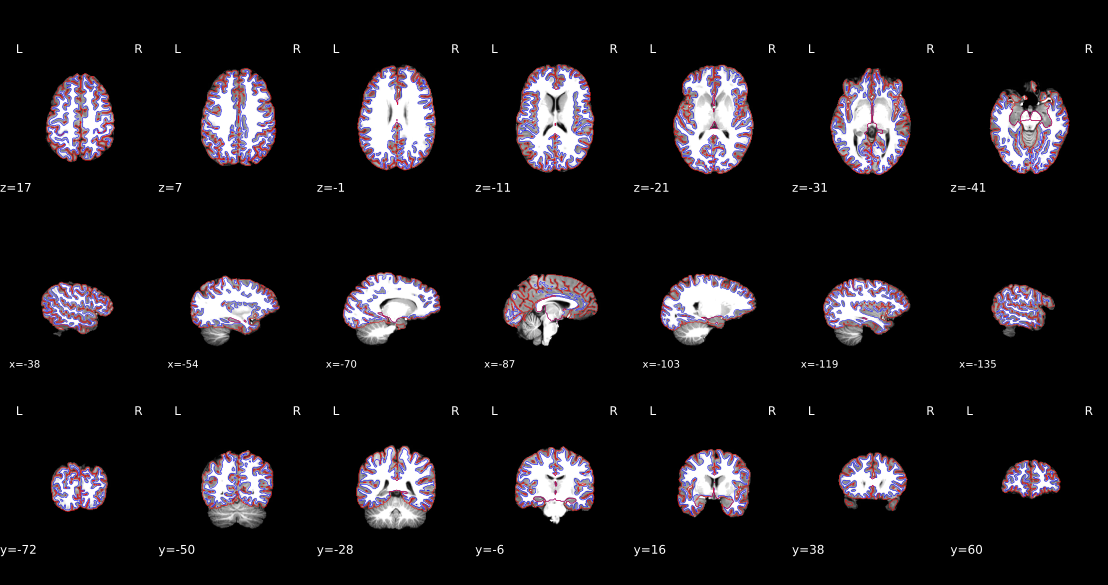

In [6]:
SVG(filename='fmriprep-output/sub-08/figures/sub-08_desc-reconall_T1w.svg')

### EPI-space to T1-space

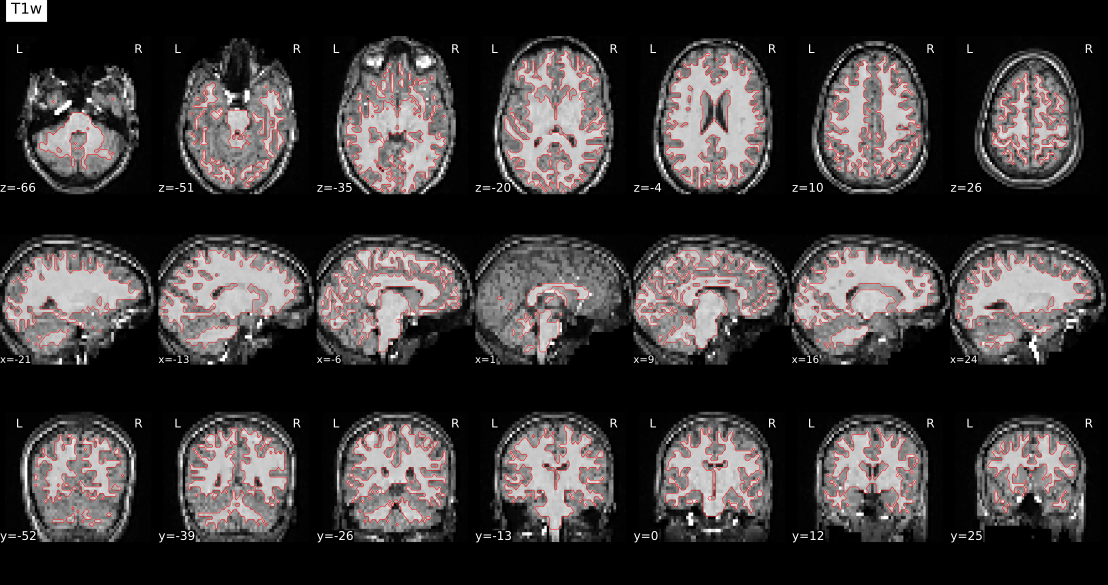

In [7]:
SVG(filename='fmriprep-output/sub-08/figures/sub-08_task-flanker_run-1_desc-coreg_bold.svg')

## Brain mask and (anatomical/temporal) CompCor ROIs
Brain mask calculated on the BOLD signal (red contour), along with the regions of interest (ROIs) used for the estimation of physiological and movement confounding components that can be then used as nuisance regressors in analysis.
The anatomical CompCor ROI (magenta contour) is a mask combining CSF and WM (white-matter), where voxels containing a minimal partial volume of GM have been removed.
The temporal CompCor ROI (blue contour) contains the top 2% most variable voxels within the brain mask.
The brain edge (or crown) ROI (green contour) picks signals outside but close to the brain, which are decomposed into 24 principal components.

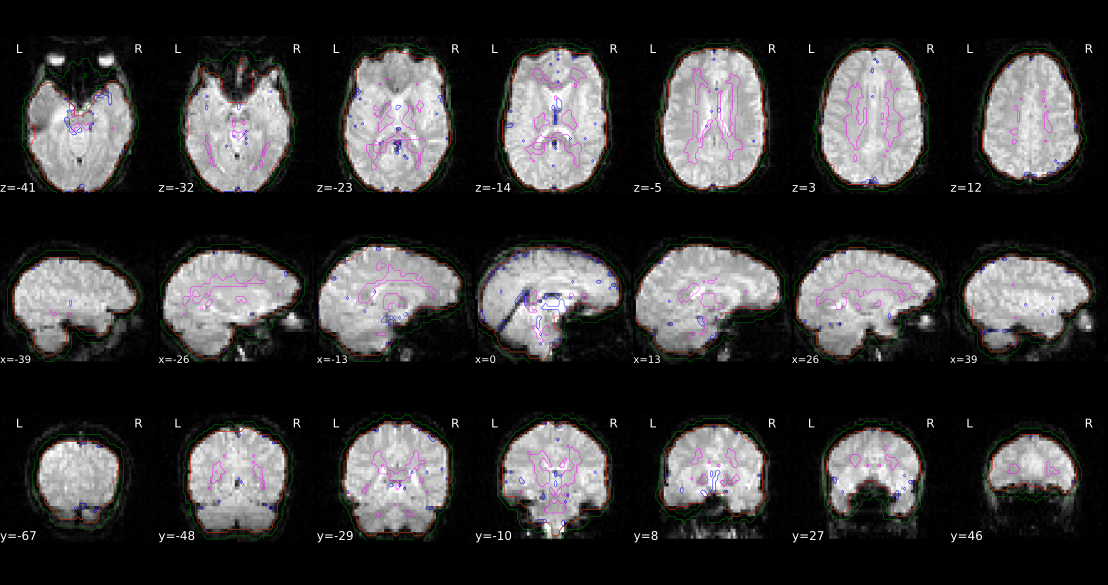

In [8]:
SVG(filename='fmriprep-output/sub-08/figures/sub-08_task-flanker_run-1_desc-rois_bold.svg')

### Bold Summary
Summary statistics are plotted, which may reveal trends or artifacts in the BOLD data. Global signals calculated within the whole-brain (GS), within the white-matter (WM) and within cerebro-spinal fluid (CSF) show the mean BOLD signal in their corresponding masks. DVARS and FD show the standardized DVARS and framewise-displacement measures for each time point.
A carpet plot shows the time series for all voxels within the brain mask, or if --cifti-output was enabled, all grayordinates. Voxels are grouped into cortical (dark/light blue), and subcortical (orange) gray matter, cerebellum (green) and white matter and CSF (red), indicated by the color map on the left-hand side.

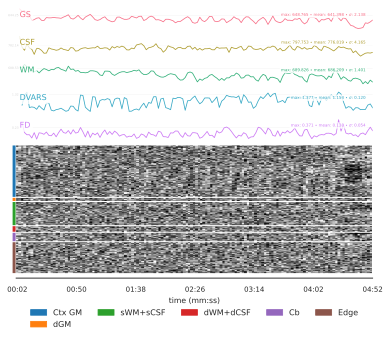

In [9]:
SVG(filename='fmriprep-output/sub-08/figures/sub-08_task-flanker_run-1_desc-carpetplot_bold.svg')

#### Dependencies in Jupyter/Python
- Using the package [watermark](https://github.com/rasbt/watermark) to document system environment and software versions used in this notebook, alongside the Neurodesktop version extracted from the `JUPYTER_IMAGE` or `NEURODESKTOP_VERSION` environment variables.

In [10]:
import os

%load_ext watermark

%watermark
%watermark --iversions

neurodesktop_version = (
    os.environ.get('JUPYTER_IMAGE', '').split(':')[-1] or
    os.environ.get('NEURODESKTOP_VERSION', 'unknown')
)

print(f"Neurodesktop version: {neurodesktop_version}")

Last updated: 2026-04-10T09:06:18.185091+00:00

Python implementation: CPython
Python version       : 3.13.9
IPython version      : 9.7.0

Compiler    : GCC 14.3.0
OS          : Linux
Release     : 5.15.0-171-generic
Machine     : x86_64
Processor   : x86_64
CPU cores   : 32
Architecture: 64bit

IPython: 9.7.0

Neurodesktop version: 2025-12-20
